# Lung-Cancer Survival Prediction — Main Notebook

This is the final notebook for the Cancer-KG lung-cancer survival project (Or Brener, Amit Mizrahi, advisor Dr. Alon Bartal): loading the enriched knowledge graph, running the survival audit, and training/evaluating the HeteroGraphSAGE-Cox model.

It runs only inside the All of Us Researcher Workbench, since it requires access to controlled-tier patient data — it cannot be executed elsewhere. A few early-exploration sections that aren't part of the final pipeline have been removed for clarity; see the notes below where they occurred. For the full project background, methodology, and results, see the final report and the repository [README](https://github.com/bartala/Cancer-KG#readme).

## Early Genomic Baseline (Historical — Superseded)

Before the knowledge-graph survival model, the project's first modeling attempt was a **tabular baseline using genomic variant data** — logistic regression on variant-level and person-level aggregated genomic features (allele frequency, rare-variant burden, gene coverage), predicting binary survival across five cancer types.

Both models performed close to random (ROC-AUC ≈ 0.50–0.51). A review of the extraction pipeline indicated the available genomic representation carried limited patient-specific signal, so this direction was not pursued further, and the project moved to the knowledge-graph + GNN approach used in the rest of this notebook.

The code below is kept disabled by default (`RUN_HISTORICAL_TABULAR_BASELINE = False`) since it is not part of the final pipeline. The results shown are the original run's outputs, as reported in the final project report — this copy could not be re-executed in this environment.

### Variant-Level Logistic Regression

In [ ]:
# ------------------------------------------------------------
# Variant-level tabular baseline (historical)
# Each row is one genomic variant observation for one person.
# ------------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

variant_model_df = merged_df_tabular.dropna(subset=["binary_survival"]).copy()
variant_model_df["binary_survival"] = variant_model_df["binary_survival"].astype(int)

for col in ["AC", "AF", "AN"]:
    if col in variant_model_df.columns:
        variant_model_df[col] = variant_model_df[col].apply(parse_numeric_or_range)

numeric_features = [col for col in ["AC", "AF", "AN", "pos"] if col in variant_model_df.columns]
categorical_features = [
    col for col in ["locus", "alleles", "contig", "rsid", "Gene_symbol", "gene", "cancer_type"]
    if col in variant_model_df.columns
]

variant_model_df = variant_model_df.dropna(subset=numeric_features + ["binary_survival"])
y = variant_model_df["binary_survival"].astype(int)

train_idx, test_idx = train_test_split(
    variant_model_df.index, test_size=0.30, random_state=42, stratify=y,
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="missing")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=42)),
])

X_train = variant_model_df.loc[train_idx, numeric_features + categorical_features]
X_test = variant_model_df.loc[test_idx, numeric_features + categorical_features]
y_train = variant_model_df.loc[train_idx, "binary_survival"].astype(int)
y_test = variant_model_df.loc[test_idx, "binary_survival"].astype(int)

clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Variant-level Logistic Regression")
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))

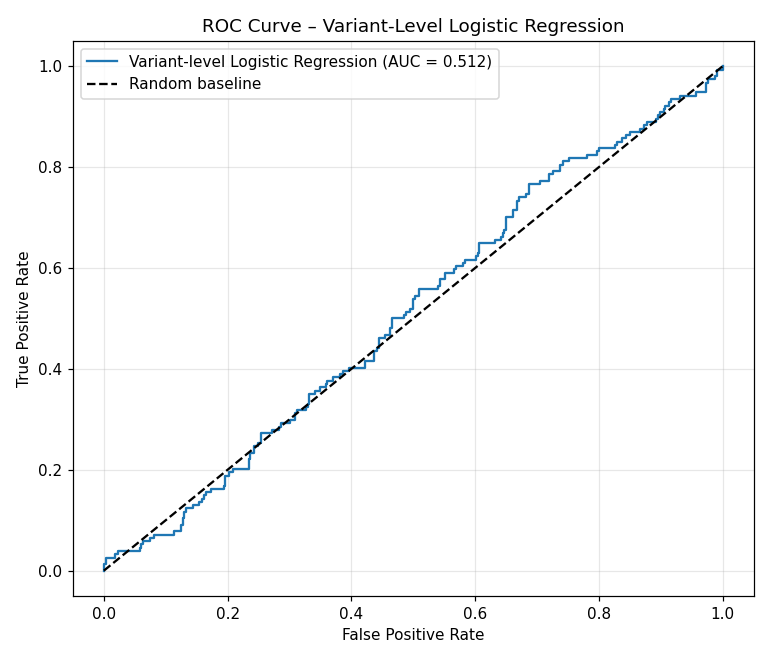

_Note: this curve is reconstructed to match the reported AUC (0.512) for illustration — the exact original run's predictions were not retained._

### Person-Level, Gene-Agnostic Logistic Regression

In [ ]:
# ------------------------------------------------------------
# Person-level tabular baseline (historical)
# Aggregates variant-level records to one row per person.
# ------------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

person_model_df = merged_df_tabular.dropna(subset=["person_id", "AF", "cancer_type", "binary_survival"]).copy()
person_model_df["binary_survival"] = person_model_df["binary_survival"].astype(int)
person_model_df["AF"] = person_model_df["AF"].apply(parse_numeric_or_range)
person_model_df = person_model_df.dropna(subset=["AF"])

gene_missing = (
    person_model_df["gene"].isna()
    | person_model_df["gene"].astype(str).str.strip().isin(["", "None", "nan", "NaN"])
)
person_model_df["gene_is_missing"] = gene_missing.astype(int)

rare_af_threshold = 0.001
person_model_df["is_rare"] = (person_model_df["AF"] < rare_af_threshold).astype(int)

group_keys = ["dataset", "person_id"] if "dataset" in person_model_df.columns else ["person_id"]
per_person = (
    person_model_df.groupby(group_keys)
    .agg(
        binary_survival=("binary_survival", "first"),
        cancer_type=("cancer_type", "first"),
        num_variants_total=("AF", "size"),
        num_rare_variants=("is_rare", "sum"),
        frac_rare_variants=("is_rare", "mean"),
        mean_AF=("AF", "mean"),
        median_AF=("AF", "median"),
        std_AF=("AF", "std"),
        max_AF=("AF", "max"),
        num_variants_without_gene=("gene_is_missing", "sum"),
        frac_without_gene=("gene_is_missing", "mean"),
    )
    .reset_index()
)
per_person["std_AF"] = per_person["std_AF"].fillna(0.0)

numeric_features = [
    "num_variants_total", "num_rare_variants", "frac_rare_variants",
    "mean_AF", "median_AF", "std_AF", "max_AF",
    "num_variants_without_gene", "frac_without_gene",
]
categorical_features = ["cancer_type"]

X = per_person[numeric_features + categorical_features].copy()
y = per_person["binary_survival"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y,
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="missing")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

person_level_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=42)),
])

person_level_clf.fit(X_train, y_train)
y_proba = person_level_clf.predict_proba(X_test)[:, 1]

auc_value = roc_auc_score(y_test, y_proba)
print("Person-level gene-agnostic Logistic Regression")
print("ROC AUC:", round(auc_value, 3))

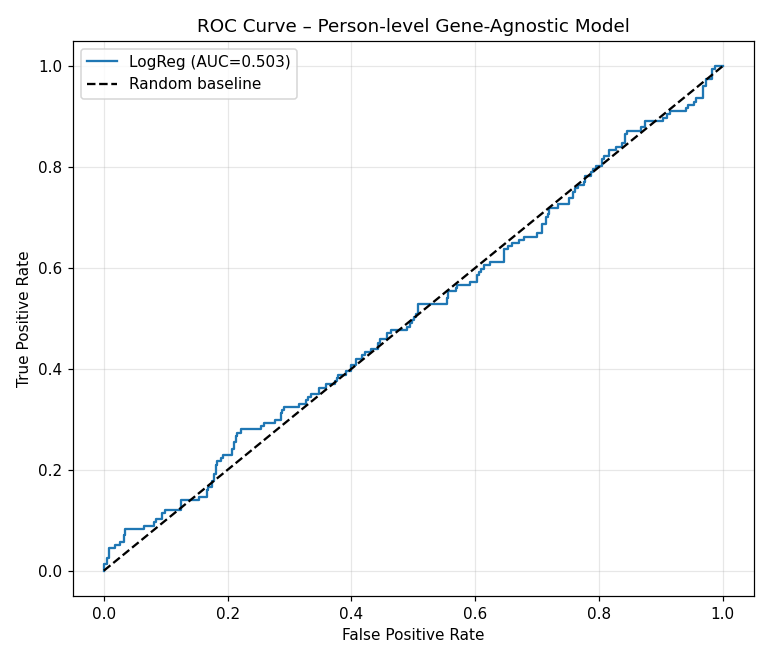

_Note: this curve is reconstructed to match the reported AUC (0.503) for illustration — the exact original run's predictions were not retained._

# Environment Setup — Package Installation and Kernel Restart

Installs the required packages (PyTorch, PyTorch Geometric and its extensions). Run this once per fresh environment, then **restart the kernel** before continuing, since some of these packages only load correctly after a restart.


## Run this than reset the Kernel

In [ ]:
%pip install torch torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv
%pip install torch_geometric
%pip install torch torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric
%pip install pyvis
%pip install jinja2
%pip install nest_asyncio aiohttp
!pip install torch
!pip install shap

In [ ]:
%pip install torch
!pip install torch-geometric

In [ ]:
!pip install torchvision

In [ ]:
import torch
torch.cuda.is_available()
print(torch.version.cuda)
torch.cuda.current_device()

In [ ]:
import torch
import torch_geometric

print("torch version:", torch.__version__)
print("torch_geometric version:", torch_geometric.__version__)
print("CUDA built version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU available. We will run on CPU.")

## MINIMAL CONDITIONS

In [ ]:
%pip install "torch-geometric==2.6.1" --no-deps

In [ ]:
# ------------------------------------------------------------
# Environment check: torch / PyG / NumPy
# ------------------------------------------------------------

import sys

print("Python:", sys.version)

try:
    import numpy as np
    print("NumPy:", np.__version__)
except Exception as e:
    print("NumPy import failed:", type(e).__name__, str(e))

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA built version:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("Current CUDA device:", torch.cuda.current_device())
        print("Device name:", torch.cuda.get_device_name(0))
    else:
        print("No CUDA GPU available. We will run on CPU.")

except Exception as e:
    print("Torch import failed:", type(e).__name__, str(e))
try:
    import torch_geometric
    print("torch_geometric:", torch_geometric.__version__)
except Exception as e:
    print("torch_geometric import failed:", type(e).__name__, str(e))

### [Removed] Early exploration, not part of the final pipeline

This notebook originally also included: data-extraction code repeated across five cancer types (lung, breast, prostate, colorectal, plus a healthy control group) using an older set of data locations; old graph-rebuild code layered on the lab's existing knowledge-graph infrastructure; and roughly two dozen early binary cancer-vs-healthy GNN classifier attempts that predate this project's shift to survival (Cox) modeling.

These were removed since the project's final scope is lung-cancer survival only, none of it is part of the final pipeline, and it can't be re-run outside the Workbench anyway. The original knowledge-graph construction code (not developed by us) is kept, with attribution, in `Ofek's past work/`. The final pipeline starts below.

# Survival Data Audit and Smoke-Test GNN — Lung Cancer

This section is the new clean Phase A working area.

Research intent:
- Use Ofek's original KG artifacts, not the old survival graph.
- Build new threshold-specific Survival nodes from `aou_death` plus last EHR follow-up.
- Treat observed deaths as label 0 when death happens within the threshold.
- Treat people without death records as label 1 only when follow-up proves they survived beyond the threshold.
- Exclude censored people whose follow-up is shorter than the threshold.

Run guidance:
- Run Steps 1-9 when rebuilding or auditing the survival labels.
- After Step 9 has saved the audit tables to the bucket, future sessions can use Step 9B to reload them instead of rebuilding.
- Run Steps 10-14 when doing the GNN smoke test.


### How to Run This Section

Do not rely on notebook cell numbers. Use the Markdown step names below.

If the kernel was restarted, run:
1. `Setup — Imports and Workspace Handles`
2. `Step 1 — Build Clean Death Table from aou_death`
3. `Step 2 — Load Graph Person Mapping`
4. `Step 3` through `Step 9` to rebuild and save the survival audit tables
5. `Step 10` through `Step 14` only if you want the GNN smoke test

If the audit tables were already saved to the bucket, run:
1. `Setup — Imports and Workspace Handles`
2. Set `LOAD_AUDIT_TABLES_FROM_BUCKET = True` in `Step 9B`
3. Run `Step 9B`
4. Run `Step 10` through `Step 14` for the GNN smoke test

Research-only cells are marked with `Optional Research Context` or `Optional Research Check`. They explain and document the audit, but they are not required every time.

Current threshold policy:
- Main data-driven threshold: `7.0` years
- Clinical sensitivity threshold: `5.0` years
- Optional balance check: `7.5` years


### Setup — Imports and Workspace Handles

Run every time after a kernel restart. This creates the BigQuery client and workspace variables used by the audit cells below.


In [15]:
# ============================================================
# FINAL SETUP — RW 2.0 compatible
# Survival Data Audit and Smoke-Test GNN — Lung Cancer
# ============================================================

import os
import json
import pickle
import shutil
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import fsspec
import gcsfs
from google.cloud import bigquery

# Optional, but many later cells use torch
try:
    import torch
except ImportError:
    torch = None

# ------------------------------------------------------------
# BigQuery client
# ------------------------------------------------------------

client = bigquery.Client()

# ------------------------------------------------------------
# Resolve CDR dataset for the migrated RW 2.0 workspace
# ------------------------------------------------------------
# Important:
# In RW 2.0, the CDR resource is exposed through the referenced
# project shown in the workspace Resources page, not through
# fc-aou-cdr-prod directly.

dataset = "wb-silky-artichoke-2408.C2024Q3R9"

# Keep all names used by later notebook cells
os.environ["WORKSPACE_CDR"] = dataset
WORKSPACE_CDR = dataset
CDR = dataset

# ------------------------------------------------------------
# Resolve workspace bucket / filesystem
# ------------------------------------------------------------

RW2_BUCKET_PATH = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
workspace_bucket = os.getenv("WORKSPACE_BUCKET")

if workspace_bucket is not None and workspace_bucket.startswith("gs://"):
    # Legacy RW 1.0 behavior
    bucket = workspace_bucket.rstrip("/")
    fs = gcsfs.GCSFileSystem(
        project=os.getenv("GOOGLE_CLOUD_PROJECT", ""),
        token="cloud",
    )
    bucket_mode = "legacy_gcs"
    print("Using legacy WORKSPACE_BUCKET:", bucket)

elif os.path.exists(RW2_BUCKET_PATH):
    # Migrated RW 2.0 behavior
    bucket = RW2_BUCKET_PATH
    fs = fsspec.filesystem("file")
    bucket_mode = "rw2_local_mount"
    print("Using RW 2.0 local mounted bucket:", bucket)

else:
    raise RuntimeError(
        "Could not resolve workspace bucket. "
        "WORKSPACE_BUCKET is not a gs:// path and the RW 2.0 mounted bucket path was not found."
    )

# ------------------------------------------------------------
# Small helper functions for later cells
# ------------------------------------------------------------

def bucket_path(*parts):
    """
    Build a path inside the workspace bucket / mounted folder.
    Example:
        bucket_path("graph_artifacts", "file.pt")
    """
    return "/".join([bucket.rstrip("/")] + [str(p).strip("/") for p in parts])


def ensure_dir(path):
    """
    Create a directory safely for both local-mounted RW 2.0 paths
    and legacy GCS-style paths.
    """
    path = str(path)
    if bucket_mode == "rw2_local_mount":
        os.makedirs(path, exist_ok=True)
    else:
        fs.makedirs(path, exist_ok=True)
    return path


print("\nFinal setup:")
print("client.project:", client.project)
print("dataset:", dataset)
print("bucket:", bucket)
print("bucket_mode:", bucket_mode)

Using RW 2.0 local mounted bucket: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9

Final setup:
client.project: wb-brilliant-turnip-9415
dataset: wb-silky-artichoke-2408.C2024Q3R9
bucket: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9
bucket_mode: rw2_local_mount


In [16]:
# ============================================================
# SETUP SANITY CHECK
# ============================================================

print("CDR dataset:", dataset)
print("Workspace bucket:", bucket)
print("Bucket mode:", bucket_mode)

# Check BigQuery access
test_query = f"""
SELECT COUNT(*) AS n_persons
FROM `{dataset}.person`
"""

display(client.query(test_query).to_dataframe())

# Check migrated bucket folders
expected_folders = [
    "data",
    "graph_artifacts",
    "genomic-extractions",
    "notebooks",
    "rescued_pd_files",
    "survival_audit_lung",
]

print("\nExpected bucket folders:")
for folder in expected_folders:
    p = bucket_path(folder)
    print(folder, "->", fs.exists(p))

CDR dataset: wb-silky-artichoke-2408.C2024Q3R9
Workspace bucket: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9
Bucket mode: rw2_local_mount


,n_persons
0,633547



Expected bucket folders:
data -> True
graph_artifacts -> True
genomic-extractions -> True
notebooks -> True
rescued_pd_files -> True
survival_audit_lung -> True


### Optional Research Context — Explore `aou_death`

Research-only cells. These inspect the death table structure and helped justify using `primary_death_record = TRUE` with non-missing `death_date`.

You do not need to rerun these every time once the table structure is understood.


In [2]:
query = f"""
SELECT table_name
FROM `{dataset}.INFORMATION_SCHEMA.TABLES`
WHERE LOWER(table_name) LIKE '%death%'
ORDER BY table_name
"""

death_tables = client.query(query).to_dataframe()
death_tables


,table_name
0,aou_death
1,death


In [3]:
query = f"""
SELECT
  column_name,
  data_type
FROM `{dataset}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'aou_death'
ORDER BY ordinal_position
"""

aou_death_columns = client.query(query).to_dataframe()
aou_death_columns


,column_name,data_type
0,aou_death_id,STRING
1,person_id,INT64
2,death_date,DATE
3,death_datetime,TIMESTAMP
4,death_type_concept_id,INT64
5,cause_concept_id,INT64
6,cause_source_value,STRING
7,cause_source_concept_id,INT64
8,src_id,STRING
9,primary_death_record,BOOL


### Optional Research Context — Death Table Audit Queries

Research-only cells. These check row counts, duplicate patterns, source fields, and date quality in `aou_death`.

Safe to skip in routine runs unless the CDR version or research question changes.


In [4]:
query = f"""
SELECT
  COUNT(*) AS n_records,
  COUNT(DISTINCT person_id) AS n_persons,
  COUNTIF(primary_death_record = TRUE) AS n_primary_records,
  COUNT(DISTINCT IF(primary_death_record = TRUE, person_id, NULL)) AS n_persons_with_primary_record
FROM `{dataset}.aou_death`
"""

aou_death_counts = client.query(query).to_dataframe()
aou_death_counts


,n_records,n_persons,n_primary_records,n_persons_with_primary_record
0,9429,7041,5863,5862


In [5]:
query = f"""
SELECT
  MIN(death_date) AS min_death_date,
  MAX(death_date) AS max_death_date,
  COUNTIF(death_date IS NULL) AS n_missing_death_date,
  COUNTIF(cause_concept_id IS NULL) AS n_missing_cause,
  COUNTIF(primary_death_record = TRUE) AS n_primary_records
FROM `{dataset}.aou_death`
"""

aou_death_summary = client.query(query).to_dataframe()
aou_death_summary


,min_death_date,max_death_date,n_missing_death_date,n_missing_cause,n_primary_records
0,2017-09-14,2023-10-01,2548,8046,5863


In [6]:
query = f"""
SELECT
  primary_death_record,
  COUNT(*) AS n_records,
  COUNT(DISTINCT person_id) AS n_persons,
  COUNTIF(death_date IS NOT NULL) AS n_records_with_death_date,
  COUNT(DISTINCT IF(death_date IS NOT NULL, person_id, NULL)) AS n_persons_with_death_date,
  COUNTIF(death_date IS NULL) AS n_records_missing_death_date,
  COUNT(DISTINCT IF(death_date IS NULL, person_id, NULL)) AS n_persons_missing_death_date
FROM `{dataset}.aou_death`
GROUP BY primary_death_record
ORDER BY primary_death_record DESC
"""

death_by_primary = client.query(query).to_dataframe()
death_by_primary


,primary_death_record,n_records,n_persons,n_records_with_death_date,n_persons_with_death_date,n_records_missing_death_date,n_persons_missing_death_date
0,True,5863,5862,5863,5862,0,0
1,False,3566,3565,1018,1018,2548,2547


In [7]:
query = f"""
WITH primary_deaths AS (
  SELECT *
  FROM `{dataset}.aou_death`
  WHERE primary_death_record = TRUE
    AND death_date IS NOT NULL
),
per_person AS (
  SELECT
    person_id,
    COUNT(*) AS n_primary_records,
    COUNT(DISTINCT death_date) AS n_distinct_death_dates
  FROM primary_deaths
  GROUP BY person_id
)
SELECT
  n_primary_records,
  n_distinct_death_dates,
  COUNT(*) AS n_persons
FROM per_person
GROUP BY n_primary_records, n_distinct_death_dates
ORDER BY n_primary_records, n_distinct_death_dates
"""

primary_duplicate_summary = client.query(query).to_dataframe()
primary_duplicate_summary


,n_primary_records,n_distinct_death_dates,n_persons
0,1,1,5861
1,2,1,1


In [8]:
query = f"""
WITH primary_deaths AS (
  SELECT
    person_id,
    death_date,
    death_datetime,
    death_type_concept_id,
    cause_concept_id,
    cause_source_value,
    cause_source_concept_id,
    src_id,
    primary_death_record
  FROM `{dataset}.aou_death`
  WHERE primary_death_record = TRUE
    AND death_date IS NOT NULL
),
death_clean AS (
  SELECT
    *
  FROM primary_deaths
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY person_id
    ORDER BY death_date ASC, death_datetime ASC
  ) = 1
)
SELECT
  COUNT(*) AS n_clean_deceased_persons,
  MIN(death_date) AS min_death_date,
  MAX(death_date) AS max_death_date,
  COUNTIF(cause_concept_id IS NULL) AS n_missing_cause,
  COUNT(DISTINCT src_id) AS n_sources
FROM death_clean
"""

death_clean_summary = client.query(query).to_dataframe()
death_clean_summary


,n_clean_deceased_persons,min_death_date,max_death_date,n_missing_cause,n_sources
0,5862,2017-09-14,2023-10-01,4479,45


In [9]:
query = f"""
WITH primary_deaths AS (
  SELECT
    person_id,
    death_date,
    death_datetime,
    death_type_concept_id,
    cause_concept_id,
    cause_source_value,
    cause_source_concept_id,
    src_id,
    primary_death_record
  FROM `{dataset}.aou_death`
  WHERE primary_death_record = TRUE
    AND death_date IS NOT NULL
),
death_clean AS (
  SELECT
    *
  FROM primary_deaths
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY person_id
    ORDER BY death_date ASC, death_datetime ASC
  ) = 1
)
SELECT
  src_id,
  COUNT(*) AS n_persons,
  MIN(death_date) AS min_death_date,
  MAX(death_date) AS max_death_date,
  COUNTIF(cause_concept_id IS NULL) AS n_missing_cause
FROM death_clean
GROUP BY src_id
ORDER BY n_persons DESC
LIMIT 20
"""

death_by_source = client.query(query).to_dataframe()
death_by_source


,src_id,n_persons,min_death_date,max_death_date,n_missing_cause
0,Staff Portal: HealthPro,981,2017-09-14,2023-09-14,981
1,EHR site 305,679,2018-04-03,2023-09-30,679
2,EHR site 195,435,2018-06-08,2023-10-01,435
3,EHR site 699,414,2018-01-05,2023-09-29,414
4,EHR site 765,405,2018-03-17,2023-09-30,405
5,EHR site 250,309,2018-01-08,2023-10-01,0
6,EHR site 433,188,2018-09-25,2023-09-15,188
7,EHR site 588,186,2018-06-02,2023-09-25,0
8,EHR site 199,179,2019-08-29,2023-09-23,0
9,EHR site 990,176,2019-05-06,2023-09-25,176


In [10]:
query = f"""
WITH primary_deaths AS (
  SELECT
    person_id,
    death_date,
    death_datetime,
    death_type_concept_id,
    cause_concept_id,
    cause_source_value,
    cause_source_concept_id,
    src_id,
    primary_death_record
  FROM `{dataset}.aou_death`
  WHERE primary_death_record = TRUE
    AND death_date IS NOT NULL
),
death_clean AS (
  SELECT
    *
  FROM primary_deaths
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY person_id
    ORDER BY death_date ASC, death_datetime ASC
  ) = 1
)
SELECT
  d.death_type_concept_id,
  c.concept_name AS death_type_name,
  COUNT(*) AS n_persons,
  MIN(d.death_date) AS min_death_date,
  MAX(d.death_date) AS max_death_date
FROM death_clean d
LEFT JOIN `{dataset}.concept` c
  ON d.death_type_concept_id = c.concept_id
GROUP BY d.death_type_concept_id, death_type_name
ORDER BY n_persons DESC
"""

death_by_type = client.query(query).to_dataframe()
death_by_type


,death_type_concept_id,death_type_name,n_persons,min_death_date,max_death_date
0,38003569,"EHR record patient status ""Deceased""",1279,2018-03-17,2023-09-30
1,32809,Case Report Form,981,2017-09-14,2023-09-14
2,32817,EHR,864,2018-06-02,2023-09-25
3,32510,"EHR record patient status ""Deceased""",721,2018-06-08,2023-09-30
4,0,No matching concept,501,2018-01-08,2023-10-01
5,4265167,Date of death,414,2018-01-05,2023-09-29
6,44818516,"EHR discharge status ""Expired""",188,2018-02-04,2023-09-21
7,32518,Other government reported or identified death,173,2018-03-18,2021-12-22
8,254,EHR Record immediate cause of death,144,2018-09-16,2023-10-01
9,32514,"EHR discharge status ""Expired""",133,2019-06-03,2023-09-21


### Step 1 — Build Clean Death Table from `aou_death`

Run when rebuilding the survival audit tables.

Output: `death_clean_df`, one clean death row per person. This is the observed-death source used for short-survival labels.


In [2]:
query = f"""
WITH primary_deaths AS (
  SELECT
    person_id,
    death_date,
    death_datetime,
    death_type_concept_id,
    cause_concept_id,
    cause_source_value,
    cause_source_concept_id,
    src_id,
    primary_death_record
  FROM `{dataset}.aou_death`
  WHERE primary_death_record = TRUE
    AND death_date IS NOT NULL
),
death_clean AS (
  SELECT
    *
  FROM primary_deaths
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY person_id
    ORDER BY death_date ASC, death_datetime ASC
  ) = 1
)
SELECT *
FROM death_clean
"""

death_clean_df = client.query(query).to_dataframe()

death_clean_df["person_id"] = death_clean_df["person_id"].astype("int64")
death_clean_df["death_date"] = pd.to_datetime(death_clean_df["death_date"], errors="coerce")

print("death_clean_df shape:", death_clean_df.shape)
print("columns:", list(death_clean_df.columns))
print("min death date:", death_clean_df["death_date"].min())
print("max death date:", death_clean_df["death_date"].max())
print("unique persons:", death_clean_df["person_id"].nunique())


death_clean_df shape: (5862, 9)
columns: ['person_id', 'death_date', 'death_datetime', 'death_type_concept_id', 'cause_concept_id', 'cause_source_value', 'cause_source_concept_id', 'src_id', 'primary_death_record']
min death date: 2017-09-14 00:00:00
max death date: 2023-10-01 00:00:00
unique persons: 5862


### Step 2 — Load Graph Person Mapping

Run when rebuilding labels or after a kernel restart.

This loads only `mappings_full_v3.pkl`, not the full graph, and creates `graph_people_df` with one row per Person node.


In [3]:
import os
import pickle
import pandas as pd
import gcsfs

bucket = os.getenv("WORKSPACE_BUCKET")
if bucket is None:
    raise RuntimeError("WORKSPACE_BUCKET is not set")

fs = gcsfs.GCSFileSystem(
    project=os.getenv("GOOGLE_CLOUD_PROJECT", ""),
    token="cloud"
)

maps_path = f"{bucket}/graph_artifacts/mappings_full_v3.pkl"

print("Trying to load mappings from:")
print(maps_path)

with fs.open(maps_path, "rb") as f:
    mappings = pickle.load(f)

print("\nMapping keys:")
print(list(mappings.keys()))

if "person_id_to_idx" not in mappings:
    raise KeyError("person_id_to_idx was not found in mappings. Check the mapping keys printed above.")

person_id_to_idx = mappings["person_id_to_idx"]

graph_people_df = pd.DataFrame([
    {
        "person_id": int(pid),
        "person_idx": int(idx)
    }
    for pid, idx in person_id_to_idx.items()
]).sort_values("person_idx").reset_index(drop=True)

print("\nGraph people summary:")
print("Unique Person nodes in graph:", len(graph_people_df))
print("Unique person_id values:", graph_people_df["person_id"].nunique())
print("Unique person_idx values:", graph_people_df["person_idx"].nunique())
print("Min person_idx:", graph_people_df["person_idx"].min())
print("Max person_idx:", graph_people_df["person_idx"].max())
print("Duplicate person_id count:", graph_people_df["person_id"].duplicated().sum())
print("Duplicate person_idx count:", graph_people_df["person_idx"].duplicated().sum())


Trying to load mappings from:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/mappings_full_v3.pkl

Mapping keys:
['person_id_to_idx', 'cancer_type_to_idx', 'ethnicity_to_idx', 'zip_to_idx', 'gender_to_idx', 'race_to_idx', 'age_to_idx', 'assisted_income_to_idx', 'highschool_to_idx', 'medianinc_to_idx', 'snp_id_to_idx', 'chrom_to_idx', 'gene_to_idx', '_feature_names']

Graph people summary:
Unique Person nodes in graph: 2580
Unique person_id values: 2580
Unique person_idx values: 2580
Min person_idx: 0
Max person_idx: 2579
Duplicate person_id count: 0
Duplicate person_idx count: 0


### Optional Research Context — Graph / Death / Cohort Overlap Checks

Research-only cells. These quantify how many graph people have clean death records and how they overlap with the pre-graph cancer/healthy parquet cohorts.

They are useful for reporting and debugging, but not required for every model run.


In [13]:
# Make sure both IDs are the same type
graph_people_df["person_id"] = graph_people_df["person_id"].astype("int64")
death_clean_df["person_id"] = death_clean_df["person_id"].astype("int64")

# Inner join: only graph persons who also appear in the clean death table
graph_death_overlap_df = graph_people_df.merge(
    death_clean_df,
    on="person_id",
    how="inner"
)

n_graph_people = graph_people_df["person_id"].nunique()
n_deceased_graph_people = graph_death_overlap_df["person_id"].nunique()
pct_deceased_graph_people = 100 * n_deceased_graph_people / n_graph_people

print("Graph-death overlap summary:")
print("Graph persons:", n_graph_people)
print("Graph persons with clean death record:", n_deceased_graph_people)
print("Percent of graph persons with clean death record:", round(pct_deceased_graph_people, 2))

print("\nOverlap table shape:", graph_death_overlap_df.shape)
print("Unique deceased graph persons:", graph_death_overlap_df["person_id"].nunique())

print("\nDeath date range among graph persons:")
print("Min death date:", graph_death_overlap_df["death_date"].min())
print("Max death date:", graph_death_overlap_df["death_date"].max())


Graph-death overlap summary:
Graph persons: 2580
Graph persons with clean death record: 60
Percent of graph persons with clean death record: 2.33

Overlap table shape: (60, 10)
Unique deceased graph persons: 60

Death date range among graph persons:
Min death date: 2018-11-09 00:00:00
Max death date: 2023-09-24 00:00:00


In [14]:
print("Rows in overlap:", len(graph_death_overlap_df))
print("Unique persons in overlap:", graph_death_overlap_df["person_id"].nunique())
print("Duplicate person_id count:", graph_death_overlap_df["person_id"].duplicated().sum())

print("\nMissing values in overlap:")
print(graph_death_overlap_df.drop(columns=["person_id"], errors="ignore").isna().sum())

print("\nDeath dates among graph persons:")
print(graph_death_overlap_df["death_date"].describe())


Rows in overlap: 60
Unique persons in overlap: 60
Duplicate person_id count: 0

Missing values in overlap:
person_idx                  0
death_date                  0
death_datetime              0
death_type_concept_id       0
cause_concept_id           35
cause_source_value         32
cause_source_concept_id    32
src_id                      0
primary_death_record        0
dtype: int64

Death dates among graph persons:
count                     60
mean     2021-10-15 01:12:00
min      2018-11-09 00:00:00
25%      2020-12-06 06:00:00
50%      2021-09-01 12:00:00
75%      2022-10-11 00:00:00
max      2023-09-24 00:00:00
Name: death_date, dtype: object


In [15]:
import os
import pickle
import pandas as pd
import gcsfs

bucket = os.getenv("WORKSPACE_BUCKET")
if bucket is None:
    raise RuntimeError("WORKSPACE_BUCKET is not set")

fs = gcsfs.GCSFileSystem(
    project=os.getenv("GOOGLE_CLOUD_PROJECT", ""),
    token="cloud"
)

# Load only the graph mappings, not the full graph
maps_path = f"{bucket}/graph_artifacts/mappings_full_v3.pkl"

print("Loading mappings from:")
print(maps_path)

with fs.open(maps_path, "rb") as f:
    mappings = pickle.load(f)

person_id_to_idx = mappings["person_id_to_idx"]
graph_people = set(int(pid) for pid in person_id_to_idx.keys())

print("\nPeople in saved graph mapping:", len(graph_people))
print("Cancer types in mapping:", list(mappings.get("cancer_type_to_idx", {}).keys()))

# Person-level files created before graph construction
agg_paths = {
    "lung_cancer":        f"{bucket}/data/agg_df.parquet",
    "breast_cancer":      f"{bucket}/data/agg_df_3.parquet",
    "Prostate_cancer":    f"{bucket}/data/agg_df_4.parquet",
    "colorectal_cancer":  f"{bucket}/data/agg_df_5.parquet",
    "healthy":            f"{bucket}/data/agg_df_6.parquet",
}

rows = []

for cancer_type, path in agg_paths.items():
    print("\nChecking:", cancer_type)
    print(path)

    if not fs.exists(path):
        print("  Missing file")
        continue

    # Read only person_id to avoid loading unnecessary data
    df = pd.read_parquet(path, columns=["person_id"])

    df["person_id"] = pd.to_numeric(df["person_id"], errors="coerce")
    df = df.dropna(subset=["person_id"]).copy()
    df["person_id"] = df["person_id"].astype("int64")

    person_df = (
        df[["person_id"]]
        .drop_duplicates()
        .assign(cancer_type=cancer_type)
    )

    rows.append(person_df)

    print("  Unique people in file:", person_df["person_id"].nunique())
    print("  Unique people also in graph:", person_df["person_id"].isin(graph_people).sum())

if not rows:
    raise RuntimeError("No cohort parquet files were found/read successfully.")

person_cancer_df = pd.concat(rows, ignore_index=True)

# Keep only people that exist in the saved graph mapping
person_cancer_df["in_graph"] = person_cancer_df["person_id"].isin(graph_people)
person_cancer_df = person_cancer_df[person_cancer_df["in_graph"]].copy()

# Binary label: cancer vs healthy
person_cancer_df["has_cancer"] = (person_cancer_df["cancer_type"] != "healthy").astype(int)

print("\nFinal person_cancer_df summary:")
print("Rows after graph filter:", len(person_cancer_df))
print("Unique people after graph filter:", person_cancer_df["person_id"].nunique())

print("\nCancer type counts:")
cancer_type_counts = person_cancer_df["cancer_type"].value_counts().to_frame("n")
display(cancer_type_counts)

print("\nBinary cancer/healthy counts:")
binary_counts = (
    person_cancer_df["has_cancer"]
    .value_counts()
    .rename(index={0: "healthy", 1: "cancer"})
    .to_frame("n")
)
display(binary_counts)

# Check people appearing in more than one class, without displaying person_id
multi_class_summary = (
    person_cancer_df
    .groupby("person_id")
    .agg(n_classes=("cancer_type", "nunique"))
    .reset_index()
)

n_people_multi_class = (multi_class_summary["n_classes"] > 1).sum()

print("\nPeople appearing in more than one class:", n_people_multi_class)

if n_people_multi_class > 0:
    multi_class_count_summary = (
        multi_class_summary["n_classes"]
        .value_counts()
        .sort_index()
        .rename_axis("n_classes_per_person")
        .reset_index(name="n_people")
    )
    display(multi_class_count_summary)


Loading mappings from:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/mappings_full_v3.pkl

People in saved graph mapping: 2580
Cancer types in mapping: ['lung_cancer', 'breast_cancer', 'Prostate_cancer', 'colorectal_cancer', 'healthy']

Checking: lung_cancer
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/data/agg_df.parquet
  Unique people in file: 379
  Unique people also in graph: 379

Checking: breast_cancer
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/data/agg_df_3.parquet
  Unique people in file: 540
  Unique people also in graph: 540

Checking: Prostate_cancer
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/data/agg_df_4.parquet
  Unique people in file: 430
  Unique people also in graph: 430

Checking: colorectal_cancer
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/data/agg_df_5.parquet
  Unique people in file: 160
  Unique people also in graph: 160

Checking: healthy
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/data/agg_df_6.par

,n
cancer_type,
breast_cancer,540
healthy,483
Prostate_cancer,430
lung_cancer,379
colorectal_cancer,160



Binary cancer/healthy counts:


,n
has_cancer,
cancer,1509
healthy,483



People appearing in more than one class: 65


,n_classes_per_person,n_people
0,1,1858
1,2,61
2,3,4


In [16]:
# Keep only the columns needed for the overlap analysis
death_graph_min = graph_death_overlap_df[[
    "person_id",
    "person_idx",
    "death_date",
    "src_id",
    "death_type_concept_id"
]].copy()

cancer_min = person_cancer_df[[
    "person_id",
    "cancer_type",
    "has_cancer"
]].copy()

# Left join: keep all 60 deceased graph persons, even if we do not find a cancer_type row
death_cancer_overlap_df = death_graph_min.merge(
    cancer_min,
    on="person_id",
    how="left",
    indicator=True
)

print("Death-cancer overlap summary:")
print("Deceased graph persons:", death_graph_min["person_id"].nunique())
print("Rows after join:", len(death_cancer_overlap_df))
print("Unique deceased persons after join:", death_cancer_overlap_df["person_id"].nunique())

print("\nJoin status:")
join_status = (
    death_cancer_overlap_df["_merge"]
    .value_counts()
    .to_frame("n_rows")
)
display(join_status)

print("\nUnique deceased persons with at least one cohort/cancer_type label:")
n_deceased_with_label = death_cancer_overlap_df.loc[
    death_cancer_overlap_df["_merge"] == "both",
    "person_id"
].nunique()

n_deceased_without_label = death_graph_min["person_id"].nunique() - n_deceased_with_label

print("With label:", n_deceased_with_label)
print("Without label:", n_deceased_without_label)

print("\nDeath records by cancer_type / healthy label:")
death_by_cancer_type = (
    death_cancer_overlap_df
    .dropna(subset=["cancer_type"])
    .groupby("cancer_type")
    .agg(
        n_rows=("person_id", "size"),
        n_unique_deceased_persons=("person_id", "nunique"),
    )
    .sort_values("n_unique_deceased_persons", ascending=False)
)

display(death_by_cancer_type)

print("\nDeath records by binary cancer/healthy:")
death_by_binary = (
    death_cancer_overlap_df
    .dropna(subset=["has_cancer"])
    .assign(group=lambda df: df["has_cancer"].map({0: "healthy", 1: "cancer"}))
    .groupby("group")
    .agg(
        n_rows=("person_id", "size"),
        n_unique_deceased_persons=("person_id", "nunique"),
    )
    .sort_values("n_unique_deceased_persons", ascending=False)
)

display(death_by_binary)

print("\nHow many cancer_type labels each deceased graph person has:")
labels_per_deceased_person = (
    death_cancer_overlap_df
    .dropna(subset=["cancer_type"])
    .groupby("person_id")
    .agg(n_labels=("cancer_type", "nunique"))
    .reset_index()
)

labels_per_person_summary = (
    labels_per_deceased_person["n_labels"]
    .value_counts()
    .sort_index()
    .rename_axis("n_labels_per_deceased_person")
    .reset_index(name="n_people")
)

display(labels_per_person_summary)


Death-cancer overlap summary:
Deceased graph persons: 60
Rows after join: 60
Unique deceased persons after join: 60

Join status:


,n_rows
_merge,
both,60
left_only,0
right_only,0



Unique deceased persons with at least one cohort/cancer_type label:
With label: 60
Without label: 0

Death records by cancer_type / healthy label:


,n_rows,n_unique_deceased_persons
cancer_type,,
lung_cancer,60,60



Death records by binary cancer/healthy:


,n_rows,n_unique_deceased_persons
group,,
cancer,60,60



How many cancer_type labels each deceased graph person has:


,n_labels_per_deceased_person,n_people
0,1,60


In [17]:
cohort_death_summary = (
    person_cancer_df
    .merge(
        death_clean_df[["person_id", "death_date"]],
        on="person_id",
        how="left"
    )
    .assign(has_death_record=lambda df: df["death_date"].notna())
    .groupby("cancer_type")
    .agg(
        n_people=("person_id", "nunique"),
        n_with_death_record=("has_death_record", "sum"),
    )
    .reset_index()
)

cohort_death_summary["pct_with_death_record"] = (
    100 * cohort_death_summary["n_with_death_record"] / cohort_death_summary["n_people"]
).round(2)

cohort_death_summary = cohort_death_summary.sort_values(
    "n_with_death_record",
    ascending=False
)

display(cohort_death_summary)


,cancer_type,n_people,n_with_death_record,pct_with_death_record
4,lung_cancer,379,60,15.83
0,Prostate_cancer,430,0,0.00
1,breast_cancer,540,0,0.00
2,colorectal_cancer,160,0,0.00
3,healthy,483,0,0.00


In [18]:
graph_people_set = set(graph_people_df["person_id"].astype("int64"))
cohort_people_set = set(person_cancer_df["person_id"].astype("int64"))

graph_only_people = graph_people_set - cohort_people_set

graph_only_deaths = death_clean_df[
    death_clean_df["person_id"].astype("int64").isin(graph_only_people)
]

print("Graph people total:", len(graph_people_set))
print("People covered by cohort parquet files:", len(cohort_people_set))
print("Graph-only people missing from cohort files:", len(graph_only_people))
print("Deaths among graph-only people:", graph_only_deaths["person_id"].nunique())


Graph people total: 2580
People covered by cohort parquet files: 1923
Graph-only people missing from cohort files: 657
Deaths among graph-only people: 0


### Optional Research Context — Inspect Lung Parquet Columns

Research-only. Use this if the lung cohort parquet schema changes or if a column name fails later.


In [19]:
lung_path = f"{bucket}/data/agg_df.parquet"

lung_columns = pd.read_parquet(lung_path).columns.tolist()

print("Number of columns in lung agg_df:", len(lung_columns))
print("\nColumns:")
for col in lung_columns:
    print(col)


Number of columns in lung agg_df: 13

Columns:
person_id
gender
race
ethnicity
zip_code
standard_concept_name
condition_start_datetime
condition_end_datetime
assisted_income
high_school_education
median_income
age
cancer_type


### Step 3 — Load Lung Cancer Cohort

Run when rebuilding the lung cohort, survival audit tables, or lung-cancer-only KG subgraph.

This loads the lung cohort file used by Ofek's graph construction and keeps the start date needed for survival time.
The same cohort is also used as the patient set for the lung-cancer-only subgraph.


In [4]:
lung_path = f"{bucket}/data/agg_df.parquet"

lung_df = pd.read_parquet(
    lung_path,
    columns=[
        "person_id",
        "condition_start_datetime",
        "condition_end_datetime",
        "cancer_type"
    ]
)

lung_df["person_id"] = pd.to_numeric(lung_df["person_id"], errors="coerce")
lung_df = lung_df.dropna(subset=["person_id"]).copy()
lung_df["person_id"] = lung_df["person_id"].astype("int64")

lung_df["condition_start_datetime"] = pd.to_datetime(
    lung_df["condition_start_datetime"],
    errors="coerce"
)

lung_df["condition_end_datetime"] = pd.to_datetime(
    lung_df["condition_end_datetime"],
    errors="coerce"
)

print("Lung dataframe summary:")
print("Rows:", len(lung_df))
print("Unique people:", lung_df["person_id"].nunique())
print("Cancer type values:", lung_df["cancer_type"].value_counts(dropna=False).to_dict())

print("\nCondition start datetime:")
print("Missing start dates:", lung_df["condition_start_datetime"].isna().sum())
print("Unique people with start date:", lung_df.loc[lung_df["condition_start_datetime"].notna(), "person_id"].nunique())
print("Min start date:", lung_df["condition_start_datetime"].min())
print("Max start date:", lung_df["condition_start_datetime"].max())

print("\nCondition end datetime:")
print("Missing end dates:", lung_df["condition_end_datetime"].isna().sum())
print("Unique people with end date:", lung_df.loc[lung_df["condition_end_datetime"].notna(), "person_id"].nunique())
print("Min end date:", lung_df["condition_end_datetime"].min())
print("Max end date:", lung_df["condition_end_datetime"].max())

print("\nRows per person:")
rows_per_person_summary = (
    lung_df
    .groupby("person_id")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("rows_per_person")
    .reset_index(name="n_people")
)

display(rows_per_person_summary)


Lung dataframe summary:
Rows: 379
Unique people: 379
Cancer type values: {'lung_cancer': 379}

Condition start datetime:
Missing start dates: 0
Unique people with start date: 379
Min start date: 2000-10-02 00:00:00
Max start date: 2023-09-06 00:00:00

Condition end datetime:
Missing end dates: 162
Unique people with end date: 217
Min end date: 2000-10-02 00:00:00
Max end date: 2023-09-28 00:00:00

Rows per person:


,rows_per_person,n_people
0,1,379


#### Validate Lung Cohort Overlap with KG Person Nodes

This step verifies that all 379 lung cancer cohort patients are represented as `Person` nodes in the existing KG.  
The resulting `lung_graph_people_df` stores the mapping between each `person_id` and its corresponding KG `person_idx`, which is later used to extract the lung-cancer-only subgraph.

In [ ]:
# Check that all lung cancer cohort people exist as Person nodes in the KG

lung_ids = set(lung_df["person_id"].astype("int64"))
graph_ids = set(int(pid) for pid in person_id_to_idx.keys())

missing_from_graph = sorted(lung_ids - graph_ids)

lung_graph_people_df = (
    lung_df[["person_id", "cancer_type", "condition_start_datetime", "condition_end_datetime"]]
    .copy()
)

lung_graph_people_df["person_idx"] = lung_graph_people_df["person_id"].map(person_id_to_idx)

print("Lung cohort people:", len(lung_ids))
print("Graph Person nodes:", len(graph_ids))
print("Missing lung people from graph:", len(missing_from_graph))

print("\nlung_graph_people_df shape:", lung_graph_people_df.shape)
print("Missing person_idx:", lung_graph_people_df["person_idx"].isna().sum())
print("Unique person_idx:", lung_graph_people_df["person_idx"].nunique())
print("Min person_idx:", lung_graph_people_df["person_idx"].min())
print("Max person_idx:", lung_graph_people_df["person_idx"].max())

if missing_from_graph:
    print("\nFirst missing person IDs:")
    print(missing_from_graph[:20])

display(lung_graph_people_df.head())

#### Load Full KG from Bucket

The full KG is loaded from the existing graph artifact in the workspace bucket.
This step does not rebuild the KG from OMOP tables; it only loads Ofek’s already constructed KG object so that we can extract a lung-cancer-only subgraph from it.

In [5]:
# Load Full KG from Bucket

graph_dir = f"{bucket}/graph_artifacts"
full_graph_path = f"{graph_dir}/data_full_v3.pt"

print("Loading full KG from:")
print(full_graph_path)

with fs.open(full_graph_path, "rb") as f:
    data = torch.load(f, map_location="cpu", weights_only=False)

print("\nLoaded full KG.")
print("Person nodes:", data["Person"].num_nodes)
print("Node types:", len(data.node_types))
print("Edge types:", len(data.edge_types))

Loading full KG from:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/data_full_v3.pt

Loaded full KG.
Person nodes: 2580
Node types: 61
Edge types: 120


### Step 4 — Merge Lung Cohort with Clean Death Records

Run when rebuilding the survival audit tables.

This attaches observed deaths to the lung cohort. People with no death record remain censored until follow-up is added.


In [6]:
# Merge lung cohort with clean death records
lung_survival_check_df = lung_df.merge(
    death_clean_df[["person_id", "death_date"]],
    on="person_id",
    how="left"
)

# Make sure dates are datetime
lung_survival_check_df["condition_start_datetime"] = pd.to_datetime(
    lung_survival_check_df["condition_start_datetime"],
    errors="coerce"
)

lung_survival_check_df["death_date"] = pd.to_datetime(
    lung_survival_check_df["death_date"],
    errors="coerce"
)

# Event indicator:
# 1 = observed death
# 0 = no observed death record in aou_death
lung_survival_check_df["event_death"] = (
    lung_survival_check_df["death_date"].notna()
).astype(int)

# Observed survival time only makes sense for people with death_date
lung_survival_check_df["survival_days_observed"] = (
    lung_survival_check_df["death_date"] -
    lung_survival_check_df["condition_start_datetime"]
).dt.days

lung_survival_check_df["survival_years_observed"] = (
    lung_survival_check_df["survival_days_observed"] / 365.25
)

print("Lung survival merge summary:")
print("Total lung people:", lung_survival_check_df["person_id"].nunique())
print("People with clean death record:", int(lung_survival_check_df["event_death"].sum()))
print("People without clean death record:", int((lung_survival_check_df["event_death"] == 0).sum()))

print("\nDate availability:")
print("Missing condition_start_datetime:", lung_survival_check_df["condition_start_datetime"].isna().sum())
print("Missing death_date:", lung_survival_check_df["death_date"].isna().sum())

deceased_lung = lung_survival_check_df[
    lung_survival_check_df["event_death"] == 1
].copy()

print("\nObserved survival time among deceased lung patients:")
print("n deceased:", len(deceased_lung))
print("Min survival days:", deceased_lung["survival_days_observed"].min())
print("Max survival days:", deceased_lung["survival_days_observed"].max())
print("Min survival years:", deceased_lung["survival_years_observed"].min())
print("Max survival years:", deceased_lung["survival_years_observed"].max())

print("\nSurvival years summary:")
display(
    deceased_lung["survival_years_observed"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .to_frame("survival_years_observed")
)

print("\nPotential data quality issues:")
print(
    "Death before condition start:",
    int((deceased_lung["survival_days_observed"] < 0).sum())
)
print(
    "Death on same day as condition start:",
    int((deceased_lung["survival_days_observed"] == 0).sum())
)
print(
    "Survival under 30 days:",
    int((deceased_lung["survival_days_observed"] < 30).sum())
)


Lung survival merge summary:
Total lung people: 379
People with clean death record: 60
People without clean death record: 319

Date availability:
Missing condition_start_datetime: 0
Missing death_date: 319

Observed survival time among deceased lung patients:
n deceased: 60
Min survival days: 7.0
Max survival days: 5988.0
Min survival years: 0.019164955509924708
Max survival years: 16.39425051334702

Survival years summary:


,survival_years_observed
count,60.000000
mean,2.745015
std,3.126871
min,0.019165
25%,0.468857
50%,1.790554
75%,4.087611
max,16.394251



Potential data quality issues:
Death before condition start: 0
Death on same day as condition start: 0
Survival under 30 days: 4


### Step 5A — Prepare Lung Person IDs for Follow-Up Query

Run when rebuilding the survival audit tables.

This creates the lung person list used by the BigQuery follow-up proxy query.


In [7]:
lung_person_ids = (
    lung_survival_check_df["person_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

print("Number of lung cohort person IDs:", len(lung_person_ids))


Number of lung cohort person IDs: 379


### Step 5B — Build Last EHR Follow-Up Proxy

Run when rebuilding the survival audit tables.

This estimates last available follow-up from EHR activity. For censored people, this does not prove death; it only proves they were observed at least until this date.


In [8]:
from google.cloud import bigquery

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("lung_ids", "INT64", lung_person_ids)
    ]
)

query = f"""
WITH all_dates AS (

  SELECT
    person_id,
    visit_start_date AS activity_date,
    'visit_occurrence' AS source_table
  FROM `{dataset}.visit_occurrence`
  WHERE person_id IN UNNEST(@lung_ids)
    AND visit_start_date IS NOT NULL

  UNION ALL

  SELECT
    person_id,
    condition_start_date AS activity_date,
    'condition_occurrence' AS source_table
  FROM `{dataset}.condition_occurrence`
  WHERE person_id IN UNNEST(@lung_ids)
    AND condition_start_date IS NOT NULL

  UNION ALL

  SELECT
    person_id,
    procedure_date AS activity_date,
    'procedure_occurrence' AS source_table
  FROM `{dataset}.procedure_occurrence`
  WHERE person_id IN UNNEST(@lung_ids)
    AND procedure_date IS NOT NULL

  UNION ALL

  SELECT
    person_id,
    drug_exposure_start_date AS activity_date,
    'drug_exposure' AS source_table
  FROM `{dataset}.drug_exposure`
  WHERE person_id IN UNNEST(@lung_ids)
    AND drug_exposure_start_date IS NOT NULL

  UNION ALL

  SELECT
    person_id,
    measurement_date AS activity_date,
    'measurement' AS source_table
  FROM `{dataset}.measurement`
  WHERE person_id IN UNNEST(@lung_ids)
    AND measurement_date IS NOT NULL

  UNION ALL

  SELECT
    person_id,
    observation_date AS activity_date,
    'observation' AS source_table
  FROM `{dataset}.observation`
  WHERE person_id IN UNNEST(@lung_ids)
    AND observation_date IS NOT NULL
)

SELECT
  person_id,
  MAX(activity_date) AS last_followup_date,
  COUNT(*) AS n_activity_records,
  COUNT(DISTINCT source_table) AS n_source_tables
FROM all_dates
GROUP BY person_id
"""

lung_followup_df = client.query(query, job_config=job_config).to_dataframe()

lung_followup_df["person_id"] = lung_followup_df["person_id"].astype("int64")
lung_followup_df["last_followup_date"] = pd.to_datetime(
    lung_followup_df["last_followup_date"],
    errors="coerce",
)

print("lung_followup_df shape:", lung_followup_df.shape)
print("Unique people with at least one follow-up/activity date:",
      lung_followup_df["person_id"].nunique())
print("Min last follow-up:", lung_followup_df["last_followup_date"].min())
print("Max last follow-up:", lung_followup_df["last_followup_date"].max())


lung_followup_df shape: (379, 4)
Unique people with at least one follow-up/activity date: 379
Min last follow-up: 2018-11-09 00:00:00
Max last follow-up: 2023-10-01 00:00:00


### Step 6 — Build Preliminary Lung Survival Table

Run when rebuilding the survival audit tables.

For each lung patient:
- if a death date exists, `end_date = death_date`;
- otherwise, `end_date = last_followup_date`;
- `time_years` is measured from lung condition start to that end date.


In [9]:
lung_survival_table = lung_survival_check_df.merge(
    lung_followup_df,
    on="person_id",
    how="left"
)

# Convert dates
lung_survival_table["condition_start_datetime"] = pd.to_datetime(
    lung_survival_table["condition_start_datetime"],
    errors="coerce"
)

lung_survival_table["death_date"] = pd.to_datetime(
    lung_survival_table["death_date"],
    errors="coerce"
)

lung_survival_table["last_followup_date"] = pd.to_datetime(
    lung_survival_table["last_followup_date"],
    errors="coerce"
)

# For deceased patients: end date is death_date
# For non-deceased patients: end date is last_followup_date
lung_survival_table["end_date"] = lung_survival_table["death_date"].where(
    lung_survival_table["event_death"] == 1,
    lung_survival_table["last_followup_date"]
)

lung_survival_table["time_days"] = (
    lung_survival_table["end_date"] -
    lung_survival_table["condition_start_datetime"]
).dt.days

lung_survival_table["time_years"] = (
    lung_survival_table["time_days"] / 365.25
)

print("Lung survival table summary:")
print("Total lung people:", lung_survival_table["person_id"].nunique())
print("Events / observed deaths:", int(lung_survival_table["event_death"].sum()))
print("Censored / no observed death:", int((lung_survival_table["event_death"] == 0).sum()))

print("\nDate availability:")
print("Missing condition_start_datetime:", lung_survival_table["condition_start_datetime"].isna().sum())
print("Missing death_date:", lung_survival_table["death_date"].isna().sum())
print("Missing last_followup_date:", lung_survival_table["last_followup_date"].isna().sum())
print("Missing end_date:", lung_survival_table["end_date"].isna().sum())

print("\nTime quality checks:")
print("Negative time:", int((lung_survival_table["time_days"] < 0).sum()))
print("Zero time:", int((lung_survival_table["time_days"] == 0).sum()))
print("Time under 30 days:", int((lung_survival_table["time_days"] < 30).sum()))
print("Missing time:", lung_survival_table["time_days"].isna().sum())

print("\nTime years summary - all lung patients:")
display(
    lung_survival_table["time_years"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .to_frame("time_years")
)

print("\nTime years summary by event status:")
display(
    lung_survival_table
    .groupby("event_death")["time_years"]
    .describe(percentiles=[0.25, 0.5, 0.75])
)


Lung survival table summary:
Total lung people: 379
Events / observed deaths: 60
Censored / no observed death: 319

Date availability:
Missing condition_start_datetime: 0
Missing death_date: 319
Missing last_followup_date: 0
Missing end_date: 0

Time quality checks:
Negative time: 0
Zero time: 0
Time under 30 days: 6
Missing time: 0

Time years summary - all lung patients:


,time_years
count,379.000000
mean,4.265210
std,3.578546
min,0.019165
25%,1.519507
50%,3.622177
75%,5.832991
max,22.995209



Time years summary by event status:


,count,mean,std,min,25%,50%,75%,max
event_death,,,,,,,,
0,319.0,4.551141,3.590283,0.068446,1.767283,3.734428,6.231348,22.995209
1,60.0,2.745015,3.126871,0.019165,0.468857,1.790554,4.087611,16.394251


### Optional Research Check — Coarse Threshold Summary

Research-only. This gives a quick first look at threshold behavior.


In [25]:
import numpy as np
import pandas as pd

def build_threshold_survival_summary(df, thresholds=(1, 3, 5, 10)):
    rows = []

    for t in thresholds:
        time = df["time_years"]
        event = df["event_death"]

        died_within_t = (event == 1) & (time <= t)
        survived_beyond_t = time > t
        censored_before_t = (event == 0) & (time <= t)

        eligible = died_within_t | survived_beyond_t

        rows.append({
            "threshold_years": t,
            "n_total": len(df),
            "n_eligible": int(eligible.sum()),
            "n_excluded_censored_before_threshold": int(censored_before_t.sum()),
            "n_died_within_threshold_label_0": int(died_within_t.sum()),
            "n_survived_beyond_threshold_label_1": int(survived_beyond_t.sum()),
            "pct_eligible": round(100 * eligible.sum() / len(df), 2),
            "pct_excluded": round(100 * censored_before_t.sum() / len(df), 2),
            "label_0_pct_among_eligible": round(
                100 * died_within_t.sum() / eligible.sum(), 2
            ) if eligible.sum() > 0 else np.nan,
            "label_1_pct_among_eligible": round(
                100 * survived_beyond_t.sum() / eligible.sum(), 2
            ) if eligible.sum() > 0 else np.nan,
        })

    return pd.DataFrame(rows)

threshold_summary = build_threshold_survival_summary(
    lung_survival_table,
    thresholds=(1, 3, 5, 10)
)

display(threshold_summary)


,threshold_years,n_total,n_eligible,n_excluded_censored_before_threshold,n_died_within_threshold_label_0,n_survived_beyond_threshold_label_1,pct_eligible,pct_excluded,label_0_pct_among_eligible,label_1_pct_among_eligible
0,1,379,338,41,20,318,89.18,10.82,5.92,94.08
1,3,379,253,126,40,213,66.75,33.25,15.81,84.19
2,5,379,170,209,50,120,44.85,55.15,29.41,70.59
3,10,379,93,286,57,36,24.54,75.46,61.29,38.71


### Step 7 — Scan Binary Survival Thresholds

Run when choosing or rechecking a threshold.

Labeling rule for threshold `T`:
- label 0: observed death within `T` years;
- label 1: observed or inferred follow-up beyond `T` years;
- excluded: censored before `T` years.


In [12]:
import numpy as np
import pandas as pd

def build_threshold_survival_summary(df, thresholds):
    rows = []

    for t in thresholds:
        time = df["time_years"]
        event = df["event_death"]

        died_within_t = (event == 1) & (time <= t)
        survived_beyond_t = time > t
        censored_before_t = (event == 0) & (time <= t)

        eligible = died_within_t | survived_beyond_t

        n_eligible = int(eligible.sum())
        n_label_0 = int(died_within_t.sum())
        n_label_1 = int(survived_beyond_t.sum())
        n_excluded = int(censored_before_t.sum())

        if n_eligible > 0:
            label_0_pct = 100 * n_label_0 / n_eligible
            label_1_pct = 100 * n_label_1 / n_eligible
            balance_ratio = min(n_label_0, n_label_1) / max(n_label_0, n_label_1) if max(n_label_0, n_label_1) > 0 else np.nan
            minority_class_size = min(n_label_0, n_label_1)
        else:
            label_0_pct = np.nan
            label_1_pct = np.nan
            balance_ratio = np.nan
            minority_class_size = 0

        rows.append({
            "threshold_years": round(float(t), 2),
            "n_total": len(df),
            "n_eligible": n_eligible,
            "n_excluded_censored_before_threshold": n_excluded,
            "n_died_within_threshold_label_0": n_label_0,
            "n_survived_beyond_threshold_label_1": n_label_1,
            "pct_eligible": round(100 * n_eligible / len(df), 2),
            "pct_excluded": round(100 * n_excluded / len(df), 2),
            "label_0_pct_among_eligible": round(label_0_pct, 2),
            "label_1_pct_among_eligible": round(label_1_pct, 2),
            "balance_ratio": round(balance_ratio, 3),
            "minority_class_size": minority_class_size,
        })

    return pd.DataFrame(rows)

thresholds = np.arange(0.5, 12.5, 0.5)

threshold_scan = build_threshold_survival_summary(
    lung_survival_table,
    thresholds=thresholds
)

display(threshold_scan)


,threshold_years,n_total,n_eligible,n_excluded_censored_before_threshold,n_died_within_threshold_label_0,n_survived_beyond_threshold_label_1,pct_eligible,pct_excluded,label_0_pct_among_eligible,label_1_pct_among_eligible,balance_ratio,minority_class_size
0,0.5,379,364,15,17,347,96.04,3.96,4.67,95.33,0.049,17
1,1.0,379,338,41,20,318,89.18,10.82,5.92,94.08,0.063,20
2,1.5,379,312,67,26,286,82.32,17.68,8.33,91.67,0.091,26
3,2.0,379,292,87,32,260,77.04,22.96,10.96,89.04,0.123,32
4,2.5,379,268,111,38,230,70.71,29.29,14.18,85.82,0.165,38
5,3.0,379,253,126,40,213,66.75,33.25,15.81,84.19,0.188,40
6,3.5,379,237,142,41,196,62.53,37.47,17.30,82.70,0.209,41
7,4.0,379,212,167,44,168,55.94,44.06,20.75,79.25,0.262,44
8,4.5,379,197,182,48,149,51.98,48.02,24.37,75.63,0.322,48
9,5.0,379,170,209,50,120,44.85,55.15,29.41,70.59,0.417,50


### Step 7B — Candidate Threshold Summary

Run after `threshold_scan`.

This highlights statistically usable thresholds and keeps the clinical/data-driven tradeoff explicit:
- 5-year survival is clinically standard;
- 7-year survival is the current main smoke-test threshold because it improves balance;
- 7.5-year survival is balanced but excludes more censored patients.


In [13]:
candidate_thresholds = threshold_scan[
    (threshold_scan["n_eligible"] >= 100) &
    (threshold_scan["minority_class_size"] >= 30)
].copy()

candidate_thresholds = candidate_thresholds.sort_values(
    by=["balance_ratio", "n_eligible"],
    ascending=[False, False]
)

print("Candidate thresholds with at least 100 eligible patients and at least 30 people in the minority class:")
display(candidate_thresholds)

print("\nWorking thresholds to discuss:")
display(
    threshold_scan[
        threshold_scan["threshold_years"].isin([5.0, 7.0, 7.5])
    ]
)


Candidate thresholds with at least 100 eligible patients and at least 30 people in the minority class:


,threshold_years,n_total,n_eligible,n_excluded_censored_before_threshold,n_died_within_threshold_label_0,n_survived_beyond_threshold_label_1,pct_eligible,pct_excluded,label_0_pct_among_eligible,label_1_pct_among_eligible,balance_ratio,minority_class_size
14,7.5,379,115,264,56,59,30.34,69.66,48.70,51.30,0.949,56
15,8.0,379,108,271,57,51,28.50,71.50,52.78,47.22,0.895,51
13,7.0,379,124,255,56,68,32.72,67.28,45.16,54.84,0.824,56
16,8.5,379,102,277,57,45,26.91,73.09,55.88,44.12,0.789,45
17,9.0,379,102,277,57,45,26.91,73.09,55.88,44.12,0.789,45
12,6.5,379,134,245,53,81,35.36,64.64,39.55,60.45,0.654,53
11,6.0,379,143,236,53,90,37.73,62.27,37.06,62.94,0.589,53
10,5.5,379,155,224,52,103,40.90,59.10,33.55,66.45,0.505,52
9,5.0,379,170,209,50,120,44.85,55.15,29.41,70.59,0.417,50
8,4.5,379,197,182,48,149,51.98,48.02,24.37,75.63,0.322,48



Working thresholds to discuss:


,threshold_years,n_total,n_eligible,n_excluded_censored_before_threshold,n_died_within_threshold_label_0,n_survived_beyond_threshold_label_1,pct_eligible,pct_excluded,label_0_pct_among_eligible,label_1_pct_among_eligible,balance_ratio,minority_class_size
9,5.0,379,170,209,50,120,44.85,55.15,29.41,70.59,0.417,50
13,7.0,379,124,255,56,68,32.72,67.28,45.16,54.84,0.824,56
14,7.5,379,115,264,56,59,30.34,69.66,48.70,51.30,0.949,56


## Lung Survival Labeling and GNN Smoke Test

From here onward, the notebook prepares the actual labels and smoke-test model.

Important: this section does not use Ofek's saved survival graph. It loads the original graph and adds new threshold-specific Survival nodes.


### Step 8 — Select Survival Threshold and Create Person-Level Labels

Run when rebuilding labels.

Current main smoke-test threshold: `7.0` years. To run the clinical sensitivity test first, change only `SELECTED_SURVIVAL_THRESHOLD` to `5.0` and rerun from this step onward.


In [14]:
import numpy as np
import pandas as pd
import torch

DAYS_PER_YEAR = 365.25
SURVIVAL_THRESHOLD_CANDIDATES = (5.0, 7.0, 7.5)
SELECTED_SURVIVAL_THRESHOLD = 7.0


def _collapse_lung_survival_table(lung_survival_table):
    """
    One row per person, using earliest lung condition start as the start date,
    earliest death date if present, and latest follow-up date if present.
    """
    required_cols = {
        "person_id",
        "condition_start_datetime",
        "death_date",
        "last_followup_date",
    }
    missing = required_cols - set(lung_survival_table.columns)
    if missing:
        raise ValueError(f"lung_survival_table is missing columns: {sorted(missing)}")

    df = lung_survival_table.copy()
    df["person_id"] = pd.to_numeric(df["person_id"], errors="coerce")
    df = df.dropna(subset=["person_id"]).copy()
    df["person_id"] = df["person_id"].astype("int64")
    df["condition_start_datetime"] = pd.to_datetime(df["condition_start_datetime"], errors="coerce")
    df["death_date"] = pd.to_datetime(df["death_date"], errors="coerce")
    df["last_followup_date"] = pd.to_datetime(df["last_followup_date"], errors="coerce")

    collapsed = (
        df.groupby("person_id", as_index=False)
        .agg(
            start_date=("condition_start_datetime", "min"),
            death_date=("death_date", "min"),
            last_followup_date=("last_followup_date", "max"),
            n_lung_rows=("person_id", "size"),
        )
    )
    collapsed["event_death"] = collapsed["death_date"].notna().astype(int)
    return collapsed


def make_lung_survival_labels_for_threshold(lung_survival_table, graph_people_df, threshold_years):
    """
    Build clean person-level labels for one survival threshold.

    The returned dataframe includes only eligible people for this threshold.
    It also includes person_idx so it can be used directly as a Person-node
    classification target.
    """
    lung_person_df = _collapse_lung_survival_table(lung_survival_table)

    people = graph_people_df[["person_id", "person_idx"]].copy()
    people["person_id"] = people["person_id"].astype("int64")

    df = people.merge(lung_person_df, on="person_id", how="inner")

    df["end_date"] = df["death_date"].where(
        df["event_death"] == 1,
        df["last_followup_date"],
    )
    df["time_days"] = (df["end_date"] - df["start_date"]).dt.days
    df["time_years"] = df["time_days"] / DAYS_PER_YEAR
    df["threshold_years"] = float(threshold_years)

    has_valid_time = df["start_date"].notna() & df["end_date"].notna() & (df["time_days"] >= 0)
    died_within_threshold = has_valid_time & (df["event_death"] == 1) & (df["time_years"] <= threshold_years)
    survived_beyond_threshold = has_valid_time & (df["time_years"] > threshold_years)
    censored_before_threshold = has_valid_time & (df["event_death"] == 0) & (df["time_years"] <= threshold_years)

    df["binary_survival"] = pd.NA
    df.loc[died_within_threshold, "binary_survival"] = 0
    df.loc[survived_beyond_threshold, "binary_survival"] = 1

    df["label_source"] = "unlabeled"
    df.loc[df["event_death"] == 1, "label_source"] = "observed_death"
    df.loc[(df["event_death"] == 0) & survived_beyond_threshold, "label_source"] = "inferred_followup_survived_threshold"

    df["exclude_reason"] = ""
    df.loc[~has_valid_time, "exclude_reason"] = "missing_or_invalid_time"
    df.loc[censored_before_threshold, "exclude_reason"] = "censored_before_threshold"

    eligible_df = df[df["binary_survival"].notna()].copy()
    eligible_df["binary_survival"] = eligible_df["binary_survival"].astype(int)
    eligible_df = eligible_df.sort_values("person_idx").reset_index(drop=True)
    return eligible_df


def summarize_lung_survival_thresholds(lung_survival_table, graph_people_df, thresholds=SURVIVAL_THRESHOLD_CANDIDATES):
    rows = []
    for threshold in thresholds:
        labels = make_lung_survival_labels_for_threshold(
            lung_survival_table=lung_survival_table,
            graph_people_df=graph_people_df,
            threshold_years=threshold,
        )
        counts = labels["binary_survival"].value_counts().sort_index()
        sources = labels["label_source"].value_counts()
        n_eligible = len(labels)
        n0 = int(counts.get(0, 0))
        n1 = int(counts.get(1, 0))
        rows.append({
            "threshold_years": threshold,
            "eligible_patients": n_eligible,
            "short_survival_label_0": n0,
            "long_survival_label_1": n1,
            "label_0_pct": round(100 * n0 / n_eligible, 2) if n_eligible else np.nan,
            "label_1_pct": round(100 * n1 / n_eligible, 2) if n_eligible else np.nan,
            "minority_class_n": min(n0, n1),
            "observed_death_labels": int(sources.get("observed_death", 0)),
            "inferred_followup_labels": int(sources.get("inferred_followup_survived_threshold", 0)),
        })
    return pd.DataFrame(rows)


threshold_candidate_summary = summarize_lung_survival_thresholds(
    lung_survival_table=lung_survival_table,
    graph_people_df=graph_people_df,
    thresholds=SURVIVAL_THRESHOLD_CANDIDATES,
)

display(threshold_candidate_summary)


,threshold_years,eligible_patients,short_survival_label_0,long_survival_label_1,label_0_pct,label_1_pct,minority_class_n,observed_death_labels,inferred_followup_labels
0,5.0,170,50,120,29.41,70.59,50,60,110
1,7.0,124,56,68,45.16,54.84,56,60,64
2,7.5,115,56,59,48.70,51.30,56,60,55


In [15]:
survival_label_df = make_lung_survival_labels_for_threshold(
    lung_survival_table=lung_survival_table,
    graph_people_df=graph_people_df,
    threshold_years=SELECTED_SURVIVAL_THRESHOLD,
)

print("Selected threshold:", SELECTED_SURVIVAL_THRESHOLD)
print("Eligible lung patients:", len(survival_label_df))
print("Unique people:", survival_label_df["person_id"].nunique())

print("\nBinary survival label counts:")
display(
    survival_label_df["binary_survival"]
    .value_counts()
    .sort_index()
    .rename(index={0: "short_survival", 1: "long_survival"})
    .to_frame("n")
)

print("\nLabel source by binary label:")
display(
    pd.crosstab(
        survival_label_df["label_source"],
        survival_label_df["binary_survival"],
        margins=True,
    )
)

print("\nSafe summary, no person_id printed:")
print("Min time years:", survival_label_df["time_years"].min())
print("Max time years:", survival_label_df["time_years"].max())
print("Negative times:", int((survival_label_df["time_days"] < 0).sum()))
print("Zero times:", int((survival_label_df["time_days"] == 0).sum()))
print("Missing times:", int(survival_label_df["time_years"].isna().sum()))
print("Unique person_idx:", survival_label_df["person_idx"].nunique())
print("Duplicate person_idx:", int(survival_label_df["person_idx"].duplicated().sum()))


Selected threshold: 7.0
Eligible lung patients: 124
Unique people: 124

Binary survival label counts:


,n
binary_survival,
short_survival,56
long_survival,68



Label source by binary label:


binary_survival,0,1,All
label_source,,,
inferred_followup_survived_threshold,0,64,64
observed_death,56,4,60
All,56,68,124



Safe summary, no person_id printed:
Min time years: 0.019164955509924708
Max time years: 22.99520876112252
Negative times: 0
Zero times: 0
Missing times: 0
Unique person_idx: 124
Duplicate person_idx: 0


### Step 9 — Save Audit Tables to Workspace Bucket

Run after Step 8.

This creates reusable internal files in the workspace bucket, so future sessions can reload the survival audit tables without repeating the BigQuery and parquet-building steps.


In [16]:
audit_dir = f"{bucket}/survival_audit_lung"
threshold_str = str(SELECTED_SURVIVAL_THRESHOLD).replace(".", "p")

# These files are intentionally saved inside the workspace bucket.
# They include person_id and should stay inside the controlled AoU environment.
lung_survival_table.to_parquet(
    f"{audit_dir}/lung_survival_table_preliminary.parquet",
    index=False,
)

threshold_scan.to_csv(
    f"{audit_dir}/threshold_scan_lung.csv",
    index=False,
)

survival_label_df.to_parquet(
    f"{audit_dir}/survival_labels_lung_{threshold_str}y.parquet",
    index=False,
)

print("Saved audit files to:")
print(audit_dir)
print("Selected threshold file:")
print(f"{audit_dir}/survival_labels_lung_{threshold_str}y.parquet")


Saved audit files to:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/survival_audit_lung
Selected threshold file:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/survival_audit_lung/survival_labels_lung_7p0y.parquet


### Step 9B — Fast Reload Saved Audit Tables

Optional future-session shortcut.

After Step 9 has successfully saved the files once, set `LOAD_AUDIT_TABLES_FROM_BUCKET = True` and run this cell instead of rerunning Steps 1-8.


In [ ]:
LOAD_AUDIT_TABLES_FROM_BUCKET = False

if LOAD_AUDIT_TABLES_FROM_BUCKET:
    threshold_str = str(SELECTED_SURVIVAL_THRESHOLD).replace(".", "p")
    audit_dir = f"{bucket}/survival_audit_lung"

    lung_survival_table = pd.read_parquet(
        f"{audit_dir}/lung_survival_table_preliminary.parquet"
    )
    threshold_scan = pd.read_csv(
        f"{audit_dir}/threshold_scan_lung.csv"
    )
    survival_label_df = pd.read_parquet(
        f"{audit_dir}/survival_labels_lung_{threshold_str}y.parquet"
    )

    print("Loaded saved audit tables from:")
    print(audit_dir)
    print("lung_survival_table:", lung_survival_table.shape)
    print("threshold_scan:", threshold_scan.shape)
    print("survival_label_df:", survival_label_df.shape)
else:
    print("Fast reload is disabled. Set LOAD_AUDIT_TABLES_FROM_BUCKET = True in future sessions after files are saved.")


### Step 10 — Load Original KG Graph

Run for the GNN smoke test.

This loads Ofek's original graph artifacts:
- `data_full_v3.pt`
- `mappings_full_v3.pkl`

Do not load or overwrite the old survival graph here.


In [17]:
import os
import pickle
import gcsfs
import torch

bucket = os.getenv("WORKSPACE_BUCKET")
if bucket is None:
    raise RuntimeError("WORKSPACE_BUCKET is not set")

fs = gcsfs.GCSFileSystem(
    project=os.getenv("GOOGLE_CLOUD_PROJECT", ""),
    token="cloud",
)

original_graph_path = f"{bucket}/graph_artifacts/data_full_v3.pt"
original_mappings_path = f"{bucket}/graph_artifacts/mappings_full_v3.pkl"

print("Loading original graph:", original_graph_path)
with fs.open(original_graph_path, "rb") as f:
    try:
        data = torch.load(f, map_location="cpu", weights_only=False)
    except TypeError:
        data = torch.load(f, map_location="cpu")

print("Loading original mappings:", original_mappings_path)
with fs.open(original_mappings_path, "rb") as f:
    mappings = pickle.load(f)

print(data)
print("Person nodes:", data["Person"].num_nodes)
print("Existing node types:", data.node_types)


Loading original graph: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/data_full_v3.pt
Loading original mappings: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/mappings_full_v3.pkl
HeteroData(
  Person={
    num_nodes=2580,
    x=[2580, 1],
  },
  CancerType={
    num_nodes=5,
    x=[5, 5],
  },
  Ethnicity={
    num_nodes=5,
    x=[5, 5],
  },
  ZipCode={
    num_nodes=68,
    x=[68, 118],
  },
  Gender={
    num_nodes=6,
    x=[6, 6],
  },
  Race={
    num_nodes=10,
    x=[10, 10],
  },
  Age={
    num_nodes=73,
    x=[73, 73],
  },
  AssistedIncome={
    num_nodes=26,
    x=[26, 26],
  },
  HighSchoolEducation={
    num_nodes=26,
    x=[26, 26],
  },
  MedianIncome={
    num_nodes=26,
    x=[26, 26],
  },
  SNP={
    num_nodes=4957,
    x=[4957, 3],
    alleles=[4957],
  },
  Chromosome={
    num_nodes=1,
    x=[1, 1],
  },
  Gene={
    num_nodes=5,
    x=[5, 5],
  },
  IncidenceRate={
    num_nodes=1,
    x=[1, 1],
    values_dict={
      

### Step 11 — Add Survival Labels to the Graph

Run for the GNN smoke test.

This adds Ofek-style Survival nodes for the selected threshold. `Survival.x` stores `[time_years, binary_survival]`, but the model below excludes Survival edges from message passing to avoid label leakage.


In [18]:
def add_threshold_survival_nodes_to_graph(data, survival_label_df, threshold_years):
    """
    Add Ofek-style threshold-specific Survival nodes and connect them to Person.

    For audit, Survival.x stores [time_years, binary_survival].
    For safe modeling, do not use Survival nodes/edges as encoder inputs.
    """
    required = {
        "person_id",
        "person_idx",
        "time_years",
        "binary_survival",
        "event_death",
        "label_source",
    }
    missing = required - set(survival_label_df.columns)
    if missing:
        raise ValueError(f"survival_label_df is missing columns: {sorted(missing)}")

    df = survival_label_df.sort_values("person_idx").reset_index(drop=True).copy()

    survival_x = torch.tensor(
        df[["time_years", "binary_survival"]].to_numpy(dtype=np.float32),
        dtype=torch.float,
    )
    survival_idx = torch.arange(len(df), dtype=torch.long)
    person_idx = torch.tensor(df["person_idx"].to_numpy(dtype=np.int64), dtype=torch.long)
    edge_index = torch.stack([person_idx, survival_idx], dim=0).contiguous()

    data["Survival"].num_nodes = len(df)
    data["Survival"].x = survival_x
    data["Survival"].person_id = torch.tensor(df["person_id"].to_numpy(dtype=np.int64), dtype=torch.long)
    data["Survival"].event_death = torch.tensor(df["event_death"].to_numpy(dtype=np.int64), dtype=torch.long)
    data["Survival"].threshold_years = torch.full((len(df),), float(threshold_years), dtype=torch.float)

    label_source_to_idx = {
        "observed_death": 0,
        "inferred_followup_survived_threshold": 1,
    }
    data["Survival"].label_source_code = torch.tensor(
        df["label_source"].map(label_source_to_idx).fillna(-1).to_numpy(dtype=np.int64),
        dtype=torch.long,
    )

    data[("Person", "survival_time", "Survival")].edge_index = edge_index
    data[("Survival", "survival_time_rev", "Person")].edge_index = torch.stack(
        [edge_index[1], edge_index[0]], dim=0
    ).contiguous()

    y = torch.full((data["Person"].num_nodes,), -1, dtype=torch.long)
    y[person_idx] = torch.tensor(df["binary_survival"].to_numpy(dtype=np.int64), dtype=torch.long)
    data["Person"].y_survival = y

    return data


data = add_threshold_survival_nodes_to_graph(
    data=data,
    survival_label_df=survival_label_df,
    threshold_years=SELECTED_SURVIVAL_THRESHOLD,
)

print("Survival nodes:", data["Survival"].num_nodes)
print("Survival.x shape:", tuple(data["Survival"].x.shape))
print("Person.y_survival shape:", tuple(data["Person"].y_survival.shape))
print("Labeled Person nodes:", int((data["Person"].y_survival >= 0).sum()))
print("Survival edge exists:", ("Person", "survival_time", "Survival") in data.edge_types)


Survival nodes: 124
Survival.x shape: (124, 2)
Person.y_survival shape: (2580,)
Labeled Person nodes: 124
Survival edge exists: True


### Optional — Save Threshold-Specific Survival Graph

Optional and disabled by default.

Only enable this after the audit tables and labels look correct. It saves a new graph filename and does not overwrite `data_full_v3.pt`.


In [ ]:
SAVE_SURVIVAL_GRAPH_TO_BUCKET = False

if SAVE_SURVIVAL_GRAPH_TO_BUCKET:
    threshold_str = str(SELECTED_SURVIVAL_THRESHOLD).replace(".", "p")
    survival_graph_path = f"{bucket}/graph_artifacts/data_full_v3_lung_survival_{threshold_str}y_v1.pt"

    # Important: this writes a new threshold-specific graph file.
    # It does not overwrite Ofek's original data_full_v3.pt.
    with fs.open(survival_graph_path, "wb") as f:
        torch.save(data, f)

    print("Saved threshold-specific survival graph to:")
    print(survival_graph_path)
else:
    print("Graph save is disabled. The original data_full_v3.pt is not overwritten.")


### Step 12 — Create Train / Validation / Test Splits

Run for the GNN smoke test.

First baseline split: all eligible patients, stratified by `binary_survival` at the Person-node level. This is easier to explain and debug than the earlier source-aware split.


In [19]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import torch

RANDOM_STATE = 42


def make_standard_survival_splits(survival_label_df, random_state=42):
    """
    First smoke-test split: all eligible patients are split at the Person-node level.

    This is intentionally simpler than the source-aware split:
    train / validation / test are all stratified by binary_survival.
    Later we can add a sensitivity split that reserves observed-death rows for validation/test.
    """
    df = survival_label_df.copy()

    if df["person_idx"].duplicated().any():
        raise ValueError("Expected one row per person_idx before splitting.")
    if df["binary_survival"].nunique() < 2:
        raise ValueError("Need both survival classes for stratified split.")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=random_state,
        stratify=df["binary_survival"],
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=random_state,
        stratify=temp_df["binary_survival"],
    )

    split_df = pd.concat(
        [
            train_df.assign(split="train"),
            val_df.assign(split="val"),
            test_df.assign(split="test"),
        ],
        ignore_index=True,
    )

    train_idx = torch.tensor(train_df["person_idx"].to_numpy(dtype=np.int64), dtype=torch.long)
    val_idx = torch.tensor(val_df["person_idx"].to_numpy(dtype=np.int64), dtype=torch.long)
    test_idx = torch.tensor(test_df["person_idx"].to_numpy(dtype=np.int64), dtype=torch.long)

    return train_idx, val_idx, test_idx, split_df


train_idx, val_idx, test_idx, survival_split_df = make_standard_survival_splits(
    survival_label_df,
    random_state=RANDOM_STATE,
)

print("Split sizes:")
print("train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))

print("\nSplit by label:")
display(
    pd.crosstab(
        survival_split_df["split"],
        survival_split_df["binary_survival"],
        margins=True,
    )
)

print("\nSplit by label source:")
display(
    pd.crosstab(
        survival_split_df["split"],
        survival_split_df["label_source"],
        margins=True,
    )
)

print("\nNo person_id printed.")


Split sizes:
train: 86 val: 19 test: 19

Split by label:


binary_survival,0,1,All
split,,,
test,9,10,19
train,39,47,86
val,8,11,19
All,56,68,124



Split by label source:


label_source,inferred_followup_survived_threshold,observed_death,All
split,,,
test,10,9,19
train,43,43,86
val,11,8,19
All,64,60,124



No person_id printed.


### Step 12B — Split Sanity Checks

Run after Step 12.

Expected result: no overlap between train/validation/test and no missing labels.


In [20]:
print("Index sanity checks:")
print("train min/max:", int(train_idx.min()), int(train_idx.max()))
print("val min/max:", int(val_idx.min()), int(val_idx.max()))
print("test min/max:", int(test_idx.min()), int(test_idx.max()))

print("\nOverlap checks:")
train_set = set(train_idx.tolist())
val_set = set(val_idx.tolist())
test_set = set(test_idx.tolist())

print("train intersection val:", len(train_set & val_set))
print("train intersection test:", len(train_set & test_set))
print("val intersection test:", len(val_set & test_set))

print("\nAll split people in survival_label_df:")
split_people = train_set | val_set | test_set
label_people = set(survival_label_df["person_idx"].tolist())
print("split people:", len(split_people))
print("label people:", len(label_people))
print("missing from labels:", len(split_people - label_people))


Index sanity checks:
train min/max: 1 367
val min/max: 6 372
test min/max: 2 317

Overlap checks:
train intersection val: 0
train intersection test: 0
val intersection test: 0

All split people in survival_label_df:
split people: 124
label people: 124
missing from labels: 0


### Step 13 — Smoke-Test Ofek-Aligned Binary Survival GNN

Run only after Steps 10-12B pass.

This classifier follows Ofek's survival model structure closely:
- reads labels from `Survival.x[:, 1]`;
- always excludes Survival nodes/edges from message passing;
- uses `NeighborLoader` and heterogeneous GNN layers;
- keeps focal loss, SNP inclusion, and full-graph options available.

For the first run, settings are intentionally small and conservative. This is a smoke test, not the final reported model.


In [21]:
import os
import warnings
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GATv2Conv, HeteroConv, SAGEConv

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True,max_split_size_mb:32")

try:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")
except Exception:
    pass


# Smoke-test configuration:
# Goal: verify labels, splits, graph loading, leakage prevention, and training loop.
# These are not final model settings.
USE_FULL_GRAPH = False
EXCLUDE_SNP_FROM_ENCODER = True
INCLUDE_SNP_SUBGRAPH = False
EXCLUDE_CANCER_TYPE_FROM_ENCODER = True
USE_SAGE = True

HIDDEN_DIM = 64
HEADS = 2
NUM_LAYERS = 2
DROPOUT = 0.25
INPUT_DROPOUT = 0.10
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_NEIGHBORS = 10
SNP_NUM_NEIGHBORS = 0
USE_AMP = False
GRAD_ACCUM_STEPS = 1
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
OVERSAMPLE_MINORITY = False


def is_main_process() -> bool:
    return True


# ---------------------------- Labels ----------------------------
def build_survival_labels(g) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Ofek-style label extraction from Survival nodes.

    Survival.x[:, 0] = survival/follow-up time in years
    Survival.x[:, 1] = binary survival label for the selected threshold

    The model will use these labels as Person targets, but Survival edges are
    removed from message passing below to avoid label leakage.
    """
    n_person = g["Person"].num_nodes
    y = torch.full((n_person,), -1, dtype=torch.long)

    if "Survival" not in g.node_types:
        raise ValueError("Graph has no Survival node type. Run Step 11 first.")
    if ("Person", "survival_time", "Survival") not in g.edge_types:
        raise ValueError("Graph has no ('Person','survival_time','Survival') edges. Run Step 11 first.")
    if not hasattr(g["Survival"], "x") or g["Survival"].x is None or g["Survival"].x.size(1) < 2:
        raise ValueError("Survival.x must contain [time_years, binary_survival].")

    edge_index = g[("Person", "survival_time", "Survival")].edge_index
    person_idx = edge_index[0].detach().cpu().long()
    survival_idx = edge_index[1].detach().cpu().long()
    binary_survival = g["Survival"].x[:, 1].detach().cpu().long()

    tmp = {}
    for pidx, sidx in zip(person_idx.tolist(), survival_idx.tolist()):
        label = int(binary_survival[sidx].item())
        if pidx in tmp and tmp[pidx] != label:
            raise ValueError(f"Conflicting Survival labels for Person index {pidx}.")
        tmp[pidx] = label

    for pidx, label in tmp.items():
        y[pidx] = label

    labeled_idx = torch.where(y >= 0)[0]
    return y, labeled_idx


# ---------------------------- NeighborLoader compatibility ----------------------------
def sanitize_graph_for_neighbor_loader(g, verbose: bool = True):
    """
    NeighborLoader can batch tensors, but not arbitrary lists/dicts/strings.
    We preserve non-tensor attributes separately and remove them from the graph stores.
    """
    preserved_attrs = {}

    for node_type in g.node_types:
        store = g[node_type]
        if hasattr(store, "x") and store.x is not None:
            store.x = store.x.float().contiguous()
        for key in list(store.keys()):
            if key in {"x", "num_nodes", "n_id", "y_survival"}:
                continue
            value = store[key]
            if torch.is_tensor(value):
                store[key] = value.contiguous()
            else:
                preserved_attrs[("node", node_type, key)] = value
                del store[key]

    for edge_type in g.edge_types:
        store = g[edge_type]
        if hasattr(store, "edge_index") and store.edge_index is not None:
            store.edge_index = store.edge_index.long().contiguous()
        if hasattr(store, "edge_attr") and store.edge_attr is not None:
            store.edge_attr = store.edge_attr.float().contiguous()
        for key in list(store.keys()):
            if key in {"edge_index", "edge_attr"}:
                continue
            value = store[key]
            if torch.is_tensor(value):
                store[key] = value.contiguous()
            else:
                preserved_attrs[("edge", edge_type, key)] = value
                del store[key]

    if verbose:
        print(f"Preserved {len(preserved_attrs)} non-tensor attributes for NeighborLoader compatibility.")
    return g, preserved_attrs


class FocalLoss(nn.Module):
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal = (1.0 - pt) ** self.gamma * ce_loss
        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal


class GPUOptimizedSurvivalClassifier(nn.Module):
    """
    Ofek-aligned survival GNN.

    The important safety behavior is preserved from Ofek's survival model:
    Survival nodes and Survival edges are always excluded from message passing,
    because Survival.x contains the target label.
    """
    def __init__(
        self,
        data,
        hidden: int = 64,
        heads: int = 2,
        num_layers: int = 2,
        dropout: float = 0.25,
        input_dropout: float = 0.10,
        use_full_graph: bool = False,
        exclude_snp: bool = True,
        include_snp_subgraph: bool = False,
        exclude_cancer_type: bool = True,
        use_sage: bool = True,
    ):
        super().__init__()
        self.hidden = hidden
        self.heads = heads
        self.num_layers = num_layers
        self.dropout_p = dropout
        self.input_dropout = nn.Dropout(input_dropout)
        self.dropout = nn.Dropout(dropout)
        self.use_sage = use_sage

        self.edge_types = []
        excluded_count = 0
        for edge_type in data.edge_types:
            src, _, dst = edge_type

            # This is the key leakage-prevention line from Ofek's survival classifier.
            if "Survival" in (src, dst):
                excluded_count += 1
                continue

            if exclude_cancer_type and "CancerType" in (src, dst):
                excluded_count += 1
                continue

            if exclude_snp and "SNP" in (src, dst):
                excluded_count += 1
                continue

            if not include_snp_subgraph and (src in {"SNP", "Gene", "Chromosome"} or dst in {"SNP", "Gene", "Chromosome"}):
                excluded_count += 1
                continue

            if not use_full_graph and "Person" not in (src, dst):
                excluded_count += 1
                continue

            if not hasattr(data[edge_type], "edge_index") or data[edge_type].edge_index is None:
                excluded_count += 1
                continue

            self.edge_types.append(edge_type)

        if not self.edge_types:
            raise ValueError("No usable edge types remain after exclusions.")

        used_types = {"Person"}
        for src, _, dst in self.edge_types:
            used_types.add(src)
            used_types.add(dst)
        used_types.discard("Survival")
        self.node_types = sorted(used_types)

        self.input_proj = nn.ModuleDict()
        self.norms = nn.ModuleList()
        for node_type in self.node_types:
            if not hasattr(data[node_type], "x") or data[node_type].x is None:
                raise ValueError(f"Node type {node_type} has no x features.")
            in_dim = int(data[node_type].x.size(-1))
            self.input_proj[node_type] = nn.Linear(in_dim, hidden)

        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {}
            for edge_type in self.edge_types:
                if use_sage:
                    conv_dict[edge_type] = SAGEConv((hidden, hidden), hidden)
                else:
                    if hidden % heads != 0:
                        raise ValueError("hidden must be divisible by heads for GATv2Conv.")
                    conv_dict[edge_type] = GATv2Conv(
                        (hidden, hidden),
                        hidden // heads,
                        heads=heads,
                        concat=True,
                        dropout=dropout,
                        add_self_loops=False,
                    )
            self.convs.append(HeteroConv(conv_dict, aggr="mean"))
            self.norms.append(nn.ModuleDict({node_type: nn.LayerNorm(hidden) for node_type in self.node_types}))

        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

        print("Survival edges excluded from encoder:", excluded_count)
        print("Encoder edge types:", len(self.edge_types))
        print("Encoder node types:", self.node_types)

    def forward(self, x_dict, edge_index_dict):
        h = {}
        for node_type in self.node_types:
            if node_type in x_dict:
                x = x_dict[node_type].float()
                h[node_type] = self.input_dropout(F.relu(self.input_proj[node_type](x)))

        for layer_idx, conv in enumerate(self.convs):
            edge_dict = {
                edge_type: edge_index_dict[edge_type]
                for edge_type in self.edge_types
                if edge_type in edge_index_dict and edge_type[0] in h and edge_type[2] in h
            }
            h_new = conv(h, edge_dict)

            updated = {}
            for node_type, old_h in h.items():
                candidate = h_new.get(node_type, old_h)
                candidate = self.norms[layer_idx][node_type](candidate + old_h)
                updated[node_type] = self.dropout(F.relu(candidate))
            h = updated

        return self.classifier(h["Person"])


safe_data, preserved_graph_attrs = sanitize_graph_for_neighbor_loader(data, verbose=True)
y_survival, labeled_idx_from_graph = build_survival_labels(safe_data)
safe_data["Person"].y_survival = y_survival

label_counts = torch.bincount(y_survival[labeled_idx_from_graph], minlength=2)
print("Labeled Person nodes from Survival graph:", len(labeled_idx_from_graph))
print("Label counts from graph-derived labels:", label_counts.tolist())
print("Reminder: Survival edges exist in the graph but are excluded inside GPUOptimizedSurvivalClassifier.edge_types.")

print("\nSplit label sanity check:")
print("train unlabeled:", int((y_survival[train_idx] < 0).sum()))
print("val unlabeled:", int((y_survival[val_idx] < 0).sum()))
print("test unlabeled:", int((y_survival[test_idx] < 0).sum()))

print("\nSplit label counts from y_survival:")
print("train:", torch.bincount(y_survival[train_idx], minlength=2).tolist())
print("val:", torch.bincount(y_survival[val_idx], minlength=2).tolist())
print("test:", torch.bincount(y_survival[test_idx], minlength=2).tolist())


Preserved 49 non-tensor attributes for NeighborLoader compatibility.
Labeled Person nodes from Survival graph: 124
Label counts from graph-derived labels: [56, 68]
Reminder: Survival edges exist in the graph but are excluded inside GPUOptimizedSurvivalClassifier.edge_types.

Split label sanity check:
train unlabeled: 0
val unlabeled: 0
test unlabeled: 0

Split label counts from y_survival:
train: [39, 47]
val: [8, 11]
test: [9, 10]


### Step 13B — Full-batch CPU training workaround for smoke test

The original NeighborLoader-based training failed in the current All of Us environment because `NeighborSampler` requires `pyg-lib` or `torch-sparse`.  
For the smoke test only, we use full-batch CPU training to verify that the survival-label pipeline, graph integration, split, and training loop work end-to-end.  
This is a technical workaround, not a final training strategy.

In [24]:
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


def compute_optimal_threshold_f1(y_true, probs):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_threshold = 0.5
    best_f1 = -1.0

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = float(threshold)

    return best_threshold


def compute_optimal_threshold_youden(y_true, probs):
    if len(np.unique(y_true)) < 2:
        return 0.5

    fpr, tpr, thresholds = roc_curve(y_true, probs)
    best_idx = int(np.argmax(tpr - fpr))
    threshold = float(thresholds[best_idx])

    if not np.isfinite(threshold):
        return 0.5

    return threshold


def _collect_probs_for_split(
    model,
    data,
    y,
    split_idx,
    device,
    batch_size=None,
    num_neighbors=None,
    snp_num_neighbors=None,
):
    """
    Full-batch evaluation.

    This avoids NeighborLoader completely, so it does not require pyg-lib or torch-sparse.
    It runs the model once on the graph and then selects the requested Person indices.
    """
    model.eval()

    split_idx = split_idx.cpu().long()
    y_cpu = y.cpu().long()

    with torch.no_grad():
        logits = model(data.x_dict, data.edge_index_dict)

        split_idx_device = split_idx.to(device)
        split_logits = logits[split_idx_device]

        probs = torch.softmax(split_logits, dim=1)[:, 1].detach().cpu().numpy()
        targets = y_cpu[split_idx].detach().cpu().numpy()

    return probs, targets


def evaluate_survival_split(
    model,
    data,
    x_full,
    y,
    split_idx,
    device,
    threshold=0.5,
    partition_name="split",
    batch_size=None,
    num_neighbors=None,
    snp_num_neighbors=None,
    verbose=True,
):
    probs, targets = _collect_probs_for_split(
        model=model,
        data=data,
        y=y,
        split_idx=split_idx,
        device=device,
    )

    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "partition": partition_name,
        "n": int(len(targets)),
        "class0": int((targets == 0).sum()),
        "class1": int((targets == 1).sum()),
        "threshold": float(threshold),
        "f1": float(f1_score(targets, preds, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(targets, preds)),
        "roc_auc": float(roc_auc_score(targets, probs)) if len(np.unique(targets)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "classification_report": classification_report(targets, preds, zero_division=0),
    }

    if verbose:
        print(f"{partition_name} metrics:")
        print("ROC-AUC:", metrics["roc_auc"])
        print("F1:", metrics["f1"])
        print("Balanced accuracy:", metrics["balanced_accuracy"])
        print("Confusion matrix [0, 1]:")
        print(cm)
        print("Classification report:")
        print(metrics["classification_report"])

    return metrics


def _oversample_training_indices(train_idx, y):
    labels = y[train_idx]
    counts = torch.bincount(labels, minlength=2)

    if counts.min() == 0 or counts[0] == counts[1]:
        return train_idx

    minority_label = int(torch.argmin(counts).item())
    majority_n = int(counts.max().item())

    minority_idx = train_idx[labels == minority_label]
    extra_n = majority_n - int(len(minority_idx))

    if extra_n <= 0:
        return train_idx

    sampled_extra = minority_idx[torch.randint(0, len(minority_idx), (extra_n,))]
    balanced = torch.cat([train_idx, sampled_extra])

    return balanced[torch.randperm(len(balanced))]


def train_survival_model_with_fixed_splits(
    data,
    y,
    train_idx,
    val_idx,
    random_seed=42,
    hidden=HIDDEN_DIM,
    heads=HEADS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    input_dropout=INPUT_DROPOUT,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_neighbors=NUM_NEIGHBORS,
    snp_num_neighbors=SNP_NUM_NEIGHBORS,
    use_amp=USE_AMP,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_gamma=FOCAL_GAMMA,
    oversample_minority=OVERSAMPLE_MINORITY,
):
    """
    Full-batch CPU-friendly smoke-test training.

    Difference from the previous version:
    - no NeighborLoader
    - no neighbor sampling
    - no pyg-lib / torch-sparse dependency
    - trains on all graph nodes at once, then computes loss only on train_idx
    """

    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_idx = train_idx.cpu().long()
    val_idx = val_idx.cpu().long()
    y = y.cpu().long()

    effective_train_idx = (
        _oversample_training_indices(train_idx, y)
        if oversample_minority
        else train_idx
    )

    train_labels = y[train_idx]
    class_counts = torch.bincount(train_labels, minlength=2).float()
    class_weights = (class_counts.sum() / (2.0 * class_counts.clamp_min(1.0))).to(device)

    print("Train class counts:", class_counts.tolist())
    print("Class weights:", class_weights.detach().cpu().tolist())

    model = GPUOptimizedSurvivalClassifier(
        data,
        hidden=hidden,
        heads=heads,
        num_layers=num_layers,
        dropout=dropout,
        input_dropout=input_dropout,
        use_full_graph=USE_FULL_GRAPH,
        exclude_snp=EXCLUDE_SNP_FROM_ENCODER,
        include_snp_subgraph=INCLUDE_SNP_SUBGRAPH,
        exclude_cancer_type=EXCLUDE_CANCER_TYPE_FROM_ENCODER,
        use_sage=USE_SAGE,
    ).to(device)

    # Move graph tensors to device.
    # In your current environment this will be CPU, which is fine.
    data = data.to(device)
    y_device = y.to(device)
    effective_train_idx_device = effective_train_idx.to(device)

    if use_focal_loss:
        criterion = FocalLoss(alpha=class_weights, gamma=focal_gamma, reduction="mean")
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, epochs)
    )

    best_state = None
    best_score = -np.inf
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(data.x_dict, data.edge_index_dict)

        train_logits = logits[effective_train_idx_device]
        train_targets = y_device[effective_train_idx_device]

        loss = criterion(train_logits, train_targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loss = float(loss.detach().cpu().item())

        val_metrics = evaluate_survival_split(
            model=model,
            data=data,
            x_full=None,
            y=y,
            split_idx=val_idx,
            device=device,
            threshold=0.5,
            partition_name="val",
            verbose=False,
        )

        val_auc = val_metrics["roc_auc"]
        val_f1 = val_metrics["f1"]
        score = val_auc if np.isfinite(val_auc) else val_f1

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_auc_at_0p5": val_auc,
            "val_f1_at_0p5": val_f1,
            "val_balanced_accuracy_at_0p5": val_metrics["balanced_accuracy"],
            "lr": float(scheduler.get_last_lr()[0]),
        })

        print(
            f"Epoch {epoch:03d} | loss={train_loss:.4f} | "
            f"val_auc={val_auc:.4f} | val_f1={val_f1:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    val_probs, val_targets = _collect_probs_for_split(
        model=model,
        data=data,
        y=y,
        split_idx=val_idx,
        device=device,
    )

    best_probability_threshold = compute_optimal_threshold_youden(
        val_targets,
        val_probs
    )

    print("Best validation probability threshold by Youden index:", best_probability_threshold)

    x_full = None
    return model, pd.DataFrame(history), x_full, device, best_probability_threshold

In [25]:
model, survival_history_df, x_full, device, best_probability_threshold = train_survival_model_with_fixed_splits(
    safe_data,
    y=y_survival,
    train_idx=train_idx,
    val_idx=val_idx,
    random_seed=RANDOM_STATE,
)

display(survival_history_df.tail())

test_metrics = evaluate_survival_split(
    model,
    safe_data,
    x_full=x_full,
    y=y_survival,
    split_idx=test_idx,
    device=device,
    threshold=best_probability_threshold,
    partition_name=f"test_{SELECTED_SURVIVAL_THRESHOLD}y",
)

test_metrics


Device: cpu
Train class counts: [39.0, 47.0]
Class weights: [1.1025640964508057, 0.914893627166748]
Survival edges excluded from encoder: 106
Encoder edge types: 16
Encoder node types: ['Age', 'AssistedIncome', 'Ethnicity', 'Gender', 'HighSchoolEducation', 'MedianIncome', 'Person', 'Race', 'ZipCode']
Epoch 001 | loss=0.7053 | val_auc=0.7386 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 002 | loss=0.6814 | val_auc=0.6705 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 003 | loss=0.6828 | val_auc=0.7841 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 004 | loss=0.6505 | val_auc=0.7159 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 005 | loss=0.6626 | val_auc=0.6932 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 006 | loss=0.6698 | val_auc=0.6932 | val_f1=0.7500 | val_bal_acc=0.6591
Early stopping.
Best validation probability threshold by Youden index: 0.5874728560447693


,epoch,train_loss,val_auc_at_0p5,val_f1_at_0p5,val_balanced_accuracy_at_0p5,lr
1,2,0.681356,0.670455,0.75,0.659091,0.000905
2,3,0.682834,0.784091,0.75,0.659091,0.000794
3,4,0.650455,0.715909,0.75,0.659091,0.000655
4,5,0.662635,0.693182,0.75,0.659091,0.000500
5,6,0.669847,0.693182,0.75,0.659091,0.000345


test_7.0y metrics:
ROC-AUC: 0.3111111111111111
F1: 0.3157894736842105
Balanced accuracy: 0.31666666666666665
Confusion matrix [0, 1]:
[[3 6]
 [7 3]]
Classification report:
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.33      0.30      0.32        10

    accuracy                           0.32        19
   macro avg       0.32      0.32      0.32        19
weighted avg       0.32      0.32      0.32        19



{'partition': 'test_7.0y',
 'n': 19,
 'class0': 9,
 'class1': 10,
 'threshold': 0.5874728560447693,
 'f1': 0.3157894736842105,
 'balanced_accuracy': 0.31666666666666665,
 'roc_auc': 0.3111111111111111,
 'tn': 3,
 'fp': 6,
 'fn': 7,
 'tp': 3,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.30      0.33      0.32         9\n           1       0.33      0.30      0.32        10\n\n    accuracy                           0.32        19\n   macro avg       0.32      0.32      0.32        19\nweighted avg       0.32      0.32      0.32        19\n'}

### Smoke-test interpretation

The full-batch CPU smoke test ran successfully end-to-end. This confirms that the lung survival labels, graph integration, train/validation/test split, model forward pass, training loop, and evaluation pipeline are technically functional.

The test performance should not be interpreted as final model performance. This run used a deliberately simplified setting: CPU-only full-batch training, no NeighborLoader, no SNP subgraph, no CancerType nodes, excluded Survival edges to avoid leakage, only 10 epochs, and a very small test set of 19 patients. The purpose of this run was technical validation rather than scientific evaluation.

The low test ROC-AUC indicates that the current simplified smoke-test configuration is not sufficient for reliable survival prediction. Further experiments should use repeated splits/seeds, compare thresholds, and consider richer graph features or a more appropriate survival model.

### Step 14 — Save Smoke-Test Outputs

Run only if Step 13 completed successfully.

These outputs are internal workspace artifacts. The split file includes person identifiers and should stay inside the AoU workspace bucket.


In [27]:
results_dir = f"{bucket}/survival_audit_lung/model_smoke_tests"
threshold_str = str(SELECTED_SURVIVAL_THRESHOLD).replace(".", "p")

survival_history_df.to_csv(
    f"{results_dir}/history_lung_{threshold_str}y_smoke.csv",
    index=False,
)

pd.DataFrame([test_metrics]).to_csv(
    f"{results_dir}/test_metrics_lung_{threshold_str}y_smoke.csv",
    index=False,
)

# This internal file includes person identifiers and should stay inside the AoU workspace bucket.
survival_split_df.to_csv(
    f"{results_dir}/split_lung_{threshold_str}y_smoke.csv",
    index=False,
)

print("Saved smoke-test outputs to:")
print(results_dir)


Saved smoke-test outputs to:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/survival_audit_lung/model_smoke_tests


### Step 15 — Repeated-seed Smoke-Test Sensitivity Check

This step repeats the same simplified smoke-test configuration across several random seeds.

The goal is not to report final model performance, but to check whether the results are stable or highly sensitive to the train/validation/test split and model initialization.

If the metrics vary substantially across seeds, this supports the interpretation that the current lung-only survival cohort is small and that the simplified smoke-test model is not reliable enough for final conclusions.

No person identifiers are printed.

In [28]:
import gc
import pandas as pd
import numpy as np

REPEATED_SMOKE_SEEDS = [42, 7, 13, 21, 100]

repeated_seed_results = []

for seed in REPEATED_SMOKE_SEEDS:
    print("\n" + "=" * 80)
    print(f"Repeated smoke test seed: {seed}")
    print("=" * 80)

    # Re-create stratified splits for this seed
    train_idx_seed, val_idx_seed, test_idx_seed, split_df_seed = make_standard_survival_splits(
        survival_label_df,
        random_state=seed
    )

    print("Split sizes:")
    print("train:", len(train_idx_seed), "val:", len(val_idx_seed), "test:", len(test_idx_seed))

    print("\nSplit by label:")
    display(
        pd.crosstab(
            split_df_seed["split"],
            split_df_seed["binary_survival"],
            margins=True
        )
    )

    # Train same smoke-test model on this split
    model_seed, history_seed_df, x_full_seed, device_seed, best_threshold_seed = train_survival_model_with_fixed_splits(
        safe_data,
        y=y_survival,
        train_idx=train_idx_seed,
        val_idx=val_idx_seed,
        random_seed=seed,
    )

    # Evaluate on this seed's test split
    test_metrics_seed = evaluate_survival_split(
        model_seed,
        safe_data,
        x_full=x_full_seed,
        y=y_survival,
        split_idx=test_idx_seed,
        device=device_seed,
        threshold=best_threshold_seed,
        partition_name=f"test_{SELECTED_SURVIVAL_THRESHOLD}y_seed_{seed}",
        verbose=True,
    )

    repeated_seed_results.append({
        "seed": seed,
        "selected_threshold_years": SELECTED_SURVIVAL_THRESHOLD,
        "n_train": int(len(train_idx_seed)),
        "n_val": int(len(val_idx_seed)),
        "n_test": int(len(test_idx_seed)),
        "best_probability_threshold": float(best_threshold_seed),
        "test_roc_auc": test_metrics_seed["roc_auc"],
        "test_f1": test_metrics_seed["f1"],
        "test_balanced_accuracy": test_metrics_seed["balanced_accuracy"],
        "test_tn": test_metrics_seed["tn"],
        "test_fp": test_metrics_seed["fp"],
        "test_fn": test_metrics_seed["fn"],
        "test_tp": test_metrics_seed["tp"],
        "best_val_auc_observed": history_seed_df["val_auc_at_0p5"].max(),
        "best_val_f1_observed": history_seed_df["val_f1_at_0p5"].max(),
        "n_epochs_ran": int(len(history_seed_df)),
    })

    # Clean up model object before next seed
    del model_seed
    gc.collect()

repeated_seed_results_df = pd.DataFrame(repeated_seed_results)

print("\nRepeated-seed smoke-test results:")
display(repeated_seed_results_df)

print("\nMetric summary across seeds:")
metric_summary_df = repeated_seed_results_df[
    ["test_roc_auc", "test_f1", "test_balanced_accuracy"]
].agg(["mean", "std", "min", "max"]).T

display(metric_summary_df)


Repeated smoke test seed: 42
Split sizes:
train: 86 val: 19 test: 19

Split by label:


binary_survival,0,1,All
split,,,
test,9,10,19
train,39,47,86
val,8,11,19
All,56,68,124


Device: cpu
Train class counts: [39.0, 47.0]
Class weights: [1.1025640964508057, 0.914893627166748]
Survival edges excluded from encoder: 106
Encoder edge types: 16
Encoder node types: ['Age', 'AssistedIncome', 'Ethnicity', 'Gender', 'HighSchoolEducation', 'MedianIncome', 'Person', 'Race', 'ZipCode']
Epoch 001 | loss=0.7053 | val_auc=0.7386 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 002 | loss=0.6814 | val_auc=0.6705 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 003 | loss=0.6828 | val_auc=0.7841 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 004 | loss=0.6505 | val_auc=0.7159 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 005 | loss=0.6626 | val_auc=0.6932 | val_f1=0.7500 | val_bal_acc=0.6591
Epoch 006 | loss=0.6698 | val_auc=0.6932 | val_f1=0.7500 | val_bal_acc=0.6591
Early stopping.
Best validation probability threshold by Youden index: 0.5874728560447693
test_7.0y_seed_42 metrics:
ROC-AUC: 0.3111111111111111
F1: 0.3157894736842105
Balanced accuracy: 0.31666666666666665
Confusion matrix [0, 1]

binary_survival,0,1,All
split,,,
test,9,10,19
train,39,47,86
val,8,11,19
All,56,68,124


Device: cpu
Train class counts: [39.0, 47.0]
Class weights: [1.1025640964508057, 0.914893627166748]
Survival edges excluded from encoder: 106
Encoder edge types: 16
Encoder node types: ['Age', 'AssistedIncome', 'Ethnicity', 'Gender', 'HighSchoolEducation', 'MedianIncome', 'Person', 'Race', 'ZipCode']
Epoch 001 | loss=0.6861 | val_auc=0.7159 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 002 | loss=0.7204 | val_auc=0.7159 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 003 | loss=0.6696 | val_auc=0.7045 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 004 | loss=0.7056 | val_auc=0.7727 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 005 | loss=0.6969 | val_auc=0.7159 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 006 | loss=0.6972 | val_auc=0.6818 | val_f1=0.7273 | val_bal_acc=0.6761
Epoch 007 | loss=0.6736 | val_auc=0.6932 | val_f1=0.7273 | val_bal_acc=0.6761
Early stopping.
Best validation probability threshold by Youden index: 0.5589585304260254
test_7.0y_seed_7 metrics:
ROC-AUC: 0.7777777777777778
F1: 0.7


...

binary_survival,0,1,All
split,,,
test,9,10,19
train,39,47,86
val,8,11,19
All,56,68,124


Device: cpu
Train class counts: [39.0, 47.0]
Class weights: [1.1025640964508057, 0.914893627166748]
Survival edges excluded from encoder: 106
Encoder edge types: 16
Encoder node types: ['Age', 'AssistedIncome', 'Ethnicity', 'Gender', 'HighSchoolEducation', 'MedianIncome', 'Person', 'Race', 'ZipCode']
Epoch 001 | loss=0.6936 | val_auc=0.7273 | val_f1=0.6667 | val_bal_acc=0.6307
Epoch 002 | loss=0.7163 | val_auc=0.7159 | val_f1=0.6667 | val_bal_acc=0.6307
Epoch 003 | loss=0.6741 | val_auc=0.7045 | val_f1=0.6667 | val_bal_acc=0.6307
Epoch 004 | loss=0.6921 | val_auc=0.6932 | val_f1=0.6667 | val_bal_acc=0.6307
Early stopping.
Best validation probability threshold by Youden index: 0.6009579300880432
test_7.0y_seed_100 metrics:
ROC-AUC: 0.5666666666666667
F1: 0.6
Balanced accuracy: 0.5777777777777777
Confusion matrix [0, 1]:
[[5 4]
 [4 6]]
Classification report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56         9
           1       0.6

,seed,selected_threshold_years,n_train,n_val,n_test,best_probability_threshold,test_roc_auc,test_f1,test_balanced_accuracy,test_tn,test_fp,test_fn,test_tp,best_val_auc_observed,best_val_f1_observed,n_epochs_ran
0,42,7.0,86,19,19,0.587473,0.311111,0.315789,0.316667,3,6,7,3,0.784091,0.750000,6
1,7,7.0,86,19,19,0.558959,0.777778,0.700000,0.683333,6,3,3,7,0.772727,0.727273,7
2,13,7.0,86,19,19,0.407984,0.411111,0.521739,0.411111,2,7,4,6,0.784091,0.750000,7
3,21,7.0,86,19,19,0.462509,0.444444,0.444444,0.477778,5,4,6,4,0.909091,0.869565,5
4,100,7.0,86,19,19,0.600958,0.566667,0.600000,0.577778,5,4,4,6,0.727273,0.666667,4



Metric summary across seeds:


,mean,std,min,max
test_roc_auc,0.502222,0.179058,0.311111,0.777778
test_f1,0.516395,0.146755,0.315789,0.700000
test_balanced_accuracy,0.493333,0.142692,0.316667,0.683333


In [29]:
repeated_results_dir = f"{bucket}/survival_audit_lung/model_smoke_tests"
threshold_str = str(SELECTED_SURVIVAL_THRESHOLD).replace(".", "p")

repeated_seed_results_df.to_csv(
    f"{repeated_results_dir}/repeated_seed_metrics_lung_{threshold_str}y_smoke.csv",
    index=False
)

metric_summary_df.to_csv(
    f"{repeated_results_dir}/repeated_seed_metric_summary_lung_{threshold_str}y_smoke.csv"
)

print("Saved repeated-seed smoke-test results to:")
print(repeated_results_dir)

Saved repeated-seed smoke-test results to:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/survival_audit_lung/model_smoke_tests


### Repeated-seed smoke-test interpretation

We repeated the simplified full-batch CPU smoke test across five random seeds. Each seed produced the same stratified split sizes: 86 train, 19 validation, and 19 test patients, with both survival classes represented in each split.

The model trained successfully in all runs, confirming that the technical pipeline is functional across different splits and initializations. Survival edges were excluded from the encoder in all runs, reducing the risk of label leakage.

However, test performance varied substantially across seeds. Test ROC-AUC ranged from 0.31 to 0.78, F1 ranged from 0.32 to 0.70, and balanced accuracy ranged from 0.32 to 0.68. The mean test ROC-AUC across seeds was approximately 0.50, indicating that the simplified smoke-test model does not provide stable predictive performance.

These results should be interpreted as a technical feasibility check rather than final model performance. The instability is likely driven by the small eligible cohort, small validation/test sets, and the simplified model configuration, which excludes SNPs, CancerType nodes, NeighborLoader sampling, and GPU training.

In [30]:
import pandas as pd

audit_summary_df = pd.DataFrame([
    ["Clean aou_death records", 5862, "Primary death records with non-missing death_date"],
    ["Participants in saved KG mapping", 2580, "Total Person nodes in saved KG"],
    ["KG participants with clean death record", 60, "Only 2.33% of KG participants"],
    ["Cancer type of observed KG deaths", "lung_cancer", "All observed KG deaths were lung cancer"],
    ["Lung cancer cohort size", 379, "Existing lung cancer patients"],
    ["Observed deaths/events in lung cohort", 60, "Participants with clean death_date"],
    ["Censored / no observed death", 319, "Censored using last EHR activity date"],
    ["Missing condition_start_datetime", 0, "All lung patients had start-date proxy"],
    ["Missing last follow-up date", 0, "All lung patients had EHR activity"],
    ["Negative survival times", 0, "No invalid negative time intervals"],
    ["Zero survival times", 0, "No same-day intervals"],
    ["Time under 30 days", 6, "Short follow-up/survival cases"],
], columns=["Component", "Value", "Interpretation"])

threshold_summary_df = pd.DataFrame([
    [5.0, 170, 50, 120, 0.417, "Clinically familiar, moderately imbalanced"],
    [7.0, 124, 56, 68, 0.824, "Selected data-driven compromise"],
    [7.5, 115, 56, 59, 0.949, "Best balance, smaller eligible cohort"],
], columns=[
    "threshold_years",
    "n_eligible",
    "label_0_short_survival",
    "label_1_long_survival",
    "balance_ratio",
    "interpretation"
])

repeated_seed_results_df = pd.DataFrame([
    [42, 0.311111, 0.315789, 0.316667, 3, 6, 7, 3, 0.784091, 6],
    [7, 0.777778, 0.700000, 0.683333, 6, 3, 3, 7, 0.772727, 7],
    [13, 0.411111, 0.521739, 0.411111, 2, 7, 4, 6, 0.784091, 7],
    [21, 0.444444, 0.444444, 0.477778, 5, 4, 6, 4, 0.909091, 5],
    [100, 0.566667, 0.600000, 0.577778, 5, 4, 4, 6, 0.727273, 4],
], columns=[
    "seed",
    "test_roc_auc",
    "test_f1",
    "test_balanced_accuracy",
    "tn",
    "fp",
    "fn",
    "tp",
    "best_val_auc_observed",
    "n_epochs_ran"
])

metric_summary_df = repeated_seed_results_df[
    ["test_roc_auc", "test_f1", "test_balanced_accuracy"]
].agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "metric"})

display(audit_summary_df)
display(threshold_summary_df)
display(repeated_seed_results_df)
display(metric_summary_df)

,Component,Value,Interpretation
0,Clean aou_death records,5862,Primary death records with non-missing death_date
1,Participants in saved KG mapping,2580,Total Person nodes in saved KG
2,KG participants with clean death record,60,Only 2.33% of KG participants
3,Cancer type of observed KG deaths,lung_cancer,All observed KG deaths were lung cancer
4,Lung cancer cohort size,379,Existing lung cancer patients
5,Observed deaths/events in lung cohort,60,Participants with clean death_date
6,Censored / no observed death,319,Censored using last EHR activity date
7,Missing condition_start_datetime,0,All lung patients had start-date proxy
8,Missing last follow-up date,0,All lung patients had EHR activity
9,Negative survival times,0,No invalid negative time intervals


,threshold_years,n_eligible,label_0_short_survival,label_1_long_survival,balance_ratio,interpretation
0,5.0,170,50,120,0.417,"Clinically familiar, moderately imbalanced"
1,7.0,124,56,68,0.824,Selected data-driven compromise
2,7.5,115,56,59,0.949,"Best balance, smaller eligible cohort"


,seed,test_roc_auc,test_f1,test_balanced_accuracy,tn,fp,fn,tp,best_val_auc_observed,n_epochs_ran
0,42,0.311111,0.315789,0.316667,3,6,7,3,0.784091,6
1,7,0.777778,0.700000,0.683333,6,3,3,7,0.772727,7
2,13,0.411111,0.521739,0.411111,2,7,4,6,0.784091,7
3,21,0.444444,0.444444,0.477778,5,4,6,4,0.909091,5
4,100,0.566667,0.600000,0.577778,5,4,4,6,0.727273,4


,metric,mean,std,min,max
0,test_roc_auc,0.502222,0.179058,0.311111,0.777778
1,test_f1,0.516394,0.146756,0.315789,0.700000
2,test_balanced_accuracy,0.493333,0.142692,0.316667,0.683333


# Adding Survival-Relevant Features to the Knowledge Graph

The next phase of the project focuses on enriching the existing knowledge graph with additional survival-relevant clinical features.

The current graph already contains demographic, genomic, geographic, and social determinants of health information. However, for survival analysis, additional clinical information may be important, such as prior medical conditions, treatments, medications, laboratory results, procedures, and healthcare utilization patterns.

## Validating Ofek’s Previously Created `Lung_cancer_only` Cohort

Before using the Dataset Builder to extract additional features, we checked whether the previously created `Lung_cancer_only` cohort contains all lung cancer patients that are already represented in our knowledge graph.

This validation is important because this cohort is broader than our graph cohort. The `Lung_cancer_only` cohort contains 3,169 lung cancer participants, while the current knowledge graph contains 379 lung cancer patients.

Therefore, the goal of this step is to confirm that the 379 KG lung cancer patients are fully included within the previously created `Lung_cancer_only` cohort.

A complete overlap would allow us to use the Dataset Builder as a convenient interface for selecting concept sets, while still keeping the graph-based analysis restricted to the 379 patients already present in the graph.

### Loading the Existing `Lung_cancer_only` Cohort from the Dataset Builder

The following code was generated by the All of Us Dataset Builder.  
It loads participant-level demographic information for the existing cohort named `Lung_cancer_only`.

For this validation step, the most important field is `person_id`, which allows us to compare the Dataset Builder cohort with the lung cancer patients from the knowledge graph.

In [ ]:
import pandas
import os

# This query represents dataset "lung_old_cohort_person_id_check" for domain "person" and was generated for All of Us Controlled Tier Dataset v8
dataset_68389864_person_sql = """
    SELECT
        person.person_id,
        person.gender_concept_id,
        p_gender_concept.concept_name as gender,
        person.birth_datetime as date_of_birth,
        person.race_concept_id,
        p_race_concept.concept_name as race,
        person.ethnicity_concept_id,
        p_ethnicity_concept.concept_name as ethnicity,
        person.sex_at_birth_concept_id,
        p_sex_at_birth_concept.concept_name as sex_at_birth,
        person.self_reported_category_concept_id,
        p_self_reported_category_concept.concept_name as self_reported_category 
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.person` person 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_gender_concept 
            ON person.gender_concept_id = p_gender_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_race_concept 
            ON person.race_concept_id = p_race_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_ethnicity_concept 
            ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_sex_at_birth_concept 
            ON person.sex_at_birth_concept_id = p_sex_at_birth_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_self_reported_category_concept 
            ON person.self_reported_category_concept_id = p_self_reported_category_concept.concept_id  
    WHERE
        person.PERSON_ID IN (SELECT
            distinct person_id  
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` cb_search_person  
        WHERE
            cb_search_person.person_id IN (SELECT
                criteria.person_id 
            FROM
                (SELECT
                    DISTINCT person_id, entry_date, concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_all_events` 
                WHERE
                    (concept_id IN(SELECT
                        DISTINCT c.concept_id 
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                    JOIN
                        (SELECT
                            CAST(cr.id as string) AS id       
                        FROM
                            `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                        WHERE
                            concept_id IN (443388, 46273652, 254591, 46270513, 258369)       
                            AND full_text LIKE '%_rank1]%'      ) a 
                            ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                            OR c.path LIKE CONCAT('%.', a.id) 
                            OR c.path LIKE CONCAT(a.id, '.%') 
                            OR c.path = a.id) 
                    WHERE
                        is_standard = 1 
                        AND is_selectable = 1) 
                    AND is_standard = 1 )) criteria ) 
            AND cb_search_person.person_id IN (SELECT
                person_id 
            FROM
                `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person` p 
            WHERE
                has_whole_genome_variant = 1 ) 
            AND cb_search_person.person_id IN (SELECT
                criteria.person_id 
            FROM
                (SELECT
                    DISTINCT person_id, entry_date, concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_all_events` 
                WHERE
                    (concept_id IN (3043579) 
                    AND is_standard = 1 )) criteria ) 
            AND cb_search_person.person_id IN (SELECT
                person_id 
            FROM
                `""" + os.environ["WORKSPACE_CDR"] + """.person` p 
            WHERE
                gender_concept_id IN (45878463, 45880669) ) )"""

dataset_68389864_person_df = pandas.read_gbq(
    dataset_68389864_person_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_68389864_person_df.head(5)

### Counting Participants in the Dataset Builder Cohort

We first count the number of unique participants included in the existing `Lung_cancer_only` cohort.

In [15]:
old_lung_ids = set(
    dataset_68389864_person_df["person_id"]
    .dropna()
    .astype(int)
    .unique()
)

print("People in old Lung_cancer_only dataset:", len(old_lung_ids))

People in old Lung_cancer_only dataset: 3169


### Setting Up Workspace Variables

This cell initializes the workspace variables needed to access the All of Us CDR and the workspace bucket.

The CDR variable points to the current All of Us controlled-tier dataset, while the workspace bucket is used to load Ofek’s saved lung cancer cohort file.

Run every time after a kernel restart.

In [1]:
import os
import fsspec
import gcsfs

workspace_bucket = os.getenv("WORKSPACE_BUCKET")

if workspace_bucket is None:
    # Researcher Workbench 2.0 migrated bucket mounted as a local folder
    bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
    fs = fsspec.filesystem("file")
    print("Using RW 2.0 local mounted bucket:", bucket)
else:
    # Legacy Researcher Workbench 1.0 gs:// bucket access
    bucket = workspace_bucket
    fs = gcsfs.GCSFileSystem()
    print("Using legacy WORKSPACE_BUCKET:", bucket)


Using RW 2.0 local mounted bucket: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9


### Loading the 379 Lung Cancer Patients from the Knowledge Graph Cohort

Next, we load the lung cancer cohort used in the existing knowledge graph.

This file contains the 379 lung cancer patients that are currently represented in the graph. These patients define the target population for the graph-based survival analysis.

The `person_id` column is used for the overlap check. The cancer type and condition dates are loaded as supporting fields to verify that this file corresponds to the lung cancer cohort.

In [17]:
import pandas as pd

# ------------------------------------------------------------
# Load the 379 lung cancer patients from the graph cohort
# ------------------------------------------------------------

lung_path = f"{bucket}/data/agg_df.parquet"

lung_df = pd.read_parquet(
    lung_path,
    columns=[
        "person_id",
        "condition_start_datetime",
        "condition_end_datetime",
        "cancer_type"
    ]
)

# Clean person_id
lung_df["person_id"] = pd.to_numeric(lung_df["person_id"], errors="coerce")
lung_df = lung_df.dropna(subset=["person_id"]).copy()
lung_df["person_id"] = lung_df["person_id"].astype("int64")

# Create set of KG lung patient IDs
kg_lung_ids = set(lung_df["person_id"].unique())

print("Loaded KG lung cohort from bucket")
print("Rows in lung_df:", len(lung_df))
print("Unique KG lung patients:", len(kg_lung_ids))
print("Cancer type values:")
print(lung_df["cancer_type"].value_counts(dropna=False))

Loaded KG lung cohort from bucket
Rows in lung_df: 379
Unique KG lung patients: 379
Cancer type values:
cancer_type
lung_cancer    379
Name: count, dtype: int64


### Comparing`Lung_cancer_only` Cohort with the KG Lung Cohort

After loading both cohorts, we compare their participant IDs.

The goal of this check is to verify whether all 379 lung cancer patients from the knowledge graph are included in Ofek’s previously created `Lung_cancer_only` cohort.

This is important because the `Lung_cancer_only` cohort is larger than the graph cohort. If all 379 KG patients are included in it, we can use the Dataset Builder with this broader cohort to extract additional feature groups, and then filter the exported datasets back to the 379 KG patients inside the notebook.

In [18]:
# ------------------------------------------------------------
# Load IDs from Ofek's previously created Lung_cancer_only dataset
# ------------------------------------------------------------

old_lung_dataset_ids = set(
    dataset_68389864_person_df["person_id"]
    .dropna()
    .astype("int64")
    .unique()
)

print("Ofek's Lung_cancer_only dataset")
print("Unique patients:", len(old_lung_dataset_ids))


# ------------------------------------------------------------
# Compare overlap between the KG cohort and the broader cohort
# ------------------------------------------------------------

overlap_ids = kg_lung_ids.intersection(old_lung_dataset_ids)
missing_from_old_dataset = kg_lung_ids - old_lung_dataset_ids
extra_in_old_dataset = old_lung_dataset_ids - kg_lung_ids

print("\nOverlap check")
print("KG lung patients:", len(kg_lung_ids))
print("Ofek's Lung_cancer_only dataset patients:", len(old_lung_dataset_ids))
print("Overlap:", len(overlap_ids))
print("Missing from Ofek's Lung_cancer_only dataset:", len(missing_from_old_dataset))
print("Extra patients in Ofek's Lung_cancer_only dataset not in KG lung cohort:", len(extra_in_old_dataset))


# ------------------------------------------------------------
# Show missing people, if any
# ------------------------------------------------------------

if len(missing_from_old_dataset) == 0:
    print("\n✅ All KG lung patients are included in Ofek's Lung_cancer_only dataset.")
else:
    print("\n⚠️ Some KG lung patients are missing from Ofek's Lung_cancer_only dataset.")
    missing_df = pd.DataFrame({
        "person_id": sorted(list(missing_from_old_dataset))
    })
    display(missing_df)

Ofek's Lung_cancer_only dataset
Unique patients: 3169

Overlap check
KG lung patients: 379
Ofek's Lung_cancer_only dataset patients: 3169
Overlap: 379
Missing from Ofek's Lung_cancer_only dataset: 0
Extra patients in Ofek's Lung_cancer_only dataset not in KG lung cohort: 2790

✅ All KG lung patients are included in Ofek's Lung_cancer_only dataset.


### Interpretation

The overlap check showed that all 379 lung cancer patients from the knowledge graph are included in Ofek’s previously created `Lung_cancer_only` cohort.

The `Lung_cancer_only` cohort contains 3,169 participants, while the graph-based lung cancer cohort contains 379 participants. The complete overlap means that this broader cohort can be used as a convenient starting point in the Dataset Builder.

Therefore, in the next steps, we can use the graphical Dataset Builder to extract additional feature groups from `Lung_cancer_only`, such as conditions, drugs, labs, procedures, and observations. After each dataset is exported to the notebook, it must be filtered back to the 379 KG lung cancer patients before being used for survival analysis or graph enrichment.

## Programmatic Extraction of Candidate Survival-Relevant Features

After validating that all 379 KG lung cancer patients are included in the broader `Lung_cancer_only` cohort, we proceed with programmatic feature extraction.

Instead of manually selecting individual concepts in the Dataset Builder, we query the OMOP clinical tables directly for the 379 lung cancer patients represented in the knowledge graph.

This allows us to retrieve all available records in each relevant clinical domain, summarize feature coverage, and then decide which features are suitable for graph enrichment.

We begin with the `condition_occurrence` table, which contains diagnoses and medical conditions. This domain is a natural first step because comorbidities and prior medical conditions may be associated with lung cancer survival.

### Loading the 379 Lung Cancer Patients from the Knowledge Graph Cohort

Next, we load the lung cancer cohort used in the existing knowledge graph.

This file contains the 379 lung cancer patients that are currently represented in the graph. These patients define the target population for the graph-based survival analysis.

The `person_id` column is used for the overlap check. The cancer type and condition dates are loaded as supporting fields to verify that this file corresponds to the lung cancer cohort.

In [10]:
import pandas as pd

# ------------------------------------------------------------
# Load the 379 lung cancer patients from the graph cohort
# ------------------------------------------------------------

lung_path = f"{bucket}/data/agg_df.parquet"

lung_df = pd.read_parquet(
    lung_path,
    columns=[
        "person_id",
        "condition_start_datetime",
        "condition_end_datetime",
        "cancer_type"
    ]
)

# Clean person_id
lung_df["person_id"] = pd.to_numeric(lung_df["person_id"], errors="coerce")
lung_df = lung_df.dropna(subset=["person_id"]).copy()
lung_df["person_id"] = lung_df["person_id"].astype("int64")

# Create set of KG lung patient IDs
kg_lung_ids = set(lung_df["person_id"].unique())

print("Loaded KG lung cohort from bucket")
print("Rows in lung_df:", len(lung_df))
print("Unique KG lung patients:", len(kg_lung_ids))
print("Cancer type values:")
print(lung_df["cancer_type"].value_counts(dropna=False))

Loaded KG lung cohort from bucket
Rows in lung_df: 379
Unique KG lung patients: 379
Cancer type values:
cancer_type
lung_cancer    379
Name: count, dtype: int64


### Extracting and Refining Condition-Based Candidate Features

In this step, we explore condition-based clinical information for the 379 lung cancer patients represented in the knowledge graph.

The goal is to identify broad but clinically meaningful condition groups that may later be evaluated as candidate features for survival-oriented graph enrichment. At this stage, these groups are not final graph features. They are exploratory candidate features that require further validation before being added to the graph.

We first extract all condition records from the OMOP `condition_occurrence` table for the 379 KG lung cancer patients. Since each patient may have many repeated condition records over time, we summarize the data at the concept level by counting how many unique patients had at least one record of each condition concept.

Because the raw condition table contains thousands of detailed concepts, adding each individual diagnosis concept to the graph would be noisy and difficult to interpret. Therefore, we group related concepts into broader candidate condition groups. These groups are intentionally broad at this stage: the goal is to capture clinically meaningful disease burden while excluding concepts that clearly represent different clinical entities.

In [ ]:
# ------------------------------------------------------------
# Extract all condition records for the 379 KG lung cancer patients
# ------------------------------------------------------------

# Convert KG lung patient IDs into a SQL-compatible string
kg_lung_ids_list = sorted(list(kg_lung_ids))
kg_lung_ids_sql = ",".join(map(str, kg_lung_ids_list))

print("Number of KG lung patients:", len(kg_lung_ids_list))


conditions_sql = f"""
SELECT
    c.person_id,
    c.condition_concept_id,
    concept.concept_name AS condition_name,
    c.condition_start_date,
    c.condition_end_date,
    c.condition_type_concept_id,
    type_concept.concept_name AS condition_type
FROM `{dataset}.condition_occurrence` c
LEFT JOIN `{dataset}.concept` concept
    ON c.condition_concept_id = concept.concept_id
LEFT JOIN `{dataset}.concept` type_concept
    ON c.condition_type_concept_id = type_concept.concept_id
WHERE c.person_id IN ({kg_lung_ids_sql})
"""

conditions_379_df = pd.read_gbq(
    conditions_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

print("Condition records extracted:", len(conditions_379_df))
print("Unique patients with at least one condition record:", conditions_379_df["person_id"].nunique())

display(conditions_379_df.head())

In [17]:
# ------------------------------------------------------------
# Summarize condition coverage across the 379 KG lung patients
# ------------------------------------------------------------

condition_coverage = (
    conditions_379_df
    .groupby(["condition_concept_id", "condition_name"])["person_id"]
    .nunique()
    .reset_index(name="n_patients")
    .sort_values("n_patients", ascending=False)
)

condition_coverage["coverage_percent"] = (
    condition_coverage["n_patients"] / len(kg_lung_ids) * 100
)

print("Number of unique condition concepts:", len(condition_coverage))

display(condition_coverage.head(50))

Number of unique condition concepts: 4987


,condition_concept_id,condition_name,n_patients,coverage_percent
2127,437677,Abnormal findings on diagnostic imaging of lung,322,84.960422
1299,320128,Essential hypertension,289,76.253298
2196,438485,Postoperative state,260,68.601583
1171,312437,Dyspnea,250,65.963061
3420,4142875,Solitary nodule of lung,242,63.852243
240,77670,Chest pain,238,62.796834
1725,432867,Hyperlipidemia,235,62.005277
4153,4311499,Primary malignant neoplasm of respiratory tract,227,59.894459
1088,254761,Cough,212,55.936675
3428,4144111,Gastroesophageal reflux disease without esopha...,206,54.353562


In [14]:
# ------------------------------------------------------------
# Define refined candidate condition groups with exclusion terms
# These are exploratory candidate features, not final clinical definitions.
#
# We keep the groups broad enough to capture clinically meaningful disease burden,
# but exclude concepts that clearly represent different clinical entities.
# ------------------------------------------------------------

import re

candidate_condition_groups = {
    "hypertension": {
        "include": [
            "hypertension",
            "hypertensive"
        ],
        "exclude": [
            "pulmonary hypertension",
            "pulmonary arterial hypertension",
            "ocular hypertension",
            "portal hypertension",
            "intracranial hypertension",
            "hypertensive retinopathy"
        ]
    },
    "hyperlipidemia": {
        "include": [
            "hyperlipidemia",
            "hypercholesterolemia"
        ],
        "exclude": []
    },
    "anemia": {
        "include": [
            "anemia"
        ],
        "exclude": []
    },
    "chronic_lung_disease": {
        "include": [
            "chronic obstructive",
            "copd",
            "pulmonary emphysema",
            "chronic bronchitis"
        ],
        "exclude": [
            "subcutaneous emphysema",
            "traumatic subcutaneous emphysema",
            "mediastinal emphysema",
            "resulting from a procedure"
        ]
    },
    "diabetes": {
        "include": [
            "diabetes",
            "diabetic"
        ],
        "exclude": [
            "prediabetes",
            "gestational diabetes"
        ]
    },
    "cardiovascular_disease": {
        "include": [
            "atherosclerosis",
            "coronary",
            "myocardial infarction",
            "ischemic heart",
            "heart failure",
            "atrial fibrillation"
        ],
        "exclude": [
            "abnormal findings diagnostic imaging"
        ]
    },
    "chronic_kidney_disease": {
        "include": [
            "chronic kidney disease",
            "chronic kidney",
            "kidney disease due to",
            "hypertensive renal disease"
        ],
        "exclude": []
    },
    "obesity": {
        "include": [
            "obesity",
            "obese"
        ],
        "exclude": []
    },
    "depression_anxiety": {
        "include": [
            "depression",
            "depressive",
            "anxiety"
        ],
        "exclude": []
    }
}

In [18]:
# ------------------------------------------------------------
# Helper function for matching condition concepts using include/exclude terms
# ------------------------------------------------------------

def get_matched_condition_concepts(group_name):
    include_terms = candidate_condition_groups[group_name]["include"]
    exclude_terms = candidate_condition_groups[group_name]["exclude"]
    
    include_pattern = "|".join(re.escape(term) for term in include_terms)
    
    matched = condition_coverage[
        condition_coverage["condition_name"]
        .str.contains(include_pattern, case=False, na=False)
    ].copy()
    
    if len(exclude_terms) > 0:
        exclude_pattern = "|".join(re.escape(term) for term in exclude_terms)
        matched = matched[
            ~matched["condition_name"]
            .str.contains(exclude_pattern, case=False, na=False)
        ].copy()
    
    return matched

# ------------------------------------------------------------
# Summarize coverage of refined candidate condition groups
# ------------------------------------------------------------

candidate_group_rows = []

for group_name in candidate_condition_groups.keys():
    matched = get_matched_condition_concepts(group_name)
    
    n_concepts = len(matched)
    n_patients = conditions_379_df[
        conditions_379_df["condition_concept_id"].isin(matched["condition_concept_id"])
    ]["person_id"].nunique()
    
    candidate_group_rows.append({
        "condition_group": group_name,
        "n_matching_concepts": n_concepts,
        "n_patients": n_patients,
        "coverage_percent": n_patients / len(kg_lung_ids) * 100
    })

refined_condition_group_summary = (
    pd.DataFrame(candidate_group_rows)
    .sort_values("coverage_percent", ascending=False)
)

display(refined_condition_group_summary)

,condition_group,n_matching_concepts,n_patients,coverage_percent
0,hypertension,35,294,77.572559
1,hyperlipidemia,4,258,68.073879
2,anemia,21,253,66.754617
8,depression_anxiety,33,228,60.158311
5,cardiovascular_disease,70,227,59.894459
3,chronic_lung_disease,11,169,44.591029
4,diabetes,64,144,37.994723
7,obesity,5,134,35.356201
6,chronic_kidney_disease,15,95,25.065963


In [19]:
# ------------------------------------------------------------
# Inspect matched concepts within each refined condition group
# ------------------------------------------------------------

def inspect_condition_group(group_name, min_patients=5):
    matched = get_matched_condition_concepts(group_name)
    matched = matched[matched["n_patients"] >= min_patients]
    return matched.sort_values("n_patients", ascending=False)


for group_name in candidate_condition_groups.keys():
    print(f"\n=== {group_name} ===")
    display(inspect_condition_group(group_name, min_patients=5))


=== hypertension ===


,condition_concept_id,condition_name,n_patients,coverage_percent
1299,320128,Essential hypertension,289,76.253298
4758,44782429,Chronic kidney disease due to hypertension,58,15.303430
1173,312648,Benign essential hypertension,53,13.984169
2609,444101,Hypertensive heart failure,46,12.137203
2281,439696,Hypertensive heart and renal disease with (con...,22,5.804749
1288,319034,Hypertensive heart disease without congestive ...,18,4.749340
4534,40481896,Hypertensive urgency,12,3.166227
4799,44784621,Hypertensive heart and chronic kidney disease,10,2.638522
1292,319826,Secondary hypertension,8,2.110818
2601,443919,Hypertensive renal failure,8,2.110818



=== hyperlipidemia ===


,condition_concept_id,condition_name,n_patients,coverage_percent
1725,432867,Hyperlipidemia,235,62.005277
2137,437827,Pure hypercholesterolemia,163,43.007916
2211,438720,Mixed hyperlipidemia,86,22.691293



=== anemia ===


...

,condition_concept_id,condition_name,n_patients,coverage_percent
4962,46271022,Chronic kidney disease,68,17.941953
4758,44782429,Chronic kidney disease due to hypertension,58,15.303430
2562,443597,Chronic kidney disease stage 3,44,11.609499
4729,43531578,Chronic kidney disease due to type 2 diabetes ...,29,7.651715
4893,45768812,Anemia in chronic kidney disease,25,6.596306
2564,443601,Chronic kidney disease stage 2,24,6.332454
4863,45763854,Chronic kidney disease stage 3A,23,6.068602
2569,443612,Chronic kidney disease stage 4,16,4.221636
4864,45763855,Chronic kidney disease stage 3B,11,2.902375
4799,44784621,Hypertensive heart and chronic kidney disease,10,2.638522



=== obesity ===


,condition_concept_id,condition_name,n_patients,coverage_percent
1787,433736,Obesity,130,34.300792
1806,434005,Morbid obesity,38,10.026385



=== depression_anxiety ===


,condition_concept_id,condition_name,n_patients,coverage_percent
2479,442077,Anxiety disorder,147,38.786280
2349,440383,Depressive disorder,132,34.828496
4034,4282096,"Major depression, single episode",117,30.870712
3273,4113821,Anxiety state,80,21.108179
1858,434613,Generalized anxiety disorder,56,14.775726
4305,36684319,Adjustment disorder with mixed anxiety and dep...,31,8.179420
4036,4282316,Recurrent major depression,27,7.124011
3080,4077577,Moderate recurrent major depression,24,6.332454
1647,381537,Organic anxiety disorder,15,3.957784
2439,441542,Anxiety,13,3.430079


### Summary of Condition-Based Candidate Feature Exploration

In this step, we explored condition-based clinical information for the 379 lung cancer patients represented in the knowledge graph.

We extracted all available records from the OMOP `condition_occurrence` table. The extraction returned 532,378 condition records, and all 379 patients had at least one recorded condition. After summarizing the records at the concept level, we identified 4,987 unique condition concepts.

Because adding thousands of individual diagnosis concepts to the graph would be noisy and difficult to interpret, we grouped related concepts into broader candidate condition groups. The groups were selected based on clinical relevance, patient-level coverage, and manual refinement using inclusion and exclusion terms.

The condition groups are intentionally broad at this stage. The goal is to capture clinically meaningful disease burden while avoiding clearly unrelated concepts. For example, pulmonary, ocular, portal, and intracranial hypertension were excluded from the hypertension group; prediabetes and gestational diabetes were excluded from the diabetes group; and traumatic or procedure-related emphysema concepts were excluded from the chronic lung disease group.

After refinement, the main candidate condition groups were hypertension-related conditions, hyperlipidemia, anemia, depression/anxiety, cardiovascular disease, chronic lung disease, diabetes, obesity, and chronic kidney disease.

These groups should still be considered exploratory candidate features rather than final graph features. Before being added to the graph, they should be evaluated for temporal relevance, possible data leakage, and association with survival outcomes.

### Preliminary Exploration of Smoking-Related Observation Features

After completing the condition-based candidate feature exploration, we performed an additional preliminary check of the OMOP `observation` table.

The purpose of this step was to determine whether other clinically relevant patient-level information exists outside the `condition_occurrence` table. Since smoking history is highly relevant to lung cancer, we focused first on smoking-related observation concepts.

This section does not create final graph features yet. Instead, it evaluates whether individual-level smoking information is available for the 379 KG lung cancer patients and whether it may serve as a candidate feature for future graph enrichment.

In [13]:
# ------------------------------------------------------------
# Search for smoking-related observation concepts
# ------------------------------------------------------------

smoking_obs_sql = f"""
SELECT
    c.concept_id,
    c.concept_name,
    COUNT(*) AS n_records,
    COUNT(DISTINCT o.person_id) AS n_patients
FROM `{dataset}.observation` o
LEFT JOIN `{dataset}.concept` c
    ON o.observation_concept_id = c.concept_id
WHERE o.person_id IN ({kg_lung_ids_sql})
  AND (
      LOWER(c.concept_name) LIKE '%smok%'
      OR LOWER(c.concept_name) LIKE '%tobacco%'
      OR LOWER(c.concept_name) LIKE '%cigarette%'
      OR LOWER(c.concept_name) LIKE '%nicotine%'
  )
GROUP BY
    c.concept_id,
    c.concept_name
ORDER BY n_patients DESC
"""

smoking_obs_df = pd.read_gbq(
    smoking_obs_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ)
)

display(smoking_obs_df.head(20))

,concept_id,concept_name,n_records,n_patients
0,1586182,Hookah Smoking: Hookah Smoke Participant,375,375
1,1586166,Electronic Smoking: Electric Smoke Participant,375,375
2,40766306,Smoked at least 100 cigarettes in entire life,375,375
3,1586190,Smokeless Tobacco: Smokeless Tobacco Participant,374,374
4,1586174,Cigar Smoking: Cigar Smoke Participant,373,373
5,40766930,"On the average of the entire time you smoked, ...",229,229
6,40766333,How old were you when you first started smokin...,229,229
7,40766929,How many cigarettes do you smoke per day now [...,229,229
8,40770349,Smoking tobacco use duration,277,228
9,40766307,"Do you now smoke cigarettes every day, some da...",227,227


In [14]:
# ------------------------------------------------------------
# Inspect values for smoking-related observation concepts
# ------------------------------------------------------------

smoking_values_sql = f"""
SELECT
    o.observation_concept_id,
    c.concept_name AS observation_name,
    o.value_as_concept_id,
    value_c.concept_name AS value_name,
    COUNT(*) AS n_records,
    COUNT(DISTINCT o.person_id) AS n_patients
FROM `{dataset}.observation` o
LEFT JOIN `{dataset}.concept` c
    ON o.observation_concept_id = c.concept_id
LEFT JOIN `{dataset}.concept` value_c
    ON o.value_as_concept_id = value_c.concept_id
WHERE o.person_id IN ({kg_lung_ids_sql})
  AND (
      LOWER(c.concept_name) LIKE '%smok%'
      OR LOWER(c.concept_name) LIKE '%tobacco%'
      OR LOWER(c.concept_name) LIKE '%cigarette%'
      OR LOWER(c.concept_name) LIKE '%nicotine%'
  )
GROUP BY
    o.observation_concept_id,
    observation_name,
    o.value_as_concept_id,
    value_name
ORDER BY n_patients DESC
"""

smoking_values_df = pd.read_gbq(
    smoking_values_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ)
)

display(smoking_values_df.head(30))

,observation_concept_id,observation_name,value_as_concept_id,value_name,n_records,n_patients
0,1586190,Smokeless Tobacco: Smokeless Tobacco Participant,45878245,No,358,358
1,1586166,Electronic Smoking: Electric Smoke Participant,45878245,No,341,341
2,1586182,Hookah Smoking: Hookah Smoke Participant,45878245,No,333,333
3,1586174,Cigar Smoking: Cigar Smoke Participant,45878245,No,256,256
4,40766306,Smoked at least 100 cigarettes in entire life,45877994,Yes,227,227
5,40766333,How old were you when you first started smokin...,<NA>,None,207,207
6,40766643,"In the past, have you ever made a serious atte...",45877994,Yes,196,196
7,40766929,How many cigarettes do you smoke per day now [...,<NA>,None,191,191
8,40770349,Smoking tobacco use duration,<NA>,None,233,185
9,40766930,"On the average of the entire time you smoked, ...",<NA>,None,174,174


In [15]:
# ------------------------------------------------------------
# Summarize the main smoking feature:
# "Smoked at least 100 cigarettes in entire life"
# ------------------------------------------------------------

smoked_100_df = smoking_values_df[
    smoking_values_df["observation_name"]
    .str.contains("Smoked at least 100 cigarettes", case=False, na=False)
].copy()

smoked_100_df["coverage_percent"] = (
    smoked_100_df["n_patients"] / len(kg_lung_ids) * 100
)

display(smoked_100_df[[
    "observation_concept_id",
    "observation_name",
    "value_name",
    "n_patients",
    "coverage_percent"
]])

,observation_concept_id,observation_name,value_name,n_patients,coverage_percent
4,40766306,Smoked at least 100 cigarettes in entire life,Yes,227,59.894459
13,40766306,Smoked at least 100 cigarettes in entire life,No,146,38.522427
122,40766306,Smoked at least 100 cigarettes in entire life,PMI: Skip,2,0.527704


### Summary of Smoking-Related Observation Feature Exploration

We searched the OMOP `observation` table for smoking-related concepts among the 379 lung cancer patients represented in the knowledge graph. The search used smoking-related terms such as "smok", "tobacco", "cigarette", and "nicotine".

The query identified multiple smoking-related observation concepts, including cigarette smoking history, current smoking frequency, electronic smoking, hookah smoking, cigar smoking, smokeless tobacco use, and tobacco smoking status.

The most useful candidate concept identified in this exploratory step was:

`Smoked at least 100 cigarettes in entire life`

This concept had high coverage in the KG lung cancer cohort. Among the 379 patients, 375 had a recorded response for this question:
- 227 patients answered Yes
- 146 patients answered No
- 2 patients had a PMI Skip response

In addition, 4 patients did not have a recorded row for this specific observation concept. Therefore, if this variable is used later as a binary feature, both PMI Skip responses and missing rows should be treated as unknown/missing values.

This suggests that individual-level smoking history is available for most patients in the KG lung cancer cohort. This information is different from the existing ZIP-code-level smoking prevalence feature already present in the graph, since the existing graph feature represents area-level smoking prevalence, while this observation-derived concept captures patient-level smoking history.

At this stage, we do not add this variable to the graph. Instead, we mark it as a high-priority candidate observation-derived lifestyle feature for future graph enrichment. If used later, it should be treated separately from condition-based comorbidity features and converted carefully into a binary or categorical patient-level feature.

### Drug Exposure Feature Exploration

In this step, we explored the OMOP `drug_exposure` table for the 379 KG lung cancer patients.

Drug exposure records may contain both general medications and cancer-treatment-related drugs. Therefore, the goal was not to use the most frequent drugs directly, but to identify specific drug concepts that may represent clinically meaningful treatment-related candidate features.

At this stage, these groups are exploratory and are not treated as final treatment definitions. Further validation is needed to confirm timing, clinical context, and possible data leakage before adding any drug-based features to the graph.

In [ ]:
# ------------------------------------------------------------
# Extract all drug exposure records for the 379 KG lung cancer patients
# ------------------------------------------------------------

# Convert KG lung patient IDs into a SQL-compatible string
kg_lung_ids_list = sorted(list(kg_lung_ids))
kg_lung_ids_sql = ",".join(map(str, kg_lung_ids_list))

print("Number of KG lung patients:", len(kg_lung_ids_list))


drug_exposure_sql = f"""
SELECT
    d.person_id,
    d.drug_concept_id,
    drug_concept.concept_name AS drug_name,
    drug_concept.vocabulary_id AS drug_vocabulary,
    drug_concept.concept_class_id AS drug_class,
    d.drug_exposure_start_date,
    d.drug_exposure_end_date,
    d.drug_type_concept_id,
    type_concept.concept_name AS drug_type,
    d.route_concept_id,
    route_concept.concept_name AS route,
    d.quantity,
    d.days_supply,
    d.refills
FROM `{dataset}.drug_exposure` d
LEFT JOIN `{dataset}.concept` drug_concept
    ON d.drug_concept_id = drug_concept.concept_id
LEFT JOIN `{dataset}.concept` type_concept
    ON d.drug_type_concept_id = type_concept.concept_id
LEFT JOIN `{dataset}.concept` route_concept
    ON d.route_concept_id = route_concept.concept_id
WHERE d.person_id IN ({kg_lung_ids_sql})
"""

drug_exposure_379_df = pd.read_gbq(
    drug_exposure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

print("Drug exposure records extracted:", len(drug_exposure_379_df))
print("Unique patients with at least one drug exposure record:", drug_exposure_379_df["person_id"].nunique())

display(drug_exposure_379_df.head())

#### Summarizing Drug Exposure Coverage

The raw drug exposure table may include many repeated records per patient, because the same medication can appear multiple times over time.

For feature exploration, we summarize the data at the patient level. For each drug concept, we count how many unique KG lung cancer patients had at least one exposure record for that drug.

In [25]:
# ------------------------------------------------------------
# Summarize drug exposure coverage across the 379 KG lung patients
# ------------------------------------------------------------

drug_coverage = (
    drug_exposure_379_df
    .groupby(["drug_concept_id", "drug_name", "drug_vocabulary", "drug_class"])["person_id"]
    .nunique()
    .reset_index(name="n_patients")
    .sort_values("n_patients", ascending=False)
)

drug_coverage["coverage_percent"] = (
    drug_coverage["n_patients"] / len(kg_lung_ids) * 100
)

print("Number of unique drug concepts:", len(drug_coverage))

display(drug_coverage.head(50))

Number of unique drug concepts: 4968


,drug_concept_id,drug_name,drug_vocabulary,drug_class,n_patients,coverage_percent
2791,19135374,calcium chloride 0.0014 MEQ/ML / potassium chl...,RxNorm,Clinical Drug,262,69.129288
2325,19079524,sodium chloride 9 MG/ML Injectable Solution,RxNorm,Clinical Drug,256,67.546174
721,1127433,acetaminophen 325 MG Oral Tablet,RxNorm,Clinical Drug,223,58.839050
4265,40240688,docusate sodium 100 MG Oral Capsule,RxNorm,Clinical Drug,217,57.255937
4042,40227012,lidocaine hydrochloride 10 MG/ML Injectable So...,RxNorm,Clinical Drug,203,53.562005
2356,19080217,pantoprazole 40 MG Delayed Release Oral Tablet,RxNorm,Clinical Drug,200,52.770449
3486,40167259,polyethylene glycol 3350 17000 MG Powder for O...,RxNorm,Clinical Drug,200,52.770449
4155,40232756,oxycodone hydrochloride 5 MG Oral Tablet,RxNorm,Clinical Drug,196,51.715040
2881,35603428,2 ML fentanyl 0.05 MG/ML Injection,RxNorm,Quant Clinical Drug,188,49.604222
2298,19078924,midazolam 1 MG/ML Injectable Solution,RxNorm,Clinical Drug,180,47.493404


In [26]:
# ------------------------------------------------------------
# Drug exposure records per patient
# ------------------------------------------------------------

drug_records_per_patient = (
    drug_exposure_379_df
    .groupby("person_id")
    .size()
    .reset_index(name="n_drug_records")
)

print("Patients with drug exposure records:", drug_records_per_patient["person_id"].nunique())
print("Median drug exposure records per patient:", drug_records_per_patient["n_drug_records"].median())
print("Mean drug exposure records per patient:", drug_records_per_patient["n_drug_records"].mean())

display(drug_records_per_patient["n_drug_records"].describe())

Patients with drug exposure records: 375
Median drug exposure records per patient: 337.0
Mean drug exposure records per patient: 704.2773333333333


count      375.000000
mean       704.277333
std       1141.902621
min          1.000000
25%        141.500000
50%        337.000000
75%        842.500000
max      11784.000000
Name: n_drug_records, dtype: float64

**Summery:** The drug exposure extraction returned 264,104 records for the 379 KG lung cancer patients. Drug exposure information was available for 375 out of 379 patients, indicating nearly complete coverage for this clinical domain.

However, the raw drug exposure table is highly repetitive, with a median of 337 drug records per patient and a mean of 704 records per patient. The most frequent drug concepts include many general medications, such as saline solutions, pain medications, anesthetic agents, anti-nausea drugs, antibiotics, and supportive-care medications.

Therefore, high coverage alone is not sufficient for selecting drug-based graph features. Drug concepts need to be reviewed and grouped according to clinical meaning, especially to distinguish cancer treatment-related drugs from general hospital or supportive-care medications.

In [27]:
# ------------------------------------------------------------
# Exploratory keyword search for treatment-related drug concepts
# ------------------------------------------------------------

drug_keywords = (
    "cisplatin|carboplatin|paclitaxel|docetaxel|pemetrexed|gemcitabine|etoposide|"
    "nivolumab|pembrolizumab|atezolizumab|durvalumab|ipilimumab|bevacizumab|"
    "osimertinib|erlotinib|gefitinib|afatinib|crizotinib|alectinib|brigatinib|lorlatinib|"
    "chemotherapy|antineoplastic|immunotherapy|oncology|cancer"
)

candidate_drug_concepts = drug_coverage[
    drug_coverage["drug_name"]
    .str.contains(drug_keywords, case=False, na=False)
].copy()

print("Candidate treatment-related drug concepts:", len(candidate_drug_concepts))

display(candidate_drug_concepts.head(100))

Candidate treatment-related drug concepts: 75


,drug_concept_id,drug_name,drug_vocabulary,drug_class,n_patients,coverage_percent
973,1344909,carboplatin 10 MG/ML Injectable Solution,RxNorm,Clinical Drug,43,11.345646
2164,19075392,cisplatin 1 MG/ML Injectable Solution,RxNorm,Clinical Drug,22,5.804749
1056,1378385,paclitaxel 6 MG/ML Injectable Solution,RxNorm,Clinical Drug,20,5.277045
4920,46276414,4 ML pembrolizumab 25 MG/ML Injection [Keytruda],RxNorm,Quant Branded Drug,10,2.638522
4919,46276413,4 ML pembrolizumab 25 MG/ML Injection,RxNorm,Quant Clinical Drug,10,2.638522
...,...,...,...,...,...,...
2970,35604660,alectinib 150 MG Oral Capsule,RxNorm,Clinical Drug,1,0.263852
3070,35606288,etoposide Injection,RxNorm,Clinical Drug Form,1,0.263852
2832,35201746,lorlatinib 100 MG Oral Tablet,RxNorm,Clinical Drug,1,0.263852
3219,40068931,paclitaxel Injectable Solution,RxNorm,Clinical Drug Form,1,0.263852


In [28]:
# ------------------------------------------------------------
# Define exploratory treatment-related drug groups
# These groups are not final treatment definitions.
# They are used to summarize drug exposure concepts into
# clinically meaningful candidate feature groups.
# ------------------------------------------------------------

treatment_drug_groups = {
    "platinum_chemotherapy": {
        "include": [
            "carboplatin",
            "cisplatin"
        ],
        "exclude": []
    },
    "taxane_chemotherapy": {
        "include": [
            "paclitaxel",
            "docetaxel"
        ],
        "exclude": []
    },
    "antimetabolite_chemotherapy": {
        "include": [
            "pemetrexed",
            "gemcitabine"
        ],
        "exclude": []
    },
    "topoisomerase_chemotherapy": {
        "include": [
            "etoposide"
        ],
        "exclude": []
    },
    "immunotherapy": {
        "include": [
            "pembrolizumab",
            "nivolumab",
            "atezolizumab",
            "durvalumab",
            "ipilimumab"
        ],
        "exclude": []
    },
    "targeted_therapy": {
        "include": [
            "osimertinib",
            "erlotinib",
            "gefitinib",
            "afatinib",
            "crizotinib",
            "alectinib",
            "brigatinib",
            "lorlatinib",
            "bevacizumab"
        ],
        "exclude": []
    }
}

In [29]:
# ------------------------------------------------------------
# Count patient-level coverage for each exploratory drug group
# ------------------------------------------------------------

def match_group(name, include_terms, exclude_terms):
    name = str(name).lower()
    
    include_match = any(term.lower() in name for term in include_terms)
    exclude_match = any(term.lower() in name for term in exclude_terms)
    
    return include_match and not exclude_match


drug_group_rows = []

for group_name, rules in treatment_drug_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]
    
    matched_drugs = drug_exposure_379_df[
        drug_exposure_379_df["drug_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ].copy()
    
    n_records = len(matched_drugs)
    n_patients = matched_drugs["person_id"].nunique()
    
    drug_group_rows.append({
        "drug_group": group_name,
        "n_patients": n_patients,
        "coverage_percent": n_patients / len(kg_lung_ids) * 100,
        "n_records": n_records,
        "n_unique_drug_concepts": matched_drugs["drug_concept_id"].nunique()
    })

drug_group_coverage = (
    pd.DataFrame(drug_group_rows)
    .sort_values("n_patients", ascending=False)
)

display(drug_group_coverage)

,drug_group,n_patients,coverage_percent,n_records,n_unique_drug_concepts
0,platinum_chemotherapy,72,18.997361,468,7
4,immunotherapy,47,12.401055,772,23
1,taxane_chemotherapy,40,10.554090,533,13
2,antimetabolite_chemotherapy,37,9.762533,391,12
5,targeted_therapy,17,4.485488,187,16
3,topoisomerase_chemotherapy,14,3.693931,164,4


In [30]:
# ------------------------------------------------------------
# Inspect matched drug concepts for each exploratory drug group
# ------------------------------------------------------------

matched_drug_concepts = []

for group_name, rules in treatment_drug_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]
    
    matched = drug_coverage[
        drug_coverage["drug_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ].copy()
    
    matched["drug_group"] = group_name
    matched_drug_concepts.append(matched)

matched_drug_concepts_df = pd.concat(matched_drug_concepts, ignore_index=True)

display(
    matched_drug_concepts_df[
        ["drug_group", "drug_concept_id", "drug_name", "drug_class", "n_patients", "coverage_percent"]
    ].sort_values(["drug_group", "n_patients"], ascending=[True, False])
)

,drug_group,drug_concept_id,drug_name,drug_class,n_patients,coverage_percent
20,antimetabolite_chemotherapy,35604782,pemetrexed 500 MG Injection,Clinical Drug,9,2.374670
21,antimetabolite_chemotherapy,35604785,pemetrexed 500 MG Injection [Alimta],Branded Drug,8,2.110818
22,antimetabolite_chemotherapy,35605112,26.3 ML gemcitabine 38 MG/ML Injection,Quant Clinical Drug,8,2.110818
23,antimetabolite_chemotherapy,35603172,gemcitabine 200 MG Injection,Clinical Drug,3,0.791557
24,antimetabolite_chemotherapy,35603179,gemcitabine 200 MG Injection [Gemzar],Branded Drug,3,0.791557
...,...,...,...,...,...,...
19,taxane_chemotherapy,40068931,paclitaxel Injectable Solution,Clinical Drug Form,1,0.263852
32,topoisomerase_chemotherapy,19077215,etoposide 20 MG/ML Injectable Solution,Clinical Drug,9,2.374670
33,topoisomerase_chemotherapy,1350504,etoposide,Ingredient,4,1.055409
34,topoisomerase_chemotherapy,1350506,etoposide 50 MG Oral Capsule,Clinical Drug,1,0.263852


In [ ]:
# ------------------------------------------------------------
# Create patient-level binary indicators for each drug group
# ------------------------------------------------------------

patient_drug_features = pd.DataFrame({"person_id": kg_lung_ids_list})

for group_name, rules in treatment_drug_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]

    matched = drug_exposure_379_df[
        drug_exposure_379_df["drug_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ]

    patients_with_group = set(matched["person_id"].unique())

    patient_drug_features[group_name] = (
        patient_drug_features["person_id"]
        .isin(patients_with_group)
        .astype(int)
    )

display(patient_drug_features.head())
display(patient_drug_features.drop(columns="person_id").sum().sort_values(ascending=False))

In [32]:
# ------------------------------------------------------------
# Patients with at least one treatment-related drug group
# ------------------------------------------------------------

drug_group_cols = list(treatment_drug_groups.keys())

patient_drug_features["any_treatment_related_drug"] = (
    patient_drug_features[drug_group_cols].sum(axis=1) > 0
).astype(int)

n_any = patient_drug_features["any_treatment_related_drug"].sum()

print("Patients with at least one treatment-related drug group:", n_any)
print("Coverage percent:", n_any / len(kg_lung_ids_list) * 100)

Patients with at least one treatment-related drug group: 119
Coverage percent: 31.398416886543533


In [33]:
# ------------------------------------------------------------
# Explore overlap between treatment-related drug groups
# ------------------------------------------------------------

drug_group_cols = list(treatment_drug_groups.keys())

# Count how many treatment-related groups each patient matched
patient_drug_features["n_treatment_groups"] = patient_drug_features[drug_group_cols].sum(axis=1)

display(
    patient_drug_features["n_treatment_groups"]
    .value_counts()
    .sort_index()
    .rename_axis("n_treatment_groups")
    .reset_index(name="n_patients")
)

,n_treatment_groups,n_patients
0,0,260
1,1,47
2,2,42
3,3,24
4,4,6


In [34]:
# ------------------------------------------------------------
# Pairwise overlap between treatment-related drug groups
# ------------------------------------------------------------

overlap_rows = []

for i, group_a in enumerate(drug_group_cols):
    for group_b in drug_group_cols[i+1:]:
        n_overlap = (
            (patient_drug_features[group_a] == 1) &
            (patient_drug_features[group_b] == 1)
        ).sum()
        
        overlap_rows.append({
            "drug_group_1": group_a,
            "drug_group_2": group_b,
            "n_patients_overlap": n_overlap,
            "coverage_percent": n_overlap / len(kg_lung_ids_list) * 100
        })

drug_group_overlap = (
    pd.DataFrame(overlap_rows)
    .sort_values("n_patients_overlap", ascending=False)
)

display(drug_group_overlap)

,drug_group_1,drug_group_2,n_patients_overlap,coverage_percent
3,platinum_chemotherapy,immunotherapy,28,7.387863
0,platinum_chemotherapy,taxane_chemotherapy,26,6.860158
1,platinum_chemotherapy,antimetabolite_chemotherapy,26,6.860158
10,antimetabolite_chemotherapy,immunotherapy,16,4.221636
5,taxane_chemotherapy,antimetabolite_chemotherapy,14,3.693931
7,taxane_chemotherapy,immunotherapy,13,3.430079
2,platinum_chemotherapy,topoisomerase_chemotherapy,11,2.902375
12,topoisomerase_chemotherapy,immunotherapy,5,1.319261
4,platinum_chemotherapy,targeted_therapy,3,0.791557
14,immunotherapy,targeted_therapy,3,0.791557


### Summary of Drug Exposure Candidate Feature Exploration

We extracted all available records from the OMOP `drug_exposure` table for the 379 KG lung cancer patients. The extraction returned 264,104 drug exposure records, and 375 out of 379 patients had at least one recorded drug exposure.

The raw drug exposure table was highly repetitive and included many general medications, such as saline solutions, pain medications, anesthetic agents, anti-nausea medications, antibiotics, and supportive-care drugs. Therefore, high coverage alone was not sufficient for selecting drug-based graph features.

Instead, we searched for specific cancer-treatment-related drug concepts and grouped them into broader exploratory treatment categories, including platinum chemotherapy, taxane chemotherapy, antimetabolite chemotherapy, topoisomerase chemotherapy, immunotherapy, and targeted/biologic therapy-related drugs.

After grouping, 119 out of 379 patients had at least one drug exposure record matching a treatment-related candidate group. The highest coverage was observed for platinum-based chemotherapy, followed by immunotherapy, taxane chemotherapy, antimetabolite chemotherapy, targeted therapy, and topoisomerase-related chemotherapy.

We also examined overlap between treatment-related drug groups, since lung cancer treatments may be given in combinations or across multiple treatment lines. The most common overlaps involved platinum-based chemotherapy with immunotherapy, taxane chemotherapy, or antimetabolite chemotherapy.

These drug groups should still be considered exploratory candidate features rather than final graph features. Before being added to the graph, they should be evaluated for treatment timing, clinical context, possible data leakage, and association with survival outcomes.


### Procedure and Radiation Feature Exploration

In this step, we explored the OMOP `procedure_occurrence` table for the 379 KG lung cancer patients.

Procedure records may contain information related to lung cancer diagnosis, staging, treatment, lung function assessment, and healthcare utilization. However, the raw procedure table is heterogeneous and includes many general or non-specific procedures. Therefore, the goal of this step was not to use the most frequent procedures directly, but to identify clinically meaningful procedure-based candidate features.

At this stage, these groups are exploratory candidate features rather than final graph features. Further validation is needed before adding them to the knowledge graph.

In [ ]:
# ------------------------------------------------------------
# Extract all procedure occurrence records for the 379 KG lung cancer patients
# ------------------------------------------------------------

procedure_sql = f"""
SELECT
    p.person_id,
    p.procedure_concept_id,
    procedure_concept.concept_name AS procedure_name,
    procedure_concept.vocabulary_id AS procedure_vocabulary,
    procedure_concept.concept_class_id AS procedure_class,
    p.procedure_date,
    p.procedure_type_concept_id,
    type_concept.concept_name AS procedure_type,
    p.modifier_concept_id,
    modifier_concept.concept_name AS modifier_name
FROM `{dataset}.procedure_occurrence` p
LEFT JOIN `{dataset}.concept` procedure_concept
    ON p.procedure_concept_id = procedure_concept.concept_id
LEFT JOIN `{dataset}.concept` type_concept
    ON p.procedure_type_concept_id = type_concept.concept_id
LEFT JOIN `{dataset}.concept` modifier_concept
    ON p.modifier_concept_id = modifier_concept.concept_id
WHERE p.person_id IN ({kg_lung_ids_sql})
"""

procedure_379_df = pd.read_gbq(
    procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

print("Procedure records extracted:", len(procedure_379_df))
print("Unique patients with at least one procedure record:", procedure_379_df["person_id"].nunique())

display(procedure_379_df.head())

In [36]:
# ------------------------------------------------------------
# Summarize procedure coverage across the 379 KG lung patients
# ------------------------------------------------------------

procedure_coverage = (
    procedure_379_df
    .groupby([
        "procedure_concept_id",
        "procedure_name",
        "procedure_vocabulary",
        "procedure_class"
    ])["person_id"]
    .nunique()
    .reset_index(name="n_patients")
    .sort_values("n_patients", ascending=False)
)

procedure_coverage["coverage_percent"] = (
    procedure_coverage["n_patients"] / len(kg_lung_ids_list) * 100
)

print("Number of unique procedure concepts:", len(procedure_coverage))

display(procedure_coverage.head(50))

Number of unique procedure concepts: 3601


,procedure_concept_id,procedure_name,procedure_vocabulary,procedure_class,n_patients,coverage_percent
1436,2213283,"Level IV - Surgical pathology, gross and micro...",CPT4,CPT4,319,84.168865
2727,4102442,Venipuncture for blood test,SNOMED,Procedure,279,73.614776
1518,2313816,"Electrocardiogram, routine ECG with at least 1...",CPT4,CPT4,269,70.976253
1168,2211378,"Computed tomography, thorax, diagnostic; witho...",CPT4,CPT4,268,70.712401
63,725069,"Radiologic examination, chest; 2 views",CPT4,CPT4,266,70.184697
3105,4327032,CT of thorax with contrast,SNOMED,Procedure,264,69.656992
62,725068,"Radiologic examination, chest; single view",CPT4,CPT4,242,63.852243
1409,2212057,Positron emission tomography (PET) with concur...,CPT4,CPT4,240,63.324538
1549,2313869,"Echocardiography, transthoracic, real-time wit...",CPT4,CPT4,232,61.213720
3115,4335400,Computed tomography of abdomen and pelvis with...,SNOMED,Procedure,232,61.213720


In [37]:
# ------------------------------------------------------------
# Procedure records per patient
# ------------------------------------------------------------

procedure_records_per_patient = (
    procedure_379_df
    .groupby("person_id")
    .size()
    .reset_index(name="n_procedure_records")
)

print("Patients with procedure records:", procedure_records_per_patient["person_id"].nunique())
print("Median procedure records per patient:", procedure_records_per_patient["n_procedure_records"].median())
print("Mean procedure records per patient:", procedure_records_per_patient["n_procedure_records"].mean())

display(procedure_records_per_patient["n_procedure_records"].describe())

Patients with procedure records: 377
Median procedure records per patient: 233.0
Mean procedure records per patient: 343.7612732095491


count     377.000000
mean      343.761273
std       424.649118
min         1.000000
25%       114.000000
50%       233.000000
75%       413.000000
max      3621.000000
Name: n_procedure_records, dtype: float64

In [38]:
# ------------------------------------------------------------
# Exploratory keyword search for lung cancer relevant procedures
# ------------------------------------------------------------

procedure_keywords = (
    "radiation|radiotherapy|radiation therapy|"
    "lobectomy|pneumonectomy|segmentectomy|wedge resection|resection|thoracotomy|thoracoscopy|"
    "lung surgery|pulmonary surgery|"
    "biopsy|bronchoscopy|mediastinoscopy|"
    "thoracic|chest"
)

candidate_procedure_concepts = procedure_coverage[
    procedure_coverage["procedure_name"]
    .str.contains(procedure_keywords, case=False, na=False)
].copy()

print("Candidate procedure/radiation-related concepts:", len(candidate_procedure_concepts))

display(candidate_procedure_concepts.head(100))

Candidate procedure/radiation-related concepts: 454


,procedure_concept_id,procedure_name,procedure_vocabulary,procedure_class,n_patients,coverage_percent
1436,2213283,"Level IV - Surgical pathology, gross and micro...",CPT4,CPT4,319,84.168865
63,725069,"Radiologic examination, chest; 2 views",CPT4,CPT4,266,70.184697
62,725068,"Radiologic examination, chest; single view",CPT4,CPT4,242,63.852243
1549,2313869,"Echocardiography, transthoracic, real-time wit...",CPT4,CPT4,232,61.213720
1157,2211361,"Radiologic examination, chest, 2 views, fronta...",CPT4,CPT4,222,58.575198
...,...,...,...,...,...,...
2613,4022011,Thoracoscopic biopsy of pleura,SNOMED,Procedure,8,2.110818
271,2006700,Other chest x-ray,ICD9Proc,4-dig billing code,8,2.110818
526,2102675,"Biopsy of breast; percutaneous, automated vacu...",CPT4,CPT4,8,2.110818
3298,42627984,"Paravertebral block (PVB) (paraspinous block),...",CPT4,CPT4,8,2.110818


In [39]:
procedure_groups = {
    "received_radiation_therapy": {
        "include": [
            "radiation treatment delivery",
            "radiation treatment management",
            "therapeutic radiology treatment",
            "radiotherapy treatment",
            "external beam radiation",
            "intensity modulated radiation therapy",
            "stereotactic body radiation therapy",
            "stereotactic radiosurgery",
            "brachytherapy"
        ],
        "exclude": [
            "radiation dosimetry",
            "dosimetry",
            "treatment planning",
            "simulation",
            "guidance",
            "image guidance",
            "diagnostic radiology",
            "radiologic examination",
            "radiation exposure",
            "x-ray",
            "computed tomography",
            "ct ",
            "mri",
            "pet",
            "isodose plan",
            "headframe",
            "vaginal"
        ]
    },

    "had_lung_resection": {
        "include": [
            "lobectomy",
            "pneumonectomy",
            "segmentectomy",
            "wedge resection",
            "resection of lung",
            "lung resection",
            "removal of lung",
            "lobectomy of lung",
            "thoracoscopic lobectomy of lung"
        ],
        "exclude": [
            "biopsy",
            "esophagectomy",
            "traumatic",
            "hemorrhage",
            "liver",
            "hepatectomy",
            "thyroid"
        ]
    },

    "had_pulmonary_function_test": {
        "include": [
            "spirometry",
            "bronchodilation responsiveness",
            "plethysmography",
            "diffusing capacity",
            "pulmonary function",
            "pulmonary stress testing"
        ],
        "exclude": [
            "lower extremity",
            "extremity veins",
            "extremity"
        ]
    },

    "had_bronchoscopy": {
        "include": [
            "bronchoscopy",
            "bronchoscopic"
        ],
        "exclude": [
            "anesthesia",
            "fluoroscopy",
            "foreign body"
        ]
    },

    "had_lung_biopsy": {
        "include": [
            "lung biopsy",
            "biopsy of lung",
            "transbronchial biopsy",
            "thoracoscopic biopsy of lung",
            "needle biopsy of lung",
            "ct guidance for needle placement"
        ],
        "exclude": [
            "breast",
            "prostate",
            "colon",
            "colonoscopy",
            "esophagogastroduodenoscopy",
            "bone marrow",
            "skin",
            "fluoroscopy"
        ]
    }
}

In [ ]:
# ------------------------------------------------------------
# Create patient-level binary indicators for each procedure group
# ------------------------------------------------------------

patient_procedure_features = pd.DataFrame({
    "person_id": kg_lung_ids_list
})

for group_name, rules in procedure_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]

    matched = procedure_379_df[
        procedure_379_df["procedure_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ].copy()

    patients_with_group = set(matched["person_id"].unique())

    patient_procedure_features[group_name] = (
        patient_procedure_features["person_id"]
        .isin(patients_with_group)
        .astype(int)
    )

display(patient_procedure_features.head())

display(
    patient_procedure_features
    .drop(columns="person_id")
    .sum()
    .sort_values(ascending=False)
)

In [41]:
# ------------------------------------------------------------
# Create a combined lung diagnostic procedure feature
# ------------------------------------------------------------

patient_procedure_features["lung_diagnostic_procedure"] = (
    (
        patient_procedure_features["had_bronchoscopy"] == 1
    ) |
    (
        patient_procedure_features["had_lung_biopsy"] == 1
    )
).astype(int)

display(
    patient_procedure_features[
        [
            "had_bronchoscopy",
            "had_lung_biopsy",
            "lung_diagnostic_procedure"
        ]
    ].sum().sort_values(ascending=False)
)

lung_diagnostic_procedure    168
had_bronchoscopy             167
had_lung_biopsy               46
dtype: int64

In [42]:
# ------------------------------------------------------------
# Count patient-level coverage for each exploratory procedure group
# ------------------------------------------------------------

def match_group(name, include_terms, exclude_terms):
    name = str(name).lower()
    
    include_match = any(term.lower() in name for term in include_terms)
    exclude_match = any(term.lower() in name for term in exclude_terms)
    
    return include_match and not exclude_match


procedure_group_rows = []

for group_name, rules in procedure_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]
    
    matched_procedures = procedure_379_df[
        procedure_379_df["procedure_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ].copy()
    
    n_records = len(matched_procedures)
    n_patients = matched_procedures["person_id"].nunique()
    
    procedure_group_rows.append({
        "procedure_group": group_name,
        "n_patients": n_patients,
        "coverage_percent": n_patients / len(kg_lung_ids_list) * 100,
        "n_records": n_records,
        "n_unique_procedure_concepts": matched_procedures["procedure_concept_id"].nunique()
    })

procedure_group_coverage = (
    pd.DataFrame(procedure_group_rows)
    .sort_values("n_patients", ascending=False)
)

display(procedure_group_coverage)

,procedure_group,n_patients,coverage_percent,n_records,n_unique_procedure_concepts
2,had_pulmonary_function_test,169,44.591029,824,8
3,had_bronchoscopy,167,44.063325,690,24
0,received_radiation_therapy,116,30.606860,1083,23
1,had_lung_resection,116,30.606860,226,17
4,had_lung_biopsy,46,12.137203,80,4


In [43]:
# ------------------------------------------------------------
# Inspect matched procedure concepts for each exploratory procedure group
# ------------------------------------------------------------

matched_procedure_concepts = []

for group_name, rules in procedure_groups.items():
    include_terms = rules["include"]
    exclude_terms = rules["exclude"]
    
    matched = procedure_coverage[
        procedure_coverage["procedure_name"].apply(
            lambda x: match_group(x, include_terms, exclude_terms)
        )
    ].copy()
    
    matched["procedure_group"] = group_name
    matched_procedure_concepts.append(matched)

matched_procedure_concepts_df = pd.concat(matched_procedure_concepts, ignore_index=True)

display(
    matched_procedure_concepts_df[
        [
            "procedure_group",
            "procedure_concept_id",
            "procedure_name",
            "procedure_class",
            "n_patients",
            "coverage_percent"
        ]
    ].sort_values(["procedure_group", "n_patients"], ascending=[True, False])
)

,procedure_group,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
48,had_bronchoscopy,2106584,"Bronchoscopy, rigid or flexible, including flu...",CPT4,78,20.580475
49,had_bronchoscopy,2106586,"Bronchoscopy, rigid or flexible, including flu...",CPT4,65,17.150396
50,had_bronchoscopy,42628055,"Bronchoscopy, rigid or flexible, including flu...",CPT4,48,12.664908
51,had_bronchoscopy,4085734,Bronchoscopy with transbronchial lung biopsy,Procedure,44,11.609499
52,had_bronchoscopy,4167261,Bronchoscopy and biopsy of bronchus,Procedure,28,7.387863
...,...,...,...,...,...,...
18,received_radiation_therapy,2211902,Remote afterloading high dose rate radionuclid...,CPT4,1,0.263852
19,received_radiation_therapy,2211866,"Radiation treatment delivery, 2 separate treat...",CPT4,1,0.263852
20,received_radiation_therapy,2211865,"Radiation treatment delivery, 2 separate treat...",CPT4,1,0.263852
21,received_radiation_therapy,2211864,"Radiation treatment delivery, 2 separate treat...",CPT4,1,0.263852


In [44]:
for group_name in procedure_groups.keys():
    print(f"\n=== {group_name} ===")
    display(
        matched_procedure_concepts_df[
            matched_procedure_concepts_df["procedure_group"] == group_name
        ][
            [
                "procedure_concept_id",
                "procedure_name",
                "procedure_class",
                "n_patients",
                "coverage_percent"
            ]
        ].sort_values("n_patients", ascending=False)
    )


=== received_radiation_therapy ===


,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
0,2211876,"Radiation treatment management, 5 treatments",CPT4,86,22.691293
1,40756993,Multi-leaf collimator (MLC) device(s) for inte...,CPT4,67,17.678100
2,2211867,"Radiation treatment delivery, >/=1 MeV; complex",CPT4,16,4.221636
3,2211878,Stereotactic radiation treatment management of...,CPT4,11,2.902375
4,2110549,"Stereotactic radiosurgery (particle beam, gamm...",CPT4,10,2.638522
5,2110550,"Stereotactic radiosurgery (particle beam, gamm...",CPT4,7,1.846966
6,2211868,"Radiation treatment delivery, 3 or more separa...",CPT4,4,1.055409
7,2110551,"Stereotactic radiosurgery (particle beam, gamm...",CPT4,3,0.791557
8,2211854,"Radiation treatment delivery, stereotactic rad...",CPT4,3,0.791557
9,2211869,"Radiation treatment delivery, 3 or more separa...",CPT4,3,0.791557



=== had_lung_resection ===


,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
23,2106830,"Thoracoscopy, surgical; with lobectomy (single...",CPT4,51,13.456464
24,42742513,"Thoracoscopy, surgical; with therapeutic wedge...",CPT4,40,10.554090
25,42742516,"Thoracoscopy, surgical; with removal of a sing...",CPT4,18,4.749340
26,42742515,"Thoracoscopy, surgical; with diagnostic wedge ...",CPT4,16,4.221636
27,42742514,"Thoracoscopy, surgical; with therapeutic wedge...",CPT4,9,2.374670
28,2106751,"Removal of lung, other than pneumonectomy; sin...",CPT4,8,2.110818
29,2106763,"Removal of lung, other than pneumonectomy; sin...",CPT4,4,1.055409
30,4328240,Thoracoscopic lobectomy of lung,Procedure,4,1.055409
32,2001336,Thoracoscopic segmental resection of lung,4-dig billing code,3,0.791557
31,4070879,Lobectomy of lung,Procedure,3,0.791557



=== had_pulmonary_function_test ===


,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
40,2314008,"Bronchodilation responsiveness, spirometry as ...",CPT4,103,27.176781
41,42742387,Plethysmography for determination of lung volu...,CPT4,101,26.649077
42,2314004,"Spirometry, including graphic record, total an...",CPT4,82,21.635884
43,725114,"Pulmonary stress testing (eg, 6-minute walk te...",CPT4,28,7.387863
44,2314044,"Carbon monoxide diffusing capacity (eg, single...",CPT4,14,3.693931
45,2314024,"Pulmonary stress testing; simple (eg, 6-minute...",CPT4,8,2.110818
46,2313945,"Plethysmography, total body; with interpretati...",CPT4,2,0.527704
47,2313947,"Plethysmography, total body; interpretation an...",CPT4,1,0.263852



=== had_bronchoscopy ===


,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
48,2106584,"Bronchoscopy, rigid or flexible, including flu...",CPT4,78,20.580475
49,2106586,"Bronchoscopy, rigid or flexible, including flu...",CPT4,65,17.150396
50,42628055,"Bronchoscopy, rigid or flexible, including flu...",CPT4,48,12.664908
51,4085734,Bronchoscopy with transbronchial lung biopsy,Procedure,44,11.609499
52,4167261,Bronchoscopy and biopsy of bronchus,Procedure,28,7.387863
53,2106589,"Bronchoscopy, rigid or flexible, including flu...",CPT4,25,6.596306
54,42627932,"Bronchoscopy, rigid or flexible, including flu...",CPT4,24,6.332454
55,42627977,"Bronchoscopy, rigid or flexible, including flu...",CPT4,24,6.332454
56,2106585,"Bronchoscopy, rigid or flexible, including flu...",CPT4,22,5.804749
57,40757084,"Bronchoscopy, rigid or flexible, including flu...",CPT4,19,5.013193



=== had_lung_biopsy ===


,procedure_concept_id,procedure_name,procedure_class,n_patients,coverage_percent
72,4085734,Bronchoscopy with transbronchial lung biopsy,Procedure,44,11.609499
73,2106602,"Bronchoscopy, rigid or flexible, including flu...",CPT4,3,0.791557
74,4279443,Thoracoscopic biopsy of lung,Procedure,1,0.263852
75,4339608,Open biopsy of lung,Procedure,1,0.263852


### Summary of Procedure-Based Candidate Feature Exploration

We extracted all available records from the OMOP `procedure_occurrence` table for the 379 KG lung cancer patients. The extraction returned 129,598 procedure records, and 377 out of 379 patients had at least one recorded procedure. After summarizing records at the concept level, we identified 3,601 unique procedure concepts.

The raw procedure table was highly heterogeneous and included many general or non-specific procedures, such as blood draws, ECGs, imaging studies, pathology records, hospital care, and other routine healthcare procedures. Therefore, high coverage alone was not sufficient for selecting procedure-based graph features.

We first performed a broad keyword search for lung cancer-relevant procedures, which returned many concepts related to imaging, pathology, chest procedures, radiation, surgery, bronchoscopy, and biopsy. Because this search was too broad, we refined the procedure groups using more specific inclusion and exclusion terms.

After refinement, the main procedure-based candidate groups were radiation treatment records, lung resection, pulmonary function testing, bronchoscopy, and lung biopsy. The radiation group was refined to prioritize records that are more likely to represent radiation treatment delivery or management, while excluding planning, dosimetry, simulation, and diagnostic imaging concepts. The lung resection group was refined to remove non-lung procedures, such as liver or thyroid lobectomy. Pulmonary function testing was refined to exclude non-lung physiologic studies.

We also created a combined `lung_diagnostic_procedure` feature, defined as `had_bronchoscopy OR had_lung_biopsy`, because bronchoscopy and lung biopsy were highly overlapping. This combined feature may be more appropriate for graph enrichment than adding both diagnostic procedure indicators separately.

These procedure groups should still be considered exploratory candidate features rather than final graph features. Before being added to the graph, they should be evaluated for temporal relevance, possible data leakage, and association with survival outcomes.

## Temporal Audit of Candidate Survival Features

Before constructing the final patient-level feature table, we first perform a temporal audit of the candidate clinical features.

The goal of this section is to understand when each candidate feature appears relative to each patient’s lung cancer start date and follow-up period. This is necessary because the candidate features come from longitudinal clinical records, meaning they may be recorded before diagnosis, near diagnosis, during treatment, or later in follow-up.

For survival prediction, this timing is important. A feature recorded too late may reflect future disease progression, treatment decisions, or survival time itself, and may therefore introduce data leakage.

Therefore, this section does not yet define the final modeling features. Instead, it audits the timing of the available feature records in order to guide later decisions about appropriate feature windows.

### Goal and rationale

In the previous steps, we identified several candidate clinical feature domains, including smoking history, comorbidities, drug exposures, and procedures. However, before adding these features to the survival model or to the lung-cancer-only KG, we need to evaluate their temporal structure.

The main question is:

When is each feature available relative to lung cancer start and the patient’s observed follow-up time?

This audit helps us decide whether fixed feature windows, such as 6, 12, 18, or 24 months after lung cancer start, are actually supported by the data. It also helps distinguish between features that behave like baseline patient context and features that may represent later treatment course or disease progression.

In this section, we will:

1. define the patient-level time boundaries using lung cancer start, death date, and last follow-up date;
2. collect the recorded dates of candidate feature events;
3. measure feature timing relative to lung cancer start;
4. summarize feature availability at both the patient level and feature level;
5. evaluate which candidate feature windows are feasible for later modeling.;

### Build Patient-Level Time Boundaries

In this step, we construct one timeline row per lung cancer patient.

For each patient, we define:

* `lung_start_date`: the proxy start date for lung cancer, based on the lung cancer condition start date;
* `death_date`: the observed death date, if available;
* `last_followup_date`: the last available EHR activity date, used only when no death date is available;
* `event_death`: whether the patient has an observed death record;
* `end_date`: the observed end of follow-up, defined as death date for deceased patients and last EHR activity for censored patients;
* `observed_time_months`: the observed time from lung cancer start to death or last follow-up.

This table is used only to define the patient-level observation window. It does not yet define survival labels or final modeling features.


In [ ]:
# ------------------------------------------------------------
# 12.3.2 Build Patient-Level Time Boundaries
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects from previous sections
# ------------------------------------------------------------

required_objects = [
    "lung_survival_table",
    "lung_graph_people_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous survival audit / graph mapping sections before running 12.3.2."
        )

print("Required objects are available.")
print("lung_survival_table rows:", len(lung_survival_table))
print("lung_graph_people_df rows:", len(lung_graph_people_df))

# ------------------------------------------------------------
# 2. Standardize IDs and date columns
# ------------------------------------------------------------

timeline_source_df = lung_survival_table.copy()

timeline_source_df["person_id"] = pd.to_numeric(
    timeline_source_df["person_id"],
    errors="coerce"
)

timeline_source_df = timeline_source_df.dropna(subset=["person_id"]).copy()
timeline_source_df["person_id"] = timeline_source_df["person_id"].astype("int64")

date_cols = [
    "condition_start_datetime",
    "death_date",
    "last_followup_date",
    "end_date"
]

for col in date_cols:
    if col in timeline_source_df.columns:
        timeline_source_df[col] = pd.to_datetime(
            timeline_source_df[col],
            errors="coerce"
        )
    else:
        raise KeyError(f"Missing required date column: {col}")

# ------------------------------------------------------------
# 3. Collapse to one row per patient
# ------------------------------------------------------------
# Expected: one row per lung cancer patient.
# This aggregation is defensive in case duplicated person rows exist.

patient_time_boundaries_df = (
    timeline_source_df
    .groupby("person_id", as_index=False)
    .agg(
        lung_start_date=("condition_start_datetime", "min"),
        death_date=("death_date", "min"),
        last_followup_date=("last_followup_date", "max"),
        event_death=("event_death", "max")
    )
)

# For deceased patients: end_date = death_date
# For censored patients: end_date = last_followup_date
patient_time_boundaries_df["end_date"] = patient_time_boundaries_df["death_date"].where(
    patient_time_boundaries_df["event_death"] == 1,
    patient_time_boundaries_df["last_followup_date"]
)

# ------------------------------------------------------------
# 4. Add graph person_idx
# ------------------------------------------------------------

person_idx_map_df = (
    lung_graph_people_df[["person_id", "person_idx"]]
    .copy()
)

person_idx_map_df["person_id"] = pd.to_numeric(
    person_idx_map_df["person_id"],
    errors="coerce"
)

person_idx_map_df = person_idx_map_df.dropna(subset=["person_id"]).copy()
person_idx_map_df["person_id"] = person_idx_map_df["person_id"].astype("int64")

patient_time_boundaries_df = patient_time_boundaries_df.merge(
    person_idx_map_df,
    on="person_id",
    how="left"
)

# ------------------------------------------------------------
# 5. Compute observed follow-up time
# ------------------------------------------------------------

patient_time_boundaries_df["observed_time_days"] = (
    patient_time_boundaries_df["end_date"] -
    patient_time_boundaries_df["lung_start_date"]
).dt.days

patient_time_boundaries_df["observed_time_months"] = (
    patient_time_boundaries_df["observed_time_days"] / 30.4375
)

patient_time_boundaries_df["observed_time_years"] = (
    patient_time_boundaries_df["observed_time_days"] / 365.25
)

# Helpful status column for interpretation
patient_time_boundaries_df["outcome_status"] = np.where(
    patient_time_boundaries_df["event_death"] == 1,
    "observed_death",
    "censored_last_followup"
)

# Reorder columns
patient_time_boundaries_df = patient_time_boundaries_df[
    [
        "person_id",
        "person_idx",
        "lung_start_date",
        "death_date",
        "last_followup_date",
        "event_death",
        "outcome_status",
        "end_date",
        "observed_time_days",
        "observed_time_months",
        "observed_time_years"
    ]
].sort_values("person_idx").reset_index(drop=True)

# ------------------------------------------------------------
# 6. Sanity checks
# ------------------------------------------------------------

print("\nPatient time boundaries summary:")
print("Rows:", len(patient_time_boundaries_df))
print("Unique patients:", patient_time_boundaries_df["person_id"].nunique())
print("Unique person_idx:", patient_time_boundaries_df["person_idx"].nunique())

print("\nOutcome status:")
display(
    patient_time_boundaries_df["outcome_status"]
    .value_counts()
    .to_frame("n_patients")
)

print("\nDate availability:")
print("Missing person_idx:", patient_time_boundaries_df["person_idx"].isna().sum())
print("Missing lung_start_date:", patient_time_boundaries_df["lung_start_date"].isna().sum())
print("Missing death_date:", patient_time_boundaries_df["death_date"].isna().sum())
print("Missing last_followup_date:", patient_time_boundaries_df["last_followup_date"].isna().sum())
print("Missing end_date:", patient_time_boundaries_df["end_date"].isna().sum())

print("\nObserved time quality:")
print("Negative observed time:", int((patient_time_boundaries_df["observed_time_days"] < 0).sum()))
print("Zero observed time:", int((patient_time_boundaries_df["observed_time_days"] == 0).sum()))
print("Missing observed time:", patient_time_boundaries_df["observed_time_days"].isna().sum())

print("\nObserved time in years:")
display(
    patient_time_boundaries_df["observed_time_years"]
    .describe()
    .to_frame("observed_time_years")
)

display(patient_time_boundaries_df.head())

### Collect Candidate Feature Event Dates

In this step, we collect dated records for the candidate clinical feature groups.

The goal is to create one unified long-format table in which each row represents a dated candidate feature event for a specific patient.

For each dated record, we store:

* `person_id`
* `feature_domain`
* `feature_name`
* `feature_date`
* `time_from_lung_start_days`
* `time_from_lung_start_months`
* `time_from_lung_start_years`

This table allows us to audit when candidate features appear relative to lung cancer start.

At this stage, we include candidate features from:

* condition records
* drug exposure records
* procedure records

Smoking history is not included in this dated event table. The smoking feature we selected, `ever_smoked_100_cigarettes`, represents lifetime smoking history rather than a clinical event occurring at a specific point in the disease timeline. Therefore, for this project we treat it as a static patient-level feature and assume that the answer is the same across all feature windows.

This is a simplifying assumption, but it is reasonable for the current analysis because the feature asks whether the patient has ever smoked at least 100 cigarettes in their lifetime, rather than whether they smoked during a specific interval after lung cancer start.


In [ ]:
# ------------------------------------------------------------
# 12.3.3 Collect Candidate Feature Event Dates
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "conditions_379_df",
    "candidate_condition_groups",
    "get_matched_condition_concepts",
    "drug_exposure_379_df",
    "matched_drug_concepts_df",
    "procedure_379_df",
    "matched_procedure_concepts_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the relevant extraction cells before running 12.3.3."
        )

print("Required objects are available.")

# Base patient timeline used to compute time from lung cancer start
timeline_cols = [
    "person_id",
    "person_idx",
    "lung_start_date",
    "end_date",
    "event_death",
    "outcome_status",
    "observed_time_months",
    "observed_time_years"
]

patient_timeline_for_merge = patient_time_boundaries_df[timeline_cols].copy()

patient_timeline_for_merge["person_id"] = pd.to_numeric(
    patient_timeline_for_merge["person_id"],
    errors="coerce"
).astype("int64")

patient_timeline_for_merge["lung_start_date"] = pd.to_datetime(
    patient_timeline_for_merge["lung_start_date"],
    errors="coerce"
)

patient_timeline_for_merge["end_date"] = pd.to_datetime(
    patient_timeline_for_merge["end_date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Helper function to add timing relative to lung cancer start
# ------------------------------------------------------------

def add_timing_columns(feature_events_df):
    """
    Add patient timeline columns and compute time from lung cancer start
    for each candidate feature event.
    """
    df = feature_events_df.copy()

    df["person_id"] = pd.to_numeric(df["person_id"], errors="coerce")
    df = df.dropna(subset=["person_id"]).copy()
    df["person_id"] = df["person_id"].astype("int64")

    df["feature_date"] = pd.to_datetime(df["feature_date"], errors="coerce")

    df = df.merge(
        patient_timeline_for_merge,
        on="person_id",
        how="left"
    )

    df["time_from_lung_start_days"] = (
        df["feature_date"] - df["lung_start_date"]
    ).dt.days

    df["time_from_lung_start_months"] = (
        df["time_from_lung_start_days"] / 30.4375
    )

    df["time_from_lung_start_years"] = (
        df["time_from_lung_start_days"] / 365.25
    )

    # Whether the feature record falls after the patient observation end date.
    # This should generally be 0, but we audit it explicitly.
    df["after_observed_end"] = df["feature_date"] > df["end_date"]

    return df

# ------------------------------------------------------------
# 3. Condition feature events
# ------------------------------------------------------------

condition_event_parts = []

for condition_group_name in candidate_condition_groups.keys():
    matched_concepts = get_matched_condition_concepts(condition_group_name)

    if matched_concepts is None or len(matched_concepts) == 0:
        continue

    matched_concept_ids = set(matched_concepts["condition_concept_id"].dropna().astype(int))

    group_records = conditions_379_df[
        conditions_379_df["condition_concept_id"].isin(matched_concept_ids)
    ].copy()

    if group_records.empty:
        continue

    group_records = group_records.rename(
        columns={
            "condition_start_date": "feature_date",
            "condition_concept_id": "source_concept_id",
            "condition_name": "source_concept_name"
        }
    )

    group_records["feature_domain"] = "condition"
    group_records["feature_name"] = f"has_{condition_group_name}"

    condition_event_parts.append(
        group_records[
            [
                "person_id",
                "feature_domain",
                "feature_name",
                "feature_date",
                "source_concept_id",
                "source_concept_name"
            ]
        ]
    )

if condition_event_parts:
    condition_feature_events_df = pd.concat(condition_event_parts, ignore_index=True)
else:
    condition_feature_events_df = pd.DataFrame(
        columns=[
            "person_id",
            "feature_domain",
            "feature_name",
            "feature_date",
            "source_concept_id",
            "source_concept_name"
        ]
    )

condition_feature_events_df = add_timing_columns(condition_feature_events_df)

print("Condition feature events:", condition_feature_events_df.shape)

# ------------------------------------------------------------
# 4. Drug feature events
# ------------------------------------------------------------

drug_group_map_df = matched_drug_concepts_df[
    [
        "drug_concept_id",
        "drug_group"
    ]
].drop_duplicates().copy()

drug_group_map_df["drug_concept_id"] = pd.to_numeric(
    drug_group_map_df["drug_concept_id"],
    errors="coerce"
)

drug_records_with_groups = drug_exposure_379_df.merge(
    drug_group_map_df,
    on="drug_concept_id",
    how="inner"
).copy()

drug_feature_events_df = drug_records_with_groups.rename(
    columns={
        "drug_exposure_start_date": "feature_date",
        "drug_concept_id": "source_concept_id",
        "drug_name": "source_concept_name"
    }
)

drug_feature_events_df["feature_domain"] = "drug"
drug_feature_events_df["feature_name"] = (
    "received_" + drug_feature_events_df["drug_group"].astype(str)
)

drug_feature_events_df = drug_feature_events_df[
    [
        "person_id",
        "feature_domain",
        "feature_name",
        "feature_date",
        "source_concept_id",
        "source_concept_name"
    ]
].copy()

drug_feature_events_df = add_timing_columns(drug_feature_events_df)

print("Drug feature events:", drug_feature_events_df.shape)

# ------------------------------------------------------------
# 5. Procedure feature events
# ------------------------------------------------------------

procedure_group_map_df = matched_procedure_concepts_df[
    [
        "procedure_concept_id",
        "procedure_group"
    ]
].drop_duplicates().copy()

procedure_group_map_df["procedure_concept_id"] = pd.to_numeric(
    procedure_group_map_df["procedure_concept_id"],
    errors="coerce"
)

procedure_records_with_groups = procedure_379_df.merge(
    procedure_group_map_df,
    on="procedure_concept_id",
    how="inner"
).copy()

procedure_feature_events_df = procedure_records_with_groups.rename(
    columns={
        "procedure_date": "feature_date",
        "procedure_concept_id": "source_concept_id",
        "procedure_name": "source_concept_name"
    }
)

procedure_feature_events_df["feature_domain"] = "procedure"
procedure_feature_events_df["feature_name"] = (
    procedure_feature_events_df["procedure_group"].astype(str)
)

procedure_feature_events_df = procedure_feature_events_df[
    [
        "person_id",
        "feature_domain",
        "feature_name",
        "feature_date",
        "source_concept_id",
        "source_concept_name"
    ]
].copy()

procedure_feature_events_df = add_timing_columns(procedure_feature_events_df)

print("Procedure feature events:", procedure_feature_events_df.shape)

# ------------------------------------------------------------
# 6. Combine all dated candidate feature events
# ------------------------------------------------------------

candidate_feature_events_df = pd.concat(
    [
        condition_feature_events_df,
        drug_feature_events_df,
        procedure_feature_events_df
    ],
    ignore_index=True
)

candidate_feature_events_df = candidate_feature_events_df.sort_values(
    [
        "person_idx",
        "feature_domain",
        "feature_name",
        "feature_date"
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Basic sanity checks
# ------------------------------------------------------------

print("\nCombined candidate feature events:")
print("Rows:", len(candidate_feature_events_df))
print("Unique patients:", candidate_feature_events_df["person_id"].nunique())
print("Unique feature domains:", candidate_feature_events_df["feature_domain"].nunique())
print("Unique feature names:", candidate_feature_events_df["feature_name"].nunique())

print("\nFeature domains:")
display(
    candidate_feature_events_df["feature_domain"]
    .value_counts()
    .to_frame("n_records")
)

print("\nMissing dates:")
print("Missing feature_date:", candidate_feature_events_df["feature_date"].isna().sum())
print("Missing lung_start_date:", candidate_feature_events_df["lung_start_date"].isna().sum())
print("Missing end_date:", candidate_feature_events_df["end_date"].isna().sum())
print("Missing time_from_lung_start_days:", candidate_feature_events_df["time_from_lung_start_days"].isna().sum())

print("\nRecords after observed end date:")
display(
    candidate_feature_events_df["after_observed_end"]
    .value_counts(dropna=False)
    .to_frame("n_records")
)

print("\nTime from lung start, in months:")
display(
    candidate_feature_events_df["time_from_lung_start_months"]
    .describe()
    .to_frame("time_from_lung_start_months")
)

display(candidate_feature_events_df.head(20))

### Save Temporal Audit Artifacts to the Workspace Bucket

Before leaving the session, we save the main temporal-audit and feature-extraction outputs to the workspace bucket.

This is important because the extraction steps are time-consuming and depend on the All of Us environment. Saving these artifacts allows us to reload the processed tables later without rerunning the full extraction pipeline.

The saved artifacts include:

* patient-level time boundaries;
* dated candidate feature events;
* raw condition, drug, and procedure records for the 379 lung cancer patients;
* matched drug and procedure concept groups;
* patient-level drug and procedure feature summaries;
* feature-group dictionaries.

Smoking is not included in the dated feature-event table because it is treated as a static lifetime-history feature rather than a time-specific clinical event.


In [5]:
# ------------------------------------------------------------
# Save temporal audit / feature extraction artifacts to bucket
# ------------------------------------------------------------

import os
import pickle
import pandas as pd
from datetime import datetime

# Use an explicit folder name so it is easy to find later
save_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
artifact_dir = f"lung_survival_temporal_audit_{save_timestamp}"

# Local temporary directory
local_artifact_dir = f"/tmp/{artifact_dir}"
os.makedirs(local_artifact_dir, exist_ok=True)

print("Local artifact directory:", local_artifact_dir)

# ------------------------------------------------------------
# 1. Objects to save as CSV
# ------------------------------------------------------------

csv_objects = {
    "patient_time_boundaries_df": "patient_time_boundaries.csv",
    "candidate_feature_events_df": "candidate_feature_events.csv",
    "conditions_379_df": "conditions_379.csv",
    "drug_exposure_379_df": "drug_exposure_379.csv",
    "procedure_379_df": "procedure_379.csv",
    "matched_drug_concepts_df": "matched_drug_concepts.csv",
    "matched_procedure_concepts_df": "matched_procedure_concepts.csv",
    "patient_drug_features": "patient_drug_features.csv",
    "patient_procedure_features": "patient_procedure_features.csv",
}

saved_files = []

for obj_name, filename in csv_objects.items():
    if obj_name in globals():
        df = globals()[obj_name]
        if isinstance(df, pd.DataFrame):
            local_path = os.path.join(local_artifact_dir, filename)
            df.to_csv(local_path, index=False)
            saved_files.append(local_path)
            print(f"Saved CSV: {obj_name} -> {local_path} | shape={df.shape}")
        else:
            print(f"Skipped {obj_name}: exists but is not a DataFrame")
    else:
        print(f"Skipped {obj_name}: not found")

# ------------------------------------------------------------
# 2. Objects to save as pickle
# ------------------------------------------------------------

pickle_objects = {
    "candidate_condition_groups": "candidate_condition_groups.pkl",
    "treatment_drug_groups": "treatment_drug_groups.pkl",
    "procedure_groups": "procedure_groups.pkl",
    "candidate_feature_events_df": "candidate_feature_events.pkl",
    "patient_time_boundaries_df": "patient_time_boundaries.pkl",
}

for obj_name, filename in pickle_objects.items():
    if obj_name in globals():
        local_path = os.path.join(local_artifact_dir, filename)
        with open(local_path, "wb") as f:
            pickle.dump(globals()[obj_name], f)
        saved_files.append(local_path)
        print(f"Saved pickle: {obj_name} -> {local_path}")
    else:
        print(f"Skipped {obj_name}: not found")

# ------------------------------------------------------------
# 3. Save a small README / manifest
# ------------------------------------------------------------

manifest_path = os.path.join(local_artifact_dir, "README_temporal_audit_artifacts.txt")

with open(manifest_path, "w") as f:
    f.write("Lung cancer survival temporal audit artifacts\n")
    f.write(f"Saved at: {save_timestamp}\n\n")
    f.write("Main files:\n")
    f.write("- patient_time_boundaries.csv: one row per lung cancer patient with lung start, death/follow-up, censoring status\n")
    f.write("- candidate_feature_events.csv: long-format dated candidate feature events from conditions, drugs, and procedures\n")
    f.write("- conditions_379.csv: raw candidate condition records for 379 lung cancer patients\n")
    f.write("- drug_exposure_379.csv: raw drug exposure records for 379 lung cancer patients\n")
    f.write("- procedure_379.csv: raw procedure records for 379 lung cancer patients\n")
    f.write("- matched_drug_concepts.csv: drug concepts matched to treatment drug groups\n")
    f.write("- matched_procedure_concepts.csv: procedure concepts matched to procedure groups\n")
    f.write("- patient_drug_features.csv: patient-level drug group indicators\n")
    f.write("- patient_procedure_features.csv: patient-level procedure group indicators\n\n")
    f.write("Note:\n")
    f.write("Smoking is treated as a static lifetime-history feature and is not included in candidate_feature_events.csv.\n")

saved_files.append(manifest_path)
print(f"Saved manifest: {manifest_path}")

# ------------------------------------------------------------
# 4. Copy local artifact directory to migrated RW 2.0 bucket
# ------------------------------------------------------------

import shutil
from pathlib import Path

bucket_artifact_path = f"{bucket.rstrip('/')}/{artifact_dir}"

print("\nCopying to migrated bucket:")
print(bucket_artifact_path)

# Copy the full local artifact directory into the mounted workspace bucket
shutil.copytree(
    local_artifact_dir,
    bucket_artifact_path,
    dirs_exist_ok=True
)

print("\nDone.")
print("Bucket artifact folder:")
print(bucket_artifact_path)

print("\nSaved files in bucket artifact folder:")
print(os.listdir(bucket_artifact_path))

Local artifact directory: /tmp/lung_survival_temporal_audit_20260618_193720
Saved CSV: patient_time_boundaries_df -> /tmp/lung_survival_temporal_audit_20260618_193720/patient_time_boundaries.csv | shape=(379, 11)
Saved CSV: candidate_feature_events_df -> /tmp/lung_survival_temporal_audit_20260618_193720/candidate_feature_events.csv | shape=(102241, 17)
Saved CSV: conditions_379_df -> /tmp/lung_survival_temporal_audit_20260618_193720/conditions_379.csv | shape=(532378, 7)
Saved CSV: drug_exposure_379_df -> /tmp/lung_survival_temporal_audit_20260618_193720/drug_exposure_379.csv | shape=(264104, 14)
Saved CSV: procedure_379_df -> /tmp/lung_survival_temporal_audit_20260618_193720/procedure_379.csv | shape=(129598, 10)
Saved CSV: matched_drug_concepts_df -> /tmp/lung_survival_temporal_audit_20260618_193720/matched_drug_concepts.csv | shape=(75, 7)
Saved CSV: matched_procedure_concepts_df -> /tmp/lung_survival_temporal_audit_20260618_193720/matched_procedure_concepts.csv | shape=(76, 7)
Save

### Reload Temporal Audit Artifacts from the Workspace Bucket

This cell reloads the previously saved temporal-audit artifacts from the workspace bucket.

After reloading these files, we can continue the temporal feature audit without rerunning the full data extraction steps.

The main restored objects are:

* `patient_time_boundaries_df`
* `candidate_feature_events_df`
* `conditions_379_df`
* `drug_exposure_379_df`
* `procedure_379_df`
* `matched_drug_concepts_df`
* `matched_procedure_concepts_df`
* `patient_drug_features`
* `patient_procedure_features`

The path to the saved bucket folder should be copied from the output of the save cell and inserted into `bucket_artifact_path`.


In [6]:
# ------------------------------------------------------------
# Reload saved temporal audit artifacts from migrated RW 2.0 bucket
# ------------------------------------------------------------

import os
import pickle
import pandas as pd

local_reload_dir = f"{bucket}/lung_survival_temporal_audit_20260613_150552"

print("Reload dir:", local_reload_dir)
print("Exists:", os.path.exists(local_reload_dir))
print("Files:", os.listdir(local_reload_dir))

patient_time_boundaries_df = pd.read_csv(
    f"{local_reload_dir}/patient_time_boundaries.csv",
    parse_dates=[
        "lung_start_date",
        "death_date",
        "last_followup_date",
        "end_date"
    ]
)

candidate_feature_events_df = pd.read_csv(
    f"{local_reload_dir}/candidate_feature_events.csv",
    parse_dates=[
        "feature_date",
        "lung_start_date",
        "end_date"
    ]
)

conditions_379_df = pd.read_csv(
    f"{local_reload_dir}/conditions_379.csv",
    parse_dates=[
        "condition_start_date",
        "condition_end_date"
    ]
)

drug_exposure_379_df = pd.read_csv(
    f"{local_reload_dir}/drug_exposure_379.csv",
    parse_dates=[
        "drug_exposure_start_date",
        "drug_exposure_end_date"
    ]
)

procedure_379_df = pd.read_csv(
    f"{local_reload_dir}/procedure_379.csv",
    parse_dates=[
        "procedure_date"
    ]
)

matched_drug_concepts_df = pd.read_csv(
    f"{local_reload_dir}/matched_drug_concepts.csv"
)

matched_procedure_concepts_df = pd.read_csv(
    f"{local_reload_dir}/matched_procedure_concepts.csv"
)

patient_drug_features = pd.read_csv(
    f"{local_reload_dir}/patient_drug_features.csv"
)

patient_procedure_features = pd.read_csv(
    f"{local_reload_dir}/patient_procedure_features.csv"
)

# Optional dictionaries
with open(f"{local_reload_dir}/candidate_condition_groups.pkl", "rb") as f:
    candidate_condition_groups = pickle.load(f)

with open(f"{local_reload_dir}/treatment_drug_groups.pkl", "rb") as f:
    treatment_drug_groups = pickle.load(f)

with open(f"{local_reload_dir}/procedure_groups.pkl", "rb") as f:
    procedure_groups = pickle.load(f)

print("Reloaded artifacts successfully.")
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)
print("candidate_feature_events_df:", candidate_feature_events_df.shape)
print("conditions_379_df:", conditions_379_df.shape)
print("drug_exposure_379_df:", drug_exposure_379_df.shape)
print("procedure_379_df:", procedure_379_df.shape)

Reload dir: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/lung_survival_temporal_audit_20260613_150552
Exists: True
Files: ['README_temporal_audit_artifacts.txt', 'candidate_condition_groups.pkl', 'candidate_feature_events.csv', 'candidate_feature_events.pkl', 'conditions_379.csv', 'drug_exposure_379.csv', 'matched_drug_concepts.csv', 'matched_procedure_concepts.csv', 'patient_drug_features.csv', 'patient_procedure_features.csv', 'patient_time_boundaries.csv', 'patient_time_boundaries.pkl', 'procedure_379.csv', 'procedure_groups.pkl', 'treatment_drug_groups.pkl']
Reloaded artifacts successfully.
patient_time_boundaries_df: (379, 11)
candidate_feature_events_df: (102241, 17)
conditions_379_df: (532378, 7)
drug_exposure_379_df: (264104, 14)
procedure_379_df: (129598, 10)


In [11]:
# ------------------------------------------------------------
# Quick check before continuing temporal audit
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "candidate_feature_events_df",
    "conditions_379_df",
    "drug_exposure_379_df",
    "procedure_379_df"
    
]

for obj_name in required_objects:
    if obj_name in globals():
        obj = globals()[obj_name]
        print(f"{obj_name}: FOUND | shape={obj.shape}")
    else:
        print(f"{obj_name}: MISSING")

patient_time_boundaries_df: FOUND | shape=(379, 11)
candidate_feature_events_df: FOUND | shape=(102241, 17)
conditions_379_df: FOUND | shape=(532378, 7)
drug_exposure_379_df: FOUND | shape=(264104, 14)
procedure_379_df: FOUND | shape=(129598, 10)


### Feature Timing Relative to Lung Cancer Start

After collecting all dated candidate feature events, we now summarize when each feature first appears relative to lung cancer start.

The raw event table may contain repeated records for the same patient and feature. For example, the same condition may be recorded multiple times on the same day or across multiple visits. Therefore, for this timing audit, we collapse the data to one row per:

**patient × feature**

For each patient-feature pair, we calculate:

* the first recorded date of the feature;
* the last recorded date of the feature;
* the number of raw records supporting that feature;
* the time of the first feature record relative to lung cancer start;
* whether the feature first appears before diagnosis, within 0–6 months, within 6–12 months, within 12–24 months, or later.

This step helps distinguish features that behave like baseline context from features that usually appear later during treatment or follow-up.


In [ ]:
# ------------------------------------------------------------
# 12.3.6 Feature Timing Relative to Lung Cancer Start
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required object
# ------------------------------------------------------------

if "candidate_feature_events_df" not in globals():
    raise NameError(
        "candidate_feature_events_df is not defined. "
        "Run 12.3.3 before running this cell."
    )

print("candidate_feature_events_df rows:", len(candidate_feature_events_df))
print("Unique patients with dated candidate feature events:", candidate_feature_events_df["person_id"].nunique())

# ------------------------------------------------------------
# 2. Optional audit: inspect records after observed end date
# ------------------------------------------------------------

after_end_df = candidate_feature_events_df[
    candidate_feature_events_df["after_observed_end"] == True
].copy()

print("\nRecords after observed end date:", len(after_end_df))

if len(after_end_df) > 0:
    display(
        after_end_df[
            [
                "person_id",
                "person_idx",
                "feature_domain",
                "feature_name",
                "feature_date",
                "source_concept_name",
                "lung_start_date",
                "end_date",
                "outcome_status",
                "time_from_lung_start_months"
            ]
        ]
    )

# ------------------------------------------------------------
# 3. Collapse raw records to one row per patient-feature pair
# ------------------------------------------------------------

patient_feature_timing_df = (
    candidate_feature_events_df
    .groupby(
        [
            "person_id",
            "person_idx",
            "feature_domain",
            "feature_name"
        ],
        as_index=False
    )
    .agg(
        first_feature_date=("feature_date", "min"),
        last_feature_date=("feature_date", "max"),
        n_raw_records=("feature_date", "size"),
        lung_start_date=("lung_start_date", "first"),
        end_date=("end_date", "first"),
        event_death=("event_death", "first"),
        outcome_status=("outcome_status", "first"),
        observed_time_months=("observed_time_months", "first"),
        observed_time_years=("observed_time_years", "first"),
        any_record_after_observed_end=("after_observed_end", "max")
    )
)

patient_feature_timing_df["first_time_from_lung_start_days"] = (
    patient_feature_timing_df["first_feature_date"] -
    patient_feature_timing_df["lung_start_date"]
).dt.days

patient_feature_timing_df["last_time_from_lung_start_days"] = (
    patient_feature_timing_df["last_feature_date"] -
    patient_feature_timing_df["lung_start_date"]
).dt.days

patient_feature_timing_df["first_time_from_lung_start_months"] = (
    patient_feature_timing_df["first_time_from_lung_start_days"] / 30.4375
)

patient_feature_timing_df["last_time_from_lung_start_months"] = (
    patient_feature_timing_df["last_time_from_lung_start_days"] / 30.4375
)

patient_feature_timing_df["first_time_from_lung_start_years"] = (
    patient_feature_timing_df["first_time_from_lung_start_days"] / 365.25
)

patient_feature_timing_df["last_time_from_lung_start_years"] = (
    patient_feature_timing_df["last_time_from_lung_start_days"] / 365.25
)

# ------------------------------------------------------------
# 4. Assign timing bucket based on first appearance
# ------------------------------------------------------------

def assign_first_timing_bucket(months):
    if pd.isna(months):
        return "missing"
    elif months < 0:
        return "before_lung_start"
    elif months <= 6:
        return "0_to_6m"
    elif months <= 12:
        return "6_to_12m"
    elif months <= 24:
        return "12_to_24m"
    else:
        return "after_24m"

patient_feature_timing_df["first_timing_bucket"] = (
    patient_feature_timing_df["first_time_from_lung_start_months"]
    .apply(assign_first_timing_bucket)
)

# ------------------------------------------------------------
# 5. Feature-level timing summary
# ------------------------------------------------------------

feature_timing_summary_df = (
    patient_feature_timing_df
    .groupby(["feature_domain", "feature_name"], as_index=False)
    .agg(
        n_patients_anytime=("person_id", "nunique"),
        n_patient_feature_rows=("person_id", "size"),
        total_raw_records=("n_raw_records", "sum"),
        median_first_month=("first_time_from_lung_start_months", "median"),
        q25_first_month=("first_time_from_lung_start_months", lambda x: x.quantile(0.25)),
        q75_first_month=("first_time_from_lung_start_months", lambda x: x.quantile(0.75)),
        min_first_month=("first_time_from_lung_start_months", "min"),
        max_first_month=("first_time_from_lung_start_months", "max"),
        median_last_month=("last_time_from_lung_start_months", "median"),
        n_any_record_after_observed_end=("any_record_after_observed_end", "sum")
    )
)

# Availability by feature window:
# A feature is available by X months if its FIRST recorded occurrence is <= X months.
for window in [0, 6, 12, 18, 24]:
    col_name = f"n_patients_available_by_{window}m"
    tmp = (
        patient_feature_timing_df
        .assign(available=lambda df, w=window: df["first_time_from_lung_start_months"] <= w)
        .groupby(["feature_domain", "feature_name"])["available"]
        .sum()
        .reset_index(name=col_name)
    )
    feature_timing_summary_df = feature_timing_summary_df.merge(
        tmp,
        on=["feature_domain", "feature_name"],
        how="left"
    )

# First appearance buckets
bucket_counts_df = (
    patient_feature_timing_df
    .pivot_table(
        index=["feature_domain", "feature_name"],
        columns="first_timing_bucket",
        values="person_id",
        aggfunc="nunique",
        fill_value=0
    )
    .reset_index()
)

feature_timing_summary_df = feature_timing_summary_df.merge(
    bucket_counts_df,
    on=["feature_domain", "feature_name"],
    how="left"
)

# Clean missing bucket columns if some buckets do not appear
for bucket in ["before_lung_start", "0_to_6m", "6_to_12m", "12_to_24m", "after_24m", "missing"]:
    if bucket not in feature_timing_summary_df.columns:
        feature_timing_summary_df[bucket] = 0

# Add percentages for easier interpretation
feature_timing_summary_df["pct_available_by_6m"] = (
    100 * feature_timing_summary_df["n_patients_available_by_6m"] /
    feature_timing_summary_df["n_patients_anytime"]
)

feature_timing_summary_df["pct_available_by_12m"] = (
    100 * feature_timing_summary_df["n_patients_available_by_12m"] /
    feature_timing_summary_df["n_patients_anytime"]
)

feature_timing_summary_df["pct_available_by_24m"] = (
    100 * feature_timing_summary_df["n_patients_available_by_24m"] /
    feature_timing_summary_df["n_patients_anytime"]
)

# Sort for readability
feature_timing_summary_df = (
    feature_timing_summary_df
    .sort_values(["feature_domain", "n_patients_anytime"], ascending=[True, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Domain-level summary
# ------------------------------------------------------------

domain_timing_summary_df = (
    patient_feature_timing_df
    .groupby("feature_domain", as_index=False)
    .agg(
        n_patients=("person_id", "nunique"),
        n_patient_feature_rows=("person_id", "size"),
        total_raw_records=("n_raw_records", "sum"),
        median_first_month=("first_time_from_lung_start_months", "median"),
        q25_first_month=("first_time_from_lung_start_months", lambda x: x.quantile(0.25)),
        q75_first_month=("first_time_from_lung_start_months", lambda x: x.quantile(0.75)),
        median_last_month=("last_time_from_lung_start_months", "median"),
        n_any_record_after_observed_end=("any_record_after_observed_end", "sum")
    )
)

# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\nCollapsed patient-feature timing table:")
print("Rows:", len(patient_feature_timing_df))
print("Unique patients:", patient_feature_timing_df["person_id"].nunique())
print("Unique features:", patient_feature_timing_df["feature_name"].nunique())

print("\nDomain-level timing summary:")
display(domain_timing_summary_df)

print("\nFeature-level timing summary:")

feature_summary_display_cols = [
    "feature_domain",
    "feature_name",
    "n_patients_anytime",
    "median_first_month",
    "q25_first_month",
    "q75_first_month",
    "n_patients_available_by_0m",
    "n_patients_available_by_6m",
    "n_patients_available_by_12m",
    "n_patients_available_by_24m",
    "pct_available_by_6m",
    "pct_available_by_12m",
    "pct_available_by_24m",
    "before_lung_start",
    "0_to_6m",
    "6_to_12m",
    "12_to_24m",
    "after_24m",
    "n_any_record_after_observed_end"
]

display(feature_timing_summary_df[feature_summary_display_cols])

print("\nExample patient-feature timing rows:")
display(patient_feature_timing_df.head(20))

### Evaluate Candidate Feature Window Feasibility

After summarizing the first recorded timing of each candidate feature, we now evaluate whether fixed feature windows are feasible for later modeling.

For each candidate window, we ask:

**Which features would already be available by this time point?**

We evaluate the following windows relative to lung cancer start:

* baseline / diagnosis time: `0 months`
* early post-diagnosis window: `6 months`
* extended early window: `12 months`
* intermediate window: `18 months`
* longer follow-up window: `24 months`

For each window, we summarize:

* the number of patient-feature pairs available by that window;
* the number of patients with at least one available feature;
* the number of distinct features represented;
* feature-level patient coverage by window.

This step helps us decide whether a fixed feature window, such as 6 or 12 months after lung cancer start, is supported by the data before constructing the final modeling table.


In [ ]:
# ------------------------------------------------------------
# 12.3.7 Evaluate Candidate Feature Window Feasibility
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required object
# ------------------------------------------------------------

if "patient_feature_timing_df" not in globals():
    raise NameError(
        "patient_feature_timing_df is not defined. "
        "Run 12.3.4 before running this cell."
    )

print("patient_feature_timing_df rows:", len(patient_feature_timing_df))
print("Unique patients:", patient_feature_timing_df["person_id"].nunique())
print("Unique features:", patient_feature_timing_df["feature_name"].nunique())

# ------------------------------------------------------------
# 2. Define candidate feature windows
# ------------------------------------------------------------

candidate_windows_months = [0, 6, 12, 18, 24]

# ------------------------------------------------------------
# 3. Patient-feature availability by window
# ------------------------------------------------------------

window_summary_rows = []

for window in candidate_windows_months:
    available_df = patient_feature_timing_df[
        patient_feature_timing_df["first_time_from_lung_start_months"] <= window
    ].copy()
    
    window_summary_rows.append(
        {
            "feature_window_months": window,
            "n_patient_feature_pairs_available": len(available_df),
            "n_patients_with_any_feature": available_df["person_id"].nunique(),
            "n_distinct_features_available": available_df["feature_name"].nunique(),
            "n_condition_patient_feature_pairs": int((available_df["feature_domain"] == "condition").sum()),
            "n_drug_patient_feature_pairs": int((available_df["feature_domain"] == "drug").sum()),
            "n_procedure_patient_feature_pairs": int((available_df["feature_domain"] == "procedure").sum()),
        }
    )

feature_window_feasibility_df = pd.DataFrame(window_summary_rows)

# Add percentages relative to all patients and all patient-feature rows
n_total_patients = patient_time_boundaries_df["person_id"].nunique()
n_total_patient_feature_pairs = len(patient_feature_timing_df)

feature_window_feasibility_df["pct_patients_with_any_feature"] = (
    100 * feature_window_feasibility_df["n_patients_with_any_feature"] / n_total_patients
)

feature_window_feasibility_df["pct_patient_feature_pairs_available"] = (
    100 * feature_window_feasibility_df["n_patient_feature_pairs_available"] / n_total_patient_feature_pairs
)

# ------------------------------------------------------------
# 4. Feature-level coverage by window
# ------------------------------------------------------------

feature_window_coverage_parts = []

for window in candidate_windows_months:
    tmp = (
        patient_feature_timing_df
        .assign(
            available_by_window=lambda df, w=window:
                df["first_time_from_lung_start_months"] <= w
        )
        .groupby(["feature_domain", "feature_name"], as_index=False)
        .agg(
            n_patients_anytime=("person_id", "nunique"),
            n_patients_available=("available_by_window", "sum")
        )
    )
    
    tmp["feature_window_months"] = window
    tmp["pct_of_anytime_patients_available"] = (
        100 * tmp["n_patients_available"] / tmp["n_patients_anytime"]
    )
    
    feature_window_coverage_parts.append(tmp)

feature_window_coverage_df = pd.concat(
    feature_window_coverage_parts,
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Wide version for easier interpretation
# ------------------------------------------------------------

feature_window_coverage_wide_df = (
    feature_window_coverage_df
    .pivot_table(
        index=["feature_domain", "feature_name", "n_patients_anytime"],
        columns="feature_window_months",
        values="pct_of_anytime_patients_available",
        aggfunc="first"
    )
    .reset_index()
)

feature_window_coverage_wide_df = feature_window_coverage_wide_df.rename(
    columns={
        0: "pct_available_by_0m",
        6: "pct_available_by_6m",
        12: "pct_available_by_12m",
        18: "pct_available_by_18m",
        24: "pct_available_by_24m",
    }
)

feature_window_coverage_wide_df = (
    feature_window_coverage_wide_df
    .sort_values(["feature_domain", "n_patients_anytime"], ascending=[True, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Patient-level number of available features by window
# ------------------------------------------------------------

patient_window_feature_count_parts = []

for window in candidate_windows_months:
    available_df = patient_feature_timing_df[
        patient_feature_timing_df["first_time_from_lung_start_months"] <= window
    ].copy()
    
    patient_counts = (
        available_df
        .groupby("person_id", as_index=False)
        .agg(
            n_available_features=("feature_name", "nunique"),
            n_available_condition_features=(
                "feature_domain",
                lambda x: int((x == "condition").sum())
            ),
            n_available_drug_features=(
                "feature_domain",
                lambda x: int((x == "drug").sum())
            ),
            n_available_procedure_features=(
                "feature_domain",
                lambda x: int((x == "procedure").sum())
            ),
        )
    )
    
    # Include patients with zero available candidate features
    patient_counts = patient_time_boundaries_df[["person_id", "person_idx"]].merge(
        patient_counts,
        on="person_id",
        how="left"
    )
    
    count_cols = [
        "n_available_features",
        "n_available_condition_features",
        "n_available_drug_features",
        "n_available_procedure_features"
    ]
    
    patient_counts[count_cols] = patient_counts[count_cols].fillna(0).astype(int)
    patient_counts["feature_window_months"] = window
    
    patient_window_feature_count_parts.append(patient_counts)

patient_window_feature_counts_df = pd.concat(
    patient_window_feature_count_parts,
    ignore_index=True
)

patient_window_summary_df = (
    patient_window_feature_counts_df
    .groupby("feature_window_months", as_index=False)
    .agg(
        mean_available_features=("n_available_features", "mean"),
        median_available_features=("n_available_features", "median"),
        min_available_features=("n_available_features", "min"),
        max_available_features=("n_available_features", "max"),
        n_patients_zero_features=("n_available_features", lambda x: int((x == 0).sum())),
        n_patients_at_least_1_feature=("n_available_features", lambda x: int((x >= 1).sum())),
        n_patients_at_least_3_features=("n_available_features", lambda x: int((x >= 3).sum())),
        n_patients_at_least_5_features=("n_available_features", lambda x: int((x >= 5).sum())),
    )
)

patient_window_summary_df["pct_patients_at_least_1_feature"] = (
    100 * patient_window_summary_df["n_patients_at_least_1_feature"] / n_total_patients
)

patient_window_summary_df["pct_patients_at_least_3_features"] = (
    100 * patient_window_summary_df["n_patients_at_least_3_features"] / n_total_patients
)

patient_window_summary_df["pct_patients_at_least_5_features"] = (
    100 * patient_window_summary_df["n_patients_at_least_5_features"] / n_total_patients
)

# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\nFeature window feasibility summary:")
display(feature_window_feasibility_df)

print("\nPatient-level feature counts by window:")
display(patient_window_summary_df)

print("\nFeature-level percent availability by window:")
display(feature_window_coverage_wide_df)

print("\nExample patient-window feature counts:")
display(patient_window_feature_counts_df.head(20))

### Build Capped Cumulative Feature-Window Snapshots

Based on the temporal audit, we now construct a patient-time feature representation.

Instead of creating one static feature row per patient, we create several cumulative feature snapshots for each patient. Each snapshot represents the clinical information available up to a selected feature window after lung cancer start.

In this initial setup, we use:

* `0 months`: baseline information available up to lung cancer start;
* `6 months`: early post-diagnosis information;
* `12 months`: extended early follow-up information.

For each patient and each feature window, we define a `snapshot_end_date` as the earlier of:

* `lung_start_date + feature_window_months`;
* the patient’s observed `end_date`.

Here, `end_date` is defined as the death date for deceased patients and the last follow-up date for censored patients.

This means that each feature snapshot is cumulative, but only up to the information that was actually observed for that patient. If a patient dies or is censored before the nominal end of a feature window, the snapshot is still kept, but it is capped at the patient’s observed end date.

For example, if a patient dies two months after lung cancer start, the 6-month snapshot can still include clinical events observed during those first two months, but it will not include any information after death. In this case, the 6-month snapshot may differ from the 0-month snapshot, even though the patient did not survive until 6 months.

In this initial representation, candidate clinical features are encoded as binary indicators. A feature is set to 1 if it was observed at least once on or before the `snapshot_end_date`, and 0 otherwise.

This binary representation provides a simple and interpretable first version of the patient-time feature table. In later analyses, it could be extended with richer temporal summaries, such as record counts, time to first occurrence, or recency of the last record. However, these extensions require careful interpretation because they may reflect documentation intensity, follow-up length, or survival-dependent observation.

This representation keeps feature construction separate from survival-label definition. The feature window defines what clinical information was available, while the survival threshold later defines the outcome label.


In [ ]:
# ------------------------------------------------------------
# 12.3.8 Build Capped Cumulative Feature-Window Snapshots
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "patient_feature_timing_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous temporal audit cells before running 12.3.8."
        )

print("Required objects are available.")
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)
print("patient_feature_timing_df:", patient_feature_timing_df.shape)

# ------------------------------------------------------------
# 2. Define selected cumulative feature windows
# ------------------------------------------------------------
# These are feature-availability windows, not survival thresholds.

selected_feature_windows_months = [0, 6, 12]

print("\nSelected feature windows:")
print(selected_feature_windows_months)

# ------------------------------------------------------------
# 3. Build patient-window base table
# ------------------------------------------------------------

patient_window_rows = []

for window in selected_feature_windows_months:
    tmp = patient_time_boundaries_df.copy()
    
    tmp["feature_window_months"] = window
    
    # Nominal end of the feature window
    tmp["nominal_window_end_date"] = (
        tmp["lung_start_date"] + pd.DateOffset(months=window)
    )
    
    # Capped snapshot end date:
    # use the earlier of the nominal feature-window end and the observed patient end date
    tmp["snapshot_end_date"] = tmp[["nominal_window_end_date", "end_date"]].min(axis=1)
    
    # Indicates whether the snapshot was capped because the patient died
    # or was censored before the nominal end of the feature window
    tmp["snapshot_capped_by_observed_end"] = (
        tmp["end_date"] < tmp["nominal_window_end_date"]
    )
    
    # Actual amount of time represented in the snapshot
    tmp["snapshot_time_days"] = (
        tmp["snapshot_end_date"] - tmp["lung_start_date"]
    ).dt.days
    
    tmp["snapshot_time_months"] = (
        tmp["snapshot_time_days"] / 30.4375
    )
    
    tmp["snapshot_time_years"] = (
        tmp["snapshot_time_days"] / 365.25
    )
    
    patient_window_rows.append(tmp)

patient_window_base_df = pd.concat(
    patient_window_rows,
    ignore_index=True
)

patient_window_base_df = (
    patient_window_base_df
    .sort_values(["person_idx", "feature_window_months"])
    .reset_index(drop=True)
)

print("\nPatient-window base table:")
print("Rows:", len(patient_window_base_df))
print("Unique patients:", patient_window_base_df["person_id"].nunique())
print("Feature windows:", sorted(patient_window_base_df["feature_window_months"].unique()))

display(
    patient_window_base_df[
        [
            "person_id",
            "person_idx",
            "feature_window_months",
            "lung_start_date",
            "nominal_window_end_date",
            "end_date",
            "snapshot_end_date",
            "snapshot_capped_by_observed_end",
            "snapshot_time_months",
            "outcome_status"
        ]
    ].head(15)
)

# ------------------------------------------------------------
# 4. Prepare candidate feature names
# ------------------------------------------------------------

candidate_feature_names = sorted(
    patient_feature_timing_df["feature_name"]
    .dropna()
    .unique()
)

print("\nNumber of candidate binary features:")
print(len(candidate_feature_names))

print("\nCandidate feature names:")
for feature_name in candidate_feature_names:
    print("-", feature_name)

# ------------------------------------------------------------
# 5. Create long patient-window-feature table
# ------------------------------------------------------------
# A feature is marked as available if its first observed date is
# on or before the capped snapshot_end_date.

snapshot_feature_long_df = patient_window_base_df[
    [
        "person_id",
        "person_idx",
        "feature_window_months",
        "snapshot_end_date"
    ]
].merge(
    patient_feature_timing_df[
        [
            "person_id",
            "feature_domain",
            "feature_name",
            "first_feature_date",
            "first_time_from_lung_start_months"
        ]
    ],
    on="person_id",
    how="left"
)

# Drop rows where the patient had no dated candidate feature at all
snapshot_feature_long_df = snapshot_feature_long_df.dropna(
    subset=["feature_name"]
).copy()

snapshot_feature_long_df["first_feature_date"] = pd.to_datetime(
    snapshot_feature_long_df["first_feature_date"],
    errors="coerce"
)

snapshot_feature_long_df["snapshot_end_date"] = pd.to_datetime(
    snapshot_feature_long_df["snapshot_end_date"],
    errors="coerce"
)

snapshot_feature_long_df["feature_value"] = (
    snapshot_feature_long_df["first_feature_date"] <=
    snapshot_feature_long_df["snapshot_end_date"]
).astype(int)

print("\nLong patient-window-feature table:")
print("Rows:", len(snapshot_feature_long_df))
print("Unique patients:", snapshot_feature_long_df["person_id"].nunique())
print("Unique windows:", snapshot_feature_long_df["feature_window_months"].nunique())
print("Unique features:", snapshot_feature_long_df["feature_name"].nunique())

# ------------------------------------------------------------
# 6. Pivot to wide patient-window snapshot table
# ------------------------------------------------------------

snapshot_feature_wide_df = (
    snapshot_feature_long_df
    .pivot_table(
        index=["person_id", "person_idx", "feature_window_months"],
        columns="feature_name",
        values="feature_value",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

snapshot_feature_wide_df.columns.name = None

# Ensure all candidate feature columns exist
for feature_name in candidate_feature_names:
    if feature_name not in snapshot_feature_wide_df.columns:
        snapshot_feature_wide_df[feature_name] = 0

# Merge back onto the full patient-window base table.
# This keeps patients and windows with zero observed candidate features.
patient_window_snapshot_df = patient_window_base_df.merge(
    snapshot_feature_wide_df,
    on=["person_id", "person_idx", "feature_window_months"],
    how="left"
)

# Fill missing feature values with 0
patient_window_snapshot_df[candidate_feature_names] = (
    patient_window_snapshot_df[candidate_feature_names]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 7. Add feature-count summary columns
# ------------------------------------------------------------

condition_features = [
    feature_name for feature_name in candidate_feature_names
    if feature_name.startswith("has_")
]

drug_features = [
    feature_name for feature_name in candidate_feature_names
    if feature_name.startswith("received_")
    and feature_name != "received_radiation_therapy"
]

procedure_features = [
    feature_name for feature_name in candidate_feature_names
    if feature_name.startswith("had_")
    or feature_name == "received_radiation_therapy"
]

patient_window_snapshot_df["n_available_candidate_features"] = (
    patient_window_snapshot_df[candidate_feature_names].sum(axis=1)
)

patient_window_snapshot_df["n_available_condition_features"] = (
    patient_window_snapshot_df[condition_features].sum(axis=1)
    if len(condition_features) > 0 else 0
)

patient_window_snapshot_df["n_available_drug_features"] = (
    patient_window_snapshot_df[drug_features].sum(axis=1)
    if len(drug_features) > 0 else 0
)

patient_window_snapshot_df["n_available_procedure_features"] = (
    patient_window_snapshot_df[procedure_features].sum(axis=1)
    if len(procedure_features) > 0 else 0
)

# ------------------------------------------------------------
# 8. Sanity checks
# ------------------------------------------------------------

expected_rows = (
    patient_time_boundaries_df["person_id"].nunique()
    * len(selected_feature_windows_months)
)

print("\nPatient-window snapshot table:")
print("Rows:", len(patient_window_snapshot_df))
print("Expected rows:", expected_rows)
print("Unique patients:", patient_window_snapshot_df["person_id"].nunique())
print("Unique feature windows:", patient_window_snapshot_df["feature_window_months"].nunique())

print("\nMissing values in binary feature columns:")
print(
    patient_window_snapshot_df[candidate_feature_names]
    .isna()
    .sum()
    .sum()
)

print("\nRows by feature window:")
display(
    patient_window_snapshot_df["feature_window_months"]
    .value_counts()
    .sort_index()
    .to_frame("n_snapshot_rows")
)

print("\nSnapshots capped by observed end date:")
display(
    patient_window_snapshot_df
    .groupby("feature_window_months", as_index=False)
    .agg(
        n_snapshots=("person_id", "size"),
        n_capped_by_observed_end=("snapshot_capped_by_observed_end", "sum")
    )
)

print("\nAvailable feature counts by window:")
display(
    patient_window_snapshot_df
    .groupby("feature_window_months", as_index=False)
    .agg(
        mean_features=("n_available_candidate_features", "mean"),
        median_features=("n_available_candidate_features", "median"),
        min_features=("n_available_candidate_features", "min"),
        max_features=("n_available_candidate_features", "max"),
        n_zero_feature_snapshots=(
            "n_available_candidate_features",
            lambda x: int((x == 0).sum())
        )
    )
)

# ------------------------------------------------------------
# 9. Check feature accumulation across windows
# ------------------------------------------------------------
# For cumulative features, feature counts should generally not decrease
# as the feature window increases for the same patient.

feature_count_progression_df = (
    patient_window_snapshot_df
    .sort_values(["person_id", "feature_window_months"])
    .groupby("person_id")["n_available_candidate_features"]
    .apply(list)
    .reset_index(name="feature_count_sequence")
)

def is_non_decreasing(values):
    return all(values[i] <= values[i + 1] for i in range(len(values) - 1))

feature_count_progression_df["is_non_decreasing"] = (
    feature_count_progression_df["feature_count_sequence"]
    .apply(is_non_decreasing)
)

print("\nFeature-count accumulation check:")
display(
    feature_count_progression_df["is_non_decreasing"]
    .value_counts()
    .to_frame("n_patients")
)

if not feature_count_progression_df["is_non_decreasing"].all():
    print("\nPatients with decreasing feature counts:")
    display(
        feature_count_progression_df[
            feature_count_progression_df["is_non_decreasing"] == False
        ]
    )

# ------------------------------------------------------------
# 10. Display example rows
# ------------------------------------------------------------

print("\nExample patient-window snapshots:")
display(
    patient_window_snapshot_df[
        [
            "person_id",
            "person_idx",
            "feature_window_months",
            "lung_start_date",
            "end_date",
            "nominal_window_end_date",
            "snapshot_end_date",
            "snapshot_capped_by_observed_end",
            "snapshot_time_months",
            "outcome_status",
            "n_available_candidate_features",
            "n_available_condition_features",
            "n_available_drug_features",
            "n_available_procedure_features"
        ] + candidate_feature_names
    ].head(15)
)

### Add Static Smoking History Feature to Snapshots

The previous snapshot table includes dated clinical features from conditions, drug exposures, and procedures.

Smoking history is handled separately because the selected smoking feature, `ever_smoked_100_cigarettes`, represents lifetime smoking history rather than a time-specific clinical event. Therefore, we treat it as a static patient-level feature.

For each patient, we extract whether they reported ever smoking at least 100 cigarettes in their lifetime. This value is then added to every feature-window snapshot for that patient.

We encode smoking using two columns:

* `ever_smoked_100_cigarettes`: binary indicator, where 1 = yes and 0 = no;
* `ever_smoked_100_cigarettes_known`: whether a valid yes/no answer was available.

This avoids treating missing or unknown smoking history as equivalent to “no”.

Because smoking is treated as a static lifetime-history feature in this analysis, its value is expected to remain the same across the 0-month, 6-month, and 12-month snapshots for the same patient.


In [15]:
# ------------------------------------------------------------
# 12.3.9 Add Static Smoking History Feature to Snapshots
# ------------------------------------------------------------

import os
import pandas as pd
import numpy as np
from google.cloud import bigquery

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "patient_window_snapshot_df",
    "smoked_100_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous extraction / snapshot cells before running 12.3.9."
        )

print("Required objects are available.")
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)
print("patient_window_snapshot_df:", patient_window_snapshot_df.shape)
print("smoked_100_df:", smoked_100_df.shape)

# ------------------------------------------------------------
# 2. Resolve CDR dataset name
# ------------------------------------------------------------

if "WORKSPACE_CDR" in globals():
    cdr_dataset = WORKSPACE_CDR
elif "WORKSPACE_CDR" in os.environ:
    cdr_dataset = os.environ["WORKSPACE_CDR"]
elif "CDR" in globals():
    cdr_dataset = CDR
else:
    raise NameError(
        "Could not find WORKSPACE_CDR or CDR. "
        "Run the workspace setup cell first."
    )

print("\nUsing CDR dataset:")
print(cdr_dataset)

client = bigquery.Client()

# ------------------------------------------------------------
# 3. Prepare cohort and smoking concept IDs
# ------------------------------------------------------------

lung_person_ids = (
    patient_time_boundaries_df["person_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

smoking_observation_concept_ids = (
    smoked_100_df["observation_concept_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

print("\nNumber of lung patients:", len(lung_person_ids))
print("Smoking observation concept IDs:", smoking_observation_concept_ids)

if len(smoking_observation_concept_ids) == 0:
    raise ValueError("No smoking observation concept IDs found in smoked_100_df.")

# ------------------------------------------------------------
# 4. Query patient-level smoking observation records
# ------------------------------------------------------------

smoking_query = f"""
SELECT
    o.person_id,
    o.observation_concept_id,
    obs_concept.concept_name AS observation_name,
    o.observation_date,
    o.observation_datetime,
    o.value_as_concept_id,
    value_concept.concept_name AS value_name
FROM `{cdr_dataset}.observation` AS o
LEFT JOIN `{cdr_dataset}.concept` AS obs_concept
    ON o.observation_concept_id = obs_concept.concept_id
LEFT JOIN `{cdr_dataset}.concept` AS value_concept
    ON o.value_as_concept_id = value_concept.concept_id
WHERE o.person_id IN UNNEST(@person_ids)
  AND o.observation_concept_id IN UNNEST(@smoking_observation_concept_ids)
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "person_ids",
            "INT64",
            lung_person_ids
        ),
        bigquery.ArrayQueryParameter(
            "smoking_observation_concept_ids",
            "INT64",
            smoking_observation_concept_ids
        )
    ]
)

smoking_patient_records_df = client.query(
    smoking_query,
    job_config=job_config
).to_dataframe()

print("\nSmoking patient-level records:")
print(smoking_patient_records_df.shape)

display(smoking_patient_records_df.head())

# ------------------------------------------------------------
# 5. Map smoking answers to binary values
# ------------------------------------------------------------

smoking_patient_records_df["value_name_clean"] = (
    smoking_patient_records_df["value_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

def map_smoking_value(value_name):
    """
    Map smoking answer value to binary:
    1 = yes
    0 = no
    NaN = unknown / missing / non-informative
    """
    if pd.isna(value_name):
        return np.nan
    
    value = str(value_name).strip().lower()
    
    if value in ["yes", "yes, i have smoked at least 100 cigarettes in my entire life"]:
        return 1
    
    if value in ["no", "no, i have not smoked at least 100 cigarettes in my entire life"]:
        return 0
    
    if "yes" == value:
        return 1
    
    if "no" == value:
        return 0
    
    return np.nan

smoking_patient_records_df["ever_smoked_100_cigarettes_raw"] = (
    smoking_patient_records_df["value_name"]
    .apply(map_smoking_value)
)

print("\nSmoking value distribution:")
display(
    smoking_patient_records_df[
        ["value_name", "ever_smoked_100_cigarettes_raw"]
    ]
    .value_counts(dropna=False)
    .reset_index(name="n_records")
)

# ------------------------------------------------------------
# 6. Collapse to one smoking row per patient
# ------------------------------------------------------------
# If a patient has multiple valid records, we check whether they conflict.
# In the expected case, each patient has either consistent yes/no records
# or no valid yes/no answer.

valid_smoking_records_df = smoking_patient_records_df.dropna(
    subset=["ever_smoked_100_cigarettes_raw"]
).copy()

smoking_patient_summary_df = (
    valid_smoking_records_df
    .groupby("person_id", as_index=False)
    .agg(
        n_valid_smoking_records=("ever_smoked_100_cigarettes_raw", "size"),
        min_smoking_value=("ever_smoked_100_cigarettes_raw", "min"),
        max_smoking_value=("ever_smoked_100_cigarettes_raw", "max"),
        first_smoking_observation_date=("observation_date", "min"),
        last_smoking_observation_date=("observation_date", "max")
    )
)

smoking_patient_summary_df["smoking_value_conflict"] = (
    smoking_patient_summary_df["min_smoking_value"] !=
    smoking_patient_summary_df["max_smoking_value"]
)

# If no conflict, min = max and gives the patient-level value.
# If conflict, set to NaN for now rather than forcing a value.
smoking_patient_summary_df["ever_smoked_100_cigarettes"] = np.where(
    smoking_patient_summary_df["smoking_value_conflict"],
    np.nan,
    smoking_patient_summary_df["max_smoking_value"]
)

smoking_patient_summary_df["ever_smoked_100_cigarettes_known"] = (
    smoking_patient_summary_df["ever_smoked_100_cigarettes"]
    .notna()
    .astype(int)
)

smoking_patient_summary_df["ever_smoked_100_cigarettes"] = (
    smoking_patient_summary_df["ever_smoked_100_cigarettes"]
    .astype("float")
)

# Merge with all 379 patients so missing/unknown patients are retained
all_lung_patients_df = patient_time_boundaries_df[["person_id", "person_idx"]].copy()

patient_smoking_feature_df = all_lung_patients_df.merge(
    smoking_patient_summary_df[
        [
            "person_id",
            "ever_smoked_100_cigarettes",
            "ever_smoked_100_cigarettes_known",
            "n_valid_smoking_records",
            "smoking_value_conflict",
            "first_smoking_observation_date",
            "last_smoking_observation_date"
        ]
    ],
    on="person_id",
    how="left"
)

patient_smoking_feature_df["ever_smoked_100_cigarettes_known"] = (
    patient_smoking_feature_df["ever_smoked_100_cigarettes_known"]
    .fillna(0)
    .astype(int)
)

patient_smoking_feature_df["n_valid_smoking_records"] = (
    patient_smoking_feature_df["n_valid_smoking_records"]
    .fillna(0)
    .astype(int)
)

patient_smoking_feature_df["smoking_value_conflict"] = (
    patient_smoking_feature_df["smoking_value_conflict"]
    .fillna(False)
    .astype(bool)
)

print("\nPatient-level smoking feature summary:")
print(patient_smoking_feature_df.shape)

print("\nSmoking known distribution:")
display(
    patient_smoking_feature_df["ever_smoked_100_cigarettes_known"]
    .value_counts()
    .sort_index()
    .to_frame("n_patients")
)

print("\nSmoking yes/no distribution among known patients:")
display(
    patient_smoking_feature_df[
        patient_smoking_feature_df["ever_smoked_100_cigarettes_known"] == 1
    ]["ever_smoked_100_cigarettes"]
    .value_counts()
    .sort_index()
    .to_frame("n_patients")
)

print("\nSmoking conflicts:")
display(
    patient_smoking_feature_df["smoking_value_conflict"]
    .value_counts()
    .to_frame("n_patients")
)

# ------------------------------------------------------------
# 7. Add smoking feature to all patient-window snapshots
# ------------------------------------------------------------

patient_window_snapshot_with_smoking_df = patient_window_snapshot_df.merge(
    patient_smoking_feature_df[
        [
            "person_id",
            "ever_smoked_100_cigarettes",
            "ever_smoked_100_cigarettes_known",
            "n_valid_smoking_records",
            "smoking_value_conflict"
        ]
    ],
    on="person_id",
    how="left"
)

# Keep unknown smoking as NaN in ever_smoked_100_cigarettes,
# but use known indicator so the model can distinguish known vs unknown.
patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes_known"] = (
    patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes_known"]
    .fillna(0)
    .astype(int)
)

patient_window_snapshot_with_smoking_df["n_valid_smoking_records"] = (
    patient_window_snapshot_with_smoking_df["n_valid_smoking_records"]
    .fillna(0)
    .astype(int)
)

patient_window_snapshot_with_smoking_df["smoking_value_conflict"] = (
    patient_window_snapshot_with_smoking_df["smoking_value_conflict"]
    .fillna(False)
    .astype(bool)
)

print("\nSnapshot table with smoking:")
print(patient_window_snapshot_with_smoking_df.shape)

# ------------------------------------------------------------
# 8. Validate static smoking value across windows
# ------------------------------------------------------------

smoking_static_check_df = (
    patient_window_snapshot_with_smoking_df
    .groupby("person_id", as_index=False)
    .agg(
        n_windows=("feature_window_months", "nunique"),
        n_unique_smoking_values=("ever_smoked_100_cigarettes", lambda x: x.nunique(dropna=False)),
        n_unique_smoking_known_values=("ever_smoked_100_cigarettes_known", "nunique")
    )
)

print("\nStatic smoking consistency check:")
display(
    smoking_static_check_df[
        ["n_unique_smoking_values", "n_unique_smoking_known_values"]
    ]
    .value_counts()
    .reset_index(name="n_patients")
)

if (
    (smoking_static_check_df["n_unique_smoking_values"] > 1).any()
    or
    (smoking_static_check_df["n_unique_smoking_known_values"] > 1).any()
):
    print("\nPatients with inconsistent smoking values across windows:")
    display(
        smoking_static_check_df[
            (smoking_static_check_df["n_unique_smoking_values"] > 1)
            |
            (smoking_static_check_df["n_unique_smoking_known_values"] > 1)
        ]
    )

# ------------------------------------------------------------
# 9. Display examples
# ------------------------------------------------------------

print("\nExample rows with smoking:")
display(
    patient_window_snapshot_with_smoking_df[
        [
            "person_id",
            "person_idx",
            "feature_window_months",
            "ever_smoked_100_cigarettes",
            "ever_smoked_100_cigarettes_known",
            "n_valid_smoking_records",
            "smoking_value_conflict",
            "n_available_candidate_features"
        ]
    ].head(15)
)

NameError: smoked_100_df is not defined. Run the previous extraction / snapshot cells before running 12.3.9.

In [17]:
# ------------------------------------------------------------
# Save snapshot + smoking artifacts to bucket
# ------------------------------------------------------------

import os
import pickle
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1. Define artifact folder
# ------------------------------------------------------------

save_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
artifact_dir = f"lung_survival_snapshots_with_smoking_{save_timestamp}"

local_artifact_dir = f"/tmp/{artifact_dir}"
os.makedirs(local_artifact_dir, exist_ok=True)

print("Local artifact directory:")
print(local_artifact_dir)

# ------------------------------------------------------------
# 2. Save DataFrames as CSV
# ------------------------------------------------------------

csv_objects = {
    "patient_window_snapshot_df": "patient_window_snapshot.csv",
    "patient_window_snapshot_with_smoking_df": "patient_window_snapshot_with_smoking.csv",
    "patient_smoking_feature_df": "patient_smoking_feature.csv",
    "smoking_patient_records_df": "smoking_patient_records.csv",
    "patient_feature_timing_df": "patient_feature_timing.csv",
    "patient_time_boundaries_df": "patient_time_boundaries.csv",
}

saved_files = []

for obj_name, filename in csv_objects.items():
    if obj_name in globals():
        obj = globals()[obj_name]
        if isinstance(obj, pd.DataFrame):
            local_path = os.path.join(local_artifact_dir, filename)
            obj.to_csv(local_path, index=False)
            saved_files.append(local_path)
            print(f"Saved CSV: {obj_name} -> {local_path} | shape={obj.shape}")
        else:
            print(f"Skipped {obj_name}: exists but is not a DataFrame")
    else:
        print(f"Skipped {obj_name}: not found")

# ------------------------------------------------------------
# 3. Save important objects as pickle
# ------------------------------------------------------------

pickle_objects = {
    "patient_window_snapshot_df": "patient_window_snapshot.pkl",
    "patient_window_snapshot_with_smoking_df": "patient_window_snapshot_with_smoking.pkl",
    "patient_smoking_feature_df": "patient_smoking_feature.pkl",
    "candidate_feature_names": "candidate_feature_names.pkl",
    "selected_feature_windows_months": "selected_feature_windows_months.pkl",
}

for obj_name, filename in pickle_objects.items():
    if obj_name in globals():
        local_path = os.path.join(local_artifact_dir, filename)
        with open(local_path, "wb") as f:
            pickle.dump(globals()[obj_name], f)
        saved_files.append(local_path)
        print(f"Saved pickle: {obj_name} -> {local_path}")
    else:
        print(f"Skipped {obj_name}: not found")

# ------------------------------------------------------------
# 4. Save README / manifest
# ------------------------------------------------------------

manifest_path = os.path.join(local_artifact_dir, "README_snapshot_smoking_artifacts.txt")

with open(manifest_path, "w") as f:
    f.write("Lung cancer survival capped cumulative feature-window snapshot artifacts\n")
    f.write(f"Saved at: {save_timestamp}\n\n")
    f.write("Main files:\n")
    f.write("- patient_window_snapshot.csv: 379 patients x 3 feature windows, with binary dated clinical features\n")
    f.write("- patient_window_snapshot_with_smoking.csv: same snapshot table after adding static smoking history\n")
    f.write("- patient_smoking_feature.csv: one row per patient with ever_smoked_100_cigarettes and known indicator\n")
    f.write("- smoking_patient_records.csv: raw patient-level smoking observation records used to build smoking feature\n")
    f.write("- patient_feature_timing.csv: collapsed patient-feature timing table from temporal audit\n")
    f.write("- patient_time_boundaries.csv: one row per patient with lung start and observed end date\n\n")
    f.write("Selected feature windows:\n")
    f.write(str(globals().get("selected_feature_windows_months", "not found")) + "\n\n")
    f.write("Method note:\n")
    f.write("Feature windows are cumulative and capped at the patient's observed end date.\n")
    f.write("Smoking is treated as a static lifetime-history feature and is copied across all snapshots for the same patient.\n")

saved_files.append(manifest_path)
print(f"Saved manifest: {manifest_path}")

# ------------------------------------------------------------
# 5. Upload local artifact directory to bucket
# ------------------------------------------------------------

# In All of Us, WORKSPACE_BUCKET is often stored as an environment variable,
# not necessarily as a Python variable.
if "WORKSPACE_BUCKET" in globals():
    bucket_path = WORKSPACE_BUCKET
elif "WORKSPACE_BUCKET" in os.environ:
    bucket_path = os.environ["WORKSPACE_BUCKET"]
else:
    # Manual fallback for this workspace
    bucket_path = "gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57"

bucket_artifact_path = f"{bucket_path.rstrip('/')}/{artifact_dir}"

print("\nUploading to bucket:")
print(bucket_artifact_path)

!gsutil -m cp -r {local_artifact_dir} {bucket_path.rstrip('/')}/

print("\nDone.")
print("Bucket artifact folder:")
print(bucket_artifact_path)

Local artifact directory:
/tmp/lung_survival_snapshots_with_smoking_20260615_084755
Saved CSV: patient_window_snapshot_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/patient_window_snapshot.csv | shape=(1137, 42)
Saved CSV: patient_window_snapshot_with_smoking_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/patient_window_snapshot_with_smoking.csv | shape=(1137, 46)
Saved CSV: patient_smoking_feature_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/patient_smoking_feature.csv | shape=(379, 8)
Saved CSV: smoking_patient_records_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/smoking_patient_records.csv | shape=(375, 9)
Saved CSV: patient_feature_timing_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/patient_feature_timing.csv | shape=(2643, 21)
Saved CSV: patient_time_boundaries_df -> /tmp/lung_survival_snapshots_with_smoking_20260615_084755/patient_time_boundaries.csv | shape=(379, 11)
Saved pickle: patient

### Snapshot Design Summary and Survival Threshold Reference

At this stage, the patient-time snapshot table is used as a design and construction blueprint for future graph enrichment.

The snapshot table does not replace the knowledge graph. Instead, it summarizes which clinical feature nodes or feature relationships should be available for each patient at each selected feature window.

The current snapshot design uses three cumulative feature windows:

* `0 months`
* `6 months`
* `12 months`

Each patient therefore has up to three feature snapshots. These snapshots can later guide the construction of time-aware graph structures, such as patient-window nodes, feature-window relationships, or patient-snapshot representations.

Survival labels are not directly merged into the feature table at this stage, because survival will be represented separately in the final modeling design, likely through survival labels or survival-related nodes.

However, we use the survival threshold analysis from Section 11 as a reference to evaluate whether the snapshot design is compatible with reasonable downstream prediction tasks.

In Section 11, several binary survival thresholds were scanned at the patient level. Based on that analysis, we focus here on two main candidate thresholds:

| Threshold years | Eligible patients | Short survival label 0 | Long survival label 1 | Label 0 % | Label 1 % | Minority class n | Observed death labels | Inferred follow-up labels |
| --------------: | ----------------: | ---------------------: | --------------------: | --------: | --------: | ---------------: | --------------------: | ------------------------: |
|             5.0 |               170 |                     50 |                   120 |     29.41 |     70.59 |               50 |                    60 |                       110 |
|             7.0 |               124 |                     56 |                    68 |     45.16 |     54.84 |               56 |                    60 |                        64 |

The 5-year threshold retains more eligible patients and therefore provides a larger training set, but it is less balanced. The 7-year threshold provides better class balance, but it loses more patients.

For this reason, we keep both thresholds as candidate downstream prediction settings:

* `5-year survival`: larger eligible cohort, more imbalanced;
* `7-year survival`: smaller eligible cohort, better class balance.

Since each eligible patient has three feature-window snapshots, the expected snapshot-level representation is:

* 5-year threshold: 170 eligible patients × 3 snapshots = 510 snapshot rows;
* 7-year threshold: 124 eligible patients × 3 snapshots = 372 snapshot rows.

These snapshot rows are not independent patients. They represent repeated patient-window views and should later be split by `person_id`, not by row.

This summary is used only to evaluate compatibility between the selected feature-window design and the candidate survival thresholds.


In [18]:
# ------------------------------------------------------------
# 12.3.10 Snapshot Design Summary and Survival Threshold Reference
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "patient_window_snapshot_with_smoking_df"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous temporal audit and snapshot construction cells first."
        )

print("Required objects are available.")
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)
print("patient_window_snapshot_with_smoking_df:", patient_window_snapshot_with_smoking_df.shape)

# ------------------------------------------------------------
# 2. Define candidate survival thresholds
# ------------------------------------------------------------
# The full threshold scan was performed earlier in Section 11.
# Here we summarize compatibility with the two main candidate thresholds.

candidate_survival_thresholds_years = [5.0, 7.0]

baseline_threshold_reference_df = pd.DataFrame(
    [
        {
            "threshold_years": 5.0,
            "eligible_patients_section_11": 170,
            "short_survival_label_0_section_11": 50,
            "long_survival_label_1_section_11": 120,
            "label_0_pct_section_11": 29.41,
            "label_1_pct_section_11": 70.59,
            "minority_class_n_section_11": 50,
        },
        {
            "threshold_years": 7.0,
            "eligible_patients_section_11": 124,
            "short_survival_label_0_section_11": 56,
            "long_survival_label_1_section_11": 68,
            "label_0_pct_section_11": 45.16,
            "label_1_pct_section_11": 54.84,
            "minority_class_n_section_11": 56,
        },
    ]
)

print("\nBaseline threshold reference from Section 11:")
display(baseline_threshold_reference_df)

# ------------------------------------------------------------
# 3. Define patient-level binary survival label function
# ------------------------------------------------------------

def assign_binary_survival_label_from_patient(row, threshold_years):
    """
    Binary survival label at the patient level.

    label 0:
        observed death within or at the survival threshold

    label 1:
        observed beyond the threshold, either through death after the threshold
        or follow-up beyond the threshold

    missing:
        censored before or at the threshold, therefore binary outcome is unknown
    """
    event_death = row["event_death"]
    observed_time_years = row["observed_time_years"]

    if pd.isna(observed_time_years):
        return np.nan

    if event_death == 1 and observed_time_years <= threshold_years:
        return 0

    if observed_time_years > threshold_years:
        return 1

    return np.nan

# ------------------------------------------------------------
# 4. Build patient-level threshold reference table
# ------------------------------------------------------------

patient_threshold_reference_df = patient_time_boundaries_df.copy()

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    
    label_col = f"survival_label_{threshold_label}y"
    eligible_col = f"eligible_{threshold_label}y"
    
    patient_threshold_reference_df[label_col] = (
        patient_threshold_reference_df.apply(
            lambda row, t=threshold: assign_binary_survival_label_from_patient(row, t),
            axis=1
        )
    )
    
    patient_threshold_reference_df[eligible_col] = (
        patient_threshold_reference_df[label_col]
        .notna()
        .astype(int)
    )

# ------------------------------------------------------------
# 5. Map threshold references onto snapshot design
# ------------------------------------------------------------
# We do not treat these rows as independent patients.
# This only summarizes how many patient-window representations exist
# for each eligible threshold-specific patient set.

threshold_cols = ["person_id"]

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    threshold_cols.extend(
        [
            f"survival_label_{threshold_label}y",
            f"eligible_{threshold_label}y"
        ]
    )

snapshot_threshold_reference_df = (
    patient_window_snapshot_with_smoking_df
    .merge(
        patient_threshold_reference_df[threshold_cols],
        on="person_id",
        how="left"
    )
)

print("\nSnapshot table with threshold reference columns:")
print(snapshot_threshold_reference_df.shape)

# ------------------------------------------------------------
# 6. Summarize patient-level and snapshot-level compatibility
# ------------------------------------------------------------

summary_rows = []

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    
    label_col = f"survival_label_{threshold_label}y"
    eligible_col = f"eligible_{threshold_label}y"
    
    eligible_patients_df = (
        patient_threshold_reference_df[
            patient_threshold_reference_df[eligible_col] == 1
        ][["person_id", label_col]]
        .drop_duplicates()
        .copy()
    )
    
    eligible_snapshots_df = (
        snapshot_threshold_reference_df[
            snapshot_threshold_reference_df[eligible_col] == 1
        ]
        .copy()
    )
    
    n_eligible_patients = eligible_patients_df["person_id"].nunique()
    n_eligible_snapshot_rows = len(eligible_snapshots_df)
    
    label_0_patients = int((eligible_patients_df[label_col] == 0).sum())
    label_1_patients = int((eligible_patients_df[label_col] == 1).sum())
    
    label_0_snapshot_rows = int((eligible_snapshots_df[label_col] == 0).sum())
    label_1_snapshot_rows = int((eligible_snapshots_df[label_col] == 1).sum())
    
    summary_rows.append(
        {
            "threshold_years": threshold,
            "eligible_patients": n_eligible_patients,
            "eligible_snapshot_rows": n_eligible_snapshot_rows,
            "label_0_patients": label_0_patients,
            "label_1_patients": label_1_patients,
            "label_0_patient_pct": round(100 * label_0_patients / n_eligible_patients, 2),
            "label_1_patient_pct": round(100 * label_1_patients / n_eligible_patients, 2),
            "label_0_snapshot_rows": label_0_snapshot_rows,
            "label_1_snapshot_rows": label_1_snapshot_rows,
            "label_0_snapshot_pct": round(100 * label_0_snapshot_rows / n_eligible_snapshot_rows, 2),
            "label_1_snapshot_pct": round(100 * label_1_snapshot_rows / n_eligible_snapshot_rows, 2),
            "minority_class_patients": min(label_0_patients, label_1_patients),
            "minority_class_snapshot_rows": min(label_0_snapshot_rows, label_1_snapshot_rows),
            "expected_snapshot_rows": n_eligible_patients * snapshot_threshold_reference_df["feature_window_months"].nunique(),
        }
    )

snapshot_design_threshold_summary_df = pd.DataFrame(summary_rows)

print("\nSnapshot design threshold summary:")
display(snapshot_design_threshold_summary_df)

# ------------------------------------------------------------
# 7. Distribution by feature window and threshold
# ------------------------------------------------------------

label_by_window_parts = []

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    
    label_col = f"survival_label_{threshold_label}y"
    eligible_col = f"eligible_{threshold_label}y"
    
    tmp = (
        snapshot_threshold_reference_df[
            snapshot_threshold_reference_df[eligible_col] == 1
        ]
        .groupby(["feature_window_months", label_col], as_index=False)
        .agg(
            n_snapshot_rows=("person_id", "size"),
            n_unique_patients=("person_id", "nunique")
        )
        .rename(columns={label_col: "survival_label"})
    )
    
    tmp["threshold_years"] = threshold
    
    label_by_window_parts.append(tmp)

snapshot_label_by_window_df = pd.concat(
    label_by_window_parts,
    ignore_index=True
)

print("\nEligible snapshot rows by threshold, feature window, and survival label:")
display(
    snapshot_label_by_window_df[
        [
            "threshold_years",
            "feature_window_months",
            "survival_label",
            "n_snapshot_rows",
            "n_unique_patients"
        ]
    ].sort_values(
        [
            "threshold_years",
            "feature_window_months",
            "survival_label"
        ]
    )
)

# ------------------------------------------------------------
# 8. Feature availability among eligible snapshots
# ------------------------------------------------------------

feature_availability_parts = []

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    eligible_col = f"eligible_{threshold_label}y"
    
    tmp = (
        snapshot_threshold_reference_df[
            snapshot_threshold_reference_df[eligible_col] == 1
        ]
        .groupby("feature_window_months", as_index=False)
        .agg(
            n_snapshot_rows=("person_id", "size"),
            n_unique_patients=("person_id", "nunique"),
            mean_available_features=("n_available_candidate_features", "mean"),
            median_available_features=("n_available_candidate_features", "median"),
            min_available_features=("n_available_candidate_features", "min"),
            max_available_features=("n_available_candidate_features", "max"),
            n_zero_feature_snapshots=(
                "n_available_candidate_features",
                lambda x: int((x == 0).sum())
            ),
            n_capped_by_observed_end=(
                "snapshot_capped_by_observed_end",
                "sum"
            )
        )
    )
    
    tmp["threshold_years"] = threshold
    feature_availability_parts.append(tmp)

eligible_feature_availability_by_threshold_df = pd.concat(
    feature_availability_parts,
    ignore_index=True
)

print("\nFeature availability among eligible snapshots by threshold:")
display(
    eligible_feature_availability_by_threshold_df[
        [
            "threshold_years",
            "feature_window_months",
            "n_snapshot_rows",
            "n_unique_patients",
            "mean_available_features",
            "median_available_features",
            "min_available_features",
            "max_available_features",
            "n_zero_feature_snapshots",
            "n_capped_by_observed_end"
        ]
    ].sort_values(
        [
            "threshold_years",
            "feature_window_months"
        ]
    )
)

# ------------------------------------------------------------
# 9. Check whether all eligible patients have all three snapshots
# ------------------------------------------------------------

snapshot_count_parts = []

for threshold in candidate_survival_thresholds_years:
    threshold_label = str(threshold).replace(".", "_")
    label_col = f"survival_label_{threshold_label}y"
    eligible_col = f"eligible_{threshold_label}y"
    
    tmp = (
        snapshot_threshold_reference_df[
            snapshot_threshold_reference_df[eligible_col] == 1
        ]
        .groupby("person_id", as_index=False)
        .agg(
            n_snapshots=("feature_window_months", "nunique"),
            survival_label=(label_col, "first")
        )
    )
    
    tmp["threshold_years"] = threshold
    snapshot_count_parts.append(tmp)

eligible_patient_snapshot_count_df = pd.concat(
    snapshot_count_parts,
    ignore_index=True
)

print("\nNumber of snapshots per eligible patient:")
display(
    eligible_patient_snapshot_count_df
    .groupby(["threshold_years", "n_snapshots"], as_index=False)
    .agg(n_patients=("person_id", "nunique"))
)

# ------------------------------------------------------------
# 10. Final reminder
# ------------------------------------------------------------

print("\nImportant note:")
print(
    "Snapshot rows are patient-window representations, not independent patients. "
    "Future train/test splitting must be performed by person_id."
)

Required objects are available.
patient_time_boundaries_df: (379, 11)
patient_window_snapshot_with_smoking_df: (1137, 46)

Baseline threshold reference from Section 11:


,threshold_years,eligible_patients_section_11,short_survival_label_0_section_11,long_survival_label_1_section_11,label_0_pct_section_11,label_1_pct_section_11,minority_class_n_section_11
0,5.0,170,50,120,29.41,70.59,50
1,7.0,124,56,68,45.16,54.84,56



Snapshot table with threshold reference columns:
(1137, 50)

Snapshot design threshold summary:


,threshold_years,eligible_patients,eligible_snapshot_rows,label_0_patients,label_1_patients,label_0_patient_pct,label_1_patient_pct,label_0_snapshot_rows,label_1_snapshot_rows,label_0_snapshot_pct,label_1_snapshot_pct,minority_class_patients,minority_class_snapshot_rows,expected_snapshot_rows
0,5.0,170,510,50,120,29.41,70.59,150,360,29.41,70.59,50,150,510
1,7.0,124,372,56,68,45.16,54.84,168,204,45.16,54.84,56,168,372



Eligible snapshot rows by threshold, feature window, and survival label:


...


Feature availability among eligible snapshots by threshold:


,threshold_years,feature_window_months,n_snapshot_rows,n_unique_patients,mean_available_features,median_available_features,min_available_features,max_available_features,n_zero_feature_snapshots,n_capped_by_observed_end
0,5.0,0,170,170,4.158824,4.0,0,12,19,0
1,5.0,6,170,170,5.394118,5.0,0,13,8,17
2,5.0,12,170,170,5.670588,5.0,0,14,7,20
3,7.0,0,124,124,4.161290,4.0,0,12,17,0
4,7.0,6,124,124,5.491935,5.0,0,13,7,17
5,7.0,12,124,124,5.766129,6.0,0,14,7,20



Number of snapshots per eligible patient:


,threshold_years,n_snapshots,n_patients
0,5.0,3,170
1,7.0,3,124



Important note:
Snapshot rows are patient-window representations, not independent patients. Future train/test splitting must be performed by person_id.


#### Interpretation

The snapshot design is compatible with both candidate survival thresholds.

For the 5-year threshold, 170 patients are eligible, corresponding to 510 patient-window snapshot rows across the three feature windows. This threshold retains more patients, but the class distribution is less balanced, with 50 short-survival patients and 120 long-survival patients.

For the 7-year threshold, 124 patients are eligible, corresponding to 372 patient-window snapshot rows. This threshold retains fewer patients, but provides a substantially more balanced label distribution, with 56 short-survival patients and 68 long-survival patients.

For both thresholds, each eligible patient has exactly three snapshots, corresponding to the 0-month, 6-month, and 12-month feature windows.

Feature availability also increases across the windows within the eligible cohorts. For example, among 7-year eligible patients, the mean number of available candidate features increases from approximately 4.16 at baseline to 5.49 at 6 months and 5.77 at 12 months. This supports the use of multiple cumulative feature windows, because later snapshots contain additional clinical information rather than simply duplicating the baseline representation.

Overall, the 5-year threshold may be useful when prioritizing sample size, while the 7-year threshold may be useful when prioritizing class balance. Both thresholds should be retained as candidate downstream prediction settings.

These snapshot rows should not be treated as independent patients. Any future train/test split must be performed at the `person_id` level.


### Section Summary

In this section, we performed a temporal audit of candidate clinical features and used it to define a patient-time snapshot design for future graph enrichment.

The goal was not to build the final modeling graph yet, but to understand how clinical information is distributed over time and how it can be represented safely without mixing feature construction with survival outcome definition.

First, we defined patient-level time boundaries for the 379 lung cancer patients. For each patient, we used the lung cancer start date, death date when available, and last follow-up date for censored patients. This created a clean observation window for each patient, with 60 observed deaths and 319 censored patients.

Next, we collected dated candidate feature events from three clinical domains:

* condition records;
* drug exposure records;
* procedure records.

Smoking was handled separately because the selected smoking feature, `ever_smoked_100_cigarettes`, represents lifetime smoking history rather than a dated clinical event.

The dated clinical records were combined into a long-format event table and then collapsed into a patient-feature timing table. This allowed us to measure when each candidate feature first appeared relative to lung cancer start.

The temporal audit showed that different feature domains behave differently over time:

* comorbidities often appear before or near lung cancer start and behave mostly like baseline clinical context;
* drug exposure features usually appear shortly after lung cancer start and represent early treatment-course information;
* procedure features are concentrated around diagnosis and early follow-up, likely reflecting diagnostic workup, staging, and initial treatment.

Based on this audit, we constructed a capped cumulative patient-time snapshot table. Instead of one static row per patient, each patient was represented at three feature windows:

* `0 months`;
* `6 months`;
* `12 months`.

For each patient and each feature window, the snapshot was capped at the earlier of the nominal feature-window end date and the patient’s observed end date. This prevents using information after death or after last follow-up, while still retaining patients who died before the nominal end of a later feature window.

The resulting snapshot table contains:

* 379 patients;
* 3 feature windows per patient;
* 1,137 total patient-window snapshots;
* 20 binary dated clinical features from conditions, drugs, and procedures.

All binary features were encoded as indicators of whether the feature had been observed at least once by the snapshot end date. This provides a simple and interpretable first representation. Richer temporal features, such as counts, time-to-first occurrence, or recency, may be considered later but require careful interpretation because they may reflect documentation intensity or survival-dependent observation.

We then added smoking as a static patient-level feature. The final smoking extraction showed:

* 373 patients with known yes/no smoking history;
* 227 patients who reported smoking at least 100 cigarettes in their lifetime;
* 146 patients who reported not smoking at least 100 cigarettes;
* 6 patients with missing, skipped, or unknown smoking status;
* 0 conflicting smoking records.

Smoking was added to every snapshot of the same patient with the same value, together with a known-status indicator.

Finally, we reviewed survival-threshold compatibility using the patient-level threshold scan from Section 11. We did not repeat the full threshold search. Instead, we focused on two candidate thresholds:

* 5-year survival: larger eligible cohort but less balanced labels;
* 7-year survival: smaller eligible cohort but better class balance.

For the 5-year threshold, 170 patients are eligible, corresponding to 510 patient-window snapshot rows across the three feature windows. The class distribution is 50 short-survival patients and 120 long-survival patients.

For the 7-year threshold, 124 patients are eligible, corresponding to 372 patient-window snapshot rows. The class distribution is 56 short-survival patients and 68 long-survival patients.

These snapshot rows are not independent patients. They are repeated patient-window representations, so future train/test splitting must be performed by `person_id`, not by row.

Overall, Section 12.3 produced a clean and interpretable design layer for future graph enrichment. The current outputs define which clinical features are available for each patient at each selected time window, while keeping survival outcomes separate. This design can later guide the construction of time-aware graph structures, such as patient-window nodes, patient-snapshot nodes, or feature-window relationships.


## Construction and Validation of the Lung-Cancer-Only KG Subgraph

After extracting and evaluating candidate clinical features, we constructed a lung-cancer-only patient-centered subgraph from the full heterogeneous KG.

The goal of this step is to create a graph artifact that contains only the 379 lung cancer cohort patients as `Person` nodes, while preserving their connected non-Person context from the original KG. Other `Person` nodes are not added during expansion.

This saved raw subgraph will later serve as the starting point for survival modeling and graph-based feature integration.

### Prepare Lung Cohort Person Node Indices

This step converts the validated `person_idx` values from `lung_graph_people_df` into a sorted PyTorch tensor.  
These indices define the exact set of lung cancer `Person` nodes that will be retained in the patient-centered subgraph.

In [7]:
# Prepare lung cancer Person node indices inside the full KG

lung_person_idx = torch.tensor(
    lung_graph_people_df["person_idx"].astype("int64").values,
    dtype=torch.long
)

# Sort for deterministic subgraph construction
lung_person_idx = torch.sort(lung_person_idx).values

print("Number of lung Person indices:", lung_person_idx.numel())
print("Min lung person_idx:", int(lung_person_idx.min()))
print("Max lung person_idx:", int(lung_person_idx.max()))
print("Unique lung person_idx:", int(torch.unique(lung_person_idx).numel()))

print("\nFull KG Person nodes:", data["Person"].num_nodes)

assert lung_person_idx.numel() == 379, "Expected 379 lung cancer patients"
assert torch.unique(lung_person_idx).numel() == 379, "Duplicate lung person_idx values found"
assert int(lung_person_idx.min()) >= 0, "Negative person_idx found"
assert int(lung_person_idx.max()) < data["Person"].num_nodes, "person_idx out of graph bounds"

print("\nLung person indices are valid.")

Number of lung Person indices: 379
Min lung person_idx: 0
Max lung person_idx: 378
Unique lung person_idx: 379

Full KG Person nodes: 2580

Lung person indices are valid.


### Build Lung-Cancer-Only Patient-Centered Subgraph

This function constructs a patient-centered heterogeneous subgraph from the full KG.

The construction rules are:
1. Retain only the 379 lung cancer cohort patients as `Person` nodes.
2. Expand from these patients to connected non-`Person` nodes up to two hops.
3. Never add additional non-lung `Person` nodes.
4. Preserve all original KG edges whose source and destination nodes are both retained.

The resulting object is stored in memory as `lung_subgraph`.

In [8]:
from torch_geometric.data import HeteroData

def slice_node_attr(value, kept_idx, old_num_nodes):
    """
    Slice node-level attributes when their first dimension matches num_nodes.
    """
    if torch.is_tensor(value):
        if value.dim() > 0 and value.size(0) == old_num_nodes:
            return value[kept_idx].clone()
        return value.clone()

    if isinstance(value, list) and len(value) == old_num_nodes:
        return [value[i] for i in kept_idx.tolist()]

    return value


def slice_edge_attr(value, edge_mask, old_num_edges):
    """
    Slice edge-level attributes when their first dimension matches num_edges.
    """
    if torch.is_tensor(value):
        if value.dim() > 0 and value.size(0) == old_num_edges:
            return value[edge_mask].clone()
        return value.clone()

    if isinstance(value, list) and len(value) == old_num_edges:
        keep_positions = edge_mask.nonzero(as_tuple=True)[0].tolist()
        return [value[i] for i in keep_positions]

    return value


def build_lung_patient_centered_subgraph(data, lung_person_idx, max_hops=2):
    """
    Build a lung-cancer-only patient-centered heterogeneous subgraph.

    Rules:
    1. Keep only the 379 lung-cancer Person nodes.
    2. Add connected non-Person nodes up to max_hops.
    3. Never add non-lung Person nodes.
    4. Keep only edges where both endpoints are retained.
    """

    keep = {}

    # Initialize keep masks for all node types
    for nt in data.node_types:
        keep[nt] = torch.zeros(data[nt].num_nodes, dtype=torch.bool)

    # Keep only lung cancer patients as Person nodes
    keep["Person"][lung_person_idx] = True

    print("Initial kept nodes:")
    print("  Person:", int(keep["Person"].sum().item()))

    # Expand only through non-Person nodes
    for hop in range(max_hops):
        changed = False

        for et in data.edge_types:
            src_t, rel, dst_t = et
            edge_index = data[et].edge_index

            src = edge_index[0]
            dst = edge_index[1]

            src_kept = keep[src_t][src]
            dst_kept = keep[dst_t][dst]

            connected_to_kept = src_kept | dst_kept

            if connected_to_kept.sum().item() == 0:
                continue

            # Add destination nodes, but never add additional Person nodes
            if dst_t != "Person":
                before = int(keep[dst_t].sum().item())
                keep[dst_t][dst[connected_to_kept]] = True
                after = int(keep[dst_t].sum().item())
                if after > before:
                    changed = True

            # Add source nodes, but never add additional Person nodes
            if src_t != "Person":
                before = int(keep[src_t].sum().item())
                keep[src_t][src[connected_to_kept]] = True
                after = int(keep[src_t].sum().item())
                if after > before:
                    changed = True

        print(f"\nAfter hop {hop + 1}:")
        for nt in data.node_types:
            n_kept = int(keep[nt].sum().item())
            if n_kept > 0:
                print(f"  {nt}: {n_kept} / {data[nt].num_nodes}")

        if not changed:
            print("No more nodes added. Stopping expansion.")
            break

    # Build old-to-new index mappings
    kept_indices = {}
    old_to_new = {}

    for nt in data.node_types:
        idx = keep[nt].nonzero(as_tuple=True)[0]
        kept_indices[nt] = idx

        mapping = torch.full((data[nt].num_nodes,), -1, dtype=torch.long)
        mapping[idx] = torch.arange(idx.numel())
        old_to_new[nt] = mapping

    # Create new HeteroData object
    sub_data = HeteroData()

    # Copy node stores
    for nt in data.node_types:
        idx = kept_indices[nt]

        if idx.numel() == 0:
            continue

        old_store = data[nt]
        new_store = sub_data[nt]

        old_num_nodes = data[nt].num_nodes

        for key, value in old_store.items():
            if key == "num_nodes":
                continue
            new_store[key] = slice_node_attr(value, idx, old_num_nodes)

        new_store.num_nodes = idx.numel()

    # Copy edge stores
    for et in data.edge_types:
        src_t, rel, dst_t = et

        if src_t not in sub_data.node_types or dst_t not in sub_data.node_types:
            continue

        edge_index = data[et].edge_index
        src = edge_index[0]
        dst = edge_index[1]

        edge_mask = keep[src_t][src] & keep[dst_t][dst]

        if edge_mask.sum().item() == 0:
            continue

        old_src = src[edge_mask]
        old_dst = dst[edge_mask]

        new_src = old_to_new[src_t][old_src]
        new_dst = old_to_new[dst_t][old_dst]

        sub_data[et].edge_index = torch.stack([new_src, new_dst], dim=0).contiguous()

        old_store = data[et]
        new_store = sub_data[et]
        old_num_edges = edge_index.size(1)

        for key, value in old_store.items():
            if key == "edge_index":
                continue
            new_store[key] = slice_edge_attr(value, edge_mask, old_num_edges)

    return sub_data, kept_indices, old_to_new, keep


lung_subgraph, kept_indices, old_to_new, keep_masks = build_lung_patient_centered_subgraph(
    data=data,
    lung_person_idx=lung_person_idx,
    max_hops=2
)

print("\nFinal lung subgraph summary:")
print("Node types:", len(lung_subgraph.node_types))
print("Edge types:", len(lung_subgraph.edge_types))
print("Person nodes:", lung_subgraph["Person"].num_nodes)

Initial kept nodes:
  Person: 379

After hop 1:
  Person: 379 / 2580
  CancerType: 5 / 5
  Ethnicity: 5 / 5
  ZipCode: 39 / 68
  Gender: 2 / 6
  Race: 9 / 10
  Age: 63 / 73
  AssistedIncome: 20 / 26
  HighSchoolEducation: 20 / 26
  MedianIncome: 20 / 26
  SNP: 4957 / 4957
  Chromosome: 1 / 1
  Gene: 5 / 5
  IncidenceRate: 1 / 1
  MortalityRate: 1 / 1
  YPLL: 1 / 1
  All_teeth_lost_among_adults_aged_65_years: 1 / 1
  Any_disability_among_adults: 1 / 1
  Arthritis_among_adults: 1 / 1
  Binge_drinking_among_adults: 1 / 1
  Cancer_non_skin_or_melanoma_among_adults: 1 / 1
  Cervical_cancer_screening_among_adult_women_aged_21_65_years: 1 / 1
  Cholesterol_screening_among_adults: 1 / 1
  Chronic_kidney_disease_among_adults_aged_18_years: 1 / 1
  Chronic_obstructive_pulmonary_disease_among_adults: 1 / 1
  Cognitive_disability_among_adults: 1 / 1
  Coronary_heart_disease_among_adults: 1 / 1
  Current_asthma_among_adults: 1 / 1
  Current_cigarette_smoking_among_adults: 1 / 1
  Current_lack_of_he

### Validate Lung Subgraph Structure

This step validates that all edge indices in the extracted subgraph are within the valid node-index ranges after reindexing.  
It also creates compact node and edge summary tables that are later saved together with the graph artifact.

In [19]:
# Validate Lung Subgraph Structure

print("Validating lung_subgraph...")

assert lung_subgraph["Person"].num_nodes == 379, "Person count is not 379"

for et in lung_subgraph.edge_types:
    src_t, rel, dst_t = et
    edge_index = lung_subgraph[et].edge_index

    if edge_index.numel() == 0:
        continue

    n_src = lung_subgraph[src_t].num_nodes
    n_dst = lung_subgraph[dst_t].num_nodes

    assert edge_index[0].min().item() >= 0, f"Negative source index in {et}"
    assert edge_index[1].min().item() >= 0, f"Negative destination index in {et}"
    assert edge_index[0].max().item() < n_src, f"Source index out of bounds in {et}"
    assert edge_index[1].max().item() < n_dst, f"Destination index out of bounds in {et}"

node_summary_df = pd.DataFrame([
    {"node_type": nt, "n_nodes": int(lung_subgraph[nt].num_nodes)}
    for nt in lung_subgraph.node_types
])

edge_summary_df = pd.DataFrame([
    {
        "src_type": et[0],
        "relation": et[1],
        "dst_type": et[2],
        "edge_type": str(et),
        "n_edges": int(lung_subgraph[et].edge_index.shape[1])
    }
    for et in lung_subgraph.edge_types
])

print("Edge-index validation passed.")
print("Total nodes:", node_summary_df["n_nodes"].sum())
print("Total edges:", edge_summary_df["n_edges"].sum())
print("Node types:", len(node_summary_df))
print("Edge types:", len(edge_summary_df))

display(node_summary_df.head(10))
display(edge_summary_df.head(10))

Validating lung_subgraph...
Edge-index validation passed.
Total nodes: 5573
Total edges: 11100216
Node types: 61
Edge types: 120


,node_type,n_nodes
0,Person,379
1,CancerType,5
2,Ethnicity,5
3,ZipCode,39
4,Gender,2
5,Race,9
6,Age,63
7,AssistedIncome,20
8,HighSchoolEducation,20
9,MedianIncome,20


,src_type,relation,dst_type,edge_type,n_edges
0,Person,HAS_CANCER,CancerType,"('Person', 'HAS_CANCER', 'CancerType')",423
1,Person,HAS_ETHNICITY,Ethnicity,"('Person', 'HAS_ETHNICITY', 'Ethnicity')",423
2,Person,LIVES_IN,ZipCode,"('Person', 'LIVES_IN', 'ZipCode')",423
3,Person,HAS_GENDER,Gender,"('Person', 'HAS_GENDER', 'Gender')",423
4,Person,HAS_RACE,Race,"('Person', 'HAS_RACE', 'Race')",423
5,Person,HAS_AGE,Age,"('Person', 'HAS_AGE', 'Age')",423
6,Person,HAS_ASSISTED_INCOME,AssistedIncome,"('Person', 'HAS_ASSISTED_INCOME', 'AssistedInc...",423
7,Person,HAS_HIGH_SCHOOL_EDU,HighSchoolEducation,"('Person', 'HAS_HIGH_SCHOOL_EDU', 'HighSchoolE...",423
8,Person,HAS_MEDIAN_INCOME,MedianIncome,"('Person', 'HAS_MEDIAN_INCOME', 'MedianIncome')",423
9,Person,CARRIES_SNP,SNP,"('Person', 'CARRIES_SNP', 'SNP')",594644


### Optional Diagnostics

The following diagnostics were used to better understand the extracted raw subgraph.  
They are not required for loading or saving the artifact, but they document important design decisions.

#### Optional Diagnostic — CancerType Edges in the Raw Subgraph

Because the original KG contains cancer-type labels, we inspected the retained `HAS_CANCER` edges in the lung-cancer-only subgraph.

This diagnostic showed that all 379 cohort patients have a `lung_cancer` edge, but some patients also retain additional cancer-type edges from the original KG. Therefore, we keep the saved artifact as a raw subgraph for reproducibility, but the `CancerType` node type and `HAS_CANCER` edges should be removed or ignored before downstream survival modeling to avoid cohort/label leakage.

In [10]:
# Inspect which CancerType labels are attached to the 379 lung cohort patients

idx_to_cancer_type = {
    int(idx): cancer_type
    for cancer_type, idx in mappings["cancer_type_to_idx"].items()
}

ct_edge = ("Person", "HAS_CANCER", "CancerType")

edge_index = lung_subgraph[ct_edge].edge_index.cpu()

cancer_edge_df = pd.DataFrame({
    "person_new_idx": edge_index[0].numpy(),
    "cancer_type_new_idx": edge_index[1].numpy(),
})

# Translate new CancerType index back to original CancerType index
kept_cancer_old_indices = kept_indices["CancerType"].cpu().numpy()

cancer_edge_df["cancer_type_old_idx"] = cancer_edge_df["cancer_type_new_idx"].map(
    lambda new_idx: int(kept_cancer_old_indices[int(new_idx)])
)

cancer_edge_df["cancer_type"] = cancer_edge_df["cancer_type_old_idx"].map(idx_to_cancer_type)

print("CancerType node names retained:")
display(
    pd.DataFrame({
        "cancer_type_old_idx": kept_cancer_old_indices,
        "cancer_type": [idx_to_cancer_type.get(int(i)) for i in kept_cancer_old_indices]
    })
)

print("\nCancerType edge counts among lung subgraph Persons:")
display(
    cancer_edge_df["cancer_type"]
    .value_counts(dropna=False)
    .rename_axis("cancer_type")
    .reset_index(name="n_edges")
)

print("\nNumber of HAS_CANCER edges per Person:")
edges_per_person = (
    cancer_edge_df
    .groupby("person_new_idx")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("n_cancer_edges_per_person")
    .reset_index(name="n_people")
)

display(edges_per_person)

print("\nPeople with more than one CancerType edge:")
multi_cancer_people = (
    cancer_edge_df
    .groupby("person_new_idx")["cancer_type"]
    .apply(list)
    .reset_index()
)

multi_cancer_people = multi_cancer_people[
    multi_cancer_people["cancer_type"].apply(len) > 1
]

print("n people:", len(multi_cancer_people))
display(multi_cancer_people.head(20))

CancerType node names retained:


,cancer_type_old_idx,cancer_type
0,0,lung_cancer
1,1,breast_cancer
2,2,Prostate_cancer
3,3,colorectal_cancer
4,4,healthy



CancerType edge counts among lung subgraph Persons:


,cancer_type,n_edges
0,lung_cancer,379
1,breast_cancer,18
2,colorectal_cancer,12
3,Prostate_cancer,10
4,healthy,4



Number of HAS_CANCER edges per Person:


,n_cancer_edges_per_person,n_people
0,1,339
1,2,37
2,3,2
3,4,1



People with more than one CancerType edge:
n people: 40


,person_new_idx,cancer_type
1,1,"[lung_cancer, colorectal_cancer]"
3,3,"[lung_cancer, breast_cancer]"
8,8,"[lung_cancer, breast_cancer]"
16,16,"[lung_cancer, breast_cancer, colorectal_cancer]"
31,31,"[lung_cancer, healthy]"
42,42,"[lung_cancer, breast_cancer]"
46,46,"[lung_cancer, colorectal_cancer]"
63,63,"[lung_cancer, Prostate_cancer]"
86,86,"[lung_cancer, breast_cancer]"
88,88,"[lung_cancer, breast_cancer]"


#### Optional Diagnostic — Section 12 Feature Tables vs Subgraph Cohort

This optional check verifies whether the Section 12 feature-extraction cohort, the original lung cohort table, and the subgraph cohort all refer to the exact same set of 379 patients.

If `conditions_379_df` is available in the current session, the code compares the patient IDs across the three sources. If it is not available, the check is skipped.

In [20]:
# Optional consistency check: Section 12 feature tables vs subgraph cohort

if "conditions_379_df" in globals():
    base_ids = set(lung_df["person_id"].astype("int64"))
    section12_ids = set(conditions_379_df["person_id"].astype("int64"))
    subgraph_ids = set(lung_graph_people_df["person_id"].astype("int64"))

    print("lung_df people:", len(base_ids))
    print("Section 12 condition people:", len(section12_ids))
    print("Subgraph people:", len(subgraph_ids))

    print("\nSection 12 extra vs lung_df:", len(section12_ids - base_ids))
    print("Section 12 missing vs lung_df:", len(base_ids - section12_ids))

    print("\nSubgraph extra vs lung_df:", len(subgraph_ids - base_ids))
    print("Subgraph missing vs lung_df:", len(base_ids - subgraph_ids))

    print("\nSection 12 vs subgraph:")
    print("Extra in Section 12 not in subgraph:", len(section12_ids - subgraph_ids))
    print("Missing from Section 12 compared to subgraph:", len(subgraph_ids - section12_ids))
else:
    print("conditions_379_df is not available in the current session.")
    print("Skipping Section 12 feature-table consistency check.")

conditions_379_df is not available in the current session.
Skipping Section 12 feature-table consistency check.


#### Optional Diagnostic — Edge Preservation Audit

This diagnostic verifies that the extracted subgraph preserved all original KG edges whose source and destination nodes were retained.  
For each edge type, we compare the expected number of edges from the full KG with the actual number of edges in `lung_subgraph`.

In [50]:
# Audit: verify that lung_subgraph contains all original edges
# whose source and destination nodes were retained.

audit_rows = []

for et in data.edge_types:
    src_t, rel, dst_t = et
    edge_index = data[et].edge_index

    src = edge_index[0]
    dst = edge_index[1]

    expected_mask = keep_masks[src_t][src] & keep_masks[dst_t][dst]
    expected_edges = int(expected_mask.sum().item())

    if et in lung_subgraph.edge_types:
        actual_edges = int(lung_subgraph[et].edge_index.shape[1])
    else:
        actual_edges = 0

    audit_rows.append({
        "edge_type": str(et),
        "expected_edges_from_full_KG": expected_edges,
        "actual_edges_in_lung_subgraph": actual_edges,
        "matched": expected_edges == actual_edges
    })

edge_audit_df = pd.DataFrame(audit_rows)

display(edge_audit_df)

print("All edge counts matched:",
      edge_audit_df["matched"].all())

display(edge_audit_df[edge_audit_df["matched"] == False])

,edge_type,expected_edges_from_full_KG,actual_edges_in_lung_subgraph,matched
0,"('Person', 'HAS_CANCER', 'CancerType')",423,423,True
1,"('Person', 'HAS_ETHNICITY', 'Ethnicity')",423,423,True
2,"('Person', 'LIVES_IN', 'ZipCode')",423,423,True
3,"('Person', 'HAS_GENDER', 'Gender')",423,423,True
4,"('Person', 'HAS_RACE', 'Race')",423,423,True
...,...,...,...,...
115,('Visited_dentist_or_dental_clinic_in_the_past...,23,23,True
116,('Visits_to_doctor_for_routine_checkup_within_...,23,23,True
117,('Colorectal_cancer_screening_among_adults_age...,23,23,True
118,('Utility_services_shut_off_threat_in_the_past...,8,8,True


All edge counts matched: True


,edge_type,expected_edges_from_full_KG,actual_edges_in_lung_subgraph,matched


####  Optional Diagnostic — 2-Hop vs 3-Hop Expansion

We tested whether expanding to three hops would add additional graph context.  
The temporary 3-hop subgraph had the same number of nodes and edges as the 2-hop version, so the saved 2-hop subgraph already captures all reachable non-`Person` context under the current KG structure.

In [51]:
# Build a temporary 3-hop version for comparison only

lung_subgraph_hop3, kept_indices_hop3, old_to_new_hop3, keep_masks_hop3 = build_lung_patient_centered_subgraph(
    data=data,
    lung_person_idx=lung_person_idx,
    max_hops=3
)

print("Built temporary 3-hop lung subgraph.")

Initial kept nodes:
  Person: 379

After hop 1:
  Person: 379 / 2580
  CancerType: 5 / 5
  Ethnicity: 5 / 5
  ZipCode: 39 / 68
  Gender: 2 / 6
  Race: 9 / 10
  Age: 63 / 73
  AssistedIncome: 20 / 26
  HighSchoolEducation: 20 / 26
  MedianIncome: 20 / 26
  SNP: 4957 / 4957
  Chromosome: 1 / 1
  Gene: 5 / 5
  IncidenceRate: 1 / 1
  MortalityRate: 1 / 1
  YPLL: 1 / 1
  All_teeth_lost_among_adults_aged_65_years: 1 / 1
  Any_disability_among_adults: 1 / 1
  Arthritis_among_adults: 1 / 1
  Binge_drinking_among_adults: 1 / 1
  Cancer_non_skin_or_melanoma_among_adults: 1 / 1
  Cervical_cancer_screening_among_adult_women_aged_21_65_years: 1 / 1
  Cholesterol_screening_among_adults: 1 / 1
  Chronic_kidney_disease_among_adults_aged_18_years: 1 / 1
  Chronic_obstructive_pulmonary_disease_among_adults: 1 / 1
  Cognitive_disability_among_adults: 1 / 1
  Coronary_heart_disease_among_adults: 1 / 1
  Current_asthma_among_adults: 1 / 1
  Current_cigarette_smoking_among_adults: 1 / 1
  Current_lack_of_he

In [52]:
# Compare 2-hop vs 3-hop subgraphs

comparison_rows = []

all_node_types = sorted(set(lung_subgraph.node_types) | set(lung_subgraph_hop3.node_types))

for nt in all_node_types:
    n_2hop = lung_subgraph[nt].num_nodes if nt in lung_subgraph.node_types else 0
    n_3hop = lung_subgraph_hop3[nt].num_nodes if nt in lung_subgraph_hop3.node_types else 0

    comparison_rows.append({
        "node_type": nt,
        "n_nodes_2hop": n_2hop,
        "n_nodes_3hop": n_3hop,
        "added_by_hop3": n_3hop - n_2hop
    })

node_hop_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("added_by_hop3", ascending=False)
    .reset_index(drop=True)
)

display(node_hop_comparison_df)

print("Total nodes 2-hop:", sum(lung_subgraph[nt].num_nodes for nt in lung_subgraph.node_types))
print("Total nodes 3-hop:", sum(lung_subgraph_hop3[nt].num_nodes for nt in lung_subgraph_hop3.node_types))

,node_type,n_nodes_2hop,n_nodes_3hop,added_by_hop3
0,Age,63,63,0
1,High_blood_pressure_among_adults,1,1,0
2,Housing_insecurity_in_the_past_12_months_among...,1,1,0
3,IncidenceRate,1,1,0
4,Independent_living_disability_among_adults,1,1,0
...,...,...,...,...
56,Frequent_mental_distress_among_adults,1,1,0
57,Frequent_physical_distress_among_adults,1,1,0
58,Gender,2,2,0
59,Gene,5,5,0


Total nodes 2-hop: 5573
Total nodes 3-hop: 5573


In [53]:
# Compare edge counts between 2-hop and 3-hop

edge_comparison_rows = []

all_edge_types = sorted(
    set(lung_subgraph.edge_types) | set(lung_subgraph_hop3.edge_types),
    key=str
)

for et in all_edge_types:
    e_2hop = lung_subgraph[et].edge_index.shape[1] if et in lung_subgraph.edge_types else 0
    e_3hop = lung_subgraph_hop3[et].edge_index.shape[1] if et in lung_subgraph_hop3.edge_types else 0

    edge_comparison_rows.append({
        "edge_type": str(et),
        "n_edges_2hop": e_2hop,
        "n_edges_3hop": e_3hop,
        "added_by_hop3": e_3hop - e_2hop
    })

edge_hop_comparison_df = (
    pd.DataFrame(edge_comparison_rows)
    .sort_values("added_by_hop3", ascending=False)
    .reset_index(drop=True)
)

display(edge_hop_comparison_df)

print("Total edges 2-hop:", sum(lung_subgraph[et].edge_index.shape[1] for et in lung_subgraph.edge_types))
print("Total edges 3-hop:", sum(lung_subgraph_hop3[et].edge_index.shape[1] for et in lung_subgraph_hop3.edge_types))

,edge_type,n_edges_2hop,n_edges_3hop,added_by_hop3
0,"('Age', 'HAS_AGE_rev', 'Person')",423,423,0
1,"('All_teeth_lost_among_adults_aged_65_years', ...",23,23,0
2,"('ZipCode', 'HAS_Fair_or_poor_self_rated_healt...",23,23,0
3,"('ZipCode', 'HAS_Diagnosed_diabetes_among_adul...",23,23,0
4,"('ZipCode', 'HAS_Depression_among_adults', 'De...",23,23,0
...,...,...,...,...
115,"('Independent_living_disability_among_adults',...",23,23,0
116,"('IncidenceRate', 'HAS_Incidence_Rate_rev', 'Z...",4,4,0
117,('Housing_insecurity_in_the_past_12_months_amo...,8,8,0
118,('High_cholesterol_among_adults_who_have_ever_...,23,23,0


Total edges 2-hop: 11100216
Total edges 3-hop: 11100216


### Final Sanity Check Before Saving

Before saving the graph artifact, we run a final sanity check to confirm that the full KG, the lung cohort, and the extracted subgraph have the expected sizes.

In [15]:
# Quick sanity check before saving

print("Full KG:")
print("  Person nodes:", data["Person"].num_nodes)
print("  Node types:", len(data.node_types))
print("  Edge types:", len(data.edge_types))

print("\nLung cohort:")
print("  lung_df unique people:", lung_df["person_id"].nunique())
print("  lung_graph_people_df unique people:", lung_graph_people_df["person_id"].nunique())
print("  lung_person_idx:", lung_person_idx.numel())

print("\nLung subgraph:")
print("  Person nodes:", lung_subgraph["Person"].num_nodes)
print("  Node types:", len(lung_subgraph.node_types))
print("  Edge types:", len(lung_subgraph.edge_types))

assert data["Person"].num_nodes == 2580
assert lung_df["person_id"].nunique() == 379
assert lung_graph_people_df["person_id"].nunique() == 379
assert lung_person_idx.numel() == 379
assert lung_subgraph["Person"].num_nodes == 379

print("\nAll basic checks passed.")

Full KG:
  Person nodes: 2580
  Node types: 61
  Edge types: 120

Lung cohort:
  lung_df unique people: 379
  lung_graph_people_df unique people: 379
  lung_person_idx: 379

Lung subgraph:
  Person nodes: 379
  Node types: 61
  Edge types: 120

All basic checks passed.


### Final Edge-Index Validation Before Saving

This final validation confirms that all edge indices in the subgraph remain within the valid node-index ranges immediately before saving.

In [16]:
# Validate edge indices in lung_subgraph

print("Validating lung_subgraph edge indices...")

for et in lung_subgraph.edge_types:
    src_t, rel, dst_t = et
    edge_index = lung_subgraph[et].edge_index

    if edge_index.numel() == 0:
        continue

    n_src = lung_subgraph[src_t].num_nodes
    n_dst = lung_subgraph[dst_t].num_nodes

    assert edge_index[0].min().item() >= 0, f"Negative source index in {et}"
    assert edge_index[1].min().item() >= 0, f"Negative destination index in {et}"
    assert edge_index[0].max().item() < n_src, f"Source index out of bounds in {et}"
    assert edge_index[1].max().item() < n_dst, f"Destination index out of bounds in {et}"

print("Edge-index validation passed.")

Validating lung_subgraph edge indices...
Edge-index validation passed.


### Save Lung-Cancer-Only Raw Subgraph to Bucket

The validated raw lung-cancer-only subgraph is saved to the workspace bucket together with lightweight metadata and summary files.

The graph is first saved locally under `/tmp` and then uploaded to Google Cloud Storage. This avoids partial object issues during direct cloud writes.

In [17]:
# Save Lung-Cancer-Only Raw Subgraph to Bucket

import os
import json
import pickle
from datetime import datetime

# Save location in the workspace bucket
out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_raw"

print("Saving to:")
print(out_dir)

# ------------------------------------------------------------
# 1. Create lightweight summaries
# ------------------------------------------------------------

node_summary_df = pd.DataFrame([
    {
        "node_type": nt,
        "n_nodes": int(lung_subgraph[nt].num_nodes)
    }
    for nt in lung_subgraph.node_types
])

edge_summary_df = pd.DataFrame([
    {
        "src_type": et[0],
        "relation": et[1],
        "dst_type": et[2],
        "edge_type": str(et),
        "n_edges": int(lung_subgraph[et].edge_index.shape[1])
    }
    for et in lung_subgraph.edge_types
])

metadata = {
    "artifact_name": "lung_cancer_only_subgraph_2hop_raw",
    "created_at": datetime.utcnow().isoformat() + "Z",

    "source_full_graph": f"{bucket}/graph_artifacts/data_full_v3.pt",
    "source_mappings": f"{bucket}/graph_artifacts/mappings_full_v3.pkl",
    "source_lung_cohort": f"{bucket}/data/agg_df.parquet",

    "max_hops": 2,
    "raw_or_clean": "raw",

    "n_person_nodes": int(lung_subgraph["Person"].num_nodes),
    "n_node_types": int(len(lung_subgraph.node_types)),
    "n_edge_types": int(len(lung_subgraph.edge_types)),
    "total_nodes": int(node_summary_df["n_nodes"].sum()),
    "total_edges": int(edge_summary_df["n_edges"].sum()),

    "construction_notes": [
        "The subgraph was built from the full KG using a patient-centered 2-hop non-Person expansion.",
        "Only the 379 lung cancer cohort Person nodes were retained.",
        "Other Person nodes were never added during expansion.",
        "All original KG edges whose endpoints were retained were preserved.",
        "A temporary 3-hop expansion was tested earlier and added 0 nodes and 0 edges compared with the 2-hop version.",
        "CancerType edges were preserved from the original KG.",
        "Some lung cohort patients have additional CancerType edges in the original KG.",
        "CancerType edges should be removed or ignored during survival modeling to avoid label/cohort leakage.",
        "Section 12 feature-extraction cohort was validated against the same 379 person_id values."
    ]
}

# ------------------------------------------------------------
# 2. Save graph locally first, then upload to GCS
# ------------------------------------------------------------

local_graph_path = "/tmp/lung_subgraph_2hop_raw.pt"
torch.save(lung_subgraph, local_graph_path)

graph_path = f"{out_dir}/lung_subgraph.pt"
fs.put(local_graph_path, graph_path)

print("Saved graph:", graph_path)

# ------------------------------------------------------------
# 3. Save kept indices
# ------------------------------------------------------------

kept_indices_cpu = {
    nt: idx.detach().cpu()
    for nt, idx in kept_indices.items()
}

local_kept_path = "/tmp/kept_indices_by_node_type.pkl"

with open(local_kept_path, "wb") as f:
    pickle.dump(kept_indices_cpu, f)

kept_indices_path = f"{out_dir}/kept_indices_by_node_type.pkl"
fs.put(local_kept_path, kept_indices_path)

print("Saved kept indices:", kept_indices_path)

# ------------------------------------------------------------
# 4. Save lung person IDs and KG indices
# ------------------------------------------------------------

local_lung_people_path = "/tmp/lung_person_ids_and_indices.csv"

lung_graph_people_df[["person_id", "person_idx"]].to_csv(
    local_lung_people_path,
    index=False
)

lung_people_path = f"{out_dir}/lung_person_ids_and_indices.csv"
fs.put(local_lung_people_path, lung_people_path)

print("Saved lung person IDs:", lung_people_path)

# ------------------------------------------------------------
# 5. Save lung person_idx only
# ------------------------------------------------------------

local_lung_idx_path = "/tmp/lung_person_idx.csv"

pd.DataFrame({
    "person_idx": lung_person_idx.detach().cpu().numpy()
}).to_csv(local_lung_idx_path, index=False)

lung_idx_path = f"{out_dir}/lung_person_idx.csv"
fs.put(local_lung_idx_path, lung_idx_path)

print("Saved lung person_idx:", lung_idx_path)

# ------------------------------------------------------------
# 6. Save node and edge summaries
# ------------------------------------------------------------

local_node_summary_path = "/tmp/node_summary.csv"
node_summary_df.to_csv(local_node_summary_path, index=False)

node_summary_path = f"{out_dir}/node_summary.csv"
fs.put(local_node_summary_path, node_summary_path)

print("Saved node summary:", node_summary_path)


local_edge_summary_path = "/tmp/edge_summary.csv"
edge_summary_df.to_csv(local_edge_summary_path, index=False)

edge_summary_path = f"{out_dir}/edge_summary.csv"
fs.put(local_edge_summary_path, edge_summary_path)

print("Saved edge summary:", edge_summary_path)

# ------------------------------------------------------------
# 7. Save metadata
# ------------------------------------------------------------

local_metadata_path = "/tmp/metadata.json"

with open(local_metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

metadata_path = f"{out_dir}/metadata.json"
fs.put(local_metadata_path, metadata_path)

print("Saved metadata:", metadata_path)

# ------------------------------------------------------------
# 8. List saved folder
# ------------------------------------------------------------

print("\nListing saved folder:")

for f in fs.ls(out_dir):
    print(f)

print("\nDone.")

Saving to:
gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw
Saved graph: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/lung_subgraph.pt
Saved kept indices: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/kept_indices_by_node_type.pkl
Saved lung person IDs: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/lung_person_ids_and_indices.csv
Saved lung person_idx: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/lung_person_idx.csv
Saved node summary: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/node_summary.csv
Saved edge summary: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/edge_summary.csv
Saved metadata: 

###  Verify Saved Subgraph Artifact

After saving, we reload only the lightweight metadata and CSV summary files to verify that the saved artifact has the expected structure.  
We avoid reloading the full graph object here because it is large.

In [18]:
# Check Saved Metadata and Summaries

import json
import pandas as pd

out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_raw"

metadata_path = f"{out_dir}/metadata.json"
node_summary_path = f"{out_dir}/node_summary.csv"
edge_summary_path = f"{out_dir}/edge_summary.csv"
lung_people_path = f"{out_dir}/lung_person_ids_and_indices.csv"

with fs.open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

print("Saved metadata:")
print("Artifact:", saved_metadata["artifact_name"])
print("Person nodes:", saved_metadata["n_person_nodes"])
print("Node types:", saved_metadata["n_node_types"])
print("Edge types:", saved_metadata["n_edge_types"])
print("Total nodes:", saved_metadata["total_nodes"])
print("Total edges:", saved_metadata["total_edges"])

with fs.open(node_summary_path, "r") as f:
    saved_node_summary_df = pd.read_csv(f)

with fs.open(edge_summary_path, "r") as f:
    saved_edge_summary_df = pd.read_csv(f)

with fs.open(lung_people_path, "r") as f:
    saved_lung_people_df = pd.read_csv(f)

print("\nSaved lung people:", saved_lung_people_df["person_id"].nunique())
print("Saved node summary rows:", len(saved_node_summary_df))
print("Saved edge summary rows:", len(saved_edge_summary_df))

assert saved_metadata["n_person_nodes"] == 379
assert saved_metadata["n_node_types"] == 61
assert saved_metadata["n_edge_types"] == 120
assert saved_lung_people_df["person_id"].nunique() == 379

print("\nSaved artifact metadata check passed.")

Saved metadata:
Artifact: lung_cancer_only_subgraph_2hop_raw
Person nodes: 379
Node types: 61
Edge types: 120
Total nodes: 5573
Total edges: 11100216

Saved lung people: 379
Saved node summary rows: 61
Saved edge summary rows: 120

Saved artifact metadata check passed.


### Accessing the Saved Subgraph in Future Notebooks

The final lung-cancer-only raw KG subgraph was saved as a reusable graph artifact in the workspace bucket.

Saved folder:

`gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/`

Main saved files:
- `lung_subgraph.pt`: the PyTorch Geometric `HeteroData` subgraph object.
- `kept_indices_by_node_type.pkl`: original full-KG node indices retained for each node type.
- `lung_person_ids_and_indices.csv`: mapping between `person_id` and KG `person_idx` for the 379 lung cancer patients.
- `lung_person_idx.csv`: retained lung cohort `Person` node indices.
- `node_summary.csv`: number of retained nodes per node type.
- `edge_summary.csv`: number of retained edges per edge type.
- `metadata.json`: artifact metadata and construction notes.

To use this subgraph in a future notebook, load `lung_subgraph.pt` from the saved folder.  
When loading with newer PyTorch versions, use `weights_only=False` because this file stores a full `HeteroData` object rather than only model weights.

In [8]:
# Reload saved lung-cancer-only subgraph in Researcher Workbench 2.0
# Note: In Researcher Workbench 2.0, WORKSPACE_BUCKET is not defined.
# The migrated bucket is accessed as a local mounted folder instead.

import os
import json
import pandas as pd
import torch
import fsspec

# In RW 2.0, the migrated bucket is mounted as a local folder.
# WORKSPACE_BUCKET may return None, so we define the bucket path manually.
bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
fs = fsspec.filesystem("file")

out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_raw"
saved_graph_path = f"{out_dir}/lung_subgraph.pt"
metadata_path = f"{out_dir}/metadata.json"

print("Saved graph path:", saved_graph_path)
print("Metadata path:", metadata_path)
print("Graph exists:", fs.exists(saved_graph_path))
print("Metadata exists:", fs.exists(metadata_path))

with fs.open(saved_graph_path, "rb") as f:
    lung_subgraph = torch.load(f, map_location="cpu", weights_only=False)

with fs.open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Loaded saved lung subgraph.")
print("Artifact:", metadata["artifact_name"])
print("Person nodes:", lung_subgraph["Person"].num_nodes)
print("Node types:", len(lung_subgraph.node_types))
print("Edge types:", len(lung_subgraph.edge_types))

Saved graph path: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/lung_subgraph.pt
Metadata path: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_raw/metadata.json
Graph exists: True
Metadata exists: True
Loaded saved lung subgraph.
Artifact: lung_cancer_only_subgraph_2hop_raw
Person nodes: 379
Node types: 61
Edge types: 120


## Edge Audit of the Lung-Cancer-Only Subgraph

Before adding new clinical features or training a GNN model, we performed a structural audit of the lung-cancer-only subgraph.

The purpose of this audit is to verify whether the subgraph contains:
- duplicated edges within the same edge type,
- self-loops,
- invalid source or destination node indices,
- edge types that may artificially inflate the graph size.

At this stage, we only inspect the graph structure. No edges are removed yet.

In [6]:
import torch
import pandas as pd

def audit_edges_in_heterodata(data):
    """
    Audit all edge types in a PyTorch Geometric HeteroData object.

    For each edge type, this function reports:
    - total number of edges,
    - number of unique directed edges,
    - number and percentage of duplicated edges,
    - number of self-loops, when source and destination node types are identical,
    - whether any source or destination indices are outside the valid node range.

    This is an inspection-only function. It does not modify the input graph.
    """
    
    rows = []

    # Iterate over all heterogeneous edge types.
    # Each edge type is a tuple: (source_node_type, relation_name, destination_node_type)
    for edge_type in data.edge_types:
        edge_index = data[edge_type].edge_index
        src_type, rel_type, dst_type = edge_type

        # edge_index has shape [2, num_edges]
        num_edges = edge_index.size(1)

        # Count duplicated directed edges.
        # We transpose edge_index to shape [num_edges, 2], where each row is one edge: (source, target).
        edges_t = edge_index.t()

        # torch.unique keeps only unique source-target pairs within this exact edge type.
        unique_edges = torch.unique(edges_t, dim=0)

        num_unique_edges = unique_edges.size(0)
        num_duplicate_edges = num_edges - num_unique_edges

        # Self-loops are only meaningful when the source and destination node types are the same.
        # For example, Person -> Person could contain self-loops, but Person -> SNP cannot.
        if src_type == dst_type:
            num_self_loops = int((edge_index[0] == edge_index[1]).sum().item())
        else:
            num_self_loops = 0

        # Get the number of nodes for the source and destination node types.
        src_num_nodes = data[src_type].num_nodes
        dst_num_nodes = data[dst_type].num_nodes

        # Compute min/max node indices used by this edge type.
        # These values help verify that all edges point to valid nodes after subgraph re-indexing.
        src_min = int(edge_index[0].min().item()) if num_edges > 0 else None
        src_max = int(edge_index[0].max().item()) if num_edges > 0 else None
        dst_min = int(edge_index[1].min().item()) if num_edges > 0 else None
        dst_max = int(edge_index[1].max().item()) if num_edges > 0 else None

        # Check whether any edge points outside the valid node-index range.
        invalid_src = bool(num_edges > 0 and (src_min < 0 or src_max >= src_num_nodes))
        invalid_dst = bool(num_edges > 0 and (dst_min < 0 or dst_max >= dst_num_nodes))

        rows.append({
            "edge_type": str(edge_type),
            "src_type": src_type,
            "relation": rel_type,
            "dst_type": dst_type,
            "num_edges": num_edges,
            "num_unique_edges": num_unique_edges,
            "num_duplicate_edges": num_duplicate_edges,
            "duplicate_pct": round(100 * num_duplicate_edges / num_edges, 3) if num_edges else 0,
            "num_self_loops": num_self_loops,
            "src_num_nodes": src_num_nodes,
            "dst_num_nodes": dst_num_nodes,
            "src_min": src_min,
            "src_max": src_max,
            "dst_min": dst_min,
            "dst_max": dst_max,
            "invalid_src_index": invalid_src,
            "invalid_dst_index": invalid_dst,
        })

    return pd.DataFrame(rows)


# Run the structural audit on the raw lung-cancer-only subgraph.
edge_audit_df = audit_edges_in_heterodata(lung_subgraph)

print("Number of edge types:", len(edge_audit_df))
print("Total edges:", edge_audit_df["num_edges"].sum())
print("Total duplicate edges:", edge_audit_df["num_duplicate_edges"].sum())
print("Total self-loops:", edge_audit_df["num_self_loops"].sum())
print("Invalid source index edge types:", edge_audit_df["invalid_src_index"].sum())
print("Invalid destination index edge types:", edge_audit_df["invalid_dst_index"].sum())

# Display the edge types with the largest number of duplicated edges.
display(
    edge_audit_df
    .sort_values(["num_duplicate_edges", "num_edges"], ascending=False)
    .head(30)
)

Number of edge types: 120
Total edges: 11100216
Total duplicate edges: 9962558
Total self-loops: 0
Invalid source index edge types: 0
Invalid destination index edge types: 0


,edge_type,src_type,relation,dst_type,num_edges,num_unique_edges,num_duplicate_edges,duplicate_pct,num_self_loops,src_num_nodes,dst_num_nodes,src_min,src_max,dst_min,dst_max,invalid_src_index,invalid_dst_index
10,"('SNP', 'LOCATED_IN', 'Chromosome')",SNP,LOCATED_IN,Chromosome,4885374,4957,4880417,99.899,0,4957,1,0,4956,0,0,False,False
22,"('Chromosome', 'LOCATED_IN_rev', 'SNP')",Chromosome,LOCATED_IN_rev,SNP,4885374,4957,4880417,99.899,0,1,4957,0,0,0,4956,False,False
11,"('SNP', 'ASSOCIATED_WITH', 'Gene')",SNP,ASSOCIATED_WITH,Gene,65417,2062,63355,96.848,0,4957,5,467,4938,0,4,False,False
23,"('Gene', 'ASSOCIATED_WITH_rev', 'SNP')",Gene,ASSOCIATED_WITH_rev,SNP,65417,2062,63355,96.848,0,5,4957,0,4,467,4938,False,False
9,"('Person', 'CARRIES_SNP', 'SNP')",Person,CARRIES_SNP,SNP,594644,557449,37195,6.255,0,379,4957,0,378,0,4441,False,False
21,"('SNP', 'CARRIES_SNP_rev', 'Person')",SNP,CARRIES_SNP_rev,Person,594644,557449,37195,6.255,0,4957,379,0,4441,0,378,False,False
1,"('Person', 'HAS_ETHNICITY', 'Ethnicity')",Person,HAS_ETHNICITY,Ethnicity,423,379,44,10.402,0,379,5,0,378,0,4,False,False
3,"('Person', 'HAS_GENDER', 'Gender')",Person,HAS_GENDER,Gender,423,379,44,10.402,0,379,2,0,378,0,1,False,False
4,"('Person', 'HAS_RACE', 'Race')",Person,HAS_RACE,Race,423,379,44,10.402,0,379,9,0,378,0,8,False,False
5,"('Person', 'HAS_AGE', 'Age')",Person,HAS_AGE,Age,423,379,44,10.402,0,379,63,0,378,0,62,False,False


### Edge Audit Findings

The audit showed that the lung-cancer-only subgraph has valid node indexing and no self-loops.

However, the graph contains a large number of duplicated edges. Most of the duplicated edges come from genomic structural relations, especially:
- `SNP -> Chromosome`
- `Chromosome -> SNP`
- `SNP -> Gene`
- `Gene -> SNP`

These duplicated edges substantially inflate the graph size. For edge types that contain only `edge_index`, exact repeated source-target pairs are likely redundant technical duplicates.

However, before removing duplicated edges, we also inspected whether any edge types contain additional edge-level attributes. This is important because duplicated source-target pairs may still carry different edge-level information.

### Edge Attribute Inspection

Before deduplicating the graph, we checked whether any edge types contain additional edge-level attributes beyond `edge_index`.

This step is important because duplicated source-target pairs may still carry different edge-level information. In such cases, removing duplicates based only on `(source, target)` could accidentally remove meaningful information.

In [12]:
# Check whether any edge type has additional edge-level attributes
# beyond edge_index. If duplicated edges have meaningful edge attributes,
# we should not remove them using source-target deduplication only.

edge_attr_rows = []

for edge_type in lung_subgraph.edge_types:
    store = lung_subgraph[edge_type]
    keys = list(store.keys())

    non_edge_index_keys = [k for k in keys if k != "edge_index"]

    edge_attr_rows.append({
        "edge_type": str(edge_type),
        "all_keys": keys,
        "extra_edge_attributes": non_edge_index_keys,
        "has_extra_edge_attributes": len(non_edge_index_keys) > 0,
    })

edge_attr_audit_df = pd.DataFrame(edge_attr_rows)

display(
    edge_attr_audit_df[edge_attr_audit_df["has_extra_edge_attributes"]]
)

,edge_type,all_keys,extra_edge_attributes,has_extra_edge_attributes
9,"('Person', 'CARRIES_SNP', 'SNP')","[edge_index, edge_attr]",[edge_attr],True


In [13]:
# Inspect the edge attributes of the only edge type that contains edge-level information.

edge_type = ("Person", "CARRIES_SNP", "SNP")

edge_index = lung_subgraph[edge_type].edge_index
edge_attr = lung_subgraph[edge_type].edge_attr

print("edge_index shape:", edge_index.shape)
print("edge_attr shape:", edge_attr.shape)
print("edge_attr dtype:", edge_attr.dtype)

print("\nFirst 10 edge_attr rows:")
print(edge_attr[:10])

print("\nNumber of unique edge_attr rows:")
print(torch.unique(edge_attr, dim=0).shape[0])

edge_index shape: torch.Size([2, 594644])
edge_attr shape: torch.Size([594644, 3])
edge_attr dtype: torch.float32

First 10 edge_attr rows:
tensor([[0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.],
        [0., 0., 2.]])

Number of unique edge_attr rows:
5083


In [14]:
# Check whether duplicated Person-SNP pairs have different edge_attr values.
# If they do, we must preserve them during deduplication.

edge_type = ("Person", "CARRIES_SNP", "SNP")

edge_index = lung_subgraph[edge_type].edge_index.cpu()
edge_attr = lung_subgraph[edge_type].edge_attr.cpu()

# Build a DataFrame with source, target, and edge attributes.
edge_df = pd.DataFrame({
    "src": edge_index[0].numpy(),
    "dst": edge_index[1].numpy(),
})

# Add each edge_attr column separately.
for j in range(edge_attr.shape[1] if edge_attr.dim() > 1 else 1):
    if edge_attr.dim() > 1:
        edge_df[f"attr_{j}"] = edge_attr[:, j].numpy()
    else:
        edge_df["attr_0"] = edge_attr.numpy()

# Count how many rows exist per source-target pair.
pair_counts = (
    edge_df
    .groupby(["src", "dst"])
    .size()
    .reset_index(name="n_rows")
)

duplicated_pairs = pair_counts[pair_counts["n_rows"] > 1]

print("Number of duplicated Person-SNP pairs:", len(duplicated_pairs))
print("Total repeated rows beyond unique pairs:", duplicated_pairs["n_rows"].sum() - len(duplicated_pairs))

# For duplicated source-target pairs, check whether they have multiple distinct attribute values.
dup_edge_df = edge_df.merge(
    duplicated_pairs[["src", "dst"]],
    on=["src", "dst"],
    how="inner"
)

attr_cols = [c for c in edge_df.columns if c.startswith("attr_")]

attr_variation = (
    dup_edge_df
    .groupby(["src", "dst"])[attr_cols]
    .nunique()
    .reset_index()
)

# A duplicated pair has different attributes if any attribute column has more than one unique value.
attr_variation["has_different_attrs"] = attr_variation[attr_cols].gt(1).any(axis=1)

print("Duplicated pairs with different edge_attr values:", attr_variation["has_different_attrs"].sum())

display(
    attr_variation[attr_variation["has_different_attrs"]]
    .head(20)
)

Number of duplicated Person-SNP pairs: 34524
Total repeated rows beyond unique pairs: 37195
Duplicated pairs with different edge_attr values: 33637


,src,dst,attr_0,attr_1,attr_2,has_different_attrs
0,1,3,1,1,2,True
1,1,6,2,2,1,True
2,1,11,2,2,2,True
3,1,13,1,1,2,True
4,1,14,2,2,2,True
5,1,19,2,2,1,True
6,1,20,2,2,1,True
7,1,21,1,2,2,True
8,1,22,2,2,2,True
9,1,23,2,2,2,True


### Deduplication Strategy

The edge attribute inspection showed that only one edge type contains additional edge-level attributes: `Person -> CARRIES_SNP -> SNP`.

For this edge type, many duplicated Person-SNP pairs had different `edge_attr` values. Specifically, 33,637 duplicated Person-SNP pairs showed variation in at least one edge attribute column. Therefore, these edges should not be deduplicated using only the source and target node indices.

Instead, the deduplication strategy should be attribute-aware:
- edge types without `edge_attr` will be deduplicated by unique `(source, target)` pairs;
- edge types with `edge_attr` will be deduplicated by unique `(source, target, edge_attr)` combinations.

This strategy removes only exact repeated records while preserving parallel edges that carry different edge-level information.

In [15]:
# Display the complete edge-store schema for all edge types.
# This confirms whether any edge types contain fields beyond edge_index.

edge_schema_rows = []

for edge_type in lung_subgraph.edge_types:
    store = lung_subgraph[edge_type]
    keys = list(store.keys())
    extra_keys = [k for k in keys if k != "edge_index"]

    edge_schema_rows.append({
        "edge_type": str(edge_type),
        "keys": keys,
        "extra_keys": extra_keys,
        "num_extra_keys": len(extra_keys),
    })

edge_schema_df = pd.DataFrame(edge_schema_rows)

print("Number of edge types:", len(edge_schema_df))
print("Edge types with extra fields:", (edge_schema_df["num_extra_keys"] > 0).sum())

display(
    edge_schema_df
    .sort_values("num_extra_keys", ascending=False)
)

Number of edge types: 120
Edge types with extra fields: 1


,edge_type,keys,extra_keys,num_extra_keys
9,"('Person', 'CARRIES_SNP', 'SNP')","[edge_index, edge_attr]",[edge_attr],1
0,"('Person', 'HAS_CANCER', 'CancerType')",[edge_index],[],0
76,"('Any_disability_among_adults', 'HAS_Any_disab...",[edge_index],[],0
88,('Current_lack_of_health_insurance_among_adult...,[edge_index],[],0
87,"('Current_cigarette_smoking_among_adults', 'HA...",[edge_index],[],0
...,...,...,...,...
36,"('ZipCode', 'HAS_Cholesterol_screening_among_a...",[edge_index],[],0
35,"('ZipCode', 'HAS_Cervical_cancer_screening_amo...",[edge_index],[],0
34,"('ZipCode', 'HAS_Cancer_non_skin_or_melanoma_a...",[edge_index],[],0
33,"('ZipCode', 'HAS_Binge_drinking_among_adults',...",[edge_index],[],0


### Attribute-Aware Edge Deduplication

Based on the edge attribute inspection, we created a deduplicated copy of the lung-cancer-only subgraph using an attribute-aware strategy.

For edge types without edge-level attributes, exact duplicate `(source, target)` pairs were collapsed into a single edge.

For edge types with edge-level attributes, duplicate removal was based on the full `(source, target, edge_attr)` combination. This preserves parallel edges between the same nodes when they carry different edge-level information.

For the reverse SNP-to-Person relation, we recreated the reverse edges from the cleaned forward `Person -> CARRIES_SNP -> SNP` relation. This keeps the forward and reverse genomic relations aligned after deduplication.

In [16]:
import copy
import torch
import pandas as pd

CARRIES_EDGE = ("Person", "CARRIES_SNP", "SNP")
CARRIES_REV_EDGE = ("SNP", "CARRIES_SNP_rev", "Person")


def first_unique_indices_by_edge(edge_index):
    """
    Return the first row index for each unique (source, target) pair.
    This preserves one representative copy of each repeated edge.
    """
    edge_index_cpu = edge_index.cpu()

    edge_df = pd.DataFrame({
        "src": edge_index_cpu[0].numpy(),
        "dst": edge_index_cpu[1].numpy(),
    })

    keep_indices = edge_df.drop_duplicates().index.to_numpy()

    return torch.as_tensor(
        keep_indices,
        dtype=torch.long,
        device=edge_index.device
    )


def first_unique_indices_by_edge_and_attr(edge_index, edge_attr):
    """
    Return the first row index for each unique (source, target, edge_attr) combination.
    This preserves parallel edges when they have different edge-level attributes.
    """
    edge_index_cpu = edge_index.cpu()
    edge_attr_cpu = edge_attr.cpu()

    edge_df = pd.DataFrame({
        "src": edge_index_cpu[0].numpy(),
        "dst": edge_index_cpu[1].numpy(),
    })

    if edge_attr_cpu.dim() == 1:
        edge_df["attr_0"] = edge_attr_cpu.numpy()
    else:
        for j in range(edge_attr_cpu.shape[1]):
            edge_df[f"attr_{j}"] = edge_attr_cpu[:, j].numpy()

    keep_indices = edge_df.drop_duplicates().index.to_numpy()

    return torch.as_tensor(
        keep_indices,
        dtype=torch.long,
        device=edge_index.device
    )


def deduplicate_edges_attr_aware(data):
    """
    Create an attribute-aware deduplicated copy of a HeteroData graph.

    Rules:
    - Edge types without edge_attr are deduplicated by unique (source, target).
    - Edge types with edge_attr are deduplicated by unique (source, target, edge_attr).
    - The SNP -> Person reverse relation is recreated from the cleaned Person -> SNP relation
      so that the two directions remain aligned.
    """
    clean_data = copy.deepcopy(data)
    rows = []

    for edge_type in list(clean_data.edge_types):

        # Skip this reverse relation for now.
        # We will recreate it from the cleaned forward Person -> SNP relation.
        if edge_type == CARRIES_REV_EDGE:
            continue

        store = clean_data[edge_type]
        edge_index = store.edge_index
        num_edges_before = edge_index.size(1)

        if "edge_attr" in store:
            keep_indices = first_unique_indices_by_edge_and_attr(
                edge_index,
                store.edge_attr
            )

            store.edge_index = edge_index[:, keep_indices].contiguous()
            store.edge_attr = store.edge_attr[keep_indices].contiguous()

            dedup_rule = "source_target_edge_attr"

        else:
            keep_indices = first_unique_indices_by_edge(edge_index)

            store.edge_index = edge_index[:, keep_indices].contiguous()

            dedup_rule = "source_target_only"

        num_edges_after = store.edge_index.size(1)

        rows.append({
            "edge_type": str(edge_type),
            "dedup_rule": dedup_rule,
            "num_edges_before": num_edges_before,
            "num_edges_after": num_edges_after,
            "removed_duplicates": num_edges_before - num_edges_after,
            "removed_pct": round(
                100 * (num_edges_before - num_edges_after) / num_edges_before,
                3
            ) if num_edges_before else 0,
            "has_edge_attr_after": "edge_attr" in store,
        })

    # Recreate the reverse SNP -> Person edge type from the cleaned forward Person -> SNP edge type.
    if CARRIES_EDGE in clean_data.edge_types and CARRIES_REV_EDGE in clean_data.edge_types:
        forward_store = clean_data[CARRIES_EDGE]
        reverse_store = clean_data[CARRIES_REV_EDGE]

        num_edges_before = reverse_store.edge_index.size(1)

        reverse_store.edge_index = forward_store.edge_index[[1, 0], :].contiguous()

        # Copy edge_attr to the reverse relation as well, so the reverse edges
        # preserve the same edge-level information as the forward edges.
        if "edge_attr" in forward_store:
            reverse_store.edge_attr = forward_store.edge_attr.clone()

        num_edges_after = reverse_store.edge_index.size(1)

        rows.append({
            "edge_type": str(CARRIES_REV_EDGE),
            "dedup_rule": "recreated_from_clean_forward_edge",
            "num_edges_before": num_edges_before,
            "num_edges_after": num_edges_after,
            "removed_duplicates": num_edges_before - num_edges_after,
            "removed_pct": round(
                100 * (num_edges_before - num_edges_after) / num_edges_before,
                3
            ) if num_edges_before else 0,
            "has_edge_attr_after": "edge_attr" in reverse_store,
        })

    summary_df = pd.DataFrame(rows)

    return clean_data, summary_df


lung_subgraph_dedup_attr, dedup_attr_summary_df = deduplicate_edges_attr_aware(lung_subgraph)

print("Original total edges:", sum(lung_subgraph[et].edge_index.size(1) for et in lung_subgraph.edge_types))
print("Attribute-aware deduplicated total edges:", sum(lung_subgraph_dedup_attr[et].edge_index.size(1) for et in lung_subgraph_dedup_attr.edge_types))
print("Removed duplicate records:", dedup_attr_summary_df["removed_duplicates"].sum())

display(
    dedup_attr_summary_df
    .sort_values("removed_duplicates", ascending=False)
    .head(30)
)

Original total edges: 11100216
Attribute-aware deduplicated total edges: 1210114
Removed duplicate records: 9890102


,edge_type,dedup_rule,num_edges_before,num_edges_after,removed_duplicates,removed_pct,has_edge_attr_after
21,"('Chromosome', 'LOCATED_IN_rev', 'SNP')",source_target_only,4885374,4957,4880417,99.899,False
10,"('SNP', 'LOCATED_IN', 'Chromosome')",source_target_only,4885374,4957,4880417,99.899,False
22,"('Gene', 'ASSOCIATED_WITH_rev', 'SNP')",source_target_only,65417,2062,63355,96.848,False
11,"('SNP', 'ASSOCIATED_WITH', 'Gene')",source_target_only,65417,2062,63355,96.848,False
9,"('Person', 'CARRIES_SNP', 'SNP')",source_target_edge_attr,594644,593677,967,0.163,True
119,"('SNP', 'CARRIES_SNP_rev', 'Person')",recreated_from_clean_forward_edge,594644,593677,967,0.163,True
6,"('Person', 'HAS_ASSISTED_INCOME', 'AssistedInc...",source_target_only,423,379,44,10.402,False
15,"('Gender', 'HAS_GENDER_rev', 'Person')",source_target_only,423,379,44,10.402,False
1,"('Person', 'HAS_ETHNICITY', 'Ethnicity')",source_target_only,423,379,44,10.402,False
7,"('Person', 'HAS_HIGH_SCHOOL_EDU', 'HighSchoolE...",source_target_only,423,379,44,10.402,False


### Attribute-Aware Deduplicated Graph Validation

After creating the attribute-aware deduplicated graph, we re-ran structural validation checks.

The goal of this validation is to confirm that the cleaning step:
- reduced redundant repeated edges,
- preserved edge-level attributes where they exist,
- kept the forward and reverse `CARRIES_SNP` relations aligned,
- did not introduce self-loops,
- did not create invalid source or destination node indices.

In [17]:
# Validate the attribute-aware deduplicated graph.

edge_audit_dedup_attr_df = audit_edges_in_heterodata(lung_subgraph_dedup_attr)

print("Number of edge types:", len(edge_audit_dedup_attr_df))
print("Total edges:", edge_audit_dedup_attr_df["num_edges"].sum())
print("Total duplicate edges by source-target only:", edge_audit_dedup_attr_df["num_duplicate_edges"].sum())
print("Total self-loops:", edge_audit_dedup_attr_df["num_self_loops"].sum())
print("Invalid source index edge types:", edge_audit_dedup_attr_df["invalid_src_index"].sum())
print("Invalid destination index edge types:", edge_audit_dedup_attr_df["invalid_dst_index"].sum())

display(
    edge_audit_dedup_attr_df
    .sort_values(["num_duplicate_edges", "num_edges"], ascending=False)
    .head(30)
)

Number of edge types: 120
Total edges: 1210114
Total duplicate edges by source-target only: 72456
Total self-loops: 0
Invalid source index edge types: 0
Invalid destination index edge types: 0


,edge_type,src_type,relation,dst_type,num_edges,num_unique_edges,num_duplicate_edges,duplicate_pct,num_self_loops,src_num_nodes,dst_num_nodes,src_min,src_max,dst_min,dst_max,invalid_src_index,invalid_dst_index
9,"('Person', 'CARRIES_SNP', 'SNP')",Person,CARRIES_SNP,SNP,593677,557449,36228,6.102,0,379,4957,0,378,0,4441,False,False
21,"('SNP', 'CARRIES_SNP_rev', 'Person')",SNP,CARRIES_SNP_rev,Person,593677,557449,36228,6.102,0,4957,379,0,4441,0,378,False,False
10,"('SNP', 'LOCATED_IN', 'Chromosome')",SNP,LOCATED_IN,Chromosome,4957,4957,0,0.000,0,4957,1,0,4956,0,0,False,False
22,"('Chromosome', 'LOCATED_IN_rev', 'SNP')",Chromosome,LOCATED_IN_rev,SNP,4957,4957,0,0.000,0,1,4957,0,0,0,4956,False,False
11,"('SNP', 'ASSOCIATED_WITH', 'Gene')",SNP,ASSOCIATED_WITH,Gene,2062,2062,0,0.000,0,4957,5,467,4938,0,4,False,False
23,"('Gene', 'ASSOCIATED_WITH_rev', 'SNP')",Gene,ASSOCIATED_WITH_rev,SNP,2062,2062,0,0.000,0,5,4957,0,4,467,4938,False,False
0,"('Person', 'HAS_CANCER', 'CancerType')",Person,HAS_CANCER,CancerType,423,423,0,0.000,0,379,5,0,378,0,4,False,False
12,"('CancerType', 'HAS_CANCER_rev', 'Person')",CancerType,HAS_CANCER_rev,Person,423,423,0,0.000,0,5,379,0,4,0,378,False,False
2,"('Person', 'LIVES_IN', 'ZipCode')",Person,LIVES_IN,ZipCode,419,419,0,0.000,0,379,39,0,378,0,35,False,False
14,"('ZipCode', 'LIVES_IN_rev', 'Person')",ZipCode,LIVES_IN_rev,Person,419,419,0,0.000,0,39,379,0,35,0,378,False,False


In [18]:
# Validate that the forward and reverse CARRIES_SNP relations are aligned
# after attribute-aware deduplication.

forward_edge = ("Person", "CARRIES_SNP", "SNP")
reverse_edge = ("SNP", "CARRIES_SNP_rev", "Person")

forward_index = lung_subgraph_dedup_attr[forward_edge].edge_index
reverse_index = lung_subgraph_dedup_attr[reverse_edge].edge_index

print("Forward edge_index shape:", forward_index.shape)
print("Reverse edge_index shape:", reverse_index.shape)

same_reverse_structure = torch.equal(
    reverse_index,
    forward_index[[1, 0], :]
)

print("Reverse edge_index matches flipped forward edge_index:", same_reverse_structure)

if "edge_attr" in lung_subgraph_dedup_attr[forward_edge] and "edge_attr" in lung_subgraph_dedup_attr[reverse_edge]:
    forward_attr = lung_subgraph_dedup_attr[forward_edge].edge_attr
    reverse_attr = lung_subgraph_dedup_attr[reverse_edge].edge_attr

    print("Forward edge_attr shape:", forward_attr.shape)
    print("Reverse edge_attr shape:", reverse_attr.shape)
    print("Reverse edge_attr matches forward edge_attr:", torch.equal(forward_attr, reverse_attr))
else:
    print("edge_attr is missing from one of the CARRIES_SNP directions.")

Forward edge_index shape: torch.Size([2, 593677])
Reverse edge_index shape: torch.Size([2, 593677])
Reverse edge_index matches flipped forward edge_index: True
Forward edge_attr shape: torch.Size([593677, 3])
Reverse edge_attr shape: torch.Size([593677, 3])
Reverse edge_attr matches forward edge_attr: True


###  Attribute-Aware Deduplication Summary

The attribute-aware deduplication reduced the lung-cancer-only subgraph from 11,100,216 edges to 1,210,114 edges.

Most of the removed records came from highly duplicated genomic structural relations, especially `SNP -> Chromosome`, `Chromosome -> SNP`, `SNP -> Gene`, and `Gene -> SNP`.

For edge types without edge-level attributes, exact repeated `(source, target)` pairs were collapsed into a single edge. For the `Person -> CARRIES_SNP -> SNP` relation, which contains `edge_attr`, deduplication was performed using the full `(source, target, edge_attr)` combination. This preserved parallel Person-SNP edges when they carried different edge-level information.

After deduplication, the graph still contains source-target duplicates in the `CARRIES_SNP` relations. These are expected because multiple edges between the same Person and SNP may have different `edge_attr` values. Therefore, they are not treated as redundant duplicates.

The validation confirmed that:

* the graph still contains 120 edge types,
* no self-loops were introduced,
* all source and destination node indices remain valid,
* the forward and reverse `CARRIES_SNP` relations are aligned,
* `edge_attr` was preserved in both directions of the `CARRIES_SNP` relation.

Therefore, `lung_subgraph_dedup_attr` is a cleaner technical base graph for the next stages of the project, including clinical feature enrichment and survival modeling.


###  Saving the Attribute-Aware Deduplicated Subgraph

After validating the attribute-aware deduplicated graph, we saved it as a new graph artifact in the workspace bucket.

The raw lung-cancer-only subgraph remains unchanged. The saved deduplicated graph will be used as the cleaner technical base graph for the next stages of the project.

In [19]:
import os
import json
import torch
import gcsfs
from datetime import datetime

# Save the attribute-aware deduplicated lung-cancer-only subgraph
# as a separate artifact, without overwriting the raw graph.

bucket = os.getenv("WORKSPACE_BUCKET")
fs = gcsfs.GCSFileSystem()

dedup_out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup"
dedup_graph_path = f"{dedup_out_dir}/lung_subgraph_dedup_attr.pt"
dedup_metadata_path = f"{dedup_out_dir}/metadata.json"
dedup_summary_path = f"{dedup_out_dir}/dedup_summary.csv"
dedup_edge_audit_path = f"{dedup_out_dir}/edge_audit_after_dedup.csv"

# Create metadata describing the saved artifact.
dedup_metadata = {
    "artifact_name": "lung_cancer_only_subgraph_2hop_attr_dedup",
    "created_at": datetime.now().isoformat(),
    "description": (
        "Attribute-aware deduplicated version of the lung-cancer-only 2-hop subgraph. "
        "Exact duplicate source-target edges were removed for edge types without edge attributes. "
        "For edge types with edge_attr, duplicate removal used the full source-target-edge_attr combination. "
        "The original raw subgraph was not overwritten."
    ),
    "source_artifact": "lung_cancer_only_subgraph_2hop_raw",
    "graph_object_name": "lung_subgraph_dedup_attr",
    "num_person_nodes": int(lung_subgraph_dedup_attr["Person"].num_nodes),
    "num_node_types": len(lung_subgraph_dedup_attr.node_types),
    "num_edge_types": len(lung_subgraph_dedup_attr.edge_types),
    "original_total_edges": int(sum(lung_subgraph[et].edge_index.size(1) for et in lung_subgraph.edge_types)),
    "deduplicated_total_edges": int(sum(lung_subgraph_dedup_attr[et].edge_index.size(1) for et in lung_subgraph_dedup_attr.edge_types)),
    "removed_duplicate_records": int(dedup_attr_summary_df["removed_duplicates"].sum()),
    "deduplication_strategy": {
        "edge_types_without_edge_attr": "deduplicated by unique (source, target)",
        "edge_types_with_edge_attr": "deduplicated by unique (source, target, edge_attr)",
        "reverse_CARRIES_SNP_relation": "recreated from cleaned forward Person -> CARRIES_SNP -> SNP relation"
    },
    "validation_summary": {
        "total_self_loops": int(edge_audit_dedup_attr_df["num_self_loops"].sum()),
        "invalid_source_index_edge_types": int(edge_audit_dedup_attr_df["invalid_src_index"].sum()),
        "invalid_destination_index_edge_types": int(edge_audit_dedup_attr_df["invalid_dst_index"].sum()),
        "forward_reverse_CARRIES_SNP_aligned": True,
        "CARRIES_SNP_edge_attr_preserved_in_both_directions": True
    },
    "notes": [
        "CancerType edges are still present in this technical base graph.",
        "Before survival modeling, CancerType/HAS_CANCER relations should be removed or ignored to avoid leakage.",
        "This graph is intended as a cleaner base for later clinical feature enrichment."
    ]
}

# Save graph object.
with fs.open(dedup_graph_path, "wb") as f:
    torch.save(lung_subgraph_dedup_attr, f)

# Save metadata.
with fs.open(dedup_metadata_path, "w") as f:
    json.dump(dedup_metadata, f, indent=2)

# Save deduplication summary tables.
with fs.open(dedup_summary_path, "w") as f:
    dedup_attr_summary_df.to_csv(f, index=False)

with fs.open(dedup_edge_audit_path, "w") as f:
    edge_audit_dedup_attr_df.to_csv(f, index=False)

print("Saved attribute-aware deduplicated lung subgraph.")
print("Graph path:", dedup_graph_path)
print("Metadata path:", dedup_metadata_path)
print("Dedup summary path:", dedup_summary_path)
print("Edge audit path:", dedup_edge_audit_path)
print()
print("Person nodes:", lung_subgraph_dedup_attr["Person"].num_nodes)
print("Node types:", len(lung_subgraph_dedup_attr.node_types))
print("Edge types:", len(lung_subgraph_dedup_attr.edge_types))
print("Total edges:", sum(lung_subgraph_dedup_attr[et].edge_index.size(1) for et in lung_subgraph_dedup_attr.edge_types))

Saved attribute-aware deduplicated lung subgraph.
Graph path: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup/lung_subgraph_dedup_attr.pt
Metadata path: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup/metadata.json
Dedup summary path: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup/dedup_summary.csv
Edge audit path: gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup/edge_audit_after_dedup.csv

Person nodes: 379
Node types: 61
Edge types: 120
Total edges: 1210114


### Accessing the Saved Attribute-Aware Deduplicated Subgraph in Future Notebooks

The attribute-aware deduplicated lung-cancer-only subgraph was saved as a reusable graph artifact in the workspace bucket.

Saved folder:

`gs://fc-secure-2915fa45-c347-4f99-8aba-2a1867537e57/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup/`

Main saved files:

* `lung_subgraph_dedup_attr.pt`: the PyTorch Geometric `HeteroData` graph object after attribute-aware edge deduplication.
* `metadata.json`: artifact metadata, construction notes, deduplication strategy, and validation summary.
* `dedup_summary.csv`: summary of how many duplicate records were removed per edge type.
* `edge_audit_after_dedup.csv`: structural edge audit after attribute-aware deduplication.

To use this graph in a future notebook, load `lung_subgraph_dedup_attr.pt` from the saved folder.

When loading with newer PyTorch versions, use `weights_only=False` because this file stores a full `HeteroData` object rather than only model weights.

This saved graph should be used as the cleaner technical base graph for the next project stages. The original raw lung-cancer-only subgraph remains saved separately and was not overwritten.


In [ ]:
# Reload saved attribute-aware deduplicated lung-cancer-only subgraph
# in a future notebook.

import os
import json
import pandas as pd
import gcsfs
import torch

bucket = os.getenv("WORKSPACE_BUCKET")
fs = gcsfs.GCSFileSystem()

dedup_out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_attr_dedup"
dedup_graph_path = f"{dedup_out_dir}/lung_subgraph_dedup_attr.pt"
dedup_metadata_path = f"{dedup_out_dir}/metadata.json"

with fs.open(dedup_graph_path, "rb") as f:
    lung_subgraph_dedup_attr = torch.load(
        f,
        map_location="cpu",
        weights_only=False
    )

with fs.open(dedup_metadata_path, "r") as f:
    dedup_metadata = json.load(f)

print("Loaded saved attribute-aware deduplicated lung subgraph.")
print("Artifact:", dedup_metadata["artifact_name"])
print("Person nodes:", lung_subgraph_dedup_attr["Person"].num_nodes)
print("Node types:", len(lung_subgraph_dedup_attr.node_types))
print("Edge types:", len(lung_subgraph_dedup_attr.edge_types))
print("Total edges:", sum(
    lung_subgraph_dedup_attr[et].edge_index.size(1)
    for et in lung_subgraph_dedup_attr.edge_types
))

### Researcher Workbench 2.0 Migration and Bucket Access Check

After migrating the workspace from Researcher Workbench 1.0 to Researcher Workbench 2.0, we verified that the migrated workspace bucket is accessible from the new JupyterLab environment.

The current notebook is running from the migrated bucket path:

```text
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/notebooks
```

We confirmed that the main migrated bucket directory exists and contains the expected project folders, including:

```text
data
graph_artifacts
genomic-extractions
notebooks
rescued_pd_files
survival_audit_lung
```

We also verified that relative paths from the `notebooks` directory continue to work correctly. In particular, the following paths were successfully resolved:

```text
../data
../graph_artifacts
../genomic-extractions
../rescued_pd_files
../survival_audit_lung
```

This confirms that the migrated bucket structure was preserved and that existing notebook code using relative paths should continue to work without major path modifications. Any future path-related errors should therefore be handled locally and only where absolute paths or legacy Workbench 1.0-specific paths are used.


In [1]:
import os

print("Current folder:", os.getcwd())
print("Files here:")
print(os.listdir("."))

Current folder: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/notebooks
Files here:
['.ipynb_checkpoints', 'Duplicate of Duplicate of cancer_vs_noncancer.ipynb', 'Duplicate of cancer_vs_noncancer.ipynb', 'Duplicate of lung_cancer_021.ipynb', 'Lung_survival_analysis_Amit_&_Or.ipynb', 'all_usa_cancer.ipynb', 'cancer_vs_noncancer.ipynb', 'lung_cancer_021.ipynb', 'phase_a_survival_baseline_starter.ipynb']


In [2]:
import os

bucket_root = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
print(os.listdir(bucket_root))

['data', 'dataset_04557776.mt', 'dataset_54519538.mt', 'dataset_89623211.mt', 'dataset_89623212.mt', 'genomic-extractions', 'graph_artifacts', 'lung_survival_snapshots_with_smoking_20260615_084755', 'lung_survival_temporal_audit_20260613_150552', 'lung_survival_temporal_audit_20260618_193720', 'notebooks', 'rescued_pd_files', 'survival_audit_lung']


In [3]:
from pathlib import Path
import os

print("Current folder:")
print(os.getcwd())

bucket_root = Path("/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9")

print("\nBucket exists:", bucket_root.exists())
print("Bucket contents:")
print([p.name for p in bucket_root.iterdir()][:30])

print("\nExpected folders:")
for folder in ["data", "graph_artifacts", "genomic-extractions", "notebooks", "rescued_pd_files", "survival_audit_lung"]:
    p = bucket_root / folder
    print(folder, "->", p.exists())

Current folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/notebooks

Bucket exists: True
Bucket contents:
['data', 'dataset_04557776.mt', 'dataset_54519538.mt', 'dataset_89623211.mt', 'dataset_89623212.mt', 'genomic-extractions', 'graph_artifacts', 'lung_survival_snapshots_with_smoking_20260615_084755', 'lung_survival_temporal_audit_20260613_150552', 'lung_survival_temporal_audit_20260618_193720', 'notebooks', 'rescued_pd_files', 'survival_audit_lung']

Expected folders:
data -> True
graph_artifacts -> True
genomic-extractions -> True
notebooks -> True
rescued_pd_files -> True
survival_audit_lung -> True


In [4]:
from pathlib import Path

for rel_path in [
    "../data",
    "../graph_artifacts",
    "../genomic-extractions",
    "../rescued_pd_files",
    "../survival_audit_lung",
]:
    p = Path(rel_path)
    print(rel_path, "->", p.resolve(), "| exists:", p.exists())

../data -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/data | exists: True
../graph_artifacts -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts | exists: True
../genomic-extractions -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/genomic-extractions | exists: True
../rescued_pd_files -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/rescued_pd_files | exists: True
../survival_audit_lung -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/survival_audit_lung | exists: True


### Note about bucket access after migration to Researcher Workbench 2.0

After migrating the workspace from Researcher Workbench 1.0 to Researcher Workbench 2.0, the old bucket access method no longer works in the same way.

Previously, in Workbench 1.0, we accessed the workspace bucket using:

```python
bucket = os.getenv("WORKSPACE_BUCKET")
fs = gcsfs.GCSFileSystem()
```

and then loaded files with `fs.open(...)`.

However, in the migrated Workbench 2.0 environment, `os.getenv("WORKSPACE_BUCKET")` returns `None`. This caused errors such as:

```text
Invalid bucket name: 'None'
```

because the code tried to access a Google Cloud bucket named `None`.

In the new environment, the migrated bucket is mounted locally under:

```text
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9
```

Therefore, we should define one compatibility block at the beginning of the notebook. This allows the same code style to work both in the old `gs://` bucket format and in the new mounted local-folder format:

```python
import os
import fsspec
import gcsfs

workspace_bucket = os.getenv("WORKSPACE_BUCKET")

if workspace_bucket is None:
    # Researcher Workbench 2.0 migrated bucket mounted as a local folder
    bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
    fs = fsspec.filesystem("file")
    print("Using RW 2.0 local mounted bucket:", bucket)
else:
    # Legacy Researcher Workbench 1.0 gs:// bucket access
    bucket = workspace_bucket
    fs = gcsfs.GCSFileSystem()
    print("Using legacy WORKSPACE_BUCKET:", bucket)
```

After this block, the rest of the code can still use the familiar pattern:

```python
out_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_raw"
saved_graph_path = f"{out_dir}/lung_subgraph.pt"
metadata_path = f"{out_dir}/metadata.json"

with fs.open(saved_graph_path, "rb") as f:
    lung_subgraph = torch.load(f, map_location="cpu", weights_only=False)

with fs.open(metadata_path, "r") as f:
    metadata = json.load(f)
```

This avoids changing every file-loading command manually. The main adjustment is that the notebook now defines `bucket` and `fs` in a way that matches the current environment.


In [25]:
from pathlib import Path
import pandas as pd

root = Path(bucket)

interesting_suffixes = {
    ".pt", ".pth", ".ckpt", ".pkl", ".pickle",
    ".json", ".csv", ".txt", ".log"
}

keywords = [
    "gnn", "model", "weight", "weights", "checkpoint", "ckpt",
    "state_dict", "smoke", "train", "test", "metrics",
    "survival", "subgraph"
]

rows = []

for p in root.rglob("*"):
    if p.is_file():
        rel = str(p.relative_to(root))
        name_lower = p.name.lower()
        rel_lower = rel.lower()

        if p.suffix.lower() in interesting_suffixes and any(k in rel_lower for k in keywords):
            rows.append({
                "relative_path": rel,
                "filename": p.name,
                "suffix": p.suffix,
                "size_mb": round(p.stat().st_size / (1024 * 1024), 3),
            })

artifacts_df = pd.DataFrame(rows).sort_values(["relative_path"])

print("Found candidate GNN / model / survival artifacts:", artifacts_df.shape[0])
artifacts_df

Found candidate GNN / model / survival artifacts: 117


,relative_path,filename,suffix,size_mb
0,graph_artifacts/data_full_v3_with_survival.pt,data_full_v3_with_survival.pt,.pt,167.615
2,graph_artifacts/lung_cancer_only_subgraph_2hop...,dedup_summary.csv,.csv,0.016
3,graph_artifacts/lung_cancer_only_subgraph_2hop...,edge_audit_after_dedup.csv,.csv,0.027
4,graph_artifacts/lung_cancer_only_subgraph_2hop...,lung_subgraph_dedup_attr.pt,.pt,32.249
5,graph_artifacts/lung_cancer_only_subgraph_2hop...,metadata.json,.json,0.002
...,...,...,...,...
113,survival_audit_lung/model_smoke_tests/repeated...,repeated_seed_metric_summary_lung_7p0y_smoke.csv,.csv,0.000
114,survival_audit_lung/model_smoke_tests/repeated...,repeated_seed_metrics_lung_7p0y_smoke.csv,.csv,0.001
115,survival_audit_lung/model_smoke_tests/split_lu...,split_lung_7p0y_smoke.csv,.csv,0.014
116,survival_audit_lung/model_smoke_tests/test_met...,test_metrics_lung_7p0y_smoke.csv,.csv,0.001


In [26]:
from pathlib import Path
import pandas as pd

root = Path(bucket)

rows = []
for p in root.rglob("*"):
    if p.is_file() and p.suffix.lower() in [".pt", ".pth", ".ckpt"]:
        rel = str(p.relative_to(root))
        rows.append({
            "relative_path": rel,
            "filename": p.name,
            "size_mb": round(p.stat().st_size / (1024 * 1024), 3),
            "likely_model_weights": any(k in rel.lower() for k in [
                "model", "weight", "weights", "checkpoint", "ckpt", "state_dict"
            ])
        })

pt_df = pd.DataFrame(rows).sort_values(
    ["likely_model_weights", "relative_path"],
    ascending=[False, True]
)

print("Found .pt/.pth/.ckpt files:", len(pt_df))
pt_df

Found .pt/.pth/.ckpt files: 52


,relative_path,filename,size_mb,likely_model_weights
6,rescued_pd_files/cancer_classifier_model.pt,cancer_classifier_model.pt,15.011,True
27,rescued_pd_files/workspaces/genotypescancervsn...,cancer_classifier_model.pt,15.006,True
28,rescued_pd_files/workspaces/genotypescancervsn...,cancer_classifier_model_final.pt,15.043,True
32,rescued_pd_files/workspaces/genotypescancervsn...,model_iter1.pt,15.035,True
33,rescued_pd_files/workspaces/genotypescancervsn...,model_iter10.pt,15.035,True
34,rescued_pd_files/workspaces/genotypescancervsn...,model_iter2.pt,15.035,True
35,rescued_pd_files/workspaces/genotypescancervsn...,model_iter3.pt,15.035,True
36,rescued_pd_files/workspaces/genotypescancervsn...,model_iter4.pt,15.035,True
37,rescued_pd_files/workspaces/genotypescancervsn...,model_iter5.pt,15.035,True
38,rescued_pd_files/workspaces/genotypescancervsn...,model_iter6.pt,15.035,True


###  Audit CancerType labels in the lung subgraph

In [ ]:
# ------------------------------------------------------------
# Audit additional CancerType labels before removing HAS_CANCER
# ------------------------------------------------------------

import os
import pickle
import datetime
import pandas as pd
import torch

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "bucket",
    "fs",
    "lung_subgraph_dedup_attr",
    "kept_indices_by_node_type",
    "lung_person_ids_and_indices_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Run 12.6.1 first. Missing: "
        f"{missing_objects}"
    )

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Load full KG mappings if needed
# ------------------------------------------------------------

if "mappings" not in globals():
    mappings_path = f"{bucket}/graph_artifacts/mappings_full_v3.pkl"

    if not fs.exists(mappings_path):
        raise FileNotFoundError(f"Could not find mappings file: {mappings_path}")

    with fs.open(mappings_path, "rb") as f:
        mappings = pickle.load(f)

    print("Loaded mappings from:", mappings_path)
else:
    print("Using existing mappings object from notebook memory.")


if "cancer_type_to_idx" not in mappings:
    raise KeyError("mappings does not contain 'cancer_type_to_idx'.")

idx_to_cancer_type = {
    int(idx): str(cancer_type)
    for cancer_type, idx in mappings["cancer_type_to_idx"].items()
}

print("Number of CancerType labels in full mapping:", len(idx_to_cancer_type))


# ------------------------------------------------------------
# 3. Identify all CancerType / cancer-related edge types
# ------------------------------------------------------------

cancer_related_edge_types = [
    et for et in lung_subgraph_dedup_attr.edge_types
    if (
        et[0] == "CancerType"
        or et[2] == "CancerType"
        or "CANCER" in et[1].upper()
    )
]

cancer_related_edge_summary_df = pd.DataFrame([
    {
        "src_type": et[0],
        "relation": et[1],
        "dst_type": et[2],
        "n_edges": int(lung_subgraph_dedup_attr[et].edge_index.size(1)),
    }
    for et in cancer_related_edge_types
])

print("\nCancer-related edge types found:")
display(cancer_related_edge_summary_df)


# ------------------------------------------------------------
# 4. Build Person-CancerType edge table
# ------------------------------------------------------------

ct_edge = ("Person", "HAS_CANCER", "CancerType")

if ct_edge not in lung_subgraph_dedup_attr.edge_types:
    raise ValueError(f"Expected edge type not found: {ct_edge}")

edge_index = lung_subgraph_dedup_attr[ct_edge].edge_index.detach().cpu()

kept_person_old_indices = [
    int(x)
    for x in kept_indices_by_node_type["Person"].detach().cpu().view(-1).tolist()
]

kept_cancer_old_indices = [
    int(x)
    for x in kept_indices_by_node_type["CancerType"].detach().cpu().view(-1).tolist()
]

lung_person_ids_and_indices_df["person_id"] = (
    lung_person_ids_and_indices_df["person_id"].astype(int)
)

lung_person_ids_and_indices_df["person_idx"] = (
    lung_person_ids_and_indices_df["person_idx"].astype(int)
)

old_person_idx_to_person_id = dict(
    zip(
        lung_person_ids_and_indices_df["person_idx"],
        lung_person_ids_and_indices_df["person_id"],
    )
)

rows = []

for person_new_idx, cancer_new_idx in zip(
    edge_index[0].tolist(),
    edge_index[1].tolist(),
):
    person_new_idx = int(person_new_idx)
    cancer_new_idx = int(cancer_new_idx)

    person_old_idx = int(kept_person_old_indices[person_new_idx])
    cancer_old_idx = int(kept_cancer_old_indices[cancer_new_idx])

    rows.append({
        "person_id": old_person_idx_to_person_id.get(person_old_idx),
        "person_idx": person_old_idx,
        "lung_subgraph_person_idx": person_new_idx,
        "cancer_type_new_idx": cancer_new_idx,
        "cancer_type_old_idx": cancer_old_idx,
        "cancer_type": idx_to_cancer_type.get(cancer_old_idx, "UNKNOWN"),
    })

cancer_edge_df = pd.DataFrame(rows)

print("\nHAS_CANCER edge table:")
print("Rows:", len(cancer_edge_df))
print("Unique patients:", cancer_edge_df["person_id"].nunique())
display(cancer_edge_df.head())


# ------------------------------------------------------------
# 5. Classify lung / non-lung / non-cancer-like labels
# ------------------------------------------------------------

def is_lung_label(label):
    label = str(label).lower()
    return "lung" in label

def is_non_cancer_like_label(label):
    label = str(label).lower()
    non_cancer_terms = [
        "healthy",
        "control",
        "non-cancer",
        "no cancer",
        "none",
    ]
    return any(term in label for term in non_cancer_terms)

cancer_edge_df["is_lung_cancer_label"] = cancer_edge_df["cancer_type"].apply(is_lung_label)
cancer_edge_df["is_non_cancer_like_label"] = cancer_edge_df["cancer_type"].apply(is_non_cancer_like_label)

cancer_edge_df["is_other_cancer_label"] = (
    (~cancer_edge_df["is_lung_cancer_label"])
    & (~cancer_edge_df["is_non_cancer_like_label"])
)

print("\nCancerType label counts:")
display(
    cancer_edge_df
    .groupby(
        [
            "cancer_type",
            "is_lung_cancer_label",
            "is_non_cancer_like_label",
            "is_other_cancer_label",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="n_edges")
    .sort_values("n_edges", ascending=False)
)


# ------------------------------------------------------------
# 6. Patient-level summary
# ------------------------------------------------------------

patient_cancer_summary_df = (
    cancer_edge_df
    .groupby(["person_id", "person_idx", "lung_subgraph_person_idx"])
    .agg(
        n_cancer_type_edges=("cancer_type", "size"),
        cancer_type_labels=("cancer_type", lambda x: sorted(set(map(str, x)))),
        n_lung_labels=("is_lung_cancer_label", "sum"),
        n_other_cancer_labels=("is_other_cancer_label", "sum"),
        n_non_cancer_like_labels=("is_non_cancer_like_label", "sum"),
    )
    .reset_index()
)

patient_cancer_summary_df["has_multiple_cancer_type_edges"] = (
    patient_cancer_summary_df["n_cancer_type_edges"] > 1
)

patient_cancer_summary_df["has_other_cancer_label"] = (
    patient_cancer_summary_df["n_other_cancer_labels"] > 0
)

print("\nNumber of HAS_CANCER edges per patient:")
display(
    patient_cancer_summary_df["n_cancer_type_edges"]
    .value_counts()
    .sort_index()
    .rename_axis("n_cancer_type_edges")
    .reset_index(name="n_patients")
)

print("\nPatients with other non-lung cancer label:")
display(
    patient_cancer_summary_df[
        patient_cancer_summary_df["has_other_cancer_label"]
    ]
    .sort_values(["n_other_cancer_labels", "person_id"], ascending=[False, True])
)


# ------------------------------------------------------------
# 7. Row-level table of additional non-lung cancer labels
# ------------------------------------------------------------

other_cancer_df = (
    cancer_edge_df[
        cancer_edge_df["is_other_cancer_label"]
    ]
    .copy()
    .sort_values(["person_id", "cancer_type"])
    .reset_index(drop=True)
)

print("\nOther cancer row-level table:")
print("Rows:", len(other_cancer_df))
print("Unique patients:", other_cancer_df["person_id"].nunique())
display(other_cancer_df)


# ------------------------------------------------------------
# 8. Save audit tables to bucket
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

other_cancer_audit_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_other_cancer_audit_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(other_cancer_audit_dir, exist_ok=True)
else:
    os.makedirs(other_cancer_audit_dir, exist_ok=True)

cancer_edge_path = f"{other_cancer_audit_dir}/all_has_cancer_edges.csv"
patient_summary_path = f"{other_cancer_audit_dir}/patient_cancer_type_summary.csv"
other_cancer_path = f"{other_cancer_audit_dir}/other_non_lung_cancer_labels.csv"

with fs.open(cancer_edge_path, "w") as f:
    cancer_edge_df.to_csv(f, index=False)

with fs.open(patient_summary_path, "w") as f:
    patient_cancer_summary_df.to_csv(f, index=False)

with fs.open(other_cancer_path, "w") as f:
    other_cancer_df.to_csv(f, index=False)

print("\nSaved CancerType audit tables:")
print("All HAS_CANCER edges:", cancer_edge_path)
print("Patient-level summary:", patient_summary_path)
print("Other non-lung cancer labels:", other_cancer_path)

### Find dated clinical evidence for additional non-lung cancers

In [ ]:
# ------------------------------------------------------------
# Step 2 fixed: Find clinical dates for additional cancers
# using saved conditions_379_df, not WORKSPACE_CDR / BigQuery
# ------------------------------------------------------------

import os
import glob
import datetime
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "bucket",
    "fs",
    "other_cancer_df",
    "patient_time_boundaries_df",
    "patient_window_snapshot_with_smoking_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Run 12.6.1 and the CancerType audit first. "
        f"Missing: {missing_objects}"
    )

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Load conditions_379_df if it is not already in memory
# ------------------------------------------------------------

if "conditions_379_df" not in globals():
    temporal_audit_dir = (
        f"{bucket}/lung_survival_temporal_audit_20260613_150552"
    )

    conditions_path = f"{temporal_audit_dir}/conditions_379.csv"

    if not fs.exists(conditions_path):
        raise FileNotFoundError(
            "Could not find conditions_379.csv at expected path:\n"
            f"{conditions_path}\n"
            "If the artifact folder name is different, tell me the folder name "
            "or run a bucket listing."
        )

    with fs.open(conditions_path, "rb") as f:
        conditions_379_df = pd.read_csv(
            f,
            parse_dates=[
                "condition_start_date",
                "condition_end_date",
            ],
        )

    print("Loaded conditions_379_df from:", conditions_path)
else:
    print("Using existing conditions_379_df from notebook memory.")

print("\nconditions_379_df shape:", conditions_379_df.shape)
print("conditions_379_df columns:")
print(conditions_379_df.columns.tolist())


# ------------------------------------------------------------
# 3. Prepare the graph-derived additional cancer table
# ------------------------------------------------------------

other_cancer_lookup_df = other_cancer_df[
    [
        "person_id",
        "person_idx",
        "lung_subgraph_person_idx",
        "cancer_type",
        "cancer_type_old_idx",
        "cancer_type_new_idx",
    ]
].copy()

other_cancer_lookup_df["person_id"] = (
    other_cancer_lookup_df["person_id"]
    .astype(int)
)

other_cancer_person_ids = sorted(
    other_cancer_lookup_df["person_id"]
    .unique()
    .tolist()
)

print("\nOther-cancer labels from graph:")
print("Rows:", len(other_cancer_lookup_df))
print("Unique patients:", len(other_cancer_person_ids))

display(
    other_cancer_lookup_df
    .groupby("cancer_type")
    .size()
    .reset_index(name="n_graph_labels")
    .sort_values("n_graph_labels", ascending=False)
)


# ------------------------------------------------------------
# 4. Filter condition records to these patients
# ------------------------------------------------------------

conditions_for_other_cancer_patients_df = conditions_379_df[
    conditions_379_df["person_id"].astype(int).isin(other_cancer_person_ids)
].copy()

conditions_for_other_cancer_patients_df["person_id"] = (
    conditions_for_other_cancer_patients_df["person_id"]
    .astype(int)
)

print("\nCondition records for patients with additional graph cancer labels:")
print("Rows:", len(conditions_for_other_cancer_patients_df))
print("Unique patients:", conditions_for_other_cancer_patients_df["person_id"].nunique())


# ------------------------------------------------------------
# 5. Build searchable condition text
# ------------------------------------------------------------

# Use every text-like column available, because column names may differ
# between artifacts.
text_cols = [
    col for col in conditions_for_other_cancer_patients_df.columns
    if (
        conditions_for_other_cancer_patients_df[col].dtype == "object"
        or str(conditions_for_other_cancer_patients_df[col].dtype).startswith("string")
    )
]

print("\nText columns used for matching:")
print(text_cols)

for col in text_cols:
    conditions_for_other_cancer_patients_df[col] = (
        conditions_for_other_cancer_patients_df[col]
        .fillna("")
        .astype(str)
    )

conditions_for_other_cancer_patients_df["combined_condition_text"] = (
    conditions_for_other_cancer_patients_df[text_cols]
    .agg(" | ".join, axis=1)
    .str.lower()
)

# Defensive date handling
if "condition_start_date" not in conditions_for_other_cancer_patients_df.columns:
    raise KeyError("conditions_379_df does not contain condition_start_date.")

conditions_for_other_cancer_patients_df["condition_start_date"] = pd.to_datetime(
    conditions_for_other_cancer_patients_df["condition_start_date"],
    errors="coerce",
)

print("\nMissing condition_start_date:",
      conditions_for_other_cancer_patients_df["condition_start_date"].isna().sum())


# ------------------------------------------------------------
# 6. Match expected additional cancer type to clinical condition text
# ------------------------------------------------------------

cancer_terms = [
    "cancer",
    "carcinoma",
    "malignant",
    "malignancy",
    "neoplasm",
    "adenocarcinoma",
    "tumor",
    "tumour",
]

site_terms_by_cancer_type = {
    "breast_cancer": [
        "breast",
        "mammary",
    ],
    "Prostate_cancer": [
        "prostate",
    ],
    "colorectal_cancer": [
        "colorectal",
        "colon",
        "colonic",
        "rectal",
        "rectum",
        "cecum",
        "cecal",
        "sigmoid",
        "large intestine",
    ],
}

def contains_any(text, terms):
    text = str(text).lower()
    return any(term in text for term in terms)

def is_matching_expected_cancer(row):
    cancer_type = row["cancer_type"]
    text = row["combined_condition_text"]

    site_terms = site_terms_by_cancer_type.get(cancer_type, [])

    has_site = contains_any(text, site_terms)
    has_cancer = contains_any(text, cancer_terms)

    # Require both anatomical site and cancer/malignancy language.
    # This avoids matching benign breast/prostate/colon conditions.
    return bool(has_site and has_cancer)

candidate_other_cancer_records_df = other_cancer_lookup_df.merge(
    conditions_for_other_cancer_patients_df,
    on="person_id",
    how="left",
)

candidate_other_cancer_records_df["matches_expected_other_cancer"] = (
    candidate_other_cancer_records_df
    .apply(is_matching_expected_cancer, axis=1)
)

matched_other_cancer_records_df = (
    candidate_other_cancer_records_df[
        candidate_other_cancer_records_df["matches_expected_other_cancer"]
    ]
    .copy()
)

print("\nMatched clinical condition records:")
print("Rows:", len(matched_other_cancer_records_df))
print("Unique patients:", matched_other_cancer_records_df["person_id"].nunique())
print(
    "Unique graph cancer labels matched:",
    matched_other_cancer_records_df[
        ["person_id", "cancer_type"]
    ].drop_duplicates().shape[0]
)

display_cols = [
    "person_id",
    "cancer_type",
    "condition_start_date",
]

for optional_col in [
    "condition_concept_id",
    "condition_name",
    "standard_concept_name",
    "source_concept_name",
    "condition_source_value",
]:
    if optional_col in matched_other_cancer_records_df.columns:
        display_cols.append(optional_col)

display(
    matched_other_cancer_records_df[display_cols]
    .sort_values(["person_id", "cancer_type", "condition_start_date"])
    .head(50)
)


# ------------------------------------------------------------
# 7. Earliest dated clinical record per graph cancer label
# ------------------------------------------------------------

earliest_other_cancer_dates_df = (
    matched_other_cancer_records_df
    .dropna(subset=["condition_start_date"])
    .sort_values("condition_start_date")
    .groupby(
        [
            "person_id",
            "person_idx",
            "lung_subgraph_person_idx",
            "cancer_type",
            "cancer_type_old_idx",
            "cancer_type_new_idx",
        ],
        as_index=False,
    )
    .agg(
        first_other_cancer_record_date=("condition_start_date", "min"),
        n_matching_condition_records=("condition_start_date", "size"),
    )
)

# Add one example condition name if available
name_col = None
for candidate_name_col in [
    "condition_name",
    "standard_concept_name",
    "source_concept_name",
]:
    if candidate_name_col in matched_other_cancer_records_df.columns:
        name_col = candidate_name_col
        break

if name_col is not None:
    concept_examples_df = (
        matched_other_cancer_records_df
        .dropna(subset=["condition_start_date"])
        .sort_values("condition_start_date")
        .groupby(
            [
                "person_id",
                "cancer_type",
            ],
            as_index=False,
        )
        .agg(
            matched_condition_examples=(
                name_col,
                lambda x: sorted(set(str(v) for v in x if str(v).strip()))[:5],
            )
        )
    )

    earliest_other_cancer_dates_df = earliest_other_cancer_dates_df.merge(
        concept_examples_df,
        on=["person_id", "cancer_type"],
        how="left",
    )

other_cancer_dates_audit_df = other_cancer_lookup_df.merge(
    earliest_other_cancer_dates_df,
    on=[
        "person_id",
        "person_idx",
        "lung_subgraph_person_idx",
        "cancer_type",
        "cancer_type_old_idx",
        "cancer_type_new_idx",
    ],
    how="left",
)

other_cancer_dates_audit_df["has_dated_clinical_match"] = (
    other_cancer_dates_audit_df["first_other_cancer_record_date"].notna()
)

print("\nGraph additional cancer labels with earliest clinical dates:")
print("Rows:", len(other_cancer_dates_audit_df))
print("Unique patients:", other_cancer_dates_audit_df["person_id"].nunique())
print("Rows with dated clinical match:",
      int(other_cancer_dates_audit_df["has_dated_clinical_match"].sum()))
print("Rows without dated clinical match:",
      int((~other_cancer_dates_audit_df["has_dated_clinical_match"]).sum()))

display(
    other_cancer_dates_audit_df
    .sort_values(["has_dated_clinical_match", "person_id", "cancer_type"])
)


# ------------------------------------------------------------
# 8. Timing relative to lung start and feature windows
# ------------------------------------------------------------

time_cols = [
    "person_id",
    "lung_start_date",
    "end_date",
    "event_death",
    "observed_time_months",
    "observed_time_years",
]

available_time_cols = [
    col for col in time_cols
    if col in patient_time_boundaries_df.columns
]

other_cancer_dates_audit_df = other_cancer_dates_audit_df.merge(
    patient_time_boundaries_df[available_time_cols].drop_duplicates("person_id"),
    on="person_id",
    how="left",
)

other_cancer_dates_audit_df["lung_start_date"] = pd.to_datetime(
    other_cancer_dates_audit_df["lung_start_date"],
    errors="coerce",
)

other_cancer_dates_audit_df["first_other_cancer_record_date"] = pd.to_datetime(
    other_cancer_dates_audit_df["first_other_cancer_record_date"],
    errors="coerce",
)

other_cancer_dates_audit_df["days_from_lung_start"] = (
    other_cancer_dates_audit_df["first_other_cancer_record_date"]
    - other_cancer_dates_audit_df["lung_start_date"]
).dt.days

other_cancer_dates_audit_df["months_from_lung_start"] = (
    other_cancer_dates_audit_df["days_from_lung_start"] / 30.4375
)

print("\nTiming relative to lung cancer start:")
display(
    other_cancer_dates_audit_df[
        [
            "person_id",
            "cancer_type",
            "first_other_cancer_record_date",
            "lung_start_date",
            "days_from_lung_start",
            "months_from_lung_start",
            "has_dated_clinical_match",
        ]
    ]
    .sort_values(["person_id", "cancer_type"])
)


# ------------------------------------------------------------
# 9. Availability by capped feature window
# ------------------------------------------------------------

snapshot_end_cols = [
    "person_id",
    "feature_window_months",
    "snapshot_end_date",
]

missing_snapshot_cols = [
    col for col in snapshot_end_cols
    if col not in patient_window_snapshot_with_smoking_df.columns
]

if missing_snapshot_cols:
    raise ValueError(
        "patient_window_snapshot_with_smoking_df is missing: "
        f"{missing_snapshot_cols}"
    )

snapshot_end_df = (
    patient_window_snapshot_with_smoking_df[snapshot_end_cols]
    .drop_duplicates()
    .copy()
)

snapshot_end_df["person_id"] = snapshot_end_df["person_id"].astype(int)
snapshot_end_df["feature_window_months"] = (
    snapshot_end_df["feature_window_months"]
    .astype(int)
)

snapshot_end_df["snapshot_end_date"] = pd.to_datetime(
    snapshot_end_df["snapshot_end_date"],
    errors="coerce",
)

other_cancer_window_availability_df = other_cancer_dates_audit_df.merge(
    snapshot_end_df,
    on="person_id",
    how="left",
)

other_cancer_window_availability_df["other_cancer_available_by_window"] = (
    other_cancer_window_availability_df["has_dated_clinical_match"]
    &
    (
        other_cancer_window_availability_df["first_other_cancer_record_date"]
        <=
        other_cancer_window_availability_df["snapshot_end_date"]
    )
)

print("\nWindow availability:")
display(
    other_cancer_window_availability_df[
        [
            "person_id",
            "cancer_type",
            "feature_window_months",
            "snapshot_end_date",
            "first_other_cancer_record_date",
            "other_cancer_available_by_window",
        ]
    ]
    .sort_values(["person_id", "cancer_type", "feature_window_months"])
)

other_cancer_window_support_df = (
    other_cancer_window_availability_df
    .groupby(["cancer_type", "feature_window_months"], as_index=False)
    .agg(
        n_graph_labels=("person_id", "size"),
        n_available_by_window=("other_cancer_available_by_window", "sum"),
    )
    .sort_values(["cancer_type", "feature_window_months"])
)

print("\nWindow support summary:")
display(other_cancer_window_support_df)


# ------------------------------------------------------------
# 10. Save audit artifacts
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

other_cancer_dates_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_other_cancer_dates_audit_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(other_cancer_dates_dir, exist_ok=True)
else:
    os.makedirs(other_cancer_dates_dir, exist_ok=True)

paths_to_save = {
    "conditions_for_other_cancer_patients.csv": conditions_for_other_cancer_patients_df,
    "candidate_other_cancer_records.csv": candidate_other_cancer_records_df,
    "matched_other_cancer_records.csv": matched_other_cancer_records_df,
    "other_cancer_earliest_clinical_dates.csv": other_cancer_dates_audit_df,
    "other_cancer_window_availability.csv": other_cancer_window_availability_df,
    "other_cancer_window_support_summary.csv": other_cancer_window_support_df,
}

for filename, df in paths_to_save.items():
    out_path = f"{other_cancer_dates_dir}/{filename}"
    with fs.open(out_path, "w") as f:
        df.to_csv(f, index=False)
    print("Saved:", out_path)

print("\nSaved other-cancer date audit folder:")
print(other_cancer_dates_dir)

#### Strict matching of additional cancer condition records

In [ ]:
# ------------------------------------------------------------
# Step 2b: Strict matching for additional cancer clinical dates
# ------------------------------------------------------------

import datetime
import pandas as pd
import os

required_objects = [
    "candidate_other_cancer_records_df",
    "other_cancer_lookup_df",
    "patient_time_boundaries_df",
    "patient_window_snapshot_with_smoking_df",
    "bucket",
    "fs",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects from previous other-cancer audit. Missing: "
        f"{missing_objects}"
    )

print("Required objects are available.")


# ------------------------------------------------------------
# 1. Define stricter text rules
# ------------------------------------------------------------

site_terms_by_cancer_type = {
    "breast_cancer": [
        "breast",
        "mammary",
    ],
    "Prostate_cancer": [
        "prostate",
    ],
    "colorectal_cancer": [
        "colorectal",
        "colon",
        "colonic",
        "rectal",
        "rectum",
        "cecum",
        "cecal",
        "sigmoid",
        "large intestine",
        "transverse colon",
        "ascending colon",
        "descending colon",
    ],
}

strict_malignant_terms = [
    "malignant",
    "carcinoma",
    "adenocarcinoma",
    "cancer",
    "metastatic",
]

exclude_terms = [
    "benign",
    "uncertain behavior",
    "uncertain behaviour",
    "family history",
    "screening",
    "screened",
    "encounter for screening",
]

def contains_any(text, terms):
    text = str(text).lower()
    return any(term in text for term in terms)

def is_strict_matching_expected_cancer(row):
    cancer_type = row["cancer_type"]
    
    if "combined_condition_text" in row.index:
        text = str(row["combined_condition_text"]).lower()
    else:
        text = str(row.get("condition_name", "")).lower()
    
    site_terms = site_terms_by_cancer_type.get(cancer_type, [])
    
    has_site = contains_any(text, site_terms)
    has_malignant_language = contains_any(text, strict_malignant_terms)
    has_exclusion = contains_any(text, exclude_terms)
    
    return bool(has_site and has_malignant_language and not has_exclusion)


# ------------------------------------------------------------
# 2. Apply strict matching
# ------------------------------------------------------------

candidate_other_cancer_records_df["strict_matches_expected_other_cancer"] = (
    candidate_other_cancer_records_df
    .apply(is_strict_matching_expected_cancer, axis=1)
)

strict_matched_other_cancer_records_df = (
    candidate_other_cancer_records_df[
        candidate_other_cancer_records_df["strict_matches_expected_other_cancer"]
    ]
    .copy()
)

print("\nStrict matched clinical condition records:")
print("Rows:", len(strict_matched_other_cancer_records_df))
print("Unique patients:", strict_matched_other_cancer_records_df["person_id"].nunique())
print(
    "Unique graph cancer labels matched:",
    strict_matched_other_cancer_records_df[
        ["person_id", "cancer_type"]
    ].drop_duplicates().shape[0]
)

display_cols = [
    "person_id",
    "cancer_type",
    "condition_start_date",
]

for optional_col in [
    "condition_concept_id",
    "condition_name",
    "condition_type",
]:
    if optional_col in strict_matched_other_cancer_records_df.columns:
        display_cols.append(optional_col)

display(
    strict_matched_other_cancer_records_df[display_cols]
    .sort_values(["person_id", "cancer_type", "condition_start_date"])
    .head(60)
)


# ------------------------------------------------------------
# 3. Earliest strict dated record per graph cancer label
# ------------------------------------------------------------

strict_earliest_other_cancer_dates_df = (
    strict_matched_other_cancer_records_df
    .dropna(subset=["condition_start_date"])
    .sort_values("condition_start_date")
    .groupby(
        [
            "person_id",
            "person_idx",
            "lung_subgraph_person_idx",
            "cancer_type",
            "cancer_type_old_idx",
            "cancer_type_new_idx",
        ],
        as_index=False,
    )
    .agg(
        first_other_cancer_strict_date=("condition_start_date", "min"),
        n_strict_matching_condition_records=("condition_start_date", "size"),
        strict_matched_condition_examples=(
            "condition_name",
            lambda x: sorted(set(str(v) for v in x if str(v).strip()))[:8],
        ),
    )
)

strict_other_cancer_dates_audit_df = other_cancer_lookup_df.merge(
    strict_earliest_other_cancer_dates_df,
    on=[
        "person_id",
        "person_idx",
        "lung_subgraph_person_idx",
        "cancer_type",
        "cancer_type_old_idx",
        "cancer_type_new_idx",
    ],
    how="left",
)

strict_other_cancer_dates_audit_df["has_strict_dated_clinical_match"] = (
    strict_other_cancer_dates_audit_df["first_other_cancer_strict_date"].notna()
)

print("\nStrict graph additional cancer labels with earliest clinical dates:")
print("Rows:", len(strict_other_cancer_dates_audit_df))
print("Unique patients:", strict_other_cancer_dates_audit_df["person_id"].nunique())
print(
    "Rows with strict dated clinical match:",
    int(strict_other_cancer_dates_audit_df["has_strict_dated_clinical_match"].sum())
)
print(
    "Rows without strict dated clinical match:",
    int((~strict_other_cancer_dates_audit_df["has_strict_dated_clinical_match"]).sum())
)

display(
    strict_other_cancer_dates_audit_df
    .sort_values(["has_strict_dated_clinical_match", "person_id", "cancer_type"])
)


# ------------------------------------------------------------
# 4. Timing relative to lung start
# ------------------------------------------------------------

time_cols = [
    "person_id",
    "lung_start_date",
    "end_date",
    "event_death",
    "observed_time_months",
    "observed_time_years",
]

available_time_cols = [
    col for col in time_cols
    if col in patient_time_boundaries_df.columns
]

strict_other_cancer_dates_audit_df = strict_other_cancer_dates_audit_df.merge(
    patient_time_boundaries_df[available_time_cols].drop_duplicates("person_id"),
    on="person_id",
    how="left",
)

strict_other_cancer_dates_audit_df["lung_start_date"] = pd.to_datetime(
    strict_other_cancer_dates_audit_df["lung_start_date"],
    errors="coerce",
)

strict_other_cancer_dates_audit_df["first_other_cancer_strict_date"] = pd.to_datetime(
    strict_other_cancer_dates_audit_df["first_other_cancer_strict_date"],
    errors="coerce",
)

strict_other_cancer_dates_audit_df["strict_days_from_lung_start"] = (
    strict_other_cancer_dates_audit_df["first_other_cancer_strict_date"]
    - strict_other_cancer_dates_audit_df["lung_start_date"]
).dt.days

strict_other_cancer_dates_audit_df["strict_months_from_lung_start"] = (
    strict_other_cancer_dates_audit_df["strict_days_from_lung_start"] / 30.4375
)

print("\nStrict timing relative to lung cancer start:")
display(
    strict_other_cancer_dates_audit_df[
        [
            "person_id",
            "cancer_type",
            "first_other_cancer_strict_date",
            "lung_start_date",
            "strict_days_from_lung_start",
            "strict_months_from_lung_start",
            "has_strict_dated_clinical_match",
            "strict_matched_condition_examples",
        ]
    ]
    .sort_values(["person_id", "cancer_type"])
)


# ------------------------------------------------------------
# 5. Strict availability by capped feature window
# ------------------------------------------------------------

snapshot_end_cols = [
    "person_id",
    "feature_window_months",
    "snapshot_end_date",
]

snapshot_end_df = (
    patient_window_snapshot_with_smoking_df[snapshot_end_cols]
    .drop_duplicates()
    .copy()
)

snapshot_end_df["person_id"] = snapshot_end_df["person_id"].astype(int)
snapshot_end_df["feature_window_months"] = snapshot_end_df["feature_window_months"].astype(int)
snapshot_end_df["snapshot_end_date"] = pd.to_datetime(
    snapshot_end_df["snapshot_end_date"],
    errors="coerce",
)

strict_other_cancer_window_availability_df = strict_other_cancer_dates_audit_df.merge(
    snapshot_end_df,
    on="person_id",
    how="left",
)

strict_other_cancer_window_availability_df["strict_other_cancer_available_by_window"] = (
    strict_other_cancer_window_availability_df["has_strict_dated_clinical_match"]
    &
    (
        strict_other_cancer_window_availability_df["first_other_cancer_strict_date"]
        <=
        strict_other_cancer_window_availability_df["snapshot_end_date"]
    )
)

print("\nStrict window availability:")
display(
    strict_other_cancer_window_availability_df[
        [
            "person_id",
            "cancer_type",
            "feature_window_months",
            "snapshot_end_date",
            "first_other_cancer_strict_date",
            "strict_other_cancer_available_by_window",
        ]
    ]
    .sort_values(["person_id", "cancer_type", "feature_window_months"])
)

strict_other_cancer_window_support_df = (
    strict_other_cancer_window_availability_df
    .groupby(["cancer_type", "feature_window_months"], as_index=False)
    .agg(
        n_graph_labels=("person_id", "size"),
        n_available_by_window=("strict_other_cancer_available_by_window", "sum"),
    )
    .sort_values(["cancer_type", "feature_window_months"])
)

print("\nStrict window support summary:")
display(strict_other_cancer_window_support_df)


# ------------------------------------------------------------
# 6. Save strict audit artifacts
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

strict_other_cancer_dates_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_other_cancer_dates_strict_audit_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(strict_other_cancer_dates_dir, exist_ok=True)
else:
    os.makedirs(strict_other_cancer_dates_dir, exist_ok=True)

paths_to_save = {
    "strict_matched_other_cancer_records.csv": strict_matched_other_cancer_records_df,
    "strict_other_cancer_earliest_clinical_dates.csv": strict_other_cancer_dates_audit_df,
    "strict_other_cancer_window_availability.csv": strict_other_cancer_window_availability_df,
    "strict_other_cancer_window_support_summary.csv": strict_other_cancer_window_support_df,
}

for filename, df in paths_to_save.items():
    out_path = f"{strict_other_cancer_dates_dir}/{filename}"
    with fs.open(out_path, "w") as f:
        df.to_csv(f, index=False)
    print("Saved:", out_path)

print("\nSaved strict other-cancer date audit folder:")
print(strict_other_cancer_dates_dir)

### Add additional non-lung cancers as time-aware ConditionFeature nodes

The original lung subgraph contains `HAS_CANCER` edges from `Person` nodes to `CancerType` nodes. Since all patients in this cohort are lung cancer patients, the lung cancer label itself is part of the cohort definition and should not be used for message passing in the survival model.

However, some lung cancer patients are also connected to additional non-lung cancer types, such as breast, colorectal, or prostate cancer. These additional cancer labels may represent clinically relevant comorbid cancer history or additional cancer diagnoses.

To avoid using the original `CancerType` nodes directly, we convert these additional non-lung cancer labels into time-aware clinical condition features. Each additional cancer is added only if it has a strict matching clinical condition record with a valid date, and only in feature windows where that date is known on or before the snapshot end date.

The features added here are:

- `has_other_breast_cancer`
- `has_other_colorectal_cancer`
- `has_other_prostate_cancer`

These are binary features encoded by edge existence. If the additional cancer was observed by the end of the feature window, a `Person -> ConditionFeature` edge will be created. If it was not observed by that window, no edge is created.

The `lung_cancer` and `healthy` CancerType labels are not converted into ConditionFeature nodes. The lung cancer label defines the cohort, and the healthy label is treated as an original graph label artifact rather than a clinical condition feature.

In [ ]:
# ------------------------------------------------------------
# Integrate additional non-lung cancers as time-aware ConditionFeature features
# ------------------------------------------------------------

import os
import json
import pickle
import datetime
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "bucket",
    "fs",
    "patient_window_snapshot_with_smoking_df",
    "patient_feature_timing_df",
    "patient_time_boundaries_df",
    "candidate_feature_names",
    "selected_feature_windows_months",
    "strict_other_cancer_dates_audit_df",
    "strict_other_cancer_window_availability_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Run the strict other-cancer audit first. "
        f"Missing: {missing_objects}"
    )

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Define feature names
# ------------------------------------------------------------

# These features are added as ConditionFeature nodes, not CancerType nodes.
# They represent additional non-lung cancer diagnoses observed by each feature window.

other_cancer_feature_name_map = {
    "breast_cancer": "has_other_breast_cancer",
    "colorectal_cancer": "has_other_colorectal_cancer",
    "Prostate_cancer": "has_other_prostate_cancer",
}

other_cancer_condition_feature_names = sorted(
    other_cancer_feature_name_map.values()
)

print("\nOther-cancer condition features to add:")
for feature_name in other_cancer_condition_feature_names:
    print("  -", feature_name)


# ------------------------------------------------------------
# 3. Validate strict clinical evidence
# ------------------------------------------------------------

strict_dates_df = strict_other_cancer_dates_audit_df.copy()
strict_window_df = strict_other_cancer_window_availability_df.copy()

strict_dates_df["person_id"] = strict_dates_df["person_id"].astype(int)
strict_window_df["person_id"] = strict_window_df["person_id"].astype(int)
strict_window_df["feature_window_months"] = strict_window_df["feature_window_months"].astype(int)

n_graph_other_cancer_labels = len(strict_dates_df)
n_unique_other_cancer_patients = strict_dates_df["person_id"].nunique()
n_strict_matches = int(strict_dates_df["has_strict_dated_clinical_match"].sum())
n_missing_strict_matches = int((~strict_dates_df["has_strict_dated_clinical_match"]).sum())

print("\nStrict evidence summary:")
print("Graph-derived additional cancer labels:", n_graph_other_cancer_labels)
print("Unique patients with additional cancer labels:", n_unique_other_cancer_patients)
print("Strict dated clinical matches:", n_strict_matches)
print("Missing strict dated clinical matches:", n_missing_strict_matches)

if n_missing_strict_matches != 0:
    raise ValueError(
        "Some additional cancer labels do not have strict dated clinical matches. "
        "Do not integrate them before reviewing the audit table."
    )

unexpected_cancer_types = sorted(
    set(strict_dates_df["cancer_type"].unique())
    - set(other_cancer_feature_name_map.keys())
)

if unexpected_cancer_types:
    raise ValueError(
        "Unexpected cancer_type values found in strict audit: "
        f"{unexpected_cancer_types}"
    )

print("\nAll strict additional cancer labels can be mapped to ConditionFeature names.")


# ------------------------------------------------------------
# 4. Create a clean documentation table for the bucket
# ------------------------------------------------------------

# This table is meant for audit and documentation.
# It links each graph-derived additional cancer label to the selected clinical
# condition feature and to its window availability.

strict_dates_df["condition_feature_name"] = (
    strict_dates_df["cancer_type"].map(other_cancer_feature_name_map)
)

strict_dates_df["first_other_cancer_strict_date"] = pd.to_datetime(
    strict_dates_df["first_other_cancer_strict_date"],
    errors="coerce",
)

# Keep only columns that are relevant and likely to exist.
documentation_base_cols = [
    "person_id",
    "person_idx",
    "lung_subgraph_person_idx",
    "cancer_type",
    "condition_feature_name",
    "first_other_cancer_strict_date",
    "lung_start_date",
    "strict_days_from_lung_start",
    "strict_months_from_lung_start",
    "n_strict_matching_condition_records",
    "strict_matched_condition_examples",
]

documentation_base_cols = [
    col for col in documentation_base_cols
    if col in strict_dates_df.columns
]

other_cancer_condition_documentation_df = strict_dates_df[
    documentation_base_cols
].copy()

# Add feature-window availability in wide format: available_0m, available_6m, available_12m.
strict_window_df["condition_feature_name"] = (
    strict_window_df["cancer_type"].map(other_cancer_feature_name_map)
)

availability_wide_df = (
    strict_window_df
    .pivot_table(
        index=["person_id", "cancer_type", "condition_feature_name"],
        columns="feature_window_months",
        values="strict_other_cancer_available_by_window",
        aggfunc="max",
        fill_value=False,
    )
    .reset_index()
)

availability_wide_df.columns.name = None

# Rename window columns to available_0m / available_6m / available_12m.
rename_window_cols = {}
for col in availability_wide_df.columns:
    if isinstance(col, (int, np.integer)):
        rename_window_cols[col] = f"available_{int(col)}m"

availability_wide_df = availability_wide_df.rename(columns=rename_window_cols)

# Make sure expected availability columns exist.
for window_months in selected_feature_windows_months:
    col_name = f"available_{int(window_months)}m"
    if col_name not in availability_wide_df.columns:
        availability_wide_df[col_name] = False

availability_cols = [
    f"available_{int(window_months)}m"
    for window_months in selected_feature_windows_months
]

for col in availability_cols:
    availability_wide_df[col] = availability_wide_df[col].astype(bool)

other_cancer_condition_documentation_df = (
    other_cancer_condition_documentation_df
    .merge(
        availability_wide_df[
            ["person_id", "cancer_type", "condition_feature_name"] + availability_cols
        ],
        on=["person_id", "cancer_type", "condition_feature_name"],
        how="left",
    )
)

for col in availability_cols:
    other_cancer_condition_documentation_df[col] = (
        other_cancer_condition_documentation_df[col]
        .fillna(False)
        .astype(bool)
    )

other_cancer_condition_documentation_df["source"] = (
    "CancerType graph label verified by strict dated condition record"
)

other_cancer_condition_documentation_df["model_encoding"] = (
    "time-aware binary ConditionFeature encoded by edge existence"
)

other_cancer_condition_documentation_df = (
    other_cancer_condition_documentation_df
    .sort_values(["condition_feature_name", "person_id"])
    .reset_index(drop=True)
)

print("\nDocumentation table:")
print("Rows:", len(other_cancer_condition_documentation_df))
print("Unique patients:", other_cancer_condition_documentation_df["person_id"].nunique())

display(other_cancer_condition_documentation_df.head(20))


# ------------------------------------------------------------
# 5. Create patient-window binary matrix for snapshot table
# ------------------------------------------------------------

# This creates one binary column per additional cancer feature.
# A value of 1 means that the additional cancer was observed by the end
# of that patient's feature window. A value of 0 means no graph edge will be created.

strict_window_df["feature_value"] = (
    strict_window_df["strict_other_cancer_available_by_window"]
    .astype(bool)
    .astype(int)
)

other_cancer_window_wide_df = (
    strict_window_df
    .pivot_table(
        index=["person_id", "feature_window_months"],
        columns="condition_feature_name",
        values="feature_value",
        aggfunc="max",
        fill_value=0,
    )
    .reset_index()
)

other_cancer_window_wide_df.columns.name = None

for feature_name in other_cancer_condition_feature_names:
    if feature_name not in other_cancer_window_wide_df.columns:
        other_cancer_window_wide_df[feature_name] = 0

other_cancer_window_wide_df = other_cancer_window_wide_df[
    ["person_id", "feature_window_months"] + other_cancer_condition_feature_names
].copy()

print("\nOther-cancer patient-window feature matrix:")
display(other_cancer_window_wide_df.head(20))


# ------------------------------------------------------------
# 6. Update patient_window_snapshot_with_smoking_df
# ------------------------------------------------------------

snapshot_before_shape = patient_window_snapshot_with_smoking_df.shape

patient_window_snapshot_with_smoking_df["person_id"] = (
    patient_window_snapshot_with_smoking_df["person_id"].astype(int)
)

patient_window_snapshot_with_smoking_df["feature_window_months"] = (
    patient_window_snapshot_with_smoking_df["feature_window_months"].astype(int)
)

# Idempotent update: remove old versions of these columns before merging.
patient_window_snapshot_with_smoking_df = (
    patient_window_snapshot_with_smoking_df
    .drop(columns=other_cancer_condition_feature_names, errors="ignore")
    .merge(
        other_cancer_window_wide_df,
        on=["person_id", "feature_window_months"],
        how="left",
    )
)

for feature_name in other_cancer_condition_feature_names:
    patient_window_snapshot_with_smoking_df[feature_name] = (
        pd.to_numeric(
            patient_window_snapshot_with_smoking_df[feature_name],
            errors="coerce",
        )
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

snapshot_after_shape = patient_window_snapshot_with_smoking_df.shape

print("\nSnapshot table updated:")
print("Before:", snapshot_before_shape)
print("After:", snapshot_after_shape)

if snapshot_before_shape[0] != snapshot_after_shape[0]:
    raise ValueError("Snapshot row count changed unexpectedly after merging other-cancer features.")

snapshot_support_rows = []

for window_months in selected_feature_windows_months:
    window_months = int(window_months)

    window_df = patient_window_snapshot_with_smoking_df[
        patient_window_snapshot_with_smoking_df["feature_window_months"] == window_months
    ].copy()

    for feature_name in other_cancer_condition_feature_names:
        snapshot_support_rows.append({
            "feature_window_months": window_months,
            "feature_name": feature_name,
            "n_patients_with_feature": int(window_df[feature_name].sum()),
        })

other_cancer_snapshot_support_df = pd.DataFrame(snapshot_support_rows)

print("\nSupport in snapshot by window:")
display(
    other_cancer_snapshot_support_df
    .sort_values(["feature_name", "feature_window_months"])
)


# ------------------------------------------------------------
# 7. Add rows to patient_feature_timing_df
# ------------------------------------------------------------

# These rows document the timing of the new condition features.
# They allow future readers to inspect when each additional cancer became observable
# relative to the lung cancer start date.

def assign_first_timing_bucket(months):
    if pd.isna(months):
        return "missing"
    if months < 0:
        return "before_lung_start"
    if months <= 6:
        return "0_to_6m"
    if months <= 12:
        return "6_to_12m"
    if months <= 24:
        return "12_to_24m"
    return "after_24m"


new_timing_source_df = strict_dates_df.copy()

new_timing_source_df["feature_domain"] = "condition"
new_timing_source_df["feature_name"] = new_timing_source_df["condition_feature_name"]

new_timing_source_df["first_feature_date"] = pd.to_datetime(
    new_timing_source_df["first_other_cancer_strict_date"],
    errors="coerce",
)

new_timing_source_df["last_feature_date"] = new_timing_source_df["first_feature_date"]

new_timing_source_df["n_raw_records"] = (
    pd.to_numeric(
        new_timing_source_df["n_strict_matching_condition_records"],
        errors="coerce",
    )
    .fillna(1)
    .astype(int)
)

# If these columns are missing, add them from patient_time_boundaries_df.
time_boundary_cols = [
    "person_id",
    "lung_start_date",
    "end_date",
    "event_death",
    "outcome_status",
    "observed_time_months",
    "observed_time_years",
]

available_time_boundary_cols = [
    col for col in time_boundary_cols
    if col in patient_time_boundaries_df.columns
]

for col in available_time_boundary_cols:
    if col != "person_id" and col in new_timing_source_df.columns:
        new_timing_source_df = new_timing_source_df.drop(columns=[col])

new_timing_source_df = new_timing_source_df.merge(
    patient_time_boundaries_df[available_time_boundary_cols].drop_duplicates("person_id"),
    on="person_id",
    how="left",
)

new_timing_source_df["lung_start_date"] = pd.to_datetime(
    new_timing_source_df["lung_start_date"],
    errors="coerce",
)

new_timing_source_df["end_date"] = pd.to_datetime(
    new_timing_source_df["end_date"],
    errors="coerce",
)

new_timing_source_df["first_time_from_lung_start_days"] = (
    new_timing_source_df["first_feature_date"]
    - new_timing_source_df["lung_start_date"]
).dt.days

new_timing_source_df["last_time_from_lung_start_days"] = (
    new_timing_source_df["last_feature_date"]
    - new_timing_source_df["lung_start_date"]
).dt.days

new_timing_source_df["first_time_from_lung_start_months"] = (
    new_timing_source_df["first_time_from_lung_start_days"] / 30.4375
)

new_timing_source_df["last_time_from_lung_start_months"] = (
    new_timing_source_df["last_time_from_lung_start_days"] / 30.4375
)

new_timing_source_df["first_time_from_lung_start_years"] = (
    new_timing_source_df["first_time_from_lung_start_days"] / 365.25
)

new_timing_source_df["last_time_from_lung_start_years"] = (
    new_timing_source_df["last_time_from_lung_start_days"] / 365.25
)

new_timing_source_df["first_timing_bucket"] = (
    new_timing_source_df["first_time_from_lung_start_months"]
    .apply(assign_first_timing_bucket)
)

new_timing_source_df["any_record_after_observed_end"] = (
    new_timing_source_df["last_feature_date"] > new_timing_source_df["end_date"]
)

# Keep exactly the same columns and order as patient_feature_timing_df.
new_timing_rows_df = new_timing_source_df.copy()

for col in patient_feature_timing_df.columns:
    if col not in new_timing_rows_df.columns:
        new_timing_rows_df[col] = pd.NA

new_timing_rows_df = new_timing_rows_df[
    patient_feature_timing_df.columns
].copy()

# Idempotent update: remove previous versions of these added features, then append.
patient_feature_timing_df = patient_feature_timing_df[
    ~(
        patient_feature_timing_df["feature_domain"].astype(str).str.lower().eq("condition")
        &
        patient_feature_timing_df["feature_name"].isin(other_cancer_condition_feature_names)
    )
].copy()

patient_feature_timing_df = pd.concat(
    [
        patient_feature_timing_df,
        new_timing_rows_df,
    ],
    ignore_index=True,
)

print("\nAdded timing rows to patient_feature_timing_df:")
print("Rows added:", len(new_timing_rows_df))

display(
    new_timing_rows_df[
        [
            "person_id",
            "person_idx",
            "feature_domain",
            "feature_name",
            "first_feature_date",
            "lung_start_date",
            "first_time_from_lung_start_months",
            "first_timing_bucket",
            "n_raw_records",
        ]
    ]
    .sort_values(["feature_name", "person_id"])
    .head(40)
)


# ------------------------------------------------------------
# 8. Update feature lists used by graph construction
# ------------------------------------------------------------

candidate_feature_names = list(candidate_feature_names)

for feature_name in other_cancer_condition_feature_names:
    if feature_name not in candidate_feature_names:
        candidate_feature_names.append(feature_name)

if "condition_feature_names" in globals():
    condition_feature_names = sorted(
        set(condition_feature_names).union(other_cancer_condition_feature_names)
    )

if "clinical_feature_domains" in globals():
    clinical_feature_domains["ConditionFeature"] = sorted(
        set(clinical_feature_domains.get("ConditionFeature", []))
        .union(other_cancer_condition_feature_names)
    )

print("\nUpdated feature lists:")
for feature_name in other_cancer_condition_feature_names:
    print(feature_name, "in candidate_feature_names:", feature_name in candidate_feature_names)

if "clinical_feature_domains" in globals():
    print("\nConditionFeature count:", len(clinical_feature_domains["ConditionFeature"]))
    for feature_name in other_cancer_condition_feature_names:
        print(feature_name, "in ConditionFeature domain:",
              feature_name in clinical_feature_domains["ConditionFeature"])


# ------------------------------------------------------------
# 9. Save documentation and integration artifacts
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

other_cancer_condition_feature_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_other_cancer_condition_feature_integration_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(other_cancer_condition_feature_dir, exist_ok=True)
else:
    os.makedirs(other_cancer_condition_feature_dir, exist_ok=True)

paths_to_save = {
    "other_cancer_condition_feature_documentation.csv": other_cancer_condition_documentation_df,
    "other_cancer_window_feature_matrix.csv": other_cancer_window_wide_df,
    "other_cancer_snapshot_support_summary.csv": other_cancer_snapshot_support_df,
    "other_cancer_condition_feature_timing_rows.csv": new_timing_rows_df,
    "patient_feature_timing_with_other_cancers.csv": patient_feature_timing_df,
}

for filename, df in paths_to_save.items():
    out_path = f"{other_cancer_condition_feature_dir}/{filename}"
    with fs.open(out_path, "w") as f:
        df.to_csv(f, index=False)
    print("Saved:", out_path)

snapshot_augmented_path = (
    f"{other_cancer_condition_feature_dir}/"
    "patient_window_snapshot_with_smoking_and_other_cancers.pkl"
)

with fs.open(snapshot_augmented_path, "wb") as f:
    pickle.dump(patient_window_snapshot_with_smoking_df, f)

candidate_features_augmented_path = (
    f"{other_cancer_condition_feature_dir}/"
    "candidate_feature_names_with_other_cancers.pkl"
)

with fs.open(candidate_features_augmented_path, "wb") as f:
    pickle.dump(candidate_feature_names, f)

manifest = {
    "artifact_name": "lung_other_cancer_condition_feature_integration",
    "created_at": timestamp,
    "description": (
        "Additional non-lung cancer labels from the original CancerType graph "
        "were converted into strict, dated, time-aware ConditionFeature columns."
    ),
    "condition_features_added": other_cancer_condition_feature_names,
    "n_graph_other_cancer_labels": int(n_graph_other_cancer_labels),
    "n_unique_other_cancer_patients": int(n_unique_other_cancer_patients),
    "n_strict_dated_matches": int(n_strict_matches),
    "n_missing_strict_dated_matches": int(n_missing_strict_matches),
    "excluded_labels": [
        "lung_cancer",
        "healthy",
    ],
    "encoding": (
        "Binary features are encoded through edge existence in the graph. "
        "If the condition is not observed by the feature window, no edge is created."
    ),
    "documentation_table": f"{other_cancer_condition_feature_dir}/other_cancer_condition_feature_documentation.csv",
    "snapshot_augmented_path": snapshot_augmented_path,
    "candidate_features_augmented_path": candidate_features_augmented_path,
}

manifest_path = f"{other_cancer_condition_feature_dir}/manifest.json"

with fs.open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved other-cancer ConditionFeature integration folder:")
print(other_cancer_condition_feature_dir)
print("Manifest:", manifest_path)

print("\nIntegration completed successfully.")

##### Summary of additional cancer feature integration

Additional non-lung cancer labels were converted into time-aware `ConditionFeature` features rather than being kept as `CancerType` nodes.

This preserves clinically relevant information about additional cancer diagnoses while avoiding direct use of the original `HAS_CANCER` / `CancerType` structure during message passing. The lung cancer label is excluded because it defines the cohort, and the healthy label is excluded because it is not a dated clinical condition feature.

For each feature window, the additional cancer feature is active only if the strict clinical diagnosis date is on or before the patient-specific snapshot end date. Otherwise, the feature is inactive and no graph edge is created.

### Remove CancerType / HAS_CANCER edges before model input

The original lung subgraph contains `HAS_CANCER` edges between `Person` nodes and `CancerType` nodes. Since this project focuses only on a lung cancer cohort, the lung cancer label is part of the cohort definition and should not be used for message passing in the survival model.

We therefore remove the direct `CancerType` structure from the model-input graph:

- `Person -> HAS_CANCER -> CancerType`
- `CancerType -> HAS_CANCER_rev -> Person`
- the `CancerType` node type itself

This also removes labels such as `lung_cancer` and `healthy` from the model-input graph.

Additional non-lung cancer diagnoses were already handled separately as strict, dated, time-aware `ConditionFeature` features. Therefore, clinically relevant additional cancer information is preserved without keeping the original cohort-definition `CancerType` structure.

Importantly, we do not remove SDoH or ZIP-code level features whose names contain the word "cancer", such as cancer screening metrics, because these are not direct patient-level `CancerType` labels.

In [8]:
# ------------------------------------------------------------
# Create model-input graph without CancerType / HAS_CANCER edges
# ------------------------------------------------------------

import os
import json
import copy
import torch
import datetime
import pandas as pd

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "bucket",
    "fs",
    "lung_subgraph_dedup_attr",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects. Run the subgraph loading section first. "
        f"Missing: {missing_objects}"
    )

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Audit CancerType-related content before removal
# ------------------------------------------------------------

original_graph = lung_subgraph_dedup_attr

print("\nOriginal graph summary:")
print("Node types:", len(original_graph.node_types))
print("Edge types:", len(original_graph.edge_types))

# Remove only direct CancerType / HAS_CANCER structure.
# Do NOT remove SDoH edges whose relation names contain the word "cancer".
edge_types_to_remove = [
    edge_type
    for edge_type in original_graph.edge_types
    if (
        edge_type[0] == "CancerType"
        or edge_type[2] == "CancerType"
        or edge_type[1] in {"HAS_CANCER", "HAS_CANCER_rev"}
    )
]

removed_edge_summary_df = pd.DataFrame([
    {
        "src_type": edge_type[0],
        "relation": edge_type[1],
        "dst_type": edge_type[2],
        "n_edges": int(original_graph[edge_type].edge_index.size(1)),
    }
    for edge_type in edge_types_to_remove
])

print("\nEdge types selected for removal:")
display(removed_edge_summary_df)

if len(edge_types_to_remove) == 0:
    raise ValueError(
        "No CancerType / HAS_CANCER edge types were found. "
        "Check whether the graph was already cleaned."
    )


# ------------------------------------------------------------
# 3. Create clean model-input graph
# ------------------------------------------------------------

# Keep a backup in memory so the original graph is not lost during this session.
lung_subgraph_dedup_attr_with_cancertype_backup = original_graph

lung_subgraph_dedup_attr_model_input = copy.deepcopy(original_graph)

for edge_type in edge_types_to_remove:
    if edge_type in lung_subgraph_dedup_attr_model_input.edge_types:
        del lung_subgraph_dedup_attr_model_input[edge_type]

# Remove CancerType node type itself.
# This removes lung_cancer, other CancerType labels, and healthy from the model-input graph.
if "CancerType" in lung_subgraph_dedup_attr_model_input.node_types:
    del lung_subgraph_dedup_attr_model_input["CancerType"]

print("\nClean model-input graph summary:")
print("Node types:", len(lung_subgraph_dedup_attr_model_input.node_types))
print("Edge types:", len(lung_subgraph_dedup_attr_model_input.edge_types))


# ------------------------------------------------------------
# 4. Validate removal
# ------------------------------------------------------------

remaining_direct_cancertype_edges = [
    edge_type
    for edge_type in lung_subgraph_dedup_attr_model_input.edge_types
    if (
        edge_type[0] == "CancerType"
        or edge_type[2] == "CancerType"
        or edge_type[1] in {"HAS_CANCER", "HAS_CANCER_rev"}
    )
]

print("\nValidation:")
print("CancerType node exists:",
      "CancerType" in lung_subgraph_dedup_attr_model_input.node_types)
print("Remaining direct CancerType / HAS_CANCER edge types:",
      len(remaining_direct_cancertype_edges))

if "CancerType" in lung_subgraph_dedup_attr_model_input.node_types:
    raise ValueError("CancerType node type still exists after cleaning.")

if len(remaining_direct_cancertype_edges) > 0:
    display(remaining_direct_cancertype_edges)
    raise ValueError("Some direct CancerType / HAS_CANCER edges still remain.")

# Show cancer-named SDoH edges that remain intentionally.
remaining_cancer_named_edges = [
    edge_type
    for edge_type in lung_subgraph_dedup_attr_model_input.edge_types
    if (
        "CANCER" in edge_type[0].upper()
        or "CANCER" in edge_type[1].upper()
        or "CANCER" in edge_type[2].upper()
    )
]

remaining_cancer_named_edges_df = pd.DataFrame([
    {
        "src_type": edge_type[0],
        "relation": edge_type[1],
        "dst_type": edge_type[2],
        "n_edges": int(lung_subgraph_dedup_attr_model_input[edge_type].edge_index.size(1)),
    }
    for edge_type in remaining_cancer_named_edges
])

print("\nCancer-named non-CancerType edges intentionally kept:")
display(remaining_cancer_named_edges_df)

print("\nDirect CancerType / HAS_CANCER structure was removed successfully.")


# ------------------------------------------------------------
# 5. Optional: clean kept_indices_by_node_type if available
# ------------------------------------------------------------

if "kept_indices_by_node_type" in globals():
    kept_indices_by_node_type_model_input = {
        node_type: value
        for node_type, value in kept_indices_by_node_type.items()
        if node_type != "CancerType"
    }

    print("\nUpdated kept_indices_by_node_type_model_input:")
    print("Original node types:", len(kept_indices_by_node_type))
    print("Clean node types:", len(kept_indices_by_node_type_model_input))
else:
    kept_indices_by_node_type_model_input = None
    print("\nkept_indices_by_node_type not found in memory; skipping clean copy.")


# ------------------------------------------------------------
# 6. Save clean graph artifact
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

clean_graph_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_subgraph_model_input_no_cancertype_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(clean_graph_dir, exist_ok=True)
else:
    os.makedirs(clean_graph_dir, exist_ok=True)

clean_graph_path = (
    f"{clean_graph_dir}/"
    "lung_subgraph_dedup_attr_model_input_no_cancertype.pt"
)

with fs.open(clean_graph_path, "wb") as f:
    torch.save(lung_subgraph_dedup_attr_model_input, f)

removed_edges_path = f"{clean_graph_dir}/removed_cancertype_edges_summary.csv"

with fs.open(removed_edges_path, "w") as f:
    removed_edge_summary_df.to_csv(f, index=False)

remaining_cancer_named_edges_path = (
    f"{clean_graph_dir}/"
    "remaining_cancer_named_non_cancertype_edges.csv"
)

with fs.open(remaining_cancer_named_edges_path, "w") as f:
    remaining_cancer_named_edges_df.to_csv(f, index=False)

if kept_indices_by_node_type_model_input is not None:
    kept_indices_path = (
        f"{clean_graph_dir}/"
        "kept_indices_by_node_type_model_input_no_cancertype.pkl"
    )

    with fs.open(kept_indices_path, "wb") as f:
        import pickle
        pickle.dump(kept_indices_by_node_type_model_input, f)
else:
    kept_indices_path = None

manifest = {
    "artifact_name": "lung_subgraph_model_input_no_cancertype",
    "created_at": timestamp,
    "description": (
        "Model-input lung subgraph after removing direct CancerType / HAS_CANCER "
        "structure. Additional non-lung cancers are preserved separately as "
        "time-aware ConditionFeature features."
    ),
    "removed_node_types": ["CancerType"],
    "removed_edge_types": [
        {
            "src_type": row["src_type"],
            "relation": row["relation"],
            "dst_type": row["dst_type"],
            "n_edges": int(row["n_edges"]),
        }
        for _, row in removed_edge_summary_df.iterrows()
    ],
    "intentionally_kept_cancer_named_edges": [
        {
            "src_type": row["src_type"],
            "relation": row["relation"],
            "dst_type": row["dst_type"],
            "n_edges": int(row["n_edges"]),
        }
        for _, row in remaining_cancer_named_edges_df.iterrows()
    ],
    "clean_graph_path": clean_graph_path,
    "removed_edges_summary_path": removed_edges_path,
    "remaining_cancer_named_edges_path": remaining_cancer_named_edges_path,
    "kept_indices_path": kept_indices_path,
    "excluded_labels": [
        "lung_cancer",
        "healthy",
        "CancerType labels in general",
    ],
}

manifest_path = f"{clean_graph_dir}/manifest.json"

with fs.open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved clean model-input graph artifact:")
print("Folder:", clean_graph_dir)
print("Clean graph:", clean_graph_path)
print("Manifest:", manifest_path)


# ------------------------------------------------------------
# 7. Point downstream 12.6 graph enrichment cells to the clean graph
# ------------------------------------------------------------

# From this point on, downstream 12.6 cells should use the clean graph.
# The original graph remains available as lung_subgraph_dedup_attr_with_cancertype_backup.
lung_subgraph_dedup_attr = lung_subgraph_dedup_attr_model_input

print("\nDownstream graph variable updated:")
print("lung_subgraph_dedup_attr now points to the clean model-input graph.")
print("Original graph with CancerType is saved in memory as:")
print("lung_subgraph_dedup_attr_with_cancertype_backup")

Required objects are available.

Original graph summary:
Node types: 61
Edge types: 120

Edge types selected for removal:


,src_type,relation,dst_type,n_edges
0,Person,HAS_CANCER,CancerType,423
1,CancerType,HAS_CANCER_rev,Person,423



Clean model-input graph summary:
Node types: 60
Edge types: 118

Validation:
CancerType node exists: False
Remaining direct CancerType / HAS_CANCER edge types: 0

Cancer-named non-CancerType edges intentionally kept:


,src_type,relation,dst_type,n_edges
0,ZipCode,HAS_Cancer_non_skin_or_melanoma_among_adults,Cancer_non_skin_or_melanoma_among_adults,23
1,ZipCode,HAS_Cervical_cancer_screening_among_adult_wome...,Cervical_cancer_screening_among_adult_women_ag...,4
2,ZipCode,HAS_Older_adult_men_aged_65_years_who_are_up_t...,Older_adult_men_aged_65_years_who_are_up_to_da...,4
3,ZipCode,HAS_Older_adult_women_aged_65_years_who_are_up...,Older_adult_women_aged_65_years_who_are_up_to_...,4
4,ZipCode,HAS_Colorectal_cancer_screening_among_adults_a...,Colorectal_cancer_screening_among_adults_aged_...,23
5,Cancer_non_skin_or_melanoma_among_adults,HAS_Cancer_non_skin_or_melanoma_among_adults_rev,ZipCode,23
6,Cervical_cancer_screening_among_adult_women_ag...,HAS_Cervical_cancer_screening_among_adult_wome...,ZipCode,4
7,Older_adult_men_aged_65_years_who_are_up_to_da...,HAS_Older_adult_men_aged_65_years_who_are_up_t...,ZipCode,4
8,Older_adult_women_aged_65_years_who_are_up_to_...,HAS_Older_adult_women_aged_65_years_who_are_up...,ZipCode,4
9,Colorectal_cancer_screening_among_adults_aged_...,HAS_Colorectal_cancer_screening_among_adults_a...,ZipCode,23



Direct CancerType / HAS_CANCER structure was removed successfully.

Updated kept_indices_by_node_type_model_input:
Original node types: 61
Clean node types: 60

Saved clean model-input graph artifact:
Folder: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_subgraph_model_input_no_cancertype_20260623_125740
Clean graph: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_subgraph_model_input_no_cancertype_20260623_125740/lung_subgraph_dedup_attr_model_input_no_cancertype.pt
Manifest: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_subgraph_model_input_no_cancertype_20260623_125740/manifest.json

Downstream graph variable updated:
lung_subgraph_dedup_attr now points to the clean model-input graph.
Original graph with CancerType is saved in memory as:
lung_subgraph_dedup_attr_with_cancertype_backup


### Save latest clean model-input resource pointers

This block saves lightweight pointer files that record the latest clean model-input graph directory and the latest additional-cancer ConditionFeature integration directory.

These pointers make future re-entry easier: instead of hard-coding timestamped artifact folders, future sessions can load the latest validated resources through these pointer files.

In [9]:
# ------------------------------------------------------------
# Save latest pointers for clean graph and augmented other-cancer features
# ------------------------------------------------------------

import os
import json

required_objects = [
    "bucket",
    "fs",
    "clean_graph_dir",
    "other_cancer_condition_feature_dir",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(
        "Missing objects needed for latest pointers. Missing: "
        f"{missing_objects}"
    )

latest_clean_graph_pointer_path = (
    f"{bucket}/graph_artifacts/latest_lung_subgraph_model_input_no_cancertype.txt"
)

latest_other_cancer_integration_pointer_path = (
    f"{bucket}/graph_artifacts/latest_lung_other_cancer_condition_feature_integration.txt"
)

with fs.open(latest_clean_graph_pointer_path, "w") as f:
    f.write(clean_graph_dir + "\n")

with fs.open(latest_other_cancer_integration_pointer_path, "w") as f:
    f.write(other_cancer_condition_feature_dir + "\n")

latest_resources_manifest = {
    "latest_clean_graph_dir": clean_graph_dir,
    "latest_other_cancer_condition_feature_dir": other_cancer_condition_feature_dir,
    "latest_clean_graph_pointer_path": latest_clean_graph_pointer_path,
    "latest_other_cancer_integration_pointer_path": latest_other_cancer_integration_pointer_path,
    "note": (
        "Use these pointers in future sessions to reload the clean no-CancerType "
        "model-input graph and the snapshot table augmented with additional "
        "non-lung cancer ConditionFeature columns."
    ),
}

latest_manifest_path = (
    f"{bucket}/graph_artifacts/latest_lung_survival_clean_graph_and_other_cancer_features.json"
)

with fs.open(latest_manifest_path, "w") as f:
    json.dump(latest_resources_manifest, f, indent=2)

print("Saved latest clean graph pointer:")
print(latest_clean_graph_pointer_path)
print("->", clean_graph_dir)

print("\nSaved latest other-cancer integration pointer:")
print(latest_other_cancer_integration_pointer_path)
print("->", other_cancer_condition_feature_dir)

print("\nSaved combined latest manifest:")
print(latest_manifest_path)

Saved latest clean graph pointer:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/latest_lung_subgraph_model_input_no_cancertype.txt
-> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_subgraph_model_input_no_cancertype_20260623_125740

Saved latest other-cancer integration pointer:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/latest_lung_other_cancer_condition_feature_integration.txt
-> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_other_cancer_condition_feature_integration_20260623_124920

Saved combined latest manifest:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/latest_lung_survival_clean_graph_and_other_cancer_features.json


### Reload clean model-input graph and augmented clinical snapshots

Run this block only when starting a new session, restarting the kernel, or reopening the notebook in a new Workbench environment.

Do not run this block immediately after Section 12.5 in the same active session, because the clean graph and augmented snapshot tables are already available in memory.

This block reloads:
1. the clean lung subgraph without direct `CancerType` / `HAS_CANCER` structure;
2. the patient-window snapshot table augmented with additional non-lung cancer ConditionFeature columns;
3. the updated candidate feature list;
4. the supporting timing and mapping resources needed by Section 12.6.2 onward.

After this block is run in a fresh session, continue from Section 12.6.2.

In [ ]:
# ------------------------------------------------------------
# Optional re-entry block:
# Reload clean graph + augmented other-cancer features
# ------------------------------------------------------------

import os
import json
import pickle
import torch
import pandas as pd
import fsspec

# ------------------------------------------------------------
# 1. Workspace bucket compatibility
# ------------------------------------------------------------

workspace_bucket = os.getenv("WORKSPACE_BUCKET")

if workspace_bucket is None:
    bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
    fs = fsspec.filesystem("file")
    print("Using RW 2.0 local mounted bucket:")
    print(bucket)
else:
    import gcsfs
    bucket = workspace_bucket.rstrip("/")
    fs = gcsfs.GCSFileSystem()
    print("Using legacy WORKSPACE_BUCKET:")
    print(bucket)

print("\nBucket exists:", fs.exists(bucket))


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def read_pointer(pointer_path):
    if not fs.exists(pointer_path):
        raise FileNotFoundError(f"Pointer file not found: {pointer_path}")
    with fs.open(pointer_path, "r") as f:
        return f.read().strip()


def load_pickle(path):
    if not fs.exists(path):
        raise FileNotFoundError(path)
    with fs.open(path, "rb") as f:
        return pickle.load(f)


def load_csv(path, parse_date_candidates=None):
    if not fs.exists(path):
        raise FileNotFoundError(path)

    if parse_date_candidates is None:
        parse_date_candidates = []

    with fs.open(path, "rb") as f:
        header_cols = pd.read_csv(f, nrows=0).columns.tolist()

    parse_dates = [
        col for col in parse_date_candidates
        if col in header_cols
    ]

    with fs.open(path, "rb") as f:
        return pd.read_csv(f, parse_dates=parse_dates)


# ------------------------------------------------------------
# 3. Resolve latest clean resources through pointer files
# ------------------------------------------------------------

latest_clean_graph_pointer_path = (
    f"{bucket}/graph_artifacts/latest_lung_subgraph_model_input_no_cancertype.txt"
)

latest_other_cancer_integration_pointer_path = (
    f"{bucket}/graph_artifacts/latest_lung_other_cancer_condition_feature_integration.txt"
)

clean_graph_dir = read_pointer(latest_clean_graph_pointer_path)
other_cancer_condition_feature_dir = read_pointer(
    latest_other_cancer_integration_pointer_path
)

print("\nLatest clean graph folder:")
print(clean_graph_dir)

print("\nLatest other-cancer ConditionFeature integration folder:")
print(other_cancer_condition_feature_dir)


# ------------------------------------------------------------
# 4. Load clean model-input graph
# ------------------------------------------------------------

clean_graph_path = (
    f"{clean_graph_dir}/"
    "lung_subgraph_dedup_attr_model_input_no_cancertype.pt"
)

with fs.open(clean_graph_path, "rb") as f:
    lung_subgraph_dedup_attr = torch.load(f, map_location="cpu")

print("\nLoaded clean lung subgraph:")
print("Node types:", len(lung_subgraph_dedup_attr.node_types))
print("Edge types:", len(lung_subgraph_dedup_attr.edge_types))
print("CancerType in node types:", "CancerType" in lung_subgraph_dedup_attr.node_types)


# ------------------------------------------------------------
# 5. Load augmented snapshot table and candidate feature names
# ------------------------------------------------------------

snapshot_augmented_path = (
    f"{other_cancer_condition_feature_dir}/"
    "patient_window_snapshot_with_smoking_and_other_cancers.pkl"
)

candidate_features_augmented_path = (
    f"{other_cancer_condition_feature_dir}/"
    "candidate_feature_names_with_other_cancers.pkl"
)

patient_window_snapshot_with_smoking_df = load_pickle(snapshot_augmented_path)
candidate_feature_names = load_pickle(candidate_features_augmented_path)

print("\nLoaded augmented snapshot table:")
print(patient_window_snapshot_with_smoking_df.shape)

print("\nLoaded candidate feature names:")
print(len(candidate_feature_names))

required_other_cancer_features = [
    "has_other_breast_cancer",
    "has_other_colorectal_cancer",
    "has_other_prostate_cancer",
]

for feature_name in required_other_cancer_features:
    print(feature_name, "in snapshot:",
          feature_name in patient_window_snapshot_with_smoking_df.columns)
    print(feature_name, "in candidate_feature_names:",
          feature_name in candidate_feature_names)


# ------------------------------------------------------------
# 6. Load supporting resources needed by Section 12.6.2 onward
# ------------------------------------------------------------

snapshot_dir = f"{bucket}/lung_survival_snapshots_with_smoking_20260615_084755"
raw_graph_dir = f"{bucket}/graph_artifacts/lung_cancer_only_subgraph_2hop_raw"

selected_windows_path = f"{snapshot_dir}/selected_feature_windows_months.pkl"
patient_time_boundaries_path = f"{snapshot_dir}/patient_time_boundaries.csv"

# Prefer the augmented timing file saved during other-cancer integration.
patient_feature_timing_path = (
    f"{other_cancer_condition_feature_dir}/"
    "patient_feature_timing_with_other_cancers.csv"
)

kept_indices_path = (
    f"{clean_graph_dir}/"
    "kept_indices_by_node_type_model_input_no_cancertype.pkl"
)

# Fallback to raw kept indices if the clean version is missing.
if not fs.exists(kept_indices_path):
    kept_indices_path = f"{raw_graph_dir}/kept_indices_by_node_type.pkl"

lung_person_mapping_path = f"{raw_graph_dir}/lung_person_ids_and_indices.csv"

selected_feature_windows_months = load_pickle(selected_windows_path)

patient_time_boundaries_df = load_csv(
    patient_time_boundaries_path,
    parse_date_candidates=[
        "lung_start_date",
        "end_date",
        "death_date",
        "last_followup_date",
    ],
)

patient_feature_timing_df = load_csv(
    patient_feature_timing_path,
    parse_date_candidates=[
        "first_feature_date",
        "last_feature_date",
        "lung_start_date",
        "end_date",
    ],
)

kept_indices_by_node_type = load_pickle(kept_indices_path)

# Defensive cleanup if fallback raw kept indices were loaded.
if "CancerType" in kept_indices_by_node_type:
    kept_indices_by_node_type = {
        node_type: value
        for node_type, value in kept_indices_by_node_type.items()
        if node_type != "CancerType"
    }

lung_person_ids_and_indices_df = load_csv(lung_person_mapping_path)

print("\nLoaded supporting resources:")
print("selected_feature_windows_months:", selected_feature_windows_months)
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)
print("patient_feature_timing_df:", patient_feature_timing_df.shape)
print("kept_indices_by_node_type:", len(kept_indices_by_node_type))
print("lung_person_ids_and_indices_df:", lung_person_ids_and_indices_df.shape)


# ------------------------------------------------------------
# 7. Final validation
# ------------------------------------------------------------

direct_cancertype_edges = [
    edge_type
    for edge_type in lung_subgraph_dedup_attr.edge_types
    if (
        edge_type[0] == "CancerType"
        or edge_type[2] == "CancerType"
        or edge_type[1] in {"HAS_CANCER", "HAS_CANCER_rev"}
    )
]

if "CancerType" in lung_subgraph_dedup_attr.node_types:
    raise ValueError("CancerType node type still exists after reload.")

if direct_cancertype_edges:
    raise ValueError(
        "Direct CancerType / HAS_CANCER edges still exist after reload: "
        f"{direct_cancertype_edges}"
    )

missing_from_snapshot = [
    feature for feature in required_other_cancer_features
    if feature not in patient_window_snapshot_with_smoking_df.columns
]

missing_from_candidate_features = [
    feature for feature in required_other_cancer_features
    if feature not in candidate_feature_names
]

if missing_from_snapshot:
    raise ValueError(
        "Missing other-cancer features from snapshot table: "
        f"{missing_from_snapshot}"
    )

if missing_from_candidate_features:
    raise ValueError(
        "Missing other-cancer features from candidate_feature_names: "
        f"{missing_from_candidate_features}"
    )

print("\nRe-entry resources loaded and validated successfully.")
print("Continue from Section 12.6.2.")

### Prepare Person Mappings and Clinical Feature Domains

In this step, we prepare the data structures needed to safely add clinical feature edges to the clean model-input graph.

First, we construct a mapping from the original full-KG `Person` indices to the re-indexed `Person` nodes in the lung-only subgraph. We validate this mapping using both `person_idx` and `person_id` to ensure that all 379 lung cancer patients in the snapshot table match the correct nodes in the graph.

Next, we validate the snapshot structure. The snapshot table contains 1,137 rows, representing 379 patients across three feature windows: 0, 6, and 12 months after lung cancer start.

Finally, we group the selected clinical features into four graph domains:

* `ConditionFeature`
* `DrugFeature`
* `ProcedureFeature`
* `SmokingFeature`

The final clinical feature set contains:

* 12 `ConditionFeature` nodes, including the three additional non-lung cancer features;
* 6 `DrugFeature` nodes;
* 5 `ProcedureFeature` nodes;
* 3 `SmokingFeature` nodes.

The dated clinical features are kept as binary indicators, while smoking is represented as a categorical static feature with three possible nodes: `smoking_ever_yes`, `smoking_ever_no`, and `smoking_unknown`.

The additional non-lung cancer features are treated like other dated condition features: they are active in a given window only if the strict clinical diagnosis date is on or before the patient-specific snapshot end date.


#### Sanity check before rebuilding clinical-enriched graphs

In [10]:
# ------------------------------------------------------------
# Preflight before rerunning Section 12.6.2
# ------------------------------------------------------------

required_objects = [
    "lung_subgraph_dedup_attr",
    "patient_window_snapshot_with_smoking_df",
    "candidate_feature_names",
    "selected_feature_windows_months",
    "lung_person_ids_and_indices_df",
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects before 12.6.2: {missing}")

# Make sure 12.6.2 uses the clean kept indices if available.
if "kept_indices_by_node_type_model_input" in globals():
    kept_indices_by_node_type = kept_indices_by_node_type_model_input
    print("Using kept_indices_by_node_type_model_input as kept_indices_by_node_type.")

print("CancerType in graph:", "CancerType" in lung_subgraph_dedup_attr.node_types)

direct_cancertype_edges = [
    et for et in lung_subgraph_dedup_attr.edge_types
    if (
        et[0] == "CancerType"
        or et[2] == "CancerType"
        or et[1] in {"HAS_CANCER", "HAS_CANCER_rev"}
    )
]

print("Direct CancerType / HAS_CANCER edges:", direct_cancertype_edges)

for feature_name in [
    "has_other_breast_cancer",
    "has_other_colorectal_cancer",
    "has_other_prostate_cancer",
]:
    print(feature_name)
    print("  in snapshot:", feature_name in patient_window_snapshot_with_smoking_df.columns)
    print("  in candidate_feature_names:", feature_name in candidate_feature_names)

if "CancerType" in lung_subgraph_dedup_attr.node_types:
    raise ValueError("CancerType still exists in lung_subgraph_dedup_attr.")

if direct_cancertype_edges:
    raise ValueError("Direct CancerType / HAS_CANCER edges still exist.")

print("\nPreflight passed. Continue with Section 12.6.2.")

Using kept_indices_by_node_type_model_input as kept_indices_by_node_type.
CancerType in graph: False
Direct CancerType / HAS_CANCER edges: []
has_other_breast_cancer
  in snapshot: True
  in candidate_feature_names: True
has_other_colorectal_cancer
  in snapshot: True
  in candidate_feature_names: True
has_other_prostate_cancer
  in snapshot: True
  in candidate_feature_names: True

Preflight passed. Continue with Section 12.6.2.


In [11]:
# ------------------------------------------------------------
# 12.6.2 Prepare mappings and clinical feature domains
# ------------------------------------------------------------

# Do not use tensor.numpy() here, because the current RW 2.0 environment
# has a NumPy / PyTorch compatibility issue.
# tensor.tolist() avoids NumPy entirely.

kept_person_tensor = kept_indices_by_node_type["Person"]

kept_person_old_indices = [
    int(x)
    for x in kept_person_tensor.detach().cpu().view(-1).tolist()
]

# ------------------------------------------------------------
# 1. Build mapping:
#    old full-KG Person index -> new lung-subgraph Person index
# ------------------------------------------------------------
# Important:
# patient_window_snapshot_with_smoking_df["person_idx"] is the original
# full-KG Person index.
#
# lung_subgraph_dedup_attr["Person"] was re-indexed during subgraph creation,
# so clinical edges must use lung_subgraph_person_idx, not person_idx.

old_person_idx_to_lung_subgraph_idx = {
    int(old_idx): int(new_idx)
    for new_idx, old_idx in enumerate(kept_person_old_indices)
}

print("Number of retained old Person indices:", len(old_person_idx_to_lung_subgraph_idx))
print("Person nodes in lung subgraph:", lung_subgraph_dedup_attr["Person"].num_nodes)


# ------------------------------------------------------------
# 2. Add lung-subgraph Person index to mapping table
# ------------------------------------------------------------

lung_person_ids_and_indices_df["person_id"] = (
    lung_person_ids_and_indices_df["person_id"]
    .astype(int)
)

lung_person_ids_and_indices_df["person_idx"] = (
    lung_person_ids_and_indices_df["person_idx"]
    .astype(int)
)

lung_person_ids_and_indices_df["lung_subgraph_person_idx"] = (
    lung_person_ids_and_indices_df["person_idx"]
    .map(old_person_idx_to_lung_subgraph_idx)
)

missing_mapping_table = (
    lung_person_ids_and_indices_df["lung_subgraph_person_idx"]
    .isna()
    .sum()
)

if missing_mapping_table > 0:
    raise ValueError(
        f"{missing_mapping_table} rows in lung_person_ids_and_indices_df "
        "could not be mapped to lung-subgraph indices."
    )

lung_person_ids_and_indices_df["lung_subgraph_person_idx"] = (
    lung_person_ids_and_indices_df["lung_subgraph_person_idx"]
    .astype(int)
)

person_id_to_lung_subgraph_idx = dict(
    zip(
        lung_person_ids_and_indices_df["person_id"],
        lung_person_ids_and_indices_df["lung_subgraph_person_idx"],
    )
)

print("\nMapping table validated:")
print("Unique person_id:", lung_person_ids_and_indices_df["person_id"].nunique())
print("Unique original person_idx:", lung_person_ids_and_indices_df["person_idx"].nunique())
print("Unique lung_subgraph_person_idx:", lung_person_ids_and_indices_df["lung_subgraph_person_idx"].nunique())


# ------------------------------------------------------------
# 3. Add lung-subgraph Person index to snapshot table
# ------------------------------------------------------------

patient_window_snapshot_with_smoking_df["person_id"] = (
    patient_window_snapshot_with_smoking_df["person_id"]
    .astype(int)
)

patient_window_snapshot_with_smoking_df["person_idx"] = (
    patient_window_snapshot_with_smoking_df["person_idx"]
    .astype(int)
)

patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_idx"] = (
    patient_window_snapshot_with_smoking_df["person_idx"]
    .map(old_person_idx_to_lung_subgraph_idx)
)

patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_id"] = (
    patient_window_snapshot_with_smoking_df["person_id"]
    .map(person_id_to_lung_subgraph_idx)
)

missing_from_person_idx = (
    patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_idx"]
    .isna()
    .sum()
)

missing_from_person_id = (
    patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_id"]
    .isna()
    .sum()
)

print("\nSnapshot mapping check:")
print("Missing from person_idx mapping:", missing_from_person_idx)
print("Missing from person_id mapping:", missing_from_person_id)

if missing_from_person_idx > 0 or missing_from_person_id > 0:
    raise ValueError("Some snapshot rows could not be mapped to lung-subgraph Person indices.")

mapping_mismatch = (
    patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_idx"]
    !=
    patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_id"]
).sum()

print("Mapping mismatches between person_idx and person_id methods:", mapping_mismatch)

if mapping_mismatch > 0:
    display(
        patient_window_snapshot_with_smoking_df.loc[
            patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_idx"]
            !=
            patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_id"],
            [
                "person_id",
                "person_idx",
                "lung_subgraph_person_idx_from_person_idx",
                "lung_subgraph_person_idx_from_person_id",
            ],
        ].drop_duplicates().head(20)
    )
    raise ValueError("Person index mapping mismatch detected.")

patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx"] = (
    patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx_from_person_idx"]
    .astype(int)
)

patient_window_snapshot_with_smoking_df = (
    patient_window_snapshot_with_smoking_df
    .drop(
        columns=[
            "lung_subgraph_person_idx_from_person_idx",
            "lung_subgraph_person_idx_from_person_id",
        ]
    )
)

assert patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx"].min() >= 0
assert patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx"].max() < lung_subgraph_dedup_attr["Person"].num_nodes
assert patient_window_snapshot_with_smoking_df["lung_subgraph_person_idx"].nunique() == lung_subgraph_dedup_attr["Person"].num_nodes

print("\nSnapshot-to-graph Person mapping is valid.")


# ------------------------------------------------------------
# 4. Validate snapshot structure
# ------------------------------------------------------------

print("\nSnapshot structure:")
print("Rows:", len(patient_window_snapshot_with_smoking_df))
print("Unique patients:", patient_window_snapshot_with_smoking_df["person_id"].nunique())
print("Feature windows:", sorted(patient_window_snapshot_with_smoking_df["feature_window_months"].unique()))

expected_rows = (
    patient_window_snapshot_with_smoking_df["person_id"].nunique()
    * len(selected_feature_windows_months)
)

print("Expected rows:", expected_rows)

if len(patient_window_snapshot_with_smoking_df) != expected_rows:
    raise ValueError("Snapshot row count does not match patients x selected windows.")

if sorted(patient_window_snapshot_with_smoking_df["feature_window_months"].unique()) != sorted(selected_feature_windows_months):
    raise ValueError("Snapshot windows do not match selected_feature_windows_months.")


# ------------------------------------------------------------
# 5. Build feature-domain lists from patient_feature_timing_df
# ------------------------------------------------------------

feature_domain_df = (
    patient_feature_timing_df[
        ["feature_domain", "feature_name"]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

feature_domain_df["feature_domain"] = (
    feature_domain_df["feature_domain"]
    .astype(str)
    .str.lower()
)

candidate_feature_names = [
    f for f in candidate_feature_names
    if f in patient_window_snapshot_with_smoking_df.columns
]

condition_feature_names = sorted(
    feature_domain_df.loc[
        feature_domain_df["feature_domain"] == "condition",
        "feature_name",
    ]
    .loc[lambda s: s.isin(candidate_feature_names)]
    .unique()
)

drug_feature_names = sorted(
    feature_domain_df.loc[
        feature_domain_df["feature_domain"] == "drug",
        "feature_name",
    ]
    .loc[lambda s: s.isin(candidate_feature_names)]
    .unique()
)

procedure_feature_names = sorted(
    feature_domain_df.loc[
        feature_domain_df["feature_domain"] == "procedure",
        "feature_name",
    ]
    .loc[lambda s: s.isin(candidate_feature_names)]
    .unique()
)

dated_clinical_feature_names = (
    condition_feature_names
    + drug_feature_names
    + procedure_feature_names
)

print("\nDated clinical feature domains:")
print("ConditionFeature:", len(condition_feature_names))
print("DrugFeature:", len(drug_feature_names))
print("ProcedureFeature:", len(procedure_feature_names))
print("Total dated clinical features:", len(dated_clinical_feature_names))


# ------------------------------------------------------------
# 6. Ensure dated clinical feature columns are binary integers
# ------------------------------------------------------------

for col in dated_clinical_feature_names:
    patient_window_snapshot_with_smoking_df[col] = (
        pd.to_numeric(
            patient_window_snapshot_with_smoking_df[col],
            errors="coerce",
        )
        .fillna(0)
        .clip(0, 1)
        .astype(int)
    )

feature_value_check = (
    patient_window_snapshot_with_smoking_df[dated_clinical_feature_names]
    .stack()
    .dropna()
    .unique()
)

print("\nUnique values across dated binary feature columns:")
print(sorted(feature_value_check))

if not set(feature_value_check).issubset({0, 1}):
    raise ValueError("Some dated clinical feature columns are not binary after cleaning.")


# ------------------------------------------------------------
# 7. Create smoking feature node label per snapshot row
# ------------------------------------------------------------

required_smoking_cols = [
    "ever_smoked_100_cigarettes",
    "ever_smoked_100_cigarettes_known",
]

missing_smoking_cols = [
    c for c in required_smoking_cols
    if c not in patient_window_snapshot_with_smoking_df.columns
]

if missing_smoking_cols:
    raise ValueError(f"Missing smoking columns: {missing_smoking_cols}")

patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes"] = (
    pd.to_numeric(
        patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes"],
        errors="coerce",
    )
)

patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes_known"] = (
    pd.to_numeric(
        patient_window_snapshot_with_smoking_df["ever_smoked_100_cigarettes_known"],
        errors="coerce",
    )
    .fillna(0)
    .clip(0, 1)
    .astype(int)
)

def assign_smoking_feature_name(row):
    known = int(row["ever_smoked_100_cigarettes_known"])

    if known != 1:
        return "smoking_unknown"

    smoked_value = row["ever_smoked_100_cigarettes"]

    if pd.isna(smoked_value):
        return "smoking_unknown"

    if int(smoked_value) == 1:
        return "smoking_ever_yes"

    return "smoking_ever_no"

patient_window_snapshot_with_smoking_df["smoking_feature_name"] = (
    patient_window_snapshot_with_smoking_df
    .apply(assign_smoking_feature_name, axis=1)
)

smoking_feature_names = [
    "smoking_ever_yes",
    "smoking_ever_no",
    "smoking_unknown",
]

print("\nSmoking feature distribution:")
smoking_counts_df = (
    patient_window_snapshot_with_smoking_df[
        ["person_id", "smoking_feature_name"]
    ]
    .drop_duplicates()
    .groupby("smoking_feature_name")
    .size()
    .reset_index(name="n_patients")
    .sort_values("n_patients", ascending=False)
)

display(smoking_counts_df)


# ------------------------------------------------------------
# 8. Final domain dictionary for graph enrichment
# ------------------------------------------------------------

clinical_feature_domains = {
    "ConditionFeature": condition_feature_names,
    "DrugFeature": drug_feature_names,
    "ProcedureFeature": procedure_feature_names,
    "SmokingFeature": smoking_feature_names,
}

print("\nFinal clinical feature domains:")
for node_type, features in clinical_feature_domains.items():
    print(f"\n{node_type}: {len(features)} features")
    for feature in features:
        print("  -", feature)

print("\nAdaptation step completed.")
print("Ready to build enriched graph versions for windows:", selected_feature_windows_months)

Number of retained old Person indices: 379
Person nodes in lung subgraph: 379

Mapping table validated:
Unique person_id: 379
Unique original person_idx: 379
Unique lung_subgraph_person_idx: 379

Snapshot mapping check:
Missing from person_idx mapping: 0
Missing from person_id mapping: 0
Mapping mismatches between person_idx and person_id methods: 0

Snapshot-to-graph Person mapping is valid.

Snapshot structure:
Rows: 1137
Unique patients: 379
Feature windows: [np.int64(0), np.int64(6), np.int64(12)]
Expected rows: 1137

Dated clinical feature domains:
ConditionFeature: 12
DrugFeature: 6
ProcedureFeature: 5
Total dated clinical features: 23

Unique values across dated binary feature columns:
[np.int64(0), np.int64(1)]

Smoking feature distribution:


,smoking_feature_name,n_patients
1,smoking_ever_yes,227
0,smoking_ever_no,146
2,smoking_unknown,6



Final clinical feature domains:

ConditionFeature: 12 features
  - has_anemia
  - has_cardiovascular_disease
  - has_chronic_kidney_disease
  - has_chronic_lung_disease
  - has_depression_anxiety
  - has_diabetes
  - has_hyperlipidemia
  - has_hypertension
  - has_obesity
  - has_other_breast_cancer
  - has_other_colorectal_cancer
  - has_other_prostate_cancer

DrugFeature: 6 features
  - received_antimetabolite_chemotherapy
  - received_immunotherapy
  - received_platinum_chemotherapy
  - received_targeted_therapy
  - received_taxane_chemotherapy
  - received_topoisomerase_chemotherapy

ProcedureFeature: 5 features
  - had_bronchoscopy
  - had_lung_biopsy
  - had_lung_resection
  - had_pulmonary_function_test
  - received_radiation_therapy

SmokingFeature: 3 features
  - smoking_ever_yes
  - smoking_ever_no
  - smoking_unknown

Adaptation step completed.
Ready to build enriched graph versions for windows: [0, 6, 12]


### Build and Save Time-Window Clinical-Enriched Graphs

In this step, we build the actual clinically enriched KG versions.

For each selected feature window — 0, 6, and 12 months — we create a separate copy of the clean model-input lung subgraph. The original base graph is not overwritten. The base graph used here no longer contains the direct `CancerType` node type or direct `HAS_CANCER` / `HAS_CANCER_rev` edges.

We then add four new clinical node types: `ConditionFeature`, `DrugFeature`, `ProcedureFeature`, and `SmokingFeature`.

Each specific clinical variable is represented as a node within its domain. Binary dated features are encoded by edge existence: if a feature was observed for a patient by the selected time window, an edge is added from the corresponding `Person` node to that feature node. If the feature was not observed by that time window, no edge is added.

The `ConditionFeature` domain includes the original selected condition features and the three additional non-lung cancer features:

* `has_other_breast_cancer`
* `has_other_colorectal_cancer`
* `has_other_prostate_cancer`

These additional cancer features preserve clinically relevant information about other cancer diagnoses while avoiding direct message passing through the original `CancerType` structure.

Smoking is handled separately by adding exactly one edge from each patient to one of the three smoking feature nodes.

For message passing, reverse edges are also added for every new clinical relation. The resulting enriched graph versions are saved as separate artifacts, one for each time window, together with a metadata file and an enrichment summary table.

In [12]:
# ------------------------------------------------------------
# 12.6.3 Build and save time-window clinical-enriched KG versions
# ------------------------------------------------------------

import os
import copy
import json
import datetime
import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Output folder
# ------------------------------------------------------------

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

clinical_enriched_dir = (
    f"{bucket}/graph_artifacts/"
    f"lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_{timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(clinical_enriched_dir, exist_ok=True)
else:
    os.makedirs(clinical_enriched_dir, exist_ok=True)

print("Clinical-enriched graph output folder:")
print(clinical_enriched_dir)


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def make_edge_index(src_list, dst_list):
    """
    Build a PyG edge_index tensor with shape [2, num_edges].
    Avoids NumPy because the current environment has a NumPy/Torch compatibility issue.
    """
    if len(src_list) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(
        [src_list, dst_list],
        dtype=torch.long,
    )


def add_forward_and_reverse_edges(
    data,
    src_node_type,
    relation_name,
    dst_node_type,
    src_indices,
    dst_indices,
):
    """
    Adds both forward and reverse edge types to a HeteroData object.
    """
    forward_edge_type = (src_node_type, relation_name, dst_node_type)
    reverse_edge_type = (dst_node_type, f"{relation_name}_rev", src_node_type)

    edge_index = make_edge_index(src_indices, dst_indices)
    reverse_edge_index = make_edge_index(dst_indices, src_indices)

    data[forward_edge_type].edge_index = edge_index
    data[reverse_edge_type].edge_index = reverse_edge_index

    return forward_edge_type, reverse_edge_type


def validate_edge_index_ranges(data, edge_type):
    """
    Basic sanity check that all edge indices are within node-count bounds.
    """
    src_type, _, dst_type = edge_type
    edge_index = data[edge_type].edge_index

    if edge_index.numel() == 0:
        return

    src_max = int(edge_index[0].max().item())
    dst_max = int(edge_index[1].max().item())

    assert src_max < data[src_type].num_nodes, (
        f"Source index out of range for {edge_type}: "
        f"{src_max} >= {data[src_type].num_nodes}"
    )

    assert dst_max < data[dst_type].num_nodes, (
        f"Destination index out of range for {edge_type}: "
        f"{dst_max} >= {data[dst_type].num_nodes}"
    )


# ------------------------------------------------------------
# 3. Define relation names for the four clinical domains
# ------------------------------------------------------------

domain_relation_names = {
    "ConditionFeature": "HAS_CONDITION_FEATURE",
    "DrugFeature": "HAS_DRUG_FEATURE",
    "ProcedureFeature": "HAS_PROCEDURE_FEATURE",
    "SmokingFeature": "HAS_SMOKING_FEATURE",
}

feature_name_to_idx_by_domain = {
    node_type: {
        feature_name: idx
        for idx, feature_name in enumerate(feature_names)
    }
    for node_type, feature_names in clinical_feature_domains.items()
}


# ------------------------------------------------------------
# 4. Build enriched graph for one time window
# ------------------------------------------------------------

def build_clinical_enriched_graph_for_window(window_months):
    """
    Create a clinical-enriched copy of the clean base lung graph for one feature window.

    Binary dated features:
        1 -> Person-to-feature edge exists
        0 -> no edge

    Smoking:
        exactly one SmokingFeature edge per patient:
        smoking_ever_yes / smoking_ever_no / smoking_unknown
    """

    window_months = int(window_months)

    # Important: do not mutate the original clean graph
    data = copy.deepcopy(lung_subgraph_dedup_attr)

    window_df = (
        patient_window_snapshot_with_smoking_df[
            patient_window_snapshot_with_smoking_df["feature_window_months"].astype(int) == window_months
        ]
        .copy()
    )

    if window_df.empty:
        raise ValueError(f"No snapshot rows found for window {window_months} months.")

    expected_patients = lung_subgraph_dedup_attr["Person"].num_nodes
    observed_patients = window_df["person_id"].nunique()

    if observed_patients != expected_patients:
        raise ValueError(
            f"Window {window_months}m has {observed_patients} unique patients, "
            f"expected {expected_patients}."
        )

    added_edge_summary = []

    # --------------------------------------------------------
    # 4.1 Add clinical feature node types and node features
    # --------------------------------------------------------

    for node_type, feature_names in clinical_feature_domains.items():
        n_features = len(feature_names)

        # One-hot / identity feature representation for feature nodes
        data[node_type].x = torch.eye(n_features, dtype=torch.float32)
        data[node_type].num_nodes = n_features

    # --------------------------------------------------------
    # 4.2 Add dated condition / drug / procedure feature edges
    # --------------------------------------------------------

    dated_domains = [
        "ConditionFeature",
        "DrugFeature",
        "ProcedureFeature",
    ]

    for node_type in dated_domains:
        relation_name = domain_relation_names[node_type]
        feature_names = clinical_feature_domains[node_type]
        feature_to_idx = feature_name_to_idx_by_domain[node_type]

        src_indices = []
        dst_indices = []

        for feature_name in feature_names:
            if feature_name not in window_df.columns:
                raise ValueError(
                    f"Feature column {feature_name} is missing from snapshot table."
                )

            positive_rows = window_df[window_df[feature_name].astype(int) == 1]

            src_indices.extend(
                positive_rows["lung_subgraph_person_idx"]
                .astype(int)
                .tolist()
            )

            dst_indices.extend(
                [feature_to_idx[feature_name]] * len(positive_rows)
            )

        forward_edge_type, reverse_edge_type = add_forward_and_reverse_edges(
            data=data,
            src_node_type="Person",
            relation_name=relation_name,
            dst_node_type=node_type,
            src_indices=src_indices,
            dst_indices=dst_indices,
        )

        validate_edge_index_ranges(data, forward_edge_type)
        validate_edge_index_ranges(data, reverse_edge_type)

        added_edge_summary.append({
            "window_months": window_months,
            "node_type": node_type,
            "relation": relation_name,
            "num_feature_nodes": len(feature_names),
            "num_forward_edges": len(src_indices),
            "num_reverse_edges": len(dst_indices),
        })

    # --------------------------------------------------------
    # 4.3 Add smoking feature edges
    # --------------------------------------------------------

    node_type = "SmokingFeature"
    relation_name = domain_relation_names[node_type]
    feature_to_idx = feature_name_to_idx_by_domain[node_type]

    if "smoking_feature_name" not in window_df.columns:
        raise ValueError("smoking_feature_name column is missing.")

    src_indices = (
        window_df["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    dst_indices = (
        window_df["smoking_feature_name"]
        .map(feature_to_idx)
        .astype(int)
        .tolist()
    )

    forward_edge_type, reverse_edge_type = add_forward_and_reverse_edges(
        data=data,
        src_node_type="Person",
        relation_name=relation_name,
        dst_node_type=node_type,
        src_indices=src_indices,
        dst_indices=dst_indices,
    )

    validate_edge_index_ranges(data, forward_edge_type)
    validate_edge_index_ranges(data, reverse_edge_type)

    added_edge_summary.append({
        "window_months": window_months,
        "node_type": node_type,
        "relation": relation_name,
        "num_feature_nodes": len(clinical_feature_domains[node_type]),
        "num_forward_edges": len(src_indices),
        "num_reverse_edges": len(dst_indices),
    })

    return data, added_edge_summary


# ------------------------------------------------------------
# 5. Build and save all enriched graph versions
# ------------------------------------------------------------

clinical_enriched_graphs_by_window = {}
clinical_enrichment_summary_rows = []

for window_months in selected_feature_windows_months:
    window_months = int(window_months)

    print("\n" + "=" * 70)
    print(f"Building clinical-enriched graph for window: {window_months} months")
    print("=" * 70)

    enriched_graph, window_summary = build_clinical_enriched_graph_for_window(
        window_months
    )

    clinical_enriched_graphs_by_window[window_months] = enriched_graph
    clinical_enrichment_summary_rows.extend(window_summary)

    out_graph_path = (
        f"{clinical_enriched_dir}/"
        f"lung_subgraph_clinical_enriched_{window_months}m.pt"
    )

    with fs.open(out_graph_path, "wb") as f:
        torch.save(enriched_graph, f)

    print("Saved:", out_graph_path)
    print("Node types:", len(enriched_graph.node_types))
    print("Edge types:", len(enriched_graph.edge_types))
    print("Person nodes:", enriched_graph["Person"].num_nodes)
    print("CancerType in graph:", "CancerType" in enriched_graph.node_types)

    direct_cancertype_edges = [
        et for et in enriched_graph.edge_types
        if (
            et[0] == "CancerType"
            or et[2] == "CancerType"
            or et[1] in {"HAS_CANCER", "HAS_CANCER_rev"}
        )
    ]

    print("Direct CancerType / HAS_CANCER edges:", direct_cancertype_edges)

    for row in window_summary:
        print(
            f"{row['node_type']}: "
            f"{row['num_feature_nodes']} feature nodes, "
            f"{row['num_forward_edges']} forward edges"
        )


# ------------------------------------------------------------
# 6. Save enrichment summary and metadata
# ------------------------------------------------------------

clinical_enrichment_summary_df = pd.DataFrame(
    clinical_enrichment_summary_rows
)

summary_path = f"{clinical_enriched_dir}/clinical_enrichment_summary.csv"

with fs.open(summary_path, "w") as f:
    clinical_enrichment_summary_df.to_csv(f, index=False)


# ------------------------------------------------------------
# 6.1 Metadata source paths for the updated clean graph version
# ------------------------------------------------------------

if "clean_graph_path" in globals():
    base_graph_path_for_metadata = clean_graph_path
elif "clean_graph_dir" in globals():
    base_graph_path_for_metadata = (
        f"{clean_graph_dir}/"
        "lung_subgraph_dedup_attr_model_input_no_cancertype.pt"
    )
else:
    base_graph_path_for_metadata = "clean no-CancerType graph loaded via re-entry block"

other_cancer_condition_feature_dir_for_metadata = (
    other_cancer_condition_feature_dir
    if "other_cancer_condition_feature_dir" in globals()
    else None
)


metadata = {
    "artifact_name": "lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers",
    "created_at": timestamp,

    "base_graph_artifact": "lung_subgraph_model_input_no_cancertype",
    "base_graph_path": base_graph_path_for_metadata,

    "snapshot_source_dir": (
        other_cancer_condition_feature_dir_for_metadata
        if other_cancer_condition_feature_dir_for_metadata is not None
        else "augmented snapshot loaded via re-entry block"
    ),

    "removed_cancertype": True,
    "removed_direct_cancertype_edges": [
        "Person-HAS_CANCER-CancerType",
        "CancerType-HAS_CANCER_rev-Person",
    ],

    "additional_other_cancer_condition_features": [
        "has_other_breast_cancer",
        "has_other_colorectal_cancer",
        "has_other_prostate_cancer",
    ],
    "other_cancer_condition_feature_dir": other_cancer_condition_feature_dir_for_metadata,

    "windows_months": [int(w) for w in selected_feature_windows_months],
    "node_types_added": list(clinical_feature_domains.keys()),
    "relation_types_added": domain_relation_names,
    "clinical_feature_domains": clinical_feature_domains,

    "binary_encoding": {
        "dated_features": "edge existence indicates observed feature by the selected time window",
        "smoking": "one categorical SmokingFeature edge per patient: yes/no/unknown",
        "absence_of_dated_edge": "feature not observed for that patient by that time window",
        "additional_other_cancer_features": (
            "additional non-lung cancers are encoded as time-aware ConditionFeature "
            "edges only when a strict dated clinical condition record is available "
            "by the patient-specific snapshot end date"
        ),
    },

    "person_index_mapping": {
        "snapshot_person_idx": "original full-KG Person index",
        "lung_subgraph_person_idx": "re-indexed Person index inside the clean lung_subgraph_dedup_attr",
    },

    "saved_graph_files": {
        f"{int(w)}m": f"lung_subgraph_clinical_enriched_{int(w)}m.pt"
        for w in selected_feature_windows_months
    },
}

metadata_path = f"{clinical_enriched_dir}/metadata.json"

with fs.open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("\n" + "=" * 70)
print("Clinical KG enrichment completed.")
print("=" * 70)
print("Saved summary:", summary_path)
print("Saved metadata:", metadata_path)

display(clinical_enrichment_summary_df)

Clinical-enriched graph output folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110

Building clinical-enriched graph for window: 0 months
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt
Node types: 64
Edge types: 126
Person nodes: 379
CancerType in graph: False
Direct CancerType / HAS_CANCER edges: []
ConditionFeature: 12 feature nodes, 1325 forward edges
DrugFeature: 6 feature nodes, 67 forward edges
ProcedureFeature: 5 feature nodes, 325 forward edges
SmokingFeature: 3 feature nodes, 379 forward edges

Building clinical-enriched graph for window: 6 months
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_202606

,window_months,node_type,relation,num_feature_nodes,num_forward_edges,num_reverse_edges
0,0,ConditionFeature,HAS_CONDITION_FEATURE,12,1325,1325
1,0,DrugFeature,HAS_DRUG_FEATURE,6,67,67
2,0,ProcedureFeature,HAS_PROCEDURE_FEATURE,5,325,325
3,0,SmokingFeature,HAS_SMOKING_FEATURE,3,379,379
4,6,ConditionFeature,HAS_CONDITION_FEATURE,12,1503,1503
5,6,DrugFeature,HAS_DRUG_FEATURE,6,175,175
6,6,ProcedureFeature,HAS_PROCEDURE_FEATURE,5,518,518
7,6,SmokingFeature,HAS_SMOKING_FEATURE,3,379,379
8,12,ConditionFeature,HAS_CONDITION_FEATURE,12,1573,1573
9,12,DrugFeature,HAS_DRUG_FEATURE,6,187,187


### Validation of Clinical Feature Edges

After constructing the enriched graph versions, we validated that the number of clinical feature edges in each graph exactly matches the corresponding feature values in the patient-window snapshot table.

For each time window and each clinical feature domain, we compared the expected number of edges from the snapshot table with the actual number of edges in the graph. All comparisons matched successfully.

The validation also confirmed that the enriched graphs do not contain the direct `CancerType` node type or direct `HAS_CANCER` / `HAS_CANCER_rev` edges.

The number of condition, drug, and procedure feature edges increases from the 0-month graph to the 6-month and 12-month graphs, which is expected because the feature windows are cumulative. Smoking edges remain constant across all windows, since smoking history is represented as a static categorical feature and each patient is connected to exactly one smoking feature node.

This validation confirms that the enriched graphs correctly encode the time-window-specific clinical information while avoiding direct use of cohort-definition cancer labels.

In [13]:
# ------------------------------------------------------------
# 12.6.4 Validate enriched graph edge counts against snapshot table
# ------------------------------------------------------------

validation_rows = []

for window_months, graph in clinical_enriched_graphs_by_window.items():
    window_df = patient_window_snapshot_with_smoking_df[
        patient_window_snapshot_with_smoking_df["feature_window_months"].astype(int) == int(window_months)
    ].copy()

    for node_type, feature_names in clinical_feature_domains.items():
        relation_name = domain_relation_names[node_type]
        edge_type = ("Person", relation_name, node_type)

        graph_edge_count = int(graph[edge_type].edge_index.size(1))

        if node_type == "SmokingFeature":
            expected_edge_count = window_df["person_id"].nunique()
        else:
            expected_edge_count = int(
                window_df[feature_names].astype(int).sum().sum()
            )

        validation_rows.append({
            "window_months": int(window_months),
            "node_type": node_type,
            "expected_edges_from_snapshot": expected_edge_count,
            "actual_edges_in_graph": graph_edge_count,
            "match": expected_edge_count == graph_edge_count,
        })

clinical_enrichment_validation_df = pd.DataFrame(validation_rows)

display(clinical_enrichment_validation_df)

if not clinical_enrichment_validation_df["match"].all():
    raise ValueError("Some clinical edge counts do not match the snapshot table.")

print("All clinical enriched graph edge counts match the snapshot table.")

,window_months,node_type,expected_edges_from_snapshot,actual_edges_in_graph,match
0,0,ConditionFeature,1325,1325,True
1,0,DrugFeature,67,67,True
2,0,ProcedureFeature,325,325,True
3,0,SmokingFeature,379,379,True
4,6,ConditionFeature,1503,1503,True
5,6,DrugFeature,175,175,True
6,6,ProcedureFeature,518,518,True
7,6,SmokingFeature,379,379,True
8,12,ConditionFeature,1573,1573,True
9,12,DrugFeature,187,187,True


All clinical enriched graph edge counts match the snapshot table.


## Clinical Feature Audit Before Survival Modeling

Before training the survival model, we perform a focused modeling-readiness audit of the clinically enriched snapshots.

This audit does not repeat the raw feature extraction and coverage analysis from the previous sections. Instead, it evaluates the selected clinical features after they have been converted into time-windowed patient representations and linked to survival outcomes.

All 379 lung cancer patients are retained in each feature window. If a patient died or was censored before the nominal end of a window, the snapshot is capped at the patient's observed end date. Therefore, the 0-, 6-, and 12-month graphs represent cumulative time-aware patient representations, not classical landmark cohorts that exclude patients who did not survive or remain observed until the landmark.

The purpose of this audit is to check:

* how many snapshots are full-window snapshots versus capped snapshots;
* how many observed death events are present in each window;
* how prevalent each clinical feature is in each window;
* how many observed events occur among patients with each feature;
* which features have low patient support or low event support and may therefore be difficult for the survival model to learn from.

This step is exploratory and is used to guide model interpretation. It is not used as a hard feature-selection procedure.

In [14]:
# ------------------------------------------------------------
# 12.7 Clinical Feature Audit Before Survival Modeling
# ------------------------------------------------------------
# This audit is intentionally not saved to the bucket.
# It is lightweight and meant for modeling-readiness interpretation.

import pandas as pd

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_window_snapshot_with_smoking_df",
    "patient_time_boundaries_df",
    "clinical_feature_domains",
    "selected_feature_windows_months",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous sections before running 12.7."
        )

print("Required objects are available.")
print("patient_window_snapshot_with_smoking_df:", patient_window_snapshot_with_smoking_df.shape)
print("patient_time_boundaries_df:", patient_time_boundaries_df.shape)


# ------------------------------------------------------------
# 2. Prepare modeling-audit snapshot table
# ------------------------------------------------------------

snapshot_audit_df = patient_window_snapshot_with_smoking_df.copy()

snapshot_audit_df["person_id"] = snapshot_audit_df["person_id"].astype(int)
snapshot_audit_df["feature_window_months"] = (
    snapshot_audit_df["feature_window_months"]
    .astype(int)
)

# Add outcome columns from patient_time_boundaries_df only if missing
outcome_cols = [
    "event_death",
    "outcome_status",
    "observed_time_days",
    "observed_time_months",
    "observed_time_years",
]

available_outcome_cols = [
    col for col in outcome_cols
    if col in patient_time_boundaries_df.columns
]

cols_to_add = [
    col for col in available_outcome_cols
    if col not in snapshot_audit_df.columns
]

if cols_to_add:
    snapshot_audit_df = snapshot_audit_df.merge(
        patient_time_boundaries_df[["person_id"] + cols_to_add],
        on="person_id",
        how="left",
    )

# Standardize event column
snapshot_audit_df["event_death"] = (
    pd.to_numeric(
        snapshot_audit_df["event_death"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

# Standardize time/date columns if present
date_cols = [
    "lung_start_date",
    "nominal_window_end_date",
    "end_date",
    "snapshot_end_date",
    "death_date",
    "last_followup_date",
]

for col in date_cols:
    if col in snapshot_audit_df.columns:
        snapshot_audit_df[col] = pd.to_datetime(
            snapshot_audit_df[col],
            errors="coerce",
        )

numeric_time_cols = [
    "observed_time_days",
    "observed_time_months",
    "observed_time_years",
    "snapshot_time_days",
    "snapshot_time_months",
    "snapshot_time_years",
]

for col in numeric_time_cols:
    if col in snapshot_audit_df.columns:
        snapshot_audit_df[col] = pd.to_numeric(
            snapshot_audit_df[col],
            errors="coerce",
        )

# Reconstruct capping indicator defensively if needed
if "snapshot_capped_by_observed_end" not in snapshot_audit_df.columns:
    required_for_capping = ["end_date", "nominal_window_end_date"]
    missing_for_capping = [
        col for col in required_for_capping
        if col not in snapshot_audit_df.columns
    ]

    if missing_for_capping:
        raise ValueError(
            "Cannot compute snapshot_capped_by_observed_end. "
            f"Missing columns: {missing_for_capping}"
        )

    snapshot_audit_df["snapshot_capped_by_observed_end"] = (
        snapshot_audit_df["end_date"] <
        snapshot_audit_df["nominal_window_end_date"]
    )

snapshot_audit_df["snapshot_capped_by_observed_end"] = (
    snapshot_audit_df["snapshot_capped_by_observed_end"]
    .fillna(False)
    .astype(bool)
)

# Validate one row per patient per window
duplicate_patient_windows = (
    snapshot_audit_df
    .duplicated(subset=["person_id", "feature_window_months"])
    .sum()
)

print("\nSnapshot audit table:")
print("Rows:", len(snapshot_audit_df))
print("Unique patients:", snapshot_audit_df["person_id"].nunique())
print("Feature windows:", sorted(snapshot_audit_df["feature_window_months"].unique()))
print("Duplicate patient-window rows:", duplicate_patient_windows)

if duplicate_patient_windows > 0:
    raise ValueError("Duplicate patient-window rows detected.")

expected_rows = (
    snapshot_audit_df["person_id"].nunique()
    * len(selected_feature_windows_months)
)

print("Expected rows:", expected_rows)

if len(snapshot_audit_df) != expected_rows:
    raise ValueError(
        "Snapshot audit row count does not match patients x selected windows."
    )


# ------------------------------------------------------------
# 3. Snapshot capping audit by feature window
# ------------------------------------------------------------

capping_rows = []

for window_months in selected_feature_windows_months:
    window_months = int(window_months)

    window_df = (
        snapshot_audit_df[
            snapshot_audit_df["feature_window_months"] == window_months
        ]
        .copy()
    )

    if window_df.empty:
        raise ValueError(f"No rows found for feature window {window_months}m.")

    n_patients = window_df["person_id"].nunique()
    n_events = int(window_df["event_death"].sum())
    n_censored = int(n_patients - n_events)

    capped_mask = window_df["snapshot_capped_by_observed_end"]
    death_capped_mask = capped_mask & (window_df["event_death"] == 1)
    censor_capped_mask = capped_mask & (window_df["event_death"] == 0)
    full_window_mask = ~capped_mask

    row = {
        "window_months": window_months,
        "n_patients": n_patients,
        "n_observed_deaths": n_events,
        "n_censored": n_censored,

        "n_full_nominal_window_snapshots": int(full_window_mask.sum()),
        "pct_full_nominal_window_snapshots": (
            float(full_window_mask.mean())
            if n_patients > 0 else None
        ),

        "n_capped_snapshots": int(capped_mask.sum()),
        "pct_capped_snapshots": (
            float(capped_mask.mean())
            if n_patients > 0 else None
        ),

        "n_capped_by_death_before_window_end": int(death_capped_mask.sum()),
        "n_capped_by_censoring_before_window_end": int(censor_capped_mask.sum()),
    }

    if "snapshot_time_months" in window_df.columns:
        row.update({
            "min_snapshot_time_months": float(window_df["snapshot_time_months"].min()),
            "median_snapshot_time_months": float(window_df["snapshot_time_months"].median()),
            "max_snapshot_time_months": float(window_df["snapshot_time_months"].max()),
        })

    capping_rows.append(row)

snapshot_capping_audit_df = pd.DataFrame(capping_rows)

print("\nSnapshot capping audit by feature window:")
display(snapshot_capping_audit_df)


# ------------------------------------------------------------
# 4. Clinical feature event-support audit
# ------------------------------------------------------------

def safe_divide(numerator, denominator):
    if denominator == 0:
        return None
    return numerator / denominator


feature_domain_label_map = {
    "ConditionFeature": "condition",
    "DrugFeature": "drug",
    "ProcedureFeature": "procedure",
    "SmokingFeature": "smoking",
}

feature_audit_rows = []

for window_months in selected_feature_windows_months:
    window_months = int(window_months)

    window_df = (
        snapshot_audit_df[
            snapshot_audit_df["feature_window_months"] == window_months
        ]
        .copy()
    )

    n_patients_in_window = window_df["person_id"].nunique()
    n_events_in_window = int(window_df["event_death"].sum())

    for node_type, feature_names in clinical_feature_domains.items():
        feature_domain = feature_domain_label_map.get(
            node_type,
            node_type,
        )

        for feature_name in feature_names:

            if node_type == "SmokingFeature":
                if "smoking_feature_name" not in window_df.columns:
                    raise ValueError(
                        "Missing smoking_feature_name column. "
                        "Run the 12.6.2 preparation step first."
                    )

                feature_mask = (
                    window_df["smoking_feature_name"].astype(str)
                    == feature_name
                )

            else:
                if feature_name not in window_df.columns:
                    raise ValueError(
                        f"Missing feature column in snapshot table: {feature_name}"
                    )

                feature_mask = (
                    pd.to_numeric(
                        window_df[feature_name],
                        errors="coerce",
                    )
                    .fillna(0)
                    .astype(int)
                    == 1
                )

            with_feature_df = window_df[feature_mask].copy()
            without_feature_df = window_df[~feature_mask].copy()

            n_patients_with_feature = len(with_feature_df)
            n_patients_without_feature = len(without_feature_df)

            n_events_with_feature = int(with_feature_df["event_death"].sum())
            n_events_without_feature = int(without_feature_df["event_death"].sum())

            feature_prevalence = safe_divide(
                n_patients_with_feature,
                n_patients_in_window,
            )

            event_rate_with_feature = safe_divide(
                n_events_with_feature,
                n_patients_with_feature,
            )

            event_rate_without_feature = safe_divide(
                n_events_without_feature,
                n_patients_without_feature,
            )

            low_patient_support_flag = n_patients_with_feature < 10
            low_event_support_flag = n_events_with_feature < 3

            very_high_prevalence_flag = (
                feature_prevalence is not None
                and feature_prevalence > 0.95
            )

            feature_audit_rows.append({
                "window_months": window_months,
                "feature_domain": feature_domain,
                "node_type": node_type,
                "feature_name": feature_name,

                "n_patients_in_window": n_patients_in_window,
                "n_events_in_window": n_events_in_window,

                "n_patients_with_feature": n_patients_with_feature,
                "feature_prevalence": feature_prevalence,
                "n_events_with_feature": n_events_with_feature,
                "event_rate_with_feature": event_rate_with_feature,

                "n_patients_without_feature": n_patients_without_feature,
                "n_events_without_feature": n_events_without_feature,
                "event_rate_without_feature": event_rate_without_feature,

                "low_patient_support_flag": low_patient_support_flag,
                "low_event_support_flag": low_event_support_flag,
                "very_high_prevalence_flag": very_high_prevalence_flag,

                "modeling_caution_flag": (
                    low_patient_support_flag
                    or low_event_support_flag
                    or very_high_prevalence_flag
                ),
            })

clinical_feature_event_audit_df = pd.DataFrame(feature_audit_rows)

print("\nClinical feature event-support audit:")
display(
    clinical_feature_event_audit_df
    .sort_values(
        [
            "window_months",
            "feature_domain",
            "feature_prevalence",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
)


# ------------------------------------------------------------
# 5. Compact domain-level summary
# ------------------------------------------------------------

clinical_feature_domain_summary_df = (
    clinical_feature_event_audit_df
    .groupby(["window_months", "feature_domain", "node_type"], as_index=False)
    .agg(
        n_features=("feature_name", "nunique"),
        mean_feature_prevalence=("feature_prevalence", "mean"),
        min_patients_with_feature=("n_patients_with_feature", "min"),
        median_patients_with_feature=("n_patients_with_feature", "median"),
        max_patients_with_feature=("n_patients_with_feature", "max"),
        min_events_with_feature=("n_events_with_feature", "min"),
        median_events_with_feature=("n_events_with_feature", "median"),
        max_events_with_feature=("n_events_with_feature", "max"),
        n_features_with_modeling_caution=("modeling_caution_flag", "sum"),
    )
)

print("\nDomain-level feature support summary:")
display(clinical_feature_domain_summary_df)


# ------------------------------------------------------------
# 6. Features that require caution in interpretation
# ------------------------------------------------------------

feature_modeling_caution_df = (
    clinical_feature_event_audit_df[
        clinical_feature_event_audit_df["modeling_caution_flag"] == True
    ]
    .sort_values(
        [
            "window_months",
            "feature_domain",
            "n_events_with_feature",
            "n_patients_with_feature",
        ],
        ascending=[
            True,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

print("\nFeatures with low support / low event count / very high prevalence:")
display(feature_modeling_caution_df)


print("\nClinical feature modeling-readiness audit completed.")

Required objects are available.
patient_window_snapshot_with_smoking_df: (1137, 51)
patient_time_boundaries_df: (379, 11)

Snapshot audit table:
Rows: 1137
Unique patients: 379
Feature windows: [np.int64(0), np.int64(6), np.int64(12)]
Duplicate patient-window rows: 0
Expected rows: 1137

Snapshot capping audit by feature window:


,window_months,n_patients,n_observed_deaths,n_censored,n_full_nominal_window_snapshots,pct_full_nominal_window_snapshots,n_capped_snapshots,pct_capped_snapshots,n_capped_by_death_before_window_end,n_capped_by_censoring_before_window_end,min_snapshot_time_months,median_snapshot_time_months,max_snapshot_time_months
0,0,379,60,319,379,1.000000,0,0.000000,0,0,0.000000,0.000000,0.000000
1,6,379,60,319,347,0.915567,32,0.084433,17,15,0.229979,5.979466,6.045175
2,12,379,60,319,318,0.839050,61,0.160950,20,41,0.229979,11.991786,12.024641



Clinical feature event-support audit:


,window_months,feature_domain,node_type,feature_name,n_patients_in_window,n_events_in_window,n_patients_with_feature,feature_prevalence,n_events_with_feature,event_rate_with_feature,n_patients_without_feature,n_events_without_feature,event_rate_without_feature,low_patient_support_flag,low_event_support_flag,very_high_prevalence_flag,modeling_caution_flag
7,0,condition,ConditionFeature,has_hypertension,379,60,247,0.651715,45,0.182186,132,15,0.113636,False,False,False,False
6,0,condition,ConditionFeature,has_hyperlipidemia,379,60,205,0.540897,28,0.136585,174,32,0.183908,False,False,False,False
0,0,condition,ConditionFeature,has_anemia,379,60,158,0.416887,34,0.215190,221,26,0.117647,False,False,False,False
4,0,condition,ConditionFeature,has_depression_anxiety,379,60,158,0.416887,27,0.170886,221,33,0.149321,False,False,False,False
1,0,condition,ConditionFeature,has_cardiovascular_disease,379,60,144,0.379947,25,0.173611,235,35,0.148936,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,12,procedure,ProcedureFeature,received_radiation_therapy,379,60,93,0.245383,20,0.215054,286,40,0.139860,False,False,False,False
71,12,procedure,ProcedureFeature,had_lung_biopsy,379,60,41,0.108179,5,0.121951,338,55,0.162722,False,False,False,False
75,12,smoking,SmokingFeature,smoking_ever_yes,379,60,227,0.598945,36,0.158590,152,24,0.157895,False,False,False,False
76,12,smoking,SmokingFeature,smoking_ever_no,379,60,146,0.385224,23,0.157534,233,37,0.158798,False,False,False,False



Domain-level feature support summary:


,window_months,feature_domain,node_type,n_features,mean_feature_prevalence,min_patients_with_feature,median_patients_with_feature,max_patients_with_feature,min_events_with_feature,median_events_with_feature,max_events_with_feature,n_features_with_modeling_caution
0,0,condition,ConditionFeature,12,0.291337,6,118.0,247,0,20.0,45,3
1,0,drug,DrugFeature,6,0.029464,4,10.0,18,1,2.0,6,4
2,0,procedure,ProcedureFeature,5,0.171504,30,49.0,113,5,9.0,14,0
3,0,smoking,SmokingFeature,3,0.333333,6,146.0,227,1,23.0,36,1
4,6,condition,ConditionFeature,12,0.330475,6,132.0,260,0,23.5,47,3
5,6,drug,DrugFeature,6,0.076957,12,29.0,62,3,6.5,13,0
6,6,procedure,ProcedureFeature,5,0.273351,39,108.0,146,5,14.0,22,0
7,6,smoking,SmokingFeature,3,0.333333,6,146.0,227,1,23.0,36,1
8,12,condition,ConditionFeature,12,0.345866,7,135.0,264,0,24.0,48,3
9,12,drug,DrugFeature,6,0.082234,13,31.5,64,3,7.5,13,0



Features with low support / low event count / very high prevalence:


,window_months,feature_domain,node_type,feature_name,n_patients_in_window,n_events_in_window,n_patients_with_feature,feature_prevalence,n_events_with_feature,event_rate_with_feature,n_patients_without_feature,n_events_without_feature,event_rate_without_feature,low_patient_support_flag,low_event_support_flag,very_high_prevalence_flag,modeling_caution_flag
0,0,condition,ConditionFeature,has_other_prostate_cancer,379,60,6,0.015831,0,0.000000,373,60,0.160858,True,True,False,True
1,0,condition,ConditionFeature,has_other_colorectal_cancer,379,60,8,0.021108,0,0.000000,371,60,0.161725,True,True,False,True
2,0,condition,ConditionFeature,has_other_breast_cancer,379,60,13,0.034301,0,0.000000,366,60,0.163934,False,True,False,True
3,0,drug,DrugFeature,received_topoisomerase_chemotherapy,379,60,4,0.010554,1,0.250000,375,59,0.157333,True,True,False,True
4,0,drug,DrugFeature,received_immunotherapy,379,60,10,0.026385,1,0.100000,369,59,0.159892,False,True,False,True
5,0,drug,DrugFeature,received_targeted_therapy,379,60,7,0.018470,2,0.285714,372,58,0.155914,True,True,False,True
6,0,drug,DrugFeature,received_antimetabolite_chemotherapy,379,60,10,0.026385,2,0.200000,369,58,0.157182,False,True,False,True
7,0,smoking,SmokingFeature,smoking_unknown,379,60,6,0.015831,1,0.166667,373,59,0.158177,True,True,False,True
8,6,condition,ConditionFeature,has_other_prostate_cancer,379,60,6,0.015831,0,0.000000,373,60,0.160858,True,True,False,True
9,6,condition,ConditionFeature,has_other_colorectal_cancer,379,60,8,0.021108,0,0.000000,371,60,0.161725,True,True,False,True



Clinical feature modeling-readiness audit completed.


### Clinical Feature Audit Summary

The modeling-readiness audit confirmed that the time-window snapshot structure is valid. The table contains 1,137 patient-window rows, corresponding to 379 lung cancer patients across the 0-, 6-, and 12-month feature windows, with no duplicate patient-window entries.

The capping mechanism also behaved as expected. At the 0-month window, all snapshots represent the nominal window. At 6 months, 32 snapshots were capped before the nominal window end, including 17 due to death and 15 due to censoring. At 12 months, 61 snapshots were capped, including 20 due to death and 41 due to censoring. This confirms that later-window representations retain all patients while preventing the inclusion of information after death or last follow-up.

The feature-event audit showed that many condition and procedure features have reasonable patient and event support across the selected windows. Drug features are more sparse at the 0-month window, where several treatment-related features have low patient or event support. This is expected because treatment exposures accumulate after diagnosis. By the 6- and 12-month windows, the drug feature support improves substantially.

The three additional non-lung cancer condition features were retained because they may represent clinically relevant cancer history or additional cancer diagnoses. However, they have low patient support and low event support in this cohort, with no observed deaths among patients carrying these features in the current event-support audit. Therefore, they should be interpreted cautiously in downstream model interpretation.

Smoking history is well represented for the yes/no categories, while the unknown smoking category remains sparse.

Overall, the enriched graph representation is suitable for initial survival modeling. Sparse features are retained in the graph, but their contribution should be interpreted with caution, especially for 0-month treatment-related features, the additional non-lung cancer features, and the smoking unknown category.

## Prepare Survival Targets and Patient-Level Split

In this section, we prepare the survival supervision data for model training.

The clinical-enriched graphs contain the input representation for each patient, but the survival outcome is kept separate from the graph message-passing structure. This avoids label leakage: the model may use the graph topology and node features to generate `Person` embeddings, but it does not receive survival time or death status as input features.

For each `Person` node, we construct aligned tensors containing:

* the re-indexed `Person` node index inside the lung subgraph;
* observed follow-up / survival time in years;
* the event indicator, where `event_death = 1` indicates observed death and `event_death = 0` indicates censoring.

We then create train, validation, and test masks at the patient level. The split is stratified by the death-event indicator so that each subset contains both observed deaths and censored patients. These masks will later be used to train and evaluate the Cox-style survival model.

No patients are duplicated across splits, and all time-window graph versions will use the same patient-level split for fair comparison.


In [ ]:
# ------------------------------------------------------------
# 12.8 Prepare Survival Targets and Patient-Level Splits
# ------------------------------------------------------------

import random
import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Validate required inputs
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "lung_person_ids_and_indices_df",
    "patient_window_snapshot_with_smoking_df",
    "clinical_enriched_graphs_by_window",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous sections before running 12.8."
        )

base_model_graph = clinical_enriched_graphs_by_window[0]

n_person_nodes = base_model_graph["Person"].num_nodes

print("Person nodes in model graph:", n_person_nodes)


# ------------------------------------------------------------
# 2. Build one aligned survival target row per Person node
# ------------------------------------------------------------

required_survival_cols = [
    "person_id",
    "observed_time_years",
    "event_death",
]

missing_survival_cols = [
    col for col in required_survival_cols
    if col not in patient_time_boundaries_df.columns
]

if missing_survival_cols:
    raise ValueError(
        f"Missing required survival columns in patient_time_boundaries_df: "
        f"{missing_survival_cols}"
    )

survival_target_df = (
    patient_time_boundaries_df[required_survival_cols]
    .drop_duplicates(subset=["person_id"])
    .copy()
)

survival_target_df["person_id"] = survival_target_df["person_id"].astype(int)

survival_target_df["observed_time_years"] = pd.to_numeric(
    survival_target_df["observed_time_years"],
    errors="coerce",
)

survival_target_df["event_death"] = (
    pd.to_numeric(
        survival_target_df["event_death"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

# Add lung-subgraph Person index.
# This index is the actual Person node position in the enriched graph.
survival_target_df = survival_target_df.merge(
    lung_person_ids_and_indices_df[
        [
            "person_id",
            "person_idx",
            "lung_subgraph_person_idx",
        ]
    ],
    on="person_id",
    how="left",
)

print("\nSurvival target table before validation:")
print("Rows:", len(survival_target_df))
print("Unique person_id:", survival_target_df["person_id"].nunique())
print("Missing lung_subgraph_person_idx:", survival_target_df["lung_subgraph_person_idx"].isna().sum())
print("Missing observed_time_years:", survival_target_df["observed_time_years"].isna().sum())

if survival_target_df["person_id"].nunique() != n_person_nodes:
    raise ValueError(
        "Number of unique patients in survival_target_df does not match "
        "the number of Person nodes in the graph."
    )

if survival_target_df["lung_subgraph_person_idx"].isna().any():
    raise ValueError("Some survival target rows are missing lung_subgraph_person_idx.")

if survival_target_df["observed_time_years"].isna().any():
    raise ValueError("Some patients are missing observed_time_years.")

if (survival_target_df["observed_time_years"] <= 0).any():
    display(
        survival_target_df[
            survival_target_df["observed_time_years"] <= 0
        ].head()
    )
    raise ValueError("Some patients have non-positive observed_time_years.")

if not set(survival_target_df["event_death"].unique()).issubset({0, 1}):
    raise ValueError("event_death must contain only 0/1 values.")

survival_target_df["lung_subgraph_person_idx"] = (
    survival_target_df["lung_subgraph_person_idx"]
    .astype(int)
)

# Sort by graph Person index so row i corresponds to Person node i.
survival_target_df = (
    survival_target_df
    .sort_values("lung_subgraph_person_idx")
    .reset_index(drop=True)
)

expected_indices = list(range(n_person_nodes))
actual_indices = survival_target_df["lung_subgraph_person_idx"].tolist()

if actual_indices != expected_indices:
    raise ValueError(
        "survival_target_df is not perfectly aligned to Person node indices."
    )

print("\nSurvival target table validated and aligned.")
print("Rows:", len(survival_target_df))
print("Observed deaths:", int(survival_target_df["event_death"].sum()))
print("Censored:", int((survival_target_df["event_death"] == 0).sum()))

display(
    survival_target_df[
        [
            "person_id",
            "person_idx",
            "lung_subgraph_person_idx",
            "observed_time_years",
            "event_death",
        ]
    ].head()
)


# ------------------------------------------------------------
# 3. Convert aligned survival targets into tensors
# ------------------------------------------------------------
# Tensor = PyTorch numeric array used by the model.
# We keep these targets outside message passing.

person_indices_tensor = torch.tensor(
    survival_target_df["lung_subgraph_person_idx"].tolist(),
    dtype=torch.long,
)

survival_time_years_tensor = torch.tensor(
    survival_target_df["observed_time_years"].tolist(),
    dtype=torch.float32,
)

event_death_tensor = torch.tensor(
    survival_target_df["event_death"].tolist(),
    dtype=torch.float32,
)

print("\nTarget tensors:")
print("person_indices_tensor:", person_indices_tensor.shape, person_indices_tensor.dtype)
print("survival_time_years_tensor:", survival_time_years_tensor.shape, survival_time_years_tensor.dtype)
print("event_death_tensor:", event_death_tensor.shape, event_death_tensor.dtype)

assert person_indices_tensor.numel() == n_person_nodes
assert survival_time_years_tensor.numel() == n_person_nodes
assert event_death_tensor.numel() == n_person_nodes


# ------------------------------------------------------------
# 4. Stratified patient-level train / validation / test split
# ------------------------------------------------------------
# We stratify by event_death so each split has observed deaths and censored patients.
# We avoid sklearn here to reduce environment dependency issues.

SPLIT_SEED = 42
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

if abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) > 1e-8:
    raise ValueError("Train/val/test fractions must sum to 1.")

rng = random.Random(SPLIT_SEED)

event_indices = (
    survival_target_df.loc[
        survival_target_df["event_death"] == 1,
        "lung_subgraph_person_idx",
    ]
    .astype(int)
    .tolist()
)

censored_indices = (
    survival_target_df.loc[
        survival_target_df["event_death"] == 0,
        "lung_subgraph_person_idx",
    ]
    .astype(int)
    .tolist()
)

rng.shuffle(event_indices)
rng.shuffle(censored_indices)

def split_indices(indices, train_frac, val_frac):
    n = len(indices)
    n_train = int(round(n * train_frac))
    n_val = int(round(n * val_frac))

    train_part = indices[:n_train]
    val_part = indices[n_train:n_train + n_val]
    test_part = indices[n_train + n_val:]

    return train_part, val_part, test_part

event_train, event_val, event_test = split_indices(
    event_indices,
    TRAIN_FRAC,
    VAL_FRAC,
)

censored_train, censored_val, censored_test = split_indices(
    censored_indices,
    TRAIN_FRAC,
    VAL_FRAC,
)

train_indices = sorted(event_train + censored_train)
val_indices = sorted(event_val + censored_val)
test_indices = sorted(event_test + censored_test)

print("\nSplit sizes:")
print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

# Build boolean masks over Person nodes
train_mask = torch.zeros(n_person_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_person_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_person_nodes, dtype=torch.bool)

train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
val_mask[torch.tensor(val_indices, dtype=torch.long)] = True
test_mask[torch.tensor(test_indices, dtype=torch.long)] = True

# Sanity checks: no overlap and complete coverage
assert not torch.any(train_mask & val_mask)
assert not torch.any(train_mask & test_mask)
assert not torch.any(val_mask & test_mask)

combined_mask = train_mask | val_mask | test_mask
assert int(combined_mask.sum().item()) == n_person_nodes

print("\nMask counts:")
print("Train mask:", int(train_mask.sum().item()))
print("Validation mask:", int(val_mask.sum().item()))
print("Test mask:", int(test_mask.sum().item()))


# ------------------------------------------------------------
# 5. Split outcome summary
# ------------------------------------------------------------

def summarize_split(split_name, mask):
    idx = torch.where(mask)[0]

    n_patients = int(idx.numel())
    n_events = int(event_death_tensor[idx].sum().item())
    n_censored = n_patients - n_events

    return {
        "split": split_name,
        "n_patients": n_patients,
        "n_observed_deaths": n_events,
        "n_censored": n_censored,
        "event_rate": n_events / n_patients if n_patients > 0 else None,
        "min_observed_time_years": float(survival_time_years_tensor[idx].min().item()),
        "median_observed_time_years": float(survival_time_years_tensor[idx].median().item()),
        "max_observed_time_years": float(survival_time_years_tensor[idx].max().item()),
    }

split_summary_df = pd.DataFrame([
    summarize_split("train", train_mask),
    summarize_split("validation", val_mask),
    summarize_split("test", test_mask),
])

print("\nTrain / validation / test survival summary:")
display(split_summary_df)


# ------------------------------------------------------------
# 6. Package survival training objects for later model cells
# ------------------------------------------------------------

survival_training_data = {
    "survival_target_df": survival_target_df,
    "person_indices": person_indices_tensor,
    "survival_time_years": survival_time_years_tensor,
    "event_death": event_death_tensor,
    "train_mask": train_mask,
    "val_mask": val_mask,
    "test_mask": test_mask,
    "train_indices": torch.where(train_mask)[0],
    "val_indices": torch.where(val_mask)[0],
    "test_indices": torch.where(test_mask)[0],
    "split_seed": SPLIT_SEED,
    "split_summary_df": split_summary_df,
}

print("\nSurvival training data prepared.")
print("Use survival_training_data in the next model-training section.")

### Survival Target and Split Summary

The survival target preparation step successfully aligned the patient-level survival outcomes with the re-indexed `Person` nodes in the clinically enriched lung cancer graph.

The final target table contains 379 patients, matching the number of `Person` nodes in the graph. Each patient has an observed follow-up time in years and a binary event indicator, where `event_death = 1` represents observed death and `event_death = 0` represents censoring. Overall, the cohort contains 60 observed deaths and 319 censored patients.

The train, validation, and test splits were created at the patient level and stratified by the death-event indicator. This resulted in 227 training patients, 76 validation patients, and 76 test patients. Each split preserves a similar event rate of approximately 15.8%, ensuring that all subsets contain both observed deaths and censored patients.

These tensors and masks will be used in the next section to train and evaluate the Cox-style survival model.


### Save Model-Ready Survival Artifacts

At this point, the clinically enriched graph versions and the survival training objects are ready for model development. To make the next session reproducible, we save the model-ready resources to the workspace bucket.

The three clinical-enriched graph versions were already saved during graph construction. These graphs are based on the clean no-`CancerType` model-input graph and include the final clinical feature set, including the three additional non-lung cancer `ConditionFeature` nodes.

In this step, we verify that these graph files exist and save the additional survival modeling resources created in this session, including the aligned survival target table, train/validation/test masks, split assignments, split summary, clinical feature metadata, and audit tables.

Saving these artifacts allows the next notebook session to resume directly from the model-ready stage, without rebuilding the enriched graphs or regenerating the patient-level split.

In [16]:
# ------------------------------------------------------------
# 12.8.2 Save Model-Ready Survival Artifacts
# ------------------------------------------------------------

import os
import json
import torch
import pandas as pd
import datetime

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "bucket",
    "fs",
    "clinical_enriched_dir",
    "clinical_enriched_graphs_by_window",
    "selected_feature_windows_months",
    "clinical_feature_domains",
    "survival_training_data",
    "survival_target_df",
    "split_summary_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the previous sections before saving model-ready artifacts."
        )

print("Required objects are available.")
print("clinical_enriched_dir:", clinical_enriched_dir)


# ------------------------------------------------------------
# 2. Create model-ready resources folder
# ------------------------------------------------------------

model_ready_dir = f"{clinical_enriched_dir}/model_ready_survival_resources"

if hasattr(fs, "makedirs"):
    fs.makedirs(model_ready_dir, exist_ok=True)
else:
    os.makedirs(model_ready_dir, exist_ok=True)

print("\nModel-ready resources folder:")
print(model_ready_dir)


# ------------------------------------------------------------
# 3. Verify / ensure the three enriched graph files are saved
# ------------------------------------------------------------
# The graphs were already saved in 12.6.3.
# Here we verify that they exist. If any file is missing, we save it from memory.

graph_paths_by_window = {}

for window_months in selected_feature_windows_months:
    window_months = int(window_months)

    graph_path = (
        f"{clinical_enriched_dir}/"
        f"lung_subgraph_clinical_enriched_{window_months}m.pt"
    )

    graph_paths_by_window[f"{window_months}m"] = graph_path

    if fs.exists(graph_path):
        print(f"Graph {window_months}m already saved:", graph_path)
    else:
        if window_months not in clinical_enriched_graphs_by_window:
            raise ValueError(
                f"Graph for window {window_months}m is missing from memory "
                "and was not found in the bucket."
            )

        with fs.open(graph_path, "wb") as f:
            torch.save(
                clinical_enriched_graphs_by_window[window_months],
                f,
            )

        print(f"Saved missing graph {window_months}m:", graph_path)


# ------------------------------------------------------------
# 4. Save survival target table and split summary as CSV
# ------------------------------------------------------------

survival_target_path = f"{model_ready_dir}/survival_target_df.csv"
split_summary_path = f"{model_ready_dir}/split_summary_df.csv"

with fs.open(survival_target_path, "w") as f:
    survival_target_df.to_csv(f, index=False)

with fs.open(split_summary_path, "w") as f:
    split_summary_df.to_csv(f, index=False)

print("\nSaved survival target table:", survival_target_path)
print("Saved split summary:", split_summary_path)


# ------------------------------------------------------------
# 5. Save patient-level split assignments
# ------------------------------------------------------------

n_person_nodes = len(survival_target_df)

split_labels = ["unassigned"] * n_person_nodes

for idx in survival_training_data["train_indices"].detach().cpu().view(-1).tolist():
    split_labels[int(idx)] = "train"

for idx in survival_training_data["val_indices"].detach().cpu().view(-1).tolist():
    split_labels[int(idx)] = "validation"

for idx in survival_training_data["test_indices"].detach().cpu().view(-1).tolist():
    split_labels[int(idx)] = "test"

patient_split_assignments_df = survival_target_df[
    [
        "person_id",
        "person_idx",
        "lung_subgraph_person_idx",
        "observed_time_years",
        "event_death",
    ]
].copy()

patient_split_assignments_df["split"] = split_labels

# Sanity check
if (patient_split_assignments_df["split"] == "unassigned").any():
    display(
        patient_split_assignments_df[
            patient_split_assignments_df["split"] == "unassigned"
        ].head()
    )
    raise ValueError("Some patients were not assigned to train/validation/test.")

patient_split_assignments_path = (
    f"{model_ready_dir}/patient_split_assignments.csv"
)

with fs.open(patient_split_assignments_path, "w") as f:
    patient_split_assignments_df.to_csv(f, index=False)

print("Saved patient split assignments:", patient_split_assignments_path)

display(
    patient_split_assignments_df["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .to_frame("n_patients")
)


# ------------------------------------------------------------
# 6. Save PyTorch tensors and masks
# ------------------------------------------------------------
# These are the actual objects the model-training code will use.

survival_training_tensors = {
    "person_indices": survival_training_data["person_indices"],
    "survival_time_years": survival_training_data["survival_time_years"],
    "event_death": survival_training_data["event_death"],
    "train_mask": survival_training_data["train_mask"],
    "val_mask": survival_training_data["val_mask"],
    "test_mask": survival_training_data["test_mask"],
    "train_indices": survival_training_data["train_indices"],
    "val_indices": survival_training_data["val_indices"],
    "test_indices": survival_training_data["test_indices"],
    "split_seed": survival_training_data["split_seed"],
}

survival_training_tensors_path = (
    f"{model_ready_dir}/survival_training_tensors.pt"
)

with fs.open(survival_training_tensors_path, "wb") as f:
    torch.save(survival_training_tensors, f)

print("Saved survival training tensors:", survival_training_tensors_path)


# ------------------------------------------------------------
# 7. Save clinical feature metadata for interpretation
# ------------------------------------------------------------

clinical_feature_metadata = {
    "clinical_feature_domains": clinical_feature_domains,
    "selected_feature_windows_months": [
        int(w) for w in selected_feature_windows_months
    ],
    "graph_paths_by_window": graph_paths_by_window,
    "model_ready_dir": model_ready_dir,
    "clinical_enriched_dir": clinical_enriched_dir,
}

if "domain_relation_names" in globals():
    clinical_feature_metadata["domain_relation_names"] = domain_relation_names

clinical_feature_metadata_path = (
    f"{model_ready_dir}/clinical_feature_metadata.json"
)

with fs.open(clinical_feature_metadata_path, "w") as f:
    json.dump(clinical_feature_metadata, f, indent=2)

print("Saved clinical feature metadata:", clinical_feature_metadata_path)


# ------------------------------------------------------------
# 8. Optionally save lightweight audit tables if they exist
# ------------------------------------------------------------
# These are not required to train the model, but they are useful for reporting
# and interpretation. They are small, so saving them is harmless.

optional_audit_tables = {
    "snapshot_capping_audit_df": "snapshot_capping_audit_df.csv",
    "clinical_feature_event_audit_df": "clinical_feature_event_audit_df.csv",
    "clinical_feature_domain_summary_df": "clinical_feature_domain_summary_df.csv",
    "feature_modeling_caution_df": "feature_modeling_caution_df.csv",
}

saved_optional_tables = {}

for table_var_name, filename in optional_audit_tables.items():
    if table_var_name in globals():
        table_path = f"{model_ready_dir}/{filename}"

        with fs.open(table_path, "w") as f:
            globals()[table_var_name].to_csv(f, index=False)

        saved_optional_tables[table_var_name] = table_path
        print(f"Saved optional audit table {table_var_name}:", table_path)


# ------------------------------------------------------------
# 9. Save manifest and latest-pointer file
# ------------------------------------------------------------

created_at = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

manifest = {
    "artifact_name": "lung_survival_model_ready_resources",
    "created_at": created_at,
    "description": (
        "Model-ready resources for clinical-enriched lung cancer "
        "survival KG experiments."
    ),
    "clinical_enriched_dir": clinical_enriched_dir,
    "model_ready_dir": model_ready_dir,
    "graph_paths_by_window": graph_paths_by_window,
    "survival_target_path": survival_target_path,
    "split_summary_path": split_summary_path,
    "patient_split_assignments_path": patient_split_assignments_path,
    "survival_training_tensors_path": survival_training_tensors_path,
    "clinical_feature_metadata_path": clinical_feature_metadata_path,
    "optional_audit_tables": saved_optional_tables,
    "n_person_nodes": int(n_person_nodes),
    "n_observed_deaths": int(survival_target_df["event_death"].sum()),
    "n_censored": int((survival_target_df["event_death"] == 0).sum()),
    "split_counts": (
        patient_split_assignments_df["split"]
        .value_counts()
        .to_dict()
    ),
    "notes": {
        "graph_versions": (
            "The 0m, 6m, and 12m clinical-enriched graphs are saved "
            "as separate .pt files."
        ),
        "targets": (
            "Survival time and event indicators are kept outside graph "
            "message passing and used only as supervision targets."
        ),
        "splits": (
            "Train/validation/test splits are patient-level and should be "
            "reused across all graph-window comparisons."
        ),
    },
}

manifest_path = f"{model_ready_dir}/model_ready_manifest.json"

with fs.open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved model-ready manifest:", manifest_path)


# Save a pointer to the latest model-ready folder for easy reload next session
latest_pointer_path = (
    f"{bucket}/graph_artifacts/"
    f"latest_lung_survival_model_ready_resources.txt"
)

latest_pointer_text = (
    f"created_at={created_at}\n"
    f"clinical_enriched_dir={clinical_enriched_dir}\n"
    f"model_ready_dir={model_ready_dir}\n"
    f"manifest_path={manifest_path}\n"
)

with fs.open(latest_pointer_path, "w") as f:
    f.write(latest_pointer_text)

print("Saved latest-pointer file:", latest_pointer_path)


# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("12.8 model-ready survival artifacts saved successfully.")
print("=" * 70)
print("Clinical-enriched graphs:")
for window_key, path in graph_paths_by_window.items():
    print(f"  {window_key}: {path}")

print("\nModel-ready resources:")
print("  survival_target_df:", survival_target_path)
print("  split_summary_df:", split_summary_path)
print("  patient_split_assignments:", patient_split_assignments_path)
print("  survival_training_tensors:", survival_training_tensors_path)
print("  metadata:", clinical_feature_metadata_path)
print("  manifest:", manifest_path)
print("  latest pointer:", latest_pointer_path)

Required objects are available.
clinical_enriched_dir: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110

Model-ready resources folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources
Graph 0m already saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt
Graph 6m already saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt
Graph 12m already saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_

,n_patients
split,
train,227
validation,76
test,76


Saved survival training tensors: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/survival_training_tensors.pt
Saved clinical feature metadata: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/clinical_feature_metadata.json
Saved optional audit table snapshot_capping_audit_df: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/snapshot_capping_audit_df.csv
Saved optional audit table clinical_feature_event_audit_df: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260

### Final model-ready resource checkpoint

The final model-ready survival resources were saved under the latest clean clinical-enriched graph artifact:

`lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110`

This artifact contains the 0-, 6-, and 12-month graph versions, survival target table, patient-level train/validation/test split assignments, survival tensors, clinical feature metadata, and audit tables.

The latest pointer file was also updated:

`latest_lung_survival_model_ready_resources.txt`

Therefore, future model-training sessions can reload the current model-ready resources without rebuilding the clinical-enriched graphs.

## HeteroGraphSAGE-Cox Survival Model

### Reload Model-Ready Resources

In this section, we begin the survival model development stage by reloading the latest model-ready resources from the workspace bucket.

The model-ready resources include the clean clinical-enriched graph versions for the 0-, 6-, and 12-month windows, the aligned survival target tensors, and the patient-level train/validation/test masks. These resources were saved after removing the direct `CancerType` / `HAS_CANCER` structure and adding the validated time-aware clinical features.

We start with the 0-month graph as the primary modeling setting because it represents the most conservative prediction scenario: survival risk estimation using information available around lung cancer start. The 6- and 12-month graphs will later be used for comparison with updated cumulative clinical information.


In [2]:
# ------------------------------------------------------------
# 12.9.1 Reload latest model-ready resources
# ------------------------------------------------------------

import os
import json
import torch
import pandas as pd
import fsspec

# ------------------------------------------------------------
# 1. Workspace bucket compatibility
# ------------------------------------------------------------

workspace_bucket = os.getenv("WORKSPACE_BUCKET")

if workspace_bucket is None:
    bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
    fs = fsspec.filesystem("file")
    print("Using RW 2.0 local mounted bucket:")
    print(bucket)
else:
    import gcsfs
    bucket = workspace_bucket.rstrip("/")
    fs = gcsfs.GCSFileSystem()
    print("Using legacy WORKSPACE_BUCKET:")
    print(bucket)

print("Bucket exists:", fs.exists(bucket))


# ------------------------------------------------------------
# 2. Load latest model-ready pointer
# ------------------------------------------------------------

latest_pointer_path = (
    f"{bucket}/graph_artifacts/"
    f"latest_lung_survival_model_ready_resources.txt"
)

if not fs.exists(latest_pointer_path):
    raise FileNotFoundError(
        f"Latest model-ready pointer not found: {latest_pointer_path}"
    )

with fs.open(latest_pointer_path, "r") as f:
    latest_pointer_text = f.read()

print("\nLatest pointer file:")
print(latest_pointer_text)

latest_pointer = {}

for line in latest_pointer_text.strip().splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        latest_pointer[key.strip()] = value.strip()

model_ready_dir = latest_pointer["model_ready_dir"]
manifest_path = latest_pointer["manifest_path"]

print("Resolved model_ready_dir:", model_ready_dir)
print("Resolved manifest_path:", manifest_path)


# ------------------------------------------------------------
# 3. Load manifest and metadata
# ------------------------------------------------------------

with fs.open(manifest_path, "r") as f:
    model_ready_manifest = json.load(f)

clinical_feature_metadata_path = model_ready_manifest[
    "clinical_feature_metadata_path"
]

with fs.open(clinical_feature_metadata_path, "r") as f:
    clinical_feature_metadata = json.load(f)

graph_paths_by_window = model_ready_manifest["graph_paths_by_window"]

print("\nGraph paths by window:")
for window_key, graph_path in graph_paths_by_window.items():
    print(window_key, "->", graph_path)

clinical_feature_domains = clinical_feature_metadata["clinical_feature_domains"]

if "domain_relation_names" in clinical_feature_metadata:
    domain_relation_names = clinical_feature_metadata["domain_relation_names"]

print("\nClinical feature domains:")
for node_type, feature_names in clinical_feature_domains.items():
    print(node_type, len(feature_names))


# ------------------------------------------------------------
# 4. Load 0m graph first
# ------------------------------------------------------------

graph_0m_path = graph_paths_by_window["0m"]

if not fs.exists(graph_0m_path):
    raise FileNotFoundError(f"0m graph not found: {graph_0m_path}")

with fs.open(graph_0m_path, "rb") as f:
    graph_0m = torch.load(
        f,
        map_location="cpu",
        weights_only=False,
    )

print("\nLoaded 0m graph:")
print("Node types:", len(graph_0m.node_types))
print("Edge types:", len(graph_0m.edge_types))
print("Person nodes:", graph_0m["Person"].num_nodes)
print("Total edges:", sum(
    graph_0m[edge_type].edge_index.size(1)
    for edge_type in graph_0m.edge_types
))


# ------------------------------------------------------------
# 5. Load survival tensors and split assignments
# ------------------------------------------------------------

survival_training_tensors_path = model_ready_manifest[
    "survival_training_tensors_path"
]

survival_target_path = model_ready_manifest[
    "survival_target_path"
]

patient_split_assignments_path = model_ready_manifest[
    "patient_split_assignments_path"
]

split_summary_path = model_ready_manifest[
    "split_summary_path"
]

with fs.open(survival_training_tensors_path, "rb") as f:
    survival_training_tensors = torch.load(
        f,
        map_location="cpu",
        weights_only=False,
    )

with fs.open(survival_target_path, "rb") as f:
    survival_target_df = pd.read_csv(f)

with fs.open(patient_split_assignments_path, "rb") as f:
    patient_split_assignments_df = pd.read_csv(f)

with fs.open(split_summary_path, "rb") as f:
    split_summary_df = pd.read_csv(f)

print("\nLoaded survival resources:")
print("survival_target_df:", survival_target_df.shape)
print("patient_split_assignments_df:", patient_split_assignments_df.shape)

display(split_summary_df)


# ------------------------------------------------------------
# 6. Unpack tensors for later model cells
# ------------------------------------------------------------

person_indices_tensor = survival_training_tensors["person_indices"]
survival_time_years_tensor = survival_training_tensors["survival_time_years"]
event_death_tensor = survival_training_tensors["event_death"]

train_mask = survival_training_tensors["train_mask"]
val_mask = survival_training_tensors["val_mask"]
test_mask = survival_training_tensors["test_mask"]

train_indices = survival_training_tensors["train_indices"]
val_indices = survival_training_tensors["val_indices"]
test_indices = survival_training_tensors["test_indices"]

print("\nTensor shapes:")
print("person_indices_tensor:", person_indices_tensor.shape, person_indices_tensor.dtype)
print("survival_time_years_tensor:", survival_time_years_tensor.shape, survival_time_years_tensor.dtype)
print("event_death_tensor:", event_death_tensor.shape, event_death_tensor.dtype)
print("train_mask:", train_mask.shape, train_mask.dtype)
print("val_mask:", val_mask.shape, val_mask.dtype)
print("test_mask:", test_mask.shape, test_mask.dtype)

print("\n12.9.1 reload completed.")

Using RW 2.0 local mounted bucket:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9
Bucket exists: True

Latest pointer file:
created_at=2026-06-23 14:21:00
clinical_enriched_dir=/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110
model_ready_dir=/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources
manifest_path=/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_ready_manifest.json

Resolved model_ready_dir: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_res

,split,n_patients,n_observed_deaths,n_censored,event_rate,min_observed_time_years,median_observed_time_years,max_observed_time_years
0,train,227,36,191,0.158590,0.024641,3.592060,22.995209
1,validation,76,12,64,0.157895,0.019165,3.312799,13.719370
2,test,76,12,64,0.157895,0.068446,3.783710,12.060233



Tensor shapes:
person_indices_tensor: torch.Size([379]) torch.int64
survival_time_years_tensor: torch.Size([379]) torch.float32
event_death_tensor: torch.Size([379]) torch.float32
train_mask: torch.Size([379]) torch.bool
val_mask: torch.Size([379]) torch.bool
test_mask: torch.Size([379]) torch.bool

12.9.1 reload completed.


### Graph and Tensor Preflight Before Training

Before defining the model, we perform a short preflight check on the loaded graph and survival tensors.

This step verifies that the graph used for survival modeling does not contain the direct `CancerType` node type or direct `HAS_CANCER` relations. It also checks that the number of `Person` nodes matches the survival target tensors and that the train, validation, and test masks are complete and non-overlapping.

Finally, we inspect the node feature availability across node types. Some node types may contain explicit feature matrices, while others may require learnable node embeddings during model training. This check ensures that the model architecture can handle the graph structure consistently.


In [3]:
# ------------------------------------------------------------
# 12.9.2 Graph and tensor preflight before training
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Confirm clean no-CancerType graph
# ------------------------------------------------------------

print("CancerType in graph:", "CancerType" in graph_0m.node_types)

direct_cancertype_edge_types = []

for edge_type in graph_0m.edge_types:
    src_type, relation_name, dst_type = edge_type

    relation_upper = relation_name.upper()

    # We only want to block the direct patient CancerType structure:
    # Person -> HAS_CANCER -> CancerType
    # CancerType -> HAS_CANCER_rev -> Person
    #
    # We do NOT block ZIP/SDoH cancer-related features such as:
    # HAS_Cancer_non_skin_or_melanoma_among_adults
    is_direct_cancertype_relation = (
        src_type == "CancerType"
        or dst_type == "CancerType"
        or relation_upper in {
            "HAS_CANCER",
            "HAS_CANCER_REV",
        }
    )

    if is_direct_cancertype_relation:
        direct_cancertype_edge_types.append(edge_type)

print("Direct CancerType / HAS_CANCER edge types:")
print(direct_cancertype_edge_types)

if "CancerType" in graph_0m.node_types:
    raise ValueError("CancerType node type is still present in the model graph.")

if direct_cancertype_edge_types:
    raise ValueError("Direct CancerType / HAS_CANCER edges are still present.")

print("Clean graph check passed: no CancerType node type and no direct HAS_CANCER edges.")


# ------------------------------------------------------------
# 2. Validate Person-node alignment with survival tensors
# ------------------------------------------------------------

n_person_nodes = graph_0m["Person"].num_nodes

print("\nPerson nodes:", n_person_nodes)
print("Survival time tensor length:", survival_time_years_tensor.numel())
print("Event tensor length:", event_death_tensor.numel())

if survival_time_years_tensor.numel() != n_person_nodes:
    raise ValueError("survival_time_years_tensor length does not match Person nodes.")

if event_death_tensor.numel() != n_person_nodes:
    raise ValueError("event_death_tensor length does not match Person nodes.")

if person_indices_tensor.numel() != n_person_nodes:
    raise ValueError("person_indices_tensor length does not match Person nodes.")

expected_person_indices = torch.arange(n_person_nodes, dtype=torch.long)

if not torch.equal(person_indices_tensor.cpu(), expected_person_indices):
    raise ValueError("person_indices_tensor is not aligned to graph Person node order.")

print("Person-node survival target alignment is valid.")


# ------------------------------------------------------------
# 3. Validate masks
# ------------------------------------------------------------

print("\nMask counts:")
print("Train:", int(train_mask.sum().item()))
print("Validation:", int(val_mask.sum().item()))
print("Test:", int(test_mask.sum().item()))

if train_mask.numel() != n_person_nodes:
    raise ValueError("train_mask length does not match Person nodes.")

if val_mask.numel() != n_person_nodes:
    raise ValueError("val_mask length does not match Person nodes.")

if test_mask.numel() != n_person_nodes:
    raise ValueError("test_mask length does not match Person nodes.")

if torch.any(train_mask & val_mask):
    raise ValueError("Train and validation masks overlap.")

if torch.any(train_mask & test_mask):
    raise ValueError("Train and test masks overlap.")

if torch.any(val_mask & test_mask):
    raise ValueError("Validation and test masks overlap.")

combined_mask = train_mask | val_mask | test_mask

if int(combined_mask.sum().item()) != n_person_nodes:
    raise ValueError("Train/validation/test masks do not cover all Person nodes.")

print("Train/validation/test masks are valid.")


# ------------------------------------------------------------
# 4. Check event support in each split
# ------------------------------------------------------------

def split_event_summary(split_name, mask):
    idx = torch.where(mask)[0]
    n = int(idx.numel())
    n_events = int(event_death_tensor[idx].sum().item())
    n_censored = n - n_events

    return {
        "split": split_name,
        "n_patients": n,
        "n_events": n_events,
        "n_censored": n_censored,
        "event_rate": n_events / n if n > 0 else None,
    }

preflight_split_summary_df = pd.DataFrame([
    split_event_summary("train", train_mask),
    split_event_summary("validation", val_mask),
    split_event_summary("test", test_mask),
])

display(preflight_split_summary_df)

if preflight_split_summary_df["n_events"].min() == 0:
    raise ValueError("At least one split has zero observed death events.")


# ------------------------------------------------------------
# 5. Inspect node feature availability
# ------------------------------------------------------------

node_feature_rows = []

for node_type in graph_0m.node_types:
    store = graph_0m[node_type]
    has_x = hasattr(store, "x") and store.x is not None

    if has_x:
        x_shape = tuple(store.x.shape)
        x_dtype = str(store.x.dtype)

        if store.x.size(0) != store.num_nodes:
            raise ValueError(
                f"{node_type}.x first dimension does not match num_nodes."
            )

        # Ensure float input features for neural model
        if not torch.is_floating_point(store.x):
            store.x = store.x.float()

    else:
        x_shape = None
        x_dtype = None

    node_feature_rows.append({
        "node_type": node_type,
        "num_nodes": int(store.num_nodes),
        "has_x": has_x,
        "x_shape": x_shape,
        "x_dtype": x_dtype,
    })

node_feature_audit_df = pd.DataFrame(node_feature_rows)

print("\nNode feature availability:")
display(node_feature_audit_df)

print("Node types without explicit x:")
display(
    node_feature_audit_df[
        node_feature_audit_df["has_x"] == False
    ][["node_type", "num_nodes"]]
)

print("\n12.9.2 preflight completed.")

CancerType in graph: False
Direct CancerType / HAS_CANCER edge types:
[]
Clean graph check passed: no CancerType node type and no direct HAS_CANCER edges.

Person nodes: 379
Survival time tensor length: 379
Event tensor length: 379
Person-node survival target alignment is valid.

Mask counts:
Train: 227
Validation: 76
Test: 76
Train/validation/test masks are valid.


,split,n_patients,n_events,n_censored,event_rate
0,train,227,36,191,0.158590
1,validation,76,12,64,0.157895
2,test,76,12,64,0.157895



Node feature availability:


,node_type,num_nodes,has_x,x_shape,x_dtype
0,Person,379,True,"(379, 1)",torch.float32
1,Ethnicity,5,True,"(5, 5)",torch.float32
2,ZipCode,39,True,"(39, 118)",torch.float32
3,Gender,2,True,"(2, 6)",torch.float32
4,Race,9,True,"(9, 10)",torch.float32
...,...,...,...,...,...
59,Median_AQI,1,True,"(1, 1)",torch.float32
60,ConditionFeature,12,True,"(12, 12)",torch.float32
61,DrugFeature,6,True,"(6, 6)",torch.float32
62,ProcedureFeature,5,True,"(5, 5)",torch.float32


Node types without explicit x:


,node_type,num_nodes



12.9.2 preflight completed.


### Define HeteroGraphSAGE-Cox Model Utilities

We now define the model components for the first survival experiment.

The model uses a heterogeneous GraphSAGE encoder to generate embeddings for all node types in the clinical-enriched KG. For node types with explicit input features, these features are projected into a shared hidden dimension. For node types without explicit features, the model learns trainable node embeddings.

The `Person` node embeddings are then passed through a small risk head that outputs one scalar risk score per patient. Higher risk scores indicate higher predicted hazard.

The model is trained using a Cox partial likelihood loss, which supports censored survival data by comparing the relative risk ordering of patients with observed death events against patients who were still at risk at the same time. Model performance is evaluated using the concordance index, which measures whether patients who experienced earlier observed events receive higher predicted risk scores.


In [4]:
# ------------------------------------------------------------
# 12.9.3 Define HeteroGraphSAGE-Cox model utilities
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import HeteroConv, SAGEConv, Linear


# ------------------------------------------------------------
# 1. Model definition
# ------------------------------------------------------------

class HeteroGraphSAGECox(nn.Module):
    def __init__(
        self,
        data,
        hidden_channels=32,
        num_layers=1,
        dropout=0.20,
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_layers = num_layers
        self.dropout = dropout

        self.node_types = list(data.node_types)
        self.edge_types = list(data.edge_types)

        # Input projection for node types with explicit x.
        # Learnable embedding for node types without x.
        self.input_proj = nn.ModuleDict()
        self.node_embeddings = nn.ModuleDict()

        for node_type in self.node_types:
            store = data[node_type]
            has_x = hasattr(store, "x") and store.x is not None

            if has_x:
                in_channels = int(store.x.size(-1))
                self.input_proj[node_type] = Linear(
                    in_channels,
                    hidden_channels,
                )
            else:
                self.node_embeddings[node_type] = nn.Embedding(
                    int(store.num_nodes),
                    hidden_channels,
                )

        self.convs = nn.ModuleList()

        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv(
                        (-1, -1),
                        hidden_channels,
                    )
                    for edge_type in self.edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.risk_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def build_initial_x_dict(self, data):
        x_dict = {}

        for node_type in self.node_types:
            store = data[node_type]
            has_x = hasattr(store, "x") and store.x is not None

            if has_x:
                x = store.x
                if not torch.is_floating_point(x):
                    x = x.float()

                x_dict[node_type] = self.input_proj[node_type](x)
            else:
                node_ids = torch.arange(
                    store.num_nodes,
                    device=next(self.parameters()).device,
                    dtype=torch.long,
                )
                x_dict[node_type] = self.node_embeddings[node_type](node_ids)

        return x_dict

    def forward(self, data):
        x_dict = self.build_initial_x_dict(data)
        edge_index_dict = data.edge_index_dict

        for conv in self.convs:
            conv_out = conv(x_dict, edge_index_dict)

            # HeteroConv may only return node types that received messages.
            # For node types not returned, keep previous representation.
            new_x_dict = {}

            for node_type in self.node_types:
                if node_type in conv_out:
                    new_x_dict[node_type] = F.relu(conv_out[node_type])
                else:
                    new_x_dict[node_type] = x_dict[node_type]

                new_x_dict[node_type] = F.dropout(
                    new_x_dict[node_type],
                    p=self.dropout,
                    training=self.training,
                )

            x_dict = new_x_dict

        person_embeddings = x_dict["Person"]
        risk_scores = self.risk_head(person_embeddings).view(-1)

        return risk_scores, person_embeddings


# ------------------------------------------------------------
# 2. Cox partial likelihood loss
# ------------------------------------------------------------

def cox_partial_likelihood_loss(risk_scores, survival_times, event_indicators):
    """
    Negative Cox partial log-likelihood.

    risk_scores:
        Higher score = higher predicted hazard.

    survival_times:
        Observed time until death or censoring.

    event_indicators:
        1 = observed death, 0 = censored.
    """

    risk_scores = risk_scores.view(-1)
    survival_times = survival_times.view(-1)
    event_indicators = event_indicators.view(-1)

    event_mask = event_indicators > 0

    if int(event_mask.sum().item()) == 0:
        raise ValueError("Cox loss cannot be computed with zero observed events.")

    # Sort by decreasing observed time.
    # The risk set for each event contains patients with time >= event time.
    order = torch.argsort(survival_times, descending=True)

    sorted_risk = risk_scores[order]
    sorted_events = event_indicators[order]

    log_cumulative_risk = torch.logcumsumexp(sorted_risk, dim=0)

    event_log_likelihood = (
        sorted_risk[sorted_events > 0]
        - log_cumulative_risk[sorted_events > 0]
    )

    negative_log_likelihood = -event_log_likelihood.mean()

    return negative_log_likelihood


# ------------------------------------------------------------
# 3. Concordance index for survival risk ranking
# ------------------------------------------------------------

def concordance_index_torch(risk_scores, survival_times, event_indicators):
    """
    Simple C-index implementation for right-censored data.

    A pair is comparable if patient i had an observed event before patient j's
    observed/censored time. The prediction is concordant if risk_i > risk_j.
    """

    risk_scores = risk_scores.detach().cpu().view(-1)
    survival_times = survival_times.detach().cpu().view(-1)
    event_indicators = event_indicators.detach().cpu().view(-1)

    n = int(risk_scores.numel())

    concordant = 0.0
    permissible = 0.0

    for i in range(n):
        if float(event_indicators[i].item()) != 1.0:
            continue

        time_i = float(survival_times[i].item())
        risk_i = float(risk_scores[i].item())

        for j in range(n):
            if i == j:
                continue

            time_j = float(survival_times[j].item())
            risk_j = float(risk_scores[j].item())

            if time_i < time_j:
                permissible += 1.0

                if risk_i > risk_j:
                    concordant += 1.0
                elif risk_i == risk_j:
                    concordant += 0.5

    if permissible == 0:
        return None

    return concordant / permissible


# ------------------------------------------------------------
# 4. Evaluation helper
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_survival_model(model, data, survival_times, event_indicators, mask):
    model.eval()

    risk_scores, _ = model(data)

    idx = torch.where(mask)[0]

    loss = cox_partial_likelihood_loss(
        risk_scores[idx],
        survival_times[idx],
        event_indicators[idx],
    )

    c_index = concordance_index_torch(
        risk_scores[idx],
        survival_times[idx],
        event_indicators[idx],
    )

    return {
        "loss": float(loss.item()),
        "c_index": c_index,
        "n_patients": int(idx.numel()),
        "n_events": int(event_indicators[idx].sum().item()),
    }


print("HeteroGraphSAGE-Cox utilities defined.")

HeteroGraphSAGE-Cox utilities defined.


### Forward-Pass Smoke Test on the 0-Month Graph

Before training the survival model, we first run a forward-pass smoke test on the 0-month clinical-enriched graph.

The goal of this step is to verify that the heterogeneous GraphSAGE-Cox model can process the full graph, generate `Person` embeddings, and output one survival risk score per patient. This test does not update model weights and is used only to confirm that the graph structure, node features, edge types, and survival target alignment are compatible with the model implementation.


In [6]:
# ------------------------------------------------------------
# 12.9.4 Forward-pass smoke test on 0m graph
# ------------------------------------------------------------

import time
import torch

# Use CPU full-batch training for the first experiment
device = torch.device("cpu")

# Optional: limit / control CPU thread usage
torch.set_num_threads(8)

print("Using device:", device)
print("Torch threads:", torch.get_num_threads())

# Conservative first-pass model settings
FORWARD_HIDDEN_CHANNELS = 32
FORWARD_NUM_LAYERS = 1
FORWARD_DROPOUT = 0.20

torch.manual_seed(42)

model_0m_forward_test = HeteroGraphSAGECox(
    data=graph_0m,
    hidden_channels=FORWARD_HIDDEN_CHANNELS,
    num_layers=FORWARD_NUM_LAYERS,
    dropout=FORWARD_DROPOUT,
).to(device)

# Keep graph and tensors on CPU
graph_0m = graph_0m.to(device)
survival_time_years_tensor = survival_time_years_tensor.to(device)
event_death_tensor = event_death_tensor.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

start_time = time.time()

model_0m_forward_test.eval()

with torch.no_grad():
    risk_scores, person_embeddings = model_0m_forward_test(graph_0m)

elapsed = time.time() - start_time

print("Forward pass completed.")
print("Elapsed seconds:", round(elapsed, 2))
print("Risk scores shape:", risk_scores.shape)
print("Person embeddings shape:", person_embeddings.shape)

assert risk_scores.shape[0] == graph_0m["Person"].num_nodes
assert person_embeddings.shape[0] == graph_0m["Person"].num_nodes
assert person_embeddings.shape[1] == FORWARD_HIDDEN_CHANNELS

print("\nInitial risk score summary:")
print("min:", float(risk_scores.min().item()))
print("mean:", float(risk_scores.mean().item()))
print("max:", float(risk_scores.max().item()))

# Check that Cox loss and C-index can be computed on the current split
train_eval_initial = evaluate_survival_model(
    model_0m_forward_test,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    train_mask,
)

val_eval_initial = evaluate_survival_model(
    model_0m_forward_test,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    val_mask,
)

print("\nInitial train evaluation:")
print(train_eval_initial)

print("\nInitial validation evaluation:")
print(val_eval_initial)

print("\nForward-pass smoke test completed successfully.")

Using device: cpu
Torch threads: 8
Forward pass completed.
Elapsed seconds: 0.74
Risk scores shape: torch.Size([379])
Person embeddings shape: torch.Size([379, 32])

Initial risk score summary:
min: 67.08979034423828
mean: 80.2788314819336
max: 93.65560150146484

Initial train evaluation:
{'loss': 13.719948768615723, 'c_index': 0.37860244769048557, 'n_patients': 227, 'n_events': 36}

Initial validation evaluation:
{'loss': 9.445115089416504, 'c_index': 0.35206611570247937, 'n_patients': 76, 'n_events': 12}

Forward-pass smoke test completed successfully.


#### Stabilized Cox Partial Likelihood Loss

The initial forward-pass smoke test showed that the model successfully produces one risk score per `Person` node. However, the initial risk scores had a relatively large positive offset. This does not change the relative ordering of patients, but it can make the Cox partial likelihood calculation less numerically stable because the loss internally relies on exponentiated risk scores.

To improve numerical stability, we replace the Cox loss implementation with an equivalent centered version. Before computing the Cox partial likelihood, the risk scores are centered by subtracting their mean within the subset used for the loss. This does not change the Cox objective, because Cox partial likelihood is invariant to adding or subtracting the same constant from all risk scores. It only makes the calculation more stable.

This step does not change the model architecture, the graph, the embeddings, or the survival targets. It only stabilizes the numerical computation of the loss.


In [7]:
# ------------------------------------------------------------
# 12.9.4.1 Replace Cox loss with numerically stabilized version
# ------------------------------------------------------------

def cox_partial_likelihood_loss(risk_scores, survival_times, event_indicators):
    """
    Numerically stable negative Cox partial log-likelihood.

    Higher risk score = higher predicted hazard.

    The risk scores are centered before computing the log-cumulative-risk.
    This does not change the Cox objective because the Cox partial likelihood
    is invariant to adding or subtracting the same constant from all risk scores.
    """

    risk_scores = risk_scores.view(-1)
    survival_times = survival_times.view(-1)
    event_indicators = event_indicators.view(-1)

    event_mask = event_indicators > 0

    if int(event_mask.sum().item()) == 0:
        raise ValueError("Cox loss cannot be computed with zero observed events.")

    # Center risk scores for numerical stability.
    # This avoids very large exp(risk) values inside logcumsumexp.
    risk_scores = risk_scores - risk_scores.mean()

    # Sort by decreasing observed time.
    # For each event, the risk set contains patients with time >= event time.
    order = torch.argsort(survival_times, descending=True)

    sorted_risk = risk_scores[order]
    sorted_events = event_indicators[order]

    log_cumulative_risk = torch.logcumsumexp(sorted_risk, dim=0)

    event_log_likelihood = (
        sorted_risk[sorted_events > 0]
        - log_cumulative_risk[sorted_events > 0]
    )

    negative_log_likelihood = -event_log_likelihood.mean()

    return negative_log_likelihood


print("Stabilized Cox partial likelihood loss is now active.")


# ------------------------------------------------------------
# Quick check: recompute initial loss / C-index with the stabilized loss
# ------------------------------------------------------------

train_eval_initial_stable = evaluate_survival_model(
    model_0m_forward_test,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    train_mask,
)

val_eval_initial_stable = evaluate_survival_model(
    model_0m_forward_test,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    val_mask,
)

print("\nInitial train evaluation with stabilized Cox loss:")
print(train_eval_initial_stable)

print("\nInitial validation evaluation with stabilized Cox loss:")
print(val_eval_initial_stable)

Stabilized Cox partial likelihood loss is now active.

Initial train evaluation with stabilized Cox loss:
{'loss': 13.719948768615723, 'c_index': 0.37860244769048557, 'n_patients': 227, 'n_events': 36}

Initial validation evaluation with stabilized Cox loss:
{'loss': 9.445115089416504, 'c_index': 0.35206611570247937, 'n_patients': 76, 'n_events': 12}


### Short Smoke Training on the 0-Month Graph

After confirming that the model can perform a forward pass and that the Cox loss is numerically stable, we run a short training smoke test on the 0-month graph.

This is not the final survival experiment. The purpose is to verify that the model can be trained end-to-end: the heterogeneous GraphSAGE encoder performs message passing, the risk head produces patient-level risk scores, the Cox loss is optimized on the training patients, and validation C-index can be computed during training.

We use a small model and a limited number of epochs to keep the first run fast and stable on CPU.


In [7]:
# ------------------------------------------------------------
# 12.9.5 Short smoke-training HeteroGraphSAGE-Cox on 0m graph
# ------------------------------------------------------------

import time
import pandas as pd
import torch

# Conservative settings for first CPU full-batch training run
SMOKE_HIDDEN_CHANNELS = 32
SMOKE_NUM_LAYERS = 1
SMOKE_DROPOUT = 0.20
SMOKE_LR = 1e-3
SMOKE_WEIGHT_DECAY = 1e-4
SMOKE_EPOCHS = 25

torch.manual_seed(42)

model_0m_smoke = HeteroGraphSAGECox(
    data=graph_0m,
    hidden_channels=SMOKE_HIDDEN_CHANNELS,
    num_layers=SMOKE_NUM_LAYERS,
    dropout=SMOKE_DROPOUT,
).to(device)

# Initialize lazy PyG layers before creating the optimizer
model_0m_smoke.train()
with torch.no_grad():
    initial_risk_scores, initial_person_embeddings = model_0m_smoke(graph_0m)

print("Initial risk scores shape:", initial_risk_scores.shape)
print("Initial Person embeddings shape:", initial_person_embeddings.shape)

optimizer = torch.optim.Adam(
    model_0m_smoke.parameters(),
    lr=SMOKE_LR,
    weight_decay=SMOKE_WEIGHT_DECAY,
)

training_rows = []

start_time = time.time()

train_idx = torch.where(train_mask)[0]

for epoch in range(1, SMOKE_EPOCHS + 1):
    model_0m_smoke.train()
    optimizer.zero_grad()

    risk_scores, _ = model_0m_smoke(graph_0m)

    train_loss = cox_partial_likelihood_loss(
        risk_scores[train_idx],
        survival_time_years_tensor[train_idx],
        event_death_tensor[train_idx],
    )

    train_loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 5 == 0 or epoch == SMOKE_EPOCHS:
        train_eval = evaluate_survival_model(
            model_0m_smoke,
            graph_0m,
            survival_time_years_tensor,
            event_death_tensor,
            train_mask,
        )

        val_eval = evaluate_survival_model(
            model_0m_smoke,
            graph_0m,
            survival_time_years_tensor,
            event_death_tensor,
            val_mask,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_eval["loss"],
            "train_c_index": train_eval["c_index"],
            "val_loss": val_eval["loss"],
            "val_c_index": val_eval["c_index"],
        }

        training_rows.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"train loss={row['train_loss']:.4f}, "
            f"train C-index={row['train_c_index']:.4f}, "
            f"val loss={row['val_loss']:.4f}, "
            f"val C-index={row['val_c_index']:.4f}"
        )

elapsed_seconds = time.time() - start_time

smoke_training_history_df = pd.DataFrame(training_rows)

print("\nSmoke training completed.")
print("Elapsed seconds:", round(elapsed_seconds, 2))

display(smoke_training_history_df)

test_eval_smoke = evaluate_survival_model(
    model_0m_smoke,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    test_mask,
)

print("\nSmoke test-set evaluation:")
print(test_eval_smoke)

Initial risk scores shape: torch.Size([379])
Initial Person embeddings shape: torch.Size([379, 32])
Epoch 001 | train loss=12.9970, train C-index=0.3879, val loss=8.9545, val C-index=0.3636
Epoch 005 | train loss=13.5169, train C-index=0.3857, val loss=9.2038, val C-index=0.3620
Epoch 010 | train loss=9.8948, train C-index=0.6171, val loss=7.1298, val C-index=0.6364
Epoch 015 | train loss=7.5478, train C-index=0.6447, val loss=5.9808, val C-index=0.6446
Epoch 020 | train loss=7.0134, train C-index=0.6248, val loss=5.2422, val C-index=0.6463
Epoch 025 | train loss=6.4690, train C-index=0.6224, val loss=4.7233, val C-index=0.6413

Smoke training completed.
Elapsed seconds: 7.83


,epoch,train_loss,train_c_index,val_loss,val_c_index
0,1,12.997041,0.387880,8.954453,0.363636
1,5,13.516890,0.385709,9.203789,0.361983
2,10,9.894752,0.617055,7.129818,0.636364
3,15,7.547757,0.644690,5.980812,0.644628
4,20,7.013398,0.624753,5.242233,0.646281
5,25,6.468973,0.622385,4.723290,0.641322



Smoke test-set evaluation:
{'loss': 6.749490261077881, 'c_index': 0.4984894259818731, 'n_patients': 76, 'n_events': 12}


#### Smoke Training Summary

The short 0-month smoke-training run confirmed that the HeteroGraphSAGE-Cox pipeline works end-to-end. The model successfully processed the clean clinical-enriched heterogeneous graph, produced one risk score per `Person` node, optimized the Cox partial likelihood loss, and computed C-index values for the train, validation, and test splits.

During the short run, the training and validation C-index improved substantially, indicating that the model was able to learn survival-related signal from the graph representation. However, the test C-index remained close to random in this preliminary run. Therefore, the smoke test should be interpreted as a technical validation of the pipeline rather than final model performance.

In the next step, we train the 0-month model more systematically using early stopping and checkpoint selection based on validation performance. The test set is evaluated only after selecting the best validation checkpoint.


### Full Training of the 0-Month HeteroGraphSAGE-Cox Model

We now train the first full HeteroGraphSAGE-Cox model on the 0-month clinical-enriched graph.

The 0-month graph is used as the primary conservative prediction setting because it represents information available around lung cancer start. The model is trained using the training split only, while validation performance is monitored during training. We use early stopping to avoid overfitting and select the checkpoint with the best validation C-index. The test set is evaluated only once, after the best validation checkpoint has been selected.

This run is still considered the first full model experiment rather than a final optimized model. Its purpose is to establish a stable survival-modeling baseline before comparing the 6- and 12-month graph versions.


In [8]:
# ------------------------------------------------------------
# 12.9.6 Full training of 0m HeteroGraphSAGE-Cox model
# ------------------------------------------------------------

import os
import json
import time
import copy
import random
import datetime

import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Training configuration
# ------------------------------------------------------------

FULL_TRAIN_CONFIG = {
    "window_months": 0,
    "model_name": "HeteroGraphSAGE-Cox",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "seed": 42,
    "device": "cpu",
    "monitor": "val_c_index",
    "selection_rule": "maximize validation C-index; break ties using lower validation loss",
}

print("Full training configuration:")
for key, value in FULL_TRAIN_CONFIG.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 2. Reproducibility setup
# ------------------------------------------------------------

SEED = FULL_TRAIN_CONFIG["seed"]

random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(FULL_TRAIN_CONFIG["device"])

# CPU full-batch training
torch.set_num_threads(8)

graph_0m = graph_0m.to(device)
survival_time_years_tensor = survival_time_years_tensor.to(device)
event_death_tensor = event_death_tensor.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

print("\nUsing device:", device)
print("Torch threads:", torch.get_num_threads())


# ------------------------------------------------------------
# 3. Create output folder for this training run
# ------------------------------------------------------------

run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

model_output_dir = (
    f"{model_ready_dir}/"
    f"model_outputs_0m_graphsage_cox_{run_timestamp}"
)

if hasattr(fs, "makedirs"):
    fs.makedirs(model_output_dir, exist_ok=True)
else:
    os.makedirs(model_output_dir, exist_ok=True)

print("\nModel output folder:")
print(model_output_dir)


# ------------------------------------------------------------
# 4. Initialize model
# ------------------------------------------------------------

model_0m_full = HeteroGraphSAGECox(
    data=graph_0m,
    hidden_channels=FULL_TRAIN_CONFIG["hidden_channels"],
    num_layers=FULL_TRAIN_CONFIG["num_layers"],
    dropout=FULL_TRAIN_CONFIG["dropout"],
).to(device)

# Initialize lazy PyG layers before optimizer creation
model_0m_full.train()
with torch.no_grad():
    init_risk_scores, init_person_embeddings = model_0m_full(graph_0m)

print("\nInitial model output shapes:")
print("Risk scores:", init_risk_scores.shape)
print("Person embeddings:", init_person_embeddings.shape)

optimizer = torch.optim.Adam(
    model_0m_full.parameters(),
    lr=FULL_TRAIN_CONFIG["learning_rate"],
    weight_decay=FULL_TRAIN_CONFIG["weight_decay"],
)

train_idx = torch.where(train_mask)[0]


# ------------------------------------------------------------
# 5. Training loop with early stopping
# ------------------------------------------------------------

best_val_c_index = None
best_val_loss = None
best_epoch = None
best_state_dict = None
best_eval_row = None

epochs_without_improvement = 0
training_history_rows = []

start_time = time.time()

for epoch in range(1, FULL_TRAIN_CONFIG["max_epochs"] + 1):
    model_0m_full.train()
    optimizer.zero_grad()

    risk_scores, _ = model_0m_full(graph_0m)

    train_loss = cox_partial_likelihood_loss(
        risk_scores[train_idx],
        survival_time_years_tensor[train_idx],
        event_death_tensor[train_idx],
    )

    train_loss.backward()
    optimizer.step()

    # Evaluate every epoch because dataset is small
    train_eval = evaluate_survival_model(
        model_0m_full,
        graph_0m,
        survival_time_years_tensor,
        event_death_tensor,
        train_mask,
    )

    val_eval = evaluate_survival_model(
        model_0m_full,
        graph_0m,
        survival_time_years_tensor,
        event_death_tensor,
        val_mask,
    )

    current_val_c_index = val_eval["c_index"]
    current_val_loss = val_eval["loss"]

    row = {
        "epoch": epoch,
        "train_loss": train_eval["loss"],
        "train_c_index": train_eval["c_index"],
        "val_loss": current_val_loss,
        "val_c_index": current_val_c_index,
        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
    }

    training_history_rows.append(row)

    # Decide whether this is the best checkpoint
    improved = False

    if current_val_c_index is not None:
        if best_val_c_index is None:
            improved = True
        elif current_val_c_index > best_val_c_index + FULL_TRAIN_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_c_index) <= FULL_TRAIN_CONFIG["min_delta_c_index"]:
            # Tie-breaker: lower validation loss
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

    if improved:
        best_val_c_index = current_val_c_index
        best_val_loss = current_val_loss
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model_0m_full.state_dict())
        best_eval_row = dict(row)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        marker = " <-- best" if improved else ""
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={row['train_loss']:.4f}, "
            f"train C-index={row['train_c_index']:.4f}, "
            f"val loss={row['val_loss']:.4f}, "
            f"val C-index={row['val_c_index']:.4f}"
            f"{marker}"
        )

    if epochs_without_improvement >= FULL_TRAIN_CONFIG["patience"]:
        print(
            f"\nEarly stopping triggered at epoch {epoch}. "
            f"Best epoch: {best_epoch}, "
            f"best validation C-index: {best_val_c_index:.4f}"
        )
        break

elapsed_seconds = time.time() - start_time

training_history_df = pd.DataFrame(training_history_rows)

print("\nFull training completed.")
print("Elapsed seconds:", round(elapsed_seconds, 2))
print("Best epoch:", best_epoch)
print("Best validation C-index:", best_val_c_index)
print("Best validation loss:", best_val_loss)

display(training_history_df.tail(10))

Full training configuration:
window_months: 0
model_name: HeteroGraphSAGE-Cox
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
seed: 42
device: cpu
monitor: val_c_index
selection_rule: maximize validation C-index; break ties using lower validation loss

Using device: cpu
Torch threads: 8

Model output folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_0m_graphsage_cox_20260627_171615

Initial model output shapes:
Risk scores: torch.Size([379])
Person embeddings: torch.Size([379, 32])
Epoch 001 | train loss=12.9970, train C-index=0.3879, val loss=8.9545, val C-index=0.3636 <-- best
Epoch 006 | train loss=12.5529, train C-index=0.6082, val loss=8.5543, val C-index=0.6364 <-- best
Epoch 007 | train loss=11.3094, train C-index=0.6088, 

,epoch,train_loss,train_c_index,val_loss,val_c_index,train_n_events,val_n_events
107,108,4.586589,0.742992,3.630186,0.666116,36,12
108,109,4.584490,0.743782,3.629044,0.664463,36,12
109,110,4.585656,0.742992,3.630159,0.644628,36,12
110,111,4.592781,0.745361,3.633504,0.649587,36,12
111,112,4.598176,0.718713,3.640078,0.596694,36,12
112,113,4.606571,0.691078,3.650586,0.585124,36,12
113,114,4.607798,0.723845,3.658431,0.603306,36,12
114,115,4.589548,0.735886,3.641075,0.636364,36,12
115,116,4.588189,0.740229,3.638943,0.629752,36,12
116,117,4.594268,0.748322,3.644812,0.641322,36,12


### Evaluate and Save the Best 0-Month Model Checkpoint

After training, we reload the best checkpoint selected by validation C-index and evaluate it on the train, validation, and test splits.

The test set is evaluated only after model selection is complete. This provides the first held-out estimate of model performance for the 0-month clinical-enriched KG. We also save the trained model checkpoint, training history, evaluation summary, and patient-level risk scores so that the results can be reloaded and inspected in future sessions.


In [ ]:
# ------------------------------------------------------------
# 12.9.7 Evaluate and save best 0m model checkpoint
# ------------------------------------------------------------

if best_state_dict is None:
    raise ValueError("No best checkpoint was saved during training.")

# Load best checkpoint
model_0m_full.load_state_dict(best_state_dict)

train_eval_best = evaluate_survival_model(
    model_0m_full,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    train_mask,
)

val_eval_best = evaluate_survival_model(
    model_0m_full,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    val_mask,
)

test_eval_best = evaluate_survival_model(
    model_0m_full,
    graph_0m,
    survival_time_years_tensor,
    event_death_tensor,
    test_mask,
)

final_eval_df = pd.DataFrame([
    {
        "split": "train",
        **train_eval_best,
    },
    {
        "split": "validation",
        **val_eval_best,
    },
    {
        "split": "test",
        **test_eval_best,
    },
])

print("Best checkpoint evaluation:")
display(final_eval_df)


# ------------------------------------------------------------
# 1. Save model checkpoint
# ------------------------------------------------------------

best_model_path = f"{model_output_dir}/best_model_state_dict.pt"

checkpoint = {
    "model_state_dict": best_state_dict,
    "config": FULL_TRAIN_CONFIG,
    "best_epoch": best_epoch,
    "best_eval_row": best_eval_row,
    "final_eval": final_eval_df.to_dict(orient="records"),
    "model_class": "HeteroGraphSAGECox",
    "graph_window": "0m",
    "notes": (
        "Best checkpoint selected by validation C-index. "
        "Test performance computed only after selecting the best validation checkpoint."
    ),
}

with fs.open(best_model_path, "wb") as f:
    torch.save(checkpoint, f)

print("Saved best model checkpoint:", best_model_path)


# ------------------------------------------------------------
# 2. Save training history and final evaluation
# ------------------------------------------------------------

training_history_path = f"{model_output_dir}/training_history.csv"
final_eval_path = f"{model_output_dir}/final_evaluation.csv"
training_config_path = f"{model_output_dir}/training_config.json"

with fs.open(training_history_path, "w") as f:
    training_history_df.to_csv(f, index=False)

with fs.open(final_eval_path, "w") as f:
    final_eval_df.to_csv(f, index=False)

with fs.open(training_config_path, "w") as f:
    json.dump(FULL_TRAIN_CONFIG, f, indent=2)

print("Saved training history:", training_history_path)
print("Saved final evaluation:", final_eval_path)
print("Saved training config:", training_config_path)


# ------------------------------------------------------------
# 3. Save patient-level risk scores from best checkpoint
# ------------------------------------------------------------

model_0m_full.eval()

with torch.no_grad():
    best_risk_scores, best_person_embeddings = model_0m_full(graph_0m)

risk_scores_list = [
    float(x)
    for x in best_risk_scores.detach().cpu().view(-1).tolist()
]

patient_risk_scores_df = survival_target_df.copy()
patient_risk_scores_df["risk_score_0m_graphsage_cox"] = risk_scores_list

# Add split labels if available
if "patient_split_assignments_df" in globals():
    split_lookup_df = patient_split_assignments_df[
        ["person_id", "split"]
    ].copy()

    patient_risk_scores_df = patient_risk_scores_df.merge(
        split_lookup_df,
        on="person_id",
        how="left",
    )

risk_scores_path = f"{model_output_dir}/patient_risk_scores.csv"

with fs.open(risk_scores_path, "w") as f:
    patient_risk_scores_df.to_csv(f, index=False)

print("Saved patient-level risk scores:", risk_scores_path)

display(patient_risk_scores_df.head())


# ------------------------------------------------------------
# 4. Save run manifest and latest model pointer
# ------------------------------------------------------------

model_run_manifest = {
    "artifact_name": "heterographsage_cox_0m_model_run",
    "created_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_output_dir": model_output_dir,
    "model_ready_dir": model_ready_dir,
    "graph_window": "0m",
    "graph_path": graph_0m_path,
    "best_model_path": best_model_path,
    "training_history_path": training_history_path,
    "final_eval_path": final_eval_path,
    "risk_scores_path": risk_scores_path,
    "training_config_path": training_config_path,
    "best_epoch": int(best_epoch),
    "best_validation_c_index": float(best_val_c_index),
    "best_validation_loss": float(best_val_loss),
    "test_c_index": float(test_eval_best["c_index"]),
    "test_loss": float(test_eval_best["loss"]),
    "n_test_patients": int(test_eval_best["n_patients"]),
    "n_test_events": int(test_eval_best["n_events"]),
}

model_run_manifest_path = f"{model_output_dir}/model_run_manifest.json"

with fs.open(model_run_manifest_path, "w") as f:
    json.dump(model_run_manifest, f, indent=2)

latest_model_pointer_path = (
    f"{bucket}/graph_artifacts/"
    f"latest_heterographsage_cox_0m_model_run.txt"
)

latest_model_pointer_text = (
    f"model_output_dir={model_output_dir}\n"
    f"model_run_manifest_path={model_run_manifest_path}\n"
    f"best_model_path={best_model_path}\n"
    f"final_eval_path={final_eval_path}\n"
    f"risk_scores_path={risk_scores_path}\n"
)

with fs.open(latest_model_pointer_path, "w") as f:
    f.write(latest_model_pointer_text)

print("\nSaved model run manifest:", model_run_manifest_path)
print("Saved latest model pointer:", latest_model_pointer_path)

print("\n0m HeteroGraphSAGE-Cox training run saved successfully.")

### Post-Training Diagnostics for the First 0-Month Model

The first full 0-month HeteroGraphSAGE-Cox model achieved strong training and validation performance, but only modest held-out test performance. Before modifying the model architecture, we perform diagnostic analyses to better understand possible explanations for this gap.

We consider four possible explanations:

1. **Split composition differences** — the test set may be clinically different or more difficult than the validation set, even though the event rate is balanced.
2. **Validation optimism** — the validation set was used for checkpoint selection, so validation performance may overestimate generalization.
3. **Limited event support** — the test set contains only 12 observed deaths, making the test C-index sensitive to a small number of difficult event cases.
4. **Model complexity relative to cohort size** — the heterogeneous graph contains many node and edge types, while the survival task has only 60 observed events.

In this section, we first compare train, validation, and test splits by survival time and clinical feature prevalence. We then inspect the held-out test patients, especially the observed death events, to identify whether a small number of early events or high-risk censored patients may explain the test C-index. Finally, we run repeated train/validation/test splits across multiple seeds to estimate how sensitive performance is to the data split.


In [10]:
# ------------------------------------------------------------
# 12.9.8A Split composition audit: survival time and feature prevalence
# ------------------------------------------------------------

import pandas as pd
import torch

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "graph_0m",
    "clinical_feature_domains",
    "survival_target_df",
    "patient_split_assignments_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is not defined.")

if "domain_relation_names" not in globals():
    domain_relation_names = {
        "ConditionFeature": "HAS_CONDITION_FEATURE",
        "DrugFeature": "HAS_DRUG_FEATURE",
        "ProcedureFeature": "HAS_PROCEDURE_FEATURE",
        "SmokingFeature": "HAS_SMOKING_FEATURE",
    }

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Build patient-level feature matrix from the 0m graph edges
# ------------------------------------------------------------

n_person_nodes = graph_0m["Person"].num_nodes

feature_records = []

for node_type, feature_names in clinical_feature_domains.items():
    for feature_idx, feature_name in enumerate(feature_names):
        feature_records.append({
            "node_type": node_type,
            "feature_idx": int(feature_idx),
            "feature_name": feature_name,
        })

clinical_feature_lookup_df = pd.DataFrame(feature_records)

feature_columns = clinical_feature_lookup_df["feature_name"].tolist()

feature_matrix_df = pd.DataFrame(
    0,
    index=list(range(n_person_nodes)),
    columns=feature_columns,
)

feature_matrix_df["lung_subgraph_person_idx"] = list(range(n_person_nodes))

for node_type, feature_names in clinical_feature_domains.items():
    relation_name = domain_relation_names[node_type]
    edge_type = ("Person", relation_name, node_type)

    if edge_type not in graph_0m.edge_types:
        raise ValueError(f"Missing expected edge type: {edge_type}")

    edge_index = graph_0m[edge_type].edge_index.detach().cpu()

    src_indices = [int(x) for x in edge_index[0].view(-1).tolist()]
    dst_indices = [int(x) for x in edge_index[1].view(-1).tolist()]

    for src_idx, dst_idx in zip(src_indices, dst_indices):
        feature_name = feature_names[dst_idx]
        feature_matrix_df.at[src_idx, feature_name] = 1

print("Feature matrix shape:", feature_matrix_df.shape)


# ------------------------------------------------------------
# 3. Merge features with outcomes and split labels
# ------------------------------------------------------------

survival_target_aligned_df = survival_target_df.copy()
survival_target_aligned_df["person_id"] = survival_target_aligned_df["person_id"].astype(int)
survival_target_aligned_df["lung_subgraph_person_idx"] = (
    survival_target_aligned_df["lung_subgraph_person_idx"].astype(int)
)

analysis_patient_df = survival_target_aligned_df.merge(
    feature_matrix_df,
    on="lung_subgraph_person_idx",
    how="left",
)

analysis_patient_df = analysis_patient_df.merge(
    patient_split_assignments_df[["person_id", "split"]],
    on="person_id",
    how="left",
)

if analysis_patient_df["split"].isna().any():
    raise ValueError("Some patients are missing split labels.")

for col in feature_columns:
    analysis_patient_df[col] = analysis_patient_df[col].fillna(0).astype(int)

print("Analysis patient table:", analysis_patient_df.shape)
print("Split counts:")
display(
    analysis_patient_df["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .to_frame("n_patients")
)


# ------------------------------------------------------------
# 4. Survival time summary by split
# ------------------------------------------------------------

split_survival_summary_df = (
    analysis_patient_df
    .groupby("split", as_index=False)
    .agg(
        n_patients=("person_id", "nunique"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        min_observed_time_years=("observed_time_years", "min"),
        median_observed_time_years=("observed_time_years", "median"),
        mean_observed_time_years=("observed_time_years", "mean"),
        max_observed_time_years=("observed_time_years", "max"),
    )
)

split_order = pd.CategoricalDtype(
    categories=["train", "validation", "test"],
    ordered=True,
)

split_survival_summary_df["split"] = (
    split_survival_summary_df["split"].astype(split_order)
)

split_survival_summary_df = (
    split_survival_summary_df
    .sort_values("split")
    .reset_index(drop=True)
)

print("\nSurvival time summary by split:")
display(split_survival_summary_df)


# ------------------------------------------------------------
# 5. Feature prevalence and event support by split
# ------------------------------------------------------------

node_type_to_domain = {
    "ConditionFeature": "condition",
    "DrugFeature": "drug",
    "ProcedureFeature": "procedure",
    "SmokingFeature": "smoking",
}

split_feature_rows = []

for split_name in ["train", "validation", "test"]:
    split_df = analysis_patient_df[
        analysis_patient_df["split"] == split_name
    ].copy()

    n_split = len(split_df)
    n_events_split = int(split_df["event_death"].sum())

    for _, feature_row in clinical_feature_lookup_df.iterrows():
        node_type = feature_row["node_type"]
        feature_name = feature_row["feature_name"]
        feature_domain = node_type_to_domain.get(node_type, node_type)

        feature_mask = split_df[feature_name].astype(int) == 1

        with_feature_df = split_df[feature_mask]
        without_feature_df = split_df[~feature_mask]

        n_with = len(with_feature_df)
        n_without = len(without_feature_df)

        n_events_with = int(with_feature_df["event_death"].sum())
        n_events_without = int(without_feature_df["event_death"].sum())

        split_feature_rows.append({
            "split": split_name,
            "feature_domain": feature_domain,
            "node_type": node_type,
            "feature_name": feature_name,
            "n_split_patients": n_split,
            "n_split_events": n_events_split,
            "n_patients_with_feature": n_with,
            "feature_prevalence": n_with / n_split if n_split > 0 else None,
            "n_events_with_feature": n_events_with,
            "event_rate_with_feature": n_events_with / n_with if n_with > 0 else None,
            "n_patients_without_feature": n_without,
            "n_events_without_feature": n_events_without,
            "event_rate_without_feature": n_events_without / n_without if n_without > 0 else None,
        })

split_feature_audit_df = pd.DataFrame(split_feature_rows)

print("\nFeature prevalence / event support by split:")
display(
    split_feature_audit_df
    .sort_values(
        ["feature_domain", "feature_name", "split"]
    )
)


# ------------------------------------------------------------
# 6. Highlight features with largest validation-vs-test prevalence differences
# ------------------------------------------------------------

prevalence_pivot_df = (
    split_feature_audit_df
    .pivot_table(
        index=["feature_domain", "node_type", "feature_name"],
        columns="split",
        values="feature_prevalence",
    )
    .reset_index()
)

for col in ["train", "validation", "test"]:
    if col not in prevalence_pivot_df.columns:
        prevalence_pivot_df[col] = None

prevalence_pivot_df["abs_validation_test_prevalence_diff"] = (
    prevalence_pivot_df["validation"] - prevalence_pivot_df["test"]
).abs()

prevalence_pivot_df["abs_train_test_prevalence_diff"] = (
    prevalence_pivot_df["train"] - prevalence_pivot_df["test"]
).abs()

print("\nLargest validation-vs-test feature prevalence differences:")
display(
    prevalence_pivot_df
    .sort_values("abs_validation_test_prevalence_diff", ascending=False)
    .head(15)
)


# ------------------------------------------------------------
# 7. Event support differences by split
# ------------------------------------------------------------

event_support_pivot_df = (
    split_feature_audit_df
    .pivot_table(
        index=["feature_domain", "node_type", "feature_name"],
        columns="split",
        values="n_events_with_feature",
    )
    .reset_index()
)

for col in ["train", "validation", "test"]:
    if col not in event_support_pivot_df.columns:
        event_support_pivot_df[col] = None

event_support_pivot_df["abs_validation_test_event_count_diff"] = (
    event_support_pivot_df["validation"] - event_support_pivot_df["test"]
).abs()

print("\nLargest validation-vs-test event-support differences:")
display(
    event_support_pivot_df
    .sort_values("abs_validation_test_event_count_diff", ascending=False)
    .head(15)
)

print("\nSplit composition audit completed.")

Required objects are available.
Feature matrix shape: (379, 27)
Analysis patient table: (379, 32)
Split counts:


,n_patients
split,
train,227
validation,76
test,76



Survival time summary by split:


,split,n_patients,n_events,event_rate,min_observed_time_years,median_observed_time_years,mean_observed_time_years,max_observed_time_years
0,train,227,36,0.158590,0.024641,3.592060,4.364858,22.995209
1,validation,76,12,0.157895,0.019165,3.381246,4.163154,13.719370
2,test,76,12,0.157895,0.068446,3.878166,4.069635,12.060233



Feature prevalence / event support by split:


...


Largest validation-vs-test feature prevalence differences:


split,feature_domain,node_type,feature_name,test,train,validation,abs_validation_test_prevalence_diff,abs_train_test_prevalence_diff
21,procedure,ProcedureFeature,had_pulmonary_function_test,0.342105,0.303965,0.236842,0.105263,0.038141
0,condition,ConditionFeature,has_anemia,0.473684,0.405286,0.394737,0.078947,0.068398
24,smoking,SmokingFeature,smoking_ever_yes,0.631579,0.603524,0.552632,0.078947,0.028055
23,smoking,SmokingFeature,smoking_ever_no,0.368421,0.374449,0.434211,0.065789,0.006028
20,procedure,ProcedureFeature,had_lung_resection,0.171053,0.123348,0.105263,0.065789,0.047705
5,condition,ConditionFeature,has_diabetes,0.276316,0.312775,0.342105,0.065789,0.036460
7,condition,ConditionFeature,has_hypertension,0.657895,0.665198,0.605263,0.052632,0.007304
6,condition,ConditionFeature,has_hyperlipidemia,0.526316,0.537445,0.565789,0.039474,0.011129
22,procedure,ProcedureFeature,received_radiation_therapy,0.105263,0.092511,0.144737,0.039474,0.012752
9,condition,ConditionFeature,has_other_breast_cancer,0.052632,0.035242,0.013158,0.039474,0.017389



Largest validation-vs-test event-support differences:


split,feature_domain,node_type,feature_name,test,train,validation,abs_validation_test_event_count_diff
0,condition,ConditionFeature,has_anemia,10.0,19.0,5.0,5.0
4,condition,ConditionFeature,has_depression_anxiety,7.0,18.0,2.0,5.0
5,condition,ConditionFeature,has_diabetes,2.0,14.0,6.0,4.0
6,condition,ConditionFeature,has_hyperlipidemia,4.0,17.0,7.0,3.0
2,condition,ConditionFeature,has_chronic_kidney_disease,1.0,6.0,3.0,2.0
23,smoking,SmokingFeature,smoking_ever_no,6.0,13.0,4.0,2.0
24,smoking,SmokingFeature,smoking_ever_yes,6.0,22.0,8.0,2.0
16,drug,DrugFeature,received_taxane_chemotherapy,2.0,4.0,0.0,2.0
14,drug,DrugFeature,received_platinum_chemotherapy,2.0,2.0,0.0,2.0
12,drug,DrugFeature,received_antimetabolite_chemotherapy,2.0,0.0,0.0,2.0



Split composition audit completed.


In [ ]:
# ------------------------------------------------------------
# 12.9.8B Held-out test event diagnostics
# ------------------------------------------------------------

import pandas as pd

# ------------------------------------------------------------
# 1. Load / validate patient-level risk scores
# ------------------------------------------------------------

if "patient_risk_scores_df" not in globals():
    if "risk_scores_path" in globals():
        with fs.open(risk_scores_path, "rb") as f:
            patient_risk_scores_df = pd.read_csv(f)
    else:
        raise NameError(
            "patient_risk_scores_df is not available and risk_scores_path is not defined."
        )

risk_score_cols = [
    col for col in patient_risk_scores_df.columns
    if "risk_score" in col
]

if len(risk_score_cols) == 0:
    raise ValueError("No risk score column found in patient_risk_scores_df.")

risk_col = risk_score_cols[0]

print("Using risk score column:", risk_col)


# ------------------------------------------------------------
# 2. Build test patient table
# ------------------------------------------------------------

test_risk_df = patient_risk_scores_df.copy()
test_risk_df["person_id"] = test_risk_df["person_id"].astype(int)

if "split" not in test_risk_df.columns:
    test_risk_df = test_risk_df.merge(
        patient_split_assignments_df[["person_id", "split"]],
        on="person_id",
        how="left",
    )

test_df = (
    test_risk_df[
        test_risk_df["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

if len(test_df) == 0:
    raise ValueError("No test patients found.")

test_df["risk_rank_desc"] = (
    test_df[risk_col]
    .rank(method="min", ascending=False)
    .astype(int)
)

test_df["risk_percentile_high_is_risky"] = (
    1.0
    - (
        test_df["risk_rank_desc"] - 1
    ) / max(len(test_df) - 1, 1)
)

print("Test set size:", len(test_df))
print("Test events:", int(test_df["event_death"].sum()))

print("\nTop 15 highest-risk test patients:")
display(
    test_df
    .sort_values(risk_col, ascending=False)
    [
        [
            "person_id",
            "observed_time_years",
            "event_death",
            risk_col,
            "risk_rank_desc",
            "risk_percentile_high_is_risky",
        ]
    ]
    .head(15)
)


# ------------------------------------------------------------
# 3. Per-event C-index contribution in the test set
# ------------------------------------------------------------

event_rows = []

for _, event_row in test_df[test_df["event_death"] == 1].iterrows():
    event_person_id = int(event_row["person_id"])
    event_time = float(event_row["observed_time_years"])
    event_risk = float(event_row[risk_col])

    comparable_df = test_df[
        test_df["observed_time_years"] > event_time
    ].copy()

    n_comparable = len(comparable_df)

    if n_comparable == 0:
        event_c_index_contribution = None
        n_concordant = 0
        n_tied = 0
        n_discordant = 0
        n_longer_with_higher_risk = 0
    else:
        n_concordant = int((event_risk > comparable_df[risk_col]).sum())
        n_tied = int((event_risk == comparable_df[risk_col]).sum())
        n_discordant = int((event_risk < comparable_df[risk_col]).sum())

        event_c_index_contribution = (
            n_concordant + 0.5 * n_tied
        ) / n_comparable

        n_longer_with_higher_risk = int(
            (comparable_df[risk_col] > event_risk).sum()
        )

    event_rows.append({
        "person_id": event_person_id,
        "observed_time_years": event_time,
        "risk_score": event_risk,
        "risk_rank_desc": int(event_row["risk_rank_desc"]),
        "risk_percentile_high_is_risky": float(event_row["risk_percentile_high_is_risky"]),
        "n_comparable_longer_time_patients": n_comparable,
        "n_concordant_pairs": n_concordant,
        "n_tied_pairs": n_tied,
        "n_discordant_pairs": n_discordant,
        "n_longer_time_patients_with_higher_risk": n_longer_with_higher_risk,
        "event_level_c_index_contribution": event_c_index_contribution,
    })

test_event_diagnostics_df = pd.DataFrame(event_rows)

print("\nPer-event C-index contribution for observed death events in test:")
display(
    test_event_diagnostics_df
    .sort_values(
        [
            "event_level_c_index_contribution",
            "observed_time_years",
        ],
        ascending=[
            True,
            True,
        ],
    )
)


# ------------------------------------------------------------
# 4. Identify high-risk censored patients that may hurt ranking
# ------------------------------------------------------------

censored_test_df = test_df[
    test_df["event_death"] == 0
].copy()

high_risk_censored_test_df = (
    censored_test_df
    .sort_values(risk_col, ascending=False)
    [
        [
            "person_id",
            "observed_time_years",
            "event_death",
            risk_col,
            "risk_rank_desc",
            "risk_percentile_high_is_risky",
        ]
    ]
    .head(15)
)

print("\nHighest-risk censored test patients:")
display(high_risk_censored_test_df)


# ------------------------------------------------------------
# 5. Compact diagnostic summary
# ------------------------------------------------------------

test_event_summary = {
    "n_test_patients": int(len(test_df)),
    "n_test_events": int(test_df["event_death"].sum()),
    "test_c_index_from_final_eval": (
        float(test_eval_best["c_index"])
        if "test_eval_best" in globals()
        else None
    ),
    "mean_event_level_c_index_contribution": (
        float(test_event_diagnostics_df["event_level_c_index_contribution"].mean())
        if len(test_event_diagnostics_df) > 0
        else None
    ),
    "n_test_events_with_event_level_c_index_below_0_5": int(
        (
            test_event_diagnostics_df["event_level_c_index_contribution"] < 0.5
        ).sum()
    ),
}

print("\nTest event diagnostic summary:")
display(pd.DataFrame([test_event_summary]))

print("\nHeld-out test event diagnostics completed.")

### Multi-Seed Split Robustness Check for the 0-Month Model

To evaluate whether the initial 0-month test performance is sensitive to the specific train/validation/test split, we repeat the same HeteroGraphSAGE-Cox training procedure across several stratified random splits.

Each run uses the same graph, model architecture, optimizer settings, and early stopping rule, but a different random seed for the patient-level split and model initialization. The best checkpoint in each run is selected using validation C-index, and the corresponding held-out test C-index is recorded.

This diagnostic helps distinguish between a stable modeling signal and a result that is highly dependent on the particular split of a small cohort with only 60 observed events.


In [12]:
# ------------------------------------------------------------
# 12.9.9 Multi-seed split robustness check for 0m graph
# ------------------------------------------------------------

import random
import copy
import time
import datetime

import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

ROBUSTNESS_CONFIG = {
    "window_months": 0,
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 30,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "test_frac": 0.20,
}

# Start with 3 seeds to keep the first diagnostic manageable.
# We can expand this later.
ROBUSTNESS_SEEDS = [42, 7, 13]

print("Robustness seeds:", ROBUSTNESS_SEEDS)
print("Robustness config:")
for key, value in ROBUSTNESS_CONFIG.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 2. Helper: stratified masks by event_death
# ------------------------------------------------------------

def make_stratified_patient_masks(event_tensor, seed, train_frac=0.60, val_frac=0.20):
    rng = random.Random(seed)

    event_indices = [
        int(i)
        for i, value in enumerate(event_tensor.detach().cpu().view(-1).tolist())
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_tensor.detach().cpu().view(-1).tolist())
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_list(indices):
        n = len(indices)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_list(event_indices)
    cens_train, cens_val, cens_test = split_list(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    n_nodes = int(event_tensor.numel())

    train_mask_new = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask_new = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask_new = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask_new[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask_new[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask_new[torch.tensor(test_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask_new & val_mask_new)
    assert not torch.any(train_mask_new & test_mask_new)
    assert not torch.any(val_mask_new & test_mask_new)
    assert int((train_mask_new | val_mask_new | test_mask_new).sum().item()) == n_nodes

    return train_mask_new, val_mask_new, test_mask_new


# ------------------------------------------------------------
# 3. Helper: train one seed
# ------------------------------------------------------------

def train_one_0m_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)

    seed_train_mask, seed_val_mask, seed_test_mask = make_stratified_patient_masks(
        event_death_tensor,
        seed=seed,
        train_frac=ROBUSTNESS_CONFIG["train_frac"],
        val_frac=ROBUSTNESS_CONFIG["val_frac"],
    )

    seed_train_mask = seed_train_mask.to(device)
    seed_val_mask = seed_val_mask.to(device)
    seed_test_mask = seed_test_mask.to(device)

    model = HeteroGraphSAGECox(
        data=graph_0m,
        hidden_channels=ROBUSTNESS_CONFIG["hidden_channels"],
        num_layers=ROBUSTNESS_CONFIG["num_layers"],
        dropout=ROBUSTNESS_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy layers
    model.train()
    with torch.no_grad():
        _ = model(graph_0m)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=ROBUSTNESS_CONFIG["learning_rate"],
        weight_decay=ROBUSTNESS_CONFIG["weight_decay"],
    )

    train_idx = torch.where(seed_train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, ROBUSTNESS_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_0m)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_time_years_tensor[train_idx],
            event_death_tensor[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval = evaluate_survival_model(
            model,
            graph_0m,
            survival_time_years_tensor,
            event_death_tensor,
            seed_val_mask,
        )

        current_val_c_index = val_eval["c_index"]
        current_val_loss = val_eval["loss"]

        improved = False

        if best_val_c_index is None:
            improved = True
        elif current_val_c_index > best_val_c_index + ROBUSTNESS_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_c_index) <= ROBUSTNESS_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= ROBUSTNESS_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(f"No best checkpoint found for seed {seed}.")

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_survival_model(
        model,
        graph_0m,
        survival_time_years_tensor,
        event_death_tensor,
        seed_train_mask,
    )

    val_eval = evaluate_survival_model(
        model,
        graph_0m,
        survival_time_years_tensor,
        event_death_tensor,
        seed_val_mask,
    )

    test_eval = evaluate_survival_model(
        model,
        graph_0m,
        survival_time_years_tensor,
        event_death_tensor,
        seed_test_mask,
    )

    return {
        "seed": seed,
        "best_epoch": int(best_epoch),
        "train_c_index": train_eval["c_index"],
        "val_c_index": val_eval["c_index"],
        "test_c_index": test_eval["c_index"],
        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],
        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],
        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],
        "elapsed_seconds": elapsed_seconds,
    }


# ------------------------------------------------------------
# 4. Run robustness seeds
# ------------------------------------------------------------

robustness_rows = []

for seed in ROBUSTNESS_SEEDS:
    print("\n" + "=" * 70)
    print(f"Running seed {seed}")
    print("=" * 70)

    seed_result = train_one_0m_seed(seed)
    robustness_rows.append(seed_result)

    print(
        f"Seed {seed} | "
        f"best epoch={seed_result['best_epoch']} | "
        f"train C-index={seed_result['train_c_index']:.4f} | "
        f"val C-index={seed_result['val_c_index']:.4f} | "
        f"test C-index={seed_result['test_c_index']:.4f} | "
        f"elapsed={seed_result['elapsed_seconds']:.1f}s"
    )

robustness_results_df = pd.DataFrame(robustness_rows)

print("\nRobustness results:")
display(robustness_results_df)

robustness_summary_df = (
    robustness_results_df[
        ["train_c_index", "val_c_index", "test_c_index"]
    ]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"index": "statistic"})
)

print("\nRobustness summary:")
display(robustness_summary_df)


# ------------------------------------------------------------
# 5. Save lightweight robustness results
# ------------------------------------------------------------

robustness_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

robustness_results_path = (
    f"{model_ready_dir}/"
    f"robustness_0m_graphsage_cox_{robustness_timestamp}.csv"
)

with fs.open(robustness_results_path, "w") as f:
    robustness_results_df.to_csv(f, index=False)

print("Saved robustness results:", robustness_results_path)

Robustness seeds: [42, 7, 13]
Robustness config:
window_months: 0
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 200
patience: 30
min_delta_c_index: 0.0001
train_frac: 0.6
val_frac: 0.2
test_frac: 0.2

Running seed 42
Seed 42 | best epoch=77 | train C-index=0.7092 | val C-index=0.7008 | test C-index=0.5589 | elapsed=35.9s

Running seed 7
Seed 7 | best epoch=1 | train C-index=0.5584 | val C-index=0.6677 | test C-index=0.7767 | elapsed=10.1s

Running seed 13
Seed 13 | best epoch=33 | train C-index=0.6229 | val C-index=0.7237 | test C-index=0.6695 | elapsed=20.9s

Robustness results:


,seed,best_epoch,train_c_index,val_c_index,test_c_index,train_loss,val_loss,test_loss,train_n_patients,val_n_patients,test_n_patients,train_n_events,val_n_events,test_n_events,elapsed_seconds
0,42,77,0.709238,0.700826,0.558912,4.618701,3.615636,4.014114,227,76,76,36,12,12,35.911527
1,7,1,0.558391,0.667742,0.776683,7.152730,5.121098,5.275951,227,76,76,36,12,12,10.071337
2,13,33,0.622941,0.723705,0.669506,5.359531,3.958497,4.031842,227,76,76,36,12,12,20.860063



Robustness summary:


,statistic,train_c_index,val_c_index,test_c_index
0,mean,0.630190,0.697424,0.668367
1,std,0.075684,0.028136,0.108890
2,min,0.558391,0.667742,0.558912
3,max,0.709238,0.723705,0.776683


Saved robustness results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/robustness_0m_graphsage_cox_20260627_183221.csv


#### Diagnostic Summary

The post-training diagnostics suggest that the gap between validation and test performance in the first 0-month model is likely driven by a combination of split sensitivity, limited event support, and validation-based checkpoint selection.

The train, validation, and test splits were balanced by event rate, but the clinical profiles of the observed death events differed across splits. In particular, several condition and treatment-related features had different event support in the validation and test sets, suggesting that the original test split may contain a clinically different subset of events.

The held-out test event diagnostics showed that the model correctly ranked some test death events as high risk, but missed several early observed deaths by assigning them relatively low risk scores. Because the test set contains only 12 observed death events, a small number of such difficult cases can substantially lower the C-index. Several high-risk censored patients were also observed, some with long follow-up and others with short censoring times, which further complicates interpretation of the risk ranking.

The multi-seed robustness check showed substantial variability in held-out test performance across splits, with test C-index values ranging from 0.559 to 0.777 across three seeds. This indicates that a single split is not sufficient to draw strong conclusions about model performance. The first 0-month model demonstrates that the KG-based Cox pipeline can learn survival-related signal, but performance should be evaluated across additional seeds and across the 6- and 12-month graph versions before making stronger claims.


### Reload Saved 0-Month Results and Load 6- and 12-Month Graphs

After validating and training the first 0-month HeteroGraphSAGE-Cox model, we continue within the same modeling section by comparing the 0-, 6-, and 12-month clinical-enriched graph windows.

Because this notebook may be resumed in a new environment, we first reload the saved 0-month model evaluation from the latest model-run pointer. We then load the 6- and 12-month clinical-enriched graphs and verify that all graph windows contain the same 379 `Person` nodes and are aligned with the survival target tensors.

This setup allows us to compare the effect of cumulative time-aware clinical information while keeping the model architecture, survival targets, and patient-level splits fixed.


In [6]:
# ------------------------------------------------------------
# 12.9.10.0 Recover clinical_enriched_dir and model_ready_dir if missing
# ------------------------------------------------------------

import os

# If model_ready_dir is missing, recover it from the saved 0m model output folder
if "model_ready_dir" not in globals():
    if "zero_m_model_output_dir" in globals():
        model_ready_dir = os.path.dirname(zero_m_model_output_dir)
        print("Recovered model_ready_dir from zero_m_model_output_dir:")
        print(model_ready_dir)
    else:
        raise NameError(
            "model_ready_dir is missing and zero_m_model_output_dir is not available. "
            "Run the first part of 12.9.10 that reloads the latest 0m model pointer."
        )

# If clinical_enriched_dir is missing, recover it from model_ready_dir
if "clinical_enriched_dir" not in globals():
    clinical_enriched_dir = os.path.dirname(model_ready_dir)
    print("\nRecovered clinical_enriched_dir from model_ready_dir:")
    print(clinical_enriched_dir)

# Define graph paths explicitly
graph_0m_path = f"{clinical_enriched_dir}/lung_subgraph_clinical_enriched_0m.pt"
graph_6m_path = f"{clinical_enriched_dir}/lung_subgraph_clinical_enriched_6m.pt"
graph_12m_path = f"{clinical_enriched_dir}/lung_subgraph_clinical_enriched_12m.pt"

print("\nResolved graph paths:")
print("0m:", graph_0m_path)
print("6m:", graph_6m_path)
print("12m:", graph_12m_path)

# Optional sanity check: verify files exist
for label, path in [
    ("0m", graph_0m_path),
    ("6m", graph_6m_path),
    ("12m", graph_12m_path),
]:
    exists = fs.exists(path) if hasattr(fs, "exists") else os.path.exists(path)
    print(f"{label} graph exists:", exists)


Recovered clinical_enriched_dir from model_ready_dir:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110

Resolved graph paths:
0m: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt
6m: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt
12m: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_12m.pt
0m graph exists: True
6m graph exists: True
12m graph exists: True


In [7]:
# ------------------------------------------------------------
# 12.9.10 Reload saved 0m results and load 6m / 12m graphs
# ------------------------------------------------------------

import os
import json
import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Reload saved 0m model evaluation from latest pointer
# ------------------------------------------------------------

latest_0m_model_pointer_path = (
    f"{bucket}/graph_artifacts/latest_heterographsage_cox_0m_model_run.txt"
)

print("Latest 0m model pointer path:")
print(latest_0m_model_pointer_path)

with fs.open(latest_0m_model_pointer_path, "r") as f:
    latest_0m_pointer_text = f.read()

latest_0m_pointer = {}

for line in latest_0m_pointer_text.strip().splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        latest_0m_pointer[key.strip()] = value.strip()

print("\nLatest 0m pointer contents:")
for key, value in latest_0m_pointer.items():
    print(f"{key}: {value}")

zero_m_model_output_dir = latest_0m_pointer["model_output_dir"]
zero_m_manifest_path = latest_0m_pointer["model_run_manifest_path"]
zero_m_final_eval_path = latest_0m_pointer["final_eval_path"]
zero_m_risk_scores_path = latest_0m_pointer["risk_scores_path"]

with fs.open(zero_m_final_eval_path, "rb") as f:
    final_eval_0m_df = pd.read_csv(f)

with fs.open(zero_m_manifest_path, "r") as f:
    zero_m_model_manifest = json.load(f)

print("\nReloaded saved 0m final evaluation:")
display(final_eval_0m_df)

print("\nReloaded saved 0m model metadata:")
print("Best epoch:", zero_m_model_manifest.get("best_epoch"))
print("Best validation C-index:", zero_m_model_manifest.get("best_validation_c_index"))
print("Test C-index:", zero_m_model_manifest.get("test_c_index"))


# ------------------------------------------------------------
# 2. Resolve 6m and 12m graph paths
# ------------------------------------------------------------

if "clinical_enriched_dir" not in globals():
    if "model_ready_dir" in globals():
        clinical_enriched_dir = os.path.dirname(model_ready_dir)
    elif "zero_m_model_output_dir" in globals():
        model_ready_dir = os.path.dirname(zero_m_model_output_dir)
        clinical_enriched_dir = os.path.dirname(model_ready_dir)
    else:
        raise NameError("Could not recover clinical_enriched_dir.")

if graph_6m_path is None:
    graph_6m_path = f"{clinical_enriched_dir}/lung_subgraph_clinical_enriched_6m.pt"

if graph_12m_path is None:
    graph_12m_path = f"{clinical_enriched_dir}/lung_subgraph_clinical_enriched_12m.pt"
    
print("\n6m graph path:")
print(graph_6m_path)

print("\n12m graph path:")
print(graph_12m_path)


# ------------------------------------------------------------
# 3. Load 6m and 12m graphs
# ------------------------------------------------------------

def load_heterodata_graph(graph_path):
    with fs.open(graph_path, "rb") as f:
        graph = torch.load(
            f,
            map_location="cpu",
            weights_only=False,
        )
    return graph


graph_6m = load_heterodata_graph(graph_6m_path)
graph_12m = load_heterodata_graph(graph_12m_path)

for window_label, graph_obj in [
    ("0m", graph_0m),
    ("6m", graph_6m),
    ("12m", graph_12m),
]:
    print(f"\nLoaded {window_label} graph:")
    print("Node types:", len(graph_obj.node_types))
    print("Edge types:", len(graph_obj.edge_types))
    print("Person nodes:", graph_obj["Person"].num_nodes)
    print(
        "Total edges:",
        sum(
            graph_obj[edge_type].edge_index.shape[1]
            for edge_type in graph_obj.edge_types
        ),
    )

    assert graph_obj["Person"].num_nodes == 379
    assert graph_obj["Person"].num_nodes == len(survival_time_years_tensor)
    assert graph_obj["Person"].num_nodes == len(event_death_tensor)

    assert "CancerType" not in graph_obj.node_types

    direct_cancer_edges = [
        edge_type
        for edge_type in graph_obj.edge_types
        if edge_type[1].upper() in {"HAS_CANCER", "HAS_CANCER_REV"}
        or edge_type[0] == "CancerType"
        or edge_type[2] == "CancerType"
    ]

    assert len(direct_cancer_edges) == 0, direct_cancer_edges

print("\n0m results reloaded and 6m/12m graphs loaded successfully.")

Latest 0m model pointer path:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/latest_heterographsage_cox_0m_model_run.txt

Latest 0m pointer contents:
model_output_dir: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_0m_graphsage_cox_20260627_171615
model_run_manifest_path: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_0m_graphsage_cox_20260627_171615/model_run_manifest.json
best_model_path: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_0m_graphsage_cox_20260627_171615/best_model_state_dict.pt

,split,loss,c_index,n_patients,n_events
0,train,4.618701,0.709238,227,36
1,validation,3.615636,0.700826,76,12
2,test,4.014114,0.558912,76,12



Reloaded saved 0m model metadata:
Best epoch: 77
Best validation C-index: 0.7008264462809918
Test C-index: 0.5589123867069486

6m graph path:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt

12m graph path:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_12m.pt

Loaded 0m graph:
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1213460

Loaded 6m graph:
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1214418

Loaded 12m graph:
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1214630

0m results reloaded and 6m/12m graphs loaded successfully.


### Reusable HeteroGraphSAGE-Cox Training Function for Graph-Window Comparison

To compare the 0-, 6-, and 12-month graph windows fairly, we define a reusable training function for the HeteroGraphSAGE-Cox model.

Each graph window is trained with the same architecture, optimizer settings, survival targets, train/validation/test masks, early stopping rule, and checkpoint-selection strategy. The best checkpoint for each window is selected using validation C-index, and the held-out test set is evaluated only after model selection is complete.

This comparison isolates the effect of cumulative clinical graph information while keeping the modeling procedure fixed.


In [13]:
# ------------------------------------------------------------
# 12.9.11 Reusable training function for graph-window comparison
# ------------------------------------------------------------

import os
import json
import time
import copy
import random
import datetime

import torch
import pandas as pd

GRAPH_WINDOW_TRAIN_CONFIG = {
    "model_name": "HeteroGraphSAGE-Cox",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "seed": 42,
    "device": "cpu",
    "monitor": "val_c_index",
    "selection_rule": "maximize validation C-index; break ties using lower validation loss",
}

print("Graph-window training configuration:")
for key, value in GRAPH_WINDOW_TRAIN_CONFIG.items():
    print(f"{key}: {value}")


def train_graphsage_cox_graph_window(
    graph_data,
    window_months,
    graph_path,
    train_mask_input,
    val_mask_input,
    test_mask_input,
    output_root_dir,
):
    """
    Train one HeteroGraphSAGE-Cox model on a specific cumulative graph window.
    """

    seed = GRAPH_WINDOW_TRAIN_CONFIG["seed"]

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(GRAPH_WINDOW_TRAIN_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    train_mask_local = train_mask_input.to(device)
    val_mask_local = val_mask_input.to(device)
    test_mask_local = test_mask_input.to(device)

    assert graph_data["Person"].num_nodes == len(survival_times)
    assert graph_data["Person"].num_nodes == len(event_indicators)

    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    model_output_dir = (
        f"{output_root_dir}/"
        f"model_outputs_{window_months}m_graphsage_cox_{run_timestamp}"
    )

    if hasattr(fs, "makedirs"):
        fs.makedirs(model_output_dir, exist_ok=True)
    else:
        os.makedirs(model_output_dir, exist_ok=True)

    print("\n" + "=" * 80)
    print(f"Training {window_months}m HeteroGraphSAGE-Cox model")
    print("=" * 80)
    print("Model output folder:")
    print(model_output_dir)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=GRAPH_WINDOW_TRAIN_CONFIG["hidden_channels"],
        num_layers=GRAPH_WINDOW_TRAIN_CONFIG["num_layers"],
        dropout=GRAPH_WINDOW_TRAIN_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers before optimizer creation
    model.train()
    with torch.no_grad():
        init_risk_scores, init_person_embeddings = model(graph_data)

    print("\nInitial output shapes:")
    print("Risk scores:", init_risk_scores.shape)
    print("Person embeddings:", init_person_embeddings.shape)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=GRAPH_WINDOW_TRAIN_CONFIG["learning_rate"],
        weight_decay=GRAPH_WINDOW_TRAIN_CONFIG["weight_decay"],
    )

    train_idx = torch.where(train_mask_local)[0]

    best_val_c_index = None
    best_val_loss = None
    best_epoch = None
    best_state_dict = None
    best_eval_row = None

    epochs_without_improvement = 0
    training_history_rows = []

    start_time = time.time()

    for epoch in range(1, GRAPH_WINDOW_TRAIN_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        train_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            train_mask_local,
        )

        val_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask_local,
        )

        current_val_c_index = val_eval["c_index"]
        current_val_loss = val_eval["loss"]

        row = {
            "window_months": window_months,
            "epoch": epoch,
            "train_loss": train_eval["loss"],
            "train_c_index": train_eval["c_index"],
            "val_loss": current_val_loss,
            "val_c_index": current_val_c_index,
            "train_n_events": train_eval["n_events"],
            "val_n_events": val_eval["n_events"],
        }

        training_history_rows.append(row)

        improved = False

        if current_val_c_index is not None:
            if best_val_c_index is None:
                improved = True
            elif current_val_c_index > best_val_c_index + GRAPH_WINDOW_TRAIN_CONFIG["min_delta_c_index"]:
                improved = True
            elif abs(current_val_c_index - best_val_c_index) <= GRAPH_WINDOW_TRAIN_CONFIG["min_delta_c_index"]:
                if best_val_loss is None or current_val_loss < best_val_loss:
                    improved = True

        if improved:
            best_val_c_index = current_val_c_index
            best_val_loss = current_val_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            best_eval_row = dict(row)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            marker = " <-- best" if improved else ""
            print(
                f"[{window_months}m] Epoch {epoch:03d} | "
                f"train loss={row['train_loss']:.4f}, "
                f"train C-index={row['train_c_index']:.4f}, "
                f"val loss={row['val_loss']:.4f}, "
                f"val C-index={row['val_c_index']:.4f}"
                f"{marker}"
            )

        if epochs_without_improvement >= GRAPH_WINDOW_TRAIN_CONFIG["patience"]:
            print(
                f"\n[{window_months}m] Early stopping triggered at epoch {epoch}. "
                f"Best epoch: {best_epoch}, "
                f"best validation C-index: {best_val_c_index:.4f}"
            )
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(f"No best checkpoint was saved for {window_months}m.")

    training_history_df = pd.DataFrame(training_history_rows)

    # Load best checkpoint
    model.load_state_dict(best_state_dict)

    train_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        train_mask_local,
    )

    val_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        val_mask_local,
    )

    test_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        test_mask_local,
    )

    final_eval_df = pd.DataFrame([
        {
            "window_months": window_months,
            "split": "train",
            **train_eval_best,
        },
        {
            "window_months": window_months,
            "split": "validation",
            **val_eval_best,
        },
        {
            "window_months": window_months,
            "split": "test",
            **test_eval_best,
        },
    ])

    print(f"\n[{window_months}m] Best checkpoint evaluation:")
    display(final_eval_df)

    # Save checkpoint
    best_model_path = f"{model_output_dir}/best_model_state_dict.pt"

    checkpoint = {
        "model_state_dict": best_state_dict,
        "config": {
            **GRAPH_WINDOW_TRAIN_CONFIG,
            "window_months": window_months,
            "graph_path": graph_path,
        },
        "best_epoch": best_epoch,
        "best_eval_row": best_eval_row,
        "final_eval": final_eval_df.to_dict(orient="records"),
        "model_class": "HeteroGraphSAGECox",
        "graph_window": f"{window_months}m",
    }

    with fs.open(best_model_path, "wb") as f:
        torch.save(checkpoint, f)

    # Save history/evaluation/config
    training_history_path = f"{model_output_dir}/training_history.csv"
    final_eval_path = f"{model_output_dir}/final_evaluation.csv"
    training_config_path = f"{model_output_dir}/training_config.json"

    with fs.open(training_history_path, "w") as f:
        training_history_df.to_csv(f, index=False)

    with fs.open(final_eval_path, "w") as f:
        final_eval_df.to_csv(f, index=False)

    with fs.open(training_config_path, "w") as f:
        json.dump(
            {
                **GRAPH_WINDOW_TRAIN_CONFIG,
                "window_months": window_months,
                "graph_path": graph_path,
            },
            f,
            indent=2,
        )

    # Save patient-level risk scores
    model.eval()
    with torch.no_grad():
        best_risk_scores, _ = model(graph_data)

    risk_scores_list = [
        float(x)
        for x in best_risk_scores.detach().cpu().view(-1).tolist()
    ]

    patient_risk_scores_window_df = survival_target_df.copy()
    patient_risk_scores_window_df[
        f"risk_score_{window_months}m_graphsage_cox"
    ] = risk_scores_list

    if "patient_split_assignments_df" in globals():
        patient_risk_scores_window_df = patient_risk_scores_window_df.merge(
            patient_split_assignments_df[["person_id", "split"]],
            on="person_id",
            how="left",
        )

    risk_scores_path = f"{model_output_dir}/patient_risk_scores.csv"

    with fs.open(risk_scores_path, "w") as f:
        patient_risk_scores_window_df.to_csv(f, index=False)

    # Save run manifest
    model_run_manifest = {
        "artifact_name": f"heterographsage_cox_{window_months}m_model_run",
        "created_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "window_months": int(window_months),
        "model_output_dir": model_output_dir,
        "model_ready_dir": model_ready_dir,
        "graph_path": graph_path,
        "best_model_path": best_model_path,
        "training_history_path": training_history_path,
        "final_eval_path": final_eval_path,
        "risk_scores_path": risk_scores_path,
        "training_config_path": training_config_path,
        "best_epoch": int(best_epoch),
        "best_validation_c_index": float(best_val_c_index),
        "best_validation_loss": float(best_val_loss),
        "test_c_index": float(test_eval_best["c_index"]),
        "test_loss": float(test_eval_best["loss"]),
        "n_test_patients": int(test_eval_best["n_patients"]),
        "n_test_events": int(test_eval_best["n_events"]),
        "elapsed_seconds": float(elapsed_seconds),
    }

    model_run_manifest_path = f"{model_output_dir}/model_run_manifest.json"

    with fs.open(model_run_manifest_path, "w") as f:
        json.dump(model_run_manifest, f, indent=2)

    print(f"\n[{window_months}m] Saved outputs:")
    print("Checkpoint:", best_model_path)
    print("Training history:", training_history_path)
    print("Final evaluation:", final_eval_path)
    print("Risk scores:", risk_scores_path)
    print("Manifest:", model_run_manifest_path)

    return {
        "window_months": window_months,
        "model": model,
        "model_output_dir": model_output_dir,
        "model_run_manifest_path": model_run_manifest_path,
        "training_history_df": training_history_df,
        "final_eval_df": final_eval_df,
        "patient_risk_scores_df": patient_risk_scores_window_df,
        "best_epoch": best_epoch,
        "best_val_c_index": best_val_c_index,
        "best_val_loss": best_val_loss,
        "test_c_index": test_eval_best["c_index"],
        "test_loss": test_eval_best["loss"],
        "elapsed_seconds": elapsed_seconds,
    }


print("Reusable graph-window training function is ready.")

Graph-window training configuration:
model_name: HeteroGraphSAGE-Cox
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
seed: 42
device: cpu
monitor: val_c_index
selection_rule: maximize validation C-index; break ties using lower validation loss
Reusable graph-window training function is ready.


### Train and Compare the 0-, 6-, and 12-Month HeteroGraphSAGE-Cox Models

We now train the 6- and 12-month HeteroGraphSAGE-Cox models and compare them with the previously saved 0-month model.

The same train, validation, and test masks are used for all three graph windows. This keeps the patient split fixed and allows the comparison to focus on the effect of adding cumulative time-aware clinical information. The 0-month model serves as the conservative baseline around lung cancer start, while the 6- and 12-month graphs include additional clinical events observed up to each capped window.


In [14]:
# ------------------------------------------------------------
# 12.9.12A Train 6m and 12m HeteroGraphSAGE-Cox models
# ------------------------------------------------------------

window_model_results = {}

# Add saved 0m result from previous run
window_model_results[0] = {
    "window_months": 0,
    "model_output_dir": zero_m_model_output_dir,
    "model_run_manifest_path": zero_m_manifest_path,
    "final_eval_df": final_eval_0m_df.copy(),
    "best_epoch": zero_m_model_manifest.get("best_epoch"),
    "best_val_c_index": zero_m_model_manifest.get("best_validation_c_index"),
    "best_val_loss": zero_m_model_manifest.get("best_validation_loss"),
    "test_c_index": zero_m_model_manifest.get("test_c_index"),
    "test_loss": zero_m_model_manifest.get("test_loss"),
}

# Train 6m model
result_6m = train_graphsage_cox_graph_window(
    graph_data=graph_6m,
    window_months=6,
    graph_path=graph_6m_path,
    train_mask_input=train_mask,
    val_mask_input=val_mask,
    test_mask_input=test_mask,
    output_root_dir=model_ready_dir,
)

window_model_results[6] = result_6m

# Train 12m model
result_12m = train_graphsage_cox_graph_window(
    graph_data=graph_12m,
    window_months=12,
    graph_path=graph_12m_path,
    train_mask_input=train_mask,
    val_mask_input=val_mask,
    test_mask_input=test_mask,
    output_root_dir=model_ready_dir,
)

window_model_results[12] = result_12m

print("\nFinished training 6m and 12m models.")


Training 6m HeteroGraphSAGE-Cox model
Model output folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_6m_graphsage_cox_20260628_063227

Initial output shapes:
Risk scores: torch.Size([379])
Person embeddings: torch.Size([379, 32])
[6m] Epoch 001 | train loss=12.9783, train C-index=0.3865, val loss=8.9351, val C-index=0.3669 <-- best
[6m] Epoch 005 | train loss=13.4867, train C-index=0.3873, val loss=9.1771, val C-index=0.3785 <-- best
[6m] Epoch 006 | train loss=12.5199, train C-index=0.6036, val loss=8.5251, val C-index=0.6496 <-- best
[6m] Epoch 010 | train loss=9.8581, train C-index=0.6153, val loss=7.1027, val C-index=0.6430
[6m] Epoch 013 | train loss=8.2883, train C-index=0.6382, val loss=6.4276, val C-index=0.6512 <-- best
[6m] Epoch 014 | train loss=7.9019, train C-index=0.6396, val loss=6.2322, val C-index=0.6512 <

,window_months,split,loss,c_index,n_patients,n_events
0,6,train,4.625144,0.694828,227,36
1,6,validation,3.608244,0.702479,76,12
2,6,test,4.054496,0.586103,76,12



[6m] Saved outputs:
Checkpoint: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_6m_graphsage_cox_20260628_063227/best_model_state_dict.pt
Training history: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_6m_graphsage_cox_20260628_063227/training_history.csv
Final evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_6m_graphsage_cox_20260628_063227/final_evaluation.csv
Risk scores: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype

,window_months,split,loss,c_index,n_patients,n_events
0,12,train,4.954168,0.677852,227,36
1,12,validation,3.874129,0.697521,76,12
2,12,test,4.959150,0.524169,76,12



[12m] Saved outputs:
Checkpoint: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_12m_graphsage_cox_20260628_063325/best_model_state_dict.pt
Training history: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_12m_graphsage_cox_20260628_063325/training_history.csv
Final evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/model_outputs_12m_graphsage_cox_20260628_063325/final_evaluation.csv
Risk scores: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancer

In [15]:
# ------------------------------------------------------------
# 12.9.12B Compare 0m, 6m, and 12m HeteroGraphSAGE-Cox performance
# ------------------------------------------------------------

import pandas as pd
import datetime

comparison_eval_frames = []

for window_months in [0, 6, 12]:
    eval_df = window_model_results[window_months]["final_eval_df"].copy()

    if "window_months" not in eval_df.columns:
        eval_df["window_months"] = window_months

    comparison_eval_frames.append(eval_df)

time_window_evaluation_long_df = pd.concat(
    comparison_eval_frames,
    ignore_index=True,
)

time_window_evaluation_long_df = time_window_evaluation_long_df[
    [
        "window_months",
        "split",
        "loss",
        "c_index",
        "n_patients",
        "n_events",
    ]
].copy()

split_order = pd.CategoricalDtype(
    categories=["train", "validation", "test"],
    ordered=True,
)

time_window_evaluation_long_df["split"] = (
    time_window_evaluation_long_df["split"].astype(split_order)
)

time_window_evaluation_long_df = (
    time_window_evaluation_long_df
    .sort_values(["window_months", "split"])
    .reset_index(drop=True)
)

print("Long-format graph-window evaluation:")
display(time_window_evaluation_long_df)


time_window_cindex_wide_df = (
    time_window_evaluation_long_df
    .pivot_table(
        index="window_months",
        columns="split",
        values="c_index",
    )
    .reset_index()
)

time_window_cindex_wide_df.columns.name = None

for col in ["train", "validation", "test"]:
    if col not in time_window_cindex_wide_df.columns:
        time_window_cindex_wide_df[col] = None

time_window_cindex_wide_df = time_window_cindex_wide_df[
    ["window_months", "train", "validation", "test"]
].sort_values("window_months")

time_window_cindex_wide_df = time_window_cindex_wide_df.rename(
    columns={
        "train": "train_c_index",
        "validation": "validation_c_index",
        "test": "test_c_index",
    }
)

print("\nC-index comparison by graph window:")
display(time_window_cindex_wide_df)


# ------------------------------------------------------------
# Metadata summary
# ------------------------------------------------------------

window_metadata_rows = []

for window_months in [0, 6, 12]:
    result = window_model_results[window_months]

    window_metadata_rows.append({
        "window_months": window_months,
        "best_epoch": result.get("best_epoch"),
        "best_val_c_index": result.get("best_val_c_index"),
        "best_val_loss": result.get("best_val_loss"),
        "test_c_index": result.get("test_c_index"),
        "test_loss": result.get("test_loss"),
        "model_output_dir": result.get("model_output_dir"),
    })

time_window_metadata_df = pd.DataFrame(window_metadata_rows)

print("\nModel metadata by graph window:")
display(time_window_metadata_df)


# ------------------------------------------------------------
# Save comparison outputs
# ------------------------------------------------------------

time_window_comparison_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

time_window_eval_path = (
    f"{model_ready_dir}/"
    f"graph_window_evaluation_0m_6m_12m_{time_window_comparison_timestamp}.csv"
)

time_window_cindex_path = (
    f"{model_ready_dir}/"
    f"graph_window_cindex_comparison_0m_6m_12m_{time_window_comparison_timestamp}.csv"
)

time_window_metadata_path = (
    f"{model_ready_dir}/"
    f"graph_window_model_metadata_0m_6m_12m_{time_window_comparison_timestamp}.csv"
)

with fs.open(time_window_eval_path, "w") as f:
    time_window_evaluation_long_df.to_csv(f, index=False)

with fs.open(time_window_cindex_path, "w") as f:
    time_window_cindex_wide_df.to_csv(f, index=False)

with fs.open(time_window_metadata_path, "w") as f:
    time_window_metadata_df.to_csv(f, index=False)

print("\nSaved graph-window evaluation:", time_window_eval_path)
print("Saved C-index comparison:", time_window_cindex_path)
print("Saved model metadata:", time_window_metadata_path)

print("\nGraph-window comparison completed successfully.")

Long-format graph-window evaluation:


,window_months,split,loss,c_index,n_patients,n_events
0,0,train,4.618701,0.709238,227,36
1,0,validation,3.615636,0.700826,76,12
2,0,test,4.014114,0.558912,76,12
3,6,train,4.625144,0.694828,227,36
4,6,validation,3.608244,0.702479,76,12
5,6,test,4.054496,0.586103,76,12
6,12,train,4.954168,0.677852,227,36
7,12,validation,3.874129,0.697521,76,12
8,12,test,4.959150,0.524169,76,12



C-index comparison by graph window:


/tmp/ipykernel_4624/2057851289.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_window_evaluation_long_df


,window_months,train_c_index,validation_c_index,test_c_index
0,0,0.709238,0.700826,0.558912
1,6,0.694828,0.702479,0.586103
2,12,0.677852,0.697521,0.524169



Model metadata by graph window:


,window_months,best_epoch,best_val_c_index,best_val_loss,test_c_index,test_loss,model_output_dir
0,0,77,0.700826,3.615636,0.558912,4.014114,/home/jupyter/workspace/rw-migration-aou-rw-27...
1,6,73,0.702479,3.608244,0.586103,4.054496,/home/jupyter/workspace/rw-migration-aou-rw-27...
2,12,42,0.697521,3.874129,0.524169,4.959150,/home/jupyter/workspace/rw-migration-aou-rw-27...



Saved graph-window evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/graph_window_evaluation_0m_6m_12m_20260628_063436.csv
Saved C-index comparison: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/graph_window_cindex_comparison_0m_6m_12m_20260628_063436.csv
Saved model metadata: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/graph_window_model_metadata_0m_6m_12m_20260628_063436.csv

Graph-window comparison completed successfully.


### Multi-Seed Graph-Window Robustness Comparison

The fixed-split comparison suggested that the 6-month graph achieved the best held-out test C-index, while the 12-month graph performed worse in that split. However, previous diagnostics showed that test performance is sensitive to the train/validation/test split because the cohort contains only 60 observed death events.

To evaluate whether the graph-window pattern is stable, we repeat the HeteroGraphSAGE-Cox training procedure across multiple stratified random splits for the 0-, 6-, and 12-month graph windows. Each seed defines a new patient-level train/validation/test split while preserving the event/censoring balance across splits.

For each seed and graph window, the model is trained with the same architecture, optimizer settings, Cox loss, and early stopping strategy. The best checkpoint is selected using validation C-index, and the held-out test C-index is recorded. This analysis helps determine whether one graph window consistently outperforms the others or whether performance differences are mainly driven by split variability.


In [8]:
# ------------------------------------------------------------
# 12.9.13A Multi-seed graph-window robustness comparison setup
# ------------------------------------------------------------

import copy
import random
import time
import datetime

import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MULTISEED_GRAPH_WINDOW_CONFIG = {
    "model_name": "HeteroGraphSAGE-Cox",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "test_frac": 0.20,
    "device": "cpu",
    "monitor": "val_c_index",
    "selection_rule": "maximize validation C-index; break ties using lower validation loss",
}

# We already evaluated seed 42 for all three windows in the fixed-split comparison.
# The code below will reuse it if available, and train the missing combinations.
MULTISEED_SEEDS = [42, 7, 13]
GRAPH_WINDOWS = [0, 6, 12]

print("Multi-seed graph-window seeds:", MULTISEED_SEEDS)
print("Graph windows:", GRAPH_WINDOWS)

print("\nMulti-seed graph-window configuration:")
for key, value in MULTISEED_GRAPH_WINDOW_CONFIG.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 2. Graph dictionary
# ------------------------------------------------------------

graph_by_window = {
    0: graph_0m,
    6: graph_6m,
    12: graph_12m,
}

graph_path_by_window = {
    0: graph_0m_path if "graph_0m_path" in globals() else None,
    6: graph_6m_path,
    12: graph_12m_path,
}

for window_months, graph_obj in graph_by_window.items():
    assert graph_obj["Person"].num_nodes == len(survival_time_years_tensor)
    assert graph_obj["Person"].num_nodes == len(event_death_tensor)
    print(
        f"{window_months}m graph ready | "
        f"Person nodes={graph_obj['Person'].num_nodes}, "
        f"edge types={len(graph_obj.edge_types)}"
    )


# ------------------------------------------------------------
# 3. Helper: stratified patient masks by event status
# ------------------------------------------------------------

def make_stratified_patient_masks(
    event_tensor,
    seed,
    train_frac=0.60,
    val_frac=0.20,
):
    """
    Create train/validation/test masks stratified by event_death.
    The split is performed separately for observed death events and censored patients.
    """

    rng = random.Random(seed)

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_indices(indices):
        n = len(indices)

        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_indices(event_indices)
    cens_train, cens_val, cens_test = split_indices(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    n_nodes = int(event_tensor.numel())

    train_mask_new = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask_new = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask_new = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask_new[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask_new[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask_new[torch.tensor(test_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask_new & val_mask_new)
    assert not torch.any(train_mask_new & test_mask_new)
    assert not torch.any(val_mask_new & test_mask_new)
    assert int((train_mask_new | val_mask_new | test_mask_new).sum().item()) == n_nodes

    return train_mask_new, val_mask_new, test_mask_new


# ------------------------------------------------------------
# 4. Helper: extract saved seed-42 results if available
# ------------------------------------------------------------

def extract_saved_fixed_split_result(window_months):
    """
    Reuse the fixed-split result for seed 42 if it is available in window_model_results.
    This avoids retraining seed 42 unnecessarily.
    """

    if "window_model_results" not in globals():
        return None

    if window_months not in window_model_results:
        return None

    result = window_model_results[window_months]

    if "final_eval_df" not in result or result["final_eval_df"] is None:
        return None

    eval_df = result["final_eval_df"].copy()

    train_row = eval_df[eval_df["split"] == "train"].iloc[0]
    val_row = eval_df[eval_df["split"] == "validation"].iloc[0]
    test_row = eval_df[eval_df["split"] == "test"].iloc[0]

    return {
        "seed": 42,
        "window_months": window_months,
        "used_saved_result": True,
        "best_epoch": result.get("best_epoch"),
        "train_c_index": float(train_row["c_index"]),
        "val_c_index": float(val_row["c_index"]),
        "test_c_index": float(test_row["c_index"]),
        "train_loss": float(train_row["loss"]),
        "val_loss": float(val_row["loss"]),
        "test_loss": float(test_row["loss"]),
        "train_n_patients": int(train_row["n_patients"]),
        "val_n_patients": int(val_row["n_patients"]),
        "test_n_patients": int(test_row["n_patients"]),
        "train_n_events": int(train_row["n_events"]),
        "val_n_events": int(val_row["n_events"]),
        "test_n_events": int(test_row["n_events"]),
        "elapsed_seconds": None,
    }


# ------------------------------------------------------------
# 5. Helper: train one graph-window / seed combination
# ------------------------------------------------------------

def train_one_graph_window_seed(
    graph_data,
    window_months,
    seed,
):
    """
    Train one HeteroGraphSAGE-Cox model for one graph window and one split seed.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(MULTISEED_GRAPH_WINDOW_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    seed_train_mask, seed_val_mask, seed_test_mask = make_stratified_patient_masks(
        event_indicators,
        seed=seed,
        train_frac=MULTISEED_GRAPH_WINDOW_CONFIG["train_frac"],
        val_frac=MULTISEED_GRAPH_WINDOW_CONFIG["val_frac"],
    )

    seed_train_mask = seed_train_mask.to(device)
    seed_val_mask = seed_val_mask.to(device)
    seed_test_mask = seed_test_mask.to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=MULTISEED_GRAPH_WINDOW_CONFIG["hidden_channels"],
        num_layers=MULTISEED_GRAPH_WINDOW_CONFIG["num_layers"],
        dropout=MULTISEED_GRAPH_WINDOW_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers before creating the optimizer
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=MULTISEED_GRAPH_WINDOW_CONFIG["learning_rate"],
        weight_decay=MULTISEED_GRAPH_WINDOW_CONFIG["weight_decay"],
    )

    train_idx = torch.where(seed_train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, MULTISEED_GRAPH_WINDOW_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            seed_val_mask,
        )

        current_val_c_index = val_eval["c_index"]
        current_val_loss = val_eval["loss"]

        improved = False

        if best_val_c_index is None:
            improved = True
        elif current_val_c_index > best_val_c_index + MULTISEED_GRAPH_WINDOW_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_c_index) <= MULTISEED_GRAPH_WINDOW_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= MULTISEED_GRAPH_WINDOW_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for seed={seed}, window={window_months}m."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        seed_train_mask,
    )

    val_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        seed_val_mask,
    )

    test_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        seed_test_mask,
    )

    return {
        "seed": seed,
        "window_months": window_months,
        "used_saved_result": False,
        "best_epoch": int(best_epoch),
        "train_c_index": train_eval["c_index"],
        "val_c_index": val_eval["c_index"],
        "test_c_index": test_eval["c_index"],
        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],
        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],
        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],
        "elapsed_seconds": elapsed_seconds,
    }


print("Multi-seed graph-window setup is ready.")

Multi-seed graph-window seeds: [42, 7, 13]
Graph windows: [0, 6, 12]

Multi-seed graph-window configuration:
model_name: HeteroGraphSAGE-Cox
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
train_frac: 0.6
val_frac: 0.2
test_frac: 0.2
device: cpu
monitor: val_c_index
selection_rule: maximize validation C-index; break ties using lower validation loss
0m graph ready | Person nodes=379, edge types=126
6m graph ready | Person nodes=379, edge types=126
12m graph ready | Person nodes=379, edge types=126
Multi-seed graph-window setup is ready.


In [9]:
# ------------------------------------------------------------
# 12.9.13B Run multi-seed comparison across 0m, 6m, and 12m graphs
# ------------------------------------------------------------

multiseed_graph_window_rows = []

for seed in MULTISEED_SEEDS:
    for window_months in GRAPH_WINDOWS:
        print("\n" + "=" * 80)
        print(f"Seed {seed} | Window {window_months}m")
        print("=" * 80)

        # Reuse already-computed fixed split results for seed 42 if available
        if seed == 42:
            saved_result = extract_saved_fixed_split_result(window_months)

            if saved_result is not None:
                multiseed_graph_window_rows.append(saved_result)

                print(
                    f"Reused saved seed-42 result | "
                    f"window={window_months}m | "
                    f"train C-index={saved_result['train_c_index']:.4f} | "
                    f"val C-index={saved_result['val_c_index']:.4f} | "
                    f"test C-index={saved_result['test_c_index']:.4f}"
                )
                continue

        result = train_one_graph_window_seed(
            graph_data=graph_by_window[window_months],
            window_months=window_months,
            seed=seed,
        )

        multiseed_graph_window_rows.append(result)

        print(
            f"Finished seed={seed}, window={window_months}m | "
            f"best epoch={result['best_epoch']} | "
            f"train C-index={result['train_c_index']:.4f} | "
            f"val C-index={result['val_c_index']:.4f} | "
            f"test C-index={result['test_c_index']:.4f} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

multiseed_graph_window_results_df = pd.DataFrame(multiseed_graph_window_rows)

multiseed_graph_window_results_df = (
    multiseed_graph_window_results_df
    .sort_values(["seed", "window_months"])
    .reset_index(drop=True)
)

print("\nMulti-seed graph-window results:")
display(multiseed_graph_window_results_df)


Seed 42 | Window 0m
Finished seed=42, window=0m | best epoch=77 | train C-index=0.7092 | val C-index=0.7008 | test C-index=0.5589 | elapsed=38.4s

Seed 42 | Window 6m
Finished seed=42, window=6m | best epoch=73 | train C-index=0.6948 | val C-index=0.7025 | test C-index=0.5861 | elapsed=34.7s

Seed 42 | Window 12m
Finished seed=42, window=12m | best epoch=42 | train C-index=0.6779 | val C-index=0.6975 | test C-index=0.5242 | elapsed=27.4s

Seed 7 | Window 0m
Finished seed=7, window=0m | best epoch=1 | train C-index=0.5584 | val C-index=0.6677 | test C-index=0.7767 | elapsed=13.3s

Seed 7 | Window 6m
Finished seed=7, window=6m | best epoch=1 | train C-index=0.5729 | val C-index=0.6710 | test C-index=0.7652 | elapsed=12.7s

Seed 7 | Window 12m
Finished seed=7, window=12m | best epoch=1 | train C-index=0.5706 | val C-index=0.6694 | test C-index=0.7635 | elapsed=12.2s

Seed 13 | Window 0m
Finished seed=13, window=0m | best epoch=33 | train C-index=0.6229 | val C-index=0.7237 | test C-index

,seed,window_months,used_saved_result,best_epoch,train_c_index,val_c_index,test_c_index,train_loss,val_loss,test_loss,train_n_patients,val_n_patients,test_n_patients,train_n_events,val_n_events,test_n_events,elapsed_seconds
0,7,0,False,1,0.558391,0.667742,0.776683,7.152730,5.121098,5.275951,227,76,76,36,12,12,13.337330
1,7,6,False,1,0.572892,0.670968,0.765189,7.143139,5.099764,5.276456,227,76,76,36,12,12,12.743045
2,7,12,False,1,0.570572,0.669355,0.763547,7.143472,5.101729,5.279302,227,76,76,36,12,12,12.211972
3,13,0,False,33,0.622941,0.723705,0.669506,5.359531,3.958497,4.031842,227,76,76,36,12,12,24.873356
4,13,6,False,33,0.611643,0.718995,0.628620,5.346448,3.952362,4.022394,227,76,76,36,12,12,22.219193
5,13,12,False,40,0.547874,0.729984,0.650767,5.022572,4.040773,3.630320,227,76,76,36,12,12,24.743422
6,42,0,False,77,0.709238,0.700826,0.558912,4.618701,3.615636,4.014114,227,76,76,36,12,12,38.446984
7,42,6,False,73,0.694828,0.702479,0.586103,4.625144,3.608244,4.054496,227,76,76,36,12,12,34.735352
8,42,12,False,42,0.677852,0.697521,0.524169,4.954168,3.874129,4.959150,227,76,76,36,12,12,27.444145


In [10]:
# ------------------------------------------------------------
# 12.9.13C Summarize multi-seed graph-window robustness results
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Wide table: each seed by graph window
# ------------------------------------------------------------

multiseed_test_cindex_wide_df = (
    multiseed_graph_window_results_df
    .pivot_table(
        index="seed",
        columns="window_months",
        values="test_c_index",
    )
    .reset_index()
)

multiseed_test_cindex_wide_df.columns.name = None

multiseed_test_cindex_wide_df = multiseed_test_cindex_wide_df.rename(
    columns={
        0: "test_c_index_0m",
        6: "test_c_index_6m",
        12: "test_c_index_12m",
    }
)

print("Test C-index by seed and graph window:")
display(multiseed_test_cindex_wide_df)


# ------------------------------------------------------------
# 2. Summary statistics by graph window
# ------------------------------------------------------------

graph_window_robustness_summary_df = (
    multiseed_graph_window_results_df
    .groupby("window_months", as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_train_c_index=("train_c_index", "mean"),
        std_train_c_index=("train_c_index", "std"),
        mean_val_c_index=("val_c_index", "mean"),
        std_val_c_index=("val_c_index", "std"),
        mean_test_c_index=("test_c_index", "mean"),
        std_test_c_index=("test_c_index", "std"),
        min_test_c_index=("test_c_index", "min"),
        max_test_c_index=("test_c_index", "max"),
        mean_best_epoch=("best_epoch", "mean"),
    )
)

print("\nRobustness summary by graph window:")
display(graph_window_robustness_summary_df)


# ------------------------------------------------------------
# 3. Best window per seed
# ------------------------------------------------------------

best_window_per_seed_df = (
    multiseed_graph_window_results_df
    .sort_values(["seed", "test_c_index"], ascending=[True, False])
    .groupby("seed", as_index=False)
    .head(1)
    [
        [
            "seed",
            "window_months",
            "test_c_index",
            "val_c_index",
            "train_c_index",
            "best_epoch",
        ]
    ]
    .rename(
        columns={
            "window_months": "best_test_window_months",
            "test_c_index": "best_test_c_index",
            "val_c_index": "corresponding_val_c_index",
            "train_c_index": "corresponding_train_c_index",
        }
    )
)

print("\nBest held-out test window per seed:")
display(best_window_per_seed_df)


# ------------------------------------------------------------
# 4. Save outputs
# ------------------------------------------------------------

multiseed_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

multiseed_results_path = (
    f"{model_ready_dir}/"
    f"multiseed_graph_window_results_0m_6m_12m_{multiseed_timestamp}.csv"
)

multiseed_summary_path = (
    f"{model_ready_dir}/"
    f"multiseed_graph_window_summary_0m_6m_12m_{multiseed_timestamp}.csv"
)

multiseed_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_test_cindex_wide_0m_6m_12m_{multiseed_timestamp}.csv"
)

best_window_path = (
    f"{model_ready_dir}/"
    f"best_graph_window_per_seed_0m_6m_12m_{multiseed_timestamp}.csv"
)

with fs.open(multiseed_results_path, "w") as f:
    multiseed_graph_window_results_df.to_csv(f, index=False)

with fs.open(multiseed_summary_path, "w") as f:
    graph_window_robustness_summary_df.to_csv(f, index=False)

with fs.open(multiseed_wide_path, "w") as f:
    multiseed_test_cindex_wide_df.to_csv(f, index=False)

with fs.open(best_window_path, "w") as f:
    best_window_per_seed_df.to_csv(f, index=False)

print("\nSaved multi-seed graph-window results:", multiseed_results_path)
print("Saved graph-window robustness summary:", multiseed_summary_path)
print("Saved wide test C-index table:", multiseed_wide_path)
print("Saved best-window-per-seed table:", best_window_path)

print("\nMulti-seed graph-window robustness comparison completed successfully.")

Test C-index by seed and graph window:


,seed,test_c_index_0m,test_c_index_6m,test_c_index_12m
0,7,0.776683,0.765189,0.763547
1,13,0.669506,0.628620,0.650767
2,42,0.558912,0.586103,0.524169



Robustness summary by graph window:


,window_months,n_runs,mean_train_c_index,std_train_c_index,mean_val_c_index,std_val_c_index,mean_test_c_index,std_test_c_index,min_test_c_index,max_test_c_index,mean_best_epoch
0,0,3,0.630190,0.075684,0.697424,0.028136,0.668367,0.108890,0.558912,0.776683,37.000000
1,6,3,0.626455,0.062303,0.697481,0.024401,0.659971,0.093569,0.586103,0.765189,35.666667
2,12,3,0.598766,0.069424,0.698953,0.030340,0.646161,0.119755,0.524169,0.763547,27.666667



Best held-out test window per seed:


,seed,best_test_window_months,best_test_c_index,corresponding_val_c_index,corresponding_train_c_index,best_epoch
0,7,0,0.776683,0.667742,0.558391,1
3,13,0,0.669506,0.723705,0.622941,33
7,42,6,0.586103,0.702479,0.694828,73



Saved multi-seed graph-window results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_graph_window_results_0m_6m_12m_20260628_075739.csv
Saved graph-window robustness summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_graph_window_summary_0m_6m_12m_20260628_075739.csv
Saved wide test C-index table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_test_cindex_wide_0m_6m_12m_20260628_075739.csv
Saved best-window-per-seed table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2ho

### Multi-Seed Graph-Window Robustness Summary

We evaluated the HeteroGraphSAGE-Cox model across three cumulative graph windows: 0, 6, and 12 months. For each graph window, we repeated training across three stratified random train/validation/test splits while preserving the same model architecture, Cox loss, optimizer settings, and early stopping rule.

Across the three seeds, all graph windows showed mean held-out test C-index values above random. However, test performance varied substantially across splits. The 0-month graph achieved the highest mean test C-index, followed closely by the 6-month and 12-month graphs, but the differences between graph windows were small relative to the variability across seeds.

The best-performing graph window was not consistent across seeds. The 0-month graph performed best in two of three seeds, while the 6-month graph performed best in the original split. The 12-month graph did not consistently improve performance. These results suggest that the model captures some survival-related signal, but graph-window effects are not stable under the current cohort size and event count.

Overall, the multi-seed experiment supports the conclusion that model performance is strongly affected by split variability, likely due to the small number of observed death events in each validation and test split. Before further model tuning or feature expansion, the next priority is to audit and potentially improve the survival outcome and censoring definitions.


## Outcome and Censoring Audit

The previous HeteroGraphSAGE-Cox experiments showed that the modeling pipeline works end-to-end and captures some survival-related signal. However, performance was unstable across train/validation/test splits, likely because the cohort contains only 60 observed death events and each validation/test split contains only 12 events.

Before modifying the model architecture or adding a larger number of clinical features, we first audit the survival targets themselves. The goal of this section is to verify whether the current death and censoring definitions can be improved.

The current survival endpoint uses `aou_death` for observed deaths and a last-EHR-activity proxy for censored patients. In this section, we check whether additional death records are available for the lung cohort and whether follow-up time can be extended using additional OMOP date fields, especially `observation_period_end_date` and clinical event end dates that were not included in the original follow-up proxy.

This section is diagnostic. It does not immediately rebuild the graph or retrain the model. Instead, it quantifies whether updating death or censoring definitions is likely to meaningfully change the survival targets.


In [17]:
# ------------------------------------------------------------
# 12.10.0 BigQuery client and CDR dataset setup
# ------------------------------------------------------------

import os
from google.cloud import bigquery

# ------------------------------------------------------------
# 1. Create BigQuery client
# ------------------------------------------------------------

project_id = (
    os.environ.get("GOOGLE_CLOUD_PROJECT")
    or os.environ.get("GOOGLE_PROJECT")
    or os.environ.get("GCP_PROJECT")
)

print("Detected project_id:", project_id)

client = bigquery.Client(project=project_id)

print("BigQuery client created.")
print("Client project:", client.project)


# ------------------------------------------------------------
# 2. Resolve All of Us CDR dataset
# ------------------------------------------------------------
# In RW 2.0, WORKSPACE_CDR may or may not be defined.
# We first try environment variables, then any existing dataset variable,
# then fall back to known candidate names only if needed.

candidate_datasets = []

for env_key in ["WORKSPACE_CDR", "CDR"]:
    env_value = os.environ.get(env_key)
    if env_value:
        candidate_datasets.append(env_value)

if "dataset" in globals() and dataset is not None:
    candidate_datasets.append(dataset)

# Optional known fallback from earlier project setup.
# This will be tested before use.
candidate_datasets.append("fc-aou-cdr-prod.C2024Q3R9")

# Remove duplicates while preserving order
deduped_candidates = []
seen = set()

for candidate in candidate_datasets:
    if candidate and candidate not in seen:
        deduped_candidates.append(candidate)
        seen.add(candidate)

print("\nCandidate CDR datasets:")
for candidate in deduped_candidates:
    print("-", candidate)


def test_cdr_dataset(candidate_dataset):
    """
    Test whether a dataset looks like an accessible OMOP CDR dataset
    by querying the person table.
    """
    test_sql = f"""
    SELECT COUNT(1) AS n_persons
    FROM `{candidate_dataset}.person`
    """

    try:
        rows = list(client.query(test_sql).result())
        n_persons = int(rows[0]["n_persons"])
        return True, n_persons, None

    except Exception as e:
        return False, None, str(e)


dataset = None

for candidate in deduped_candidates:
    ok, n_persons, error_message = test_cdr_dataset(candidate)

    if ok:
        dataset = candidate
        print(f"\nSelected dataset: {dataset}")
        print("person table count:", n_persons)
        break

    print(f"\nCandidate failed: {candidate}")
    print(error_message[:500])


if dataset is None:
    raise RuntimeError(
        "Could not automatically resolve an accessible CDR dataset. "
        "Please run the original notebook setup cell that defines WORKSPACE_CDR / dataset, "
        "or send me the output of this cell."
    )

# Keep compatibility with later notebook cells
os.environ["WORKSPACE_CDR"] = dataset
WORKSPACE_CDR = dataset
CDR = dataset

print("\nFinal dataset variable:", dataset)
print("WORKSPACE_CDR:", os.environ.get("WORKSPACE_CDR"))

Detected project_id: wb-brilliant-turnip-9415
BigQuery client created.
Client project: wb-brilliant-turnip-9415

Candidate CDR datasets:
- wb-silky-artichoke-2408.C2024Q3R9
- fc-aou-cdr-prod.C2024Q3R9

Selected dataset: wb-silky-artichoke-2408.C2024Q3R9
person table count: 633547

Final dataset variable: wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9


In [18]:
# ------------------------------------------------------------
# 12.10.1 Outcome / censoring source inventory
# ------------------------------------------------------------

import os
import glob
import json
import pandas as pd
from google.cloud import bigquery

# ------------------------------------------------------------
# 1. Validate core objects
# ------------------------------------------------------------

required_objects = [
    "client",
    "dataset",
    "bucket",
    "fs",
    "survival_target_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is not defined. "
            "Run the setup / 12.9 reload cells before starting 12.10."
        )

print("Core objects are available.")
print("Dataset:", dataset)
print("Bucket:", bucket)


# ------------------------------------------------------------
# 2. Load patient_time_boundaries_df if it is not already in memory
# ------------------------------------------------------------
# The model-ready survival_target_df contains observed_time_years and event_death,
# but the outcome audit also needs lung_start_date, death_date, and last_followup_date.
# These are stored in the temporal audit artifacts.

if "patient_time_boundaries_df" not in globals():
    print("\npatient_time_boundaries_df not found in memory. Searching saved temporal audit folders...")

    candidate_dirs = sorted(
        glob.glob(f"{bucket.rstrip('/')}/lung_survival_temporal_audit_*")
    )

    if len(candidate_dirs) == 0:
        raise FileNotFoundError(
            "Could not find saved lung_survival_temporal_audit_* folders. "
            "Please reload or provide patient_time_boundaries_df."
        )

    # Use the latest folder lexicographically by timestamp
    temporal_audit_dir = candidate_dirs[-1]
    patient_time_boundaries_path = f"{temporal_audit_dir}/patient_time_boundaries.csv"

    print("Using temporal audit folder:")
    print(temporal_audit_dir)

    if not os.path.exists(patient_time_boundaries_path):
        raise FileNotFoundError(
            f"patient_time_boundaries.csv not found at: {patient_time_boundaries_path}"
        )

    patient_time_boundaries_df = pd.read_csv(
        patient_time_boundaries_path,
        parse_dates=[
            "lung_start_date",
            "death_date",
            "last_followup_date",
            "end_date",
        ],
    )

    print("Loaded patient_time_boundaries_df:", patient_time_boundaries_df.shape)

else:
    print("\npatient_time_boundaries_df already exists:", patient_time_boundaries_df.shape)


# ------------------------------------------------------------
# 3. Define lung cohort IDs for BigQuery checks
# ------------------------------------------------------------

lung_person_ids = (
    patient_time_boundaries_df["person_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

print("\nNumber of lung cohort person IDs:", len(lung_person_ids))


# ------------------------------------------------------------
# 4. Inspect availability of candidate OMOP tables and date columns
# ------------------------------------------------------------

candidate_activity_sources = {
    "observation_period": [
        "observation_period_start_date",
        "observation_period_end_date",
    ],
    "visit_occurrence": [
        "visit_start_date",
        "visit_end_date",
    ],
    "condition_occurrence": [
        "condition_start_date",
        "condition_end_date",
    ],
    "procedure_occurrence": [
        "procedure_date",
        "procedure_datetime",
    ],
    "drug_exposure": [
        "drug_exposure_start_date",
        "drug_exposure_end_date",
    ],
    "measurement": [
        "measurement_date",
        "measurement_datetime",
    ],
    "observation": [
        "observation_date",
        "observation_datetime",
    ],
    "device_exposure": [
        "device_exposure_start_date",
        "device_exposure_end_date",
    ],
    "specimen": [
        "specimen_date",
        "specimen_datetime",
    ],
    "note": [
        "note_date",
        "note_datetime",
    ],
}

candidate_table_names = list(candidate_activity_sources.keys())

table_list_sql = f"""
SELECT
  table_name
FROM `{dataset}.INFORMATION_SCHEMA.TABLES`
WHERE table_name IN UNNEST(@table_names)
ORDER BY table_name
"""

job_config_tables = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("table_names", "STRING", candidate_table_names)
    ]
)

available_tables_df = client.query(
    table_list_sql,
    job_config=job_config_tables,
).to_dataframe()

available_tables = set(available_tables_df["table_name"].tolist())

print("\nAvailable candidate tables:")
display(available_tables_df)


columns_sql = f"""
SELECT
  table_name,
  column_name,
  data_type
FROM `{dataset}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN UNNEST(@table_names)
ORDER BY table_name, ordinal_position
"""

available_columns_df = client.query(
    columns_sql,
    job_config=job_config_tables,
).to_dataframe()

available_source_rows = []

for table_name, date_cols in candidate_activity_sources.items():
    table_exists = table_name in available_tables

    table_columns = set(
        available_columns_df.loc[
            available_columns_df["table_name"] == table_name,
            "column_name",
        ].tolist()
    )

    for date_col in date_cols:
        available_source_rows.append({
            "table_name": table_name,
            "date_column": date_col,
            "table_exists": table_exists,
            "date_column_exists": date_col in table_columns,
            "usable_for_followup_proxy": table_exists and date_col in table_columns,
        })

followup_source_inventory_df = pd.DataFrame(available_source_rows)

print("\nCandidate date sources for enhanced follow-up proxy:")
display(followup_source_inventory_df)

print("\nUsable sources:")
display(
    followup_source_inventory_df[
        followup_source_inventory_df["usable_for_followup_proxy"] == True
    ].reset_index(drop=True)
)

Core objects are available.
Dataset: wb-silky-artichoke-2408.C2024Q3R9
Bucket: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9

patient_time_boundaries_df not found in memory. Searching saved temporal audit folders...
Using temporal audit folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/lung_survival_temporal_audit_20260618_193720
Loaded patient_time_boundaries_df: (379, 11)

Number of lung cohort person IDs: 379

Available candidate tables:


,table_name
0,condition_occurrence
1,device_exposure
2,drug_exposure
3,measurement
4,note
5,observation
6,observation_period
7,procedure_occurrence
8,specimen
9,visit_occurrence



Candidate date sources for enhanced follow-up proxy:


,table_name,date_column,table_exists,date_column_exists,usable_for_followup_proxy
0,observation_period,observation_period_start_date,True,True,True
1,observation_period,observation_period_end_date,True,True,True
2,visit_occurrence,visit_start_date,True,True,True
3,visit_occurrence,visit_end_date,True,True,True
4,condition_occurrence,condition_start_date,True,True,True
5,condition_occurrence,condition_end_date,True,True,True
6,procedure_occurrence,procedure_date,True,True,True
7,procedure_occurrence,procedure_datetime,True,True,True
8,drug_exposure,drug_exposure_start_date,True,True,True
9,drug_exposure,drug_exposure_end_date,True,True,True



Usable sources:


,table_name,date_column,table_exists,date_column_exists,usable_for_followup_proxy
0,observation_period,observation_period_start_date,True,True,True
1,observation_period,observation_period_end_date,True,True,True
2,visit_occurrence,visit_start_date,True,True,True
3,visit_occurrence,visit_end_date,True,True,True
4,condition_occurrence,condition_start_date,True,True,True
5,condition_occurrence,condition_end_date,True,True,True
6,procedure_occurrence,procedure_date,True,True,True
7,procedure_occurrence,procedure_datetime,True,True,True
8,drug_exposure,drug_exposure_start_date,True,True,True
9,drug_exposure,drug_exposure_end_date,True,True,True


In [19]:
# ------------------------------------------------------------
# 12.10.2 Re-audit aou_death records for the 379 lung cohort patients
# ------------------------------------------------------------

from google.cloud import bigquery
import pandas as pd
import numpy as np

job_config_lung_ids = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("lung_ids", "INT64", lung_person_ids)
    ]
)

death_audit_sql = f"""
WITH death_records AS (
  SELECT
    person_id,
    death_date,
    death_datetime,
    death_type_concept_id,
    cause_concept_id,
    cause_source_value,
    src_id,
    primary_death_record
  FROM `{dataset}.aou_death`
  WHERE person_id IN UNNEST(@lung_ids)
),
death_by_person AS (
  SELECT
    person_id,
    COUNT(*) AS n_death_records,
    COUNTIF(death_date IS NOT NULL) AS n_death_records_with_date,
    COUNTIF(primary_death_record = TRUE) AS n_primary_records,
    COUNTIF(primary_death_record = TRUE AND death_date IS NOT NULL) AS n_primary_records_with_date,

    MIN(IF(death_date IS NOT NULL, death_date, NULL)) AS earliest_any_death_date,
    MIN(IF(primary_death_record = TRUE AND death_date IS NOT NULL, death_date, NULL)) AS earliest_primary_death_date,

    STRING_AGG(DISTINCT CAST(src_id AS STRING), ', ') AS death_src_ids
  FROM death_records
  GROUP BY person_id
)

SELECT *
FROM death_by_person
ORDER BY person_id
"""

death_reaudit_df = client.query(
    death_audit_sql,
    job_config=job_config_lung_ids,
).to_dataframe()

death_reaudit_df["person_id"] = death_reaudit_df["person_id"].astype("int64")
death_reaudit_df["earliest_any_death_date"] = pd.to_datetime(
    death_reaudit_df["earliest_any_death_date"],
    errors="coerce",
)
death_reaudit_df["earliest_primary_death_date"] = pd.to_datetime(
    death_reaudit_df["earliest_primary_death_date"],
    errors="coerce",
)

print("Death re-audit table:", death_reaudit_df.shape)
print("Lung cohort patients with any aou_death record:", death_reaudit_df["person_id"].nunique())
print("Patients with any death_date:", int(death_reaudit_df["earliest_any_death_date"].notna().sum()))
print("Patients with primary death_date:", int(death_reaudit_df["earliest_primary_death_date"].notna().sum()))


# ------------------------------------------------------------
# Compare against current endpoint table
# ------------------------------------------------------------

current_outcome_df = patient_time_boundaries_df[
    [
        "person_id",
        "lung_start_date",
        "death_date",
        "last_followup_date",
        "end_date",
        "event_death",
        "observed_time_years",
        "outcome_status",
    ]
].copy()

current_outcome_df["person_id"] = current_outcome_df["person_id"].astype("int64")

for col in ["lung_start_date", "death_date", "last_followup_date", "end_date"]:
    current_outcome_df[col] = pd.to_datetime(
        current_outcome_df[col],
        errors="coerce",
    )

death_comparison_df = current_outcome_df.merge(
    death_reaudit_df,
    on="person_id",
    how="left",
)

death_comparison_df["has_current_death"] = (
    death_comparison_df["event_death"] == 1
)

death_comparison_df["has_primary_death_now"] = (
    death_comparison_df["earliest_primary_death_date"].notna()
)

death_comparison_df["has_any_death_now"] = (
    death_comparison_df["earliest_any_death_date"].notna()
)

death_comparison_df["new_primary_death_candidate"] = (
    (~death_comparison_df["has_current_death"]) &
    death_comparison_df["has_primary_death_now"]
)

death_comparison_df["new_any_death_candidate_nonprimary_only"] = (
    (~death_comparison_df["has_current_death"]) &
    (~death_comparison_df["has_primary_death_now"]) &
    death_comparison_df["has_any_death_now"]
)

death_comparison_df["primary_death_date_differs_from_current"] = (
    death_comparison_df["has_current_death"] &
    death_comparison_df["has_primary_death_now"] &
    (
        death_comparison_df["death_date"].dt.date !=
        death_comparison_df["earliest_primary_death_date"].dt.date
    )
)

death_summary = {
    "n_lung_patients": int(len(death_comparison_df)),
    "current_observed_deaths": int(death_comparison_df["has_current_death"].sum()),
    "primary_deaths_now": int(death_comparison_df["has_primary_death_now"].sum()),
    "any_deaths_now": int(death_comparison_df["has_any_death_now"].sum()),
    "new_primary_death_candidates": int(death_comparison_df["new_primary_death_candidate"].sum()),
    "new_any_nonprimary_only_candidates": int(death_comparison_df["new_any_death_candidate_nonprimary_only"].sum()),
    "current_primary_death_date_differences": int(death_comparison_df["primary_death_date_differs_from_current"].sum()),
}

print("\nDeath endpoint comparison summary:")
display(pd.DataFrame([death_summary]))

if death_summary["new_primary_death_candidates"] > 0:
    print("\nNew primary death candidates:")
    display(
        death_comparison_df[
            death_comparison_df["new_primary_death_candidate"]
        ][
            [
                "person_id",
                "lung_start_date",
                "death_date",
                "earliest_primary_death_date",
                "earliest_any_death_date",
                "last_followup_date",
                "observed_time_years",
                "death_src_ids",
            ]
        ]
    )

if death_summary["new_any_nonprimary_only_candidates"] > 0:
    print("\nNon-primary-only death candidates:")
    display(
        death_comparison_df[
            death_comparison_df["new_any_death_candidate_nonprimary_only"]
        ][
            [
                "person_id",
                "lung_start_date",
                "death_date",
                "earliest_primary_death_date",
                "earliest_any_death_date",
                "last_followup_date",
                "observed_time_years",
                "death_src_ids",
            ]
        ]
    )

if death_summary["current_primary_death_date_differences"] > 0:
    print("\nExisting deaths with changed / different primary death date:")
    display(
        death_comparison_df[
            death_comparison_df["primary_death_date_differs_from_current"]
        ][
            [
                "person_id",
                "lung_start_date",
                "death_date",
                "earliest_primary_death_date",
                "earliest_any_death_date",
                "death_src_ids",
            ]
        ]
    )

print("\nDeath re-audit completed.")

Death re-audit table: (60, 8)
Lung cohort patients with any aou_death record: 60
Patients with any death_date: 60
Patients with primary death_date: 60

Death endpoint comparison summary:


,n_lung_patients,current_observed_deaths,primary_deaths_now,any_deaths_now,new_primary_death_candidates,new_any_nonprimary_only_candidates,current_primary_death_date_differences
0,379,60,60,60,0,0,0



Death re-audit completed.


In [ ]:
# ------------------------------------------------------------
# 12.10.3 Build enhanced last follow-up proxy from all available date sources
# ------------------------------------------------------------

from google.cloud import bigquery
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Build dynamic UNION query from available date sources
# ------------------------------------------------------------

usable_sources_df = followup_source_inventory_df[
    followup_source_inventory_df["usable_for_followup_proxy"] == True
].copy()

if usable_sources_df.empty:
    raise ValueError("No usable follow-up date sources were found.")

union_parts = []

for _, row in usable_sources_df.iterrows():
    table_name = row["table_name"]
    date_column = row["date_column"]
    source_label = f"{table_name}.{date_column}"

    union_parts.append(f"""
      SELECT
        person_id,
        CAST({date_column} AS DATE) AS activity_date,
        '{source_label}' AS source_field
      FROM `{dataset}.{table_name}`
      WHERE person_id IN UNNEST(@lung_ids)
        AND {date_column} IS NOT NULL
    """)

all_dates_union_sql = "\nUNION ALL\n".join(union_parts)

enhanced_followup_sql = f"""
WITH all_dates AS (
{all_dates_union_sql}
),
valid_dates AS (
  SELECT
    person_id,
    activity_date,
    source_field
  FROM all_dates
  WHERE activity_date IS NOT NULL
),
last_by_person AS (
  SELECT
    person_id,
    MAX(activity_date) AS enhanced_last_followup_date,
    COUNT(*) AS n_activity_date_records,
    COUNT(DISTINCT source_field) AS n_activity_date_sources,
    STRING_AGG(DISTINCT source_field, ', ') AS activity_source_fields
  FROM valid_dates
  GROUP BY person_id
)
SELECT *
FROM last_by_person
ORDER BY person_id
"""

enhanced_followup_df = client.query(
    enhanced_followup_sql,
    job_config=job_config_lung_ids,
).to_dataframe()

enhanced_followup_df["person_id"] = enhanced_followup_df["person_id"].astype("int64")
enhanced_followup_df["enhanced_last_followup_date"] = pd.to_datetime(
    enhanced_followup_df["enhanced_last_followup_date"],
    errors="coerce",
)

print("Enhanced follow-up table:", enhanced_followup_df.shape)
print("Unique patients with at least one enhanced follow-up date:", enhanced_followup_df["person_id"].nunique())
print("Min enhanced follow-up:", enhanced_followup_df["enhanced_last_followup_date"].min())
print("Max enhanced follow-up:", enhanced_followup_df["enhanced_last_followup_date"].max())

display(enhanced_followup_df.head())


# ------------------------------------------------------------
# 2. Compare enhanced follow-up against current last_followup_date
# ------------------------------------------------------------

followup_comparison_df = current_outcome_df.merge(
    enhanced_followup_df,
    on="person_id",
    how="left",
)

followup_comparison_df["last_followup_date"] = pd.to_datetime(
    followup_comparison_df["last_followup_date"],
    errors="coerce",
)

followup_comparison_df["enhanced_last_followup_date"] = pd.to_datetime(
    followup_comparison_df["enhanced_last_followup_date"],
    errors="coerce",
)

followup_comparison_df["followup_extended"] = (
    followup_comparison_df["enhanced_last_followup_date"] >
    followup_comparison_df["last_followup_date"]
)

followup_comparison_df["followup_extension_days"] = (
    followup_comparison_df["enhanced_last_followup_date"] -
    followup_comparison_df["last_followup_date"]
).dt.days

followup_comparison_df["followup_extension_days"] = (
    followup_comparison_df["followup_extension_days"]
    .fillna(0)
    .astype(int)
)

followup_comparison_df["is_censored_currently"] = (
    followup_comparison_df["event_death"] == 0
)

followup_extension_summary = {
    "n_lung_patients": int(len(followup_comparison_df)),
    "n_patients_with_enhanced_followup": int(followup_comparison_df["enhanced_last_followup_date"].notna().sum()),
    "n_patients_followup_extended_any": int(followup_comparison_df["followup_extended"].sum()),
    "n_censored_patients": int(followup_comparison_df["is_censored_currently"].sum()),
    "n_censored_followup_extended_any": int(
        (
            followup_comparison_df["is_censored_currently"] &
            followup_comparison_df["followup_extended"]
        ).sum()
    ),
    "n_censored_extended_30d": int(
        (
            followup_comparison_df["is_censored_currently"] &
            (followup_comparison_df["followup_extension_days"] >= 30)
        ).sum()
    ),
    "n_censored_extended_180d": int(
        (
            followup_comparison_df["is_censored_currently"] &
            (followup_comparison_df["followup_extension_days"] >= 180)
        ).sum()
    ),
    "n_censored_extended_365d": int(
        (
            followup_comparison_df["is_censored_currently"] &
            (followup_comparison_df["followup_extension_days"] >= 365)
        ).sum()
    ),
    "max_followup_extension_days": int(followup_comparison_df["followup_extension_days"].max()),
}

print("\nFollow-up extension summary:")
display(pd.DataFrame([followup_extension_summary]))

print("\nLargest follow-up extensions among currently censored patients:")
display(
    followup_comparison_df[
        followup_comparison_df["is_censored_currently"]
    ][
        [
            "person_id",
            "lung_start_date",
            "last_followup_date",
            "enhanced_last_followup_date",
            "followup_extension_days",
            "observed_time_years",
            "n_activity_date_records",
            "n_activity_date_sources",
            "activity_source_fields",
        ]
    ]
    .sort_values("followup_extension_days", ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 3. Build candidate updated survival endpoint table for audit only
# ------------------------------------------------------------
# Priority:
#   death endpoint: current primary death date unless re-audit found new primary death;
#   censoring endpoint: enhanced_last_followup_date when later than current follow-up.
#
# This is diagnostic only. We do not overwrite existing artifacts here.

candidate_endpoint_df = death_comparison_df.merge(
    enhanced_followup_df,
    on="person_id",
    how="left",
)

candidate_endpoint_df["candidate_death_date"] = (
    candidate_endpoint_df["earliest_primary_death_date"]
    .combine_first(candidate_endpoint_df["death_date"])
)

candidate_endpoint_df["candidate_event_death"] = (
    candidate_endpoint_df["candidate_death_date"].notna()
).astype(int)

candidate_endpoint_df["candidate_last_followup_date"] = candidate_endpoint_df[
    [
        "last_followup_date",
        "enhanced_last_followup_date",
    ]
].max(axis=1)

candidate_endpoint_df["candidate_end_date"] = candidate_endpoint_df["candidate_death_date"].where(
    candidate_endpoint_df["candidate_event_death"] == 1,
    candidate_endpoint_df["candidate_last_followup_date"],
)

candidate_endpoint_df["candidate_observed_time_days"] = (
    candidate_endpoint_df["candidate_end_date"] -
    candidate_endpoint_df["lung_start_date"]
).dt.days

candidate_endpoint_df["candidate_observed_time_years"] = (
    candidate_endpoint_df["candidate_observed_time_days"] / 365.25
)

candidate_endpoint_df["event_changed"] = (
    candidate_endpoint_df["candidate_event_death"] !=
    candidate_endpoint_df["event_death"]
)

candidate_endpoint_df["observed_time_delta_years"] = (
    candidate_endpoint_df["candidate_observed_time_years"] -
    candidate_endpoint_df["observed_time_years"]
)

candidate_endpoint_summary = {
    "n_lung_patients": int(len(candidate_endpoint_df)),
    "current_deaths": int(candidate_endpoint_df["event_death"].sum()),
    "candidate_deaths": int(candidate_endpoint_df["candidate_event_death"].sum()),
    "n_event_status_changed": int(candidate_endpoint_df["event_changed"].sum()),
    "current_median_observed_time_years": float(candidate_endpoint_df["observed_time_years"].median()),
    "candidate_median_observed_time_years": float(candidate_endpoint_df["candidate_observed_time_years"].median()),
    "n_patients_time_changed_any": int((candidate_endpoint_df["observed_time_delta_years"].abs() > 1e-8).sum()),
    "n_patients_time_extended_0_5y": int((candidate_endpoint_df["observed_time_delta_years"] >= 0.5).sum()),
    "n_patients_time_extended_1y": int((candidate_endpoint_df["observed_time_delta_years"] >= 1.0).sum()),
    "max_time_extension_years": float(candidate_endpoint_df["observed_time_delta_years"].max()),
}

print("\nCandidate endpoint update summary:")
display(pd.DataFrame([candidate_endpoint_summary]))

print("\nPatients with largest candidate observed-time extensions:")
display(
    candidate_endpoint_df[
        [
            "person_id",
            "lung_start_date",
            "event_death",
            "candidate_event_death",
            "death_date",
            "candidate_death_date",
            "last_followup_date",
            "enhanced_last_followup_date",
            "observed_time_years",
            "candidate_observed_time_years",
            "observed_time_delta_years",
        ]
    ]
    .sort_values("observed_time_delta_years", ascending=False)
    .head(20)
)

print("\nOutcome / censoring audit candidate table prepared.")
print("candidate_endpoint_df:", candidate_endpoint_df.shape)

### Outcome and Censoring Audit Summary

We audited the survival outcome and censoring definitions for the 379 lung cancer patients to determine whether model instability could be explained by missing death records or incomplete follow-up definitions.

First, we re-queried `aou_death` for all cohort patients. The re-audit identified the same 60 patients with primary death records and valid death dates that were already used in the current endpoint definition. No additional primary death records, non-primary-only death candidates, or death date discrepancies were found.

Next, we expanded the follow-up proxy using all available OMOP date sources, including `observation_period`, visit, condition, procedure, drug exposure, measurement, observation, device exposure, specimen, and note date fields. Although all candidate tables and date columns were available, the enhanced follow-up proxy did not extend follow-up time for any currently censored patient. The candidate endpoint therefore preserved the same event labels and observed follow-up times as the current survival target table.

Overall, this audit suggests that the current survival endpoint is already stable with respect to available death and follow-up information in the current CDR. The observed model instability is therefore unlikely to be explained by missing death labels or incomplete censoring dates. Instead, the main limitations remain the small number of observed death events, split sensitivity, and potential modeling or feature-representation choices.


## Landmark Survival Reframing and Censoring-Robust Evaluation

The previous graph-window experiments used cumulative 0-, 6-, and 12-month graph snapshots while keeping the original survival target measured from lung cancer start. This allowed all patients to remain in every graph window, with clinical information capped at death or censoring when needed.

However, this setup mixes two different prediction settings. For later graph windows, some patients may have already died or been censored before the nominal 6- or 12-month window. Although their features are capped correctly, a prediction made at 6 or 12 months is not clinically meaningful for patients who were no longer alive or under observation at that landmark time.

To address this, we evaluate a landmark survival formulation. At each landmark time, only patients who are still alive and under observation beyond that time are included. The model uses the cumulative graph up to the landmark and predicts residual survival from the landmark time onward.

This section first audits the number of eligible patients and observed death events under 0-, 6-, and 12-month landmark definitions. If sufficient event support remains, we then train landmark-specific HeteroGraphSAGE-Cox models. We also consider IPCW C-index as a complementary evaluation metric because the standard Harrell-style C-index can be sensitive to censoring, especially with a small number of observed events.


In [ ]:
# ------------------------------------------------------------
# 12.11.1 Build landmark survival targets for 0m, 6m, and 12m
# ------------------------------------------------------------

import pandas as pd
import torch
import random

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "patient_time_boundaries_df",
    "survival_target_df",
    "graph_0m",
    "graph_6m",
    "graph_12m",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is not defined.")

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Prepare current outcome table aligned to lung subgraph indices
# ------------------------------------------------------------

outcome_base_df = patient_time_boundaries_df.copy()

for date_col in ["lung_start_date", "death_date", "last_followup_date", "end_date"]:
    if date_col in outcome_base_df.columns:
        outcome_base_df[date_col] = pd.to_datetime(
            outcome_base_df[date_col],
            errors="coerce",
        )

# Add lung_subgraph_person_idx from survival_target_df
subgraph_idx_lookup_df = survival_target_df[
    ["person_id", "lung_subgraph_person_idx"]
].copy()

subgraph_idx_lookup_df["person_id"] = subgraph_idx_lookup_df["person_id"].astype("int64")
subgraph_idx_lookup_df["lung_subgraph_person_idx"] = (
    subgraph_idx_lookup_df["lung_subgraph_person_idx"].astype("int64")
)

outcome_base_df["person_id"] = outcome_base_df["person_id"].astype("int64")

outcome_base_df = outcome_base_df.merge(
    subgraph_idx_lookup_df,
    on="person_id",
    how="left",
)

if outcome_base_df["lung_subgraph_person_idx"].isna().any():
    raise ValueError("Some patients are missing lung_subgraph_person_idx.")

outcome_base_df["lung_subgraph_person_idx"] = (
    outcome_base_df["lung_subgraph_person_idx"].astype("int64")
)

print("Outcome base table:", outcome_base_df.shape)
display(outcome_base_df.head())


# ------------------------------------------------------------
# 3. Build landmark outcome table
# ------------------------------------------------------------

def build_landmark_target_df(outcome_df, landmark_months):
    """
    Build residual survival target for a landmark time.

    Eligibility:
      patient must have end_date > landmark_date.
      This excludes patients who died or were censored at/before the landmark.

    Target:
      residual_time_years = end_date - landmark_date.
      event_death remains 1 only if the patient dies after the landmark.
    """

    df = outcome_df.copy()

    df["landmark_months"] = int(landmark_months)
    df["landmark_date"] = df["lung_start_date"] + pd.DateOffset(
        months=int(landmark_months)
    )

    df["eligible_landmark"] = df["end_date"] > df["landmark_date"]

    landmark_df = df[df["eligible_landmark"]].copy()

    landmark_df["residual_time_days"] = (
        landmark_df["end_date"] - landmark_df["landmark_date"]
    ).dt.days

    landmark_df["residual_time_years"] = (
        landmark_df["residual_time_days"] / 365.25
    )

    # If eligible, any death event must occur after the landmark because end_date > landmark_date.
    landmark_df["landmark_event_death"] = landmark_df["event_death"].astype(int)

    # Safety checks
    if (landmark_df["residual_time_years"] <= 0).any():
        raise ValueError(f"Non-positive residual time found for {landmark_months}m landmark.")

    return landmark_df


landmark_targets_by_window = {}

for landmark_months in [0, 6, 12]:
    landmark_targets_by_window[landmark_months] = build_landmark_target_df(
        outcome_base_df,
        landmark_months,
    )

landmark_summary_rows = []

for landmark_months, landmark_df in landmark_targets_by_window.items():
    n_patients = len(landmark_df)
    n_events = int(landmark_df["landmark_event_death"].sum())
    n_censored = n_patients - n_events

    landmark_summary_rows.append({
        "landmark_months": landmark_months,
        "n_eligible_patients": n_patients,
        "n_events_after_landmark": n_events,
        "n_censored_after_landmark": n_censored,
        "event_rate_after_landmark": n_events / n_patients if n_patients > 0 else None,
        "min_residual_time_years": landmark_df["residual_time_years"].min(),
        "median_residual_time_years": landmark_df["residual_time_years"].median(),
        "mean_residual_time_years": landmark_df["residual_time_years"].mean(),
        "max_residual_time_years": landmark_df["residual_time_years"].max(),
    })

landmark_summary_df = pd.DataFrame(landmark_summary_rows)

print("\nLandmark target summary:")
display(landmark_summary_df)


# ------------------------------------------------------------
# 4. Inspect who is excluded at each landmark
# ------------------------------------------------------------

landmark_exclusion_rows = []

for landmark_months in [6, 12]:
    full_df = outcome_base_df.copy()
    full_df["landmark_months"] = landmark_months
    full_df["landmark_date"] = full_df["lung_start_date"] + pd.DateOffset(
        months=landmark_months
    )

    full_df["excluded_landmark"] = full_df["end_date"] <= full_df["landmark_date"]
    excluded_df = full_df[full_df["excluded_landmark"]].copy()

    landmark_exclusion_rows.append({
        "landmark_months": landmark_months,
        "n_excluded_total": len(excluded_df),
        "n_excluded_death_before_or_at_landmark": int(
            (excluded_df["event_death"] == 1).sum()
        ),
        "n_excluded_censored_before_or_at_landmark": int(
            (excluded_df["event_death"] == 0).sum()
        ),
    })

landmark_exclusion_summary_df = pd.DataFrame(landmark_exclusion_rows)

print("\nLandmark exclusion summary:")
display(landmark_exclusion_summary_df)


print("\nLandmark target construction completed.")

### Landmark Target Audit Summary

We constructed landmark survival targets for 0-, 6-, and 12-month prediction settings. The 0-month landmark corresponds to the original survival task from lung cancer start and includes all 379 patients with 60 observed death events.

For the 6-month landmark, patients were included only if they were still alive and under observation beyond 6 months after lung cancer start. This resulted in 347 eligible patients and 43 observed death events after the landmark. A total of 32 patients were excluded because they died or were censored before or at the 6-month landmark.

For the 12-month landmark, 318 patients remained eligible, with 40 observed death events after the landmark. A total of 61 patients were excluded before or at the 12-month landmark, including 20 observed deaths and 41 censored patients.

These results show that landmark modeling is feasible for both 6- and 12-month prediction settings, although the number of observed events becomes smaller than in the original task. Therefore, landmark model results should be interpreted as a cleaner but lower-powered survival modeling experiment.


In [24]:
# ------------------------------------------------------------
# 12.11.2 Create landmark-specific survival tensors and stratified masks
# ------------------------------------------------------------

import torch
import random
import pandas as pd

def make_landmark_tensors_and_masks(
    landmark_df,
    landmark_months,
    n_person_nodes=379,
    seed=42,
    train_frac=0.60,
    val_frac=0.20,
):
    """
    Create full-length tensors and masks for landmark survival training.

    Only eligible patients are included in train/validation/test masks.
    Non-eligible patients receive dummy tensor values but are masked out.
    """

    rng = random.Random(seed)

    eligible_indices = (
        landmark_df["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    event_indices = (
        landmark_df[
            landmark_df["landmark_event_death"] == 1
        ]["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    censored_indices = (
        landmark_df[
            landmark_df["landmark_event_death"] == 0
        ]["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_list(indices):
        n = len(indices)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_list(event_indices)
    cens_train, cens_val, cens_test = split_list(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    survival_time_tensor = torch.zeros(n_person_nodes, dtype=torch.float32)
    event_tensor = torch.zeros(n_person_nodes, dtype=torch.float32)

    for _, row in landmark_df.iterrows():
        idx = int(row["lung_subgraph_person_idx"])
        survival_time_tensor[idx] = float(row["residual_time_years"])
        event_tensor[idx] = float(row["landmark_event_death"])

    train_mask_lm = torch.zeros(n_person_nodes, dtype=torch.bool)
    val_mask_lm = torch.zeros(n_person_nodes, dtype=torch.bool)
    test_mask_lm = torch.zeros(n_person_nodes, dtype=torch.bool)
    eligible_mask_lm = torch.zeros(n_person_nodes, dtype=torch.bool)

    train_mask_lm[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask_lm[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask_lm[torch.tensor(test_indices, dtype=torch.long)] = True
    eligible_mask_lm[torch.tensor(eligible_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask_lm & val_mask_lm)
    assert not torch.any(train_mask_lm & test_mask_lm)
    assert not torch.any(val_mask_lm & test_mask_lm)

    assert int((train_mask_lm | val_mask_lm | test_mask_lm).sum().item()) == len(eligible_indices)

    split_summary = {
        "landmark_months": landmark_months,
        "n_eligible": int(eligible_mask_lm.sum().item()),
        "train_n": int(train_mask_lm.sum().item()),
        "val_n": int(val_mask_lm.sum().item()),
        "test_n": int(test_mask_lm.sum().item()),
        "train_events": int(event_tensor[train_mask_lm].sum().item()),
        "val_events": int(event_tensor[val_mask_lm].sum().item()),
        "test_events": int(event_tensor[test_mask_lm].sum().item()),
        "train_event_rate": float(event_tensor[train_mask_lm].mean().item()),
        "val_event_rate": float(event_tensor[val_mask_lm].mean().item()),
        "test_event_rate": float(event_tensor[test_mask_lm].mean().item()),
    }

    return {
        "landmark_months": landmark_months,
        "survival_time_tensor": survival_time_tensor,
        "event_tensor": event_tensor,
        "eligible_mask": eligible_mask_lm,
        "train_mask": train_mask_lm,
        "val_mask": val_mask_lm,
        "test_mask": test_mask_lm,
        "split_summary": split_summary,
    }


landmark_training_data_by_window = {}

for landmark_months in [0, 6, 12]:
    landmark_training_data_by_window[landmark_months] = make_landmark_tensors_and_masks(
        landmark_df=landmark_targets_by_window[landmark_months],
        landmark_months=landmark_months,
        n_person_nodes=graph_0m["Person"].num_nodes,
        seed=42,
    )

landmark_split_summary_df = pd.DataFrame([
    value["split_summary"]
    for value in landmark_training_data_by_window.values()
])

print("Landmark split summary:")
display(landmark_split_summary_df)

Landmark split summary:


,landmark_months,n_eligible,train_n,val_n,test_n,train_events,val_events,test_events,train_event_rate,val_event_rate,test_event_rate
0,0,379,227,76,76,36,12,12,0.158590,0.157895,0.157895
1,6,347,208,70,69,26,9,8,0.125000,0.128571,0.115942
2,12,318,191,64,63,24,8,8,0.125654,0.125000,0.126984


### Fixed-Split Landmark HeteroGraphSAGE-Cox Models

After constructing landmark-specific residual survival targets, we train HeteroGraphSAGE-Cox models for the 0-, 6-, and 12-month landmark tasks.

For each landmark, only eligible patients are included in the train, validation, and test masks. The graph input corresponds to the cumulative graph window at the same landmark time, while the survival target is residual survival from that landmark onward. This reframes the 6- and 12-month models as clinically meaningful landmark prediction tasks rather than using later graph snapshots to predict survival from lung cancer start.

The models are trained with the same architecture, Cox loss, optimizer settings, and early stopping strategy used in the previous experiments. Because the number of observed events is smaller in the 6- and 12-month landmark tasks, these results are interpreted as diagnostic rather than final.


In [25]:
# ------------------------------------------------------------
# 12.11.2 Train fixed-split landmark HeteroGraphSAGE-Cox models
# ------------------------------------------------------------

import os
import json
import time
import copy
import random
import datetime

import torch
import pandas as pd

LANDMARK_TRAIN_CONFIG = {
    "model_name": "Landmark HeteroGraphSAGE-Cox",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "seed": 42,
    "device": "cpu",
    "monitor": "val_c_index",
    "selection_rule": "maximize validation C-index; break ties using lower validation loss",
}

graph_by_landmark = {
    0: graph_0m,
    6: graph_6m,
    12: graph_12m,
}

print("Landmark training configuration:")
for key, value in LANDMARK_TRAIN_CONFIG.items():
    print(f"{key}: {value}")


def train_landmark_graphsage_cox(
    graph_data,
    landmark_months,
    landmark_training_data,
    output_root_dir,
):
    """
    Train one HeteroGraphSAGE-Cox model for a landmark residual survival task.
    """

    seed = LANDMARK_TRAIN_CONFIG["seed"]
    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(LANDMARK_TRAIN_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = landmark_training_data["survival_time_tensor"].to(device)
    event_indicators = landmark_training_data["event_tensor"].to(device)

    train_mask_local = landmark_training_data["train_mask"].to(device)
    val_mask_local = landmark_training_data["val_mask"].to(device)
    test_mask_local = landmark_training_data["test_mask"].to(device)
    eligible_mask_local = landmark_training_data["eligible_mask"].to(device)

    assert graph_data["Person"].num_nodes == len(survival_times)
    assert graph_data["Person"].num_nodes == len(event_indicators)

    print("\n" + "=" * 80)
    print(f"Training {landmark_months}m landmark HeteroGraphSAGE-Cox")
    print("=" * 80)

    print("Eligible patients:", int(eligible_mask_local.sum().item()))
    print("Train patients:", int(train_mask_local.sum().item()))
    print("Validation patients:", int(val_mask_local.sum().item()))
    print("Test patients:", int(test_mask_local.sum().item()))
    print("Train events:", int(event_indicators[train_mask_local].sum().item()))
    print("Validation events:", int(event_indicators[val_mask_local].sum().item()))
    print("Test events:", int(event_indicators[test_mask_local].sum().item()))

    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    model_output_dir = (
        f"{output_root_dir}/"
        f"landmark_{landmark_months}m_graphsage_cox_{run_timestamp}"
    )

    if hasattr(fs, "makedirs"):
        fs.makedirs(model_output_dir, exist_ok=True)
    else:
        os.makedirs(model_output_dir, exist_ok=True)

    print("Model output folder:")
    print(model_output_dir)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=LANDMARK_TRAIN_CONFIG["hidden_channels"],
        num_layers=LANDMARK_TRAIN_CONFIG["num_layers"],
        dropout=LANDMARK_TRAIN_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers
    model.train()
    with torch.no_grad():
        init_risk_scores, init_person_embeddings = model(graph_data)

    print("Initial risk scores:", init_risk_scores.shape)
    print("Initial Person embeddings:", init_person_embeddings.shape)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LANDMARK_TRAIN_CONFIG["learning_rate"],
        weight_decay=LANDMARK_TRAIN_CONFIG["weight_decay"],
    )

    train_idx = torch.where(train_mask_local)[0]

    best_state_dict = None
    best_epoch = None
    best_val_c_index = None
    best_val_loss = None
    best_eval_row = None
    epochs_without_improvement = 0

    training_history_rows = []
    start_time = time.time()

    for epoch in range(1, LANDMARK_TRAIN_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        train_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            train_mask_local,
        )

        val_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask_local,
        )

        current_val_c_index = val_eval["c_index"]
        current_val_loss = val_eval["loss"]

        row = {
            "landmark_months": landmark_months,
            "epoch": epoch,
            "train_loss": train_eval["loss"],
            "train_c_index": train_eval["c_index"],
            "val_loss": current_val_loss,
            "val_c_index": current_val_c_index,
            "train_n_events": train_eval["n_events"],
            "val_n_events": val_eval["n_events"],
        }

        training_history_rows.append(row)

        improved = False

        if current_val_c_index is not None:
            if best_val_c_index is None:
                improved = True
            elif current_val_c_index > best_val_c_index + LANDMARK_TRAIN_CONFIG["min_delta_c_index"]:
                improved = True
            elif abs(current_val_c_index - best_val_c_index) <= LANDMARK_TRAIN_CONFIG["min_delta_c_index"]:
                if best_val_loss is None or current_val_loss < best_val_loss:
                    improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_c_index = current_val_c_index
            best_val_loss = current_val_loss
            best_eval_row = dict(row)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            marker = " <-- best" if improved else ""
            print(
                f"[landmark {landmark_months}m] Epoch {epoch:03d} | "
                f"train loss={row['train_loss']:.4f}, "
                f"train C-index={row['train_c_index']:.4f}, "
                f"val loss={row['val_loss']:.4f}, "
                f"val C-index={row['val_c_index']:.4f}"
                f"{marker}"
            )

        if epochs_without_improvement >= LANDMARK_TRAIN_CONFIG["patience"]:
            print(
                f"\n[landmark {landmark_months}m] Early stopping at epoch {epoch}. "
                f"Best epoch: {best_epoch}, "
                f"best val C-index: {best_val_c_index:.4f}"
            )
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(f"No best checkpoint saved for landmark {landmark_months}m.")

    training_history_df = pd.DataFrame(training_history_rows)

    model.load_state_dict(best_state_dict)

    train_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        train_mask_local,
    )

    val_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        val_mask_local,
    )

    test_eval_best = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        test_mask_local,
    )

    final_eval_df = pd.DataFrame([
        {
            "landmark_months": landmark_months,
            "split": "train",
            **train_eval_best,
        },
        {
            "landmark_months": landmark_months,
            "split": "validation",
            **val_eval_best,
        },
        {
            "landmark_months": landmark_months,
            "split": "test",
            **test_eval_best,
        },
    ])

    print(f"\n[landmark {landmark_months}m] Best checkpoint evaluation:")
    display(final_eval_df)

    training_history_path = f"{model_output_dir}/training_history.csv"
    final_eval_path = f"{model_output_dir}/final_evaluation.csv"
    config_path = f"{model_output_dir}/training_config.json"
    checkpoint_path = f"{model_output_dir}/best_model_state_dict.pt"

    checkpoint = {
        "model_state_dict": best_state_dict,
        "config": {
            **LANDMARK_TRAIN_CONFIG,
            "landmark_months": landmark_months,
        },
        "best_epoch": best_epoch,
        "best_eval_row": best_eval_row,
        "final_eval": final_eval_df.to_dict(orient="records"),
        "model_class": "HeteroGraphSAGECox",
        "task": "landmark_residual_survival",
    }

    with fs.open(checkpoint_path, "wb") as f:
        torch.save(checkpoint, f)

    with fs.open(training_history_path, "w") as f:
        training_history_df.to_csv(f, index=False)

    with fs.open(final_eval_path, "w") as f:
        final_eval_df.to_csv(f, index=False)

    with fs.open(config_path, "w") as f:
        json.dump(
            {
                **LANDMARK_TRAIN_CONFIG,
                "landmark_months": landmark_months,
            },
            f,
            indent=2,
        )

    print(f"[landmark {landmark_months}m] Saved outputs:")
    print("Checkpoint:", checkpoint_path)
    print("Training history:", training_history_path)
    print("Final evaluation:", final_eval_path)

    return {
        "landmark_months": landmark_months,
        "model": model,
        "model_output_dir": model_output_dir,
        "training_history_df": training_history_df,
        "final_eval_df": final_eval_df,
        "best_epoch": best_epoch,
        "best_val_c_index": best_val_c_index,
        "best_val_loss": best_val_loss,
        "test_c_index": test_eval_best["c_index"],
        "test_loss": test_eval_best["loss"],
        "elapsed_seconds": elapsed_seconds,
    }


landmark_model_results = {}

for landmark_months in [0, 6, 12]:
    landmark_model_results[landmark_months] = train_landmark_graphsage_cox(
        graph_data=graph_by_landmark[landmark_months],
        landmark_months=landmark_months,
        landmark_training_data=landmark_training_data_by_window[landmark_months],
        output_root_dir=model_ready_dir,
    )

print("\nFinished fixed-split landmark model training.")

Landmark training configuration:
model_name: Landmark HeteroGraphSAGE-Cox
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
seed: 42
device: cpu
monitor: val_c_index
selection_rule: maximize validation C-index; break ties using lower validation loss

Training 0m landmark HeteroGraphSAGE-Cox
Eligible patients: 379
Train patients: 227
Validation patients: 76
Test patients: 76
Train events: 36
Validation events: 12
Test events: 12
Model output folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_0m_graphsage_cox_20260628_085026
Initial risk scores: torch.Size([379])
Initial Person embeddings: torch.Size([379, 32])
[landmark 0m] Epoch 001 | train loss=12.9970, train C-index=0.3879, val loss=8.9545, val C-index=0.3636 <-- best
[landmark 0m] Epo

,landmark_months,split,loss,c_index,n_patients,n_events
0,0,train,4.618701,0.709238,227,36
1,0,validation,3.615636,0.700826,76,12
2,0,test,4.014114,0.558912,76,12


[landmark 0m] Saved outputs:
Checkpoint: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_0m_graphsage_cox_20260628_085026/best_model_state_dict.pt
Training history: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_0m_graphsage_cox_20260628_085026/training_history.csv
Final evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_0m_graphsage_cox_20260628_085026/final_evaluation.csv

Training 6m landmark HeteroGraphSAGE-Cox
Eligible patients: 347
Train patients: 208
Validation patients: 70
Test patients: 69
Train events: 26
Validat

,landmark_months,split,loss,c_index,n_patients,n_events
0,6,train,4.582338,0.741289,208,26
1,6,validation,3.362338,0.585139,70,9
2,6,test,3.134237,0.717532,69,8


[landmark 6m] Saved outputs:
Checkpoint: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_6m_graphsage_cox_20260628_085121/best_model_state_dict.pt
Training history: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_6m_graphsage_cox_20260628_085121/training_history.csv
Final evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_6m_graphsage_cox_20260628_085121/final_evaluation.csv

Training 12m landmark HeteroGraphSAGE-Cox
Eligible patients: 318
Train patients: 191
Validation patients: 64
Test patients: 63
Train events: 24
Valida

,landmark_months,split,loss,c_index,n_patients,n_events
0,12,train,7.595463,0.596418,191,24
1,12,validation,4.673591,0.692708,64,8
2,12,test,4.129982,0.593870,63,8


[landmark 12m] Saved outputs:
Checkpoint: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_12m_graphsage_cox_20260628_085230/best_model_state_dict.pt
Training history: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_12m_graphsage_cox_20260628_085230/training_history.csv
Final evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_12m_graphsage_cox_20260628_085230/final_evaluation.csv

Finished fixed-split landmark model training.


In [27]:
# ------------------------------------------------------------
# 12.11.4 Compare fixed-split landmark model performance
# ------------------------------------------------------------

landmark_eval_frames = []

for landmark_months in [0, 6, 12]:
    eval_df = landmark_model_results[landmark_months]["final_eval_df"].copy()
    landmark_eval_frames.append(eval_df)

landmark_evaluation_long_df = pd.concat(
    landmark_eval_frames,
    ignore_index=True,
)

split_order = pd.CategoricalDtype(
    categories=["train", "validation", "test"],
    ordered=True,
)

landmark_evaluation_long_df["split"] = (
    landmark_evaluation_long_df["split"].astype(split_order)
)

landmark_evaluation_long_df = (
    landmark_evaluation_long_df
    .sort_values(["landmark_months", "split"])
    .reset_index(drop=True)
)

print("Landmark evaluation long format:")
display(landmark_evaluation_long_df)


landmark_cindex_wide_df = (
    landmark_evaluation_long_df
    .pivot_table(
        index="landmark_months",
        columns="split",
        values="c_index",
        observed=False,
    )
    .reset_index()
)

landmark_cindex_wide_df.columns.name = None

landmark_cindex_wide_df = landmark_cindex_wide_df.rename(
    columns={
        "train": "train_c_index",
        "validation": "validation_c_index",
        "test": "test_c_index",
    }
)

print("\nLandmark C-index comparison:")
display(landmark_cindex_wide_df)


landmark_metadata_rows = []

for landmark_months in [0, 6, 12]:
    result = landmark_model_results[landmark_months]

    landmark_metadata_rows.append({
        "landmark_months": landmark_months,
        "best_epoch": result["best_epoch"],
        "best_val_c_index": result["best_val_c_index"],
        "best_val_loss": result["best_val_loss"],
        "test_c_index": result["test_c_index"],
        "test_loss": result["test_loss"],
        "elapsed_seconds": result["elapsed_seconds"],
        "model_output_dir": result["model_output_dir"],
    })

landmark_metadata_df = pd.DataFrame(landmark_metadata_rows)

print("\nLandmark model metadata:")
display(landmark_metadata_df)


# Save comparison
landmark_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

landmark_eval_path = (
    f"{model_ready_dir}/"
    f"landmark_evaluation_0m_6m_12m_{landmark_timestamp}.csv"
)

landmark_cindex_path = (
    f"{model_ready_dir}/"
    f"landmark_cindex_comparison_0m_6m_12m_{landmark_timestamp}.csv"
)

landmark_metadata_path = (
    f"{model_ready_dir}/"
    f"landmark_model_metadata_0m_6m_12m_{landmark_timestamp}.csv"
)

with fs.open(landmark_eval_path, "w") as f:
    landmark_evaluation_long_df.to_csv(f, index=False)

with fs.open(landmark_cindex_path, "w") as f:
    landmark_cindex_wide_df.to_csv(f, index=False)

with fs.open(landmark_metadata_path, "w") as f:
    landmark_metadata_df.to_csv(f, index=False)

print("\nSaved landmark evaluation:", landmark_eval_path)
print("Saved landmark C-index comparison:", landmark_cindex_path)
print("Saved landmark metadata:", landmark_metadata_path)

print("\nFixed-split landmark comparison completed successfully.")

Landmark evaluation long format:


,landmark_months,split,loss,c_index,n_patients,n_events
0,0,train,4.618701,0.709238,227,36
1,0,validation,3.615636,0.700826,76,12
2,0,test,4.014114,0.558912,76,12
3,6,train,4.582338,0.741289,208,26
4,6,validation,3.362338,0.585139,70,9
5,6,test,3.134237,0.717532,69,8
6,12,train,7.595463,0.596418,191,24
7,12,validation,4.673591,0.692708,64,8
8,12,test,4.129982,0.593870,63,8



Landmark C-index comparison:


,landmark_months,train_c_index,validation_c_index,test_c_index
0,0,0.709238,0.700826,0.558912
1,6,0.741289,0.585139,0.717532
2,12,0.596418,0.692708,0.593870



Landmark model metadata:


,landmark_months,best_epoch,best_val_c_index,best_val_loss,test_c_index,test_loss,elapsed_seconds,model_output_dir
0,0,77,0.700826,3.615636,0.558912,4.014114,53.584000,/home/jupyter/workspace/rw-migration-aou-rw-27...
1,6,111,0.585139,3.362338,0.717532,3.134237,68.464671,/home/jupyter/workspace/rw-migration-aou-rw-27...
2,12,20,0.692708,4.673591,0.593870,4.129982,27.406357,/home/jupyter/workspace/rw-migration-aou-rw-27...



Saved landmark evaluation: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_evaluation_0m_6m_12m_20260628_085848.csv
Saved landmark C-index comparison: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_cindex_comparison_0m_6m_12m_20260628_085848.csv
Saved landmark metadata: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/landmark_model_metadata_0m_6m_12m_20260628_085848.csv

Fixed-split landmark comparison completed successfully.


### Multi-Seed Landmark Robustness Comparison

The fixed-split landmark experiment suggested that the 6-month landmark formulation may improve held-out test performance compared with the original non-landmark graph-window setup. However, the 6- and 12-month landmark tasks contain only 8–9 observed death events in the validation and test splits, making single-split performance estimates highly sensitive to the specific patients assigned to each split.

To evaluate whether the landmark improvement is stable, we repeat the landmark HeteroGraphSAGE-Cox experiment across multiple stratified random splits. For each seed and each landmark window, we rebuild the train, validation, and test masks among the landmark-eligible patients while preserving event/censoring balance as much as possible. We then train the same HeteroGraphSAGE-Cox architecture using the same Cox loss, optimizer settings, and early stopping rule.

This experiment tests whether the apparent advantage of the 6-month landmark model is robust across splits or mainly driven by split-specific variability.


In [28]:
# ------------------------------------------------------------
# 12.11.3A Multi-seed landmark robustness setup
# ------------------------------------------------------------

import copy
import random
import time
import datetime
import os
import json

import torch
import pandas as pd

MULTISEED_LANDMARK_CONFIG = {
    "model_name": "Landmark HeteroGraphSAGE-Cox",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "device": "cpu",
    "monitor": "val_c_index",
    "selection_rule": "maximize validation C-index; break ties using lower validation loss",
}

MULTISEED_LANDMARK_SEEDS = [42, 7, 13]
LANDMARK_WINDOWS = [0, 6, 12]

graph_by_landmark = {
    0: graph_0m,
    6: graph_6m,
    12: graph_12m,
}

print("Multi-seed landmark seeds:", MULTISEED_LANDMARK_SEEDS)
print("Landmark windows:", LANDMARK_WINDOWS)

print("\nMulti-seed landmark configuration:")
for key, value in MULTISEED_LANDMARK_CONFIG.items():
    print(f"{key}: {value}")

for landmark_months, graph_obj in graph_by_landmark.items():
    assert graph_obj["Person"].num_nodes == graph_0m["Person"].num_nodes
    assert landmark_months in landmark_targets_by_window

    print(
        f"{landmark_months}m landmark ready | "
        f"eligible patients={len(landmark_targets_by_window[landmark_months])}, "
        f"Person nodes={graph_obj['Person'].num_nodes}, "
        f"edge types={len(graph_obj.edge_types)}"
    )


def make_landmark_tensors_and_masks_for_seed(
    landmark_df,
    landmark_months,
    n_person_nodes,
    seed,
    train_frac=0.60,
    val_frac=0.20,
):
    """
    Create full-length survival tensors and stratified masks for one landmark window
    and one random seed.

    Only landmark-eligible patients are placed in train/validation/test masks.
    Non-eligible patients remain in the graph but are masked out of the Cox loss
    and evaluation.
    """

    rng = random.Random(seed)

    eligible_indices = (
        landmark_df["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    event_indices = (
        landmark_df[
            landmark_df["landmark_event_death"] == 1
        ]["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    censored_indices = (
        landmark_df[
            landmark_df["landmark_event_death"] == 0
        ]["lung_subgraph_person_idx"]
        .astype(int)
        .tolist()
    )

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_list(indices):
        n = len(indices)

        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_list(event_indices)
    cens_train, cens_val, cens_test = split_list(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    survival_time_tensor = torch.zeros(n_person_nodes, dtype=torch.float32)
    event_tensor = torch.zeros(n_person_nodes, dtype=torch.float32)

    for _, row in landmark_df.iterrows():
        idx = int(row["lung_subgraph_person_idx"])
        survival_time_tensor[idx] = float(row["residual_time_years"])
        event_tensor[idx] = float(row["landmark_event_death"])

    train_mask = torch.zeros(n_person_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_person_nodes, dtype=torch.bool)
    test_mask = torch.zeros(n_person_nodes, dtype=torch.bool)
    eligible_mask = torch.zeros(n_person_nodes, dtype=torch.bool)

    train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask[torch.tensor(test_indices, dtype=torch.long)] = True
    eligible_mask[torch.tensor(eligible_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask & val_mask)
    assert not torch.any(train_mask & test_mask)
    assert not torch.any(val_mask & test_mask)

    assert int((train_mask | val_mask | test_mask).sum().item()) == len(eligible_indices)

    split_summary = {
        "seed": seed,
        "landmark_months": landmark_months,
        "n_eligible": int(eligible_mask.sum().item()),
        "train_n": int(train_mask.sum().item()),
        "val_n": int(val_mask.sum().item()),
        "test_n": int(test_mask.sum().item()),
        "train_events": int(event_tensor[train_mask].sum().item()),
        "val_events": int(event_tensor[val_mask].sum().item()),
        "test_events": int(event_tensor[test_mask].sum().item()),
        "train_event_rate": float(event_tensor[train_mask].mean().item()),
        "val_event_rate": float(event_tensor[val_mask].mean().item()),
        "test_event_rate": float(event_tensor[test_mask].mean().item()),
    }

    return {
        "seed": seed,
        "landmark_months": landmark_months,
        "survival_time_tensor": survival_time_tensor,
        "event_tensor": event_tensor,
        "eligible_mask": eligible_mask,
        "train_mask": train_mask,
        "val_mask": val_mask,
        "test_mask": test_mask,
        "split_summary": split_summary,
    }


def extract_saved_seed42_landmark_result(landmark_months):
    """
    Reuse fixed-split seed-42 landmark result if landmark_model_results exists.
    This avoids retraining the models that were already trained in 12.11.3.
    """

    if "landmark_model_results" not in globals():
        return None

    if landmark_months not in landmark_model_results:
        return None

    result = landmark_model_results[landmark_months]

    if "final_eval_df" not in result or result["final_eval_df"] is None:
        return None

    eval_df = result["final_eval_df"].copy()

    train_row = eval_df[eval_df["split"] == "train"].iloc[0]
    val_row = eval_df[eval_df["split"] == "validation"].iloc[0]
    test_row = eval_df[eval_df["split"] == "test"].iloc[0]

    return {
        "seed": 42,
        "landmark_months": landmark_months,
        "used_saved_result": True,
        "best_epoch": int(result.get("best_epoch")),
        "train_c_index": float(train_row["c_index"]),
        "val_c_index": float(val_row["c_index"]),
        "test_c_index": float(test_row["c_index"]),
        "train_loss": float(train_row["loss"]),
        "val_loss": float(val_row["loss"]),
        "test_loss": float(test_row["loss"]),
        "train_n_patients": int(train_row["n_patients"]),
        "val_n_patients": int(val_row["n_patients"]),
        "test_n_patients": int(test_row["n_patients"]),
        "train_n_events": int(train_row["n_events"]),
        "val_n_events": int(val_row["n_events"]),
        "test_n_events": int(test_row["n_events"]),
        "elapsed_seconds": None,
    }


def train_one_landmark_seed(
    graph_data,
    landmark_months,
    seed,
):
    """
    Train one HeteroGraphSAGE-Cox model for one landmark window and one split seed.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(MULTISEED_LANDMARK_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    landmark_training_data = make_landmark_tensors_and_masks_for_seed(
        landmark_df=landmark_targets_by_window[landmark_months],
        landmark_months=landmark_months,
        n_person_nodes=graph_data["Person"].num_nodes,
        seed=seed,
        train_frac=MULTISEED_LANDMARK_CONFIG["train_frac"],
        val_frac=MULTISEED_LANDMARK_CONFIG["val_frac"],
    )

    survival_times = landmark_training_data["survival_time_tensor"].to(device)
    event_indicators = landmark_training_data["event_tensor"].to(device)

    train_mask = landmark_training_data["train_mask"].to(device)
    val_mask = landmark_training_data["val_mask"].to(device)
    test_mask = landmark_training_data["test_mask"].to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=MULTISEED_LANDMARK_CONFIG["hidden_channels"],
        num_layers=MULTISEED_LANDMARK_CONFIG["num_layers"],
        dropout=MULTISEED_LANDMARK_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=MULTISEED_LANDMARK_CONFIG["learning_rate"],
        weight_decay=MULTISEED_LANDMARK_CONFIG["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, MULTISEED_LANDMARK_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval["c_index"]
        current_val_loss = val_eval["loss"]

        improved = False

        if best_val_c_index is None:
            improved = True
        elif current_val_c_index > best_val_c_index + MULTISEED_LANDMARK_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_c_index) <= MULTISEED_LANDMARK_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= MULTISEED_LANDMARK_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for seed={seed}, "
            f"landmark={landmark_months}m."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        train_mask,
    )

    val_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        val_mask,
    )

    test_eval = evaluate_survival_model(
        model,
        graph_data,
        survival_times,
        event_indicators,
        test_mask,
    )

    split_summary = landmark_training_data["split_summary"]

    return {
        "seed": seed,
        "landmark_months": landmark_months,
        "used_saved_result": False,
        "best_epoch": int(best_epoch),
        "train_c_index": train_eval["c_index"],
        "val_c_index": val_eval["c_index"],
        "test_c_index": test_eval["c_index"],
        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],
        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],
        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],
        "train_event_rate": split_summary["train_event_rate"],
        "val_event_rate": split_summary["val_event_rate"],
        "test_event_rate": split_summary["test_event_rate"],
        "elapsed_seconds": elapsed_seconds,
    }


print("Multi-seed landmark setup is ready.")

Multi-seed landmark seeds: [42, 7, 13]
Landmark windows: [0, 6, 12]

Multi-seed landmark configuration:
model_name: Landmark HeteroGraphSAGE-Cox
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
train_frac: 0.6
val_frac: 0.2
device: cpu
monitor: val_c_index
selection_rule: maximize validation C-index; break ties using lower validation loss
0m landmark ready | eligible patients=379, Person nodes=379, edge types=126
6m landmark ready | eligible patients=347, Person nodes=379, edge types=126
12m landmark ready | eligible patients=318, Person nodes=379, edge types=126
Multi-seed landmark setup is ready.


In [29]:
# ------------------------------------------------------------
# 12.11.3B Run multi-seed landmark comparison
# ------------------------------------------------------------

multiseed_landmark_rows = []

for seed in MULTISEED_LANDMARK_SEEDS:
    for landmark_months in LANDMARK_WINDOWS:
        print("\n" + "=" * 80)
        print(f"Seed {seed} | Landmark {landmark_months}m")
        print("=" * 80)

        if seed == 42:
            saved_result = extract_saved_seed42_landmark_result(landmark_months)

            if saved_result is not None:
                multiseed_landmark_rows.append(saved_result)

                print(
                    f"Reused saved seed-42 landmark result | "
                    f"landmark={landmark_months}m | "
                    f"train C-index={saved_result['train_c_index']:.4f} | "
                    f"val C-index={saved_result['val_c_index']:.4f} | "
                    f"test C-index={saved_result['test_c_index']:.4f}"
                )
                continue

        result = train_one_landmark_seed(
            graph_data=graph_by_landmark[landmark_months],
            landmark_months=landmark_months,
            seed=seed,
        )

        multiseed_landmark_rows.append(result)

        print(
            f"Finished seed={seed}, landmark={landmark_months}m | "
            f"best epoch={result['best_epoch']} | "
            f"train C-index={result['train_c_index']:.4f} | "
            f"val C-index={result['val_c_index']:.4f} | "
            f"test C-index={result['test_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

multiseed_landmark_results_df = pd.DataFrame(multiseed_landmark_rows)

multiseed_landmark_results_df = (
    multiseed_landmark_results_df
    .sort_values(["seed", "landmark_months"])
    .reset_index(drop=True)
)

print("\nMulti-seed landmark results:")
display(multiseed_landmark_results_df)


Seed 42 | Landmark 0m
Reused saved seed-42 landmark result | landmark=0m | train C-index=0.7092 | val C-index=0.7008 | test C-index=0.5589

Seed 42 | Landmark 6m
Reused saved seed-42 landmark result | landmark=6m | train C-index=0.7413 | val C-index=0.5851 | test C-index=0.7175

Seed 42 | Landmark 12m
Reused saved seed-42 landmark result | landmark=12m | train C-index=0.5964 | val C-index=0.6927 | test C-index=0.5939

Seed 7 | Landmark 0m
Finished seed=7, landmark=0m | best epoch=1 | train C-index=0.5584 | val C-index=0.6677 | test C-index=0.7767 | events train/val/test=36/12/12 | elapsed=14.1s

Seed 7 | Landmark 6m
Finished seed=7, landmark=6m | best epoch=1 | train C-index=0.6899 | val C-index=0.7185 | test C-index=0.4094 | events train/val/test=26/9/8 | elapsed=12.5s

Seed 7 | Landmark 12m
Finished seed=7, landmark=12m | best epoch=52 | train C-index=0.7031 | val C-index=0.7197 | test C-index=0.5435 | events train/val/test=24/8/8 | elapsed=28.5s

Seed 13 | Landmark 0m
Finished seed

,seed,landmark_months,used_saved_result,best_epoch,train_c_index,val_c_index,test_c_index,train_loss,val_loss,test_loss,train_n_patients,val_n_patients,test_n_patients,train_n_events,val_n_events,test_n_events,elapsed_seconds,train_event_rate,val_event_rate,test_event_rate
0,7,0,False,1,0.558391,0.667742,0.776683,7.152730,5.121098,5.275951,227,76,76,36,12,12,14.083783,0.158590,0.157895,0.157895
1,7,6,False,1,0.689883,0.718499,0.409420,6.864484,6.508776,7.937787,208,70,69,26,9,8,12.514467,0.125000,0.128571,0.115942
2,7,12,False,52,0.703148,0.719653,0.543478,4.251817,3.651768,3.604434,191,64,63,24,8,8,28.523996,0.125654,0.125000,0.126984
3,13,0,False,33,0.622941,0.723705,0.669506,5.359531,3.958497,4.031842,227,76,76,36,12,12,22.676921,0.158590,0.157895,0.157895
4,13,6,False,175,0.643065,0.705405,0.820755,4.507406,3.550889,3.519326,208,70,69,26,9,8,67.233361,0.125000,0.128571,0.115942
5,13,12,False,4,0.566504,0.626140,0.718644,5.922969,4.853801,4.224181,191,64,63,24,8,8,14.246481,0.125654,0.125000,0.126984
6,42,0,True,77,0.709238,0.700826,0.558912,4.618701,3.615636,4.014114,227,76,76,36,12,12,NaN,NaN,NaN,NaN
7,42,6,True,111,0.741289,0.585139,0.717532,4.582338,3.362338,3.134237,208,70,69,26,9,8,NaN,NaN,NaN,NaN
8,42,12,True,20,0.596418,0.692708,0.593870,7.595463,4.673591,4.129982,191,64,63,24,8,8,NaN,NaN,NaN,NaN


In [30]:
# ------------------------------------------------------------
# 12.11.3C Summarize multi-seed landmark robustness results
# ------------------------------------------------------------

multiseed_landmark_test_cindex_wide_df = (
    multiseed_landmark_results_df
    .pivot_table(
        index="seed",
        columns="landmark_months",
        values="test_c_index",
        observed=False,
    )
    .reset_index()
)

multiseed_landmark_test_cindex_wide_df.columns.name = None

multiseed_landmark_test_cindex_wide_df = multiseed_landmark_test_cindex_wide_df.rename(
    columns={
        0: "test_c_index_0m_landmark",
        6: "test_c_index_6m_landmark",
        12: "test_c_index_12m_landmark",
    }
)

print("Landmark test C-index by seed and landmark window:")
display(multiseed_landmark_test_cindex_wide_df)


landmark_robustness_summary_df = (
    multiseed_landmark_results_df
    .groupby("landmark_months", as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_train_c_index=("train_c_index", "mean"),
        std_train_c_index=("train_c_index", "std"),
        mean_val_c_index=("val_c_index", "mean"),
        std_val_c_index=("val_c_index", "std"),
        mean_test_c_index=("test_c_index", "mean"),
        std_test_c_index=("test_c_index", "std"),
        min_test_c_index=("test_c_index", "min"),
        max_test_c_index=("test_c_index", "max"),
        mean_best_epoch=("best_epoch", "mean"),
        mean_train_events=("train_n_events", "mean"),
        mean_val_events=("val_n_events", "mean"),
        mean_test_events=("test_n_events", "mean"),
    )
)

print("\nLandmark robustness summary by window:")
display(landmark_robustness_summary_df)


best_landmark_per_seed_df = (
    multiseed_landmark_results_df
    .sort_values(["seed", "test_c_index"], ascending=[True, False])
    .groupby("seed", as_index=False)
    .head(1)
    [
        [
            "seed",
            "landmark_months",
            "test_c_index",
            "val_c_index",
            "train_c_index",
            "best_epoch",
            "test_n_events",
        ]
    ]
    .rename(
        columns={
            "landmark_months": "best_test_landmark_months",
            "test_c_index": "best_test_c_index",
            "val_c_index": "corresponding_val_c_index",
            "train_c_index": "corresponding_train_c_index",
        }
    )
)

print("\nBest held-out test landmark per seed:")
display(best_landmark_per_seed_df)


# ------------------------------------------------------------
# Compare non-landmark vs landmark multi-seed summaries if available
# ------------------------------------------------------------

if "graph_window_robustness_summary_df" in globals():
    non_landmark_summary_for_compare_df = graph_window_robustness_summary_df[
        [
            "window_months",
            "mean_test_c_index",
            "std_test_c_index",
            "min_test_c_index",
            "max_test_c_index",
        ]
    ].copy()

    non_landmark_summary_for_compare_df = non_landmark_summary_for_compare_df.rename(
        columns={
            "window_months": "months",
            "mean_test_c_index": "non_landmark_mean_test_c_index",
            "std_test_c_index": "non_landmark_std_test_c_index",
            "min_test_c_index": "non_landmark_min_test_c_index",
            "max_test_c_index": "non_landmark_max_test_c_index",
        }
    )

    landmark_summary_for_compare_df = landmark_robustness_summary_df[
        [
            "landmark_months",
            "mean_test_c_index",
            "std_test_c_index",
            "min_test_c_index",
            "max_test_c_index",
        ]
    ].copy()

    landmark_summary_for_compare_df = landmark_summary_for_compare_df.rename(
        columns={
            "landmark_months": "months",
            "mean_test_c_index": "landmark_mean_test_c_index",
            "std_test_c_index": "landmark_std_test_c_index",
            "min_test_c_index": "landmark_min_test_c_index",
            "max_test_c_index": "landmark_max_test_c_index",
        }
    )

    landmark_vs_nonlandmark_summary_df = non_landmark_summary_for_compare_df.merge(
        landmark_summary_for_compare_df,
        on="months",
        how="outer",
    )

    landmark_vs_nonlandmark_summary_df["landmark_minus_non_landmark_mean_test_c_index"] = (
        landmark_vs_nonlandmark_summary_df["landmark_mean_test_c_index"] -
        landmark_vs_nonlandmark_summary_df["non_landmark_mean_test_c_index"]
    )

    print("\nNon-landmark vs landmark multi-seed test C-index summary:")
    display(landmark_vs_nonlandmark_summary_df)

else:
    landmark_vs_nonlandmark_summary_df = None
    print(
        "\ngraph_window_robustness_summary_df not found. "
        "Skipping non-landmark vs landmark summary comparison."
    )


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

multiseed_landmark_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

multiseed_landmark_results_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_results_0m_6m_12m_{multiseed_landmark_timestamp}.csv"
)

landmark_robustness_summary_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_summary_0m_6m_12m_{multiseed_landmark_timestamp}.csv"
)

multiseed_landmark_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_test_cindex_wide_0m_6m_12m_{multiseed_landmark_timestamp}.csv"
)

best_landmark_path = (
    f"{model_ready_dir}/"
    f"best_landmark_per_seed_0m_6m_12m_{multiseed_landmark_timestamp}.csv"
)

with fs.open(multiseed_landmark_results_path, "w") as f:
    multiseed_landmark_results_df.to_csv(f, index=False)

with fs.open(landmark_robustness_summary_path, "w") as f:
    landmark_robustness_summary_df.to_csv(f, index=False)

with fs.open(multiseed_landmark_wide_path, "w") as f:
    multiseed_landmark_test_cindex_wide_df.to_csv(f, index=False)

with fs.open(best_landmark_path, "w") as f:
    best_landmark_per_seed_df.to_csv(f, index=False)

print("\nSaved multi-seed landmark results:", multiseed_landmark_results_path)
print("Saved multi-seed landmark summary:", landmark_robustness_summary_path)
print("Saved wide landmark test C-index table:", multiseed_landmark_wide_path)
print("Saved best-landmark-per-seed table:", best_landmark_path)

if landmark_vs_nonlandmark_summary_df is not None:
    landmark_vs_nonlandmark_path = (
        f"{model_ready_dir}/"
        f"landmark_vs_nonlandmark_multiseed_summary_0m_6m_12m_{multiseed_landmark_timestamp}.csv"
    )

    with fs.open(landmark_vs_nonlandmark_path, "w") as f:
        landmark_vs_nonlandmark_summary_df.to_csv(f, index=False)

    print("Saved landmark vs non-landmark summary:", landmark_vs_nonlandmark_path)

print("\nMulti-seed landmark robustness comparison completed successfully.")

Landmark test C-index by seed and landmark window:


,seed,test_c_index_0m_landmark,test_c_index_6m_landmark,test_c_index_12m_landmark
0,7,0.776683,0.409420,0.543478
1,13,0.669506,0.820755,0.718644
2,42,0.558912,0.717532,0.593870



Landmark robustness summary by window:


,landmark_months,n_runs,mean_train_c_index,std_train_c_index,mean_val_c_index,std_val_c_index,mean_test_c_index,std_test_c_index,min_test_c_index,max_test_c_index,mean_best_epoch,mean_train_events,mean_val_events,mean_test_events
0,0,3,0.630190,0.075684,0.697424,0.028136,0.668367,0.108890,0.558912,0.776683,37.000000,36.0,12.0,12.0
1,6,3,0.691412,0.049130,0.669681,0.073507,0.649236,0.214003,0.409420,0.820755,95.666667,26.0,9.0,8.0
2,12,3,0.622023,0.071831,0.679500,0.048135,0.618664,0.090177,0.543478,0.718644,25.333333,24.0,8.0,8.0



Best held-out test landmark per seed:


,seed,best_test_landmark_months,best_test_c_index,corresponding_val_c_index,corresponding_train_c_index,best_epoch,test_n_events
0,7,0,0.776683,0.667742,0.558391,1,12
4,13,6,0.820755,0.705405,0.643065,175,8
7,42,6,0.717532,0.585139,0.741289,111,8



Non-landmark vs landmark multi-seed test C-index summary:


,months,non_landmark_mean_test_c_index,non_landmark_std_test_c_index,non_landmark_min_test_c_index,non_landmark_max_test_c_index,landmark_mean_test_c_index,landmark_std_test_c_index,landmark_min_test_c_index,landmark_max_test_c_index,landmark_minus_non_landmark_mean_test_c_index
0,0,0.668367,0.108890,0.558912,0.776683,0.668367,0.108890,0.558912,0.776683,0.000000
1,6,0.659971,0.093569,0.586103,0.765189,0.649236,0.214003,0.409420,0.820755,-0.010735
2,12,0.646161,0.119755,0.524169,0.763547,0.618664,0.090177,0.543478,0.718644,-0.027497



Saved multi-seed landmark results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_results_0m_6m_12m_20260628_090434.csv
Saved multi-seed landmark summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_summary_0m_6m_12m_20260628_090434.csv
Saved wide landmark test C-index table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_test_cindex_wide_0m_6m_12m_20260628_090434.csv
Saved best-landmark-per-seed table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph

#### Multi-Seed Landmark Robustness Summary

We repeated the landmark HeteroGraphSAGE-Cox experiment across three stratified random splits to evaluate whether the apparent fixed-split improvement of the 6-month landmark model was robust.

The 0-month landmark task reproduced the original survival prediction setting and achieved the same multi-seed mean test C-index as before. The 6-month landmark model performed well in two of the three seeds, but showed very high variability across splits, with test C-index ranging from below random to strongly predictive. The 12-month landmark model showed more moderate and somewhat more stable performance, but did not outperform the original 0-month setting on average.

Compared with the previous non-landmark graph-window experiment, the landmark formulation did not improve mean held-out test C-index across seeds. The 6-month landmark model had the largest variability, likely because the validation and test splits contained only 8–9 observed death events. These results suggest that landmark modeling provides a cleaner clinical prediction formulation, but under the current cohort size and event count it does not produce a robust performance improvement.

Overall, the main limitation remains split sensitivity driven by the small number of observed death events. The landmark results should therefore be interpreted as exploratory rather than as evidence that a specific landmark window is superior.


### Multi-Seed Landmark Evaluation with IPCW C-index

The previous multi-seed landmark experiment showed that landmark modeling did not produce a stable improvement across random splits. However, the standard C-index used so far is a Harrell-style concordance index, which can be sensitive to censoring patterns, especially when the number of observed death events is small.

In this section, we repeat the multi-seed landmark robustness experiment and compute two evaluation metrics for each trained model: the standard Harrell C-index and an IPCW C-index. The IPCW metric uses inverse probability of censoring weights estimated from the training split to reduce bias caused by right-censoring.

The model training and early stopping procedure remains unchanged and continues to select checkpoints based on validation Harrell C-index. IPCW C-index is used only as an additional diagnostic evaluation metric. This allows us to test whether the conclusions from the landmark experiments depend on the choice of concordance metric.


In [8]:
# ------------------------------------------------------------
# 12.11.4A IPCW C-index utility functions
# ------------------------------------------------------------

import math
import copy
import random
import time
import datetime

import torch
import pandas as pd


def harrell_c_index_from_arrays(times, events, risks):
    """
    Harrell-style C-index for survival risk scores.

    Higher risk score means higher predicted hazard / shorter survival.
    Only pairs where the earlier observed time is an event are comparable.
    """

    n = len(times)

    concordant = 0.0
    comparable = 0.0

    for i in range(n):
        if int(events[i]) != 1:
            continue

        for j in range(n):
            if times[j] <= times[i]:
                continue

            comparable += 1.0

            if risks[i] > risks[j]:
                concordant += 1.0
            elif risks[i] == risks[j]:
                concordant += 0.5

    if comparable == 0:
        return None, 0.0

    return concordant / comparable, comparable


def fit_censoring_km(train_times, train_events):
    """
    Estimate Kaplan-Meier survival function for the censoring distribution.

    In the original survival data:
      event = 1 means observed death
      event = 0 means right-censored

    For the censoring distribution:
      censoring event = 1 when original event = 0
    """

    rows = []

    unique_times = sorted(set(float(t) for t in train_times))

    km_survival = 1.0

    for t in unique_times:
        n_at_risk = sum(float(x) >= t for x in train_times)

        n_censored_at_t = sum(
            (float(train_times[i]) == t) and (int(train_events[i]) == 0)
            for i in range(len(train_times))
        )

        if n_at_risk > 0:
            km_survival *= (1.0 - (n_censored_at_t / n_at_risk))

        rows.append({
            "time": float(t),
            "n_at_risk": int(n_at_risk),
            "n_censored_at_t": int(n_censored_at_t),
            "censoring_survival": float(km_survival),
        })

    return rows


def censoring_survival_before_time(km_rows, t, eps=1e-8):
    """
    Return G(t-) from the censoring KM table.

    We use the survival probability just before time t, which avoids
    penalizing an observed event at the same timestamp as administrative
    censoring.
    """

    g_value = 1.0

    for row in km_rows:
        if row["time"] < float(t):
            g_value = row["censoring_survival"]
        else:
            break

    if g_value < eps:
        return eps

    return g_value


def uno_ipcw_c_index_from_arrays(
    eval_times,
    eval_events,
    eval_risks,
    train_times,
    train_events,
    tau=None,
    eps=1e-8,
):
    """
    Uno-style IPCW C-index.

    Censoring weights are estimated from the training split.
    For each comparable pair where patient i has an observed event before
    patient j, the pair receives weight 1 / G(T_i-)^2.

    Higher risk score means higher predicted hazard.
    """

    if tau is None:
        tau = min(max(train_times), max(eval_times))

    km_rows = fit_censoring_km(train_times, train_events)

    weighted_concordant = 0.0
    weighted_comparable = 0.0
    n_unweighted_comparable = 0

    n = len(eval_times)

    for i in range(n):
        t_i = float(eval_times[i])
        e_i = int(eval_events[i])

        if e_i != 1:
            continue

        if t_i > tau:
            continue

        g_i = censoring_survival_before_time(km_rows, t_i, eps=eps)

        weight_i = 1.0 / (g_i ** 2)

        for j in range(n):
            t_j = float(eval_times[j])

            if t_j <= t_i:
                continue

            n_unweighted_comparable += 1
            weighted_comparable += weight_i

            if eval_risks[i] > eval_risks[j]:
                weighted_concordant += weight_i
            elif eval_risks[i] == eval_risks[j]:
                weighted_concordant += 0.5 * weight_i

    if weighted_comparable == 0:
        return {
            "ipcw_c_index": None,
            "ipcw_weighted_comparable": 0.0,
            "ipcw_unweighted_comparable": 0,
            "ipcw_tau": tau,
        }

    return {
        "ipcw_c_index": weighted_concordant / weighted_comparable,
        "ipcw_weighted_comparable": weighted_comparable,
        "ipcw_unweighted_comparable": n_unweighted_comparable,
        "ipcw_tau": tau,
    }


def evaluate_model_harrell_and_ipcw(
    model,
    graph_data,
    survival_times,
    event_indicators,
    eval_mask,
    ipcw_train_mask,
):
    """
    Evaluate one split using both Harrell C-index and IPCW C-index.

    IPCW censoring weights are estimated from the training split.
    """

    model.eval()

    with torch.no_grad():
        risk_scores, _ = model(graph_data)

    eval_idx = torch.where(eval_mask)[0]
    train_idx = torch.where(ipcw_train_mask)[0]

    eval_times = survival_times[eval_idx].detach().cpu().view(-1).tolist()
    eval_events = event_indicators[eval_idx].detach().cpu().view(-1).tolist()
    eval_risks = risk_scores[eval_idx].detach().cpu().view(-1).tolist()

    train_times = survival_times[train_idx].detach().cpu().view(-1).tolist()
    train_events = event_indicators[train_idx].detach().cpu().view(-1).tolist()

    harrell_c_index, harrell_pairs = harrell_c_index_from_arrays(
        times=eval_times,
        events=eval_events,
        risks=eval_risks,
    )

    ipcw_result = uno_ipcw_c_index_from_arrays(
        eval_times=eval_times,
        eval_events=eval_events,
        eval_risks=eval_risks,
        train_times=train_times,
        train_events=train_events,
    )

    loss_value = cox_partial_likelihood_loss(
        risk_scores[eval_idx],
        survival_times[eval_idx],
        event_indicators[eval_idx],
    )

    return {
        "loss": float(loss_value.detach().cpu().item()),
        "harrell_c_index": harrell_c_index,
        "harrell_comparable_pairs": harrell_pairs,
        "ipcw_c_index": ipcw_result["ipcw_c_index"],
        "ipcw_weighted_comparable": ipcw_result["ipcw_weighted_comparable"],
        "ipcw_unweighted_comparable": ipcw_result["ipcw_unweighted_comparable"],
        "ipcw_tau": ipcw_result["ipcw_tau"],
        "n_patients": int(eval_mask.sum().item()),
        "n_events": int(event_indicators[eval_mask].sum().item()),
    }


print("IPCW utility functions are ready.")

IPCW utility functions are ready.


In [33]:
# ------------------------------------------------------------
# 12.11.4B Re-run multi-seed landmark models with IPCW evaluation
# ------------------------------------------------------------

MULTISEED_LANDMARK_IPCW_CONFIG = {
    "model_name": "Landmark HeteroGraphSAGE-Cox with IPCW evaluation",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "device": "cpu",
    "monitor": "validation Harrell C-index",
    "selection_rule": "maximize validation Harrell C-index; break ties using lower validation loss",
}

IPCW_LANDMARK_SEEDS = [42, 7, 13]
IPCW_LANDMARK_WINDOWS = [0, 6, 12]

graph_by_landmark = {
    0: graph_0m,
    6: graph_6m,
    12: graph_12m,
}

print("IPCW landmark seeds:", IPCW_LANDMARK_SEEDS)
print("IPCW landmark windows:", IPCW_LANDMARK_WINDOWS)

print("\nConfiguration:")
for key, value in MULTISEED_LANDMARK_IPCW_CONFIG.items():
    print(f"{key}: {value}")


def train_one_landmark_seed_with_ipcw(
    graph_data,
    landmark_months,
    seed,
):
    """
    Train one landmark HeteroGraphSAGE-Cox model and evaluate it with both
    Harrell C-index and IPCW C-index.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(MULTISEED_LANDMARK_IPCW_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    landmark_training_data = make_landmark_tensors_and_masks_for_seed(
        landmark_df=landmark_targets_by_window[landmark_months],
        landmark_months=landmark_months,
        n_person_nodes=graph_data["Person"].num_nodes,
        seed=seed,
        train_frac=MULTISEED_LANDMARK_IPCW_CONFIG["train_frac"],
        val_frac=MULTISEED_LANDMARK_IPCW_CONFIG["val_frac"],
    )

    survival_times = landmark_training_data["survival_time_tensor"].to(device)
    event_indicators = landmark_training_data["event_tensor"].to(device)

    train_mask = landmark_training_data["train_mask"].to(device)
    val_mask = landmark_training_data["val_mask"].to(device)
    test_mask = landmark_training_data["test_mask"].to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=MULTISEED_LANDMARK_IPCW_CONFIG["hidden_channels"],
        num_layers=MULTISEED_LANDMARK_IPCW_CONFIG["num_layers"],
        dropout=MULTISEED_LANDMARK_IPCW_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=MULTISEED_LANDMARK_IPCW_CONFIG["learning_rate"],
        weight_decay=MULTISEED_LANDMARK_IPCW_CONFIG["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, MULTISEED_LANDMARK_IPCW_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        # Keep checkpoint selection identical to the previous experiments:
        # validation Harrell C-index, not IPCW.
        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + MULTISEED_LANDMARK_IPCW_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= MULTISEED_LANDMARK_IPCW_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= MULTISEED_LANDMARK_IPCW_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for seed={seed}, "
            f"landmark={landmark_months}m."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    split_summary = landmark_training_data["split_summary"]

    result_row = {
        "seed": seed,
        "landmark_months": landmark_months,
        "best_epoch": int(best_epoch),
        "best_val_harrell_c_index": best_val_harrell_c_index,
        "best_val_loss": best_val_loss,

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "train_harrell_pairs": train_eval["harrell_comparable_pairs"],
        "val_harrell_pairs": val_eval["harrell_comparable_pairs"],
        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],

        "train_ipcw_unweighted_pairs": train_eval["ipcw_unweighted_comparable"],
        "val_ipcw_unweighted_pairs": val_eval["ipcw_unweighted_comparable"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],

        "train_ipcw_weighted_pairs": train_eval["ipcw_weighted_comparable"],
        "val_ipcw_weighted_pairs": val_eval["ipcw_weighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],

        "train_ipcw_tau": train_eval["ipcw_tau"],
        "val_ipcw_tau": val_eval["ipcw_tau"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        "train_event_rate": split_summary["train_event_rate"],
        "val_event_rate": split_summary["val_event_rate"],
        "test_event_rate": split_summary["test_event_rate"],

        "elapsed_seconds": elapsed_seconds,
    }

    return result_row


multiseed_landmark_ipcw_rows = []

for seed in IPCW_LANDMARK_SEEDS:
    for landmark_months in IPCW_LANDMARK_WINDOWS:
        print("\n" + "=" * 80)
        print(f"Seed {seed} | Landmark {landmark_months}m | Harrell + IPCW")
        print("=" * 80)

        result = train_one_landmark_seed_with_ipcw(
            graph_data=graph_by_landmark[landmark_months],
            landmark_months=landmark_months,
            seed=seed,
        )

        multiseed_landmark_ipcw_rows.append(result)

        print(
            f"Finished seed={seed}, landmark={landmark_months}m | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

multiseed_landmark_ipcw_results_df = pd.DataFrame(multiseed_landmark_ipcw_rows)

multiseed_landmark_ipcw_results_df = (
    multiseed_landmark_ipcw_results_df
    .sort_values(["seed", "landmark_months"])
    .reset_index(drop=True)
)

print("\nMulti-seed landmark Harrell + IPCW results:")
display(multiseed_landmark_ipcw_results_df)

IPCW landmark seeds: [42, 7, 13]
IPCW landmark windows: [0, 6, 12]

Configuration:
model_name: Landmark HeteroGraphSAGE-Cox with IPCW evaluation
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
train_frac: 0.6
val_frac: 0.2
device: cpu
monitor: validation Harrell C-index
selection_rule: maximize validation Harrell C-index; break ties using lower validation loss

Seed 42 | Landmark 0m | Harrell + IPCW
Finished seed=42, landmark=0m | best epoch=77 | test Harrell=0.5589 | test IPCW=0.6062 | events train/val/test=36/12/12 | elapsed=35.9s

Seed 42 | Landmark 6m | Harrell + IPCW
Finished seed=42, landmark=6m | best epoch=111 | test Harrell=0.7175 | test IPCW=0.6547 | events train/val/test=26/9/8 | elapsed=47.3s

Seed 42 | Landmark 12m | Harrell + IPCW
Finished seed=42, landmark=12m | best epoch=20 | test Harrell=0.5939 | test IPCW=0.5771 | events train/val/test=24/8/8 | elapsed=19.1s

Seed 7 | Land

,seed,landmark_months,best_epoch,best_val_harrell_c_index,best_val_loss,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,val_ipcw_c_index,...,train_ipcw_weighted_pairs,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds
0,7,0,1,0.667742,5.121098,0.558391,0.667742,0.776683,0.566308,0.596723,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.158590,0.157895,0.157895,12.324033
1,7,6,1,0.718499,6.508776,0.689883,0.718499,0.409420,0.644928,0.563676,...,10079.785685,959.797376,1123.729168,22.496920,15.893224,13.023956,0.125000,0.128571,0.115942,13.995761
2,7,12,52,0.719653,3.651768,0.703148,0.719653,0.543478,0.772469,0.710517,...,13412.648542,592.912377,931.900612,21.995893,15.288158,13.826146,0.125654,0.125000,0.126984,29.544012
3,13,0,33,0.723705,3.958497,0.622941,0.723705,0.669506,0.540771,0.659481,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.158590,0.157895,0.157895,22.018229
4,13,6,175,0.705405,3.550889,0.643065,0.705405,0.820755,0.345518,0.777509,...,15575.349462,1551.360812,1127.445101,22.496920,14.327173,11.561944,0.125000,0.128571,0.115942,67.025050
5,13,12,4,0.626140,4.853801,0.566504,0.626140,0.718644,0.511394,0.616979,...,7971.175564,692.386131,698.357540,15.394935,10.496920,15.394935,0.125654,0.125000,0.126984,13.010848
6,42,0,77,0.700826,3.615636,0.709238,0.700826,0.558912,0.442900,0.659065,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.158590,0.157895,0.157895,35.882836
7,42,6,111,0.585139,3.362338,0.741289,0.585139,0.717532,0.579892,0.644293,...,10581.571588,1280.265530,625.202958,15.441479,15.441479,15.441479,0.125000,0.128571,0.115942,47.306910
8,42,12,20,0.692708,4.673591,0.596418,0.692708,0.593870,0.542843,0.698075,...,9444.870604,859.566692,581.857549,14.940452,14.940452,14.940452,0.125654,0.125000,0.126984,19.052275


In [34]:
# ------------------------------------------------------------
# 12.11.4C Summarize multi-seed landmark Harrell vs IPCW results
# ------------------------------------------------------------

ipcw_test_wide_df = (
    multiseed_landmark_ipcw_results_df
    .pivot_table(
        index="seed",
        columns="landmark_months",
        values="test_ipcw_c_index",
        observed=False,
    )
    .reset_index()
)

ipcw_test_wide_df.columns.name = None

ipcw_test_wide_df = ipcw_test_wide_df.rename(
    columns={
        0: "test_ipcw_c_index_0m",
        6: "test_ipcw_c_index_6m",
        12: "test_ipcw_c_index_12m",
    }
)

print("Test IPCW C-index by seed and landmark window:")
display(ipcw_test_wide_df)


harrell_test_wide_df = (
    multiseed_landmark_ipcw_results_df
    .pivot_table(
        index="seed",
        columns="landmark_months",
        values="test_harrell_c_index",
        observed=False,
    )
    .reset_index()
)

harrell_test_wide_df.columns.name = None

harrell_test_wide_df = harrell_test_wide_df.rename(
    columns={
        0: "test_harrell_c_index_0m",
        6: "test_harrell_c_index_6m",
        12: "test_harrell_c_index_12m",
    }
)

print("\nTest Harrell C-index by seed and landmark window:")
display(harrell_test_wide_df)


landmark_ipcw_summary_df = (
    multiseed_landmark_ipcw_results_df
    .groupby("landmark_months", as_index=False)
    .agg(
        n_runs=("seed", "count"),

        mean_test_harrell_c_index=("test_harrell_c_index", "mean"),
        std_test_harrell_c_index=("test_harrell_c_index", "std"),
        min_test_harrell_c_index=("test_harrell_c_index", "min"),
        max_test_harrell_c_index=("test_harrell_c_index", "max"),

        mean_test_ipcw_c_index=("test_ipcw_c_index", "mean"),
        std_test_ipcw_c_index=("test_ipcw_c_index", "std"),
        min_test_ipcw_c_index=("test_ipcw_c_index", "min"),
        max_test_ipcw_c_index=("test_ipcw_c_index", "max"),

        mean_val_harrell_c_index=("val_harrell_c_index", "mean"),
        mean_val_ipcw_c_index=("val_ipcw_c_index", "mean"),

        mean_train_events=("train_n_events", "mean"),
        mean_val_events=("val_n_events", "mean"),
        mean_test_events=("test_n_events", "mean"),

        mean_test_harrell_pairs=("test_harrell_pairs", "mean"),
        mean_test_ipcw_unweighted_pairs=("test_ipcw_unweighted_pairs", "mean"),
        mean_test_ipcw_weighted_pairs=("test_ipcw_weighted_pairs", "mean"),
    )
)

landmark_ipcw_summary_df["mean_test_ipcw_minus_harrell"] = (
    landmark_ipcw_summary_df["mean_test_ipcw_c_index"] -
    landmark_ipcw_summary_df["mean_test_harrell_c_index"]
)

print("\nLandmark Harrell vs IPCW robustness summary:")
display(landmark_ipcw_summary_df)


best_landmark_by_harrell_df = (
    multiseed_landmark_ipcw_results_df
    .sort_values(["seed", "test_harrell_c_index"], ascending=[True, False])
    .groupby("seed", as_index=False)
    .head(1)
    [
        [
            "seed",
            "landmark_months",
            "test_harrell_c_index",
            "test_ipcw_c_index",
            "val_harrell_c_index",
            "val_ipcw_c_index",
            "best_epoch",
            "test_n_events",
        ]
    ]
    .rename(
        columns={
            "landmark_months": "best_landmark_by_harrell",
        }
    )
)

print("\nBest landmark per seed by test Harrell C-index:")
display(best_landmark_by_harrell_df)


best_landmark_by_ipcw_df = (
    multiseed_landmark_ipcw_results_df
    .sort_values(["seed", "test_ipcw_c_index"], ascending=[True, False])
    .groupby("seed", as_index=False)
    .head(1)
    [
        [
            "seed",
            "landmark_months",
            "test_ipcw_c_index",
            "test_harrell_c_index",
            "val_ipcw_c_index",
            "val_harrell_c_index",
            "best_epoch",
            "test_n_events",
        ]
    ]
    .rename(
        columns={
            "landmark_months": "best_landmark_by_ipcw",
        }
    )
)

print("\nBest landmark per seed by test IPCW C-index:")
display(best_landmark_by_ipcw_df)


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

ipcw_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

ipcw_results_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_harrell_ipcw_results_0m_6m_12m_{ipcw_timestamp}.csv"
)

ipcw_summary_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_harrell_ipcw_summary_0m_6m_12m_{ipcw_timestamp}.csv"
)

ipcw_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_test_ipcw_wide_0m_6m_12m_{ipcw_timestamp}.csv"
)

harrell_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_landmark_test_harrell_wide_0m_6m_12m_{ipcw_timestamp}.csv"
)

best_by_harrell_path = (
    f"{model_ready_dir}/"
    f"best_landmark_by_harrell_0m_6m_12m_{ipcw_timestamp}.csv"
)

best_by_ipcw_path = (
    f"{model_ready_dir}/"
    f"best_landmark_by_ipcw_0m_6m_12m_{ipcw_timestamp}.csv"
)

with fs.open(ipcw_results_path, "w") as f:
    multiseed_landmark_ipcw_results_df.to_csv(f, index=False)

with fs.open(ipcw_summary_path, "w") as f:
    landmark_ipcw_summary_df.to_csv(f, index=False)

with fs.open(ipcw_wide_path, "w") as f:
    ipcw_test_wide_df.to_csv(f, index=False)

with fs.open(harrell_wide_path, "w") as f:
    harrell_test_wide_df.to_csv(f, index=False)

with fs.open(best_by_harrell_path, "w") as f:
    best_landmark_by_harrell_df.to_csv(f, index=False)

with fs.open(best_by_ipcw_path, "w") as f:
    best_landmark_by_ipcw_df.to_csv(f, index=False)

print("\nSaved Harrell + IPCW results:", ipcw_results_path)
print("Saved Harrell + IPCW summary:", ipcw_summary_path)
print("Saved IPCW wide table:", ipcw_wide_path)
print("Saved Harrell wide table:", harrell_wide_path)
print("Saved best-by-Harrell table:", best_by_harrell_path)
print("Saved best-by-IPCW table:", best_by_ipcw_path)

print("\nMulti-seed landmark Harrell + IPCW evaluation completed successfully.")

Test IPCW C-index by seed and landmark window:


,seed,test_ipcw_c_index_0m,test_ipcw_c_index_6m,test_ipcw_c_index_12m
0,7,0.278140,0.628715,0.385736
1,13,0.694604,0.512839,0.544679
2,42,0.606151,0.654697,0.577107



Test Harrell C-index by seed and landmark window:


,seed,test_harrell_c_index_0m,test_harrell_c_index_6m,test_harrell_c_index_12m
0,7,0.776683,0.409420,0.543478
1,13,0.669506,0.820755,0.718644
2,42,0.558912,0.717532,0.593870



Landmark Harrell vs IPCW robustness summary:


...


Best landmark per seed by test Harrell C-index:


,seed,best_landmark_by_harrell,test_harrell_c_index,test_ipcw_c_index,val_harrell_c_index,val_ipcw_c_index,best_epoch,test_n_events
0,7,0,0.776683,0.278140,0.667742,0.596723,1,12
4,13,6,0.820755,0.512839,0.705405,0.777509,175,8
7,42,6,0.717532,0.654697,0.585139,0.644293,111,8



Best landmark per seed by test IPCW C-index:


,seed,best_landmark_by_ipcw,test_ipcw_c_index,test_harrell_c_index,val_ipcw_c_index,val_harrell_c_index,best_epoch,test_n_events
1,7,6,0.628715,0.409420,0.563676,0.718499,1,8
3,13,0,0.694604,0.669506,0.659481,0.723705,33,12
7,42,6,0.654697,0.717532,0.644293,0.585139,111,8



Saved Harrell + IPCW results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_harrell_ipcw_results_0m_6m_12m_20260628_091644.csv
Saved Harrell + IPCW summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_harrell_ipcw_summary_0m_6m_12m_20260628_091644.csv
Saved IPCW wide table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_landmark_test_ipcw_wide_0m_6m_12m_20260628_091644.csv
Saved Harrell wide table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinica

### Non-Landmark Graph-Window Evaluation with IPCW C-index

After evaluating IPCW C-index in the landmark survival setting, we also apply the same IPCW diagnostic to the original non-landmark graph-window models. This allows us to separate two questions: whether IPCW changes the interpretation of the graph-window comparison in general, and whether the 6-month signal is specific to the landmark residual survival formulation.

In the non-landmark setup, the 0-, 6-, and 12-month graph snapshots are evaluated against the original survival target measured from lung cancer start. Therefore, this experiment does not resolve the clinical interpretation issue of later graph windows, but it provides a useful comparison against the landmark IPCW results.

The model training and checkpoint selection remain unchanged and use validation Harrell C-index. IPCW C-index is computed only as an additional diagnostic evaluation metric.


In [36]:
# ------------------------------------------------------------
# 12.11.5A Re-run non-landmark graph-window models with IPCW evaluation
# ------------------------------------------------------------

import copy
import random
import time
import datetime

import torch
import pandas as pd

NON_LANDMARK_IPCW_CONFIG = {
    "model_name": "Non-landmark HeteroGraphSAGE-Cox with IPCW evaluation",
    "hidden_channels": 32,
    "num_layers": 1,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "device": "cpu",
    "monitor": "validation Harrell C-index",
    "selection_rule": "maximize validation Harrell C-index; break ties using lower validation loss",
}

NON_LANDMARK_IPCW_SEEDS = [42, 7, 13]
NON_LANDMARK_WINDOWS = [0, 6, 12]

graph_by_window = {
    0: graph_0m,
    6: graph_6m,
    12: graph_12m,
}

print("Non-landmark IPCW seeds:", NON_LANDMARK_IPCW_SEEDS)
print("Non-landmark graph windows:", NON_LANDMARK_WINDOWS)

print("\nConfiguration:")
for key, value in NON_LANDMARK_IPCW_CONFIG.items():
    print(f"{key}: {value}")


def make_non_landmark_tensors_and_masks_for_seed(
    event_tensor,
    seed,
    train_frac=0.60,
    val_frac=0.20,
):
    """
    Create stratified train/validation/test masks for the original non-landmark
    survival task.

    All 379 lung cancer patients are eligible.
    """

    rng = random.Random(seed)

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_list(indices):
        n = len(indices)

        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_list(event_indices)
    cens_train, cens_val, cens_test = split_list(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    n_nodes = int(event_tensor.numel())

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask[torch.tensor(test_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask & val_mask)
    assert not torch.any(train_mask & test_mask)
    assert not torch.any(val_mask & test_mask)
    assert int((train_mask | val_mask | test_mask).sum().item()) == n_nodes

    split_summary = {
        "seed": seed,
        "train_n": int(train_mask.sum().item()),
        "val_n": int(val_mask.sum().item()),
        "test_n": int(test_mask.sum().item()),
        "train_events": int(event_tensor[train_mask].sum().item()),
        "val_events": int(event_tensor[val_mask].sum().item()),
        "test_events": int(event_tensor[test_mask].sum().item()),
        "train_event_rate": float(event_tensor[train_mask].mean().item()),
        "val_event_rate": float(event_tensor[val_mask].mean().item()),
        "test_event_rate": float(event_tensor[test_mask].mean().item()),
    }

    return {
        "train_mask": train_mask,
        "val_mask": val_mask,
        "test_mask": test_mask,
        "split_summary": split_summary,
    }


def train_one_non_landmark_window_seed_with_ipcw(
    graph_data,
    window_months,
    seed,
):
    """
    Train one non-landmark HeteroGraphSAGE-Cox model and evaluate it with both
    Harrell C-index and IPCW C-index.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(NON_LANDMARK_IPCW_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    split_data = make_non_landmark_tensors_and_masks_for_seed(
        event_tensor=event_indicators,
        seed=seed,
        train_frac=NON_LANDMARK_IPCW_CONFIG["train_frac"],
        val_frac=NON_LANDMARK_IPCW_CONFIG["val_frac"],
    )

    train_mask = split_data["train_mask"].to(device)
    val_mask = split_data["val_mask"].to(device)
    test_mask = split_data["test_mask"].to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=NON_LANDMARK_IPCW_CONFIG["hidden_channels"],
        num_layers=NON_LANDMARK_IPCW_CONFIG["num_layers"],
        dropout=NON_LANDMARK_IPCW_CONFIG["dropout"],
    ).to(device)

    # Initialize lazy PyG layers
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=NON_LANDMARK_IPCW_CONFIG["learning_rate"],
        weight_decay=NON_LANDMARK_IPCW_CONFIG["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, NON_LANDMARK_IPCW_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        # Keep checkpoint selection identical to previous experiments:
        # validation Harrell C-index.
        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + NON_LANDMARK_IPCW_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= NON_LANDMARK_IPCW_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= NON_LANDMARK_IPCW_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for seed={seed}, "
            f"window={window_months}m."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    split_summary = split_data["split_summary"]

    return {
        "seed": seed,
        "window_months": window_months,
        "best_epoch": int(best_epoch),
        "best_val_harrell_c_index": best_val_harrell_c_index,
        "best_val_loss": best_val_loss,

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "train_harrell_pairs": train_eval["harrell_comparable_pairs"],
        "val_harrell_pairs": val_eval["harrell_comparable_pairs"],
        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],

        "train_ipcw_unweighted_pairs": train_eval["ipcw_unweighted_comparable"],
        "val_ipcw_unweighted_pairs": val_eval["ipcw_unweighted_comparable"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],

        "train_ipcw_weighted_pairs": train_eval["ipcw_weighted_comparable"],
        "val_ipcw_weighted_pairs": val_eval["ipcw_weighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],

        "train_ipcw_tau": train_eval["ipcw_tau"],
        "val_ipcw_tau": val_eval["ipcw_tau"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        "train_event_rate": split_summary["train_event_rate"],
        "val_event_rate": split_summary["val_event_rate"],
        "test_event_rate": split_summary["test_event_rate"],

        "elapsed_seconds": elapsed_seconds,
    }


non_landmark_ipcw_rows = []

for seed in NON_LANDMARK_IPCW_SEEDS:
    for window_months in NON_LANDMARK_WINDOWS:
        print("\n" + "=" * 80)
        print(f"Seed {seed} | Non-landmark window {window_months}m | Harrell + IPCW")
        print("=" * 80)

        result = train_one_non_landmark_window_seed_with_ipcw(
            graph_data=graph_by_window[window_months],
            window_months=window_months,
            seed=seed,
        )

        non_landmark_ipcw_rows.append(result)

        print(
            f"Finished seed={seed}, window={window_months}m | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

non_landmark_ipcw_results_df = pd.DataFrame(non_landmark_ipcw_rows)

non_landmark_ipcw_results_df = (
    non_landmark_ipcw_results_df
    .sort_values(["seed", "window_months"])
    .reset_index(drop=True)
)

print("\nNon-landmark graph-window Harrell + IPCW results:")
display(non_landmark_ipcw_results_df)

Non-landmark IPCW seeds: [42, 7, 13]
Non-landmark graph windows: [0, 6, 12]

Configuration:
model_name: Non-landmark HeteroGraphSAGE-Cox with IPCW evaluation
hidden_channels: 32
num_layers: 1
dropout: 0.2
learning_rate: 0.001
weight_decay: 0.0001
max_epochs: 300
patience: 40
min_delta_c_index: 0.0001
train_frac: 0.6
val_frac: 0.2
device: cpu
monitor: validation Harrell C-index
selection_rule: maximize validation Harrell C-index; break ties using lower validation loss

Seed 42 | Non-landmark window 0m | Harrell + IPCW
Finished seed=42, window=0m | best epoch=77 | test Harrell=0.5589 | test IPCW=0.6062 | events train/val/test=36/12/12 | elapsed=38.3s

Seed 42 | Non-landmark window 6m | Harrell + IPCW
Finished seed=42, window=6m | best epoch=73 | test Harrell=0.5861 | test IPCW=0.6276 | events train/val/test=36/12/12 | elapsed=34.4s

Seed 42 | Non-landmark window 12m | Harrell + IPCW
Finished seed=42, window=12m | best epoch=42 | test Harrell=0.5242 | test IPCW=0.5448 | events train/val/t

,seed,window_months,best_epoch,best_val_harrell_c_index,best_val_loss,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,val_ipcw_c_index,...,train_ipcw_weighted_pairs,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds
0,7,0,1,0.667742,5.121098,0.558391,0.667742,0.776683,0.566308,0.596723,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,12.281158
1,7,6,1,0.670968,5.099764,0.572892,0.670968,0.765189,0.593295,0.654330,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,14.481798
2,7,12,1,0.669355,5.101729,0.570572,0.669355,0.763547,0.591728,0.654325,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,12.004303
3,13,0,33,0.723705,3.958497,0.622941,0.723705,0.669506,0.540771,0.659481,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,22.496815
4,13,6,33,0.718995,3.952362,0.611643,0.718995,0.628620,0.573917,0.658450,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,23.759583
5,13,12,40,0.729984,4.040773,0.547874,0.729984,0.650767,0.512805,0.687548,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,24.081656
6,42,0,77,0.700826,3.615636,0.709238,0.700826,0.558912,0.442900,0.659065,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,38.269180
7,42,6,73,0.702479,3.608244,0.694828,0.702479,0.586103,0.434076,0.579700,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,34.420005
8,42,12,42,0.697521,3.874129,0.677852,0.697521,0.524169,0.436288,0.664109,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,26.868906


In [37]:
# ------------------------------------------------------------
# 12.11.5B Summarize non-landmark Harrell vs IPCW results
# ------------------------------------------------------------

non_landmark_ipcw_test_wide_df = (
    non_landmark_ipcw_results_df
    .pivot_table(
        index="seed",
        columns="window_months",
        values="test_ipcw_c_index",
        observed=False,
    )
    .reset_index()
)

non_landmark_ipcw_test_wide_df.columns.name = None

non_landmark_ipcw_test_wide_df = non_landmark_ipcw_test_wide_df.rename(
    columns={
        0: "test_ipcw_c_index_0m_non_landmark",
        6: "test_ipcw_c_index_6m_non_landmark",
        12: "test_ipcw_c_index_12m_non_landmark",
    }
)

print("Non-landmark test IPCW C-index by seed and graph window:")
display(non_landmark_ipcw_test_wide_df)


non_landmark_harrell_test_wide_df = (
    non_landmark_ipcw_results_df
    .pivot_table(
        index="seed",
        columns="window_months",
        values="test_harrell_c_index",
        observed=False,
    )
    .reset_index()
)

non_landmark_harrell_test_wide_df.columns.name = None

non_landmark_harrell_test_wide_df = non_landmark_harrell_test_wide_df.rename(
    columns={
        0: "test_harrell_c_index_0m_non_landmark",
        6: "test_harrell_c_index_6m_non_landmark",
        12: "test_harrell_c_index_12m_non_landmark",
    }
)

print("\nNon-landmark test Harrell C-index by seed and graph window:")
display(non_landmark_harrell_test_wide_df)


non_landmark_ipcw_summary_df = (
    non_landmark_ipcw_results_df
    .groupby("window_months", as_index=False)
    .agg(
        n_runs=("seed", "count"),

        mean_test_harrell_c_index=("test_harrell_c_index", "mean"),
        std_test_harrell_c_index=("test_harrell_c_index", "std"),
        min_test_harrell_c_index=("test_harrell_c_index", "min"),
        max_test_harrell_c_index=("test_harrell_c_index", "max"),

        mean_test_ipcw_c_index=("test_ipcw_c_index", "mean"),
        std_test_ipcw_c_index=("test_ipcw_c_index", "std"),
        min_test_ipcw_c_index=("test_ipcw_c_index", "min"),
        max_test_ipcw_c_index=("test_ipcw_c_index", "max"),

        mean_val_harrell_c_index=("val_harrell_c_index", "mean"),
        mean_val_ipcw_c_index=("val_ipcw_c_index", "mean"),

        mean_train_events=("train_n_events", "mean"),
        mean_val_events=("val_n_events", "mean"),
        mean_test_events=("test_n_events", "mean"),

        mean_test_harrell_pairs=("test_harrell_pairs", "mean"),
        mean_test_ipcw_unweighted_pairs=("test_ipcw_unweighted_pairs", "mean"),
        mean_test_ipcw_weighted_pairs=("test_ipcw_weighted_pairs", "mean"),
    )
)

non_landmark_ipcw_summary_df["mean_test_ipcw_minus_harrell"] = (
    non_landmark_ipcw_summary_df["mean_test_ipcw_c_index"] -
    non_landmark_ipcw_summary_df["mean_test_harrell_c_index"]
)

print("\nNon-landmark Harrell vs IPCW robustness summary:")
display(non_landmark_ipcw_summary_df)


# ------------------------------------------------------------
# Compare landmark IPCW summary vs non-landmark IPCW summary
# ------------------------------------------------------------

if "landmark_ipcw_summary_df" in globals():
    landmark_ipcw_for_compare_df = landmark_ipcw_summary_df[
        [
            "landmark_months",
            "mean_test_harrell_c_index",
            "std_test_harrell_c_index",
            "mean_test_ipcw_c_index",
            "std_test_ipcw_c_index",
        ]
    ].copy()

    landmark_ipcw_for_compare_df = landmark_ipcw_for_compare_df.rename(
        columns={
            "landmark_months": "months",
            "mean_test_harrell_c_index": "landmark_mean_test_harrell",
            "std_test_harrell_c_index": "landmark_std_test_harrell",
            "mean_test_ipcw_c_index": "landmark_mean_test_ipcw",
            "std_test_ipcw_c_index": "landmark_std_test_ipcw",
        }
    )

    non_landmark_ipcw_for_compare_df = non_landmark_ipcw_summary_df[
        [
            "window_months",
            "mean_test_harrell_c_index",
            "std_test_harrell_c_index",
            "mean_test_ipcw_c_index",
            "std_test_ipcw_c_index",
        ]
    ].copy()

    non_landmark_ipcw_for_compare_df = non_landmark_ipcw_for_compare_df.rename(
        columns={
            "window_months": "months",
            "mean_test_harrell_c_index": "non_landmark_mean_test_harrell",
            "std_test_harrell_c_index": "non_landmark_std_test_harrell",
            "mean_test_ipcw_c_index": "non_landmark_mean_test_ipcw",
            "std_test_ipcw_c_index": "non_landmark_std_test_ipcw",
        }
    )

    landmark_vs_nonlandmark_ipcw_df = non_landmark_ipcw_for_compare_df.merge(
        landmark_ipcw_for_compare_df,
        on="months",
        how="outer",
    )

    landmark_vs_nonlandmark_ipcw_df["landmark_minus_non_landmark_ipcw"] = (
        landmark_vs_nonlandmark_ipcw_df["landmark_mean_test_ipcw"] -
        landmark_vs_nonlandmark_ipcw_df["non_landmark_mean_test_ipcw"]
    )

    landmark_vs_nonlandmark_ipcw_df["landmark_minus_non_landmark_harrell"] = (
        landmark_vs_nonlandmark_ipcw_df["landmark_mean_test_harrell"] -
        landmark_vs_nonlandmark_ipcw_df["non_landmark_mean_test_harrell"]
    )

    print("\nLandmark vs non-landmark Harrell/IPCW summary:")
    display(landmark_vs_nonlandmark_ipcw_df)

else:
    landmark_vs_nonlandmark_ipcw_df = None
    print(
        "\nlandmark_ipcw_summary_df not found. "
        "Skipping landmark vs non-landmark IPCW comparison."
    )


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

non_landmark_ipcw_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

non_landmark_ipcw_results_path = (
    f"{model_ready_dir}/"
    f"multiseed_non_landmark_harrell_ipcw_results_0m_6m_12m_{non_landmark_ipcw_timestamp}.csv"
)

non_landmark_ipcw_summary_path = (
    f"{model_ready_dir}/"
    f"multiseed_non_landmark_harrell_ipcw_summary_0m_6m_12m_{non_landmark_ipcw_timestamp}.csv"
)

non_landmark_ipcw_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_non_landmark_test_ipcw_wide_0m_6m_12m_{non_landmark_ipcw_timestamp}.csv"
)

non_landmark_harrell_wide_path = (
    f"{model_ready_dir}/"
    f"multiseed_non_landmark_test_harrell_wide_0m_6m_12m_{non_landmark_ipcw_timestamp}.csv"
)

with fs.open(non_landmark_ipcw_results_path, "w") as f:
    non_landmark_ipcw_results_df.to_csv(f, index=False)

with fs.open(non_landmark_ipcw_summary_path, "w") as f:
    non_landmark_ipcw_summary_df.to_csv(f, index=False)

with fs.open(non_landmark_ipcw_wide_path, "w") as f:
    non_landmark_ipcw_test_wide_df.to_csv(f, index=False)

with fs.open(non_landmark_harrell_wide_path, "w") as f:
    non_landmark_harrell_test_wide_df.to_csv(f, index=False)

print("\nSaved non-landmark Harrell + IPCW results:", non_landmark_ipcw_results_path)
print("Saved non-landmark Harrell + IPCW summary:", non_landmark_ipcw_summary_path)
print("Saved non-landmark IPCW wide table:", non_landmark_ipcw_wide_path)
print("Saved non-landmark Harrell wide table:", non_landmark_harrell_wide_path)

if landmark_vs_nonlandmark_ipcw_df is not None:
    landmark_vs_nonlandmark_ipcw_path = (
        f"{model_ready_dir}/"
        f"landmark_vs_nonlandmark_harrell_ipcw_summary_0m_6m_12m_{non_landmark_ipcw_timestamp}.csv"
    )

    with fs.open(landmark_vs_nonlandmark_ipcw_path, "w") as f:
        landmark_vs_nonlandmark_ipcw_df.to_csv(f, index=False)

    print("Saved landmark vs non-landmark Harrell/IPCW comparison:", landmark_vs_nonlandmark_ipcw_path)

print("\nNon-landmark Harrell + IPCW diagnostic completed successfully.")

Non-landmark test IPCW C-index by seed and graph window:


,seed,test_ipcw_c_index_0m_non_landmark,test_ipcw_c_index_6m_non_landmark,test_ipcw_c_index_12m_non_landmark
0,7,0.278140,0.704205,0.618661
1,13,0.694604,0.655726,0.695901
2,42,0.606151,0.627598,0.544830



Non-landmark test Harrell C-index by seed and graph window:


,seed,test_harrell_c_index_0m_non_landmark,test_harrell_c_index_6m_non_landmark,test_harrell_c_index_12m_non_landmark
0,7,0.776683,0.765189,0.763547
1,13,0.669506,0.628620,0.650767
2,42,0.558912,0.586103,0.524169



Non-landmark Harrell vs IPCW robustness summary:


,window_months,n_runs,mean_test_harrell_c_index,std_test_harrell_c_index,min_test_harrell_c_index,max_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,min_test_ipcw_c_index,max_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_train_events,mean_val_events,mean_test_events,mean_test_harrell_pairs,mean_test_ipcw_unweighted_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_minus_harrell
0,0,3,0.668367,0.108890,0.558912,0.776683,0.526299,0.219415,0.278140,0.694604,0.697424,0.638423,36.0,12.0,12.0,619.333333,619.333333,4389.21556,-0.142069
1,6,3,0.659971,0.093569,0.586103,0.765189,0.662510,0.038752,0.627598,0.704205,0.697481,0.630826,36.0,12.0,12.0,619.333333,619.333333,4389.21556,0.002539
2,12,3,0.646161,0.119755,0.524169,0.763547,0.619798,0.075542,0.544830,0.695901,0.698953,0.668661,36.0,12.0,12.0,619.333333,619.333333,4389.21556,-0.026363



Landmark vs non-landmark Harrell/IPCW summary:


,months,non_landmark_mean_test_harrell,non_landmark_std_test_harrell,non_landmark_mean_test_ipcw,non_landmark_std_test_ipcw,landmark_mean_test_harrell,landmark_std_test_harrell,landmark_mean_test_ipcw,landmark_std_test_ipcw,landmark_minus_non_landmark_ipcw,landmark_minus_non_landmark_harrell
0,0,0.668367,0.108890,0.526299,0.219415,0.668367,0.108890,0.526299,0.219415,0.000000,0.000000
1,6,0.659971,0.093569,0.662510,0.038752,0.649236,0.214003,0.598750,0.075527,-0.063759,-0.010735
2,12,0.646161,0.119755,0.619798,0.075542,0.618664,0.090177,0.502507,0.102418,-0.117290,-0.027497



Saved non-landmark Harrell + IPCW results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_non_landmark_harrell_ipcw_results_0m_6m_12m_20260628_093016.csv
Saved non-landmark Harrell + IPCW summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_non_landmark_harrell_ipcw_summary_0m_6m_12m_20260628_093016.csv
Saved non-landmark IPCW wide table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/multiseed_non_landmark_test_ipcw_wide_0m_6m_12m_20260628_093016.csv
Saved non-landmark Harrell wide table: /home/jupyter/workspace/rw-migration-aou-rw

#### Non-Landmark IPCW Evaluation Summary

We applied IPCW C-index evaluation to the original non-landmark graph-window models. In this setting, the survival target remained measured from lung cancer start, while the graph inputs represented cumulative 0-, 6-, and 12-month snapshots.

The multi-seed non-landmark IPCW results were:

```text
0m non-landmark:  mean test IPCW C-index = 0.526 ± 0.219
6m non-landmark:  mean test IPCW C-index = 0.663 ± 0.039
12m non-landmark: mean test IPCW C-index = 0.620 ± 0.076
```

The 6-month non-landmark graph produced the most stable and promising result. It achieved the highest mean IPCW-adjusted test C-index and the lowest variability across seeds. Compared with the landmark formulation, the 6-month non-landmark graph retained all 60 observed death events and produced stronger IPCW-adjusted performance.

These results suggest that the cumulative 6-month graph snapshot contains the strongest survival-related signal in the current cohort. However, this setup should be interpreted as a retrospective cumulative graph-window analysis rather than a pure baseline or landmark prediction task, because it uses post-index clinical information while retaining the original survival endpoint from lung cancer start.

The main limitation remains the small number of observed death events and the resulting split sensitivity. For further model refinement, we therefore focus on the 6-month non-landmark graph and use IPCW C-index as the primary censoring-aware diagnostic metric, while retaining Harrell C-index as a secondary comparison metric.


### Regularization Sensitivity for the 6-Month Non-Landmark Model

Based on the IPCW-adjusted evaluation, the 6-month non-landmark graph was selected as the most promising representation for further model refinement. In this follow-up experiment, we keep the cohort, survival target, graph window, train/validation/test split strategy, Cox loss, and evaluation metrics fixed, and vary only model regularization parameters.

The goal is to determine whether a smaller or more strongly regularized HeteroGraphSAGE-Cox model improves the stability or IPCW-adjusted performance of the 6-month non-landmark survival model.


#### Reload stabilized Cox loss

Before running the regularization sensitivity experiment, we reload the numerically stabilized Cox partial likelihood loss. This avoids numerical instability during training while keeping the same survival objective used in the previous HeteroGraphSAGE-Cox experiments.

In [4]:
# ------------------------------------------------------------
# 12.11.6.0 Reload stabilized Cox loss only
# ------------------------------------------------------------

import torch

def cox_partial_likelihood_loss(risk_scores, survival_times, event_indicators):
    """
    Numerically stable negative Cox partial log-likelihood.

    Higher risk score = higher predicted hazard.
    """

    risk_scores = risk_scores.view(-1)
    survival_times = survival_times.view(-1)
    event_indicators = event_indicators.view(-1)

    event_mask = event_indicators > 0

    if int(event_mask.sum().item()) == 0:
        raise ValueError("Cox loss cannot be computed with zero observed events.")

    # Center risk scores for numerical stability.
    risk_scores = risk_scores - risk_scores.mean()

    # Sort by decreasing observed time.
    order = torch.argsort(survival_times, descending=True)

    sorted_risk = risk_scores[order]
    sorted_events = event_indicators[order]

    log_cumulative_risk = torch.logcumsumexp(sorted_risk, dim=0)

    event_log_likelihood = (
        sorted_risk[sorted_events > 0]
        - log_cumulative_risk[sorted_events > 0]
    )

    negative_log_likelihood = -event_log_likelihood.mean()

    return negative_log_likelihood


print("Stabilized Cox loss reloaded.")

Stabilized Cox loss reloaded.


#### Load the 6-month non-landmark graph

The IPCW-adjusted non-landmark comparison identified the 6-month cumulative graph as the most promising graph window. Therefore, the regularization sensitivity experiment focuses only on the 6-month graph while keeping the original survival target measured from lung cancer start.

In [5]:
# ------------------------------------------------------------
# 12.11.6.1 Load 6-month graph for regularization sensitivity
# ------------------------------------------------------------

import torch

graph_6m_path = graph_paths_by_window["6m"]

print("6m graph path:")
print(graph_6m_path)

if not fs.exists(graph_6m_path):
    raise FileNotFoundError(f"6m graph not found: {graph_6m_path}")

with fs.open(graph_6m_path, "rb") as f:
    graph_6m = torch.load(
        f,
        map_location="cpu",
        weights_only=False,
    )

print("\nLoaded 6m graph:")
print("Node types:", len(graph_6m.node_types))
print("Edge types:", len(graph_6m.edge_types))
print("Person nodes:", graph_6m["Person"].num_nodes)
print("Total edges:", sum(
    graph_6m[edge_type].edge_index.size(1)
    for edge_type in graph_6m.edge_types
))

assert graph_6m["Person"].num_nodes == len(survival_time_years_tensor)
assert graph_6m["Person"].num_nodes == len(event_death_tensor)

print("\n6m graph is aligned with survival tensors.")

6m graph path:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt

Loaded 6m graph:
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1214418

6m graph is aligned with survival tensors.


#### Regularization sensitivity setup

This experiment focuses only on the 6-month non-landmark graph, because it showed the strongest and most stable IPCW-adjusted performance in the previous graph-window comparison. We keep the survival target, cohort, split logic, Cox loss, optimizer type, and checkpoint selection rule fixed, and vary only regularization-related model parameters.

In [5]:
# ------------------------------------------------------------
# 12.11.6.3 Regularization sensitivity setup
# ------------------------------------------------------------

import copy
import random
import time
import datetime
import os

import torch
import pandas as pd

REG_SENS_BASE_CONFIG = {
    "model_name": "6m non-landmark HeteroGraphSAGE-Cox regularization sensitivity",
    "num_layers": 1,
    "learning_rate": 1e-3,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "train_frac": 0.60,
    "val_frac": 0.20,
    "device": "cpu",
    "monitor": "validation Harrell C-index",
    "selection_rule": "maximize validation Harrell C-index; break ties using lower validation loss",
}

REG_SENS_CONFIGS = [
    {
        "config_name": "A_hidden16_dropout030_wd1e-3",
        "hidden_channels": 16,
        "dropout": 0.30,
        "weight_decay": 1e-3,
    },
    {
        "config_name": "B_hidden16_dropout040_wd1e-3",
        "hidden_channels": 16,
        "dropout": 0.40,
        "weight_decay": 1e-3,
    },
    {
        "config_name": "C_hidden32_dropout040_wd1e-3",
        "hidden_channels": 32,
        "dropout": 0.40,
        "weight_decay": 1e-3,
    },
]

REG_SENS_SEEDS = [42, 7, 13]

REG_SENS_BENCHMARK = {
    "benchmark_name": "current_6m_non_landmark",
    "mean_test_harrell": 0.660,
    "std_test_harrell": 0.094,
    "mean_test_ipcw": 0.663,
    "std_test_ipcw": 0.039,
}

print("Regularization sensitivity setup:")
print("Seeds:", REG_SENS_SEEDS)
print("Number of configs:", len(REG_SENS_CONFIGS))
print("Graph window: 6m non-landmark")
print("Target: original survival time from lung cancer start")
print("\nBenchmark:")
for key, value in REG_SENS_BENCHMARK.items():
    print(f"{key}: {value}")

print("\nCandidate configs:")
display(pd.DataFrame(REG_SENS_CONFIGS))


def make_non_landmark_tensors_and_masks_for_seed(
    event_tensor,
    seed,
    train_frac=0.60,
    val_frac=0.20,
):
    """
    Create stratified train/validation/test masks for the original non-landmark
    survival task.

    All 379 lung cancer patients are eligible.
    """

    rng = random.Random(seed)

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_list(indices):
        n = len(indices)

        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))

        train_part = indices[:n_train]
        val_part = indices[n_train:n_train + n_val]
        test_part = indices[n_train + n_val:]

        return train_part, val_part, test_part

    event_train, event_val, event_test = split_list(event_indices)
    cens_train, cens_val, cens_test = split_list(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)
    test_indices = sorted(event_test + cens_test)

    n_nodes = int(event_tensor.numel())

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask[torch.tensor(val_indices, dtype=torch.long)] = True
    test_mask[torch.tensor(test_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask & val_mask)
    assert not torch.any(train_mask & test_mask)
    assert not torch.any(val_mask & test_mask)
    assert int((train_mask | val_mask | test_mask).sum().item()) == n_nodes

    split_summary = {
        "seed": seed,
        "train_n": int(train_mask.sum().item()),
        "val_n": int(val_mask.sum().item()),
        "test_n": int(test_mask.sum().item()),
        "train_events": int(event_tensor[train_mask].sum().item()),
        "val_events": int(event_tensor[val_mask].sum().item()),
        "test_events": int(event_tensor[test_mask].sum().item()),
        "train_event_rate": float(event_tensor[train_mask].float().mean().item()),
        "val_event_rate": float(event_tensor[val_mask].float().mean().item()),
        "test_event_rate": float(event_tensor[test_mask].float().mean().item()),
    }

    return {
        "train_mask": train_mask,
        "val_mask": val_mask,
        "test_mask": test_mask,
        "split_summary": split_summary,
    }


def train_one_6m_regularization_seed(
    graph_data,
    seed,
    config,
):
    """
    Train one 6m non-landmark HeteroGraphSAGE-Cox model under one
    regularization configuration and evaluate it with Harrell and IPCW C-index.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(REG_SENS_BASE_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    split_data = make_non_landmark_tensors_and_masks_for_seed(
        event_tensor=event_indicators,
        seed=seed,
        train_frac=REG_SENS_BASE_CONFIG["train_frac"],
        val_frac=REG_SENS_BASE_CONFIG["val_frac"],
    )

    train_mask = split_data["train_mask"].to(device)
    val_mask = split_data["val_mask"].to(device)
    test_mask = split_data["test_mask"].to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=config["hidden_channels"],
        num_layers=REG_SENS_BASE_CONFIG["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    # Initialize lazy PyG layers.
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=REG_SENS_BASE_CONFIG["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, REG_SENS_BASE_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        # Checkpoint selection stays identical to previous experiments.
        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + REG_SENS_BASE_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= REG_SENS_BASE_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= REG_SENS_BASE_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for seed={seed}, "
            f"config={config['config_name']}."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    split_summary = split_data["split_summary"]

    return {
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "seed": seed,
        "best_epoch": int(best_epoch),

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "train_harrell_pairs": train_eval["harrell_comparable_pairs"],
        "val_harrell_pairs": val_eval["harrell_comparable_pairs"],
        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],

        "train_ipcw_unweighted_pairs": train_eval["ipcw_unweighted_comparable"],
        "val_ipcw_unweighted_pairs": val_eval["ipcw_unweighted_comparable"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],

        "train_ipcw_weighted_pairs": train_eval["ipcw_weighted_comparable"],
        "val_ipcw_weighted_pairs": val_eval["ipcw_weighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],

        "train_ipcw_tau": train_eval["ipcw_tau"],
        "val_ipcw_tau": val_eval["ipcw_tau"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        "train_event_rate": split_summary["train_event_rate"],
        "val_event_rate": split_summary["val_event_rate"],
        "test_event_rate": split_summary["test_event_rate"],

        "elapsed_seconds": elapsed_seconds,
    }


print("Regularization sensitivity functions are ready.")

Regularization sensitivity setup:
Seeds: [42, 7, 13]
Number of configs: 3
Graph window: 6m non-landmark
Target: original survival time from lung cancer start

Benchmark:
benchmark_name: current_6m_non_landmark
mean_test_harrell: 0.66
std_test_harrell: 0.094
mean_test_ipcw: 0.663
std_test_ipcw: 0.039

Candidate configs:


,config_name,hidden_channels,dropout,weight_decay
0,A_hidden16_dropout030_wd1e-3,16,0.3,0.001
1,B_hidden16_dropout040_wd1e-3,16,0.4,0.001
2,C_hidden32_dropout040_wd1e-3,32,0.4,0.001


Regularization sensitivity functions are ready.


#### Run regularization sensitivity experiment

We now train the 6-month non-landmark model across three random seeds and three regularization configurations. Each model is selected using the best validation Harrell C-index checkpoint, and the final held-out test performance is reported using both Harrell C-index and IPCW C-index.

In [8]:
# ------------------------------------------------------------
# 12.11.6.4 Run regularization sensitivity experiment
# ------------------------------------------------------------

regularization_sensitivity_rows = []

for config in REG_SENS_CONFIGS:
    for seed in REG_SENS_SEEDS:
        print("\n" + "=" * 90)
        print(
            f"Config {config['config_name']} | "
            f"hidden={config['hidden_channels']} | "
            f"dropout={config['dropout']} | "
            f"weight_decay={config['weight_decay']} | "
            f"seed={seed}"
        )
        print("=" * 90)

        result = train_one_6m_regularization_seed(
            graph_data=graph_6m,
            seed=seed,
            config=config,
        )

        regularization_sensitivity_rows.append(result)

        print(
            f"Finished config={result['config_name']} | seed={seed} | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

regularization_sensitivity_results_df = pd.DataFrame(
    regularization_sensitivity_rows
)

regularization_sensitivity_results_df = (
    regularization_sensitivity_results_df
    .sort_values(["config_name", "seed"])
    .reset_index(drop=True)
)

print("\nPer-run regularization sensitivity results:")
display(regularization_sensitivity_results_df)


Config A_hidden16_dropout030_wd1e-3 | hidden=16 | dropout=0.3 | weight_decay=0.001 | seed=42
Finished config=A_hidden16_dropout030_wd1e-3 | seed=42 | best epoch=56 | test Harrell=0.4743 | test IPCW=0.4339 | events train/val/test=36/12/12 | elapsed=28.1s

Config A_hidden16_dropout030_wd1e-3 | hidden=16 | dropout=0.3 | weight_decay=0.001 | seed=7
Finished config=A_hidden16_dropout030_wd1e-3 | seed=7 | best epoch=6 | test Harrell=0.6946 | test IPCW=0.2737 | events train/val/test=36/12/12 | elapsed=14.9s

Config A_hidden16_dropout030_wd1e-3 | hidden=16 | dropout=0.3 | weight_decay=0.001 | seed=13
Finished config=A_hidden16_dropout030_wd1e-3 | seed=13 | best epoch=70 | test Harrell=0.5179 | test IPCW=0.5560 | events train/val/test=36/12/12 | elapsed=32.1s

Config B_hidden16_dropout040_wd1e-3 | hidden=16 | dropout=0.4 | weight_decay=0.001 | seed=42
Finished config=B_hidden16_dropout040_wd1e-3 | seed=42 | best epoch=1 | test Harrell=0.5831 | test IPCW=0.5661 | events train/val/test=36/12/12 

,config_name,hidden_channels,dropout,weight_decay,seed,best_epoch,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,...,train_ipcw_weighted_pairs,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds
0,A_hidden16_dropout030_wd1e-3,16,0.3,0.001,7,6,0.589327,0.750000,0.694581,0.614736,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,14.863013
1,A_hidden16_dropout030_wd1e-3,16,0.3,0.001,13,70,0.648794,0.832025,0.517888,0.658198,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,32.125027
2,A_hidden16_dropout030_wd1e-3,16,0.3,0.001,42,56,0.660876,0.694215,0.474320,0.764337,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,28.106494
3,B_hidden16_dropout040_wd1e-3,16,0.4,0.001,7,10,0.604215,0.754839,0.696223,0.619575,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,15.797465
4,B_hidden16_dropout040_wd1e-3,16,0.4,0.001,13,34,0.655113,0.773940,0.570698,0.651275,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,21.713900
5,B_hidden16_dropout040_wd1e-3,16,0.4,0.001,42,1,0.648835,0.659504,0.583082,0.745072,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,11.724081
6,C_hidden32_dropout040_wd1e-3,32,0.4,0.001,7,1,0.572119,0.701613,0.771757,0.594165,...,13750.526975,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,11.793000
7,C_hidden32_dropout040_wd1e-3,32,0.4,0.001,13,5,0.584642,0.686028,0.604770,0.520163,...,14080.971791,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,14.837437
8,C_hidden32_dropout040_wd1e-3,32,0.4,0.001,42,37,0.669759,0.699174,0.567976,0.756367,...,19215.759253,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,25.953307


#### Summarize regularization sensitivity results

We summarize the three-seed performance of each regularization configuration and compare it to the previous 6-month non-landmark benchmark. The goal is to evaluate not only mean performance, but also stability across seeds.

In [9]:
# ------------------------------------------------------------
# 12.11.6.5 Summarize regularization sensitivity results
# ------------------------------------------------------------

summary_df = (
    regularization_sensitivity_results_df
    .groupby("config_name")
    .agg(
        hidden_channels=("hidden_channels", "first"),
        dropout=("dropout", "first"),
        weight_decay=("weight_decay", "first"),

        mean_test_harrell=("test_harrell_c_index", "mean"),
        std_test_harrell=("test_harrell_c_index", "std"),
        min_test_harrell=("test_harrell_c_index", "min"),
        max_test_harrell=("test_harrell_c_index", "max"),

        mean_test_ipcw=("test_ipcw_c_index", "mean"),
        std_test_ipcw=("test_ipcw_c_index", "std"),
        min_test_ipcw=("test_ipcw_c_index", "min"),
        max_test_ipcw=("test_ipcw_c_index", "max"),

        mean_best_epoch=("best_epoch", "mean"),
        min_best_epoch=("best_epoch", "min"),
        max_best_epoch=("best_epoch", "max"),

        mean_test_events=("test_n_events", "mean"),
        mean_test_harrell_pairs=("test_harrell_pairs", "mean"),
        mean_test_ipcw_weighted_pairs=("test_ipcw_weighted_pairs", "mean"),
    )
    .reset_index()
)

summary_df["delta_mean_harrell_vs_benchmark"] = (
    summary_df["mean_test_harrell"] - REG_SENS_BENCHMARK["mean_test_harrell"]
)

summary_df["delta_std_harrell_vs_benchmark"] = (
    summary_df["std_test_harrell"] - REG_SENS_BENCHMARK["std_test_harrell"]
)

summary_df["delta_mean_ipcw_vs_benchmark"] = (
    summary_df["mean_test_ipcw"] - REG_SENS_BENCHMARK["mean_test_ipcw"]
)

summary_df["delta_std_ipcw_vs_benchmark"] = (
    summary_df["std_test_ipcw"] - REG_SENS_BENCHMARK["std_test_ipcw"]
)

summary_df["improves_ipcw_mean"] = (
    summary_df["mean_test_ipcw"] > REG_SENS_BENCHMARK["mean_test_ipcw"]
)

summary_df["improves_ipcw_stability"] = (
    summary_df["std_test_ipcw"] < REG_SENS_BENCHMARK["std_test_ipcw"]
)

summary_df = summary_df.sort_values(
    ["mean_test_ipcw", "mean_test_harrell"],
    ascending=False,
).reset_index(drop=True)

print("Regularization sensitivity summary:")
display(summary_df)

compact_summary_df = summary_df[
    [
        "config_name",
        "hidden_channels",
        "dropout",
        "weight_decay",
        "mean_test_harrell",
        "std_test_harrell",
        "min_test_harrell",
        "max_test_harrell",
        "mean_test_ipcw",
        "std_test_ipcw",
        "min_test_ipcw",
        "max_test_ipcw",
        "delta_mean_ipcw_vs_benchmark",
        "delta_std_ipcw_vs_benchmark",
        "improves_ipcw_mean",
        "improves_ipcw_stability",
    ]
].copy()

print("\nCompact summary:")
display(compact_summary_df)

Regularization sensitivity summary:


,config_name,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,...,max_best_epoch,mean_test_events,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,delta_mean_harrell_vs_benchmark,delta_std_harrell_vs_benchmark,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,C_hidden32_dropout040_wd1e-3,32,0.4,0.001,0.648168,0.108601,0.567976,0.771757,0.565066,0.103132,...,37,12.0,619.333333,4389.21556,-0.011832,0.014601,-0.097934,0.064132,False,False
1,B_hidden16_dropout040_wd1e-3,16,0.4,0.001,0.616668,0.069175,0.570698,0.696223,0.480194,0.176433,...,34,12.0,619.333333,4389.21556,-0.043332,-0.024825,-0.182806,0.137433,False,False
2,A_hidden16_dropout030_wd1e-3,16,0.3,0.001,0.562263,0.116643,0.474320,0.694581,0.421183,0.141559,...,70,12.0,619.333333,4389.21556,-0.097737,0.022643,-0.241817,0.102559,False,False



Compact summary:


,config_name,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,min_test_ipcw,max_test_ipcw,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,C_hidden32_dropout040_wd1e-3,32,0.4,0.001,0.648168,0.108601,0.567976,0.771757,0.565066,0.103132,0.446858,0.636677,-0.097934,0.064132,False,False
1,B_hidden16_dropout040_wd1e-3,16,0.4,0.001,0.616668,0.069175,0.570698,0.696223,0.480194,0.176433,0.277263,0.597239,-0.182806,0.137433,False,False
2,A_hidden16_dropout030_wd1e-3,16,0.3,0.001,0.562263,0.116643,0.474320,0.694581,0.421183,0.141559,0.273693,0.555953,-0.241817,0.102559,False,False


##### Interim interpretation

The first regularization sensitivity experiment did not improve over the previous 6-month non-landmark benchmark. The best tested configuration was C, with hidden_channels=32, dropout=0.40, and weight_decay=1e-3, but its mean test IPCW C-index remained below the previous benchmark of 0.663 ± 0.039.

These results suggest that stronger regularization, especially increased dropout and weight decay, may suppress useful signal in the 6-month graph rather than improve generalization. Therefore, the next step is to test milder configurations around the original model setting instead of increasing regularization further.

#### Mild hyperparameter sensitivity around the original model

The first regularization sensitivity round showed that stronger regularization did not improve the 6-month non-landmark model and reduced IPCW-adjusted performance. We therefore run a second, milder sensitivity round around the original configuration. This round includes the original model setting as a control, in order to verify that the current training/evaluation code can reproduce the previous benchmark.

In [10]:
# ------------------------------------------------------------
# 12.11.6.6 Mild hyperparameter sensitivity around original config
# ------------------------------------------------------------

MILD_REG_SENS_CONFIGS = [
    {
        "config_name": "D_control_hidden32_dropout020_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.20,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "E_hidden32_dropout010_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.10,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "F_hidden32_dropout030_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.30,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "G_hidden32_dropout020_wd5e-4",
        "hidden_channels": 32,
        "dropout": 0.20,
        "weight_decay": 5e-4,
    },
]

print("Mild sensitivity configs:")
display(pd.DataFrame(MILD_REG_SENS_CONFIGS))

mild_regularization_rows = []

for config in MILD_REG_SENS_CONFIGS:
    for seed in REG_SENS_SEEDS:
        print("\n" + "=" * 90)
        print(
            f"Config {config['config_name']} | "
            f"hidden={config['hidden_channels']} | "
            f"dropout={config['dropout']} | "
            f"weight_decay={config['weight_decay']} | "
            f"seed={seed}"
        )
        print("=" * 90)

        result = train_one_6m_regularization_seed(
            graph_data=graph_6m,
            seed=seed,
            config=config,
        )

        result["experiment_round"] = "round2_mild"

        mild_regularization_rows.append(result)

        print(
            f"Finished config={result['config_name']} | seed={seed} | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

mild_regularization_results_df = pd.DataFrame(mild_regularization_rows)

mild_regularization_results_df = (
    mild_regularization_results_df
    .sort_values(["config_name", "seed"])
    .reset_index(drop=True)
)

print("\nMild regularization per-run results:")
display(mild_regularization_results_df)

Mild sensitivity configs:


,config_name,hidden_channels,dropout,weight_decay
0,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.0001
1,E_hidden32_dropout010_wd1e-4,32,0.1,0.0001
2,F_hidden32_dropout030_wd1e-4,32,0.3,0.0001
3,G_hidden32_dropout020_wd5e-4,32,0.2,0.0005



Config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=42
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=42 | best epoch=73 | test Harrell=0.5861 | test IPCW=0.6276 | events train/val/test=36/12/12 | elapsed=33.2s

Config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=7
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=7 | best epoch=1 | test Harrell=0.7652 | test IPCW=0.7042 | events train/val/test=36/12/12 | elapsed=11.9s

Config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=13
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=13 | best epoch=33 | test Harrell=0.6286 | test IPCW=0.6557 | events train/val/test=36/12/12 | elapsed=21.4s

Config E_hidden32_dropout010_wd1e-4 | hidden=32 | dropout=0.1 | weight_decay=0.0001 | seed=42
Finished config=E_hidden32_dropout010_wd1e-4 | seed=42 | best epoch=111 | test Harrell=0.601

,config_name,hidden_channels,dropout,weight_decay,seed,best_epoch,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,...,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds,experiment_round
0,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.0001,7,1,0.572892,0.670968,0.765189,0.593295,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,11.936862,round2_mild
1,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.0001,13,33,0.611643,0.718995,0.628620,0.573917,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,21.417731,round2_mild
2,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.0001,42,73,0.694828,0.702479,0.586103,0.434076,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,33.242416,round2_mild
3,E_hidden32_dropout010_wd1e-4,32,0.1,0.0001,7,41,0.580626,0.696774,0.791461,0.611942,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,24.238552,round2_mild
4,E_hidden32_dropout010_wd1e-4,32,0.1,0.0001,13,3,0.578322,0.726845,0.574106,0.538904,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,12.154324,round2_mild
5,E_hidden32_dropout010_wd1e-4,32,0.1,0.0001,42,111,0.713186,0.735537,0.601208,0.448803,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,44.515662,round2_mild
6,F_hidden32_dropout030_wd1e-4,32,0.3,0.0001,7,39,0.538670,0.703226,0.775041,0.538245,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,22.838777,round2_mild
7,F_hidden32_dropout030_wd1e-4,32,0.3,0.0001,13,39,0.590770,0.773940,0.591141,0.566783,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,24.928599,round2_mild
8,F_hidden32_dropout030_wd1e-4,32,0.3,0.0001,42,21,0.676668,0.692562,0.560423,0.425626,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,18.599972,round2_mild
9,G_hidden32_dropout020_wd5e-4,32,0.2,0.0005,7,1,0.572892,0.670968,0.765189,0.593295,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,12.218670,round2_mild


#### Summarize mild hyperparameter sensitivity

We summarize the mild hyperparameter sensitivity round around the original 6-month non-landmark model configuration. This summary is used to compare each configuration against the previous 6-month benchmark and decide whether additional focused tuning is justified.

In [11]:
# ------------------------------------------------------------
# 12.11.6.7 Summarize mild hyperparameter sensitivity
# ------------------------------------------------------------

mild_summary_df = (
    mild_regularization_results_df
    .groupby("config_name")
    .agg(
        hidden_channels=("hidden_channels", "first"),
        dropout=("dropout", "first"),
        weight_decay=("weight_decay", "first"),

        mean_test_harrell=("test_harrell_c_index", "mean"),
        std_test_harrell=("test_harrell_c_index", "std"),
        min_test_harrell=("test_harrell_c_index", "min"),
        max_test_harrell=("test_harrell_c_index", "max"),

        mean_test_ipcw=("test_ipcw_c_index", "mean"),
        std_test_ipcw=("test_ipcw_c_index", "std"),
        min_test_ipcw=("test_ipcw_c_index", "min"),
        max_test_ipcw=("test_ipcw_c_index", "max"),

        mean_best_epoch=("best_epoch", "mean"),
        min_best_epoch=("best_epoch", "min"),
        max_best_epoch=("best_epoch", "max"),
        mean_test_events=("test_n_events", "mean"),
    )
    .reset_index()
)

mild_summary_df["delta_mean_ipcw_vs_benchmark"] = (
    mild_summary_df["mean_test_ipcw"] - REG_SENS_BENCHMARK["mean_test_ipcw"]
)

mild_summary_df["delta_std_ipcw_vs_benchmark"] = (
    mild_summary_df["std_test_ipcw"] - REG_SENS_BENCHMARK["std_test_ipcw"]
)

mild_summary_df["improves_ipcw_mean"] = (
    mild_summary_df["mean_test_ipcw"] > REG_SENS_BENCHMARK["mean_test_ipcw"]
)

mild_summary_df["improves_ipcw_stability"] = (
    mild_summary_df["std_test_ipcw"] < REG_SENS_BENCHMARK["std_test_ipcw"]
)

mild_summary_df = mild_summary_df.sort_values(
    ["mean_test_ipcw", "mean_test_harrell"],
    ascending=False,
).reset_index(drop=True)

print("Mild hyperparameter sensitivity summary:")
display(mild_summary_df)

Mild hyperparameter sensitivity summary:


,config_name,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,min_test_ipcw,max_test_ipcw,mean_best_epoch,min_best_epoch,max_best_epoch,mean_test_events,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,G_hidden32_dropout020_wd5e-4,32,0.2,0.0005,0.659467,0.094167,0.584592,0.765189,0.663010,0.038079,0.629100,0.704205,45.666667,1,103,12.0,0.000010,-0.000921,True,True
1,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.0001,0.659971,0.093569,0.586103,0.765189,0.662510,0.038752,0.627598,0.704205,35.666667,1,73,12.0,-0.000490,-0.000248,False,True
2,E_hidden32_dropout010_wd1e-4,32,0.1,0.0001,0.655592,0.118444,0.574106,0.791461,0.614040,0.005786,0.609071,0.620393,51.666667,3,111,12.0,-0.048960,-0.033214,False,True
3,F_hidden32_dropout030_wd1e-4,32,0.3,0.0001,0.642202,0.116063,0.560423,0.775041,0.518793,0.152488,0.344656,0.628437,33.000000,21,39,12.0,-0.144207,0.113488,False,False


#### Final focused sensitivity around the best region

The mild sensitivity round showed that the strongest region remains close to the original model configuration: hidden_channels=32, dropout=0.20, and low weight decay. We therefore run one final focused sensitivity round around this region, testing small changes in dropout, model capacity, and weight decay.

In [12]:
# ------------------------------------------------------------
# 12.11.6.8 Final focused sensitivity around best region
# ------------------------------------------------------------

FINAL_FOCUSED_CONFIGS = [
    {
        "config_name": "H_hidden32_dropout015_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.15,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "I_hidden32_dropout025_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.25,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "J_hidden64_dropout020_wd1e-4",
        "hidden_channels": 64,
        "dropout": 0.20,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "K_hidden32_dropout020_wd1e-5",
        "hidden_channels": 32,
        "dropout": 0.20,
        "weight_decay": 1e-5,
    },
]

print("Final focused sensitivity configs:")
display(pd.DataFrame(FINAL_FOCUSED_CONFIGS))

final_focused_rows = []

for config in FINAL_FOCUSED_CONFIGS:
    for seed in REG_SENS_SEEDS:
        print("\n" + "=" * 90)
        print(
            f"Config {config['config_name']} | "
            f"hidden={config['hidden_channels']} | "
            f"dropout={config['dropout']} | "
            f"weight_decay={config['weight_decay']} | "
            f"seed={seed}"
        )
        print("=" * 90)

        result = train_one_6m_regularization_seed(
            graph_data=graph_6m,
            seed=seed,
            config=config,
        )

        result["experiment_round"] = "round3_final_focused"
        final_focused_rows.append(result)

        print(
            f"Finished config={result['config_name']} | seed={seed} | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

final_focused_results_df = pd.DataFrame(final_focused_rows)

final_focused_results_df = (
    final_focused_results_df
    .sort_values(["config_name", "seed"])
    .reset_index(drop=True)
)

print("\nFinal focused per-run results:")
display(final_focused_results_df)

Final focused sensitivity configs:


,config_name,hidden_channels,dropout,weight_decay
0,H_hidden32_dropout015_wd1e-4,32,0.15,0.00010
1,I_hidden32_dropout025_wd1e-4,32,0.25,0.00010
2,J_hidden64_dropout020_wd1e-4,64,0.20,0.00010
3,K_hidden32_dropout020_wd1e-5,32,0.20,0.00001



Config H_hidden32_dropout015_wd1e-4 | hidden=32 | dropout=0.15 | weight_decay=0.0001 | seed=42
Finished config=H_hidden32_dropout015_wd1e-4 | seed=42 | best epoch=74 | test Harrell=0.5725 | test IPCW=0.5905 | events train/val/test=36/12/12 | elapsed=34.2s

Config H_hidden32_dropout015_wd1e-4 | hidden=32 | dropout=0.15 | weight_decay=0.0001 | seed=7
Finished config=H_hidden32_dropout015_wd1e-4 | seed=7 | best epoch=69 | test Harrell=0.7225 | test IPCW=0.0830 | events train/val/test=36/12/12 | elapsed=32.5s

Config H_hidden32_dropout015_wd1e-4 | hidden=32 | dropout=0.15 | weight_decay=0.0001 | seed=13
Finished config=H_hidden32_dropout015_wd1e-4 | seed=13 | best epoch=32 | test Harrell=0.6201 | test IPCW=0.6552 | events train/val/test=36/12/12 | elapsed=23.6s

Config I_hidden32_dropout025_wd1e-4 | hidden=32 | dropout=0.25 | weight_decay=0.0001 | seed=42
Finished config=I_hidden32_dropout025_wd1e-4 | seed=42 | best epoch=63 | test Harrell=0.5574 | test IPCW=0.6096 | events train/val/test

,config_name,hidden_channels,dropout,weight_decay,seed,best_epoch,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,...,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds,experiment_round
0,H_hidden32_dropout015_wd1e-4,32,0.15,0.00010,7,69,0.611176,0.790323,0.722496,0.644776,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,32.485743,round3_final_focused
1,H_hidden32_dropout015_wd1e-4,32,0.15,0.00010,13,32,0.539257,0.737834,0.620102,0.488190,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,23.646508,round3_final_focused
2,H_hidden32_dropout015_wd1e-4,32,0.15,0.00010,42,74,0.691078,0.722314,0.572508,0.432882,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,34.178844,round3_final_focused
3,I_hidden32_dropout025_wd1e-4,32,0.25,0.00010,7,42,0.576179,0.775806,0.729064,0.611322,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,21.789335,round3_final_focused
4,I_hidden32_dropout025_wd1e-4,32,0.25,0.00010,13,40,0.633857,0.770801,0.647359,0.601716,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,19.871277,round3_final_focused
5,I_hidden32_dropout025_wd1e-4,32,0.25,0.00010,42,63,0.694828,0.704132,0.557402,0.435495,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,31.423390,round3_final_focused
6,J_hidden64_dropout020_wd1e-4,64,0.20,0.00010,7,5,0.619876,0.648387,0.737274,0.628504,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,12.154279,round3_final_focused
7,J_hidden64_dropout020_wd1e-4,64,0.20,0.00010,13,29,0.575067,0.700157,0.591141,0.551216,...,935.099411,906.818608,22.995209,13.719370,16.394251,0.15859,0.157895,0.157895,19.178598,round3_final_focused
8,J_hidden64_dropout020_wd1e-4,64,0.20,0.00010,42,96,0.626332,0.758678,0.592145,0.732844,...,1521.256455,1194.525723,22.995209,13.719370,12.060233,0.15859,0.157895,0.157895,39.403656,round3_final_focused
9,K_hidden32_dropout020_wd1e-5,32,0.20,0.00001,7,1,0.573086,0.670968,0.765189,0.593368,...,1303.931003,11066.302349,16.394251,16.290213,16.394251,0.15859,0.157895,0.157895,10.933262,round3_final_focused


#### Summarize final focused sensitivity results

We summarize the final focused sensitivity round and compare the tested configurations against the previous 6-month non-landmark benchmark. This allows us to distinguish between configurations that improve mean IPCW C-index and configurations that improve stability across seeds.

In [13]:
# ------------------------------------------------------------
# 12.11.6.9 Summarize final focused sensitivity results
# ------------------------------------------------------------

final_focused_summary_df = (
    final_focused_results_df
    .groupby("config_name")
    .agg(
        hidden_channels=("hidden_channels", "first"),
        dropout=("dropout", "first"),
        weight_decay=("weight_decay", "first"),

        mean_test_harrell=("test_harrell_c_index", "mean"),
        std_test_harrell=("test_harrell_c_index", "std"),
        min_test_harrell=("test_harrell_c_index", "min"),
        max_test_harrell=("test_harrell_c_index", "max"),

        mean_test_ipcw=("test_ipcw_c_index", "mean"),
        std_test_ipcw=("test_ipcw_c_index", "std"),
        min_test_ipcw=("test_ipcw_c_index", "min"),
        max_test_ipcw=("test_ipcw_c_index", "max"),

        mean_best_epoch=("best_epoch", "mean"),
        min_best_epoch=("best_epoch", "min"),
        max_best_epoch=("best_epoch", "max"),
        mean_test_events=("test_n_events", "mean"),
    )
    .reset_index()
)

final_focused_summary_df["delta_mean_ipcw_vs_benchmark"] = (
    final_focused_summary_df["mean_test_ipcw"] - REG_SENS_BENCHMARK["mean_test_ipcw"]
)

final_focused_summary_df["delta_std_ipcw_vs_benchmark"] = (
    final_focused_summary_df["std_test_ipcw"] - REG_SENS_BENCHMARK["std_test_ipcw"]
)

final_focused_summary_df["improves_ipcw_mean"] = (
    final_focused_summary_df["mean_test_ipcw"] > REG_SENS_BENCHMARK["mean_test_ipcw"]
)

final_focused_summary_df["improves_ipcw_stability"] = (
    final_focused_summary_df["std_test_ipcw"] < REG_SENS_BENCHMARK["std_test_ipcw"]
)

final_focused_summary_df = final_focused_summary_df.sort_values(
    ["mean_test_ipcw", "std_test_ipcw"],
    ascending=[False, True],
).reset_index(drop=True)

print("Final focused sensitivity summary:")
display(final_focused_summary_df)

Final focused sensitivity summary:


,config_name,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,min_test_ipcw,max_test_ipcw,mean_best_epoch,min_best_epoch,max_best_epoch,mean_test_events,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,J_hidden64_dropout020_wd1e-4,64,0.20,0.00010,0.640187,0.084082,0.591141,0.737274,0.684716,0.096347,0.624422,0.795833,43.333333,5,96,12.0,0.021716,0.057347,True,False
1,K_hidden32_dropout020_wd1e-5,32,0.20,0.00001,0.672494,0.080279,0.625378,0.765189,0.669118,0.030539,0.648535,0.704205,36.333333,1,75,12.0,0.006118,-0.008461,True,True
2,I_hidden32_dropout025_wd1e-4,32,0.25,0.00010,0.644608,0.085864,0.557402,0.729064,0.653336,0.038300,0.609580,0.680771,48.333333,40,63,12.0,-0.009664,-0.000700,False,True
3,H_hidden32_dropout015_wd1e-4,32,0.15,0.00010,0.638369,0.076644,0.572508,0.722496,0.442901,0.313350,0.083005,0.655166,58.333333,32,74,12.0,-0.220099,0.274350,False,False


In [14]:
# ------------------------------------------------------------
# 12.11.6.9B Combine all regularization sensitivity rounds
# ------------------------------------------------------------

round1_df = regularization_sensitivity_results_df.copy()
round1_df["experiment_round"] = "round1_stronger_regularization"

round2_df = mild_regularization_results_df.copy()
round3_df = final_focused_results_df.copy()

all_reg_sens_results_df = pd.concat(
    [round1_df, round2_df, round3_df],
    ignore_index=True,
)

all_reg_sens_summary_df = (
    all_reg_sens_results_df
    .groupby("config_name")
    .agg(
        experiment_round=("experiment_round", "first"),
        hidden_channels=("hidden_channels", "first"),
        dropout=("dropout", "first"),
        weight_decay=("weight_decay", "first"),

        mean_test_harrell=("test_harrell_c_index", "mean"),
        std_test_harrell=("test_harrell_c_index", "std"),
        min_test_harrell=("test_harrell_c_index", "min"),
        max_test_harrell=("test_harrell_c_index", "max"),

        mean_test_ipcw=("test_ipcw_c_index", "mean"),
        std_test_ipcw=("test_ipcw_c_index", "std"),
        min_test_ipcw=("test_ipcw_c_index", "min"),
        max_test_ipcw=("test_ipcw_c_index", "max"),

        mean_best_epoch=("best_epoch", "mean"),
        mean_test_events=("test_n_events", "mean"),
    )
    .reset_index()
)

all_reg_sens_summary_df["delta_mean_ipcw_vs_benchmark"] = (
    all_reg_sens_summary_df["mean_test_ipcw"] - REG_SENS_BENCHMARK["mean_test_ipcw"]
)

all_reg_sens_summary_df["delta_std_ipcw_vs_benchmark"] = (
    all_reg_sens_summary_df["std_test_ipcw"] - REG_SENS_BENCHMARK["std_test_ipcw"]
)

all_reg_sens_summary_df["improves_ipcw_mean"] = (
    all_reg_sens_summary_df["mean_test_ipcw"] > REG_SENS_BENCHMARK["mean_test_ipcw"]
)

all_reg_sens_summary_df["improves_ipcw_stability"] = (
    all_reg_sens_summary_df["std_test_ipcw"] < REG_SENS_BENCHMARK["std_test_ipcw"]
)

all_reg_sens_summary_df = all_reg_sens_summary_df.sort_values(
    ["mean_test_ipcw", "std_test_ipcw"],
    ascending=[False, True],
).reset_index(drop=True)

print("All regularization sensitivity configurations ranked by mean IPCW:")
display(all_reg_sens_summary_df)

compact_all_reg_sens_summary_df = all_reg_sens_summary_df[
    [
        "config_name",
        "experiment_round",
        "hidden_channels",
        "dropout",
        "weight_decay",
        "mean_test_harrell",
        "std_test_harrell",
        "mean_test_ipcw",
        "std_test_ipcw",
        "delta_mean_ipcw_vs_benchmark",
        "delta_std_ipcw_vs_benchmark",
        "improves_ipcw_mean",
        "improves_ipcw_stability",
    ]
].copy()

print("\nCompact ranked summary:")
display(compact_all_reg_sens_summary_df)

All regularization sensitivity configurations ranked by mean IPCW:


,config_name,experiment_round,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,min_test_ipcw,max_test_ipcw,mean_best_epoch,mean_test_events,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,J_hidden64_dropout020_wd1e-4,round3_final_focused,64,0.20,0.00010,0.640187,0.084082,0.591141,0.737274,0.684716,0.096347,0.624422,0.795833,43.333333,12.0,0.021716,0.057347,True,False
1,K_hidden32_dropout020_wd1e-5,round3_final_focused,32,0.20,0.00001,0.672494,0.080279,0.625378,0.765189,0.669118,0.030539,0.648535,0.704205,36.333333,12.0,0.006118,-0.008461,True,True
2,G_hidden32_dropout020_wd5e-4,round2_mild,32,0.20,0.00050,0.659467,0.094167,0.584592,0.765189,0.663010,0.038079,0.629100,0.704205,45.666667,12.0,0.000010,-0.000921,True,True
3,D_control_hidden32_dropout020_wd1e-4,round2_mild,32,0.20,0.00010,0.659971,0.093569,0.586103,0.765189,0.662510,0.038752,0.627598,0.704205,35.666667,12.0,-0.000490,-0.000248,False,True
4,I_hidden32_dropout025_wd1e-4,round3_final_focused,32,0.25,0.00010,0.644608,0.085864,0.557402,0.729064,0.653336,0.038300,0.609580,0.680771,48.333333,12.0,-0.009664,-0.000700,False,True
5,E_hidden32_dropout010_wd1e-4,round2_mild,32,0.10,0.00010,0.655592,0.118444,0.574106,0.791461,0.614040,0.005786,0.609071,0.620393,51.666667,12.0,-0.048960,-0.033214,False,True
6,C_hidden32_dropout040_wd1e-3,round1_stronger_regularization,32,0.40,0.00100,0.648168,0.108601,0.567976,0.771757,0.565066,0.103132,0.446858,0.636677,14.333333,12.0,-0.097934,0.064132,False,False
7,F_hidden32_dropout030_wd1e-4,round2_mild,32,0.30,0.00010,0.642202,0.116063,0.560423,0.775041,0.518793,0.152488,0.344656,0.628437,33.000000,12.0,-0.144207,0.113488,False,False
8,B_hidden16_dropout040_wd1e-3,round1_stronger_regularization,16,0.40,0.00100,0.616668,0.069175,0.570698,0.696223,0.480194,0.176433,0.277263,0.597239,15.000000,12.0,-0.182806,0.137433,False,False
9,H_hidden32_dropout015_wd1e-4,round3_final_focused,32,0.15,0.00010,0.638369,0.076644,0.572508,0.722496,0.442901,0.313350,0.083005,0.655166,58.333333,12.0,-0.220099,0.274350,False,False



Compact ranked summary:


,config_name,experiment_round,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,mean_test_ipcw,std_test_ipcw,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,J_hidden64_dropout020_wd1e-4,round3_final_focused,64,0.20,0.00010,0.640187,0.084082,0.684716,0.096347,0.021716,0.057347,True,False
1,K_hidden32_dropout020_wd1e-5,round3_final_focused,32,0.20,0.00001,0.672494,0.080279,0.669118,0.030539,0.006118,-0.008461,True,True
2,G_hidden32_dropout020_wd5e-4,round2_mild,32,0.20,0.00050,0.659467,0.094167,0.663010,0.038079,0.000010,-0.000921,True,True
3,D_control_hidden32_dropout020_wd1e-4,round2_mild,32,0.20,0.00010,0.659971,0.093569,0.662510,0.038752,-0.000490,-0.000248,False,True
4,I_hidden32_dropout025_wd1e-4,round3_final_focused,32,0.25,0.00010,0.644608,0.085864,0.653336,0.038300,-0.009664,-0.000700,False,True
5,E_hidden32_dropout010_wd1e-4,round2_mild,32,0.10,0.00010,0.655592,0.118444,0.614040,0.005786,-0.048960,-0.033214,False,True
6,C_hidden32_dropout040_wd1e-3,round1_stronger_regularization,32,0.40,0.00100,0.648168,0.108601,0.565066,0.103132,-0.097934,0.064132,False,False
7,F_hidden32_dropout030_wd1e-4,round2_mild,32,0.30,0.00010,0.642202,0.116063,0.518793,0.152488,-0.144207,0.113488,False,False
8,B_hidden16_dropout040_wd1e-3,round1_stronger_regularization,16,0.40,0.00100,0.616668,0.069175,0.480194,0.176433,-0.182806,0.137433,False,False
9,H_hidden32_dropout015_wd1e-4,round3_final_focused,32,0.15,0.00010,0.638369,0.076644,0.442901,0.313350,-0.220099,0.274350,False,False


#### Confirmatory extra-seed evaluation for selected configurations

After the A–K sensitivity analysis, we run a small confirmatory evaluation on additional random seeds for the most relevant configurations only: the original control configuration, the highest-mean IPCW configuration, and the best balanced configuration. This is intended to assess whether the apparent improvement is robust across additional train/validation/test splits, without expanding the hyperparameter search further.

In [16]:
# ------------------------------------------------------------
# 12.11.6.10 Confirmatory extra-seed evaluation for selected configs
# ------------------------------------------------------------

CONFIRMATORY_CONFIGS = [
    {
        "config_name": "D_control_hidden32_dropout020_wd1e-4",
        "hidden_channels": 32,
        "dropout": 0.20,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "J_hidden64_dropout020_wd1e-4",
        "hidden_channels": 64,
        "dropout": 0.20,
        "weight_decay": 1e-4,
    },
    {
        "config_name": "K_hidden32_dropout020_wd1e-5",
        "hidden_channels": 32,
        "dropout": 0.20,
        "weight_decay": 1e-5,
    },
]

CONFIRMATORY_EXTRA_SEEDS = [21, 99, 123]

print("Confirmatory configs:")
display(pd.DataFrame(CONFIRMATORY_CONFIGS))

print("Extra seeds:", CONFIRMATORY_EXTRA_SEEDS)

confirmatory_rows = []

for config in CONFIRMATORY_CONFIGS:
    for seed in CONFIRMATORY_EXTRA_SEEDS:
        print("\n" + "=" * 90)
        print(
            f"Confirmatory config {config['config_name']} | "
            f"hidden={config['hidden_channels']} | "
            f"dropout={config['dropout']} | "
            f"weight_decay={config['weight_decay']} | "
            f"seed={seed}"
        )
        print("=" * 90)

        result = train_one_6m_regularization_seed(
            graph_data=graph_6m,
            seed=seed,
            config=config,
        )

        result["experiment_round"] = "round4_confirmatory_extra_seeds"
        confirmatory_rows.append(result)

        print(
            f"Finished config={result['config_name']} | seed={seed} | "
            f"best epoch={result['best_epoch']} | "
            f"test Harrell={result['test_harrell_c_index']:.4f} | "
            f"test IPCW={result['test_ipcw_c_index']:.4f} | "
            f"events train/val/test="
            f"{result['train_n_events']}/"
            f"{result['val_n_events']}/"
            f"{result['test_n_events']} | "
            f"elapsed={result['elapsed_seconds']:.1f}s"
        )

confirmatory_results_df = pd.DataFrame(confirmatory_rows)

confirmatory_results_df = (
    confirmatory_results_df
    .sort_values(["config_name", "seed"])
    .reset_index(drop=True)
)

print("\nConfirmatory extra-seed per-run results:")
display(confirmatory_results_df)

Confirmatory configs:


,config_name,hidden_channels,dropout,weight_decay
0,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.00010
1,J_hidden64_dropout020_wd1e-4,64,0.2,0.00010
2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001


Extra seeds: [21, 99, 123]

Confirmatory config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=21
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=21 | best epoch=1 | test Harrell=0.5949 | test IPCW=0.6303 | events train/val/test=36/12/12 | elapsed=12.4s

Confirmatory config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=99
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=99 | best epoch=3 | test Harrell=0.6734 | test IPCW=0.6098 | events train/val/test=36/12/12 | elapsed=11.5s

Confirmatory config D_control_hidden32_dropout020_wd1e-4 | hidden=32 | dropout=0.2 | weight_decay=0.0001 | seed=123
Finished config=D_control_hidden32_dropout020_wd1e-4 | seed=123 | best epoch=135 | test Harrell=0.6219 | test IPCW=0.4055 | events train/val/test=36/12/12 | elapsed=49.3s

Confirmatory config J_hidden64_dropout020_wd1e-4 | hidden=64 | dropout=0.2 | weight_decay=0.0001 | seed=21
Finished 

,config_name,hidden_channels,dropout,weight_decay,seed,best_epoch,train_harrell_c_index,val_harrell_c_index,test_harrell_c_index,train_ipcw_c_index,...,val_ipcw_weighted_pairs,test_ipcw_weighted_pairs,train_ipcw_tau,val_ipcw_tau,test_ipcw_tau,train_event_rate,val_event_rate,test_event_rate,elapsed_seconds,experiment_round
0,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.00010,21,1,0.568230,0.627193,0.594891,0.327522,...,1235.108096,2151.573423,22.995209,14.825462,15.942505,0.15859,0.157895,0.157895,12.407173,round4_confirmatory_extra_seeds
1,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.00010,99,3,0.584885,0.698774,0.673358,0.522944,...,2354.148045,1203.397367,22.995209,13.527720,16.394251,0.15859,0.157895,0.157895,11.523610,round4_confirmatory_extra_seeds
2,D_control_hidden32_dropout020_wd1e-4,32,0.2,0.00010,123,135,0.605616,0.878536,0.621864,0.359531,...,1840.494076,2405.134525,22.995209,16.290213,12.569473,0.15859,0.157895,0.157895,49.298784,round4_confirmatory_extra_seeds
3,J_hidden64_dropout020_wd1e-4,64,0.2,0.00010,21,123,0.661069,0.793129,0.694343,0.586110,...,1235.108096,2151.573423,22.995209,14.825462,15.942505,0.15859,0.157895,0.157895,58.190232,round4_confirmatory_extra_seeds
4,J_hidden64_dropout020_wd1e-4,64,0.2,0.00010,99,31,0.658817,0.725044,0.509124,0.607352,...,2354.148045,1203.397367,22.995209,13.527720,16.394251,0.15859,0.157895,0.157895,26.397294,round4_confirmatory_extra_seeds
5,J_hidden64_dropout020_wd1e-4,64,0.2,0.00010,123,11,0.578271,0.793677,0.473118,0.443622,...,1840.494076,2405.134525,22.995209,16.290213,12.569473,0.15859,0.157895,0.157895,18.244057,round4_confirmatory_extra_seeds
6,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,21,1,0.568230,0.627193,0.594891,0.327522,...,1235.108096,2151.573423,22.995209,14.825462,15.942505,0.15859,0.157895,0.157895,11.410810,round4_confirmatory_extra_seeds
7,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,99,3,0.584885,0.698774,0.673358,0.522944,...,2354.148045,1203.397367,22.995209,13.527720,16.394251,0.15859,0.157895,0.157895,12.204527,round4_confirmatory_extra_seeds
8,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,123,51,0.650028,0.853577,0.605735,0.450981,...,1840.494076,2405.134525,22.995209,16.290213,12.569473,0.15859,0.157895,0.157895,27.636093,round4_confirmatory_extra_seeds


#### Summarize selected configurations across original and extra seeds

We combine the original three-seed results with the confirmatory extra-seed results for the selected configurations. This provides a more robust estimate of whether the balanced K configuration remains preferable, and whether the higher mean IPCW of the hidden=64 configuration is stable.

In [17]:
# ------------------------------------------------------------
# 12.11.6.11 Summarize selected configs across original and extra seeds
# ------------------------------------------------------------

selected_config_names = [
    "D_control_hidden32_dropout020_wd1e-4",
    "J_hidden64_dropout020_wd1e-4",
    "K_hidden32_dropout020_wd1e-5",
]

selected_original_results_df = all_reg_sens_results_df[
    all_reg_sens_results_df["config_name"].isin(selected_config_names)
].copy()

selected_confirmatory_all_df = pd.concat(
    [selected_original_results_df, confirmatory_results_df],
    ignore_index=True,
)

selected_confirmatory_summary_df = (
    selected_confirmatory_all_df
    .groupby("config_name")
    .agg(
        n_seeds=("seed", "nunique"),
        hidden_channels=("hidden_channels", "first"),
        dropout=("dropout", "first"),
        weight_decay=("weight_decay", "first"),

        mean_test_harrell=("test_harrell_c_index", "mean"),
        std_test_harrell=("test_harrell_c_index", "std"),
        min_test_harrell=("test_harrell_c_index", "min"),
        max_test_harrell=("test_harrell_c_index", "max"),

        mean_test_ipcw=("test_ipcw_c_index", "mean"),
        std_test_ipcw=("test_ipcw_c_index", "std"),
        min_test_ipcw=("test_ipcw_c_index", "min"),
        max_test_ipcw=("test_ipcw_c_index", "max"),

        mean_best_epoch=("best_epoch", "mean"),
        mean_test_events=("test_n_events", "mean"),
    )
    .reset_index()
)

selected_confirmatory_summary_df["delta_mean_ipcw_vs_benchmark"] = (
    selected_confirmatory_summary_df["mean_test_ipcw"]
    - REG_SENS_BENCHMARK["mean_test_ipcw"]
)

selected_confirmatory_summary_df["delta_std_ipcw_vs_benchmark"] = (
    selected_confirmatory_summary_df["std_test_ipcw"]
    - REG_SENS_BENCHMARK["std_test_ipcw"]
)

selected_confirmatory_summary_df["improves_ipcw_mean"] = (
    selected_confirmatory_summary_df["mean_test_ipcw"]
    > REG_SENS_BENCHMARK["mean_test_ipcw"]
)

selected_confirmatory_summary_df["improves_ipcw_stability"] = (
    selected_confirmatory_summary_df["std_test_ipcw"]
    < REG_SENS_BENCHMARK["std_test_ipcw"]
)

selected_confirmatory_summary_df = selected_confirmatory_summary_df.sort_values(
    ["mean_test_ipcw", "std_test_ipcw"],
    ascending=[False, True],
).reset_index(drop=True)

print("Selected configurations across original + extra seeds:")
display(selected_confirmatory_summary_df)

print("\nPer-run selected results:")
display(
    selected_confirmatory_all_df[
        [
            "config_name",
            "experiment_round",
            "seed",
            "best_epoch",
            "test_harrell_c_index",
            "test_ipcw_c_index",
            "test_n_events",
        ]
    ].sort_values(["config_name", "seed"])
)

Selected configurations across original + extra seeds:


,config_name,n_seeds,hidden_channels,dropout,weight_decay,mean_test_harrell,std_test_harrell,min_test_harrell,max_test_harrell,mean_test_ipcw,std_test_ipcw,min_test_ipcw,max_test_ipcw,mean_best_epoch,mean_test_events,delta_mean_ipcw_vs_benchmark,delta_std_ipcw_vs_benchmark,improves_ipcw_mean,improves_ipcw_stability
0,K_hidden32_dropout020_wd1e-5,6,32,0.2,0.00001,0.648578,0.063147,0.594891,0.765189,0.615596,0.088823,0.446070,0.704205,27.333333,12.0,-0.047404,0.049823,False,False
1,J_hidden64_dropout020_wd1e-4,6,64,0.2,0.00010,0.599524,0.102216,0.473118,0.737274,0.605616,0.137502,0.433137,0.795833,49.166667,12.0,-0.057384,0.098502,False,False
2,D_control_hidden32_dropout020_wd1e-4,6,32,0.2,0.00010,0.645004,0.066382,0.586103,0.765189,0.605531,0.103331,0.405504,0.704205,41.000000,12.0,-0.057469,0.064331,False,False



Per-run selected results:


,config_name,experiment_round,seed,best_epoch,test_harrell_c_index,test_ipcw_c_index,test_n_events
0,D_control_hidden32_dropout020_wd1e-4,round2_mild,7,1,0.765189,0.704205,12
1,D_control_hidden32_dropout020_wd1e-4,round2_mild,13,33,0.628620,0.655726,12
9,D_control_hidden32_dropout020_wd1e-4,round4_confirmatory_extra_seeds,21,1,0.594891,0.630313,12
2,D_control_hidden32_dropout020_wd1e-4,round2_mild,42,73,0.586103,0.627598,12
10,D_control_hidden32_dropout020_wd1e-4,round4_confirmatory_extra_seeds,99,3,0.673358,0.609840,12
11,D_control_hidden32_dropout020_wd1e-4,round4_confirmatory_extra_seeds,123,135,0.621864,0.405504,12
3,J_hidden64_dropout020_wd1e-4,round3_final_focused,7,5,0.737274,0.795833,12
4,J_hidden64_dropout020_wd1e-4,round3_final_focused,13,29,0.591141,0.624422,12
12,J_hidden64_dropout020_wd1e-4,round4_confirmatory_extra_seeds,21,123,0.694343,0.685788,12
5,J_hidden64_dropout020_wd1e-4,round3_final_focused,42,96,0.592145,0.633892,12


#### Interpretation of confirmatory regularization sensitivity

The initial A–K regularization sensitivity analysis suggested that the hidden=64 configuration achieved the highest mean IPCW C-index across the original three seeds, while the hidden=32, dropout=0.20, weight_decay=1e-5 configuration provided the best balance between performance and stability.

However, the confirmatory extra-seed evaluation changed this interpretation. When the selected configurations were evaluated across six seeds, the hidden=64 configuration was no longer robust and showed substantial variability across splits. The K configuration remained the best balanced option among the selected candidates, but its improvement over the original control was modest.

Overall, these results suggest that simple hyperparameter tuning and regularization changes do not substantially improve the 6-month non-landmark HeteroGraphSAGE-Cox model. The main limitation appears to be the instability of survival evaluation under a small number of observed death events per split, rather than an easily correctable regularization setting.

#### Save regularization sensitivity results

We save the full per-run results, compact summaries, and confirmatory selected-configuration results for reproducibility and later reporting.

In [18]:
# ------------------------------------------------------------
# 12.11.6.13 Save regularization sensitivity results
# ------------------------------------------------------------

import os
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

reg_sens_output_dir = os.path.join(
    os.path.dirname(graph_6m_path),
    "regularization_sensitivity_6m_non_landmark"
)

os.makedirs(reg_sens_output_dir, exist_ok=True)

all_runs_path = os.path.join(
    reg_sens_output_dir,
    f"regularization_sensitivity_all_runs_A_to_K_{timestamp}.csv"
)

all_summary_path = os.path.join(
    reg_sens_output_dir,
    f"regularization_sensitivity_summary_A_to_K_{timestamp}.csv"
)

compact_summary_path = os.path.join(
    reg_sens_output_dir,
    f"regularization_sensitivity_compact_summary_A_to_K_{timestamp}.csv"
)

confirmatory_runs_path = os.path.join(
    reg_sens_output_dir,
    f"confirmatory_selected_configs_all_runs_{timestamp}.csv"
)

confirmatory_summary_path = os.path.join(
    reg_sens_output_dir,
    f"confirmatory_selected_configs_summary_{timestamp}.csv"
)

all_reg_sens_results_df.to_csv(all_runs_path, index=False)
all_reg_sens_summary_df.to_csv(all_summary_path, index=False)
compact_all_reg_sens_summary_df.to_csv(compact_summary_path, index=False)

selected_confirmatory_all_df.to_csv(confirmatory_runs_path, index=False)
selected_confirmatory_summary_df.to_csv(confirmatory_summary_path, index=False)

print("Saved regularization sensitivity results:")
print("All A-K runs:", all_runs_path)
print("All A-K summary:", all_summary_path)
print("Compact A-K summary:", compact_summary_path)
print("Confirmatory selected runs:", confirmatory_runs_path)
print("Confirmatory selected summary:", confirmatory_summary_path)

Saved regularization sensitivity results:
All A-K runs: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/regularization_sensitivity_6m_non_landmark/regularization_sensitivity_all_runs_A_to_K_20260628_185818.csv
All A-K summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/regularization_sensitivity_6m_non_landmark/regularization_sensitivity_summary_A_to_K_20260628_185818.csv
Compact A-K summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/regularization_sensitivity_6m_non_landmark/regularization_sensitivity_compact_summary_A_to_K_20260628_185818.csv
Confirmatory selected runs: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts

#### Seed-level event support diagnostic

Because each test split contains only 12 observed death events, survival metrics may be sensitive to the exact patients selected into the test set. We therefore inspect the event-time distribution and comparable-pair support for each seed used in the selected confirmatory evaluation.

In [19]:
# ------------------------------------------------------------
# 12.11.6.14 Seed-level event support diagnostic
# ------------------------------------------------------------

diagnostic_seeds = [42, 7, 13, 21, 99, 123]

seed_diagnostic_rows = []

for seed in diagnostic_seeds:
    split_data = make_non_landmark_tensors_and_masks_for_seed(
        event_tensor=event_death_tensor,
        seed=seed,
        train_frac=REG_SENS_BASE_CONFIG["train_frac"],
        val_frac=REG_SENS_BASE_CONFIG["val_frac"],
    )

    test_mask_seed = split_data["test_mask"]

    test_times = survival_time_years_tensor[test_mask_seed].detach().cpu()
    test_events = event_death_tensor[test_mask_seed].detach().cpu()

    event_times = test_times[test_events > 0]
    censored_times = test_times[test_events == 0]

    seed_rows = selected_confirmatory_all_df[
        selected_confirmatory_all_df["seed"] == seed
    ].copy()

    seed_diagnostic_rows.append({
        "seed": seed,
        "test_n": int(test_mask_seed.sum().item()),
        "test_events": int(test_events.sum().item()),
        "test_censored": int((test_events == 0).sum().item()),

        "test_event_time_min": float(event_times.min().item()) if len(event_times) > 0 else None,
        "test_event_time_median": float(event_times.median().item()) if len(event_times) > 0 else None,
        "test_event_time_max": float(event_times.max().item()) if len(event_times) > 0 else None,

        "test_censored_time_min": float(censored_times.min().item()) if len(censored_times) > 0 else None,
        "test_censored_time_median": float(censored_times.median().item()) if len(censored_times) > 0 else None,
        "test_censored_time_max": float(censored_times.max().item()) if len(censored_times) > 0 else None,

        "mean_test_harrell_selected_configs": float(seed_rows["test_harrell_c_index"].mean()) if len(seed_rows) > 0 else None,
        "mean_test_ipcw_selected_configs": float(seed_rows["test_ipcw_c_index"].mean()) if len(seed_rows) > 0 else None,

        "mean_test_harrell_pairs": float(seed_rows["test_harrell_pairs"].mean()) if "test_harrell_pairs" in seed_rows.columns and len(seed_rows) > 0 else None,
        "mean_test_ipcw_weighted_pairs": float(seed_rows["test_ipcw_weighted_pairs"].mean()) if "test_ipcw_weighted_pairs" in seed_rows.columns and len(seed_rows) > 0 else None,
        "mean_test_ipcw_tau": float(seed_rows["test_ipcw_tau"].mean()) if "test_ipcw_tau" in seed_rows.columns and len(seed_rows) > 0 else None,
    })

seed_event_support_diagnostic_df = pd.DataFrame(seed_diagnostic_rows)

seed_event_support_diagnostic_df = seed_event_support_diagnostic_df.sort_values(
    "mean_test_ipcw_selected_configs",
    ascending=True,
).reset_index(drop=True)

print("Seed-level event support diagnostic:")
display(seed_event_support_diagnostic_df)

Seed-level event support diagnostic:


,seed,test_n,test_events,test_censored,test_event_time_min,test_event_time_median,test_event_time_max,test_censored_time_min,test_censored_time_median,test_censored_time_max,mean_test_harrell_selected_configs,mean_test_ipcw_selected_configs,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_tau
0,123,76,12,64,0.481862,1.834360,6.839151,0.303901,4.150582,12.569473,0.566906,0.428237,558.0,2405.134525,12.569473
1,99,76,12,64,0.098563,1.834360,16.394251,0.068446,3.622177,13.201917,0.618613,0.560102,548.0,1203.397367,16.394251
2,42,76,12,64,0.098563,1.204654,6.636550,0.068446,4.101301,12.060233,0.601208,0.636675,662.0,1194.525723,12.060233
3,13,76,12,64,0.095825,1.390828,16.394251,0.243669,3.099247,16.290213,0.615559,0.644920,587.0,906.818608,16.394251
4,21,76,12,64,0.019165,2.217659,10.135524,0.109514,4.186174,15.942505,0.628041,0.648804,548.0,2151.573423,15.942505
5,7,76,12,64,0.095825,1.604381,11.096509,0.109514,4.520192,22.995209,0.755884,0.734748,609.0,11066.302349,16.394251


In [20]:
# ------------------------------------------------------------
# 12.11.6.14B Save seed-level event support diagnostic
# ------------------------------------------------------------

seed_diagnostic_path = os.path.join(
    reg_sens_output_dir,
    f"seed_event_support_diagnostic_{timestamp}.csv"
)

seed_event_support_diagnostic_df.to_csv(seed_diagnostic_path, index=False)

print("Saved seed-level event support diagnostic:")
print(seed_diagnostic_path)

Saved seed-level event support diagnostic:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/regularization_sensitivity_6m_non_landmark/seed_event_support_diagnostic_20260628_185818.csv


#### Summary of regularization sensitivity and proposed next steps

In this section, we evaluated whether the 6-month non-landmark HeteroGraphSAGE-Cox survival model could be improved or stabilized through regularization and hyperparameter tuning. The analysis focused only on the 6-month cumulative graph, since the previous IPCW-adjusted graph-window comparison identified it as the most promising non-landmark setting. The survival target, cohort, split logic, Cox loss, optimizer type, and checkpoint selection rule were kept fixed, while only model-capacity and regularization-related parameters were varied.

We first tested stronger regularization settings, including smaller hidden dimensions, higher dropout, and larger weight decay. These configurations did not improve performance and generally reduced IPCW-adjusted C-index compared with the previous 6-month benchmark. This suggested that excessive regularization may suppress useful prognostic signal rather than improve generalization.

We then performed a milder sensitivity analysis around the original configuration. The original/control setting closely reproduced the previous 6-month benchmark, confirming that the current training and evaluation pipeline is consistent with the earlier multi-seed results. Some nearby configurations showed small improvements in the original three-seed analysis. In particular, the hidden=64 configuration achieved the highest mean IPCW C-index across the original seeds, while the hidden=32, dropout=0.20, weight_decay=1e-5 configuration appeared to provide the best balance between performance and stability.

To test whether these findings were robust, we performed an additional confirmatory evaluation on extra random seeds for the most relevant configurations: the original control, the hidden=64 model, and the balanced K configuration. Across six seeds, the apparent advantage of the hidden=64 configuration was not stable. The K configuration remained the best-performing selected configuration overall, but its improvement over the original control was modest. Therefore, the results do not support a strong claim that simple hyperparameter tuning substantially improves the model.

The seed-level diagnostic further showed that all evaluated test splits contained the same number of patients and observed death events: 76 test patients with 12 deaths and 64 censored patients. Therefore, the metric instability is not explained by unequal event counts across seeds. Instead, performance appears to depend strongly on which specific patients and event-time patterns enter the test split. This supports the conclusion that the main limitation is likely the small number of observed death events and the resulting split sensitivity of the survival evaluation, rather than an easily correctable regularization setting.

Overall, this section suggests that the 6-month non-landmark graph remains the most promising setting, but that model performance is only modestly affected by simple regularization changes. The next recommended step is therefore not to continue expanding the hyperparameter search, but to evaluate the selected model using complementary survival-analysis perspectives. In particular, risk-group separation using Kaplan-Meier curves and time-dependent AUC at clinically meaningful horizons may help determine whether the model captures useful prognostic structure even when C-index estimates remain unstable.


### Kaplan-Meier risk group separation across graph windows

After completing the regularization sensitivity analysis, the next step is to evaluate whether the survival model separates patients into clinically meaningful risk groups.

In the previous analyses, the 6-month non-landmark graph was the most promising setting according to IPCW-adjusted C-index. However, C-index estimates were sensitive to the exact train/validation/test split because each test split contained only 12 observed death events. Therefore, we now evaluate the model from a complementary and more interpretable survival-analysis perspective.

In this section, we compare Kaplan-Meier risk-group separation across the three cumulative graph windows: 0 months, 6 months, and 12 months. For each graph window and each random seed, we train the selected K configuration, generate test-set risk scores from the best validation checkpoint, split test patients into low-risk and high-risk groups according to the median predicted risk score, and compare observed survival patterns between the two groups.

This analysis asks whether the graph-derived risk scores translate into clinically meaningful risk stratification, and whether the 6-month graph also shows stronger risk-group separation than the 0-month and 12-month graph windows.

#### Load graph windows for Kaplan-Meier analysis

We load the three cumulative graph windows that will be used for Kaplan-Meier risk-group analysis: 0 months, 6 months, and 12 months. The survival target remains the original non-landmark survival target measured from lung cancer start. Only the graph snapshot changes across windows.

In [6]:
# ------------------------------------------------------------
# 12.11.7.1 Load graph windows for Kaplan-Meier analysis
# ------------------------------------------------------------

import torch

KM_GRAPH_WINDOWS = ["0m", "6m", "12m"]

km_graphs_by_window = {}

for window in KM_GRAPH_WINDOWS:
    graph_path = graph_paths_by_window[window]

    print("\n" + "=" * 90)
    print(f"Loading {window} graph:")
    print(graph_path)
    print("=" * 90)

    if not fs.exists(graph_path):
        raise FileNotFoundError(f"{window} graph not found: {graph_path}")

    with fs.open(graph_path, "rb") as f:
        graph_data = torch.load(
            f,
            map_location="cpu",
            weights_only=False,
        )

    print("Node types:", len(graph_data.node_types))
    print("Edge types:", len(graph_data.edge_types))
    print("Person nodes:", graph_data["Person"].num_nodes)
    print("Total edges:", sum(
        graph_data[edge_type].edge_index.size(1)
        for edge_type in graph_data.edge_types
    ))

    assert graph_data["Person"].num_nodes == len(survival_time_years_tensor)
    assert graph_data["Person"].num_nodes == len(event_death_tensor)

    km_graphs_by_window[window] = graph_data

print("\nAll graph windows loaded and aligned with survival tensors.")
print("Loaded windows:", list(km_graphs_by_window.keys()))


Loading 0m graph:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1213460

Loading 6m graph:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1214418

Loading 12m graph:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_12m.pt
Node types: 64
Edge types: 126
Person nodes: 379
Total edges: 1214630

All graph windows loaded and aligned with survival tensors.
Loaded windows: ['0m', '6m', '12m']


#### Kaplan-Meier risk-group utilities and selected model configuration

We use the selected K configuration from the regularization sensitivity analysis as a fixed model setting for this Kaplan-Meier risk-group analysis. No additional hyperparameter tuning is performed in this section. The goal is to compare whether the 0-month, 6-month, and 12-month graph windows differ in their ability to separate test patients into low-risk and high-risk groups.

In [9]:
# ------------------------------------------------------------
# 12.11.7.2 Kaplan-Meier risk-group utilities and selected model configuration
# ------------------------------------------------------------

import copy
import random
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

KM_SELECTED_CONFIG = {
    "config_name": "K_hidden32_dropout020_wd1e-5",
    "hidden_channels": 32,
    "dropout": 0.20,
    "weight_decay": 1e-5,
}

KM_SEEDS = [42, 7, 13, 21, 99, 123]

print("Kaplan-Meier selected config:")
display(pd.DataFrame([KM_SELECTED_CONFIG]))

print("KM seeds:", KM_SEEDS)
print("Graph windows:", KM_GRAPH_WINDOWS)


def train_selected_config_and_collect_test_predictions(
    graph_data,
    graph_window,
    seed,
    config,
):
    """
    Train one fixed HeteroGraphSAGE-Cox model and return test-set risk scores
    from the best validation checkpoint.

    The split logic, survival target, Cox loss, optimizer type, and checkpoint
    selection rule are kept identical to the previous regularization analysis.

    This version avoids torch.Tensor.numpy(), because the current environment
    may not expose NumPy to PyTorch correctly.
    """

    random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(REG_SENS_BASE_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    split_data = make_non_landmark_tensors_and_masks_for_seed(
        event_tensor=event_indicators,
        seed=seed,
        train_frac=REG_SENS_BASE_CONFIG["train_frac"],
        val_frac=REG_SENS_BASE_CONFIG["val_frac"],
    )

    train_mask = split_data["train_mask"].to(device)
    val_mask = split_data["val_mask"].to(device)
    test_mask = split_data["test_mask"].to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=config["hidden_channels"],
        num_layers=REG_SENS_BASE_CONFIG["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    # Initialize lazy PyG layers.
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=REG_SENS_BASE_CONFIG["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, REG_SENS_BASE_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + REG_SENS_BASE_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= REG_SENS_BASE_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= REG_SENS_BASE_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for window={graph_window}, seed={seed}."
        )

    model.load_state_dict(best_state_dict)
    model.eval()

    with torch.no_grad():
        final_risk_scores, _ = model(graph_data)

    test_indices = torch.where(test_mask)[0].detach().cpu().view(-1).tolist()
    test_survival_times = survival_times[test_mask].detach().cpu().view(-1).tolist()
    test_events = event_indicators[test_mask].detach().cpu().view(-1).tolist()
    test_risk_scores = final_risk_scores[test_mask].detach().cpu().view(-1).tolist()

    test_predictions_df = pd.DataFrame({
        "graph_window": graph_window,
        "seed": int(seed),
        "person_node_index": [int(x) for x in test_indices],
        "survival_time_years": [float(x) for x in test_survival_times],
        "event_death": [int(x) for x in test_events],
        "risk_score": [float(x) for x in test_risk_scores],
        "best_epoch": int(best_epoch),
        "config_name": config["config_name"],
        "elapsed_seconds": float(elapsed_seconds),
    })

    median_risk = test_predictions_df["risk_score"].median()

    test_predictions_df["risk_group"] = [
        "high_risk" if score >= median_risk else "low_risk"
        for score in test_predictions_df["risk_score"]
    ]

    return test_predictions_df


def compute_km_curve(times, events):
    """
    Compute a simple Kaplan-Meier step curve without external dependencies.
    """

    km_input_df = (
        pd.DataFrame({
            "time": np.asarray(times, dtype=float),
            "event": np.asarray(events, dtype=int),
        })
        .sort_values("time")
        .reset_index(drop=True)
    )

    event_times = sorted(km_input_df.loc[km_input_df["event"] == 1, "time"].unique())

    curve_rows = [{"time": 0.0, "survival_probability": 1.0}]

    survival_probability = 1.0

    for event_time in event_times:
        at_risk = int((km_input_df["time"] >= event_time).sum())
        deaths = int(
            ((km_input_df["time"] == event_time) & (km_input_df["event"] == 1)).sum()
        )

        if at_risk > 0:
            survival_probability *= (1.0 - deaths / at_risk)

        curve_rows.append({
            "time": float(event_time),
            "survival_probability": float(survival_probability),
        })

    return pd.DataFrame(curve_rows)


print("Kaplan-Meier utilities are ready.")

Kaplan-Meier selected config:


,config_name,hidden_channels,dropout,weight_decay
0,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001


KM seeds: [42, 7, 13, 21, 99, 123]
Graph windows: ['0m', '6m', '12m']
Kaplan-Meier utilities are ready.


#### Train selected K model and collect test risk groups across graph windows

We now train the fixed K configuration across the three graph windows and six random seeds. For each graph window and seed, the model is trained using the same split logic as before, selected by validation Harrell C-index, and then used to generate test-set risk scores. Test patients are split into low-risk and high-risk groups by the median predicted risk score within each test split.

In [10]:
# ------------------------------------------------------------
# 12.11.7.3 Train selected K model and collect test risk groups across graph windows
# ------------------------------------------------------------

km_prediction_frames = []

for graph_window in KM_GRAPH_WINDOWS:
    graph_data = km_graphs_by_window[graph_window]

    for seed in KM_SEEDS:
        print("\n" + "=" * 90)
        print(
            f"KM risk-group analysis | "
            f"graph={graph_window} | "
            f"config={KM_SELECTED_CONFIG['config_name']} | "
            f"seed={seed}"
        )
        print("=" * 90)

        seed_predictions_df = train_selected_config_and_collect_test_predictions(
            graph_data=graph_data,
            graph_window=graph_window,
            seed=seed,
            config=KM_SELECTED_CONFIG,
        )

        km_prediction_frames.append(seed_predictions_df)

        seed_group_summary = (
            seed_predictions_df
            .groupby("risk_group")
            .agg(
                n_patients=("person_node_index", "count"),
                n_events=("event_death", "sum"),
                event_rate=("event_death", "mean"),
                median_observed_time=("survival_time_years", "median"),
                mean_observed_time=("survival_time_years", "mean"),
                mean_risk_score=("risk_score", "mean"),
                min_risk_score=("risk_score", "min"),
                max_risk_score=("risk_score", "max"),
            )
            .reset_index()
        )

        print(
            f"Finished graph={graph_window} | seed={seed} | "
            f"best_epoch={int(seed_predictions_df['best_epoch'].iloc[0])} | "
            f"elapsed={float(seed_predictions_df['elapsed_seconds'].iloc[0]):.1f}s"
        )

        display(seed_group_summary)

km_test_predictions_df = pd.concat(
    km_prediction_frames,
    ignore_index=True,
)

print("\nCombined KM test predictions:")
display(km_test_predictions_df.head())

print("\nNumber of prediction rows:")
print(len(km_test_predictions_df))

print("\nRows by graph window and seed:")
display(
    km_test_predictions_df
    .groupby(["graph_window", "seed"])
    .size()
    .reset_index(name="n_test_rows")
)


KM risk-group analysis | graph=0m | config=K_hidden32_dropout020_wd1e-5 | seed=42
Finished graph=0m | seed=42 | best_epoch=61 | elapsed=35.8s


,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score,min_risk_score,max_risk_score
0,high_risk,38,5,0.131579,3.986311,3.855038,7.327870,6.551724,7.781466
1,low_risk,38,7,0.184211,3.745380,4.284232,6.474019,5.520225,6.545033



KM risk-group analysis | graph=0m | config=K_hidden32_dropout020_wd1e-5 | seed=7
Finished graph=0m | seed=7 | best_epoch=1 | elapsed=13.0s


,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score,min_risk_score,max_risk_score
0,high_risk,38,10,0.263158,2.980151,4.117295,-7.021342,-10.397630,-3.671999
1,low_risk,38,2,0.052632,4.817248,6.247199,-10.576725,-11.913746,-10.403860



KM risk-group analysis | graph=0m | config=K_hidden32_dropout020_wd1e-5 | seed=13
Finished graph=0m | seed=13 | best_epoch=33 | elapsed=26.4s


...

,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score,min_risk_score,max_risk_score
0,high_risk,38,7,0.184211,4.906229,5.372023,4.920026,4.300224,5.309538
1,low_risk,38,5,0.131579,3.682409,4.017580,4.267458,3.673631,4.299439



Combined KM test predictions:


,graph_window,seed,person_node_index,survival_time_years,event_death,risk_score,best_epoch,config_name,elapsed_seconds,risk_group
0,0m,42,17,3.707050,0,6.451233,61,K_hidden32_dropout020_wd1e-5,35.767927,low_risk
1,0m,42,21,1.889117,1,6.532555,61,K_hidden32_dropout020_wd1e-5,35.767927,low_risk
2,0m,42,25,3.972621,0,6.552243,61,K_hidden32_dropout020_wd1e-5,35.767927,high_risk
3,0m,42,27,8.273785,0,6.497737,61,K_hidden32_dropout020_wd1e-5,35.767927,low_risk
4,0m,42,32,2.223135,0,6.488504,61,K_hidden32_dropout020_wd1e-5,35.767927,low_risk



Number of prediction rows:
1368

Rows by graph window and seed:


,graph_window,seed,n_test_rows
0,0m,7,76
1,0m,13,76
2,0m,21,76
3,0m,42,76
4,0m,99,76
5,0m,123,76
6,12m,7,76
7,12m,13,76
8,12m,21,76
9,12m,42,76


#### Summarize Kaplan-Meier risk-group separation across graph windows

After collecting test-set risk scores for each graph window and random seed, we summarize whether the predicted high-risk group shows worse observed survival patterns than the predicted low-risk group. For each graph window and seed, we compare event rates, event counts, and observed follow-up times between the two risk groups. We then aggregate these differences across seeds to evaluate which graph window provides the most consistent risk-group separation.

In [11]:
# ------------------------------------------------------------
# 12.11.7.4 Summarize Kaplan-Meier risk-group separation across graph windows
# ------------------------------------------------------------

km_seed_group_summary_df = (
    km_test_predictions_df
    .groupby(["graph_window", "seed", "risk_group"])
    .agg(
        n_patients=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_risk_score=("risk_score", "mean"),
        min_risk_score=("risk_score", "min"),
        max_risk_score=("risk_score", "max"),
        best_epoch=("best_epoch", "first"),
    )
    .reset_index()
)

print("Seed-level group summary:")
display(km_seed_group_summary_df.head(12))


km_seed_pivot_df = km_seed_group_summary_df.pivot(
    index=["graph_window", "seed"],
    columns="risk_group",
    values=[
        "n_patients",
        "n_events",
        "event_rate",
        "median_observed_time",
        "mean_observed_time",
        "mean_risk_score",
        "best_epoch",
    ],
)

km_seed_pivot_df.columns = [
    f"{metric}_{risk_group}"
    for metric, risk_group in km_seed_pivot_df.columns
]

km_seed_pivot_df = km_seed_pivot_df.reset_index()

km_seed_pivot_df["event_rate_delta_high_minus_low"] = (
    km_seed_pivot_df["event_rate_high_risk"]
    - km_seed_pivot_df["event_rate_low_risk"]
)

km_seed_pivot_df["n_events_delta_high_minus_low"] = (
    km_seed_pivot_df["n_events_high_risk"]
    - km_seed_pivot_df["n_events_low_risk"]
)

km_seed_pivot_df["median_time_delta_low_minus_high"] = (
    km_seed_pivot_df["median_observed_time_low_risk"]
    - km_seed_pivot_df["median_observed_time_high_risk"]
)

km_seed_pivot_df["mean_time_delta_low_minus_high"] = (
    km_seed_pivot_df["mean_observed_time_low_risk"]
    - km_seed_pivot_df["mean_observed_time_high_risk"]
)

km_seed_pivot_df["high_risk_has_more_events"] = (
    km_seed_pivot_df["n_events_delta_high_minus_low"] > 0
)

km_seed_pivot_df["high_risk_has_higher_event_rate"] = (
    km_seed_pivot_df["event_rate_delta_high_minus_low"] > 0
)

km_seed_pivot_df["high_risk_has_shorter_median_time"] = (
    km_seed_pivot_df["median_time_delta_low_minus_high"] > 0
)

km_seed_pivot_df["high_risk_has_shorter_mean_time"] = (
    km_seed_pivot_df["mean_time_delta_low_minus_high"] > 0
)

print("\nSeed-level separation diagnostics:")
display(
    km_seed_pivot_df.sort_values(["graph_window", "seed"])
)


km_window_summary_df = (
    km_seed_pivot_df
    .groupby("graph_window")
    .agg(
        n_seeds=("seed", "nunique"),
        mean_event_rate_delta_high_minus_low=("event_rate_delta_high_minus_low", "mean"),
        std_event_rate_delta_high_minus_low=("event_rate_delta_high_minus_low", "std"),
        mean_n_events_delta_high_minus_low=("n_events_delta_high_minus_low", "mean"),
        mean_median_time_delta_low_minus_high=("median_time_delta_low_minus_high", "mean"),
        std_median_time_delta_low_minus_high=("median_time_delta_low_minus_high", "std"),
        mean_mean_time_delta_low_minus_high=("mean_time_delta_low_minus_high", "mean"),
        seeds_high_risk_more_events=("high_risk_has_more_events", "sum"),
        seeds_high_risk_higher_event_rate=("high_risk_has_higher_event_rate", "sum"),
        seeds_high_risk_shorter_median_time=("high_risk_has_shorter_median_time", "sum"),
        seeds_high_risk_shorter_mean_time=("high_risk_has_shorter_mean_time", "sum"),
    )
    .reset_index()
)

km_window_summary_df["share_seeds_high_risk_more_events"] = (
    km_window_summary_df["seeds_high_risk_more_events"]
    / km_window_summary_df["n_seeds"]
)

km_window_summary_df["share_seeds_high_risk_shorter_median_time"] = (
    km_window_summary_df["seeds_high_risk_shorter_median_time"]
    / km_window_summary_df["n_seeds"]
)

km_window_summary_df["share_seeds_high_risk_shorter_mean_time"] = (
    km_window_summary_df["seeds_high_risk_shorter_mean_time"]
    / km_window_summary_df["n_seeds"]
)

window_order = {"0m": 0, "6m": 1, "12m": 2}

km_window_summary_df = (
    km_window_summary_df
    .assign(window_order=lambda df: df["graph_window"].map(window_order))
    .sort_values("window_order")
    .drop(columns="window_order")
)

print("\nGraph-window summary of risk-group separation:")
display(km_window_summary_df)


km_pooled_group_summary_df = (
    km_test_predictions_df
    .groupby(["graph_window", "risk_group"])
    .agg(
        n_prediction_rows=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_risk_score=("risk_score", "mean"),
    )
    .reset_index()
)

km_pooled_group_summary_df = (
    km_pooled_group_summary_df
    .assign(window_order=lambda df: df["graph_window"].map(window_order))
    .sort_values(["window_order", "risk_group"])
    .drop(columns="window_order")
)

print("\nPooled descriptive group summary across seed-level test predictions:")
display(km_pooled_group_summary_df)

Seed-level group summary:


,graph_window,seed,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score,min_risk_score,max_risk_score,best_epoch
0,0m,7,high_risk,38,10,0.263158,2.980151,4.117295,-7.021342,-10.397630,-3.671999,1
1,0m,7,low_risk,38,2,0.052632,4.817248,6.247199,-10.576725,-11.913746,-10.403860,1
2,0m,13,high_risk,38,9,0.236842,2.752909,3.718001,14.434512,12.688061,15.719399,33
3,0m,13,low_risk,38,3,0.078947,3.378508,4.348932,12.650157,12.351380,12.687130,33
4,0m,21,high_risk,38,7,0.184211,3.828884,4.150798,72.865194,66.283951,78.657806,1
5,0m,21,low_risk,38,5,0.131579,4.559891,5.181094,65.726645,55.914345,66.279457,1
6,0m,42,high_risk,38,5,0.131579,3.986311,3.855038,7.327870,6.551724,7.781466,61
7,0m,42,low_risk,38,7,0.184211,3.745380,4.284232,6.474019,5.520225,6.545033,61
8,0m,99,high_risk,38,9,0.236842,2.826831,3.797759,16.396933,14.341565,17.488214,2
9,0m,99,low_risk,38,3,0.078947,3.987680,4.949818,14.225782,12.255904,14.338426,2



Seed-level separation diagnostics:


,graph_window,seed,n_patients_high_risk,n_patients_low_risk,n_events_high_risk,n_events_low_risk,event_rate_high_risk,event_rate_low_risk,median_observed_time_high_risk,median_observed_time_low_risk,...,best_epoch_high_risk,best_epoch_low_risk,event_rate_delta_high_minus_low,n_events_delta_high_minus_low,median_time_delta_low_minus_high,mean_time_delta_low_minus_high,high_risk_has_more_events,high_risk_has_higher_event_rate,high_risk_has_shorter_median_time,high_risk_has_shorter_mean_time
0,0m,7,38.0,38.0,10.0,2.0,0.263158,0.052632,2.980151,4.817248,...,1.0,1.0,0.210526,8.0,1.837098,2.129904,True,True,True,True
1,0m,13,38.0,38.0,9.0,3.0,0.236842,0.078947,2.752909,3.378508,...,33.0,33.0,0.157895,6.0,0.625599,0.630930,True,True,True,True
2,0m,21,38.0,38.0,7.0,5.0,0.184211,0.131579,3.828884,4.559891,...,1.0,1.0,0.052632,2.0,0.731006,1.030296,True,True,True,True
3,0m,42,38.0,38.0,5.0,7.0,0.131579,0.184211,3.986311,3.745380,...,61.0,61.0,-0.052632,-2.0,-0.240931,0.429194,False,False,False,True
4,0m,99,38.0,38.0,9.0,3.0,0.236842,0.078947,2.826831,3.987680,...,2.0,2.0,0.157895,6.0,1.160849,1.152059,True,True,True,True
5,0m,123,38.0,38.0,7.0,5.0,0.184211,0.131579,4.906229,3.649555,...,52.0,52.0,0.052632,2.0,-1.256674,-1.720163,True,True,False,False
6,12m,7,38.0,38.0,8.0,4.0,0.210526,0.105263,2.791239,4.898015,...,1.0,1.0,0.105263,4.0,2.106776,2.398790,True,True,True,True
7,12m,13,38.0,38.0,8.0,4.0,0.210526,0.105263,2.752909,3.720739,...,33.0,33.0,0.105263,4.0,0.967830,0.338413,True,True,True,True
8,12m,21,38.0,38.0,7.0,5.0,0.184211,0.131579,3.828884,4.559891,...,1.0,1.0,0.052632,2.0,0.731006,0.959112,True,True,True,True
9,12m,42,38.0,38.0,5.0,7.0,0.131579,0.184211,4.016427,3.674196,...,42.0,42.0,-0.052632,-2.0,-0.342231,0.207860,False,False,False,True



Graph-window summary of risk-group separation:


,graph_window,n_seeds,mean_event_rate_delta_high_minus_low,std_event_rate_delta_high_minus_low,mean_n_events_delta_high_minus_low,mean_median_time_delta_low_minus_high,std_median_time_delta_low_minus_high,mean_mean_time_delta_low_minus_high,seeds_high_risk_more_events,seeds_high_risk_higher_event_rate,seeds_high_risk_shorter_median_time,seeds_high_risk_shorter_mean_time,share_seeds_high_risk_more_events,share_seeds_high_risk_shorter_median_time,share_seeds_high_risk_shorter_mean_time
0,0m,6,0.096491,0.096571,3.666667,0.476158,1.088592,0.608703,5,5,4,5,0.833333,0.666667,0.833333
2,6m,6,0.096491,0.039620,3.666667,0.652521,1.079908,0.752032,6,6,5,5,1.000000,0.833333,0.833333
1,12m,6,0.061404,0.061529,2.333333,0.532512,1.160691,0.522173,5,5,4,5,0.833333,0.666667,0.833333



Pooled descriptive group summary across seed-level test predictions:


,graph_window,risk_group,n_prediction_rows,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score
0,0m,high_risk,228,47,0.206140,3.605749,4.198963,18.167451
1,0m,low_risk,228,25,0.109649,3.956194,4.807666,15.495177
4,6m,high_risk,228,47,0.206140,3.494866,4.127298,18.136839
5,6m,low_risk,228,25,0.109649,4.098563,4.879330,15.489374
2,12m,high_risk,228,43,0.188596,3.605749,4.242228,20.492540
3,12m,low_risk,228,29,0.127193,3.987680,4.764401,17.569548


#### Kaplan-Meier curves across graph windows

The previous summary tables suggest that the 6-month graph provides the most consistent risk-group separation across random seeds. We now visualize this separation using Kaplan-Meier curves for the predicted low-risk and high-risk groups.

Because the analysis is repeated across multiple random train/validation/test splits, the pooled curves below should be interpreted as descriptive visualizations of seed-level test predictions rather than as a single independent cohort-level Kaplan-Meier estimate.

Kaplan-Meier curve rows by graph window and risk group:


,graph_window,risk_group,n_curve_points
0,0m,high_risk,53
1,0m,low_risk,31
2,12m,high_risk,49
3,12m,low_risk,35
4,6m,high_risk,53
5,6m,low_risk,31



Pooled descriptive Kaplan-Meier curve rows:


,graph_window,risk_group,n_curve_points
0,0m,high_risk,36
1,0m,low_risk,22
2,12m,high_risk,35
3,12m,low_risk,25
4,6m,high_risk,39
5,6m,low_risk,22


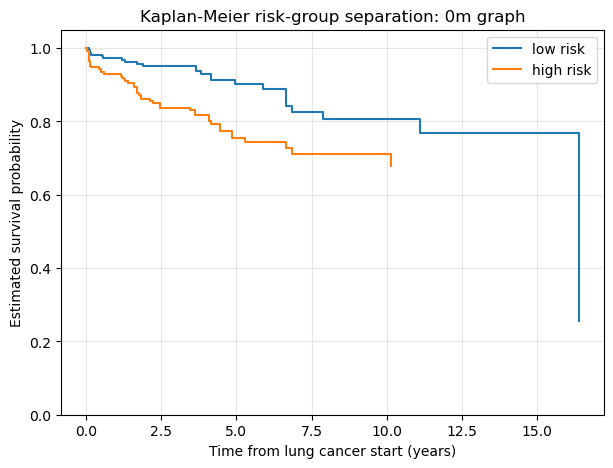

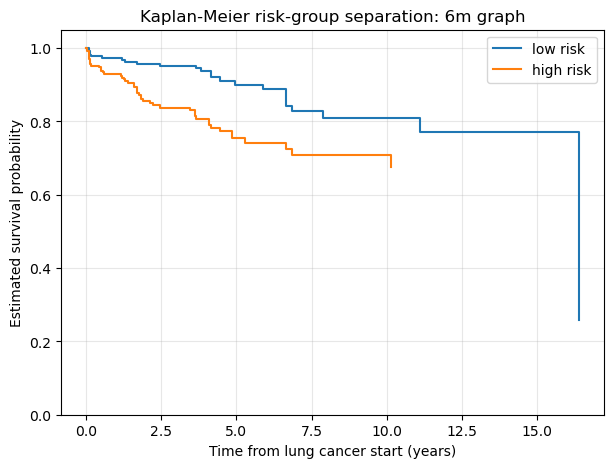

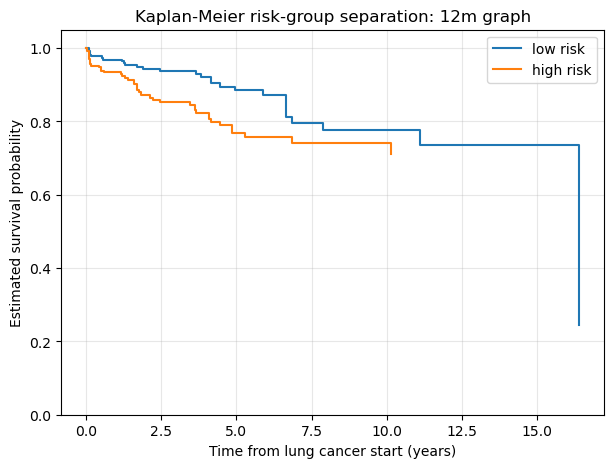

In [12]:
# ------------------------------------------------------------
# 12.11.7.5 Kaplan-Meier curves across graph windows
# ------------------------------------------------------------

km_curve_frames = []

for graph_window in KM_GRAPH_WINDOWS:
    for seed in KM_SEEDS:
        for risk_group in ["low_risk", "high_risk"]:
            group_df = km_test_predictions_df[
                (km_test_predictions_df["graph_window"] == graph_window)
                & (km_test_predictions_df["seed"] == seed)
                & (km_test_predictions_df["risk_group"] == risk_group)
            ].copy()

            km_curve_df = compute_km_curve(
                times=group_df["survival_time_years"],
                events=group_df["event_death"],
            )

            km_curve_df["graph_window"] = graph_window
            km_curve_df["seed"] = seed
            km_curve_df["risk_group"] = risk_group

            km_curve_frames.append(km_curve_df)

km_curves_by_seed_df = pd.concat(
    km_curve_frames,
    ignore_index=True,
)

print("Kaplan-Meier curve rows by graph window and risk group:")
display(
    km_curves_by_seed_df
    .groupby(["graph_window", "risk_group"])
    .size()
    .reset_index(name="n_curve_points")
)


# Descriptive pooled Kaplan-Meier curves across seed-level test predictions.
pooled_km_curve_frames = []

for graph_window in KM_GRAPH_WINDOWS:
    for risk_group in ["low_risk", "high_risk"]:
        group_df = km_test_predictions_df[
            (km_test_predictions_df["graph_window"] == graph_window)
            & (km_test_predictions_df["risk_group"] == risk_group)
        ].copy()

        pooled_curve_df = compute_km_curve(
            times=group_df["survival_time_years"],
            events=group_df["event_death"],
        )

        pooled_curve_df["graph_window"] = graph_window
        pooled_curve_df["risk_group"] = risk_group

        pooled_km_curve_frames.append(pooled_curve_df)

pooled_km_curves_df = pd.concat(
    pooled_km_curve_frames,
    ignore_index=True,
)

print("\nPooled descriptive Kaplan-Meier curve rows:")
display(
    pooled_km_curves_df
    .groupby(["graph_window", "risk_group"])
    .size()
    .reset_index(name="n_curve_points")
)


for graph_window in KM_GRAPH_WINDOWS:
    plt.figure(figsize=(7, 5))

    for risk_group in ["low_risk", "high_risk"]:
        curve_df = pooled_km_curves_df[
            (pooled_km_curves_df["graph_window"] == graph_window)
            & (pooled_km_curves_df["risk_group"] == risk_group)
        ].copy()

        label = risk_group.replace("_", " ")

        plt.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=label,
        )

    plt.title(f"Kaplan-Meier risk-group separation: {graph_window} graph")
    plt.xlabel("Time from lung cancer start (years)")
    plt.ylabel("Estimated survival probability")
    plt.ylim(0.0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

#### Save Kaplan-Meier risk-group analysis outputs and figures

We save the Kaplan-Meier risk-group predictions, seed-level summaries, graph-window summaries, pooled descriptive summaries, and Kaplan-Meier curve tables. We also export publication-ready PNG figures for the pooled Kaplan-Meier curves across the 0-month, 6-month, and 12-month graph windows, so they can be used later in the project report or poster.

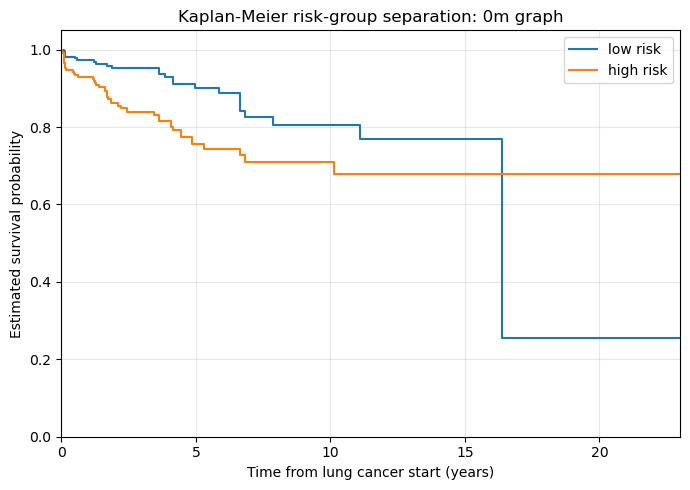

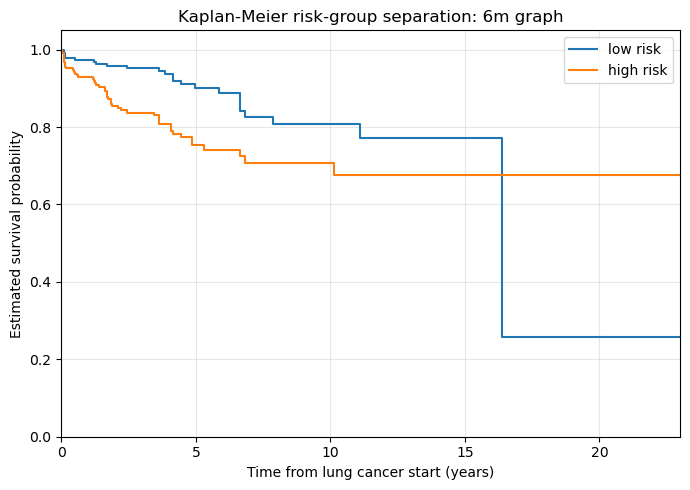

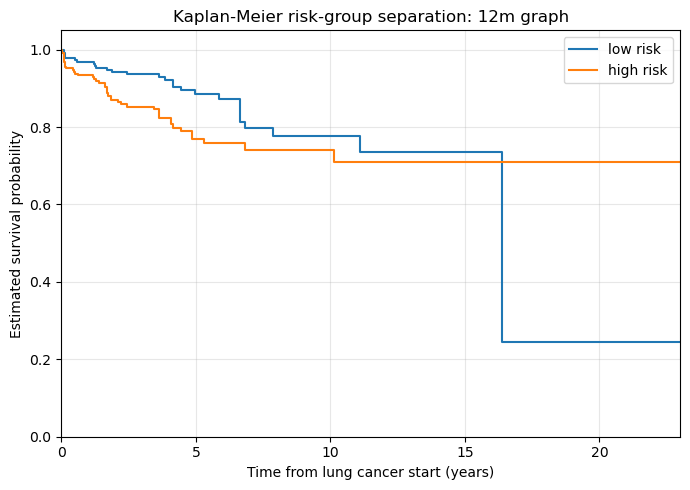

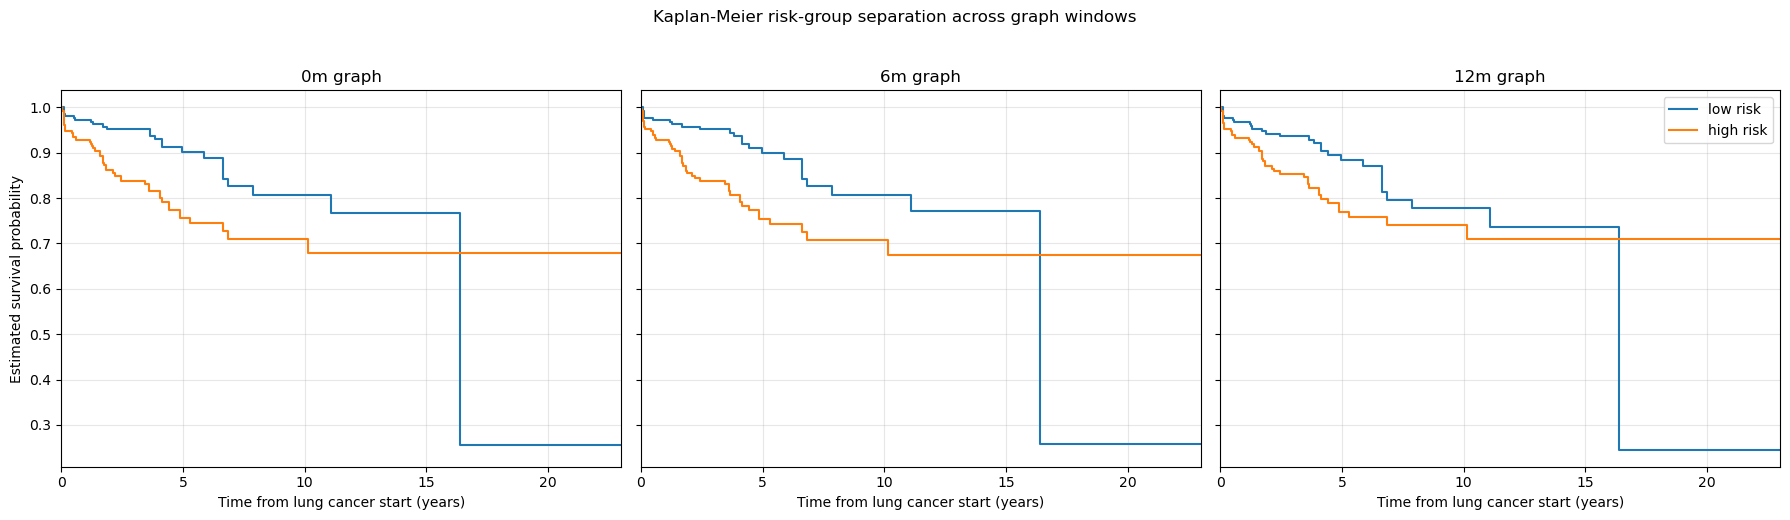

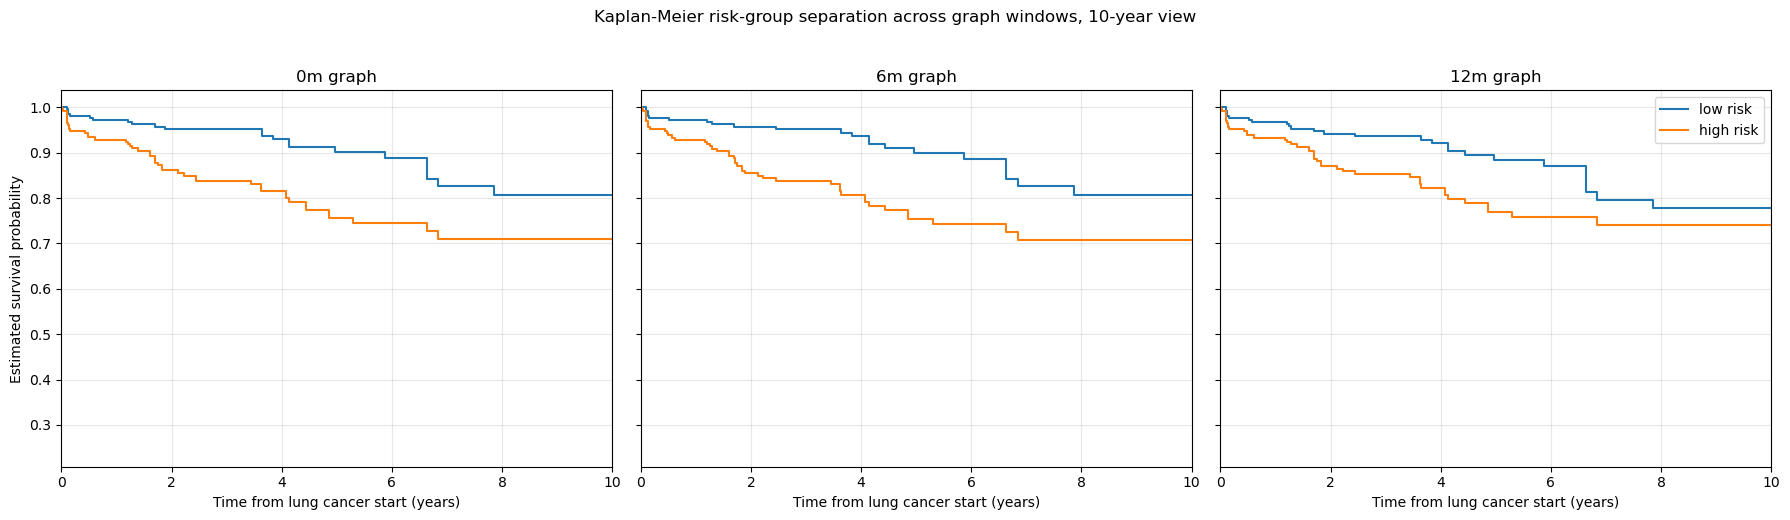

Saved Kaplan-Meier risk-group analysis outputs:
Test predictions: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/km_test_predictions_0m_6m_12m_20260629_173733.csv
Seed group summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/km_seed_group_summary_0m_6m_12m_20260629_173733.csv
Seed separation diagnostics: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/km_seed_separation_diagnostics_0m_6m_12m_20260629_173733.csv
Graph-window summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only

In [14]:
# ------------------------------------------------------------
# 12.11.7.6 Save Kaplan-Meier risk-group analysis outputs and figures
# ------------------------------------------------------------

import os
from datetime import datetime

km_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

km_artifact_dir = os.path.dirname(graph_paths_by_window["6m"])

km_output_dir = os.path.join(
    km_artifact_dir,
    "kaplan_meier_risk_group_analysis_0m_6m_12m",
)

os.makedirs(km_output_dir, exist_ok=True)

# -----------------------------
# Save CSV outputs
# -----------------------------

km_test_predictions_path = os.path.join(
    km_output_dir,
    f"km_test_predictions_0m_6m_12m_{km_timestamp}.csv",
)

km_seed_group_summary_path = os.path.join(
    km_output_dir,
    f"km_seed_group_summary_0m_6m_12m_{km_timestamp}.csv",
)

km_seed_separation_diagnostics_path = os.path.join(
    km_output_dir,
    f"km_seed_separation_diagnostics_0m_6m_12m_{km_timestamp}.csv",
)

km_window_summary_path = os.path.join(
    km_output_dir,
    f"km_graph_window_summary_0m_6m_12m_{km_timestamp}.csv",
)

km_pooled_group_summary_path = os.path.join(
    km_output_dir,
    f"km_pooled_group_summary_0m_6m_12m_{km_timestamp}.csv",
)

km_curves_by_seed_path = os.path.join(
    km_output_dir,
    f"km_curves_by_seed_0m_6m_12m_{km_timestamp}.csv",
)

pooled_km_curves_path = os.path.join(
    km_output_dir,
    f"pooled_km_curves_0m_6m_12m_{km_timestamp}.csv",
)

km_test_predictions_df.to_csv(km_test_predictions_path, index=False)
km_seed_group_summary_df.to_csv(km_seed_group_summary_path, index=False)
km_seed_pivot_df.to_csv(km_seed_separation_diagnostics_path, index=False)
km_window_summary_df.to_csv(km_window_summary_path, index=False)
km_pooled_group_summary_df.to_csv(km_pooled_group_summary_path, index=False)
km_curves_by_seed_df.to_csv(km_curves_by_seed_path, index=False)
pooled_km_curves_df.to_csv(pooled_km_curves_path, index=False)


# -----------------------------
# Helper for nicer KM plotting
# -----------------------------

def extend_curve_to_time(curve_df, max_time):
    """
    Extend a KM curve horizontally to the requested maximum time.
    This prevents curves from visually stopping at the last event time.
    """

    curve_df = curve_df.sort_values("time").copy()

    if curve_df.empty:
        return curve_df

    last_time = float(curve_df["time"].iloc[-1])
    last_survival = float(curve_df["survival_probability"].iloc[-1])

    if last_time < max_time:
        curve_df = pd.concat(
            [
                curve_df,
                pd.DataFrame({
                    "time": [float(max_time)],
                    "survival_probability": [last_survival],
                }),
            ],
            ignore_index=True,
        )

    return curve_df


def plot_pooled_km_for_window(graph_window, output_path=None, x_max=None):
    """
    Plot pooled descriptive KM curves for one graph window.
    """

    if x_max is None:
        x_max = float(
            km_test_predictions_df.loc[
                km_test_predictions_df["graph_window"] == graph_window,
                "survival_time_years"
            ].max()
        )

    plt.figure(figsize=(7, 5))

    for risk_group in ["low_risk", "high_risk"]:
        curve_df = pooled_km_curves_df[
            (pooled_km_curves_df["graph_window"] == graph_window)
            & (pooled_km_curves_df["risk_group"] == risk_group)
        ].copy()

        curve_df = extend_curve_to_time(curve_df, x_max)

        plt.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=risk_group.replace("_", " "),
        )

    plt.title(f"Kaplan-Meier risk-group separation: {graph_window} graph")
    plt.xlabel("Time from lung cancer start (years)")
    plt.ylabel("Estimated survival probability")
    plt.ylim(0.0, 1.05)
    plt.xlim(0.0, x_max)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


# -----------------------------
# Save individual full KM figures
# -----------------------------

km_png_paths = {}

for graph_window in KM_GRAPH_WINDOWS:
    output_path = os.path.join(
        km_output_dir,
        f"pooled_km_curve_{graph_window}_full_{km_timestamp}.png",
    )

    plot_pooled_km_for_window(
        graph_window=graph_window,
        output_path=output_path,
        x_max=None,
    )

    km_png_paths[f"{graph_window}_full"] = output_path


# -----------------------------
# Save combined 3-panel KM figure, full follow-up
# -----------------------------

combined_full_png_path = os.path.join(
    km_output_dir,
    f"pooled_km_curves_0m_6m_12m_combined_full_{km_timestamp}.png",
)

global_x_max = float(km_test_predictions_df["survival_time_years"].max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, graph_window in zip(axes, KM_GRAPH_WINDOWS):
    for risk_group in ["low_risk", "high_risk"]:
        curve_df = pooled_km_curves_df[
            (pooled_km_curves_df["graph_window"] == graph_window)
            & (pooled_km_curves_df["risk_group"] == risk_group)
        ].copy()

        curve_df = extend_curve_to_time(curve_df, global_x_max)

        ax.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=risk_group.replace("_", " "),
        )

    ax.set_title(f"{graph_window} graph")
    ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0.0, global_x_max)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimated survival probability")
axes[-1].legend()
fig.suptitle("Kaplan-Meier risk-group separation across graph windows", y=1.03)
plt.tight_layout()
plt.savefig(combined_full_png_path, dpi=300, bbox_inches="tight")
plt.show()

km_png_paths["combined_full"] = combined_full_png_path


# -----------------------------
# Save combined 3-panel KM figure, focused 10-year view
# -----------------------------

combined_10y_png_path = os.path.join(
    km_output_dir,
    f"pooled_km_curves_0m_6m_12m_combined_10y_{km_timestamp}.png",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, graph_window in zip(axes, KM_GRAPH_WINDOWS):
    for risk_group in ["low_risk", "high_risk"]:
        curve_df = pooled_km_curves_df[
            (pooled_km_curves_df["graph_window"] == graph_window)
            & (pooled_km_curves_df["risk_group"] == risk_group)
        ].copy()

        curve_df = extend_curve_to_time(curve_df, 10.0)

        ax.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=risk_group.replace("_", " "),
        )

    ax.set_title(f"{graph_window} graph")
    ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0.0, 10.0)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimated survival probability")
axes[-1].legend()
fig.suptitle("Kaplan-Meier risk-group separation across graph windows, 10-year view", y=1.03)
plt.tight_layout()
plt.savefig(combined_10y_png_path, dpi=300, bbox_inches="tight")
plt.show()

km_png_paths["combined_10y"] = combined_10y_png_path


# -----------------------------
# Print saved paths
# -----------------------------

print("Saved Kaplan-Meier risk-group analysis outputs:")
print("Test predictions:", km_test_predictions_path)
print("Seed group summary:", km_seed_group_summary_path)
print("Seed separation diagnostics:", km_seed_separation_diagnostics_path)
print("Graph-window summary:", km_window_summary_path)
print("Pooled group summary:", km_pooled_group_summary_path)
print("KM curves by seed:", km_curves_by_seed_path)
print("Pooled KM curves:", pooled_km_curves_path)

print("\nSaved PNG figures:")
for figure_name, figure_path in km_png_paths.items():
    print(f"{figure_name}: {figure_path}")

Copied poster-ready KM figure to:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/notebooks/km_figures_for_poster/pooled_km_curves_0m_6m_12m_combined_10y_20260629_173733.png


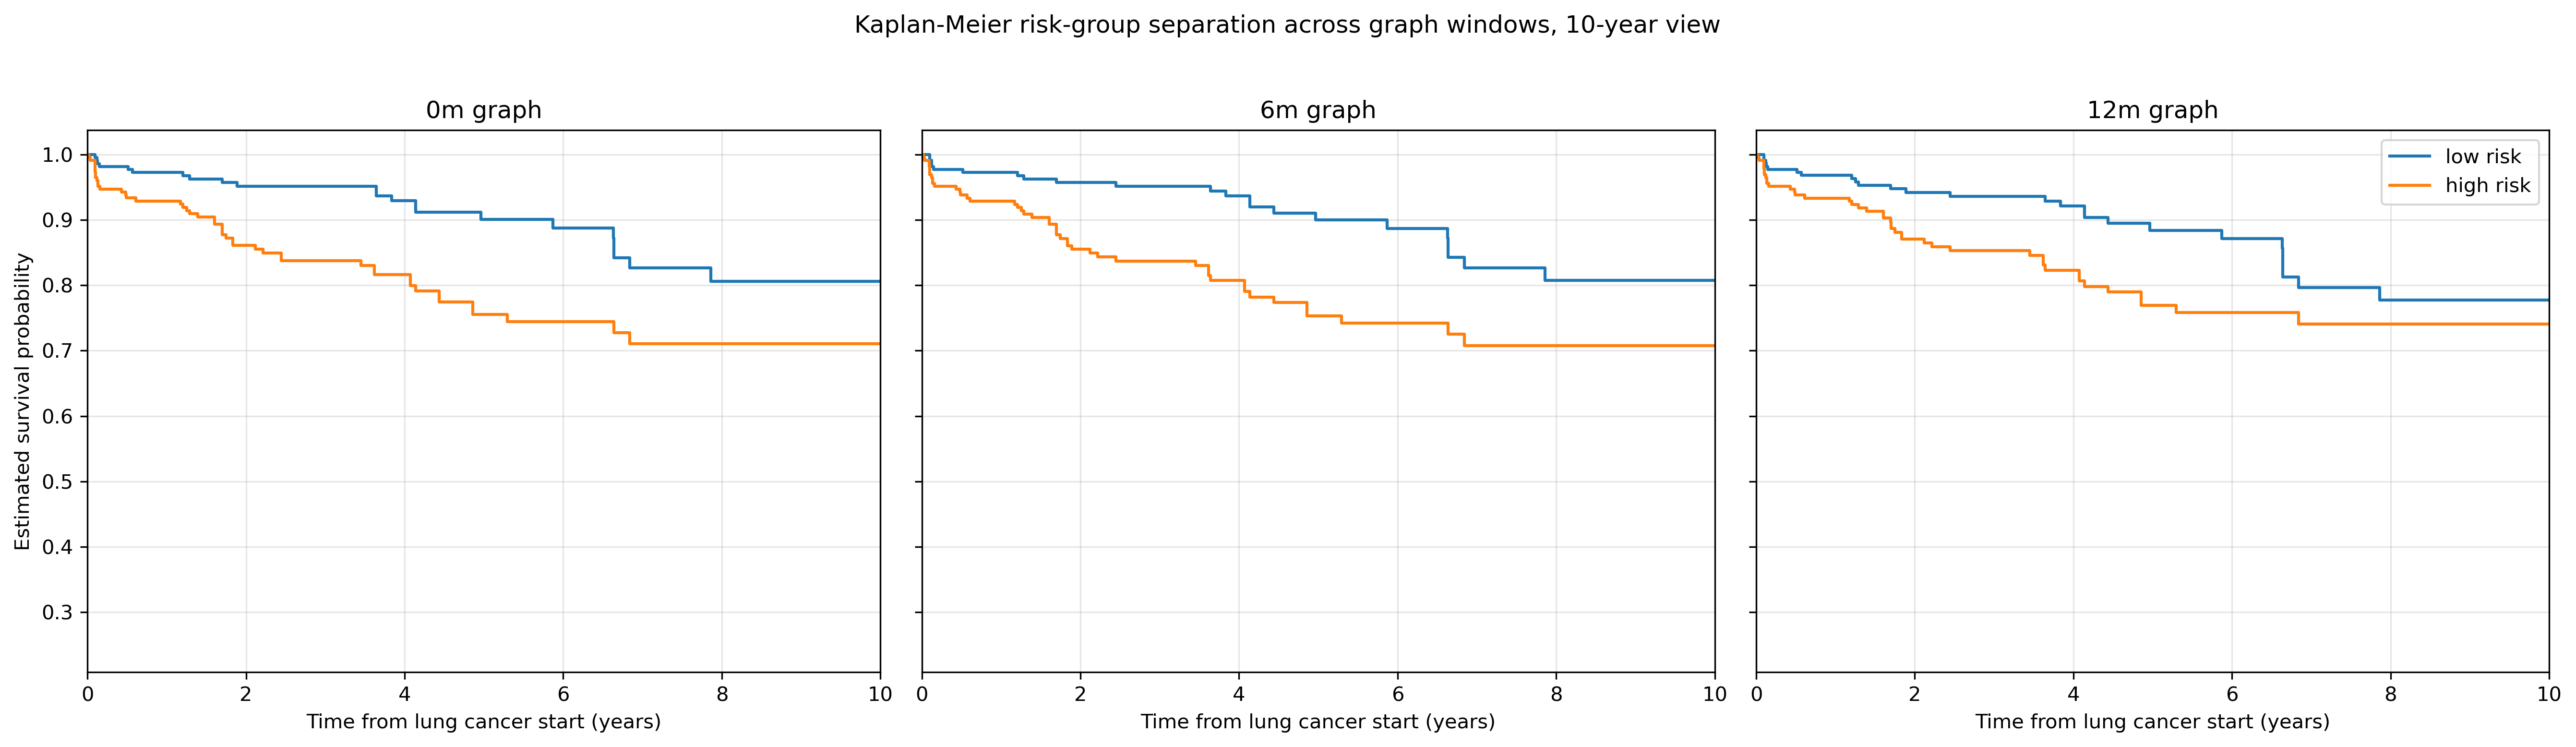

In [15]:
# Copy the main poster-ready KM figure to an easy-to-find folder

import os
import shutil
from IPython.display import Image, display

poster_dir = os.path.join(os.getcwd(), "km_figures_for_poster")
os.makedirs(poster_dir, exist_ok=True)

main_km_png_path = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/pooled_km_curves_0m_6m_12m_combined_10y_20260629_173733.png"

copied_km_png_path = os.path.join(
    poster_dir,
    os.path.basename(main_km_png_path),
)

shutil.copy2(main_km_png_path, copied_km_png_path)

print("Copied poster-ready KM figure to:")
print(copied_km_png_path)

display(Image(filename=copied_km_png_path))

#### Interpretation of Kaplan-Meier risk-group separation

The Kaplan-Meier risk-group analysis shows that the predicted high-risk group generally has worse observed survival than the predicted low-risk group across all three graph windows. This indicates that the graph-based Cox model produces risk scores that are meaningfully related to observed survival patterns, rather than arbitrary patient rankings.

The 6-month graph window provides the most consistent separation across random seeds. In the seed-level summaries, the high-risk group had more observed death events and a higher event rate than the low-risk group in all six seeds for the 6-month graph. In contrast, the 0-month and 12-month graph windows showed this pattern in five out of six seeds. The 6-month graph also had the lowest variability in event-rate separation across seeds, suggesting more stable risk stratification.

The pooled descriptive Kaplan-Meier curves support this interpretation. For all graph windows, the high-risk curve lies below the low-risk curve, meaning that patients assigned higher risk scores tend to experience worse observed survival. The 6-month graph shows the clearest and most consistent risk-group separation among the evaluated graph windows. However, the curves should be interpreted descriptively, because pooling across seed-level test predictions does not create a single independent cohort and some patients may appear in test sets across multiple random splits.

Overall, these results support the conclusion that the 6-month cumulative graph contains the most consistent prognostic signal among the evaluated graph windows. The separation is modest rather than definitive, which is expected given the small number of observed death events per test split, but it provides additional evidence that the model captures clinically relevant survival-risk structure.


#### Extreme-risk sensitivity analysis

As an additional sensitivity analysis, we evaluate whether risk-group separation becomes stronger when comparing only the most extreme predicted-risk patients. Instead of splitting each test set into equal low-risk and high-risk halves, we compare the bottom third of predicted risk scores with the top third within each graph window and seed. The middle third is excluded from this analysis.

This analysis does not replace the median-based Kaplan-Meier grouping. Rather, it tests whether the model shows clearer separation among patients for whom it assigns the most confident low-risk and high-risk scores.

In [16]:
# ------------------------------------------------------------
# 12.11.7.8 Extreme-risk sensitivity analysis
# ------------------------------------------------------------

extreme_prediction_frames = []

for graph_window in KM_GRAPH_WINDOWS:
    for seed in KM_SEEDS:
        split_df = km_test_predictions_df[
            (km_test_predictions_df["graph_window"] == graph_window)
            & (km_test_predictions_df["seed"] == seed)
        ].copy()

        split_df = split_df.sort_values("risk_score").reset_index(drop=True)

        n_test = len(split_df)
        n_extreme = n_test // 3

        low_extreme_df = split_df.iloc[:n_extreme].copy()
        high_extreme_df = split_df.iloc[-n_extreme:].copy()

        low_extreme_df["extreme_risk_group"] = "bottom_third_low_risk"
        high_extreme_df["extreme_risk_group"] = "top_third_high_risk"

        extreme_prediction_frames.append(low_extreme_df)
        extreme_prediction_frames.append(high_extreme_df)

extreme_risk_predictions_df = pd.concat(
    extreme_prediction_frames,
    ignore_index=True,
)

print("Extreme-risk prediction rows:")
display(
    extreme_risk_predictions_df
    .groupby(["graph_window", "seed", "extreme_risk_group"])
    .size()
    .reset_index(name="n_rows")
    .head(18)
)


extreme_seed_group_summary_df = (
    extreme_risk_predictions_df
    .groupby(["graph_window", "seed", "extreme_risk_group"])
    .agg(
        n_patients=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_risk_score=("risk_score", "mean"),
        min_risk_score=("risk_score", "min"),
        max_risk_score=("risk_score", "max"),
    )
    .reset_index()
)

print("\nExtreme-risk seed-level group summary:")
display(extreme_seed_group_summary_df.head(18))


extreme_seed_pivot_df = extreme_seed_group_summary_df.pivot(
    index=["graph_window", "seed"],
    columns="extreme_risk_group",
    values=[
        "n_patients",
        "n_events",
        "event_rate",
        "median_observed_time",
        "mean_observed_time",
        "mean_risk_score",
    ],
)

extreme_seed_pivot_df.columns = [
    f"{metric}_{risk_group}"
    for metric, risk_group in extreme_seed_pivot_df.columns
]

extreme_seed_pivot_df = extreme_seed_pivot_df.reset_index()

extreme_seed_pivot_df["event_rate_delta_top_minus_bottom"] = (
    extreme_seed_pivot_df["event_rate_top_third_high_risk"]
    - extreme_seed_pivot_df["event_rate_bottom_third_low_risk"]
)

extreme_seed_pivot_df["n_events_delta_top_minus_bottom"] = (
    extreme_seed_pivot_df["n_events_top_third_high_risk"]
    - extreme_seed_pivot_df["n_events_bottom_third_low_risk"]
)

extreme_seed_pivot_df["median_time_delta_bottom_minus_top"] = (
    extreme_seed_pivot_df["median_observed_time_bottom_third_low_risk"]
    - extreme_seed_pivot_df["median_observed_time_top_third_high_risk"]
)

extreme_seed_pivot_df["mean_time_delta_bottom_minus_top"] = (
    extreme_seed_pivot_df["mean_observed_time_bottom_third_low_risk"]
    - extreme_seed_pivot_df["mean_observed_time_top_third_high_risk"]
)

extreme_seed_pivot_df["top_third_has_more_events"] = (
    extreme_seed_pivot_df["n_events_delta_top_minus_bottom"] > 0
)

extreme_seed_pivot_df["top_third_has_higher_event_rate"] = (
    extreme_seed_pivot_df["event_rate_delta_top_minus_bottom"] > 0
)

extreme_seed_pivot_df["top_third_has_shorter_median_time"] = (
    extreme_seed_pivot_df["median_time_delta_bottom_minus_top"] > 0
)

extreme_seed_pivot_df["top_third_has_shorter_mean_time"] = (
    extreme_seed_pivot_df["mean_time_delta_bottom_minus_top"] > 0
)

print("\nExtreme-risk seed-level separation diagnostics:")
display(
    extreme_seed_pivot_df.sort_values(["graph_window", "seed"])
)


extreme_window_summary_df = (
    extreme_seed_pivot_df
    .groupby("graph_window")
    .agg(
        n_seeds=("seed", "nunique"),
        mean_event_rate_delta_top_minus_bottom=("event_rate_delta_top_minus_bottom", "mean"),
        std_event_rate_delta_top_minus_bottom=("event_rate_delta_top_minus_bottom", "std"),
        mean_n_events_delta_top_minus_bottom=("n_events_delta_top_minus_bottom", "mean"),
        mean_median_time_delta_bottom_minus_top=("median_time_delta_bottom_minus_top", "mean"),
        std_median_time_delta_bottom_minus_top=("median_time_delta_bottom_minus_top", "std"),
        mean_mean_time_delta_bottom_minus_top=("mean_time_delta_bottom_minus_top", "mean"),
        seeds_top_third_more_events=("top_third_has_more_events", "sum"),
        seeds_top_third_higher_event_rate=("top_third_has_higher_event_rate", "sum"),
        seeds_top_third_shorter_median_time=("top_third_has_shorter_median_time", "sum"),
        seeds_top_third_shorter_mean_time=("top_third_has_shorter_mean_time", "sum"),
    )
    .reset_index()
)

extreme_window_summary_df["share_seeds_top_third_more_events"] = (
    extreme_window_summary_df["seeds_top_third_more_events"]
    / extreme_window_summary_df["n_seeds"]
)

extreme_window_summary_df["share_seeds_top_third_shorter_median_time"] = (
    extreme_window_summary_df["seeds_top_third_shorter_median_time"]
    / extreme_window_summary_df["n_seeds"]
)

extreme_window_summary_df["share_seeds_top_third_shorter_mean_time"] = (
    extreme_window_summary_df["seeds_top_third_shorter_mean_time"]
    / extreme_window_summary_df["n_seeds"]
)

window_order = {"0m": 0, "6m": 1, "12m": 2}

extreme_window_summary_df = (
    extreme_window_summary_df
    .assign(window_order=lambda df: df["graph_window"].map(window_order))
    .sort_values("window_order")
    .drop(columns="window_order")
)

print("\nExtreme-risk graph-window summary:")
display(extreme_window_summary_df)


extreme_pooled_group_summary_df = (
    extreme_risk_predictions_df
    .groupby(["graph_window", "extreme_risk_group"])
    .agg(
        n_prediction_rows=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_risk_score=("risk_score", "mean"),
    )
    .reset_index()
)

extreme_pooled_group_summary_df = (
    extreme_pooled_group_summary_df
    .assign(window_order=lambda df: df["graph_window"].map(window_order))
    .sort_values(["window_order", "extreme_risk_group"])
    .drop(columns="window_order")
)

print("\nExtreme-risk pooled descriptive summary:")
display(extreme_pooled_group_summary_df)

Extreme-risk prediction rows:


,graph_window,seed,extreme_risk_group,n_rows
0,0m,7,bottom_third_low_risk,25
1,0m,7,top_third_high_risk,25
2,0m,13,bottom_third_low_risk,25
3,0m,13,top_third_high_risk,25
4,0m,21,bottom_third_low_risk,25
5,0m,21,top_third_high_risk,25
6,0m,42,bottom_third_low_risk,25
7,0m,42,top_third_high_risk,25
8,0m,99,bottom_third_low_risk,25
9,0m,99,top_third_high_risk,25



Extreme-risk seed-level group summary:


,graph_window,seed,extreme_risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score,min_risk_score,max_risk_score
0,0m,7,bottom_third_low_risk,25,1,0.04,5.300479,6.801697,-10.655351,-11.913746,-10.443188
1,0m,7,top_third_high_risk,25,7,0.28,2.825462,4.012375,-5.282270,-10.332005,-3.671999
2,0m,13,bottom_third_low_risk,25,3,0.12,3.783710,4.218590,12.633745,12.351380,12.671066
3,0m,13,top_third_high_risk,25,5,0.20,2.579056,3.637180,15.334359,12.737277,15.719399
4,0m,21,bottom_third_low_risk,25,4,0.16,4.136892,4.957043,65.463330,55.914345,66.186394
5,0m,21,top_third_high_risk,25,7,0.28,3.657769,3.759726,75.133833,74.707069,78.657806
6,0m,42,bottom_third_low_risk,25,2,0.08,4.514716,4.722464,6.446493,5.520225,6.509828
7,0m,42,top_third_high_risk,25,4,0.16,3.734428,3.643532,7.501823,7.426614,7.781466
8,0m,99,bottom_third_low_risk,25,1,0.04,4.019165,4.762218,14.177516,12.255904,14.290311
9,0m,99,top_third_high_risk,25,4,0.16,2.757016,4.172375,17.338283,15.937914,17.488214



Extreme-risk seed-level separation diagnostics:


,graph_window,seed,n_patients_bottom_third_low_risk,n_patients_top_third_high_risk,n_events_bottom_third_low_risk,n_events_top_third_high_risk,event_rate_bottom_third_low_risk,event_rate_top_third_high_risk,median_observed_time_bottom_third_low_risk,median_observed_time_top_third_high_risk,...,mean_risk_score_bottom_third_low_risk,mean_risk_score_top_third_high_risk,event_rate_delta_top_minus_bottom,n_events_delta_top_minus_bottom,median_time_delta_bottom_minus_top,mean_time_delta_bottom_minus_top,top_third_has_more_events,top_third_has_higher_event_rate,top_third_has_shorter_median_time,top_third_has_shorter_mean_time
0,0m,7,25.0,25.0,1.0,7.0,0.04,0.28,5.300479,2.825462,...,-10.655351,-5.282270,0.24,6.0,2.475017,2.789322,True,True,True,True
1,0m,13,25.0,25.0,3.0,5.0,0.12,0.20,3.783710,2.579056,...,12.633745,15.334359,0.08,2.0,1.204654,0.581410,True,True,True,True
2,0m,21,25.0,25.0,4.0,7.0,0.16,0.28,4.136892,3.657769,...,65.463330,75.133833,0.12,3.0,0.479124,1.197317,True,True,True,True
3,0m,42,25.0,25.0,2.0,4.0,0.08,0.16,4.514716,3.734428,...,6.446493,7.501823,0.08,2.0,0.780288,1.078932,True,True,True,True
4,0m,99,25.0,25.0,1.0,4.0,0.04,0.16,4.019165,2.757016,...,14.177516,17.338283,0.12,3.0,1.262149,0.589843,True,True,True,True
5,0m,123,25.0,25.0,4.0,4.0,0.16,0.16,2.896646,4.731006,...,4.451631,5.213950,0.00,0.0,-1.834360,-1.857796,False,False,False,False
6,12m,7,25.0,25.0,2.0,6.0,0.08,0.24,5.568789,2.009583,...,-10.628527,-5.264563,0.16,4.0,3.559206,3.995291,True,True,True,True
7,12m,13,25.0,25.0,3.0,5.0,0.12,0.20,3.783710,2.579056,...,12.664453,15.324518,0.08,2.0,1.204654,0.799671,True,True,True,True
8,12m,21,25.0,25.0,4.0,7.0,0.16,0.28,4.136892,3.657769,...,65.465117,75.140593,0.12,3.0,0.479124,1.197317,True,True,True,True
9,12m,42,25.0,25.0,3.0,4.0,0.12,0.16,3.641341,3.134839,...,16.577611,19.718412,0.04,1.0,0.506502,0.622478,True,True,True,True



Extreme-risk graph-window summary:


,graph_window,n_seeds,mean_event_rate_delta_top_minus_bottom,std_event_rate_delta_top_minus_bottom,mean_n_events_delta_top_minus_bottom,mean_median_time_delta_bottom_minus_top,std_median_time_delta_bottom_minus_top,mean_mean_time_delta_bottom_minus_top,seeds_top_third_more_events,seeds_top_third_higher_event_rate,seeds_top_third_shorter_median_time,seeds_top_third_shorter_mean_time,share_seeds_top_third_more_events,share_seeds_top_third_shorter_median_time,share_seeds_top_third_shorter_mean_time
0,0m,6,0.106667,0.078655,2.666667,0.727812,1.427932,0.729838,5,5,5,5,0.833333,0.833333,0.833333
2,6m,6,0.113333,0.053166,2.833333,1.015743,1.460876,0.985663,6,6,5,5,1.000000,0.833333,0.833333
1,12m,6,0.100000,0.041952,2.500000,1.000228,1.479047,0.941218,6,6,5,5,1.000000,0.833333,0.833333



Extreme-risk pooled descriptive summary:


,graph_window,extreme_risk_group,n_prediction_rows,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score
0,0m,bottom_third_low_risk,150,15,0.100000,3.987680,4.819840,15.419561
1,0m,top_third_high_risk,150,31,0.206667,3.494866,4.090002,19.206663
4,6m,bottom_third_low_risk,150,14,0.093333,4.125941,4.965731,15.415620
5,6m,top_third_high_risk,150,31,0.206667,3.134839,3.980068,19.171366
2,12m,bottom_third_low_risk,150,15,0.100000,4.058864,4.914917,17.489414
3,12m,top_third_high_risk,150,30,0.200000,3.134839,3.973698,21.582010


#### Save extreme-risk sensitivity outputs

We save the extreme-risk sensitivity analysis outputs, including the selected top-third and bottom-third test predictions, seed-level summaries, graph-window summaries, and pooled descriptive summaries. These outputs provide an additional robustness check for whether the model separates patients with the most extreme predicted risk scores.

In [17]:
# ------------------------------------------------------------
# 12.11.7.9 Save extreme-risk sensitivity outputs
# ------------------------------------------------------------

import os
from datetime import datetime

extreme_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Reconstruct output directory if needed.
if "km_output_dir" not in globals():
    km_artifact_dir = os.path.dirname(graph_paths_by_window["6m"])
    km_output_dir = os.path.join(
        km_artifact_dir,
        "kaplan_meier_risk_group_analysis_0m_6m_12m",
    )

os.makedirs(km_output_dir, exist_ok=True)

extreme_predictions_path = os.path.join(
    km_output_dir,
    f"extreme_risk_predictions_0m_6m_12m_{extreme_timestamp}.csv",
)

extreme_seed_group_summary_path = os.path.join(
    km_output_dir,
    f"extreme_seed_group_summary_0m_6m_12m_{extreme_timestamp}.csv",
)

extreme_seed_diagnostics_path = os.path.join(
    km_output_dir,
    f"extreme_seed_separation_diagnostics_0m_6m_12m_{extreme_timestamp}.csv",
)

extreme_window_summary_path = os.path.join(
    km_output_dir,
    f"extreme_graph_window_summary_0m_6m_12m_{extreme_timestamp}.csv",
)

extreme_pooled_summary_path = os.path.join(
    km_output_dir,
    f"extreme_pooled_group_summary_0m_6m_12m_{extreme_timestamp}.csv",
)

extreme_risk_predictions_df.to_csv(extreme_predictions_path, index=False)
extreme_seed_group_summary_df.to_csv(extreme_seed_group_summary_path, index=False)
extreme_seed_pivot_df.to_csv(extreme_seed_diagnostics_path, index=False)
extreme_window_summary_df.to_csv(extreme_window_summary_path, index=False)
extreme_pooled_group_summary_df.to_csv(extreme_pooled_summary_path, index=False)

print("Saved extreme-risk sensitivity outputs:")
print("Extreme predictions:", extreme_predictions_path)
print("Extreme seed group summary:", extreme_seed_group_summary_path)
print("Extreme seed diagnostics:", extreme_seed_diagnostics_path)
print("Extreme graph-window summary:", extreme_window_summary_path)
print("Extreme pooled summary:", extreme_pooled_summary_path)

Saved extreme-risk sensitivity outputs:
Extreme predictions: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/extreme_risk_predictions_0m_6m_12m_20260629_183952.csv
Extreme seed group summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/extreme_seed_group_summary_0m_6m_12m_20260629_183952.csv
Extreme seed diagnostics: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/extreme_seed_separation_diagnostics_0m_6m_12m_20260629_183952.csv
Extreme graph-window summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_art

#### Interpretation of extreme-risk sensitivity analysis

The extreme-risk sensitivity analysis supports the main Kaplan-Meier risk-group findings. When comparing only the bottom third and top third of predicted risk scores within each test split, the top-third high-risk group generally showed higher event rates and shorter observed survival than the bottom-third low-risk group.

The 6-month graph again showed the strongest and most consistent separation. In the extreme-risk analysis, the top-third high-risk group had more observed death events and a higher event rate than the bottom-third low-risk group in all six seeds. The 12-month graph also showed this pattern in all six seeds, while the 0-month graph showed it in five out of six seeds. The 6-month graph had the largest mean event-rate difference between the top-risk and bottom-risk groups, suggesting that its risk scores provide the clearest separation among the most confidently ranked patients.

In the pooled descriptive summaries, the 6-month graph produced 31 observed death events in the top-third high-risk group compared with 14 observed death events in the bottom-third low-risk group. This strengthens the conclusion that the 6-month cumulative graph contains the most consistent prognostic signal among the evaluated graph windows.

Overall, the extreme-risk analysis provides an additional robustness check. It suggests that the model's risk scores are not only useful for median-based high-risk versus low-risk grouping, but also show clearer separation when focusing on patients with the most extreme predicted risk scores.

### Horizon-specific survival discrimination analysis

After evaluating Kaplan-Meier risk-group separation, we next assess whether the model discriminates survival outcomes at clinically meaningful time horizons. While the Cox-based model produces continuous relative-risk scores, horizon-based evaluation asks whether these scores can distinguish patients who experience death before a fixed time point from patients who survive beyond that time point.

In this section, we evaluate the predicted risk scores at 1-year, 3-year, and 5-year horizons across the 0-month, 6-month, and 12-month graph windows. This provides a complementary view to the C-index and Kaplan-Meier analyses by identifying whether the model is more informative for short-term or medium-term survival risk.

Patients censored before a given horizon do not provide a known binary outcome for that horizon and are excluded from the corresponding horizon-specific evaluation. The analysis is performed descriptively across the same seed-level test predictions generated for the Kaplan-Meier analysis.

#### Compute horizon-specific AUC at 1, 3, and 5 years

For each graph window, random seed, and time horizon, we convert the survival outcome into a horizon-specific binary label. Patients who died before or at the horizon are labeled as events. Patients known to have survived beyond the horizon are labeled as non-events. Patients censored before or at the horizon are excluded because their status at the horizon is unknown.

In [18]:
# ------------------------------------------------------------
# 12.11.8.1 Compute horizon-specific AUC at 1, 3, and 5 years
# ------------------------------------------------------------

import numpy as np
import pandas as pd


HORIZON_YEARS = [1.0, 3.0, 5.0]


def compute_binary_auc_from_scores(y_true, scores):
    """
    Compute ROC AUC from binary labels and continuous risk scores.

    This implementation avoids external dependencies.
    Higher scores are assumed to indicate higher event risk.
    """

    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())

    if n_pos == 0 or n_neg == 0:
        return np.nan

    # Average ranks handle ties correctly.
    ranks = pd.Series(scores).rank(method="average").to_numpy()

    sum_pos_ranks = ranks[y_true == 1].sum()

    auc = (
        sum_pos_ranks
        - n_pos * (n_pos + 1) / 2.0
    ) / (n_pos * n_neg)

    return float(auc)


def make_horizon_evaluation_df(predictions_df, horizon_years):
    """
    Build a horizon-specific evaluation table.

    Label definition:
    - y = 1: death occurred before or at the horizon.
    - y = 0: patient was observed beyond the horizon.
    - excluded: censored before or at the horizon.
    """

    rows = []

    for graph_window in KM_GRAPH_WINDOWS:
        for seed in KM_SEEDS:
            split_df = predictions_df[
                (predictions_df["graph_window"] == graph_window)
                & (predictions_df["seed"] == seed)
            ].copy()

            for horizon in horizon_years:
                time = split_df["survival_time_years"].astype(float)
                event = split_df["event_death"].astype(int)
                risk_score = split_df["risk_score"].astype(float)

                death_before_or_at_horizon = (event == 1) & (time <= horizon)
                known_survived_beyond_horizon = time > horizon
                censored_before_or_at_horizon = (event == 0) & (time <= horizon)

                evaluable_mask = (
                    death_before_or_at_horizon
                    | known_survived_beyond_horizon
                )

                eval_df = split_df.loc[evaluable_mask].copy()

                y_true = np.where(
                    (eval_df["event_death"].astype(int) == 1)
                    & (eval_df["survival_time_years"].astype(float) <= horizon),
                    1,
                    0,
                )

                auc = compute_binary_auc_from_scores(
                    y_true=y_true,
                    scores=eval_df["risk_score"].astype(float).to_numpy(),
                )

                rows.append({
                    "graph_window": graph_window,
                    "seed": seed,
                    "horizon_years": horizon,
                    "auc": auc,
                    "n_test_total": int(len(split_df)),
                    "n_evaluable": int(evaluable_mask.sum()),
                    "n_events_before_or_at_horizon": int(death_before_or_at_horizon.sum()),
                    "n_known_survived_beyond_horizon": int(known_survived_beyond_horizon.sum()),
                    "n_censored_excluded": int(censored_before_or_at_horizon.sum()),
                    "event_rate_among_evaluable": (
                        float(death_before_or_at_horizon.sum() / evaluable_mask.sum())
                        if int(evaluable_mask.sum()) > 0
                        else np.nan
                    ),
                })

    return pd.DataFrame(rows)


horizon_auc_seed_df = make_horizon_evaluation_df(
    predictions_df=km_test_predictions_df,
    horizon_years=HORIZON_YEARS,
)

print("Horizon-specific AUC by graph window, seed, and horizon:")
display(
    horizon_auc_seed_df.sort_values(
        ["horizon_years", "graph_window", "seed"]
    )
)


horizon_auc_summary_df = (
    horizon_auc_seed_df
    .groupby(["graph_window", "horizon_years"])
    .agg(
        n_seeds=("seed", "nunique"),
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        min_auc=("auc", "min"),
        max_auc=("auc", "max"),
        mean_n_evaluable=("n_evaluable", "mean"),
        mean_events_before_or_at_horizon=("n_events_before_or_at_horizon", "mean"),
        mean_known_survived_beyond_horizon=("n_known_survived_beyond_horizon", "mean"),
        mean_censored_excluded=("n_censored_excluded", "mean"),
        mean_event_rate_among_evaluable=("event_rate_among_evaluable", "mean"),
    )
    .reset_index()
)

window_order = {"0m": 0, "6m": 1, "12m": 2}

horizon_auc_summary_df = (
    horizon_auc_summary_df
    .assign(window_order=lambda df: df["graph_window"].map(window_order))
    .sort_values(["horizon_years", "window_order"])
    .drop(columns="window_order")
)

print("\nHorizon-specific AUC summary across seeds:")
display(horizon_auc_summary_df)


best_by_horizon_df = (
    horizon_auc_summary_df
    .sort_values(["horizon_years", "mean_auc"], ascending=[True, False])
    .groupby("horizon_years")
    .head(1)
    .reset_index(drop=True)
)

print("\nBest graph window by mean horizon-specific AUC:")
display(best_by_horizon_df)

Horizon-specific AUC by graph window, seed, and horizon:


,graph_window,seed,horizon_years,auc,n_test_total,n_evaluable,n_events_before_or_at_horizon,n_known_survived_beyond_horizon,n_censored_excluded,event_rate_among_evaluable
3,0m,7,1.0,0.781250,76,69,5,64,7,0.072464
6,0m,13,1.0,0.564516,76,66,4,62,10,0.060606
9,0m,21,1.0,0.804348,76,71,2,69,5,0.028169
0,0m,42,1.0,0.508197,76,66,5,61,10,0.075758
12,0m,99,1.0,0.693182,76,70,4,66,6,0.057143
15,0m,123,1.0,0.423077,76,67,2,65,9,0.029851
39,12m,7,1.0,0.768750,76,69,5,64,7,0.072464
42,12m,13,1.0,0.500000,76,66,4,62,10,0.060606
45,12m,21,1.0,0.797101,76,71,2,69,5,0.028169
36,12m,42,1.0,0.554098,76,66,5,61,10,0.075758



Horizon-specific AUC summary across seeds:


,graph_window,horizon_years,n_seeds,mean_auc,std_auc,min_auc,max_auc,mean_n_evaluable,mean_events_before_or_at_horizon,mean_known_survived_beyond_horizon,mean_censored_excluded,mean_event_rate_among_evaluable
0,0m,1.0,6,0.629095,0.154403,0.423077,0.804348,68.166667,3.666667,64.500000,7.833333,0.053998
6,6m,1.0,6,0.644090,0.163066,0.392308,0.797101,68.166667,3.666667,64.500000,7.833333,0.053998
3,12m,1.0,6,0.638620,0.144094,0.476923,0.797101,68.166667,3.666667,64.500000,7.833333,0.053998
1,0m,3.0,6,0.676661,0.096078,0.524155,0.802778,52.000000,7.166667,44.833333,24.000000,0.138465
7,6m,3.0,6,0.688708,0.068438,0.632653,0.797222,52.000000,7.166667,44.833333,24.000000,0.138465
4,12m,3.0,6,0.674943,0.094908,0.524155,0.797222,52.000000,7.166667,44.833333,24.000000,0.138465
2,0m,5.0,6,0.665596,0.101190,0.560606,0.833333,35.000000,9.833333,25.166667,41.000000,0.286826
8,6m,5.0,6,0.672134,0.092406,0.577778,0.829630,35.000000,9.833333,25.166667,41.000000,0.286826
5,12m,5.0,6,0.655808,0.105061,0.545455,0.833333,35.000000,9.833333,25.166667,41.000000,0.286826



Best graph window by mean horizon-specific AUC:


,graph_window,horizon_years,n_seeds,mean_auc,std_auc,min_auc,max_auc,mean_n_evaluable,mean_events_before_or_at_horizon,mean_known_survived_beyond_horizon,mean_censored_excluded,mean_event_rate_among_evaluable
0,6m,1.0,6,0.644090,0.163066,0.392308,0.797101,68.166667,3.666667,64.500000,7.833333,0.053998
1,6m,3.0,6,0.688708,0.068438,0.632653,0.797222,52.000000,7.166667,44.833333,24.000000,0.138465
2,6m,5.0,6,0.672134,0.092406,0.577778,0.829630,35.000000,9.833333,25.166667,41.000000,0.286826


#### Save horizon-specific AUC outputs and figures

We save the horizon-specific AUC results across graph windows, seeds, and time horizons. We also export a summary figure showing the mean AUC at 1-year, 3-year, and 5-year horizons for the 0-month, 6-month, and 12-month graph windows.

Saved horizon-specific AUC outputs:
Seed-level horizon AUC: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/horizon_auc_seed_level_0m_6m_12m_20260629_185435.csv
Horizon AUC summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/horizon_auc_summary_0m_6m_12m_20260629_185435.csv
Best graph by horizon: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/horizon_auc_best_graph_by_horizon_20260629_185435.csv


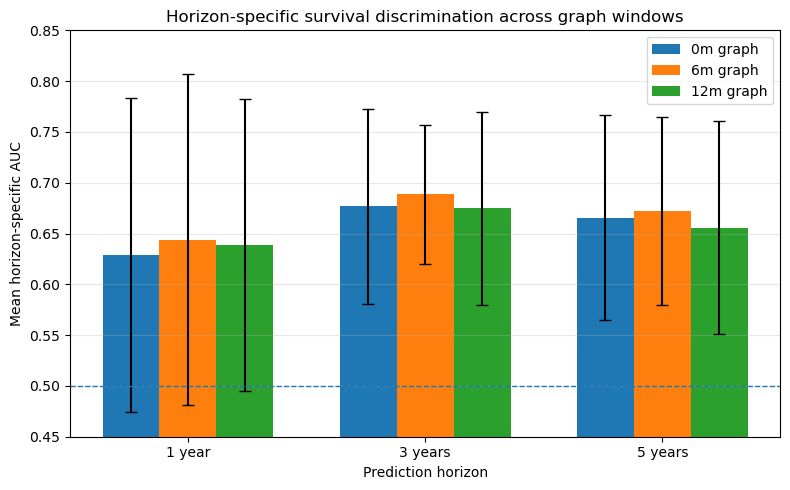


Saved horizon-specific AUC PNG:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/kaplan_meier_risk_group_analysis_0m_6m_12m/horizon_auc_summary_0m_6m_12m_20260629_185435.png


In [19]:
# ------------------------------------------------------------
# 12.11.8.2 Save horizon-specific AUC outputs and figures
# ------------------------------------------------------------

import os
from datetime import datetime

horizon_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Reconstruct output directory if needed.
if "km_output_dir" not in globals():
    km_artifact_dir = os.path.dirname(graph_paths_by_window["6m"])
    km_output_dir = os.path.join(
        km_artifact_dir,
        "kaplan_meier_risk_group_analysis_0m_6m_12m",
    )

os.makedirs(km_output_dir, exist_ok=True)

horizon_auc_seed_path = os.path.join(
    km_output_dir,
    f"horizon_auc_seed_level_0m_6m_12m_{horizon_timestamp}.csv",
)

horizon_auc_summary_path = os.path.join(
    km_output_dir,
    f"horizon_auc_summary_0m_6m_12m_{horizon_timestamp}.csv",
)

best_by_horizon_path = os.path.join(
    km_output_dir,
    f"horizon_auc_best_graph_by_horizon_{horizon_timestamp}.csv",
)

horizon_auc_seed_df.to_csv(horizon_auc_seed_path, index=False)
horizon_auc_summary_df.to_csv(horizon_auc_summary_path, index=False)
best_by_horizon_df.to_csv(best_by_horizon_path, index=False)

print("Saved horizon-specific AUC outputs:")
print("Seed-level horizon AUC:", horizon_auc_seed_path)
print("Horizon AUC summary:", horizon_auc_summary_path)
print("Best graph by horizon:", best_by_horizon_path)


# -----------------------------
# Plot horizon-specific AUC summary
# -----------------------------

horizon_auc_plot_path = os.path.join(
    km_output_dir,
    f"horizon_auc_summary_0m_6m_12m_{horizon_timestamp}.png",
)

plot_df = horizon_auc_summary_df.copy()

graph_window_order = ["0m", "6m", "12m"]
horizon_order = [1.0, 3.0, 5.0]

x = np.arange(len(horizon_order))
bar_width = 0.24

plt.figure(figsize=(8, 5))

for i, graph_window in enumerate(graph_window_order):
    window_df = (
        plot_df[plot_df["graph_window"] == graph_window]
        .set_index("horizon_years")
        .loc[horizon_order]
        .reset_index()
    )

    plt.bar(
        x + (i - 1) * bar_width,
        window_df["mean_auc"],
        width=bar_width,
        yerr=window_df["std_auc"],
        capsize=4,
        label=f"{graph_window} graph",
    )

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xticks(x, ["1 year", "3 years", "5 years"])
plt.ylabel("Mean horizon-specific AUC")
plt.xlabel("Prediction horizon")
plt.title("Horizon-specific survival discrimination across graph windows")
plt.ylim(0.45, 0.85)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(horizon_auc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved horizon-specific AUC PNG:")
print(horizon_auc_plot_path)

Copied AUC figure to:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/notebooks/km_figures_for_poster/horizon_auc_summary_0m_6m_12m_20260629_185435.png


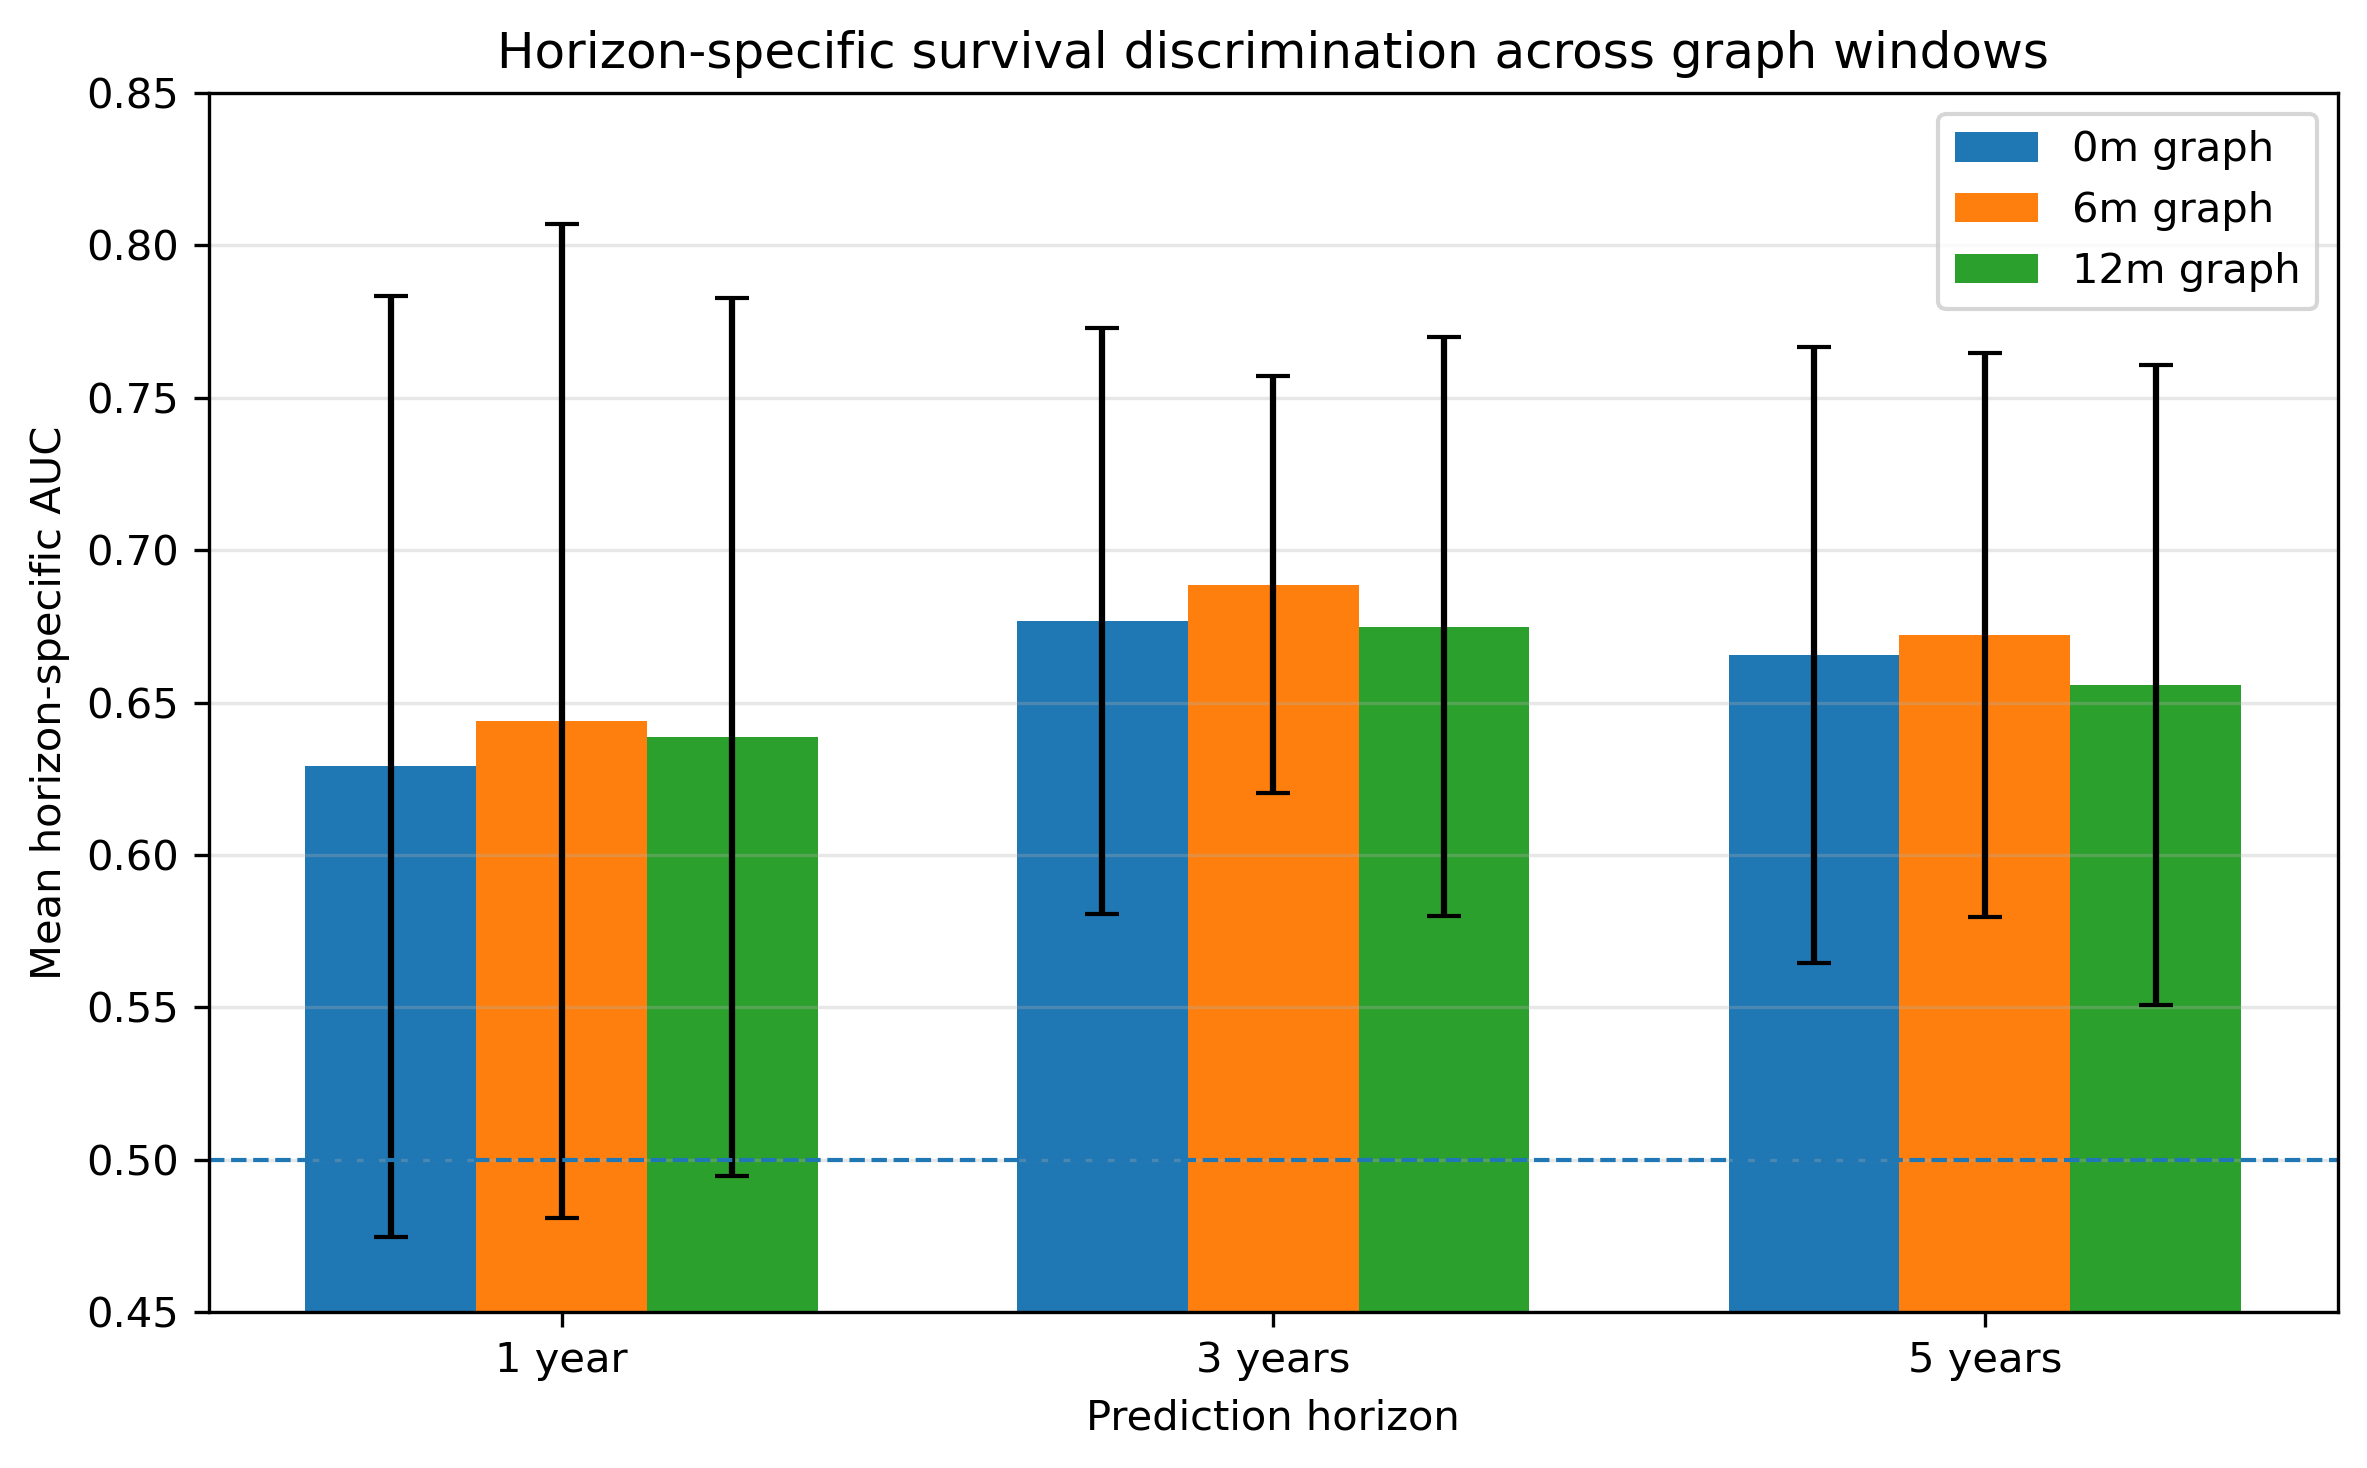

In [20]:
# Copy latest horizon AUC PNG to poster folder

import os
import glob
import shutil
from IPython.display import Image, display

auc_png_files = sorted(glob.glob(os.path.join(km_output_dir, "horizon_auc_summary_*.png")))

if len(auc_png_files) == 0:
    raise FileNotFoundError("No horizon AUC PNG files found.")

latest_auc_png_path = auc_png_files[-1]

poster_dir = os.path.join(os.getcwd(), "km_figures_for_poster")
os.makedirs(poster_dir, exist_ok=True)

copied_auc_png_path = os.path.join(
    poster_dir,
    os.path.basename(latest_auc_png_path),
)

shutil.copy2(latest_auc_png_path, copied_auc_png_path)

print("Copied AUC figure to:")
print(copied_auc_png_path)

display(Image(filename=copied_auc_png_path))

#### Interpretation of horizon-specific survival discrimination

The horizon-specific AUC analysis provides an additional evaluation of whether the graph-based risk scores discriminate survival outcomes at fixed clinically meaningful time points. Across the 1-year, 3-year, and 5-year horizons, the 6-month graph achieved the highest mean AUC among the three evaluated graph windows.

The strongest result was observed at the 3-year horizon, where the 6-month graph achieved the highest mean AUC and the lowest variability across seeds. This suggests that the 6-month cumulative graph may be most informative for medium-term survival-risk discrimination. The 1-year horizon was more unstable because each test split contained only a small number of deaths before one year. The 5-year horizon included more events, but also excluded more patients who were censored before the horizon, reducing the number of evaluable patients.

Overall, the horizon-specific AUC analysis supports the conclusions from the IPCW C-index and Kaplan-Meier analyses. The 6-month graph window consistently provides the strongest or most stable prognostic signal across multiple complementary evaluation strategies. These results suggest that incorporating clinical graph information accumulated during the first six months after lung cancer start improves survival-risk stratification compared with using only baseline information or extending the window to twelve months.

This analysis should be interpreted as a descriptive horizon-based evaluation rather than a fully censoring-adjusted time-dependent AUC, because patients censored before each horizon were excluded instead of being weighted by inverse probability of censoring. Nevertheless, it provides useful supporting evidence that the model's risk scores are meaningfully associated with survival outcomes at clinically relevant time horizons.

## Stratified 5-Fold Cross-Validation for Final GNN Evaluation

The previous multi-seed analyses were used as exploratory robustness checks. They helped identify the 6-month non-landmark graph as the most promising survival representation and showed that simple regularization changes did not substantially improve performance.

However, multi-seed train/validation/test splits are not equivalent to cross-validation. Across repeated random splits, the same patient may appear in the test set multiple times or not appear in the test set at all. Therefore, we now perform stratified 5-fold cross-validation as the final GNN evaluation protocol.

In this section, the model configuration is fixed to the selected K configuration:

- hidden_channels = 32
- dropout = 0.20
- weight_decay = 1e-5

No additional tuning is performed. For each graph window, we split the 379 lung cancer patients into five stratified folds while preserving the death/censoring ratio as much as possible. Each fold is used once as the held-out test fold. The remaining four folds are split internally into train and validation sets for early stopping. The held-out test fold is never used for checkpoint selection.

We evaluate each graph window using Harrell C-index and IPCW C-index, and we save out-of-fold predictions so that each patient has exactly one held-out prediction per graph window. These out-of-fold predictions are then used for cleaner Kaplan-Meier risk-group separation and horizon-specific AUC analysis.

In [13]:
# ------------------------------------------------------------
# Stratified 5-fold CV setup
# ------------------------------------------------------------

import os
import copy
import random
import time
import datetime

import torch
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Validate required objects from previous sections
# ------------------------------------------------------------

required_objects = [
    "survival_time_years_tensor",
    "event_death_tensor",
    "HeteroGraphSAGECox",
    "cox_partial_likelihood_loss",
    "evaluate_survival_model",
    "evaluate_model_harrell_and_ipcw",
    "graph_paths_by_window",
    "fs",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is missing. "
            "Run the previous survival model setup / IPCW utility cells first."
        )

print("Required objects are available.")


# ------------------------------------------------------------
# 2. Fixed final GNN configuration
# ------------------------------------------------------------
# Use K from Amit's regularization sensitivity section.
# No further hyperparameter tuning is performed here.

CV_SELECTED_CONFIG = {
    "config_name": "K_hidden32_dropout020_wd1e-5",
    "hidden_channels": 32,
    "dropout": 0.20,
    "weight_decay": 1e-5,
}

CV_BASE_CONFIG = {
    "model_name": "Final 5-fold CV HeteroGraphSAGE-Cox",
    "num_layers": 1,
    "learning_rate": 1e-3,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "inner_val_frac": 0.20,
    "device": "cpu",
    "monitor": "validation Harrell C-index",
    "selection_rule": "maximize validation Harrell C-index; break ties using lower validation loss",
    "n_outer_folds": 5,
    "fold_seed": 42,
}

CV_GRAPH_WINDOWS = ["0m", "6m", "12m"]

print("Final CV model configuration:")
display(pd.DataFrame([CV_SELECTED_CONFIG]))

print("CV base configuration:")
display(pd.DataFrame([CV_BASE_CONFIG]))


# ------------------------------------------------------------
# 3. Load graph windows if not already loaded
# ------------------------------------------------------------

cv_graphs_by_window = {}

if "km_graphs_by_window" in globals():
    print("Using graphs already loaded in km_graphs_by_window.")
    for window in CV_GRAPH_WINDOWS:
        cv_graphs_by_window[window] = km_graphs_by_window[window]
else:
    print("km_graphs_by_window not found. Loading graphs from graph_paths_by_window.")
    for window in CV_GRAPH_WINDOWS:
        graph_path = graph_paths_by_window[window]

        print("\nLoading graph:", window)
        print(graph_path)

        if not fs.exists(graph_path):
            raise FileNotFoundError(f"{window} graph not found: {graph_path}")

        with fs.open(graph_path, "rb") as f:
            graph_data = torch.load(
                f,
                map_location="cpu",
                weights_only=False,
            )

        cv_graphs_by_window[window] = graph_data

for window, graph_data in cv_graphs_by_window.items():
    assert graph_data["Person"].num_nodes == len(survival_time_years_tensor)
    assert graph_data["Person"].num_nodes == len(event_death_tensor)

    print(
        f"{window} graph ready | "
        f"Person nodes={graph_data['Person'].num_nodes}, "
        f"edge types={len(graph_data.edge_types)}"
    )


# ------------------------------------------------------------
# 4. Build stratified outer folds
# ------------------------------------------------------------

def make_stratified_kfold_indices(
    event_tensor,
    n_folds=5,
    seed=42,
):
    """
    Create stratified outer folds.

    Each patient appears in exactly one held-out test fold.
    Events and censored patients are distributed across folds separately.
    """

    rng = random.Random(seed)

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    event_folds = [[] for _ in range(n_folds)]
    censored_folds = [[] for _ in range(n_folds)]

    for pos, idx in enumerate(event_indices):
        event_folds[pos % n_folds].append(idx)

    for pos, idx in enumerate(censored_indices):
        censored_folds[pos % n_folds].append(idx)

    folds = []

    for fold_id in range(n_folds):
        fold_indices = sorted(event_folds[fold_id] + censored_folds[fold_id])
        folds.append(fold_indices)

    return folds


outer_cv_folds = make_stratified_kfold_indices(
    event_tensor=event_death_tensor,
    n_folds=CV_BASE_CONFIG["n_outer_folds"],
    seed=CV_BASE_CONFIG["fold_seed"],
)

fold_summary_rows = []

all_test_indices = []

for fold_id, test_indices in enumerate(outer_cv_folds, start=1):
    test_mask = torch.zeros(len(event_death_tensor), dtype=torch.bool)
    test_mask[torch.tensor(test_indices, dtype=torch.long)] = True

    fold_summary_rows.append({
        "outer_fold": fold_id,
        "test_n_patients": int(test_mask.sum().item()),
        "test_n_events": int(event_death_tensor[test_mask].sum().item()),
        "test_n_censored": int((event_death_tensor[test_mask] == 0).sum().item()),
        "test_event_rate": float(event_death_tensor[test_mask].float().mean().item()),
    })

    all_test_indices.extend(test_indices)

cv_fold_summary_df = pd.DataFrame(fold_summary_rows)

print("Outer CV fold summary:")
display(cv_fold_summary_df)

assert len(all_test_indices) == len(event_death_tensor)
assert len(set(all_test_indices)) == len(event_death_tensor)

print("Each patient appears in exactly one outer test fold.")

Required objects are available.
Final CV model configuration:


,config_name,hidden_channels,dropout,weight_decay
0,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001


CV base configuration:


,model_name,num_layers,learning_rate,max_epochs,patience,min_delta_c_index,inner_val_frac,device,monitor,selection_rule,n_outer_folds,fold_seed
0,Final 5-fold CV HeteroGraphSAGE-Cox,1,0.001,300,40,0.0001,0.2,cpu,validation Harrell C-index,maximize validation Harrell C-index; break tie...,5,42


km_graphs_by_window not found. Loading graphs from graph_paths_by_window.

Loading graph: 0m
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt

Loading graph: 6m
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt

Loading graph: 12m
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_12m.pt
0m graph ready | Person nodes=379, edge types=126
6m graph ready | Person nodes=379, edge types=126
12m graph ready | Person nodes=379, edge types=126
Outer CV fold summary:


,outer_fold,test_n_patients,test_n_events,test_n_censored,test_event_rate
0,1,76,12,64,0.157895
1,2,76,12,64,0.157895
2,3,76,12,64,0.157895
3,4,76,12,64,0.157895
4,5,75,12,63,0.160000


Each patient appears in exactly one outer test fold.


In [14]:
# ------------------------------------------------------------
# CV training utilities
# ------------------------------------------------------------

def make_inner_train_val_masks(
    train_val_indices,
    event_tensor,
    val_frac=0.20,
    seed=42,
):
    """
    Split the non-test patients into inner train and validation masks.

    The outer test fold is not used for checkpoint selection.
    """

    rng = random.Random(seed)

    train_val_indices = [int(x) for x in train_val_indices]

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        idx for idx in train_val_indices
        if int(event_values[idx]) == 1
    ]

    censored_indices = [
        idx for idx in train_val_indices
        if int(event_values[idx]) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_val(indices):
        n_val = int(round(len(indices) * val_frac))
        val_part = indices[:n_val]
        train_part = indices[n_val:]
        return train_part, val_part

    event_train, event_val = split_val(event_indices)
    cens_train, cens_val = split_val(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)

    n_nodes = int(event_tensor.numel())

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask[torch.tensor(val_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask & val_mask)

    split_summary = {
        "inner_train_n_patients": int(train_mask.sum().item()),
        "inner_val_n_patients": int(val_mask.sum().item()),
        "inner_train_n_events": int(event_tensor[train_mask].sum().item()),
        "inner_val_n_events": int(event_tensor[val_mask].sum().item()),
        "inner_train_event_rate": float(event_tensor[train_mask].float().mean().item()),
        "inner_val_event_rate": float(event_tensor[val_mask].float().mean().item()),
    }

    return train_mask, val_mask, split_summary


def train_one_cv_fold_graph_window(
    graph_data,
    graph_window,
    outer_fold,
    test_indices,
    config,
):
    """
    Train one graph-window model for one outer CV fold.

    Outer test fold is held out completely.
    Inner validation split is used for early stopping.
    """

    fold_seed = CV_BASE_CONFIG["fold_seed"] + outer_fold * 100

    random.seed(fold_seed)
    torch.manual_seed(fold_seed)

    device = torch.device(CV_BASE_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    n_nodes = int(event_indicators.numel())

    test_mask_cpu = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask_cpu[torch.tensor(test_indices, dtype=torch.long)] = True

    train_val_indices = [
        int(i)
        for i in range(n_nodes)
        if not bool(test_mask_cpu[i].item())
    ]

    train_mask_cpu, val_mask_cpu, inner_split_summary = make_inner_train_val_masks(
        train_val_indices=train_val_indices,
        event_tensor=event_death_tensor,
        val_frac=CV_BASE_CONFIG["inner_val_frac"],
        seed=fold_seed,
    )

    assert not torch.any(train_mask_cpu & val_mask_cpu)
    assert not torch.any(train_mask_cpu & test_mask_cpu)
    assert not torch.any(val_mask_cpu & test_mask_cpu)
    assert int((train_mask_cpu | val_mask_cpu | test_mask_cpu).sum().item()) == n_nodes

    train_mask = train_mask_cpu.to(device)
    val_mask = val_mask_cpu.to(device)
    test_mask = test_mask_cpu.to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=config["hidden_channels"],
        num_layers=CV_BASE_CONFIG["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    # Initialize lazy PyG layers.
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CV_BASE_CONFIG["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, CV_BASE_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + CV_BASE_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= CV_BASE_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CV_BASE_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for graph={graph_window}, fold={outer_fold}."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    # Collect out-of-fold predictions for the outer test fold.
    model.eval()
    with torch.no_grad():
        final_risk_scores, _ = model(graph_data)

    test_idx = torch.where(test_mask)[0]

    oof_predictions_df = pd.DataFrame({
        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "person_node_index": test_idx.detach().cpu().view(-1).tolist(),
        "survival_time_years": survival_times[test_idx].detach().cpu().view(-1).tolist(),
        "event_death": event_indicators[test_idx].detach().cpu().view(-1).tolist(),
        "risk_score": final_risk_scores[test_idx].detach().cpu().view(-1).tolist(),
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_epoch),
    })

    result_row = {
        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_epoch),
        "best_val_harrell_c_index": best_val_harrell_c_index,
        "best_val_loss": best_val_loss,

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        **inner_split_summary,

        "elapsed_seconds": elapsed_seconds,
    }

    return result_row, oof_predictions_df


print("5-fold CV training utilities are ready.")

5-fold CV training utilities are ready.


In [15]:
# ------------------------------------------------------------
# Run stratified 5-fold CV across graph windows
# ------------------------------------------------------------

cv_result_rows = []
cv_oof_prediction_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    graph_data = cv_graphs_by_window[graph_window]

    for fold_position, test_indices in enumerate(outer_cv_folds, start=1):
        print("\n" + "=" * 100)
        print(
            f"5-fold CV | graph={graph_window} | "
            f"outer fold={fold_position}/{CV_BASE_CONFIG['n_outer_folds']} | "
            f"config={CV_SELECTED_CONFIG['config_name']}"
        )
        print("=" * 100)

        result_row, oof_predictions_df = train_one_cv_fold_graph_window(
            graph_data=graph_data,
            graph_window=graph_window,
            outer_fold=fold_position,
            test_indices=test_indices,
            config=CV_SELECTED_CONFIG,
        )

        cv_result_rows.append(result_row)
        cv_oof_prediction_frames.append(oof_predictions_df)

        print(
            f"Finished graph={graph_window}, fold={fold_position} | "
            f"best epoch={result_row['best_epoch']} | "
            f"test Harrell={result_row['test_harrell_c_index']:.4f} | "
            f"test IPCW={result_row['test_ipcw_c_index']:.4f} | "
            f"test events={result_row['test_n_events']} | "
            f"elapsed={result_row['elapsed_seconds']:.1f}s"
        )

cv_results_df = pd.DataFrame(cv_result_rows)

cv_oof_predictions_df = pd.concat(
    cv_oof_prediction_frames,
    ignore_index=True,
)

cv_results_df = (
    cv_results_df
    .sort_values(["graph_window", "outer_fold"])
    .reset_index(drop=True)
)

cv_oof_predictions_df = (
    cv_oof_predictions_df
    .sort_values(["graph_window", "outer_fold", "person_node_index"])
    .reset_index(drop=True)
)

print("\n5-fold CV per-fold results:")
display(cv_results_df)

print("\nOut-of-fold predictions:")
display(cv_oof_predictions_df.head())

# Sanity check: each patient appears exactly once per graph window.
oof_count_check_df = (
    cv_oof_predictions_df
    .groupby(["graph_window", "person_node_index"])
    .size()
    .reset_index(name="n_oof_predictions")
)

assert int((oof_count_check_df["n_oof_predictions"] != 1).sum()) == 0

print("\nOOF sanity check passed: each patient has exactly one OOF prediction per graph window.")


5-fold CV | graph=0m | outer fold=1/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=1 | best epoch=4 | test Harrell=0.7696 | test IPCW=0.7160 | test events=12 | elapsed=11.4s

5-fold CV | graph=0m | outer fold=2/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=2 | best epoch=1 | test Harrell=0.5461 | test IPCW=0.4908 | test events=12 | elapsed=10.4s

5-fold CV | graph=0m | outer fold=3/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=3 | best epoch=89 | test Harrell=0.7593 | test IPCW=0.7231 | test events=12 | elapsed=33.2s

5-fold CV | graph=0m | outer fold=4/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=4 | best epoch=113 | test Harrell=0.5694 | test IPCW=0.7317 | test events=12 | elapsed=40.4s

5-fold CV | graph=0m | outer fold=5/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=5 | best epoch=26 | test Harrell=0.6802 | test IPCW=0.5272 | test events=12 | elapsed=17.5s

5-fold CV | graph=6m | outer fold=1

,graph_window,outer_fold,config_name,hidden_channels,dropout,weight_decay,best_epoch,best_val_harrell_c_index,best_val_loss,train_harrell_c_index,...,test_ipcw_unweighted_pairs,test_ipcw_weighted_pairs,test_ipcw_tau,inner_train_n_patients,inner_val_n_patients,inner_train_n_events,inner_val_n_events,inner_train_event_rate,inner_val_event_rate,elapsed_seconds
0,0m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,0.733333,3.277769,0.603567,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,11.398730
1,0m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,1,0.699758,4.427585,0.626422,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,10.444123
2,0m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,89,0.644231,3.508994,0.718165,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,33.230446
3,0m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,113,0.730539,3.326302,0.688761,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,40.448085
4,0m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,26,0.551084,4.251885,0.626120,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,17.517209
5,12m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,3,0.698551,3.331842,0.607821,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,11.495120
6,12m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,3,0.711864,4.908633,0.632438,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,10.979105
7,12m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,74,0.646635,3.500779,0.703901,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,28.813059
8,12m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,191,0.775449,3.327851,0.692043,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,59.404078
9,12m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,31,0.563467,4.086621,0.663838,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,17.868316



Out-of-fold predictions:


,graph_window,outer_fold,person_node_index,survival_time_years,event_death,risk_score,config_name,hidden_channels,dropout,weight_decay,best_epoch
0,0m,1,2,10.392881,0.0,-20.038961,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4
1,0m,1,4,3.285421,0.0,-20.860703,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4
2,0m,1,5,1.174538,0.0,-20.829823,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4
3,0m,1,6,7.290896,0.0,-20.867714,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4
4,0m,1,14,5.796030,0.0,-20.820183,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4



OOF sanity check passed: each patient has exactly one OOF prediction per graph window.


In [16]:
# ------------------------------------------------------------
# Summarize and save 5-fold CV results
# ------------------------------------------------------------

cv_summary_df = (
    cv_results_df
    .groupby("graph_window", as_index=False)
    .agg(
        n_folds=("outer_fold", "count"),

        mean_test_harrell_c_index=("test_harrell_c_index", "mean"),
        std_test_harrell_c_index=("test_harrell_c_index", "std"),
        min_test_harrell_c_index=("test_harrell_c_index", "min"),
        max_test_harrell_c_index=("test_harrell_c_index", "max"),

        mean_test_ipcw_c_index=("test_ipcw_c_index", "mean"),
        std_test_ipcw_c_index=("test_ipcw_c_index", "std"),
        min_test_ipcw_c_index=("test_ipcw_c_index", "min"),
        max_test_ipcw_c_index=("test_ipcw_c_index", "max"),

        mean_val_harrell_c_index=("val_harrell_c_index", "mean"),
        mean_val_ipcw_c_index=("val_ipcw_c_index", "mean"),

        mean_best_epoch=("best_epoch", "mean"),
        mean_test_n_patients=("test_n_patients", "mean"),
        mean_test_n_events=("test_n_events", "mean"),
        mean_test_harrell_pairs=("test_harrell_pairs", "mean"),
        mean_test_ipcw_weighted_pairs=("test_ipcw_weighted_pairs", "mean"),
    )
)

cv_summary_df["mean_test_ipcw_minus_harrell"] = (
    cv_summary_df["mean_test_ipcw_c_index"]
    - cv_summary_df["mean_test_harrell_c_index"]
)

print("5-fold CV summary by graph window:")
display(cv_summary_df)


cv_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

cv_artifact_dir = os.path.dirname(graph_paths_by_window["6m"])

cv_output_dir = os.path.join(
    cv_artifact_dir,
    "final_5fold_cv_gnn_survival_0m_6m_12m",
)

os.makedirs(cv_output_dir, exist_ok=True)

cv_results_path = os.path.join(
    cv_output_dir,
    f"cv_fold_results_0m_6m_12m_{cv_timestamp}.csv",
)

cv_summary_path = os.path.join(
    cv_output_dir,
    f"cv_summary_0m_6m_12m_{cv_timestamp}.csv",
)

cv_oof_predictions_path = os.path.join(
    cv_output_dir,
    f"cv_out_of_fold_predictions_0m_6m_12m_{cv_timestamp}.csv",
)

cv_fold_summary_path = os.path.join(
    cv_output_dir,
    f"cv_outer_fold_summary_{cv_timestamp}.csv",
)

cv_results_df.to_csv(cv_results_path, index=False)
cv_summary_df.to_csv(cv_summary_path, index=False)
cv_oof_predictions_df.to_csv(cv_oof_predictions_path, index=False)
cv_fold_summary_df.to_csv(cv_fold_summary_path, index=False)

print("\nSaved 5-fold CV outputs:")
print("Per-fold results:", cv_results_path)
print("CV summary:", cv_summary_path)
print("OOF predictions:", cv_oof_predictions_path)
print("Outer fold summary:", cv_fold_summary_path)

5-fold CV summary by graph window:


,graph_window,n_folds,mean_test_harrell_c_index,std_test_harrell_c_index,min_test_harrell_c_index,max_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,min_test_ipcw_c_index,max_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_best_epoch,mean_test_n_patients,mean_test_n_events,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_minus_harrell
0,0m,5,0.664920,0.104096,0.546125,0.769608,0.637751,0.118384,0.490788,0.731692,0.671789,0.632433,46.6,75.8,12.0,586.8,1465.204038,-0.027169
1,12m,5,0.659847,0.105914,0.527675,0.767974,0.624722,0.110077,0.482787,0.717441,0.679193,0.583287,60.4,75.8,12.0,586.8,1465.204038,-0.035125
2,6m,5,0.653207,0.110572,0.525830,0.767974,0.624028,0.112455,0.481624,0.717441,0.667583,0.566350,44.4,75.8,12.0,586.8,1465.204038,-0.029178



Saved 5-fold CV outputs:
Per-fold results: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/cv_fold_results_0m_6m_12m_20260701_115311.csv
CV summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/cv_summary_0m_6m_12m_20260701_115311.csv
OOF predictions: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/cv_out_of_fold_predictions_0m_6m_12m_20260701_115311.csv
Outer fold summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/f

### Early-Stopping Stabilization Check

The initial stratified 5-fold CV evaluation used the same early-stopping protocol as the previous exploratory experiments: the best checkpoint was selected according to validation Harrell C-index, with ties resolved by lower validation loss.

After reviewing the fold-level results, we observed that several models selected very early checkpoints, sometimes after only 1–4 epochs. This is likely related to the small size of the internal validation split, which contains only about 10 observed death events. With so few validation events, the validation C-index can be noisy, and checkpoint selection may occur before the model has meaningfully trained.

To evaluate whether this early stopping behavior affected model performance, we perform a secondary training-stability check. In this analysis, all model settings remain fixed:

- same 0m, 6m, and 12m graph windows
- same stratified 5-fold outer folds
- same inner train/validation split logic
- same selected K configuration
- same Cox loss
- same optimizer
- same validation Harrell C-index checkpoint criterion

The only change is that checkpoint selection is not allowed before epoch 20. This does not introduce additional feature engineering or model-capacity tuning; it is intended to test whether preventing extremely early checkpoint selection improves or stabilizes cross-validation performance.

We first preserve the original 5-fold CV outputs as the baseline protocol, then rerun the same CV experiment using the minimum-checkpoint-epoch protocol and compare the results.

In [17]:
# ------------------------------------------------------------
# Save current 5-fold CV results as baseline protocol
# ------------------------------------------------------------

baseline_cv_results_df = cv_results_df.copy()
baseline_cv_summary_df = cv_summary_df.copy()
baseline_cv_oof_predictions_df = cv_oof_predictions_df.copy()

print("Saved current CV outputs as baseline:")
print("baseline_cv_results_df:", baseline_cv_results_df.shape)
print("baseline_cv_summary_df:", baseline_cv_summary_df.shape)
print("baseline_cv_oof_predictions_df:", baseline_cv_oof_predictions_df.shape)

display(baseline_cv_summary_df)

Saved current CV outputs as baseline:
baseline_cv_results_df: (15, 35)
baseline_cv_summary_df: (3, 18)
baseline_cv_oof_predictions_df: (1137, 11)


,graph_window,n_folds,mean_test_harrell_c_index,std_test_harrell_c_index,min_test_harrell_c_index,max_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,min_test_ipcw_c_index,max_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_best_epoch,mean_test_n_patients,mean_test_n_events,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_minus_harrell
0,0m,5,0.664920,0.104096,0.546125,0.769608,0.637751,0.118384,0.490788,0.731692,0.671789,0.632433,46.6,75.8,12.0,586.8,1465.204038,-0.027169
1,12m,5,0.659847,0.105914,0.527675,0.767974,0.624722,0.110077,0.482787,0.717441,0.679193,0.583287,60.4,75.8,12.0,586.8,1465.204038,-0.035125
2,6m,5,0.653207,0.110572,0.525830,0.767974,0.624028,0.112455,0.481624,0.717441,0.667583,0.566350,44.4,75.8,12.0,586.8,1465.204038,-0.029178


In [18]:
# ------------------------------------------------------------
# Early-stopping stabilization protocol
# ------------------------------------------------------------

CV_MIN_EPOCH_PROTOCOL = {
    **CV_BASE_CONFIG,
    "min_checkpoint_epoch": 20,
    "protocol_name": "min_checkpoint_epoch_20",
}

print("Early-stopping stabilization protocol:")
display(pd.DataFrame([CV_MIN_EPOCH_PROTOCOL]))

Early-stopping stabilization protocol:


,model_name,num_layers,learning_rate,max_epochs,patience,min_delta_c_index,inner_val_frac,device,monitor,selection_rule,n_outer_folds,fold_seed,min_checkpoint_epoch,protocol_name
0,Final 5-fold CV HeteroGraphSAGE-Cox,1,0.001,300,40,0.0001,0.2,cpu,validation Harrell C-index,maximize validation Harrell C-index; break tie...,5,42,20,min_checkpoint_epoch_20


In [19]:
# ------------------------------------------------------------
# CV training utility with minimum checkpoint epoch
# ------------------------------------------------------------

def train_one_cv_fold_graph_window_min_epoch(
    graph_data,
    graph_window,
    outer_fold,
    test_indices,
    config,
    cv_protocol,
):
    """
    Train one graph-window model for one outer CV fold.

    Difference from the original CV training:
    best checkpoint selection is not allowed before min_checkpoint_epoch.
    """

    fold_seed = cv_protocol["fold_seed"] + outer_fold * 100

    random.seed(fold_seed)
    torch.manual_seed(fold_seed)

    device = torch.device(cv_protocol["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    n_nodes = int(event_indicators.numel())

    test_mask_cpu = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask_cpu[torch.tensor(test_indices, dtype=torch.long)] = True

    train_val_indices = [
        int(i)
        for i in range(n_nodes)
        if not bool(test_mask_cpu[i].item())
    ]

    train_mask_cpu, val_mask_cpu, inner_split_summary = make_inner_train_val_masks(
        train_val_indices=train_val_indices,
        event_tensor=event_death_tensor,
        val_frac=cv_protocol["inner_val_frac"],
        seed=fold_seed,
    )

    assert not torch.any(train_mask_cpu & val_mask_cpu)
    assert not torch.any(train_mask_cpu & test_mask_cpu)
    assert not torch.any(val_mask_cpu & test_mask_cpu)
    assert int((train_mask_cpu | val_mask_cpu | test_mask_cpu).sum().item()) == n_nodes

    train_mask = train_mask_cpu.to(device)
    val_mask = val_mask_cpu.to(device)
    test_mask = test_mask_cpu.to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=config["hidden_channels"],
        num_layers=cv_protocol["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    # Initialize lazy PyG layers.
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cv_protocol["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    min_checkpoint_epoch = int(cv_protocol.get("min_checkpoint_epoch", 1))

    start_time = time.time()

    for epoch in range(1, cv_protocol["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        # Do not allow checkpoint selection before min_checkpoint_epoch.
        if epoch < min_checkpoint_epoch:
            epochs_without_improvement = 0
            continue

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + cv_protocol["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= cv_protocol["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= cv_protocol["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for graph={graph_window}, fold={outer_fold}. "
            f"Check min_checkpoint_epoch={min_checkpoint_epoch}."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    model.eval()
    with torch.no_grad():
        final_risk_scores, _ = model(graph_data)

    test_idx = torch.where(test_mask)[0]

    oof_predictions_df = pd.DataFrame({
        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "person_node_index": test_idx.detach().cpu().view(-1).tolist(),
        "survival_time_years": survival_times[test_idx].detach().cpu().view(-1).tolist(),
        "event_death": event_indicators[test_idx].detach().cpu().view(-1).tolist(),
        "risk_score": final_risk_scores[test_idx].detach().cpu().view(-1).tolist(),
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_epoch),
        "cv_protocol": cv_protocol["protocol_name"],
        "min_checkpoint_epoch": min_checkpoint_epoch,
    })

    result_row = {
        "cv_protocol": cv_protocol["protocol_name"],
        "min_checkpoint_epoch": min_checkpoint_epoch,

        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],

        "best_epoch": int(best_epoch),
        "best_val_harrell_c_index": best_val_harrell_c_index,
        "best_val_loss": best_val_loss,

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        **inner_split_summary,

        "elapsed_seconds": elapsed_seconds,
    }

    return result_row, oof_predictions_df


print("Minimum-epoch CV training utility is ready.")

Minimum-epoch CV training utility is ready.


In [20]:
# ------------------------------------------------------------
# Run 5-fold CV with minimum checkpoint epoch = 20
# ------------------------------------------------------------

min_epoch_cv_result_rows = []
min_epoch_cv_oof_prediction_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    graph_data = cv_graphs_by_window[graph_window]

    for fold_position, test_indices in enumerate(outer_cv_folds, start=1):
        print("\n" + "=" * 100)
        print(
            f"MIN-EPOCH CV | graph={graph_window} | "
            f"outer fold={fold_position}/{CV_MIN_EPOCH_PROTOCOL['n_outer_folds']} | "
            f"min checkpoint epoch={CV_MIN_EPOCH_PROTOCOL['min_checkpoint_epoch']} | "
            f"config={CV_SELECTED_CONFIG['config_name']}"
        )
        print("=" * 100)

        result_row, oof_predictions_df = train_one_cv_fold_graph_window_min_epoch(
            graph_data=graph_data,
            graph_window=graph_window,
            outer_fold=fold_position,
            test_indices=test_indices,
            config=CV_SELECTED_CONFIG,
            cv_protocol=CV_MIN_EPOCH_PROTOCOL,
        )

        min_epoch_cv_result_rows.append(result_row)
        min_epoch_cv_oof_prediction_frames.append(oof_predictions_df)

        print(
            f"Finished graph={graph_window}, fold={fold_position} | "
            f"best epoch={result_row['best_epoch']} | "
            f"test Harrell={result_row['test_harrell_c_index']:.4f} | "
            f"test IPCW={result_row['test_ipcw_c_index']:.4f} | "
            f"test events={result_row['test_n_events']} | "
            f"elapsed={result_row['elapsed_seconds']:.1f}s"
        )

min_epoch_cv_results_df = pd.DataFrame(min_epoch_cv_result_rows)

min_epoch_cv_oof_predictions_df = pd.concat(
    min_epoch_cv_oof_prediction_frames,
    ignore_index=True,
)

min_epoch_cv_results_df = (
    min_epoch_cv_results_df
    .sort_values(["graph_window", "outer_fold"])
    .reset_index(drop=True)
)

min_epoch_cv_oof_predictions_df = (
    min_epoch_cv_oof_predictions_df
    .sort_values(["graph_window", "outer_fold", "person_node_index"])
    .reset_index(drop=True)
)

print("\nMin-epoch 5-fold CV per-fold results:")
display(min_epoch_cv_results_df)

# Sanity check: each patient appears exactly once per graph window.
min_epoch_oof_count_check_df = (
    min_epoch_cv_oof_predictions_df
    .groupby(["graph_window", "person_node_index"])
    .size()
    .reset_index(name="n_oof_predictions")
)

assert int((min_epoch_oof_count_check_df["n_oof_predictions"] != 1).sum()) == 0

print("\nOOF sanity check passed: each patient has exactly one OOF prediction per graph window.")


MIN-EPOCH CV | graph=0m | outer fold=1/5 | min checkpoint epoch=20 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=1 | best epoch=20 | test Harrell=0.7010 | test IPCW=0.4170 | test events=12 | elapsed=14.3s

MIN-EPOCH CV | graph=0m | outer fold=2/5 | min checkpoint epoch=20 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=2 | best epoch=28 | test Harrell=0.4631 | test IPCW=0.4872 | test events=12 | elapsed=17.3s

MIN-EPOCH CV | graph=0m | outer fold=3/5 | min checkpoint epoch=20 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=3 | best epoch=89 | test Harrell=0.7593 | test IPCW=0.7231 | test events=12 | elapsed=32.7s

MIN-EPOCH CV | graph=0m | outer fold=4/5 | min checkpoint epoch=20 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=4 | best epoch=113 | test Harrell=0.5694 | test IPCW=0.7317 | test events=12 | elapsed=38.3s

MIN-EPOCH CV | graph=0m | outer fold=5/5 | min checkpoint epoch=20 | config=K_hidden32_dropout020_wd1e-5
Finis

,cv_protocol,min_checkpoint_epoch,graph_window,outer_fold,config_name,hidden_channels,dropout,weight_decay,best_epoch,best_val_harrell_c_index,...,test_ipcw_unweighted_pairs,test_ipcw_weighted_pairs,test_ipcw_tau,inner_train_n_patients,inner_val_n_patients,inner_train_n_events,inner_val_n_events,inner_train_event_rate,inner_val_event_rate,elapsed_seconds
0,min_checkpoint_epoch_20,20,0m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,20,0.484058,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,14.287611
1,min_checkpoint_epoch_20,20,0m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,28,0.622276,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,17.336250
2,min_checkpoint_epoch_20,20,0m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,89,0.644231,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,32.706599
3,min_checkpoint_epoch_20,20,0m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,113,0.730539,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,38.310827
4,min_checkpoint_epoch_20,20,0m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,26,0.551084,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,17.075338
5,min_checkpoint_epoch_20,20,12m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,21,0.617391,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,14.330222
6,min_checkpoint_epoch_20,20,12m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,28,0.634383,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,17.400494
7,min_checkpoint_epoch_20,20,12m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,74,0.646635,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,28.940057
8,min_checkpoint_epoch_20,20,12m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,191,0.775449,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,58.408159
9,min_checkpoint_epoch_20,20,12m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,31,0.563467,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,17.912811



OOF sanity check passed: each patient has exactly one OOF prediction per graph window.


In [21]:
# ------------------------------------------------------------
# Compare original CV vs min-checkpoint-epoch CV
# ------------------------------------------------------------

min_epoch_cv_summary_df = (
    min_epoch_cv_results_df
    .groupby("graph_window", as_index=False)
    .agg(
        n_folds=("outer_fold", "count"),

        mean_test_harrell_c_index=("test_harrell_c_index", "mean"),
        std_test_harrell_c_index=("test_harrell_c_index", "std"),
        min_test_harrell_c_index=("test_harrell_c_index", "min"),
        max_test_harrell_c_index=("test_harrell_c_index", "max"),

        mean_test_ipcw_c_index=("test_ipcw_c_index", "mean"),
        std_test_ipcw_c_index=("test_ipcw_c_index", "std"),
        min_test_ipcw_c_index=("test_ipcw_c_index", "min"),
        max_test_ipcw_c_index=("test_ipcw_c_index", "max"),

        mean_val_harrell_c_index=("val_harrell_c_index", "mean"),
        mean_val_ipcw_c_index=("val_ipcw_c_index", "mean"),

        mean_best_epoch=("best_epoch", "mean"),
        mean_test_n_patients=("test_n_patients", "mean"),
        mean_test_n_events=("test_n_events", "mean"),
    )
)

baseline_for_compare_df = baseline_cv_summary_df.copy()
baseline_for_compare_df["cv_protocol"] = "original_early_stopping"

min_epoch_for_compare_df = min_epoch_cv_summary_df.copy()
min_epoch_for_compare_df["cv_protocol"] = "min_checkpoint_epoch_20"

protocol_compare_df = pd.concat(
    [
        baseline_for_compare_df,
        min_epoch_for_compare_df,
    ],
    ignore_index=True,
)

protocol_compare_df = protocol_compare_df[
    [
        "cv_protocol",
        "graph_window",
        "n_folds",
        "mean_test_harrell_c_index",
        "std_test_harrell_c_index",
        "mean_test_ipcw_c_index",
        "std_test_ipcw_c_index",
        "mean_val_harrell_c_index",
        "mean_val_ipcw_c_index",
        "mean_best_epoch",
        "mean_test_n_patients",
        "mean_test_n_events",
    ]
].sort_values(["graph_window", "cv_protocol"])

print("Original vs min-checkpoint-epoch CV comparison:")
display(protocol_compare_df)

# Difference table: min_epoch - original
baseline_indexed = baseline_for_compare_df.set_index("graph_window")
min_epoch_indexed = min_epoch_for_compare_df.set_index("graph_window")

diff_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    diff_rows.append({
        "graph_window": graph_window,
        "delta_mean_test_harrell": (
            min_epoch_indexed.loc[graph_window, "mean_test_harrell_c_index"]
            - baseline_indexed.loc[graph_window, "mean_test_harrell_c_index"]
        ),
        "delta_mean_test_ipcw": (
            min_epoch_indexed.loc[graph_window, "mean_test_ipcw_c_index"]
            - baseline_indexed.loc[graph_window, "mean_test_ipcw_c_index"]
        ),
        "delta_std_test_harrell": (
            min_epoch_indexed.loc[graph_window, "std_test_harrell_c_index"]
            - baseline_indexed.loc[graph_window, "std_test_harrell_c_index"]
        ),
        "delta_std_test_ipcw": (
            min_epoch_indexed.loc[graph_window, "std_test_ipcw_c_index"]
            - baseline_indexed.loc[graph_window, "std_test_ipcw_c_index"]
        ),
        "delta_mean_best_epoch": (
            min_epoch_indexed.loc[graph_window, "mean_best_epoch"]
            - baseline_indexed.loc[graph_window, "mean_best_epoch"]
        ),
    })

protocol_diff_df = pd.DataFrame(diff_rows)

print("Effect of min-checkpoint-epoch protocol:")
display(protocol_diff_df)

Original vs min-checkpoint-epoch CV comparison:


,cv_protocol,graph_window,n_folds,mean_test_harrell_c_index,std_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_best_epoch,mean_test_n_patients,mean_test_n_events
3,min_checkpoint_epoch_20,0m,5,0.634589,0.118009,0.577232,0.142679,0.606437,0.518226,55.2,75.8,12.0
0,original_early_stopping,0m,5,0.664920,0.104096,0.637751,0.118384,0.671789,0.632433,46.6,75.8,12.0
4,min_checkpoint_epoch_20,12m,5,0.649462,0.133077,0.571153,0.119961,0.647465,0.526389,69.0,75.8,12.0
1,original_early_stopping,12m,5,0.659847,0.105914,0.624722,0.110077,0.679193,0.583287,60.4,75.8,12.0
5,min_checkpoint_epoch_20,6m,5,0.645236,0.136269,0.573266,0.118338,0.639429,0.511004,52.8,75.8,12.0
2,original_early_stopping,6m,5,0.653207,0.110572,0.624028,0.112455,0.667583,0.566350,44.4,75.8,12.0


Effect of min-checkpoint-epoch protocol:


,graph_window,delta_mean_test_harrell,delta_mean_test_ipcw,delta_std_test_harrell,delta_std_test_ipcw,delta_mean_best_epoch
0,0m,-0.030331,-0.060519,0.013913,0.024295,8.6
1,6m,-0.007971,-0.050762,0.025697,0.005883,8.4
2,12m,-0.010385,-0.053569,0.027163,0.009884,8.6


In [22]:
# ------------------------------------------------------------
# Select final CV protocol for downstream OOF analyses
# ------------------------------------------------------------

final_cv_protocol_name = "original_early_stopping"

final_cv_results_df = baseline_cv_results_df.copy()
final_cv_summary_df = baseline_cv_summary_df.copy()
final_cv_oof_predictions_df = baseline_cv_oof_predictions_df.copy()

print("Selected final CV protocol:", final_cv_protocol_name)

print("\nFinal CV summary used for downstream OOF KM and horizon AUC:")
display(final_cv_summary_df)

Selected final CV protocol: original_early_stopping

Final CV summary used for downstream OOF KM and horizon AUC:


,graph_window,n_folds,mean_test_harrell_c_index,std_test_harrell_c_index,min_test_harrell_c_index,max_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,min_test_ipcw_c_index,max_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_best_epoch,mean_test_n_patients,mean_test_n_events,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_minus_harrell
0,0m,5,0.664920,0.104096,0.546125,0.769608,0.637751,0.118384,0.490788,0.731692,0.671789,0.632433,46.6,75.8,12.0,586.8,1465.204038,-0.027169
1,12m,5,0.659847,0.105914,0.527675,0.767974,0.624722,0.110077,0.482787,0.717441,0.679193,0.583287,60.4,75.8,12.0,586.8,1465.204038,-0.035125
2,6m,5,0.653207,0.110572,0.525830,0.767974,0.624028,0.112455,0.481624,0.717441,0.667583,0.566350,44.4,75.8,12.0,586.8,1465.204038,-0.029178


##### Early-stopping stabilization check summary

Several folds in the initial 5-fold CV selected very early best checkpoints, sometimes within the first few epochs. We therefore evaluated a secondary training-stability protocol in which checkpoint selection was not allowed before epoch 20, while keeping all other model settings fixed.

This modification did not improve performance. Across all graph windows, the minimum-checkpoint-epoch protocol reduced mean IPCW C-index and did not reduce fold-to-fold variability. The original early-stopping protocol achieved higher IPCW performance for the 0m, 6m, and 12m graph windows.

These results suggest that the early selected checkpoints were not simply caused by premature stopping. Rather, checkpoint selection remains sensitive because each internal validation split contains only about 10 observed death events. Therefore, we retain the original validation-based early-stopping protocol for the main 5-fold CV evaluation and use the minimum-checkpoint-epoch experiment only as a secondary sensitivity check.

### Complementary Out-of-Fold Survival Evaluation

After completing the stratified 5-fold CV evaluation, we use the saved out-of-fold predictions to perform three complementary survival analyses. These analyses are intended to make the model results more interpretable and to evaluate whether the predicted risk scores correspond to meaningful survival patterns beyond aggregate C-index values.

This analysis uses the final selected CV protocol, which retained the original validation-based early-stopping strategy. The minimum-checkpoint-epoch sensitivity check was not used for the main downstream evaluation because it reduced IPCW performance across all graph windows.

A key advantage of this out-of-fold setup is that each patient contributes exactly one held-out prediction per graph window. This makes the following analyses cleaner than the earlier multi-seed exploratory analyses, where the same patient could appear in the test set multiple times across different random splits.

We evaluate the out-of-fold predictions using three complementary approaches:

1. **Kaplan-Meier risk-group separation**  
   For each graph window, patients are split into predicted low-risk and high-risk groups according to the median out-of-fold risk score. We then compare the Kaplan-Meier survival curves of the two groups. This asks whether patients assigned higher predicted risk show worse observed survival.

2. **Extreme-risk sensitivity analysis**  
   For each graph window, patients are ranked by out-of-fold risk score, and only the bottom third and top third are compared. The middle third is excluded. This tests whether the model is especially informative for the patients it ranks as lowest-risk and highest-risk.

3. **Horizon-specific AUC**  
   For each graph window, we evaluate discrimination at fixed survival horizons of 1, 3, and 5 years. This asks whether the model can distinguish patients who died by a specific time horizon from patients known to have survived beyond that horizon.

Together, these analyses provide an interpretable view of model behavior. Kaplan-Meier curves show whether predicted risk groups have different survival trajectories, the extreme-risk analysis checks whether the strongest model rankings are meaningful, and horizon-specific AUC evaluates time-specific discrimination.

Because the cohort contains only 60 observed deaths overall and approximately 12 deaths per outer test fold, these analyses are interpreted as supportive and descriptive rather than definitive evidence of clinical predictive performance.

OOF risk-group summary:


,graph_window,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_risk_score
0,0m,high_risk,189,34.0,0.179894,3.616701,4.222345,10.054784
1,0m,low_risk,190,26.0,0.136842,3.630390,4.307850,-13.485265
2,12m,high_risk,189,33.0,0.174603,3.540041,4.239642,8.417117
3,12m,low_risk,190,27.0,0.142105,3.663244,4.290644,-11.998709
4,6m,high_risk,189,35.0,0.185185,3.649555,4.344564,8.728530
5,6m,low_risk,190,25.0,0.131579,3.607118,4.186275,-11.844024


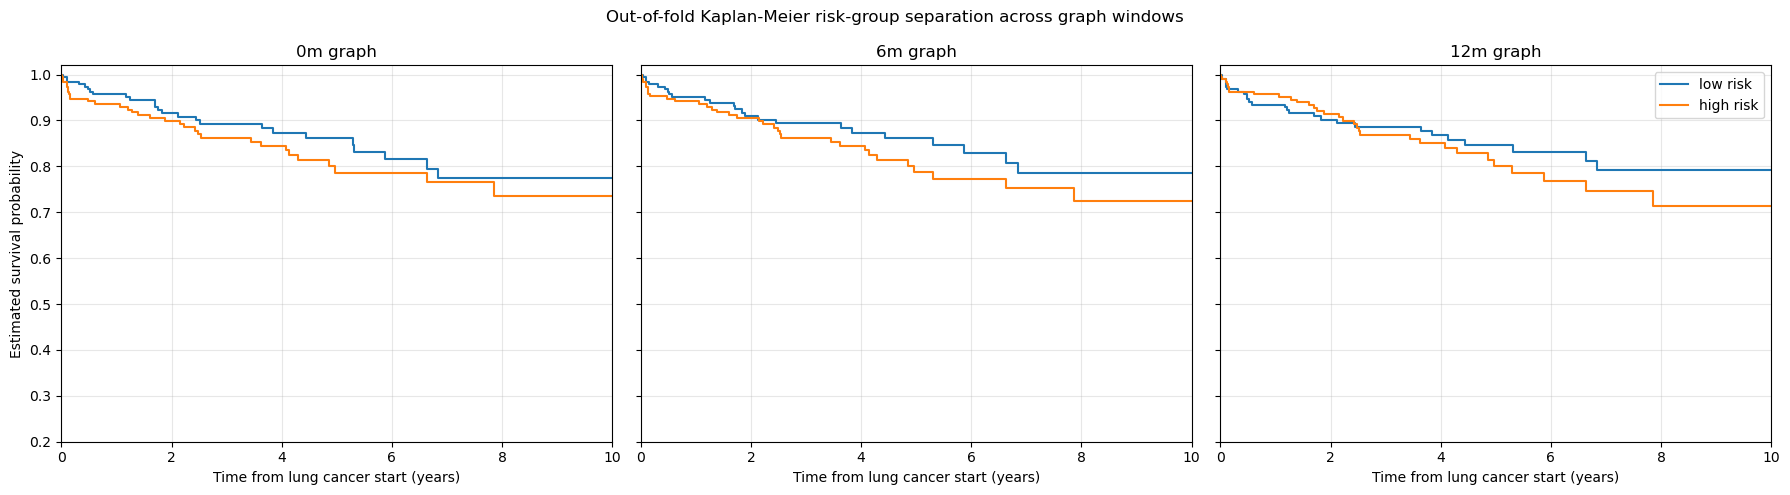

Saved OOF KM outputs:
OOF KM predictions: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_km_risk_group_predictions_0m_6m_12m_20260701_115311.csv
OOF KM group summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_km_risk_group_summary_0m_6m_12m_20260701_115311.csv
OOF KM curves: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_km_curves_0m_6m_12m_20260701_115311.csv
OOF KM figure: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_

In [23]:
# ------------------------------------------------------------
# Out-of-fold Kaplan-Meier risk-group separation
# ------------------------------------------------------------

# Define compute_km_curve if it is not already available.
if "compute_km_curve" not in globals():
    def compute_km_curve(times, events):
        times = pd.Series(times).astype(float).tolist()
        events = pd.Series(events).astype(int).tolist()

        unique_event_times = sorted(
            set(times[i] for i in range(len(times)) if events[i] == 1)
        )

        survival_probability = 1.0

        rows = [{
            "time": 0.0,
            "survival_probability": 1.0,
            "n_at_risk": len(times),
            "n_events": 0,
        }]

        for t in unique_event_times:
            n_at_risk = sum(x >= t for x in times)
            n_events = sum(
                (times[i] == t) and (events[i] == 1)
                for i in range(len(times))
            )

            if n_at_risk > 0:
                survival_probability *= (1.0 - n_events / n_at_risk)

            rows.append({
                "time": float(t),
                "survival_probability": float(survival_probability),
                "n_at_risk": int(n_at_risk),
                "n_events": int(n_events),
            })

        return pd.DataFrame(rows)


# Median split within each graph window using OOF risk scores.
oof_km_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = cv_oof_predictions_df[
        cv_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    median_risk = window_df["risk_score"].median()

    window_df["risk_group"] = "low_risk"
    window_df.loc[
        window_df["risk_score"] > median_risk,
        "risk_group"
    ] = "high_risk"

    # If there are ties at the median, this may not be exactly 50/50.
    window_df["risk_group_threshold"] = median_risk

    oof_km_frames.append(window_df)

cv_oof_km_predictions_df = pd.concat(
    oof_km_frames,
    ignore_index=True,
)

oof_group_summary_df = (
    cv_oof_km_predictions_df
    .groupby(["graph_window", "risk_group"], as_index=False)
    .agg(
        n_patients=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_risk_score=("risk_score", "mean"),
    )
)

print("OOF risk-group summary:")
display(oof_group_summary_df)


oof_km_curve_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    for risk_group in ["low_risk", "high_risk"]:
        group_df = cv_oof_km_predictions_df[
            (cv_oof_km_predictions_df["graph_window"] == graph_window)
            & (cv_oof_km_predictions_df["risk_group"] == risk_group)
        ].copy()

        km_curve_df = compute_km_curve(
            times=group_df["survival_time_years"],
            events=group_df["event_death"],
        )

        km_curve_df["graph_window"] = graph_window
        km_curve_df["risk_group"] = risk_group

        oof_km_curve_frames.append(km_curve_df)

cv_oof_km_curves_df = pd.concat(
    oof_km_curve_frames,
    ignore_index=True,
)

# Plot OOF KM curves.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, graph_window in zip(axes, CV_GRAPH_WINDOWS):
    for risk_group in ["low_risk", "high_risk"]:
        curve_df = cv_oof_km_curves_df[
            (cv_oof_km_curves_df["graph_window"] == graph_window)
            & (cv_oof_km_curves_df["risk_group"] == risk_group)
        ].copy()

        label = risk_group.replace("_", " ")

        ax.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=label,
        )

    ax.set_title(f"{graph_window} graph")
    ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0, 10)
    ax.set_ylim(0.2, 1.02)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimated survival probability")
axes[-1].legend(loc="best")

fig.suptitle("Out-of-fold Kaplan-Meier risk-group separation across graph windows")
plt.tight_layout()

oof_km_png_path = os.path.join(
    cv_output_dir,
    f"oof_km_risk_group_curves_0m_6m_12m_{cv_timestamp}.png",
)

plt.savefig(oof_km_png_path, dpi=300, bbox_inches="tight")
plt.show()

oof_km_predictions_path = os.path.join(
    cv_output_dir,
    f"oof_km_risk_group_predictions_0m_6m_12m_{cv_timestamp}.csv",
)

oof_group_summary_path = os.path.join(
    cv_output_dir,
    f"oof_km_risk_group_summary_0m_6m_12m_{cv_timestamp}.csv",
)

oof_km_curves_path = os.path.join(
    cv_output_dir,
    f"oof_km_curves_0m_6m_12m_{cv_timestamp}.csv",
)

cv_oof_km_predictions_df.to_csv(oof_km_predictions_path, index=False)
oof_group_summary_df.to_csv(oof_group_summary_path, index=False)
cv_oof_km_curves_df.to_csv(oof_km_curves_path, index=False)

print("Saved OOF KM outputs:")
print("OOF KM predictions:", oof_km_predictions_path)
print("OOF KM group summary:", oof_group_summary_path)
print("OOF KM curves:", oof_km_curves_path)
print("OOF KM figure:", oof_km_png_path)

In [24]:
# ------------------------------------------------------------
# Out-of-fold extreme-risk sensitivity analysis
# ------------------------------------------------------------

# Use the selected final CV protocol.
# This should point to the original early-stopping CV outputs.
if "final_cv_oof_predictions_df" not in globals():
    raise NameError(
        "final_cv_oof_predictions_df is missing. "
        "Run the cell that selects the final CV protocol first."
    )

extreme_risk_frames = []
extreme_summary_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = final_cv_oof_predictions_df[
        final_cv_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    window_df = window_df.sort_values("risk_score").reset_index(drop=True)

    n_patients = len(window_df)
    n_third = n_patients // 3

    bottom_df = window_df.iloc[:n_third].copy()
    top_df = window_df.iloc[-n_third:].copy()

    bottom_df["extreme_risk_group"] = "bottom_third_low_risk"
    top_df["extreme_risk_group"] = "top_third_high_risk"

    extreme_df = pd.concat([bottom_df, top_df], ignore_index=True)
    extreme_df["graph_window"] = graph_window
    extreme_df["n_third"] = n_third
    extreme_risk_frames.append(extreme_df)

    bottom_events = int(bottom_df["event_death"].sum())
    top_events = int(top_df["event_death"].sum())

    bottom_event_rate = float(bottom_df["event_death"].mean())
    top_event_rate = float(top_df["event_death"].mean())

    extreme_summary_rows.append({
        "graph_window": graph_window,
        "n_patients_total": n_patients,
        "n_per_extreme_group": n_third,

        "bottom_third_events": bottom_events,
        "top_third_events": top_events,

        "bottom_third_event_rate": bottom_event_rate,
        "top_third_event_rate": top_event_rate,
        "event_rate_delta_top_minus_bottom": top_event_rate - bottom_event_rate,

        "bottom_third_median_observed_time": float(bottom_df["survival_time_years"].median()),
        "top_third_median_observed_time": float(top_df["survival_time_years"].median()),

        "bottom_third_mean_risk_score": float(bottom_df["risk_score"].mean()),
        "top_third_mean_risk_score": float(top_df["risk_score"].mean()),
    })

oof_extreme_risk_predictions_df = pd.concat(
    extreme_risk_frames,
    ignore_index=True,
)

oof_extreme_risk_summary_df = pd.DataFrame(extreme_summary_rows)

print("Out-of-fold extreme-risk summary:")
display(oof_extreme_risk_summary_df)

print("Extreme-risk prediction rows:")
display(oof_extreme_risk_predictions_df.head())


# Optional: fold-level consistency check.
# This checks whether, within each outer test fold, the top third had more events
# than the bottom third.

fold_extreme_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = final_cv_oof_predictions_df[
        final_cv_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    for outer_fold in sorted(window_df["outer_fold"].unique()):
        fold_df = window_df[window_df["outer_fold"] == outer_fold].copy()
        fold_df = fold_df.sort_values("risk_score").reset_index(drop=True)

        n_fold = len(fold_df)
        n_fold_third = n_fold // 3

        fold_bottom_df = fold_df.iloc[:n_fold_third].copy()
        fold_top_df = fold_df.iloc[-n_fold_third:].copy()

        bottom_events = int(fold_bottom_df["event_death"].sum())
        top_events = int(fold_top_df["event_death"].sum())

        bottom_event_rate = float(fold_bottom_df["event_death"].mean())
        top_event_rate = float(fold_top_df["event_death"].mean())

        fold_extreme_rows.append({
            "graph_window": graph_window,
            "outer_fold": int(outer_fold),
            "n_per_extreme_group": n_fold_third,
            "bottom_third_events": bottom_events,
            "top_third_events": top_events,
            "bottom_third_event_rate": bottom_event_rate,
            "top_third_event_rate": top_event_rate,
            "event_rate_delta_top_minus_bottom": top_event_rate - bottom_event_rate,
            "top_has_more_events": top_events > bottom_events,
        })

oof_extreme_risk_by_fold_df = pd.DataFrame(fold_extreme_rows)

print("Fold-level extreme-risk consistency:")
display(oof_extreme_risk_by_fold_df)

oof_extreme_risk_consistency_df = (
    oof_extreme_risk_by_fold_df
    .groupby("graph_window", as_index=False)
    .agg(
        n_folds=("outer_fold", "count"),
        folds_top_has_more_events=("top_has_more_events", "sum"),
        mean_event_rate_delta=("event_rate_delta_top_minus_bottom", "mean"),
        std_event_rate_delta=("event_rate_delta_top_minus_bottom", "std"),
    )
)

print("Extreme-risk fold-level consistency summary:")
display(oof_extreme_risk_consistency_df)


# Save outputs
oof_extreme_risk_predictions_path = os.path.join(
    cv_output_dir,
    f"oof_extreme_risk_predictions_0m_6m_12m_{cv_timestamp}.csv",
)

oof_extreme_risk_summary_path = os.path.join(
    cv_output_dir,
    f"oof_extreme_risk_summary_0m_6m_12m_{cv_timestamp}.csv",
)

oof_extreme_risk_by_fold_path = os.path.join(
    cv_output_dir,
    f"oof_extreme_risk_by_fold_0m_6m_12m_{cv_timestamp}.csv",
)

oof_extreme_risk_consistency_path = os.path.join(
    cv_output_dir,
    f"oof_extreme_risk_consistency_0m_6m_12m_{cv_timestamp}.csv",
)

oof_extreme_risk_predictions_df.to_csv(oof_extreme_risk_predictions_path, index=False)
oof_extreme_risk_summary_df.to_csv(oof_extreme_risk_summary_path, index=False)
oof_extreme_risk_by_fold_df.to_csv(oof_extreme_risk_by_fold_path, index=False)
oof_extreme_risk_consistency_df.to_csv(oof_extreme_risk_consistency_path, index=False)

print("Saved OOF extreme-risk outputs:")
print("OOF extreme-risk predictions:", oof_extreme_risk_predictions_path)
print("OOF extreme-risk summary:", oof_extreme_risk_summary_path)
print("OOF extreme-risk by fold:", oof_extreme_risk_by_fold_path)
print("OOF extreme-risk consistency:", oof_extreme_risk_consistency_path)

Out-of-fold extreme-risk summary:


,graph_window,n_patients_total,n_per_extreme_group,bottom_third_events,top_third_events,bottom_third_event_rate,top_third_event_rate,event_rate_delta_top_minus_bottom,bottom_third_median_observed_time,top_third_median_observed_time,bottom_third_mean_risk_score,top_third_mean_risk_score
0,0m,379,126,20,21,0.15873,0.166667,0.007937,3.544148,3.753593,-18.356881,14.868468
1,6m,379,126,20,22,0.15873,0.174603,0.015873,3.544148,3.653662,-17.786610,12.607952
2,12m,379,126,20,25,0.15873,0.198413,0.039683,3.544148,3.567420,-17.792207,12.517580


Extreme-risk prediction rows:


,graph_window,outer_fold,person_node_index,survival_time_years,event_death,risk_score,config_name,hidden_channels,dropout,weight_decay,best_epoch,extreme_risk_group,n_third
0,0m,1,195,5.659138,0.0,-23.743984,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,bottom_third_low_risk,126
1,0m,1,311,12.295688,0.0,-23.701563,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,bottom_third_low_risk,126
2,0m,1,157,2.110883,0.0,-23.657709,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,bottom_third_low_risk,126
3,0m,1,63,6.858316,0.0,-22.632822,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,bottom_third_low_risk,126
4,0m,1,340,1.333333,0.0,-22.541412,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,4,bottom_third_low_risk,126


Fold-level extreme-risk consistency:


,graph_window,outer_fold,n_per_extreme_group,bottom_third_events,top_third_events,bottom_third_event_rate,top_third_event_rate,event_rate_delta_top_minus_bottom,top_has_more_events
0,0m,1,25,1,6,0.04,0.24,0.20,True
1,0m,2,25,4,4,0.16,0.16,0.00,False
2,0m,3,25,0,7,0.00,0.28,0.28,True
3,0m,4,25,3,6,0.12,0.24,0.12,True
4,0m,5,25,2,5,0.08,0.20,0.12,True
5,6m,1,25,1,6,0.04,0.24,0.20,True
6,6m,2,25,4,4,0.16,0.16,0.00,False
7,6m,3,25,2,8,0.08,0.32,0.24,True
8,6m,4,25,3,6,0.12,0.24,0.12,True
9,6m,5,25,3,5,0.12,0.20,0.08,True


Extreme-risk fold-level consistency summary:


,graph_window,n_folds,folds_top_has_more_events,mean_event_rate_delta,std_event_rate_delta
0,0m,5,4,0.144,0.104307
1,12m,5,4,0.128,0.095499
2,6m,5,4,0.128,0.095499


Saved OOF extreme-risk outputs:
OOF extreme-risk predictions: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_extreme_risk_predictions_0m_6m_12m_20260701_115311.csv
OOF extreme-risk summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_extreme_risk_summary_0m_6m_12m_20260701_115311.csv
OOF extreme-risk by fold: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_extreme_risk_by_fold_0m_6m_12m_20260701_115311.csv
OOF extreme-risk consistency: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_s

OOF horizon-specific AUC:


,graph_window,horizon_years,auc,n_evaluable,n_events_by_horizon,n_non_events_by_horizon,n_excluded_censored_before_horizon
0,0m,1.0,0.527987,338,20,318,41
1,0m,3.0,0.509272,253,40,213,126
2,0m,5.0,0.550167,170,50,120,209
3,6m,1.0,0.502987,338,20,318,41
4,6m,3.0,0.525704,253,40,213,126
5,6m,5.0,0.552500,170,50,120,209
6,12m,1.0,0.487264,338,20,318,41
7,12m,3.0,0.537559,253,40,213,126
8,12m,5.0,0.554167,170,50,120,209


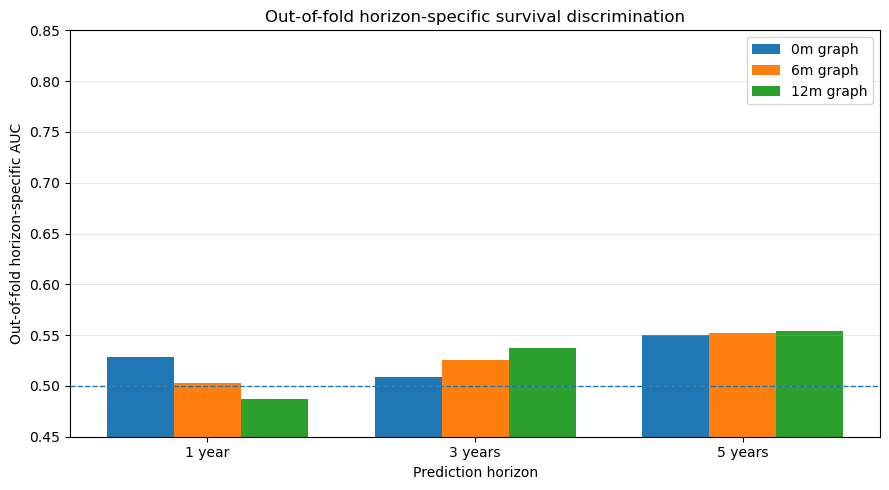

Saved OOF horizon AUC outputs:
OOF horizon AUC table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_horizon_auc_0m_6m_12m_20260701_115311.csv
OOF horizon AUC figure: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/oof_horizon_auc_0m_6m_12m_20260701_115311.png


In [25]:
# ------------------------------------------------------------
# Out-of-fold horizon-specific AUC
# ------------------------------------------------------------

import numpy as np

HORIZON_YEARS = [1.0, 3.0, 5.0]

# Define compute_binary_auc_from_scores if it is not already available.
if "compute_binary_auc_from_scores" not in globals():
    def compute_binary_auc_from_scores(y_true, scores):
        y_true = np.asarray(y_true, dtype=int)
        scores = np.asarray(scores, dtype=float)

        n_pos = int((y_true == 1).sum())
        n_neg = int((y_true == 0).sum())

        if n_pos == 0 or n_neg == 0:
            return np.nan

        ranks = pd.Series(scores).rank(method="average").to_numpy()

        sum_pos_ranks = ranks[y_true == 1].sum()

        auc = (
            sum_pos_ranks
            - n_pos * (n_pos + 1) / 2.0
        ) / (n_pos * n_neg)

        return float(auc)


oof_horizon_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = cv_oof_predictions_df[
        cv_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    for horizon_years in HORIZON_YEARS:
        eval_df = window_df.copy()

        eval_df["horizon_years"] = horizon_years

        # Event by horizon.
        eval_df["horizon_label"] = np.nan

        eval_df.loc[
            (eval_df["event_death"] == 1)
            & (eval_df["survival_time_years"] <= horizon_years),
            "horizon_label",
        ] = 1

        eval_df.loc[
            eval_df["survival_time_years"] > horizon_years,
            "horizon_label",
        ] = 0

        # Censored before or at the horizon remain NaN and are excluded.
        usable_df = eval_df[eval_df["horizon_label"].notna()].copy()

        auc_value = compute_binary_auc_from_scores(
            y_true=usable_df["horizon_label"],
            scores=usable_df["risk_score"],
        )

        oof_horizon_rows.append({
            "graph_window": graph_window,
            "horizon_years": horizon_years,
            "auc": auc_value,
            "n_evaluable": len(usable_df),
            "n_events_by_horizon": int((usable_df["horizon_label"] == 1).sum()),
            "n_non_events_by_horizon": int((usable_df["horizon_label"] == 0).sum()),
            "n_excluded_censored_before_horizon": int(
                eval_df["horizon_label"].isna().sum()
            ),
        })

oof_horizon_auc_df = pd.DataFrame(oof_horizon_rows)

print("OOF horizon-specific AUC:")
display(oof_horizon_auc_df)


# Plot OOF horizon AUC.
plot_df = oof_horizon_auc_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))

x_positions = range(len(HORIZON_YEARS))
bar_width = 0.25

window_offsets = {
    "0m": -bar_width,
    "6m": 0.0,
    "12m": bar_width,
}

for graph_window in CV_GRAPH_WINDOWS:
    window_df = plot_df[plot_df["graph_window"] == graph_window].copy()

    xs = [
        i + window_offsets[graph_window]
        for i in x_positions
    ]

    ax.bar(
        xs,
        window_df["auc"],
        width=bar_width,
        label=f"{graph_window} graph",
    )

ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xticks(list(x_positions))
ax.set_xticklabels([f"{int(h)} year" if h == 1.0 else f"{int(h)} years" for h in HORIZON_YEARS])
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("Out-of-fold horizon-specific AUC")
ax.set_xlabel("Prediction horizon")
ax.set_title("Out-of-fold horizon-specific survival discrimination")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()

oof_horizon_auc_png_path = os.path.join(
    cv_output_dir,
    f"oof_horizon_auc_0m_6m_12m_{cv_timestamp}.png",
)

plt.savefig(oof_horizon_auc_png_path, dpi=300, bbox_inches="tight")
plt.show()

oof_horizon_auc_path = os.path.join(
    cv_output_dir,
    f"oof_horizon_auc_0m_6m_12m_{cv_timestamp}.csv",
)

oof_horizon_auc_df.to_csv(oof_horizon_auc_path, index=False)

print("Saved OOF horizon AUC outputs:")
print("OOF horizon AUC table:", oof_horizon_auc_path)
print("OOF horizon AUC figure:", oof_horizon_auc_png_path)

#### Out-of-fold complementary survival evaluation summary

Using out-of-fold predictions from the stratified 5-fold CV, we evaluated Kaplan-Meier risk-group separation, extreme-risk sensitivity, and horizon-specific AUC.

The Kaplan-Meier median split showed modest directional risk separation across all three graph windows. For each window, the predicted high-risk group contained more observed deaths than the predicted low-risk group. The largest high-minus-low event-rate difference was observed for the 6m graph, although the separation remained modest.

The extreme-risk analysis also showed directional signal in most folds. Within fold-level top-third versus bottom-third comparisons, the top-risk group contained more observed deaths in 4 out of 5 folds for all three graph windows. However, this analysis did not identify a clear best graph window.

Horizon-specific AUC values were close to random discrimination across 1-, 3-, and 5-year horizons. The best-performing graph window differed by horizon, and no consistent 6m advantage was observed.

Overall, the out-of-fold analyses suggest that the HeteroGraphSAGE-Cox model captures a modest survival-related signal, but the final 5-fold CV evaluation does not provide robust evidence that one graph window clearly outperforms the others. These results should be interpreted cautiously given the limited number of observed death events.

### Percentile-Normalized Out-of-Fold Evaluation

The stratified 5-fold CV training has already been completed and the out-of-fold predictions were saved to disk. Therefore, we do not rerun model training in this section.

Because each outer CV fold was scored by a separately trained model, raw Cox risk scores may not be directly comparable across folds. A raw score from one fold can be on a different numerical scale than a raw score from another fold.

To make pooled out-of-fold analyses more appropriate, we convert each raw risk score into a fold-normalized risk percentile. Within each graph window and outer fold, patients are ranked by their held-out risk score and mapped to a percentile scale from 0 to 1:

- 0 represents the lowest predicted risk within that fold
- 1 represents the highest predicted risk within that fold

This preserves the within-fold risk ranking while avoiding direct comparison of raw risk-score scales across independently trained fold models.

The following complementary analyses are then computed using fold-normalized risk percentiles:

1. Kaplan-Meier risk-group separation
2. Extreme-risk sensitivity analysis
3. Horizon-specific AUC at 1, 3, and 5 years

In [2]:
# ------------------------------------------------------------
# Lightweight dependencies and path setup for saved CV analysis
# No graph loading, no PyTorch, no model training
# ------------------------------------------------------------

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RW 2.0 local mounted workspace bucket
WORKSPACE_BUCKET_LOCAL = Path(
    "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
)

# Optional compatibility variable, only local path, not GCS
os.environ["WORKSPACE_BUCKET"] = str(WORKSPACE_BUCKET_LOCAL)

# Final graph/output folder from the saved 5-fold CV run
cv_output_dir = (
    WORKSPACE_BUCKET_LOCAL
    / "graph_artifacts"
    / "lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110"
    / "final_5fold_cv_gnn_survival_0m_6m_12m"
)

CV_GRAPH_WINDOWS = ["0m", "6m", "12m"]
cv_timestamp = "20260701_115311"

cv_results_path = cv_output_dir / f"cv_fold_results_0m_6m_12m_{cv_timestamp}.csv"
cv_summary_path = cv_output_dir / f"cv_summary_0m_6m_12m_{cv_timestamp}.csv"
cv_oof_predictions_path = cv_output_dir / f"cv_out_of_fold_predictions_0m_6m_12m_{cv_timestamp}.csv"

# Minimal access checks
assert WORKSPACE_BUCKET_LOCAL.exists(), f"Workspace bucket mount not found: {WORKSPACE_BUCKET_LOCAL}"
assert cv_output_dir.exists(), f"CV output directory not found: {cv_output_dir}"
assert cv_oof_predictions_path.exists(), f"OOF predictions file not found: {cv_oof_predictions_path}"

# Lightweight CSV loading only
cv_results_df = pd.read_csv(cv_results_path)
cv_summary_df = pd.read_csv(cv_summary_path)
final_cv_oof_predictions_df = pd.read_csv(cv_oof_predictions_path)

print("Loaded saved 5-fold CV files:")
print("cv_results_df:", cv_results_df.shape)
print("cv_summary_df:", cv_summary_df.shape)
print("final_cv_oof_predictions_df:", final_cv_oof_predictions_df.shape)

display(cv_summary_df)

required_oof_columns = {
    "graph_window",
    "outer_fold",
    "person_node_index",
    "risk_score",
    "survival_time_years",
    "event_death",
}

missing_columns = required_oof_columns - set(final_cv_oof_predictions_df.columns)
assert not missing_columns, f"Missing required OOF columns: {missing_columns}"

print("Lightweight setup complete. No graphs or models were loaded.")

Loaded saved 5-fold CV files:
cv_results_df: (15, 35)
cv_summary_df: (3, 18)
final_cv_oof_predictions_df: (1137, 11)


,graph_window,n_folds,mean_test_harrell_c_index,std_test_harrell_c_index,min_test_harrell_c_index,max_test_harrell_c_index,mean_test_ipcw_c_index,std_test_ipcw_c_index,min_test_ipcw_c_index,max_test_ipcw_c_index,mean_val_harrell_c_index,mean_val_ipcw_c_index,mean_best_epoch,mean_test_n_patients,mean_test_n_events,mean_test_harrell_pairs,mean_test_ipcw_weighted_pairs,mean_test_ipcw_minus_harrell
0,0m,5,0.664920,0.104096,0.546125,0.769608,0.637751,0.118384,0.490788,0.731692,0.671789,0.632433,46.6,75.8,12.0,586.8,1465.204038,-0.027169
1,12m,5,0.659847,0.105914,0.527675,0.767974,0.624722,0.110077,0.482787,0.717441,0.679193,0.583287,60.4,75.8,12.0,586.8,1465.204038,-0.035125
2,6m,5,0.653207,0.110572,0.525830,0.767974,0.624028,0.112455,0.481624,0.717441,0.667583,0.566350,44.4,75.8,12.0,586.8,1465.204038,-0.029178


Lightweight setup complete. No graphs or models were loaded.


In [3]:
# Sanity check: each patient appears exactly once per graph window
count_check_df = (
    final_cv_oof_predictions_df
    .groupby(["graph_window", "person_node_index"])
    .size()
    .reset_index(name="n_oof_predictions")
)

assert (count_check_df["n_oof_predictions"] == 1).all()

print("OOF sanity check passed: each patient appears exactly once per graph window.")

# Convert raw risk scores to fold-normalized percentiles
percentile_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    graph_df = final_cv_oof_predictions_df[
        final_cv_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    for outer_fold in sorted(graph_df["outer_fold"].unique()):
        fold_df = graph_df[graph_df["outer_fold"] == outer_fold].copy()
        n_fold = len(fold_df)

        # Higher raw risk_score means higher predicted hazard.
        # Rank 1 = lowest risk, rank n = highest risk.
        fold_df["foldwise_risk_rank"] = fold_df["risk_score"].rank(
            method="average",
            ascending=True,
        )

        if n_fold > 1:
            fold_df["foldwise_risk_percentile"] = (
                (fold_df["foldwise_risk_rank"] - 1.0) / (n_fold - 1.0)
            )
        else:
            fold_df["foldwise_risk_percentile"] = 0.5

        percentile_frames.append(fold_df)

percentile_oof_predictions_df = pd.concat(
    percentile_frames,
    ignore_index=True,
)

POOLED_RISK_SCORE_COL = "foldwise_risk_percentile"

percentile_check_df = (
    percentile_oof_predictions_df
    .groupby(["graph_window", "outer_fold"], as_index=False)
    .agg(
        n_patients=("person_node_index", "count"),
        min_percentile=("foldwise_risk_percentile", "min"),
        median_percentile=("foldwise_risk_percentile", "median"),
        max_percentile=("foldwise_risk_percentile", "max"),
        n_events=("event_death", "sum"),
    )
)

print("Fold-normalized risk percentile check:")
display(percentile_check_df)

print("Downstream pooled metrics will use:", POOLED_RISK_SCORE_COL)

OOF sanity check passed: each patient appears exactly once per graph window.
Fold-normalized risk percentile check:


,graph_window,outer_fold,n_patients,min_percentile,median_percentile,max_percentile,n_events
0,0m,1,76,0.0,0.5,1.0,12.0
1,0m,2,76,0.0,0.5,1.0,12.0
2,0m,3,76,0.0,0.5,1.0,12.0
3,0m,4,76,0.0,0.5,1.0,12.0
4,0m,5,75,0.0,0.5,1.0,12.0
5,12m,1,76,0.0,0.5,1.0,12.0
6,12m,2,76,0.0,0.5,1.0,12.0
7,12m,3,76,0.0,0.5,1.0,12.0
8,12m,4,76,0.0,0.5,1.0,12.0
9,12m,5,75,0.0,0.5,1.0,12.0


Downstream pooled metrics will use: foldwise_risk_percentile


In [4]:
# ------------------------------------------------------------
# Lightweight helper functions for KM and AUC
# ------------------------------------------------------------

def compute_km_curve(times, events):
    times = pd.Series(times).astype(float).tolist()
    events = pd.Series(events).astype(int).tolist()

    unique_event_times = sorted(
        set(times[i] for i in range(len(times)) if events[i] == 1)
    )

    survival_probability = 1.0

    rows = [{
        "time": 0.0,
        "survival_probability": 1.0,
        "n_at_risk": len(times),
        "n_events": 0,
    }]

    for t in unique_event_times:
        n_at_risk = sum(x >= t for x in times)
        n_events = sum(
            (times[i] == t) and (events[i] == 1)
            for i in range(len(times))
        )

        if n_at_risk > 0:
            survival_probability *= (1.0 - n_events / n_at_risk)

        rows.append({
            "time": float(t),
            "survival_probability": float(survival_probability),
            "n_at_risk": int(n_at_risk),
            "n_events": int(n_events),
        })

    return pd.DataFrame(rows)


def compute_binary_auc_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())

    if n_pos == 0 or n_neg == 0:
        return np.nan

    ranks = pd.Series(scores).rank(method="average").to_numpy()
    sum_pos_ranks = ranks[y_true == 1].sum()

    auc = (
        sum_pos_ranks
        - n_pos * (n_pos + 1) / 2.0
    ) / (n_pos * n_neg)

    return float(auc)


print("Helper functions ready.")

Helper functions ready.


Percentile-normalized OOF KM risk-group summary:


,graph_window,risk_group,n_patients,n_events,event_rate,median_observed_time,mean_observed_time,mean_raw_risk_score,mean_foldwise_risk_percentile
0,0m,high_risk,189,41.0,0.216931,3.186858,3.797703,-1.012344,0.754004
1,0m,low_risk,190,19.0,0.100000,3.768652,4.730257,-2.476385,0.247333
2,12m,high_risk,189,37.0,0.195767,3.345654,3.826125,-0.961422,0.754004
3,12m,low_risk,190,23.0,0.121053,3.696098,4.701985,-2.669531,0.247333
4,6m,high_risk,189,37.0,0.195767,3.496235,3.978619,-0.742164,0.754004
5,6m,low_risk,190,23.0,0.121053,3.671458,4.550294,-2.423175,0.247333


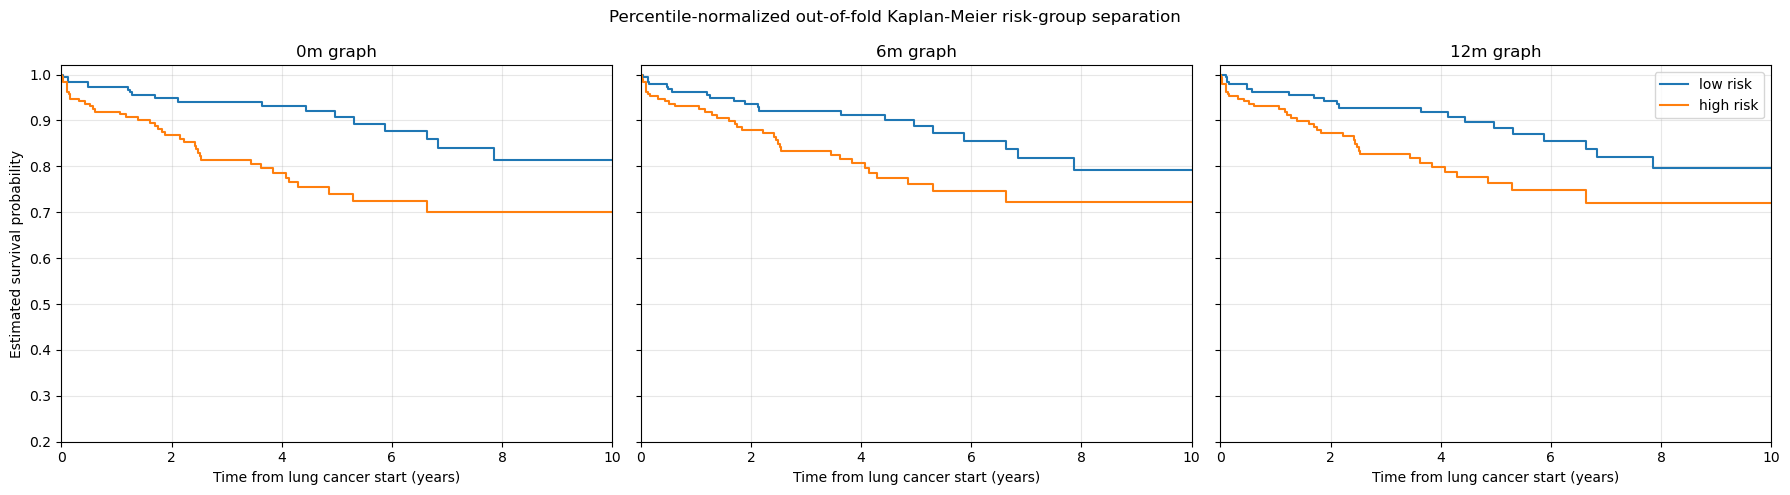

Saved KM summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_km_risk_group_summary_0m_6m_12m_20260701_115311.csv
Saved KM figure: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_km_risk_group_curves_0m_6m_12m_20260701_115311.png


In [5]:
# ------------------------------------------------------------
# Percentile-normalized OOF Kaplan-Meier risk-group separation
# ------------------------------------------------------------

percentile_km_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = percentile_oof_predictions_df[
        percentile_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    window_df["risk_group"] = "low_risk"
    window_df.loc[
        window_df[POOLED_RISK_SCORE_COL] > 0.5,
        "risk_group"
    ] = "high_risk"

    window_df["risk_group_method"] = "fold_normalized_percentile_median"
    window_df["risk_group_threshold"] = 0.5

    percentile_km_frames.append(window_df)

percentile_oof_km_predictions_df = pd.concat(
    percentile_km_frames,
    ignore_index=True,
)

percentile_oof_group_summary_df = (
    percentile_oof_km_predictions_df
    .groupby(["graph_window", "risk_group"], as_index=False)
    .agg(
        n_patients=("person_node_index", "count"),
        n_events=("event_death", "sum"),
        event_rate=("event_death", "mean"),
        median_observed_time=("survival_time_years", "median"),
        mean_observed_time=("survival_time_years", "mean"),
        mean_raw_risk_score=("risk_score", "mean"),
        mean_foldwise_risk_percentile=("foldwise_risk_percentile", "mean"),
    )
)

print("Percentile-normalized OOF KM risk-group summary:")
display(percentile_oof_group_summary_df)

percentile_km_curve_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    for risk_group in ["low_risk", "high_risk"]:
        group_df = percentile_oof_km_predictions_df[
            (percentile_oof_km_predictions_df["graph_window"] == graph_window)
            & (percentile_oof_km_predictions_df["risk_group"] == risk_group)
        ].copy()

        km_curve_df = compute_km_curve(
            times=group_df["survival_time_years"],
            events=group_df["event_death"],
        )

        km_curve_df["graph_window"] = graph_window
        km_curve_df["risk_group"] = risk_group

        percentile_km_curve_frames.append(km_curve_df)

percentile_oof_km_curves_df = pd.concat(
    percentile_km_curve_frames,
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, graph_window in zip(axes, CV_GRAPH_WINDOWS):
    for risk_group in ["low_risk", "high_risk"]:
        curve_df = percentile_oof_km_curves_df[
            (percentile_oof_km_curves_df["graph_window"] == graph_window)
            & (percentile_oof_km_curves_df["risk_group"] == risk_group)
        ].copy()

        ax.step(
            curve_df["time"],
            curve_df["survival_probability"],
            where="post",
            label=risk_group.replace("_", " "),
        )

    ax.set_title(f"{graph_window} graph")
    ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0, 10)
    ax.set_ylim(0.2, 1.02)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimated survival probability")
axes[-1].legend(loc="best")

fig.suptitle("Percentile-normalized out-of-fold Kaplan-Meier risk-group separation")
plt.tight_layout()

percentile_km_png_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_km_risk_group_curves_0m_6m_12m_{cv_timestamp}.png",
)

plt.savefig(percentile_km_png_path, dpi=300, bbox_inches="tight")
plt.show()

percentile_group_summary_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_km_risk_group_summary_0m_6m_12m_{cv_timestamp}.csv",
)

percentile_oof_group_summary_df.to_csv(
    percentile_group_summary_path,
    index=False,
)

print("Saved KM summary:", percentile_group_summary_path)
print("Saved KM figure:", percentile_km_png_path)

In [6]:
# ------------------------------------------------------------
# Percentile-normalized OOF extreme-risk sensitivity analysis
# ------------------------------------------------------------

LOW_THRESHOLD = 1.0 / 3.0
HIGH_THRESHOLD = 2.0 / 3.0

percentile_extreme_summary_rows = []
percentile_extreme_fold_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = percentile_oof_predictions_df[
        percentile_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    bottom_df = window_df[
        window_df[POOLED_RISK_SCORE_COL] <= LOW_THRESHOLD
    ].copy()

    top_df = window_df[
        window_df[POOLED_RISK_SCORE_COL] >= HIGH_THRESHOLD
    ].copy()

    percentile_extreme_summary_rows.append({
        "graph_window": graph_window,
        "n_patients_total": len(window_df),
        "n_bottom_third": len(bottom_df),
        "n_top_third": len(top_df),
        "bottom_third_events": int(bottom_df["event_death"].sum()),
        "top_third_events": int(top_df["event_death"].sum()),
        "bottom_third_event_rate": float(bottom_df["event_death"].mean()),
        "top_third_event_rate": float(top_df["event_death"].mean()),
        "event_rate_delta_top_minus_bottom": (
            float(top_df["event_death"].mean())
            - float(bottom_df["event_death"].mean())
        ),
        "bottom_third_median_observed_time": float(bottom_df["survival_time_years"].median()),
        "top_third_median_observed_time": float(top_df["survival_time_years"].median()),
    })

    for outer_fold in sorted(window_df["outer_fold"].unique()):
        fold_df = window_df[window_df["outer_fold"] == outer_fold].copy()

        fold_bottom_df = fold_df[
            fold_df[POOLED_RISK_SCORE_COL] <= LOW_THRESHOLD
        ].copy()

        fold_top_df = fold_df[
            fold_df[POOLED_RISK_SCORE_COL] >= HIGH_THRESHOLD
        ].copy()

        bottom_events = int(fold_bottom_df["event_death"].sum())
        top_events = int(fold_top_df["event_death"].sum())

        percentile_extreme_fold_rows.append({
            "graph_window": graph_window,
            "outer_fold": int(outer_fold),
            "n_bottom_third": len(fold_bottom_df),
            "n_top_third": len(fold_top_df),
            "bottom_third_events": bottom_events,
            "top_third_events": top_events,
            "bottom_third_event_rate": float(fold_bottom_df["event_death"].mean()),
            "top_third_event_rate": float(fold_top_df["event_death"].mean()),
            "event_rate_delta_top_minus_bottom": (
                float(fold_top_df["event_death"].mean())
                - float(fold_bottom_df["event_death"].mean())
            ),
            "top_has_more_events": top_events > bottom_events,
        })

percentile_oof_extreme_risk_summary_df = pd.DataFrame(
    percentile_extreme_summary_rows
)

percentile_oof_extreme_risk_by_fold_df = pd.DataFrame(
    percentile_extreme_fold_rows
)

percentile_oof_extreme_risk_consistency_df = (
    percentile_oof_extreme_risk_by_fold_df
    .groupby("graph_window", as_index=False)
    .agg(
        n_folds=("outer_fold", "count"),
        folds_top_has_more_events=("top_has_more_events", "sum"),
        mean_event_rate_delta=("event_rate_delta_top_minus_bottom", "mean"),
        std_event_rate_delta=("event_rate_delta_top_minus_bottom", "std"),
    )
)

print("Percentile-normalized OOF extreme-risk summary:")
display(percentile_oof_extreme_risk_summary_df)

print("Percentile-normalized fold-level extreme-risk consistency:")
display(percentile_oof_extreme_risk_consistency_df)

percentile_extreme_risk_summary_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_extreme_risk_summary_0m_6m_12m_{cv_timestamp}.csv",
)

percentile_extreme_risk_consistency_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_extreme_risk_consistency_0m_6m_12m_{cv_timestamp}.csv",
)

percentile_oof_extreme_risk_summary_df.to_csv(
    percentile_extreme_risk_summary_path,
    index=False,
)

percentile_oof_extreme_risk_consistency_df.to_csv(
    percentile_extreme_risk_consistency_path,
    index=False,
)

print("Saved extreme-risk summary:", percentile_extreme_risk_summary_path)
print("Saved extreme-risk consistency:", percentile_extreme_risk_consistency_path)

Percentile-normalized OOF extreme-risk summary:


,graph_window,n_patients_total,n_bottom_third,n_top_third,bottom_third_events,top_third_events,bottom_third_event_rate,top_third_event_rate,event_rate_delta_top_minus_bottom,bottom_third_median_observed_time,top_third_median_observed_time
0,0m,379,129,129,10,28,0.077519,0.217054,0.139535,4.032854,3.082820
1,6m,379,129,129,14,29,0.108527,0.224806,0.116279,3.685147,3.082820
2,12m,379,129,129,13,29,0.100775,0.224806,0.124031,3.674196,2.965092


Percentile-normalized fold-level extreme-risk consistency:


,graph_window,n_folds,folds_top_has_more_events,mean_event_rate_delta,std_event_rate_delta
0,0m,5,4,0.139385,0.100051
1,12m,5,4,0.123692,0.091449
2,6m,5,4,0.116000,0.093907


Saved extreme-risk summary: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_extreme_risk_summary_0m_6m_12m_20260701_115311.csv
Saved extreme-risk consistency: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_extreme_risk_consistency_0m_6m_12m_20260701_115311.csv


Percentile-normalized OOF horizon-specific AUC:


,graph_window,horizon_years,auc,n_evaluable,n_events_by_horizon,n_non_events_by_horizon,n_excluded_censored_before_horizon,score_used
0,0m,1.0,0.674214,338,20,318,41,foldwise_risk_percentile
1,0m,3.0,0.699707,253,40,213,126,foldwise_risk_percentile
2,0m,5.0,0.700667,170,50,120,209,foldwise_risk_percentile
3,6m,1.0,0.652909,338,20,318,41,foldwise_risk_percentile
4,6m,3.0,0.678932,253,40,213,126,foldwise_risk_percentile
5,6m,5.0,0.681417,170,50,120,209,foldwise_risk_percentile
6,12m,1.0,0.651730,338,20,318,41,foldwise_risk_percentile
7,12m,3.0,0.694601,253,40,213,126,foldwise_risk_percentile
8,12m,5.0,0.690083,170,50,120,209,foldwise_risk_percentile


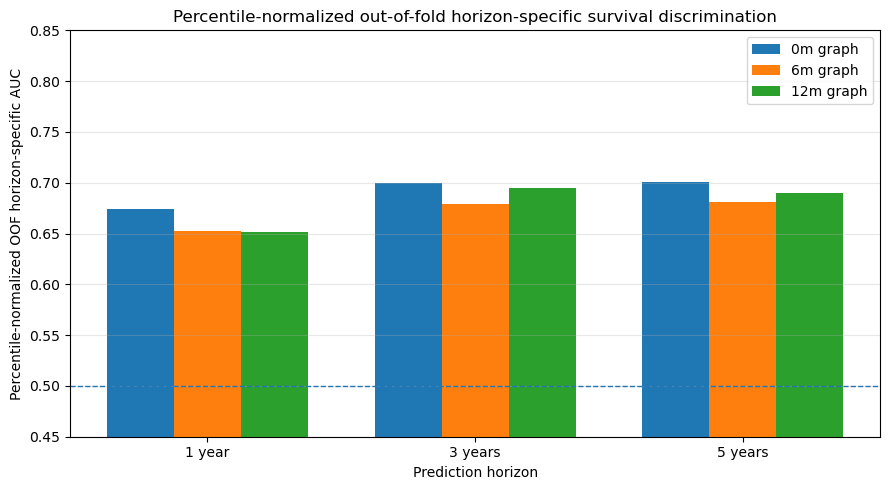

Saved horizon AUC table: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_horizon_auc_0m_6m_12m_20260701_115311.csv
Saved horizon AUC figure: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/percentile_oof_horizon_auc_0m_6m_12m_20260701_115311.png


In [7]:
# ------------------------------------------------------------
# Percentile-normalized OOF horizon-specific AUC
# ------------------------------------------------------------

HORIZON_YEARS = [1.0, 3.0, 5.0]

percentile_horizon_rows = []

for graph_window in CV_GRAPH_WINDOWS:
    window_df = percentile_oof_predictions_df[
        percentile_oof_predictions_df["graph_window"] == graph_window
    ].copy()

    for horizon_years in HORIZON_YEARS:
        eval_df = window_df.copy()
        eval_df["horizon_years"] = horizon_years
        eval_df["horizon_label"] = np.nan

        eval_df.loc[
            (eval_df["event_death"] == 1)
            & (eval_df["survival_time_years"] <= horizon_years),
            "horizon_label",
        ] = 1

        eval_df.loc[
            eval_df["survival_time_years"] > horizon_years,
            "horizon_label",
        ] = 0

        usable_df = eval_df[eval_df["horizon_label"].notna()].copy()

        auc_value = compute_binary_auc_from_scores(
            y_true=usable_df["horizon_label"],
            scores=usable_df[POOLED_RISK_SCORE_COL],
        )

        percentile_horizon_rows.append({
            "graph_window": graph_window,
            "horizon_years": horizon_years,
            "auc": auc_value,
            "n_evaluable": len(usable_df),
            "n_events_by_horizon": int((usable_df["horizon_label"] == 1).sum()),
            "n_non_events_by_horizon": int((usable_df["horizon_label"] == 0).sum()),
            "n_excluded_censored_before_horizon": int(eval_df["horizon_label"].isna().sum()),
            "score_used": POOLED_RISK_SCORE_COL,
        })

percentile_oof_horizon_auc_df = pd.DataFrame(percentile_horizon_rows)

print("Percentile-normalized OOF horizon-specific AUC:")
display(percentile_oof_horizon_auc_df)

fig, ax = plt.subplots(figsize=(9, 5))

x_positions = range(len(HORIZON_YEARS))
bar_width = 0.25

window_offsets = {
    "0m": -bar_width,
    "6m": 0.0,
    "12m": bar_width,
}

for graph_window in CV_GRAPH_WINDOWS:
    window_df = percentile_oof_horizon_auc_df[
        percentile_oof_horizon_auc_df["graph_window"] == graph_window
    ].copy()

    xs = [i + window_offsets[graph_window] for i in x_positions]

    ax.bar(
        xs,
        window_df["auc"],
        width=bar_width,
        label=f"{graph_window} graph",
    )

ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xticks(list(x_positions))
ax.set_xticklabels([
    f"{int(h)} year" if h == 1.0 else f"{int(h)} years"
    for h in HORIZON_YEARS
])
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("Percentile-normalized OOF horizon-specific AUC")
ax.set_xlabel("Prediction horizon")
ax.set_title("Percentile-normalized out-of-fold horizon-specific survival discrimination")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()

percentile_horizon_auc_png_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_horizon_auc_0m_6m_12m_{cv_timestamp}.png",
)

plt.savefig(percentile_horizon_auc_png_path, dpi=300, bbox_inches="tight")
plt.show()

percentile_horizon_auc_path = os.path.join(
    cv_output_dir,
    f"percentile_oof_horizon_auc_0m_6m_12m_{cv_timestamp}.csv",
)

percentile_oof_horizon_auc_df.to_csv(
    percentile_horizon_auc_path,
    index=False,
)

print("Saved horizon AUC table:", percentile_horizon_auc_path)
print("Saved horizon AUC figure:", percentile_horizon_auc_png_path)

#### Interpretation of Percentile-Normalized Out-of-Fold Evaluation

After completing stratified 5-fold cross-validation, we performed complementary out-of-fold analyses using fold-normalized risk percentiles. This was done because each outer fold was scored by a separately trained Cox model, and therefore raw Cox risk scores may not be directly comparable across folds. Converting scores to within-fold percentiles preserves the held-out risk ranking while reducing fold-specific score-scale effects.

Overall, the percentile-normalized analyses show consistent but moderate survival-related risk stratification. Across all graph windows, patients assigned to higher predicted-risk percentiles had higher observed death rates and lower Kaplan-Meier survival curves than patients assigned to lower predicted-risk percentiles.

For the median risk-group split, the 0m graph showed the largest event-rate separation between high-risk and low-risk groups:

- 0m: 21.7% vs. 10.0%
- 6m: 19.6% vs. 12.1%
- 12m: 19.6% vs. 12.1%

The extreme-risk analysis showed a similar pattern. The top third of predicted-risk patients had higher event rates than the bottom third across all graph windows, and this direction was observed in 4 out of 5 folds for each graph window. However, the magnitude of separation was again slightly stronger for the 0m graph:

- 0m: 21.7% vs. 7.8%
- 6m: 22.5% vs. 10.9%
- 12m: 22.5% vs. 10.1%

The fixed-horizon AUC analysis also suggested moderate discrimination among evaluable patients, with AUC values generally between approximately 0.65 and 0.70 across the 1-, 3-, and 5-year horizons. The 0m graph had the highest AUC at all three horizons, although the differences between graph windows were small.

Taken together, these complementary analyses support the presence of a modest survival-related signal in the HeteroGraphSAGE-Cox risk scores. However, they do not support a robust advantage of the 6m or 12m graph windows over the 0m graph. This is consistent with the main stratified 5-fold CV results, where Harrell and IPCW C-index values were broadly comparable across graph windows and showed substantial fold-to-fold variability.

Therefore, the final interpretation is that the enriched KG-GNN model captures some survival-relevant structure, but the current evaluation does not provide strong evidence that adding later temporal graph enrichment at 6m or 12m improves prediction beyond the baseline 0m graph. The main limitation remains the small number of observed death events, which makes performance estimates sensitive to fold composition and limits the strength of conclusions about the best temporal window.

## Tabular Cox Baseline on Clinical Features

### Motivation and scope

The final HeteroGraphSAGE-Cox cross-validation showed a modest survival signal but no
robust advantage of the 6-month or 12-month graphs over the 0-month graph. Before
investing further in graph-based modeling, we run a simpler reference model.

This section tests **one specific question**:

> Do the clinical feature nodes we added (`ConditionFeature`, `DrugFeature`,
> `ProcedureFeature`, `SmokingFeature`) carry survival signal on their own, without any
> graph structure?

To answer it we train a **tabular penalized Cox proportional-hazards model** on exactly
the same binary clinical features the GNN receives, using the same survival targets and
the same stratified 5-fold cross-validation split. No graph message passing, no
embeddings, no other node types.

**Important interpretation limit.** This is a *feature-signal* baseline, not a full
"graph vs. no-graph" ablation. The GNN operates over the complete heterogeneous KG
(64 node types, including genomic `SNP`/`Gene`, environmental/SDOH `ZipCode` /
`MedianIncome` / `HighSchoolEducation`, and demographic nodes). The tabular model here
sees only the 26 clinical feature columns. Therefore this notebook can tell us whether
our clinical features are informative by themselves; it cannot, by itself, isolate the
contribution of the graph topology. If the clinical features show essentially no signal
here, there is little reason to proceed to the harder full-graph flattening comparison.

**Decision rule for this notebook.**
- If the tabular Cox reaches a C-index clearly above 0.5 and comparable to the GNN, the
  clinical features carry usable signal on their own → it is worth proceeding to the
  second baseline (flattening the demographic / SDOH / genomic information the GNN sees).
- If the tabular Cox is at or near 0.5, our added clinical features contribute little
  predictive signal, and the modest GNN performance is likely driven by other node types
  or is simply noise in a small, heavily censored cohort.

In [2]:
# --- Minimal bootstrap for the tabular Cox baseline (trimmed copy of 12.9.1) ---
import os, json, torch, fsspec

# Expected artifact that the GNN 5-fold CV ran on. The tabular baseline MUST
# use the same graphs for the comparison to be valid.
EXPECTED_ARTIFACT_TAG = "lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110"

# 1. Workspace handles (RW 2.0 local mount, with legacy fallback)
workspace_bucket = os.getenv("WORKSPACE_BUCKET")
if workspace_bucket is None:
    bucket = "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9"
    fs = fsspec.filesystem("file")
else:
    import gcsfs
    bucket = workspace_bucket.rstrip("/")
    fs = gcsfs.GCSFileSystem()
print("Bucket exists:", fs.exists(bucket))

# 2. Resolve latest model-ready resources via the pointer file
latest_pointer_path = f"{bucket}/graph_artifacts/latest_lung_survival_model_ready_resources.txt"
with fs.open(latest_pointer_path, "r") as f:
    latest_pointer = dict(
        line.split("=", 1) for line in f.read().strip().splitlines() if "=" in line
    )
latest_pointer = {k.strip(): v.strip() for k, v in latest_pointer.items()}
model_ready_dir = latest_pointer["model_ready_dir"]
manifest_path   = latest_pointer["manifest_path"]

# 3. Manifest -> feature domains + graph paths
with fs.open(manifest_path, "r") as f:
    model_ready_manifest = json.load(f)
with fs.open(model_ready_manifest["clinical_feature_metadata_path"], "r") as f:
    clinical_feature_metadata = json.load(f)

clinical_feature_domains = clinical_feature_metadata["clinical_feature_domains"]
graph_paths_by_window    = model_ready_manifest["graph_paths_by_window"]

# ------------------------------------------------------------
# 3b. VERIFY we are on the same artifact the GNN CV used
# ------------------------------------------------------------
problems = []
if EXPECTED_ARTIFACT_TAG not in model_ready_dir:
    problems.append(f"model_ready_dir does not contain expected tag:\n  {model_ready_dir}")
for window, gpath in graph_paths_by_window.items():
    if EXPECTED_ARTIFACT_TAG not in gpath:
        problems.append(f"{window} graph path does not contain expected tag:\n  {gpath}")
    elif not fs.exists(gpath):
        problems.append(f"{window} graph file is missing on the bucket:\n  {gpath}")

if problems:
    raise RuntimeError(
        "Artifact mismatch — the pointer is NOT the graphs the GNN CV ran on.\n"
        "Fix the pointer / paths before running the tabular baseline, otherwise the\n"
        "comparison against the GNN is invalid.\n\n- " + "\n- ".join(problems)
    )
print(f"Artifact check passed: using {EXPECTED_ARTIFACT_TAG}")

# 4. Survival target tensors (aligned to Person node index)
with fs.open(model_ready_manifest["survival_training_tensors_path"], "rb") as f:
    survival_training_tensors = torch.load(f, map_location="cpu", weights_only=False)
survival_time_years_tensor = survival_training_tensors["survival_time_years"]
event_death_tensor         = survival_training_tensors["event_death"]

# 5. Final integrity check against the known cohort
assert len(survival_time_years_tensor) == 379, "Expected 379 patients."
assert int(event_death_tensor.sum()) == 60, "Expected 60 observed deaths."

print("Restored:", "domains", {k: len(v) for k, v in clinical_feature_domains.items()},
      "| windows", list(graph_paths_by_window),
      "| patients", len(survival_time_years_tensor),
      "| deaths", int(event_death_tensor.sum()))

Bucket exists: True
Artifact check passed: using lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110
Restored: domains {'ConditionFeature': 12, 'DrugFeature': 6, 'ProcedureFeature': 5, 'SmokingFeature': 3} | windows ['0m', '6m', '12m'] | patients 379 | deaths 60


### Step 1 — Setup, Dependencies, and Reload of Model-Ready Resources

We reuse the objects already created earlier in the notebook: the survival target tensors,
the patient index mapping, the clinical feature domain definitions, and the three
clinical-enriched graph windows.

This step also checks that a Cox implementation is available. We use `lifelines`, which
provides a penalized Cox proportional-hazards model (`CoxPHFitter(penalizer=...)`). If
`lifelines` is not installed in the current All of Us environment, install it once with
`pip install lifelines` and re-run this cell.

In [5]:
# ------------------------------------------------------------
# T1. Setup, dependencies, and reload of model-ready resources
# ------------------------------------------------------------

import os
import json
import time
import copy
import random
import datetime

import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Check the Cox dependency (lifelines)
# ------------------------------------------------------------

try:
    from lifelines import CoxPHFitter
    print("lifelines is available.")
    LIFELINES_AVAILABLE = True
except Exception as import_error:  # noqa: BLE001
    LIFELINES_AVAILABLE = False
    print("lifelines is NOT available.")
    print("Install it once in this environment with:")
    print("    !pip install lifelines")
    print("Then re-run this cell. Import error was:")
    print(import_error)


# ------------------------------------------------------------
# 2. Validate required objects from previous sections
# ------------------------------------------------------------
# These were all created earlier in this notebook. If any are missing,
# run the corresponding model-ready / CV setup cells first.

required_objects = [
    "survival_time_years_tensor",   # aligned to Person node index
    "event_death_tensor",           # aligned to Person node index
    "clinical_feature_domains",     # {node_type: [feature_name, ...]}
    "graph_paths_by_window",        # {"0m": path, "6m": path, "12m": path}
    "fs",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError(
        "Missing required objects: "
        f"{missing}. Run the earlier model-ready / CV setup cells first."
    )

print("Required objects are available.")

n_person_nodes = int(len(survival_time_years_tensor))
print("Person nodes / patients:", n_person_nodes)
print("Observed deaths:", int(event_death_tensor.sum().item()))
print("Clinical feature domains:")
for node_type, feature_names in clinical_feature_domains.items():
    print(f"  {node_type}: {len(feature_names)} features")


# ------------------------------------------------------------
# 3. (Re)load the three clinical-enriched graph windows
# ------------------------------------------------------------

TABULAR_GRAPH_WINDOWS = ["0m", "6m", "12m"]

tabular_graphs_by_window = {}

# Prefer graphs already in memory to avoid reloading.
for source_name in ["cv_graphs_by_window", "km_graphs_by_window",
                    "clinical_enriched_graphs_by_window"]:
    if source_name in globals():
        source_obj = globals()[source_name]
        # clinical_enriched_graphs_by_window is keyed by int months
        for window in TABULAR_GRAPH_WINDOWS:
            key_candidates = [window, int(window.replace("m", ""))]
            for key in key_candidates:
                if isinstance(source_obj, dict) and key in source_obj:
                    tabular_graphs_by_window[window] = source_obj[key]
        if len(tabular_graphs_by_window) == len(TABULAR_GRAPH_WINDOWS):
            print(f"Using graphs already loaded in {source_name}.")
            break

# Otherwise load from the bucket.
if len(tabular_graphs_by_window) != len(TABULAR_GRAPH_WINDOWS):
    print("Loading clinical-enriched graphs from graph_paths_by_window.")
    for window in TABULAR_GRAPH_WINDOWS:
        graph_path = graph_paths_by_window[window]
        print("Loading graph:", window, "->", graph_path)
        if not fs.exists(graph_path):
            raise FileNotFoundError(f"{window} graph not found: {graph_path}")
        with fs.open(graph_path, "rb") as f:
            tabular_graphs_by_window[window] = torch.load(
                f, map_location="cpu", weights_only=False,
            )

for window, graph_data in tabular_graphs_by_window.items():
    assert graph_data["Person"].num_nodes == n_person_nodes, (
        f"{window} graph Person count does not match survival tensors."
    )
    print(f"{window} graph ready | Person nodes={graph_data['Person'].num_nodes}, "
          f"edge types={len(graph_data.edge_types)}")


lifelines is available.
Required objects are available.
Person nodes / patients: 379
Observed deaths: 60
Clinical feature domains:
  ConditionFeature: 12 features
  DrugFeature: 6 features
  ProcedureFeature: 5 features
  SmokingFeature: 3 features
Loading clinical-enriched graphs from graph_paths_by_window.
Loading graph: 0m -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_0m.pt
Loading graph: 6m -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_6m.pt
Loading graph: 12m -> /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/lung_subgraph_clinical_enriched_12m.pt
0m graph ready | Person n

### Step 2 — Reuse the Survival Metric Utilities

To make the tabular results **directly comparable** to the GNN cross-validation, we use
the exact same Harrell and Uno IPCW C-index implementations that scored the GNN. If those
functions already exist in the session we reuse them; otherwise we define identical
copies here so that this section is self-contained.

In [6]:
# ------------------------------------------------------------
# T2. Survival metric utilities (identical to the GNN evaluation)
# ------------------------------------------------------------

if "harrell_c_index_from_arrays" not in globals():

    def harrell_c_index_from_arrays(times, events, risks):
        n = len(times)
        concordant = 0.0
        comparable = 0.0
        for i in range(n):
            if int(events[i]) != 1:
                continue
            for j in range(n):
                if times[j] <= times[i]:
                    continue
                comparable += 1.0
                if risks[i] > risks[j]:
                    concordant += 1.0
                elif risks[i] == risks[j]:
                    concordant += 0.5
        if comparable == 0:
            return None, 0.0
        return concordant / comparable, comparable


if "uno_ipcw_c_index_from_arrays" not in globals():

    def fit_censoring_km(train_times, train_events):
        rows = []
        unique_times = sorted(set(float(t) for t in train_times))
        km_survival = 1.0
        for t in unique_times:
            n_at_risk = sum(float(x) >= t for x in train_times)
            n_censored_at_t = sum(
                (float(train_times[i]) == t) and (int(train_events[i]) == 0)
                for i in range(len(train_times))
            )
            if n_at_risk > 0:
                km_survival *= (1.0 - (n_censored_at_t / n_at_risk))
            rows.append({
                "time": float(t),
                "censoring_survival": float(km_survival),
            })
        return rows

    def censoring_survival_before_time(km_rows, t, eps=1e-8):
        g_value = 1.0
        for row in km_rows:
            if row["time"] < float(t):
                g_value = row["censoring_survival"]
            else:
                break
        return max(g_value, eps)

    def uno_ipcw_c_index_from_arrays(eval_times, eval_events, eval_risks,
                                     train_times, train_events, tau=None, eps=1e-8):
        if tau is None:
            tau = min(max(train_times), max(eval_times))
        km_rows = fit_censoring_km(train_times, train_events)
        weighted_concordant = 0.0
        weighted_comparable = 0.0
        n_unweighted_comparable = 0
        n = len(eval_times)
        for i in range(n):
            t_i = float(eval_times[i]); e_i = int(eval_events[i])
            if e_i != 1 or t_i > tau:
                continue
            g_i = censoring_survival_before_time(km_rows, t_i, eps=eps)
            weight_i = 1.0 / (g_i ** 2)
            for j in range(n):
                t_j = float(eval_times[j])
                if t_j <= t_i:
                    continue
                n_unweighted_comparable += 1
                weighted_comparable += weight_i
                if eval_risks[i] > eval_risks[j]:
                    weighted_concordant += weight_i
                elif eval_risks[i] == eval_risks[j]:
                    weighted_concordant += 0.5 * weight_i
        if weighted_comparable == 0:
            ipcw_value = None
        else:
            ipcw_value = weighted_concordant / weighted_comparable
        return {
            "ipcw_c_index": ipcw_value,
            "ipcw_weighted_comparable": weighted_comparable,
            "ipcw_unweighted_comparable": n_unweighted_comparable,
            "ipcw_tau": tau,
        }

print("Survival metric utilities are ready (Harrell + Uno IPCW).")


Survival metric utilities are ready (Harrell + Uno IPCW).


### Step ;3 — Extract Binary Clinical Feature Matrices from the Enriched Graphs

We derive the tabular feature matrix **directly from the `Person -> Feature` edges** of
each enriched graph, rather than from an intermediate snapshot table. This guarantees the
tabular model receives exactly the same clinical information the GNN receives for each
time window.

For each domain (`ConditionFeature`, `DrugFeature`, `ProcedureFeature`, `SmokingFeature`),
the presence of an edge from a `Person` node to a feature node means the feature is 1 for
that patient in that window; absence means 0. Because the windows are cumulative, the
number of condition/drug/procedure edges grows from 0m to 12m, while the smoking feature
is static (exactly one smoking edge per patient).

In [7]:
# ------------------------------------------------------------
# T3. Build 379 x 26 binary feature matrices from graph edges
# ------------------------------------------------------------

# Feature node types and their forward relation names, matching graph construction.
DOMAIN_RELATION_NAMES = {
    "ConditionFeature": "HAS_CONDITION_FEATURE",
    "DrugFeature": "HAS_DRUG_FEATURE",
    "ProcedureFeature": "HAS_PROCEDURE_FEATURE",
    "SmokingFeature": "HAS_SMOKING_FEATURE",
}

# Canonical, fixed column order across all windows.
FEATURE_DOMAINS_ORDER = [
    "ConditionFeature",
    "DrugFeature",
    "ProcedureFeature",
    "SmokingFeature",
]

canonical_feature_columns = []
feature_column_domain = {}
for domain in FEATURE_DOMAINS_ORDER:
    for feature_name in clinical_feature_domains[domain]:
        canonical_feature_columns.append(feature_name)
        feature_column_domain[feature_name] = domain

print("Total clinical feature columns:", len(canonical_feature_columns))


def build_feature_matrix_from_graph(graph_data):
    # Return a DataFrame [n_person x n_features] of 0/1 clinical features.
    n_person = graph_data["Person"].num_nodes

    matrix = pd.DataFrame(
        0,
        index=range(n_person),
        columns=canonical_feature_columns,
        dtype=int,
    )

    for domain in FEATURE_DOMAINS_ORDER:
        feature_names = clinical_feature_domains[domain]
        relation = DOMAIN_RELATION_NAMES[domain]
        forward_edge_type = ("Person", relation, domain)

        if forward_edge_type not in graph_data.edge_types:
            raise KeyError(
                f"Expected edge type {forward_edge_type} not found in graph."
            )

        edge_index = graph_data[forward_edge_type].edge_index
        person_idx = edge_index[0].tolist()
        feature_idx = edge_index[1].tolist()

        for p_idx, f_idx in zip(person_idx, feature_idx):
            matrix.iat[int(p_idx), canonical_feature_columns.index(feature_names[int(f_idx)])] = 1

    return matrix


feature_matrix_by_window = {}
for window in TABULAR_GRAPH_WINDOWS:
    feature_matrix_by_window[window] = build_feature_matrix_from_graph(
        tabular_graphs_by_window[window]
    )

# ------------------------------------------------------------
# Prevalence audit and cumulative-window sanity check
# ------------------------------------------------------------

prevalence_rows = []
for window in TABULAR_GRAPH_WINDOWS:
    mat = feature_matrix_by_window[window]
    for col in canonical_feature_columns:
        prevalence_rows.append({
            "window": window,
            "domain": feature_column_domain[col],
            "feature": col,
            "n_patients_with_feature": int(mat[col].sum()),
            "prevalence": float(mat[col].mean()),
        })

feature_prevalence_df = pd.DataFrame(prevalence_rows)

print("\nEdge / feature totals per window (should be non-decreasing for "
      "condition/drug/procedure, constant for smoking):")
totals = (
    feature_prevalence_df
    .groupby(["window", "domain"], as_index=False)["n_patients_with_feature"]
    .sum()
    .pivot(index="domain", columns="window", values="n_patients_with_feature")
)
display(totals[["0m", "6m", "12m"]])

# Smoking should be exactly one edge per patient in every window.
for window in TABULAR_GRAPH_WINDOWS:
    smoking_cols = clinical_feature_domains["SmokingFeature"]
    smoking_sum_per_patient = feature_matrix_by_window[window][smoking_cols].sum(axis=1)
    assert (smoking_sum_per_patient == 1).all(), (
        f"Window {window}: every patient must have exactly one smoking feature."
    )
print("\nSmoking one-hot check passed for all windows.")


Total clinical feature columns: 26

Edge / feature totals per window (should be non-decreasing for condition/drug/procedure, constant for smoking):


window,0m,6m,12m
domain,,,
ConditionFeature,1325,1503,1573
DrugFeature,67,175,187
ProcedureFeature,325,518,542
SmokingFeature,379,379,379



Smoking one-hot check passed for all windows.


### Step 4 — Align Survival Targets and Handle Collinearity

We attach the survival duration and event indicator to each feature matrix, aligned by
`Person` node index (row `i` corresponds to `Person` node `i`, exactly as in the GNN
target tensors).

We then remove one redundant column. The three smoking indicators
(`smoking_ever_yes`, `smoking_ever_no`, `smoking_unknown`) are a one-hot encoding that sums
to 1 for every patient, so including all three would be perfectly collinear in a Cox
regression. We drop one of them as the reference category. This does not remove
information; it only avoids a singular design matrix.

In [8]:
# ------------------------------------------------------------
# T4. Attach survival targets and drop one redundant smoking column
# ------------------------------------------------------------

duration_values = survival_time_years_tensor.detach().cpu().view(-1).tolist()
event_values = [int(x) for x in event_death_tensor.detach().cpu().view(-1).tolist()]

# Choose a smoking reference column to drop (prefer 'smoking_unknown').
smoking_cols = list(clinical_feature_domains["SmokingFeature"])
if "smoking_unknown" in smoking_cols:
    smoking_reference = "smoking_unknown"
else:
    smoking_reference = smoking_cols[-1]

model_feature_columns = [c for c in canonical_feature_columns if c != smoking_reference]
print("Dropped smoking reference column:", smoking_reference)
print("Model feature columns:", len(model_feature_columns))

design_matrix_by_window = {}
for window in TABULAR_GRAPH_WINDOWS:
    df = feature_matrix_by_window[window][model_feature_columns].copy()
    df["duration_years"] = duration_values
    df["event_death"] = event_values
    # row index already equals Person node index (0..n-1)
    design_matrix_by_window[window] = df

# Sanity: event counts and durations match the survival tensors
example = design_matrix_by_window["0m"]
assert int(example["event_death"].sum()) == int(event_death_tensor.sum().item())
assert len(example) == n_person_nodes
print("\nDesign matrix ready. Example (0m) shape:", example.shape)
display(example.head())


Dropped smoking reference column: smoking_unknown
Model feature columns: 25

Design matrix ready. Example (0m) shape: (379, 27)


,has_anemia,has_cardiovascular_disease,has_chronic_kidney_disease,has_chronic_lung_disease,has_depression_anxiety,has_diabetes,has_hyperlipidemia,has_hypertension,has_obesity,has_other_breast_cancer,...,received_topoisomerase_chemotherapy,had_bronchoscopy,had_lung_biopsy,had_lung_resection,had_pulmonary_function_test,received_radiation_therapy,smoking_ever_yes,smoking_ever_no,duration_years,event_death
0,1,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,2.562628,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,10.767967,0
2,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,10.392881,0
3,1,1,0,1,0,1,1,1,0,1,...,0,0,0,0,0,1,0,1,11.375770,0
4,1,1,0,1,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,3.285421,0


### Step 5 — Rebuild the Same Stratified 5-Fold Split Used by the GNN

We reuse the identical fold construction as the final GNN cross-validation: stratified
5-fold assignment driven by `event_death_tensor` with `seed = 42`, distributing observed
deaths and censored patients across folds separately. Every patient appears in exactly one
held-out test fold. Using the same folds means any performance difference between the
tabular model and the GNN reflects the model, not a different data split.

In [9]:
# ------------------------------------------------------------
# T5. Stratified 5-fold split (identical seed/logic to the GNN CV)
# ------------------------------------------------------------

TABULAR_FOLD_SEED = 42
TABULAR_N_FOLDS = 5

if "make_stratified_kfold_indices" not in globals():

    def make_stratified_kfold_indices(event_tensor, n_folds=5, seed=42):
        rng = random.Random(seed)
        event_values_local = event_tensor.detach().cpu().view(-1).tolist()
        event_indices = [int(i) for i, v in enumerate(event_values_local) if int(v) == 1]
        censored_indices = [int(i) for i, v in enumerate(event_values_local) if int(v) == 0]
        rng.shuffle(event_indices)
        rng.shuffle(censored_indices)
        event_folds = [[] for _ in range(n_folds)]
        censored_folds = [[] for _ in range(n_folds)]
        for pos, idx in enumerate(event_indices):
            event_folds[pos % n_folds].append(idx)
        for pos, idx in enumerate(censored_indices):
            censored_folds[pos % n_folds].append(idx)
        folds = []
        for fold_id in range(n_folds):
            folds.append(sorted(event_folds[fold_id] + censored_folds[fold_id]))
        return folds

# Reuse the exact outer folds from the GNN CV if present, else rebuild identically.
if "outer_cv_folds" in globals():
    tabular_outer_folds = outer_cv_folds
    print("Reusing outer_cv_folds from the GNN cross-validation.")
else:
    tabular_outer_folds = make_stratified_kfold_indices(
        event_tensor=event_death_tensor,
        n_folds=TABULAR_N_FOLDS,
        seed=TABULAR_FOLD_SEED,
    )
    print("Rebuilt stratified folds with the same seed as the GNN CV.")

fold_check_rows = []
seen = set()
for fold_id, test_indices in enumerate(tabular_outer_folds, start=1):
    n_events = sum(event_values[i] for i in test_indices)
    fold_check_rows.append({
        "outer_fold": fold_id,
        "test_n_patients": len(test_indices),
        "test_n_events": int(n_events),
        "test_n_censored": len(test_indices) - int(n_events),
    })
    seen.update(test_indices)

display(pd.DataFrame(fold_check_rows))
assert len(seen) == n_person_nodes, "Each patient must appear in exactly one test fold."
print("Fold coverage check passed: every patient held out exactly once.")


Rebuilt stratified folds with the same seed as the GNN CV.


,outer_fold,test_n_patients,test_n_events,test_n_censored
0,1,76,12,64
1,2,76,12,64
2,3,76,12,64
3,4,76,12,64
4,5,75,12,63


Fold coverage check passed: every patient held out exactly once.


### Step 6 — Penalized Cox Cross-Validation per Graph Window

For each graph window and each outer fold we fit a **ridge-penalized Cox model**
(`CoxPHFitter(penalizer=..., l1_ratio=0)`) on the training folds and predict a risk score
for the held-out test fold, producing one out-of-fold prediction per patient per window.

Design choices, kept deliberately parallel to the GNN CV:

- **Fixed configuration, no per-fold tuning.** Just as the GNN used the fixed `K`
  configuration, we fix a single penalizer for the main run. The penalty is needed because
  we have ~25 features but only ~48 training events per fold, so an unpenalized Cox would
  overfit or fail to converge.
- **Censoring weights from the training fold only.** The IPCW C-index estimates censoring
  from each fold's training patients, exactly as in the GNN evaluation.
- **Robustness guards.** Within each training fold we drop any feature that is constant
  (all 0 or all 1), since such columns carry no within-fold information and can break Cox
  convergence.

Higher predicted risk means higher predicted hazard, consistent with the Cox convention
used throughout the project.

In [10]:
# ------------------------------------------------------------
# T6. Penalized Cox cross-validation
# ------------------------------------------------------------

if not LIFELINES_AVAILABLE:
    raise RuntimeError(
        "lifelines is required for this step. Install with `!pip install lifelines` "
        "and re-run Step T1."
    )

TABULAR_COX_CONFIG = {
    "model_name": "Tabular penalized Cox (clinical features)",
    "penalizer": 0.1,      # ridge strength; see sensitivity note below
    "l1_ratio": 0.0,       # 0.0 = pure ridge (L2)
    "n_outer_folds": TABULAR_N_FOLDS,
    "fold_seed": TABULAR_FOLD_SEED,
    "reference_smoking_column": smoking_reference,
}
print("Tabular Cox configuration:")
for k, v in TABULAR_COX_CONFIG.items():
    print(f"  {k}: {v}")


def train_one_cox_fold(design_df, feature_cols, test_indices, penalizer, l1_ratio):
    # Fit penalized Cox on the training folds; score the held-out test fold.
    test_set = set(int(i) for i in test_indices)
    train_idx = [i for i in design_df.index if i not in test_set]
    test_idx = sorted(test_set)

    train_df = design_df.loc[train_idx].copy()
    test_df = design_df.loc[test_idx].copy()

    # Drop features with no variance within this training fold.
    usable_cols = [c for c in feature_cols if train_df[c].nunique() > 1]
    fit_cols = usable_cols + ["duration_years", "event_death"]

    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
    cph.fit(
        train_df[fit_cols],
        duration_col="duration_years",
        event_col="event_death",
        show_progress=False,
    )

    # Linear predictor (log partial hazard): higher = higher hazard.
    test_risk = cph.predict_log_partial_hazard(test_df[usable_cols]).values.reshape(-1).tolist()

    test_times = test_df["duration_years"].tolist()
    test_events = [int(x) for x in test_df["event_death"].tolist()]
    train_times = train_df["duration_years"].tolist()
    train_events = [int(x) for x in train_df["event_death"].tolist()]

    harrell, _ = harrell_c_index_from_arrays(test_times, test_events, test_risk)
    ipcw = uno_ipcw_c_index_from_arrays(
        eval_times=test_times, eval_events=test_events, eval_risks=test_risk,
        train_times=train_times, train_events=train_events,
    )

    oof = pd.DataFrame({
        "person_node_index": test_idx,
        "survival_time_years": test_times,
        "event_death": test_events,
        "risk_score": test_risk,
    })
    return {
        "harrell_c_index": harrell,
        "ipcw_c_index": ipcw["ipcw_c_index"],
        "n_test_patients": len(test_idx),
        "n_test_events": int(sum(test_events)),
        "n_features_used": len(usable_cols),
    }, oof


tabular_cv_rows = []
tabular_oof_frames = []

for window in TABULAR_GRAPH_WINDOWS:
    design_df = design_matrix_by_window[window]
    for fold_id, test_indices in enumerate(tabular_outer_folds, start=1):
        start = time.time()
        metrics, oof = train_one_cox_fold(
            design_df=design_df,
            feature_cols=model_feature_columns,
            test_indices=test_indices,
            penalizer=TABULAR_COX_CONFIG["penalizer"],
            l1_ratio=TABULAR_COX_CONFIG["l1_ratio"],
        )
        elapsed = time.time() - start
        row = {"graph_window": window, "outer_fold": fold_id, **metrics}
        tabular_cv_rows.append(row)
        oof["graph_window"] = window
        oof["outer_fold"] = fold_id
        tabular_oof_frames.append(oof)
        print(f"window={window} fold={fold_id} | Harrell={metrics['harrell_c_index']:.4f} "
              f"| IPCW={metrics['ipcw_c_index']:.4f} | feats={metrics['n_features_used']} "
              f"| {elapsed:.1f}s")

tabular_cv_results_df = pd.DataFrame(tabular_cv_rows)
tabular_oof_predictions_df = pd.concat(tabular_oof_frames, ignore_index=True)

# Each patient exactly once per window
for window in TABULAR_GRAPH_WINDOWS:
    sub = tabular_oof_predictions_df[tabular_oof_predictions_df["graph_window"] == window]
    assert sub["person_node_index"].nunique() == n_person_nodes
print("\nOOF sanity check passed: one prediction per patient per window.")


Tabular Cox configuration:
  model_name: Tabular penalized Cox (clinical features)
  penalizer: 0.1
  l1_ratio: 0.0
  n_outer_folds: 5
  fold_seed: 42
  reference_smoking_column: smoking_unknown
window=0m fold=1 | Harrell=0.6732 | IPCW=0.7472 | feats=25 | 0.4s
window=0m fold=2 | Harrell=0.6827 | IPCW=0.6189 | feats=25 | 0.1s
window=0m fold=3 | Harrell=0.7044 | IPCW=0.6127 | feats=25 | 0.1s
window=0m fold=4 | Harrell=0.7589 | IPCW=0.7660 | feats=25 | 0.1s
window=0m fold=5 | Harrell=0.5906 | IPCW=0.5248 | feats=25 | 0.1s
window=6m fold=1 | Harrell=0.7484 | IPCW=0.7527 | feats=25 | 0.1s
window=6m fold=2 | Harrell=0.8201 | IPCW=0.7071 | feats=25 | 0.1s
window=6m fold=3 | Harrell=0.6931 | IPCW=0.6145 | feats=25 | 0.1s
window=6m fold=4 | Harrell=0.7669 | IPCW=0.6667 | feats=25 | 0.1s
window=6m fold=5 | Harrell=0.7588 | IPCW=0.6360 | feats=25 | 0.1s
window=12m fold=1 | Harrell=0.7337 | IPCW=0.7413 | feats=25 | 0.1s
window=12m fold=2 | Harrell=0.8275 | IPCW=0.6976 | feats=25 | 0.1s
window=12m 

### Step 7 — Summarize and Compare Against the GNN

We aggregate the per-fold results to mean ± standard deviation for each graph window, in
the same format as the GNN cross-validation summary, and place the two models side by
side. The GNN reference values are loaded from the saved GNN CV summary if available;
otherwise they fall back to the reported final numbers.

In [11]:
# ------------------------------------------------------------
# T7. Summary and side-by-side comparison with the GNN
# ------------------------------------------------------------

tabular_summary_df = (
    tabular_cv_results_df
    .groupby("graph_window", as_index=False)
    .agg(
        n_folds=("outer_fold", "count"),
        mean_harrell=("harrell_c_index", "mean"),
        std_harrell=("harrell_c_index", "std"),
        mean_ipcw=("ipcw_c_index", "mean"),
        std_ipcw=("ipcw_c_index", "std"),
    )
)
# Order windows 0m, 6m, 12m
window_order = pd.CategoricalDtype(["0m", "6m", "12m"], ordered=True)
tabular_summary_df["graph_window"] = tabular_summary_df["graph_window"].astype(window_order)
tabular_summary_df = tabular_summary_df.sort_values("graph_window").reset_index(drop=True)

print("Tabular Cox 5-fold CV summary:")
display(tabular_summary_df)

# ------------------------------------------------------------
# GNN reference values (loaded if available, else reported constants)
# ------------------------------------------------------------

gnn_reference = {
    "0m":  {"harrell": 0.665, "ipcw": 0.638},
    "6m":  {"harrell": 0.653, "ipcw": 0.624},
    "12m": {"harrell": 0.660, "ipcw": 0.625},
}

if "cv_summary_df" in globals():
    try:
        for _, r in cv_summary_df.iterrows():
            w = str(r["graph_window"])
            gnn_reference[w] = {
                "harrell": float(r["mean_test_harrell_c_index"]),
                "ipcw": float(r["mean_test_ipcw_c_index"]),
            }
        print("Loaded GNN reference values from cv_summary_df.")
    except Exception as e:  # noqa: BLE001
        print("Could not parse cv_summary_df; using reported GNN constants.", e)
else:
    print("cv_summary_df not found; using reported GNN constants.")

comparison_rows = []
for _, r in tabular_summary_df.iterrows():
    w = str(r["graph_window"])
    comparison_rows.append({
        "graph_window": w,
        "tabular_harrell": round(float(r["mean_harrell"]), 3),
        "gnn_harrell": gnn_reference[w]["harrell"],
        "tabular_ipcw": round(float(r["mean_ipcw"]), 3),
        "gnn_ipcw": gnn_reference[w]["ipcw"],
    })
model_comparison_df = pd.DataFrame(comparison_rows)
print("\nTabular Cox vs. GNN (mean C-index):")
display(model_comparison_df)


Tabular Cox 5-fold CV summary:


,graph_window,n_folds,mean_harrell,std_harrell,mean_ipcw,std_ipcw
0,0m,5,0.681933,0.060922,0.653926,0.101068
1,6m,5,0.757449,0.045408,0.675410,0.055484
2,12m,5,0.745003,0.054824,0.697825,0.074764


cv_summary_df not found; using reported GNN constants.

Tabular Cox vs. GNN (mean C-index):


,graph_window,tabular_harrell,gnn_harrell,tabular_ipcw,gnn_ipcw
0,0m,0.682,0.665,0.654,0.638
1,6m,0.757,0.653,0.675,0.624
2,12m,0.745,0.660,0.698,0.625


In [12]:
# ------------------------------------------------------------
# T7b. Paired per-fold comparisons
# ------------------------------------------------------------

import numpy as np

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:  # noqa: BLE001
    SCIPY_AVAILABLE = False
    print("scipy not available; skipping Wilcoxon p-values (fold-win count still shown).")

# 1. Obtain GNN per-fold results (memory first, else saved CSV)
if "cv_results_df" in globals():
    gnn_fold_df = cv_results_df.copy()
    print("Using GNN cv_results_df from memory.")
else:
    cv_dir = f"{os.path.dirname(model_ready_dir)}/final_5fold_cv_gnn_survival_0m_6m_12m"
    gnn_csv = f"{cv_dir}/cv_fold_results_0m_6m_12m_20260701_115311.csv"
    if not fs.exists(gnn_csv):
        raise FileNotFoundError(
            "GNN per-fold results not found in memory or at:\n  " + gnn_csv +
            "\nAdjust the path/timestamp to your saved GNN CV fold-results CSV."
        )
    with fs.open(gnn_csv, "r") as f:
        gnn_fold_df = pd.read_csv(f)
    print("Loaded GNN per-fold results from:", gnn_csv)

gnn_fold_df = gnn_fold_df.rename(columns={
    "test_harrell_c_index": "harrell_c_index",
    "test_ipcw_c_index": "ipcw_c_index",
})[["graph_window", "outer_fold", "harrell_c_index", "ipcw_c_index"]]

tab_fold_df = tabular_cv_results_df[
    ["graph_window", "outer_fold", "harrell_c_index", "ipcw_c_index"]
].copy()

# 2. Paired-summary helper
def paired_summary(values_a, values_b, label):
    a = np.asarray(values_a, dtype=float)
    b = np.asarray(values_b, dtype=float)
    delta = a - b
    wins = int((delta > 0).sum())
    row = {
        "comparison": label,
        "mean_A": round(float(a.mean()), 3),
        "mean_B": round(float(b.mean()), 3),
        "mean_delta": round(float(delta.mean()), 3),
        "A_wins_folds": f"{wins}/{len(delta)}",
        "min_delta": round(float(delta.min()), 3),
        "max_delta": round(float(delta.max()), 3),
    }
    if SCIPY_AVAILABLE and np.any(delta != 0):
        try:
            _, p_value = wilcoxon(a, b)
            row["wilcoxon_p"] = round(float(p_value), 3)
        except Exception:  # noqa: BLE001
            row["wilcoxon_p"] = None
    else:
        row["wilcoxon_p"] = None
    return row

# 3A. Tabular vs GNN, per window and metric (delta = Tabular - GNN)
rows = []
for window in ["0m", "6m", "12m"]:
    t = tab_fold_df[tab_fold_df["graph_window"] == window].sort_values("outer_fold")
    g = gnn_fold_df[gnn_fold_df["graph_window"] == window].sort_values("outer_fold")
    assert len(t) == len(g) == 5, f"Expected 5 folds for {window}."
    for metric in ["harrell_c_index", "ipcw_c_index"]:
        rows.append(paired_summary(
            t[metric].values, g[metric].values,
            f"Tabular-GNN | {window} | {metric.split('_')[0]}",
        ))
tabular_vs_gnn_paired_df = pd.DataFrame(rows)
print("\nPaired per-fold: Tabular vs GNN  (delta = Tabular - GNN; A_wins = folds Tabular > GNN)")
display(tabular_vs_gnn_paired_df)

# 3B. Within the tabular model: 6m and 12m vs 0m (delta = window - 0m)
rows = []
base = tab_fold_df[tab_fold_df["graph_window"] == "0m"].sort_values("outer_fold")
for window in ["6m", "12m"]:
    w = tab_fold_df[tab_fold_df["graph_window"] == window].sort_values("outer_fold")
    for metric in ["harrell_c_index", "ipcw_c_index"]:
        rows.append(paired_summary(
            w[metric].values, base[metric].values,
            f"{window}-0m (tabular) | {metric.split('_')[0]}",
        ))
tabular_window_paired_df = pd.DataFrame(rows)
print("\nPaired per-fold within tabular: 6m/12m vs 0m  (delta = window - 0m; A_wins = folds window > 0m)")
display(tabular_window_paired_df)

Loaded GNN per-fold results from: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/final_5fold_cv_gnn_survival_0m_6m_12m/cv_fold_results_0m_6m_12m_20260701_115311.csv

Paired per-fold: Tabular vs GNN  (delta = Tabular - GNN; A_wins = folds Tabular > GNN)


,comparison,mean_A,mean_B,mean_delta,A_wins_folds,min_delta,max_delta,wilcoxon_p
0,Tabular-GNN | 0m | harrell,0.682,0.665,0.017,2/5,-0.096,0.190,0.812
1,Tabular-GNN | 0m | ipcw,0.654,0.638,0.016,3/5,-0.110,0.128,0.625
2,Tabular-GNN | 6m | harrell,0.757,0.653,0.104,3/5,-0.037,0.294,0.312
3,Tabular-GNN | 6m | ipcw,0.675,0.624,0.051,3/5,-0.071,0.225,0.625
4,Tabular-GNN | 12m | harrell,0.745,0.660,0.085,3/5,-0.060,0.300,0.438
5,Tabular-GNN | 12m | ipcw,0.698,0.625,0.073,3/5,-0.085,0.267,0.625



Paired per-fold within tabular: 6m/12m vs 0m  (delta = window - 0m; A_wins = folds window > 0m)


,comparison,mean_A,mean_B,mean_delta,A_wins_folds,min_delta,max_delta,wilcoxon_p
0,6m-0m (tabular) | harrell,0.757,0.682,0.076,4/5,-0.011,0.168,0.188
1,6m-0m (tabular) | ipcw,0.675,0.654,0.021,4/5,-0.099,0.111,0.438
2,12m-0m (tabular) | harrell,0.745,0.682,0.063,3/5,-0.031,0.155,0.312
3,12m-0m (tabular) | ipcw,0.698,0.654,0.044,2/5,-0.117,0.271,1.000


### Step 8 — Coefficient Inspection: Which Features Carry Signal

A key advantage of the tabular Cox model over the GNN is interpretability. We fit one
penalized Cox on the full cohort per window and report each feature's hazard ratio
(`exp(coef)`). A hazard ratio above 1 indicates higher hazard (worse survival) when the
feature is present; below 1 indicates lower hazard. This directly shows whether any
individual clinical feature carries a plausible survival association, independent of the
cross-validated ranking metric.

In [13]:
# ------------------------------------------------------------
# T8. Full-cohort penalized Cox coefficients per window
# ------------------------------------------------------------

coefficient_frames = []
for window in TABULAR_GRAPH_WINDOWS:
    design_df = design_matrix_by_window[window]
    usable_cols = [c for c in model_feature_columns if design_df[c].nunique() > 1]
    cph_full = CoxPHFitter(
        penalizer=TABULAR_COX_CONFIG["penalizer"],
        l1_ratio=TABULAR_COX_CONFIG["l1_ratio"],
    )
    cph_full.fit(
        design_df[usable_cols + ["duration_years", "event_death"]],
        duration_col="duration_years",
        event_col="event_death",
        show_progress=False,
    )
    summ = cph_full.summary[["coef", "exp(coef)", "p"]].copy()
    summ = summ.reset_index().rename(columns={"covariate": "feature"})
    summ["graph_window"] = window
    summ["domain"] = summ["feature"].map(feature_column_domain)
    coefficient_frames.append(summ)

cox_coefficients_df = pd.concat(coefficient_frames, ignore_index=True)

print("Top features by absolute effect in the 0m model:")
top_0m = (
    cox_coefficients_df[cox_coefficients_df["graph_window"] == "0m"]
    .reindex(cox_coefficients_df[cox_coefficients_df["graph_window"] == "0m"]["coef"].abs().sort_values(ascending=False).index)
    .head(15)
    [["feature", "domain", "coef", "exp(coef)", "p"]]
)
display(top_0m)


Top features by absolute effect in the 0m model:


,feature,domain,coef,exp(coef),p
9,has_other_breast_cancer,ConditionFeature,-0.950351,0.386605,0.143802
16,received_taxane_chemotherapy,DrugFeature,0.873235,2.394646,0.050828
10,has_other_colorectal_cancer,ConditionFeature,-0.715906,0.488749,0.411915
15,received_targeted_therapy,DrugFeature,0.696481,2.006679,0.311352
11,has_other_prostate_cancer,ConditionFeature,-0.632534,0.531244,0.535755
21,had_pulmonary_function_test,ProcedureFeature,-0.572247,0.564256,0.018857
0,has_anemia,ConditionFeature,0.456411,1.578399,0.033816
7,has_hypertension,ConditionFeature,0.399497,1.491075,0.094199
17,received_topoisomerase_chemotherapy,DrugFeature,0.321663,1.379420,0.736095
22,received_radiation_therapy,ProcedureFeature,0.295422,1.343694,0.353108


### Step 9 — Save Tabular Baseline Artifacts

We save the per-fold results, the CV summary, the out-of-fold predictions, the model
comparison, and the coefficient table to the workspace bucket, next to the GNN CV
outputs, so the analysis is reproducible and easy to reference in the report.

In [14]:
# ------------------------------------------------------------
# T9. Save artifacts
# ------------------------------------------------------------

save_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Save next to the clinical-enriched graph artifacts if that path is known.
if "clinical_enriched_dir" in globals():
    tabular_output_dir = f"{clinical_enriched_dir}/tabular_cox_baseline_{save_timestamp}"
elif "model_ready_dir" in globals():
    tabular_output_dir = f"{model_ready_dir}/tabular_cox_baseline_{save_timestamp}"
else:
    tabular_output_dir = f"tabular_cox_baseline_{save_timestamp}"

if hasattr(fs, "makedirs"):
    fs.makedirs(tabular_output_dir, exist_ok=True)
else:
    os.makedirs(tabular_output_dir, exist_ok=True)

print("Tabular baseline output folder:")
print(tabular_output_dir)

artifacts = {
    f"tabular_cox_fold_results_{save_timestamp}.csv": tabular_cv_results_df,
    f"tabular_cox_summary_{save_timestamp}.csv": tabular_summary_df,
    f"tabular_cox_oof_predictions_{save_timestamp}.csv": tabular_oof_predictions_df,
    f"tabular_vs_gnn_comparison_{save_timestamp}.csv": model_comparison_df,
    f"tabular_cox_coefficients_{save_timestamp}.csv": cox_coefficients_df,
    f"tabular_feature_prevalence_{save_timestamp}.csv": feature_prevalence_df,
}

for filename, frame in artifacts.items():
    path = f"{tabular_output_dir}/{filename}"
    with fs.open(path, "w") as f:
        frame.to_csv(f, index=False)
    print("Saved:", path)

# Save the run configuration as JSON.
config_path = f"{tabular_output_dir}/tabular_cox_run_config_{save_timestamp}.json"
with fs.open(config_path, "w") as f:
    json.dump(TABULAR_COX_CONFIG, f, indent=2)
print("Saved:", config_path)


Tabular baseline output folder:
/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_baseline_20260719_113332
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_baseline_20260719_113332/tabular_cox_fold_results_20260719_113332.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_baseline_20260719_113332/tabular_cox_summary_20260719_113332.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_read

### Optional — Penalizer Sensitivity Check

Because the single fixed penalizer is a modeling choice, we optionally sweep a small range
of ridge strengths and re-run the cross-validation. If the conclusion is stable across
penalizers, we can report it with more confidence. This mirrors the spirit of the GNN
regularization-sensitivity experiments. Skip if runtime is a concern.

In [15]:
# ------------------------------------------------------------
# Optional. Penalizer sensitivity sweep (mean IPCW per window)
# ------------------------------------------------------------

RUN_PENALIZER_SWEEP = False  # set True to run

if RUN_PENALIZER_SWEEP and LIFELINES_AVAILABLE:
    penalizer_grid = [0.01, 0.05, 0.1, 0.5, 1.0]
    sweep_rows = []
    for pen in penalizer_grid:
        for window in TABULAR_GRAPH_WINDOWS:
            design_df = design_matrix_by_window[window]
            fold_ipcw = []
            fold_harrell = []
            for test_indices in tabular_outer_folds:
                metrics, _ = train_one_cox_fold(
                    design_df=design_df,
                    feature_cols=model_feature_columns,
                    test_indices=test_indices,
                    penalizer=pen,
                    l1_ratio=0.0,
                )
                if metrics["ipcw_c_index"] is not None:
                    fold_ipcw.append(metrics["ipcw_c_index"])
                if metrics["harrell_c_index"] is not None:
                    fold_harrell.append(metrics["harrell_c_index"])
            sweep_rows.append({
                "penalizer": pen,
                "graph_window": window,
                "mean_harrell": sum(fold_harrell) / len(fold_harrell),
                "mean_ipcw": sum(fold_ipcw) / len(fold_ipcw),
            })
    penalizer_sweep_df = pd.DataFrame(sweep_rows)
    display(
        penalizer_sweep_df.pivot(index="penalizer", columns="graph_window", values="mean_ipcw")
    )
else:
    print("Penalizer sweep skipped. Set RUN_PENALIZER_SWEEP = True to run it.")


Penalizer sweep skipped. Set RUN_PENALIZER_SWEEP = True to run it.


### Interpretation and Decision

**Tabular Cox baseline — clinical feature signal check**

As a next step after the GNN cross-validation, we trained a tabular penalized Cox model on exactly the same 26 binary clinical features used to enrich the graph, using the identical stratified 5-fold split and the same Harrell and IPCW C-index metrics, but without any graph structure. The goal was to test whether the clinical features carry survival signal on their own and whether the KG-GNN adds value beyond them.

The clinical features do carry a real, clinically coherent signal by themselves: the tabular Cox reached a Harrell C-index of roughly 0.68–0.76 and an IPCW C-index of roughly 0.65–0.70 across the three windows, and the fitted coefficients are consistent with clinical expectation (e.g. anemia associated with higher hazard, HR ≈ 1.58; pulmonary function testing associated with lower hazard, HR ≈ 0.56, most plausibly as a marker of healthier / surgical-candidate patients). Treatment features such as taxane chemotherapy pointed toward higher hazard, but these reflect confounding by indication rather than a treatment effect and should not be read causally.

Compared to the GNN, the simple tabular model was at least as strong. A paired per-fold comparison (same folds) showed the two models are essentially tied on the 0m graph and that the tabular model's apparent advantage on 6m/12m is not consistent across folds (it wins 3 of 5), so the honest conclusion is that the penalized Cox is comparable to the HeteroGraphSAGE-Cox, not clearly better. This is itself informative: the GNN has access to far more information than these 26 features (64 node types, including genomic, environmental/SDOH, and demographic nodes), yet it does not outperform a simple Cox restricted to the clinical features. In this small cohort, the added graph/GNN complexity is not translating into better survival ranking.

Finally, the tabular model showed a faint, penalizer-robust hint that the cumulative 6m/12m features improve over 0m (e.g. 6m beats 0m on Harrell in 4 of 5 folds; 6m/12m stay above 0m on IPCW across a range of penalizers) — a trend that was absent in the GNN. We would not over-interpret this given the small number of events (60 deaths, ~12 per test fold), the high fold-to-fold variability, and uncorrected p-values, but it is worth noting as a direction. The main limitation remains the cohort size and event count.


### Demographic Augmentation of the Tabular Baseline (Age + Sex)

We extend the tabular penalized Cox baseline with two demographic covariates — **age** and
**sex** — so that the baseline stays clinically credible (age is the strongest prognostic
variable in lung cancer) and stays information-matched to the planned intermediate KG,
which will keep the `Age` and `Gender` node types while dropping genomic and SDOH nodes.

Design decisions:

- **Source.** We take age and sex from the All of Us `person` table (the same source used
  to build the KG's `Age`/`Gender` nodes), keyed by `person_id` and aligned to the Person
  node index. This is one small BigQuery call — the only one in the baseline.
- **Age definition.** `age = REFERENCE_YEAR - year_of_birth` with `REFERENCE_YEAR = 2025`,
  matching how the KG `Age` nodes were originally constructed, so the tabular age and the
  GNN's age node encode the same quantity. We express age in **decades** (`age / 10`) rather
  than standardizing, so there is no train/test scaling leakage and the hazard ratio reads
  naturally as "per 10 years."
- **Sex.** Binary, `sex_female` (Male as reference). The cohort was built restricted to
  Male/Female, so this is a single clean column.
- **Everything else identical.** Same penalized Cox, same fixed penalizer, same stratified
  5-fold split, same Harrell + IPCW metrics, same per-fold `train_one_cox_fold`. The only
  change is two extra columns.

Run this **after** the clinical tabular baseline (Steps T1–T7) in the same session, so that
`model_feature_columns`, `design_matrix_by_window`, `tabular_outer_folds`,
`tabular_cv_results_df`, `tabular_summary_df`, and `train_one_cox_fold` already exist.

#### Step 1 — Fetch age and sex and align to the Person node index

In [16]:
# ------------------------------------------------------------
# D1 (self-contained). Fetch real age + sex from BigQuery; align to Person node index
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
from google.cloud import bigquery

# --- Guard: this add-on depends on the clinical baseline having run ---
for obj_name in ["model_feature_columns", "design_matrix_by_window", "tabular_outer_folds",
                 "tabular_cv_results_df", "tabular_summary_df", "train_one_cox_fold",
                 "TABULAR_GRAPH_WINDOWS", "TABULAR_COX_CONFIG", "n_person_nodes",
                 "fs", "model_ready_manifest"]:
    if obj_name not in globals():
        raise NameError(
            f"{obj_name} is missing. Run the clinical tabular baseline (Steps T1-T7) "
            "in this session first."
        )

# --- Resolve the CDR dataset and open a BigQuery client (self-contained) ---
# In RW 2.0 the CDR is exposed via the referenced project shown on the workspace
# Resources page, not fc-aou-cdr-prod. Falls back to the known migrated dataset.
CDR = os.environ.get("WORKSPACE_CDR") or "wb-silky-artichoke-2408.C2024Q3R9"
os.environ["WORKSPACE_CDR"] = CDR
client = bigquery.Client()
print("BigQuery project:", client.project)
print("CDR dataset:", CDR)

# --- person_id <-> Person node index mapping (load survival_target_df if needed) ---
if "survival_target_df" not in globals():
    with fs.open(model_ready_manifest["survival_target_path"], "r") as f:
        survival_target_df = pd.read_csv(f)

demo_align = (
    survival_target_df
    .sort_values("lung_subgraph_person_idx")
    .reset_index(drop=True)
)
person_ids = demo_align["person_id"].astype(int).tolist()
assert len(person_ids) == n_person_nodes, "person_id list does not match Person node count."

# --- Age + sex for the 379 cohort patients (the only BigQuery call in the baseline) ---
AGE_REFERENCE_YEAR = 2025  # matches how the KG Age nodes were built (Ofek: 2025 - birth_year)

person_id_list = ", ".join(str(p) for p in person_ids)
demographics_sql = f'''
    SELECT
        person.person_id AS person_id,
        p_gender.concept_name AS gender,
        person.birth_datetime AS date_of_birth
    FROM `{CDR}.person` person
    LEFT JOIN `{CDR}.concept` p_gender
        ON person.gender_concept_id = p_gender.concept_id
    WHERE person.person_id IN ({person_id_list})
'''

demographics_raw_df = client.query(demographics_sql).to_dataframe()
print("Fetched demographics:", demographics_raw_df.shape)

# --- Derive age (in decades) and sex ---
demographics_raw_df["person_id"] = demographics_raw_df["person_id"].astype(int)
demographics_raw_df["date_of_birth"] = pd.to_datetime(demographics_raw_df["date_of_birth"])
demographics_raw_df["age_years"] = AGE_REFERENCE_YEAR - demographics_raw_df["date_of_birth"].dt.year
demographics_raw_df["age_decades"] = demographics_raw_df["age_years"] / 10.0
demographics_raw_df["sex_female"] = (
    demographics_raw_df["gender"].astype(str).str.strip().str.lower() == "female"
).astype(int)

print("\nGender distribution (verify only Male/Female appear):")
print(demographics_raw_df["gender"].value_counts(dropna=False))
print("\nAge (years) summary:")
print(demographics_raw_df["age_years"].describe().round(1))

# --- Align to Person node index (row i == Person node i) ---
demo_merged = demo_align.merge(
    demographics_raw_df[["person_id", "age_years", "age_decades", "sex_female", "gender"]],
    on="person_id", how="left",
)
assert demo_merged["age_years"].isna().sum() == 0, "Some patients are missing age."
assert demo_merged["sex_female"].isna().sum() == 0, "Some patients are missing sex."

age_decades_by_person = demo_merged["age_decades"].tolist()
sex_female_by_person = demo_merged["sex_female"].astype(int).tolist()

print("\nAligned to Person node index.",
      "| mean age:", round(float(demo_merged["age_years"].mean()), 1),
      "| % female:", round(100 * float(np.mean(sex_female_by_person)), 1))

BigQuery project: wb-brilliant-turnip-9415
CDR dataset: wb-silky-artichoke-2408.C2024Q3R9
Fetched demographics: (379, 3)

Gender distribution (verify only Male/Female appear):
gender
Female    222
Male      157
Name: count, dtype: int64

Age (years) summary:
count    379.0
mean      70.0
std       12.6
min       31.0
25%       63.0
50%       71.0
75%       79.0
max       99.0
Name: age_years, dtype: float64

Aligned to Person node index. | mean age: 70.0 | % female: 58.6


In [17]:
# ------------------------------------------------------------
# D1b. Switch age to AGE AT DIAGNOSIS (overrides the as-of-2025 age)
# ------------------------------------------------------------
import pandas as pd, numpy as np

assert "demographics_raw_df" in globals(), "Run D1 first (needs birth dates)."

# --- diagnosis date (earliest lung-cancer condition) from the saved cohort file ---
agg_path = f"{bucket}/data/agg_df.parquet"
with fs.open(agg_path, "rb") as f:
    agg_df = pd.read_parquet(f)
agg_df["person_id"] = agg_df["person_id"].astype(int)
agg_df["lung_start_date"] = pd.to_datetime(agg_df["condition_start_datetime"])
print("agg_df rows:", len(agg_df), "| unique persons:", agg_df["person_id"].nunique())

# --- age at diagnosis = (lung start date - birth date), tz-normalized ---
dob = demographics_raw_df[["person_id", "date_of_birth"]].copy()
dob["person_id"] = dob["person_id"].astype(int)

age_dx = (
    demo_align[["person_id", "lung_subgraph_person_idx"]]
    .merge(dob, on="person_id", how="left")
    .merge(agg_df[["person_id", "lung_start_date"]], on="person_id", how="left")
)

# make both columns tz-naive so the subtraction works
for col in ["date_of_birth", "lung_start_date"]:
    age_dx[col] = pd.to_datetime(age_dx[col], errors="coerce", utc=True).dt.tz_localize(None)

age_dx["age_at_dx_years"] = (age_dx["lung_start_date"] - age_dx["date_of_birth"]).dt.days / 365.25

assert age_dx["age_at_dx_years"].isna().sum() == 0, "Some patients missing diagnosis date or birth date."
assert (age_dx["age_at_dx_years"] > 0).all(), "Non-positive age at diagnosis found."

age_dx = age_dx.sort_values("lung_subgraph_person_idx").reset_index(drop=True)
age_decades_by_person = (age_dx["age_at_dx_years"] / 10.0).tolist()

print("Age AT DIAGNOSIS summary (years):")
print(age_dx["age_at_dx_years"].describe().round(1))
print("mean age at diagnosis:", round(float(age_dx["age_at_dx_years"].mean()), 1),
      "(vs ~70 as-of-2025)")

# keep Person-node order, overwrite the age variable used by D2/D3
age_dx = age_dx.sort_values("lung_subgraph_person_idx").reset_index(drop=True)
age_decades_by_person = (age_dx["age_at_dx_years"] / 10.0).tolist()

print("\nAge AT DIAGNOSIS summary (years):")
print(age_dx["age_at_dx_years"].describe().round(1))
print("\nCompare: mean age as-of-2025 was ~70; age at diagnosis mean:",
      round(float(age_dx["age_at_dx_years"].mean()), 1))

agg_df rows: 379 | unique persons: 379
Age AT DIAGNOSIS summary (years):
count    379.0
mean      63.7
std       12.6
min       20.4
25%       56.7
50%       65.0
75%       72.7
max       92.2
Name: age_at_dx_years, dtype: float64
mean age at diagnosis: 63.7 (vs ~70 as-of-2025)

Age AT DIAGNOSIS summary (years):
count    379.0
mean      63.7
std       12.6
min       20.4
25%       56.7
50%       65.0
75%       72.7
max       92.2
Name: age_at_dx_years, dtype: float64

Compare: mean age as-of-2025 was ~70; age at diagnosis mean: 63.7


### Step 2 — Build the demographic-augmented design matrices

We copy the clinical design matrices (one per window) and append the two static demographic
columns. Age and sex are the same in all three windows; only the clinical features change
with the window.

In [18]:
# ------------------------------------------------------------
# D2. Demographic-augmented design matrices
# ------------------------------------------------------------

DEMOGRAPHIC_COLUMNS = ["age_decades", "sex_female"]
demo_feature_columns = list(model_feature_columns) + DEMOGRAPHIC_COLUMNS

design_matrix_by_window_demo = {}
for window in TABULAR_GRAPH_WINDOWS:
    df = design_matrix_by_window[window].copy()
    # positional assignment: both lists are ordered by Person node index (0..n-1)
    df["age_decades"] = age_decades_by_person
    df["sex_female"] = sex_female_by_person
    ordered = demo_feature_columns + ["duration_years", "event_death"]
    design_matrix_by_window_demo[window] = df[ordered]

print("Demographic-augmented design matrix ready.")
print("Feature columns:", len(demo_feature_columns),
      f"({len(model_feature_columns)} clinical + {len(DEMOGRAPHIC_COLUMNS)} demographic)")
print("Example (0m) shape:", design_matrix_by_window_demo["0m"].shape)
display(design_matrix_by_window_demo["0m"].head())


Demographic-augmented design matrix ready.
Feature columns: 27 (25 clinical + 2 demographic)
Example (0m) shape: (379, 29)


,has_anemia,has_cardiovascular_disease,has_chronic_kidney_disease,has_chronic_lung_disease,has_depression_anxiety,has_diabetes,has_hyperlipidemia,has_hypertension,has_obesity,has_other_breast_cancer,...,had_lung_biopsy,had_lung_resection,had_pulmonary_function_test,received_radiation_therapy,smoking_ever_yes,smoking_ever_no,age_decades,sex_female,duration_years,event_death
0,1,0,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,7.873238,1,2.562628,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,6.352635,0,10.767967,0
2,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,6.790144,1,10.392881,0
3,1,1,0,1,0,1,1,1,0,1,...,0,0,0,1,0,1,5.991786,1,11.375770,0
4,1,1,0,1,1,0,0,1,0,0,...,0,0,0,0,1,0,6.501027,0,3.285421,0


#### Step 3 — Re-run the 5-fold CV with demographics and compare

Same folds, same metrics, same fixed penalizer. We then ask the key question directly with
a paired per-fold comparison: **does adding age + sex improve the tabular model over the
clinical-only version?**

In [19]:
# ------------------------------------------------------------
# D3. 5-fold CV with age + sex, and paired comparison vs clinical-only
# ------------------------------------------------------------

demo_cv_rows = []
for window in TABULAR_GRAPH_WINDOWS:
    ddf = design_matrix_by_window_demo[window]
    for fold_id, test_indices in enumerate(tabular_outer_folds, start=1):
        metrics, _ = train_one_cox_fold(
            design_df=ddf,
            feature_cols=demo_feature_columns,
            test_indices=test_indices,
            penalizer=TABULAR_COX_CONFIG["penalizer"],
            l1_ratio=TABULAR_COX_CONFIG["l1_ratio"],
        )
        demo_cv_rows.append({"graph_window": window, "outer_fold": fold_id, **metrics})

demo_cv_results_df = pd.DataFrame(demo_cv_rows)

window_order = pd.CategoricalDtype(["0m", "6m", "12m"], ordered=True)
demo_summary_df = (
    demo_cv_results_df
    .groupby("graph_window", as_index=False)
    .agg(mean_harrell=("harrell_c_index", "mean"), std_harrell=("harrell_c_index", "std"),
         mean_ipcw=("ipcw_c_index", "mean"), std_ipcw=("ipcw_c_index", "std"))
)
demo_summary_df["graph_window"] = demo_summary_df["graph_window"].astype(window_order)
demo_summary_df = demo_summary_df.sort_values("graph_window").reset_index(drop=True)

print("Clinical + age + sex  -  5-fold CV summary:")
display(demo_summary_df.round(3))

# --- Side-by-side means: clinical-only vs clinical+demographics ---
side = (
    demo_summary_df[["graph_window", "mean_harrell", "mean_ipcw"]]
    .rename(columns={"mean_harrell": "demo_harrell", "mean_ipcw": "demo_ipcw"})
    .merge(
        tabular_summary_df[["graph_window", "mean_harrell", "mean_ipcw"]]
        .rename(columns={"mean_harrell": "clinical_harrell", "mean_ipcw": "clinical_ipcw"}),
        on="graph_window",
    )
)
side = side[["graph_window", "clinical_harrell", "demo_harrell", "clinical_ipcw", "demo_ipcw"]]
print("\nMeans: clinical-only vs clinical + age + sex")
display(side.round(3))

# --- Paired per-fold: does age+sex help, fold by fold? (delta = demo - clinical) ---
def _paired(values_a, values_b, label):
    a = np.asarray(values_a, dtype=float)
    b = np.asarray(values_b, dtype=float)
    d = a - b
    return {
        "comparison": label,
        "mean_delta": round(float(d.mean()), 3),
        "demo_wins": f"{int((d > 0).sum())}/{len(d)}",
        "min_delta": round(float(d.min()), 3),
        "max_delta": round(float(d.max()), 3),
    }

paired_rows = []
for window in TABULAR_GRAPH_WINDOWS:
    dd = demo_cv_results_df[demo_cv_results_df["graph_window"] == window].sort_values("outer_fold")
    cc = tabular_cv_results_df[tabular_cv_results_df["graph_window"] == window].sort_values("outer_fold")
    for metric in ["harrell_c_index", "ipcw_c_index"]:
        paired_rows.append(_paired(dd[metric].values, cc[metric].values,
                                   f"demo-clinical | {window} | {metric.split('_')[0]}"))
demo_vs_clinical_paired_df = pd.DataFrame(paired_rows)
print("\nPaired per-fold: does age+sex help? (delta = demo - clinical; demo_wins = folds improved)")
display(demo_vs_clinical_paired_df)


Clinical + age + sex  -  5-fold CV summary:


,graph_window,mean_harrell,std_harrell,mean_ipcw,std_ipcw
0,0m,0.696,0.066,0.667,0.085
1,6m,0.768,0.041,0.706,0.113
2,12m,0.754,0.047,0.726,0.119



Means: clinical-only vs clinical + age + sex


,graph_window,clinical_harrell,demo_harrell,clinical_ipcw,demo_ipcw
0,0m,0.682,0.696,0.654,0.667
1,6m,0.757,0.768,0.675,0.706
2,12m,0.745,0.754,0.698,0.726



Paired per-fold: does age+sex help? (delta = demo - clinical; demo_wins = folds improved)


,comparison,mean_delta,demo_wins,min_delta,max_delta
0,demo-clinical | 0m | harrell,0.014,4/5,-0.017,0.033
1,demo-clinical | 0m | ipcw,0.013,3/5,-0.053,0.053
2,demo-clinical | 6m | harrell,0.011,4/5,-0.018,0.038
3,demo-clinical | 6m | ipcw,0.030,3/5,-0.024,0.124
4,demo-clinical | 12m | harrell,0.009,3/5,-0.019,0.044
5,demo-clinical | 12m | ipcw,0.028,3/5,-0.022,0.133


#### Step 4 — Coefficients including age and sex

Full-cohort penalized Cox per window, showing the age and sex hazard ratios alongside the
clinical features. `exp(coef)` for `age_decades` reads as the hazard ratio per 10 years.

In [20]:
# ------------------------------------------------------------
# D4. Coefficients (full cohort) including age + sex
# ------------------------------------------------------------

from lifelines import CoxPHFitter

demo_coef_frames = []
for window in TABULAR_GRAPH_WINDOWS:
    ddf = design_matrix_by_window_demo[window]
    usable = [c for c in demo_feature_columns if ddf[c].nunique() > 1]
    cph = CoxPHFitter(
        penalizer=TABULAR_COX_CONFIG["penalizer"],
        l1_ratio=TABULAR_COX_CONFIG["l1_ratio"],
    )
    cph.fit(ddf[usable + ["duration_years", "event_death"]],
            duration_col="duration_years", event_col="event_death", show_progress=False)
    summ = cph.summary[["coef", "exp(coef)", "p"]].reset_index().rename(columns={"covariate": "feature"})
    summ["graph_window"] = window
    demo_coef_frames.append(summ)

demo_coefficients_df = pd.concat(demo_coef_frames, ignore_index=True)

print("Age and sex coefficients across windows (HR = exp(coef); age is per 10 years):")
display(
    demo_coefficients_df[demo_coefficients_df["feature"].isin(["age_decades", "sex_female"])]
    [["graph_window", "feature", "coef", "exp(coef)", "p"]]
    .round(3)
)

print("\nTop features by absolute effect in the 0m demographic model:")
sub0 = demo_coefficients_df[demo_coefficients_df["graph_window"] == "0m"].copy()
sub0 = sub0.reindex(sub0["coef"].abs().sort_values(ascending=False).index).head(12)
display(sub0[["feature", "coef", "exp(coef)", "p"]].round(3))


Age and sex coefficients across windows (HR = exp(coef); age is per 10 years):


,graph_window,feature,coef,exp(coef),p
25,0m,age_decades,0.179,1.196,0.038
26,0m,sex_female,-0.204,0.815,0.339
52,6m,age_decades,0.171,1.186,0.050
53,6m,sex_female,-0.195,0.823,0.361
79,12m,age_decades,0.168,1.183,0.055
80,12m,sex_female,-0.193,0.824,0.366



Top features by absolute effect in the 0m demographic model:


,feature,coef,exp(coef),p
16,received_taxane_chemotherapy,0.947,2.579,0.036
9,has_other_breast_cancer,-0.938,0.391,0.151
10,has_other_colorectal_cancer,-0.752,0.471,0.383
15,received_targeted_therapy,0.748,2.112,0.282
11,has_other_prostate_cancer,-0.677,0.508,0.502
21,had_pulmonary_function_test,-0.574,0.563,0.018
0,has_anemia,0.473,1.605,0.028
7,has_hypertension,0.362,1.436,0.130
17,received_topoisomerase_chemotherapy,0.331,1.393,0.729
22,received_radiation_therapy,0.320,1.377,0.313


#### Step 5 — Save the demographic-augmented artifacts

In [21]:
# ------------------------------------------------------------
# D5. Save artifacts
# ------------------------------------------------------------

import datetime

demo_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

if "clinical_enriched_dir" in globals():
    demo_out_dir = f"{clinical_enriched_dir}/tabular_cox_demographic_{demo_timestamp}"
elif "model_ready_dir" in globals():
    demo_out_dir = f"{model_ready_dir}/tabular_cox_demographic_{demo_timestamp}"
else:
    demo_out_dir = f"tabular_cox_demographic_{demo_timestamp}"

if hasattr(fs, "makedirs"):
    fs.makedirs(demo_out_dir, exist_ok=True)
else:
    os.makedirs(demo_out_dir, exist_ok=True)

for name, frame in {
    f"tabular_demo_fold_results_{demo_timestamp}.csv": demo_cv_results_df,
    f"tabular_demo_summary_{demo_timestamp}.csv": demo_summary_df,
    f"tabular_demo_vs_clinical_paired_{demo_timestamp}.csv": demo_vs_clinical_paired_df,
    f"tabular_demo_coefficients_{demo_timestamp}.csv": demo_coefficients_df,
    f"cohort_demographics_{demo_timestamp}.csv": demo_merged[["person_id", "age_years", "sex_female", "gender"]],
}.items():
    path = f"{demo_out_dir}/{name}"
    with fs.open(path, "w") as f:
        frame.to_csv(f, index=False)
    print("Saved:", path)


Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_demographic_20260719_113419/tabular_demo_fold_results_20260719_113419.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_demographic_20260719_113419/tabular_demo_summary_20260719_113419.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_demographic_20260719_113419/tabular_demo_vs_clinical_paired_20260719_113419.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_ot

#### Complementary Out-of-Fold Survival Analyses (Tabular Baseline)

Beyond the C-index, we run the same complementary analyses the GNN reported, so the two
models can be compared on the same terms: **Kaplan-Meier risk-group separation**,
**extreme-risk stratification**, and **horizon-specific AUC**.

**Why pooled, not per-fold.** The C-index is computed per fold and averaged (that is what
the `mean ± std` tables show). These complementary analyses, however, are computed on the
**pooled** out-of-fold predictions, because each single fold has only ~12 death events —
far too few to estimate a survival curve or a 5-year AUC. Pooling all 379 held-out
predictions gives enough events for a stable estimate.

**Why percentile-normalized.** Each outer fold is scored by a *separately trained* Cox
model, so the raw risk scores are not on a common scale across folds. Before pooling, we
convert each patient's risk into a **fold-normalized percentile** (rank within its own
`graph_window` × `outer_fold`, mapped to [0, 1]). This preserves each fold's internal
risk ordering while making the folds comparable — exactly the procedure used for the GNN
out-of-fold analyses, so the numbers are directly comparable.

The analyses:
- **KM median split** — high-risk (percentile > 0.5) vs. low-risk; compare observed event rates.
- **Extreme-risk** — top third vs. bottom third of predicted risk.
- **Horizon-specific AUC** — discrimination at 1, 3, and 5 years (patients censored before
  each horizon are excluded, so the longer-horizon estimates rest on fewer patients).

**E1** collects the out-of-fold predictions and computes the percentiles; **E2** runs the
three analyses per graph window.

In [22]:
# ------------------------------------------------------------
# E1. Collect OOF predictions + fold-normalized risk percentiles
# ------------------------------------------------------------
import numpy as np, pandas as pd

# --- choose which baseline to analyze ---
DESIGN_BY_WINDOW = design_matrix_by_window_demo   # clinical+age+sex  (for clinical-only: design_matrix_by_window)
FEATURE_COLS     = demo_feature_columns           # clinical+age+sex  (for clinical-only: model_feature_columns)

oof_frames = []
for window in TABULAR_GRAPH_WINDOWS:
    ddf = DESIGN_BY_WINDOW[window]
    for fold_id, test_idx in enumerate(tabular_outer_folds, start=1):
        _, oof = train_one_cox_fold(
            ddf, FEATURE_COLS, test_idx,
            TABULAR_COX_CONFIG["penalizer"], TABULAR_COX_CONFIG["l1_ratio"],
        )
        oof["graph_window"] = window
        oof["outer_fold"] = fold_id
        oof_frames.append(oof)

oof_df = pd.concat(oof_frames, ignore_index=True)

# fold-normalized percentile within each (window, fold) — same as the GNN OOF analysis
oof_df["risk_percentile"] = (
    oof_df.groupby(["graph_window", "outer_fold"])["risk_score"].rank(method="average", pct=True)
)

# sanity: one prediction per patient per window
for w in TABULAR_GRAPH_WINDOWS:
    assert oof_df[oof_df.graph_window == w]["person_node_index"].nunique() == n_person_nodes
print("OOF collected:", oof_df.shape, "| windows:", TABULAR_GRAPH_WINDOWS)

OOF collected: (1137, 7) | windows: ['0m', '6m', '12m']


In [23]:
# ------------------------------------------------------------
# E2. KM median-split, extreme-risk thirds, horizon-specific AUC
# ------------------------------------------------------------
from sklearn.metrics import roc_auc_score

def km_median_split(df):
    rows = []
    for w in TABULAR_GRAPH_WINDOWS:
        s = df[df.graph_window == w]
        high = s[s.risk_percentile > 0.5]
        low  = s[s.risk_percentile <= 0.5]
        rows.append({"window": w,
                     "high_n": len(high), "high_event_rate": high.event_death.mean(),
                     "low_n": len(low),   "low_event_rate":  low.event_death.mean()})
    return pd.DataFrame(rows)

def extreme_thirds(df):
    rows = []
    for w in TABULAR_GRAPH_WINDOWS:
        s = df[df.graph_window == w]
        top = s[s.risk_percentile > 2/3]
        bot = s[s.risk_percentile < 1/3]
        rows.append({"window": w,
                     "top_third_rate": top.event_death.mean(), "top_n": len(top),
                     "bottom_third_rate": bot.event_death.mean(), "bottom_n": len(bot)})
    return pd.DataFrame(rows)

def horizon_auc(df, horizons=(1, 3, 5)):
    rows = []
    for w in TABULAR_GRAPH_WINDOWS:
        s = df[df.graph_window == w]
        rec = {"window": w}
        for h in horizons:
            # exclude patients censored before the horizon (same caveat as the GNN)
            censored_before = (s.event_death == 0) & (s.survival_time_years < h)
            ev = s[~censored_before]
            y = ((ev.event_death == 1) & (ev.survival_time_years <= h)).astype(int).values
            rec[f"{h}y_auc"] = (roc_auc_score(y, ev.risk_percentile.values)
                                if 0 < y.sum() < len(y) else None)
            rec[f"{h}y_n"] = len(ev)
            rec[f"{h}y_events"] = int(y.sum())
        rows.append(rec)
    return pd.DataFrame(rows)

print("KM median-split event rates (high vs low risk):")
display(km_median_split(oof_df).round(3))
print("\nExtreme-risk (top third vs bottom third):")
display(extreme_thirds(oof_df).round(3))
print("\nHorizon-specific AUC (1 / 3 / 5 years):")
display(horizon_auc(oof_df).round(3))

KM median-split event rates (high vs low risk):


,window,high_n,high_event_rate,low_n,low_event_rate
0,0m,190,0.211,189,0.106
1,6m,190,0.221,189,0.095
2,12m,190,0.226,189,0.090



Extreme-risk (top third vs bottom third):


,window,top_third_rate,top_n,bottom_third_rate,bottom_n
0,0m,0.248,129,0.105,124
1,6m,0.248,129,0.073,124
2,12m,0.256,129,0.065,124



Horizon-specific AUC (1 / 3 / 5 years):


,window,1y_auc,1y_n,1y_events,3y_auc,3y_n,3y_events,5y_auc,5y_n,5y_events
0,0m,0.690,338,20,0.748,253,40,0.754,170,50
1,6m,0.795,338,20,0.812,253,40,0.834,170,50
2,12m,0.757,338,20,0.796,253,40,0.821,170,50


Percentile-normalized OOF KM risk-group summary:


,graph_window,risk_group,n_patients,n_events,event_rate,mean_foldwise_risk_percentile
0,0m,high_risk,190,40,0.211,0.756
1,0m,low_risk,189,20,0.106,0.256
2,12m,high_risk,190,43,0.226,0.756
3,12m,low_risk,189,17,0.090,0.256
4,6m,high_risk,190,42,0.221,0.756
5,6m,low_risk,189,18,0.095,0.256


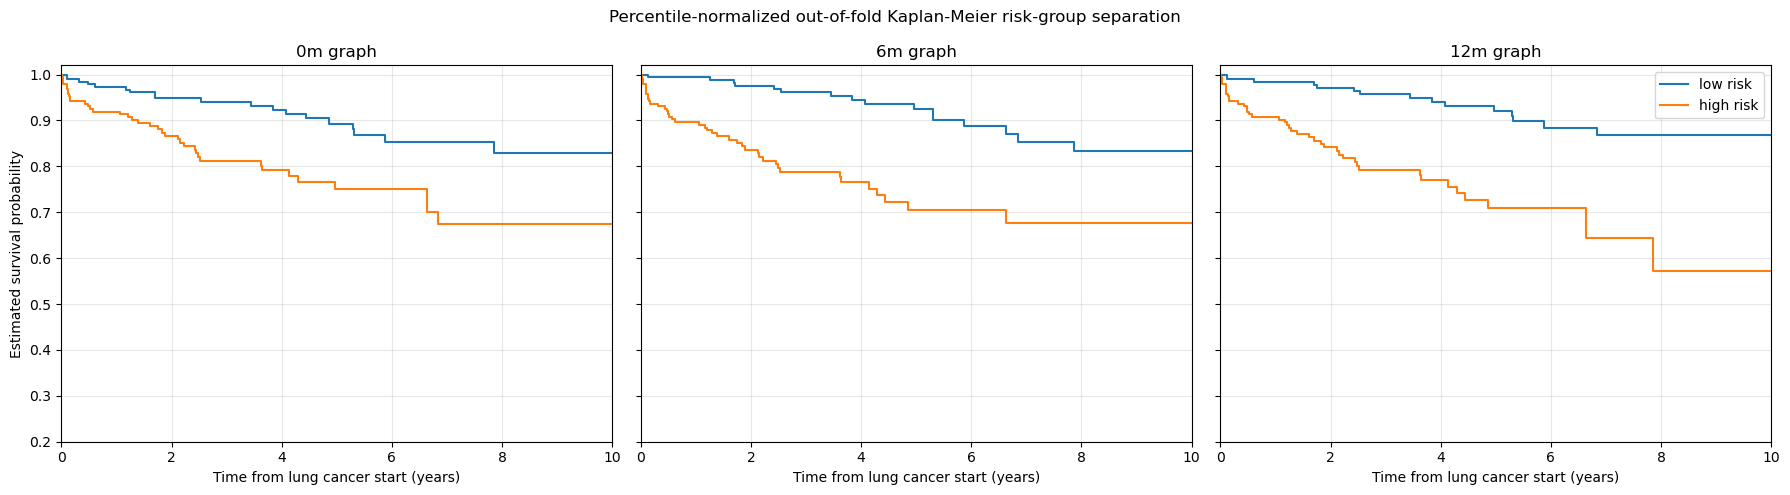

Percentile-normalized OOF horizon-specific AUC:


,graph_window,horizon_years,auc,n_evaluable,n_events_by_horizon
0,0m,1.0,0.690,338,20
1,0m,3.0,0.748,253,40
2,0m,5.0,0.754,170,50
3,6m,1.0,0.795,338,20
4,6m,3.0,0.812,253,40
5,6m,5.0,0.834,170,50
6,12m,1.0,0.757,338,20
7,12m,3.0,0.796,253,40
8,12m,5.0,0.821,170,50


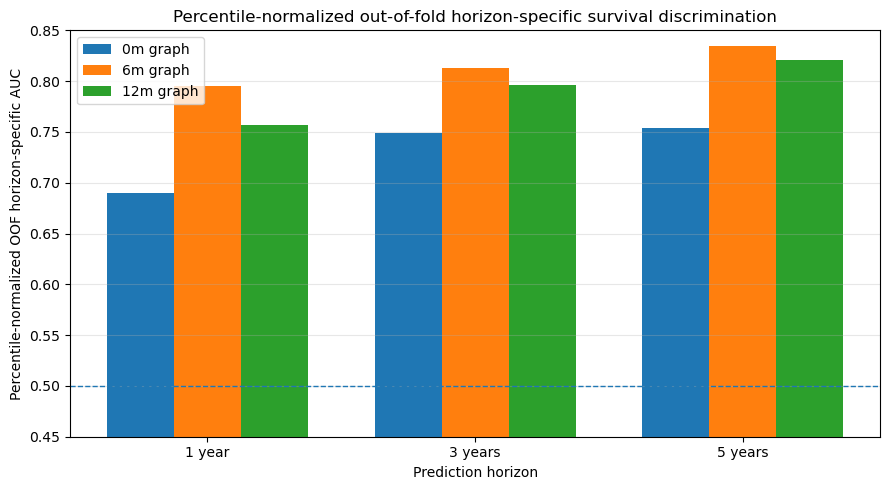

In [26]:
# ------------------------------------------------------------
# E3. Figures — exact style of the final 5-fold CV OOF plots (cells 641/643)
# ------------------------------------------------------------
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# KM estimator + rank AUC (same as the GNN)
if "compute_km_curve" not in globals():
    def compute_km_curve(times, events):
        times = pd.Series(times).astype(float).tolist()
        events = pd.Series(events).astype(int).tolist()
        uniq = sorted(set(times[i] for i in range(len(times)) if events[i] == 1))
        S = 1.0; rows = [{"time": 0.0, "survival_probability": 1.0}]
        for t in uniq:
            n = sum(x >= t for x in times)
            d = sum((times[i] == t) and (events[i] == 1) for i in range(len(times)))
            if n > 0: S *= (1 - d / n)
            rows.append({"time": t, "survival_probability": S})
        return pd.DataFrame(rows)

def compute_binary_auc_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int); scores = np.asarray(scores, dtype=float)
    n_pos = int((y_true == 1).sum()); n_neg = int((y_true == 0).sum())
    if n_pos == 0 or n_neg == 0: return np.nan
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    return float((ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

POOLED_RISK_SCORE_COL = "risk_percentile"   # fold-normalized percentile from E1

# risk groups (median split on the percentile)
km_pred = oof_df.copy()
km_pred["risk_group"] = np.where(km_pred[POOLED_RISK_SCORE_COL] > 0.5, "high_risk", "low_risk")

km_summary_df = (
    km_pred.groupby(["graph_window", "risk_group"], as_index=False)
    .agg(n_patients=("person_node_index", "count"), n_events=("event_death", "sum"),
         event_rate=("event_death", "mean"),
         mean_foldwise_risk_percentile=("risk_percentile", "mean"))
)
print("Percentile-normalized OOF KM risk-group summary:")
display(km_summary_df.round(3))

# ---- KM: single 1x3 panel (exact cell-641 style) ----
fig_km, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, graph_window in zip(axes, TABULAR_GRAPH_WINDOWS):
    for risk_group in ["low_risk", "high_risk"]:
        g = km_pred[(km_pred["graph_window"] == graph_window) & (km_pred["risk_group"] == risk_group)]
        c = compute_km_curve(g["survival_time_years"], g["event_death"])
        ax.step(c["time"], c["survival_probability"], where="post", label=risk_group.replace("_", " "))
    ax.set_title(f"{graph_window} graph")
    ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0, 10); ax.set_ylim(0.2, 1.02); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Estimated survival probability")
axes[-1].legend(loc="best")
fig_km.suptitle("Percentile-normalized out-of-fold Kaplan-Meier risk-group separation")
plt.tight_layout(); plt.show()

# ---- Horizon AUC: pooled, grouped bars, NO error bars (exact cell-643 style) ----
HORIZON_YEARS = [1.0, 3.0, 5.0]
rows = []
for graph_window in TABULAR_GRAPH_WINDOWS:
    w = oof_df[oof_df["graph_window"] == graph_window].copy()
    for horizon in HORIZON_YEARS:
        lab = pd.Series(np.nan, index=w.index)
        lab[(w["event_death"] == 1) & (w["survival_time_years"] <= horizon)] = 1
        lab[w["survival_time_years"] > horizon] = 0
        usable = w[lab.notna()]
        rows.append({"graph_window": graph_window, "horizon_years": horizon,
                     "auc": compute_binary_auc_from_scores(lab[lab.notna()], usable[POOLED_RISK_SCORE_COL]),
                     "n_evaluable": len(usable),
                     "n_events_by_horizon": int((lab.dropna() == 1).sum())})
horizon_auc_df = pd.DataFrame(rows)
print("Percentile-normalized OOF horizon-specific AUC:")
display(horizon_auc_df.round(3))

fig_auc, ax = plt.subplots(figsize=(9, 5))
x_positions = range(len(HORIZON_YEARS)); bar_width = 0.25
window_offsets = {"0m": -bar_width, "6m": 0.0, "12m": bar_width}
for graph_window in TABULAR_GRAPH_WINDOWS:
    wdf = horizon_auc_df[horizon_auc_df["graph_window"] == graph_window]
    xs = [i + window_offsets[graph_window] for i in x_positions]
    ax.bar(xs, wdf["auc"], width=bar_width, label=f"{graph_window} graph")
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xticks(list(x_positions))
ax.set_xticklabels([f"{int(h)} year" if h == 1.0 else f"{int(h)} years" for h in HORIZON_YEARS])
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("Percentile-normalized OOF horizon-specific AUC")
ax.set_xlabel("Prediction horizon")
ax.set_title("Percentile-normalized out-of-fold horizon-specific survival discrimination")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# extreme-risk thirds table (for saving)
rows = []
for graph_window in TABULAR_GRAPH_WINDOWS:
    s = oof_df[oof_df["graph_window"] == graph_window]
    top = s[s[POOLED_RISK_SCORE_COL] > 2/3]; bot = s[s[POOLED_RISK_SCORE_COL] < 1/3]
    rows.append({"graph_window": graph_window, "top_third_rate": top["event_death"].mean(),
                 "top_n": len(top), "bottom_third_rate": bot["event_death"].mean(), "bottom_n": len(bot)})
extreme_df = pd.DataFrame(rows)

In [27]:
# ------------------------------------------------------------
# E4. Save complementary figures + tables to the bucket
# ------------------------------------------------------------
import os
from datetime import datetime

comp_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
base = clinical_enriched_dir if "clinical_enriched_dir" in globals() else model_ready_dir
comp_dir = f"{base}/tabular_cox_complementary_{comp_ts}"
os.makedirs(comp_dir, exist_ok=True)
print("Output folder:", comp_dir)

# figures
km_png = os.path.join(comp_dir, f"tabular_oof_km_risk_group_curves_{comp_ts}.png")
auc_png = os.path.join(comp_dir, f"tabular_oof_horizon_auc_{comp_ts}.png")
fig_km.savefig(km_png, dpi=300, bbox_inches="tight")
fig_auc.savefig(auc_png, dpi=300, bbox_inches="tight")

# tables
tables = {
    f"tabular_oof_predictions_with_percentiles_{comp_ts}.csv": oof_df,
    f"tabular_oof_km_risk_group_summary_{comp_ts}.csv": km_summary_df,
    f"tabular_oof_extreme_risk_thirds_{comp_ts}.csv": extreme_df,
    f"tabular_oof_horizon_auc_{comp_ts}.csv": horizon_auc_df,
}
for name, frame in tables.items():
    frame.to_csv(os.path.join(comp_dir, name), index=False)

print("Saved figures:")
print(" ", km_png)
print(" ", auc_png)
print("Saved tables:")
for name in tables:
    print(" ", os.path.join(comp_dir, name))

Output folder: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_complementary_20260719_114912
Saved figures:
  /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_complementary_20260719_114912/tabular_oof_km_risk_group_curves_20260719_114912.png
  /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/model_ready_survival_resources/tabular_cox_complementary_20260719_114912/tabular_oof_horizon_auc_20260719_114912.png
Saved tables:
  /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20

## Intermediate Knowledge Graph — Setup and Resource Loading

This notebook prepares everything needed to build the **intermediate lung-cancer KG**: a
deliberately reduced graph that keeps only the parts relevant to our research question, so
we can test whether the graph structure adds anything over the simple tabular baseline.

**What the intermediate graph will be (built in the next section):**

- **`Person`** — kept, node features untouched.
- **26 clinical feature nodes** (`ConditionFeature`, `DrugFeature`, `ProcedureFeature`,
  `SmokingFeature`) — kept as-is.
- **`Sex`** — 2 shared category nodes (Male / Female), `Person -> Sex` edges.
- **`AgeGroup`** — shared decade nodes (20s, 30s, ..., 90s) from age at diagnosis,
  `Person -> AgeGroup` edges.
- **Dropped:** genomic (`SNP` / `Gene` / `Chromosome`), SDOH, `IncidenceRate`,
  `Race` / `Ethnicity`, and the original fine-grained `Age` / `Gender` node types.

**This notebook only loads resources, and it reuses the baseline session.** It does *not*
re-query BigQuery or recompute age/sex — it reuses `age_decades_by_person` and
`sex_female_by_person` already computed in the tabular baseline (age at diagnosis). Run this
in the **same kernel** right after the baseline + demographic steps.

### Step 1 — Confirm the Base Resources from the Baseline Session

We reuse the objects already in memory from the baseline: the three clinical-enriched graph
windows, the clinical feature domain definitions, the survival target tensors, the patient
mapping, and the age/sex arrays. If a graph is not in memory we reload it from the bucket.

In [29]:
# ------------------------------------------------------------
# INT-1. Confirm base resources (reuse the baseline session)
# ------------------------------------------------------------
import numpy as np
import pandas as pd

# --- Objects we expect from the baseline + demographic steps ---
required_from_baseline = [
    "clinical_feature_domains",     # {node_type: [feature_name, ...]}
    "survival_time_years_tensor",   # aligned to Person node index
    "event_death_tensor",           # aligned to Person node index
    "survival_target_df",           # person_id <-> lung_subgraph_person_idx
    "age_decades_by_person",        # baseline: age AT DIAGNOSIS / 10, Person-index order
    "sex_female_by_person",         # baseline: 1 = female, Person-index order
]
missing = [name for name in required_from_baseline if name not in globals()]
if missing:
    raise NameError(
        "Missing baseline objects: " + str(missing) +
        ". Run the tabular baseline (T1-T7) and the demographic steps (D1, D1b, D2) "
        "in this session first — this notebook reuses their age/sex and resources."
    )

n_person_nodes = int(len(survival_time_years_tensor))
assert len(age_decades_by_person) == n_person_nodes
assert len(sex_female_by_person) == n_person_nodes

# --- Base graphs: reuse from memory, else load from the bucket ---
INT_GRAPH_WINDOWS = ["0m", "6m", "12m"]
int_base_graphs_by_window = {}

for source_name in ["clinical_enriched_graphs_by_window", "tabular_graphs_by_window",
                    "cv_graphs_by_window"]:
    if source_name in globals() and isinstance(globals()[source_name], dict):
        src = globals()[source_name]
        for window in INT_GRAPH_WINDOWS:
            for key in (window, int(window.replace("m", ""))):
                if key in src:
                    int_base_graphs_by_window[window] = src[key]
        if len(int_base_graphs_by_window) == len(INT_GRAPH_WINDOWS):
            print(f"Using base graphs from {source_name} (already in memory).")
            break

if len(int_base_graphs_by_window) != len(INT_GRAPH_WINDOWS):
    import torch
    if "graph_paths_by_window" not in globals() or "fs" not in globals():
        raise NameError("Graphs not in memory and graph_paths_by_window / fs are missing. "
                        "Run the baseline reload cell first.")
    print("Loading base graphs from graph_paths_by_window ...")
    for window in INT_GRAPH_WINDOWS:
        with fs.open(graph_paths_by_window[window], "rb") as f:
            int_base_graphs_by_window[window] = torch.load(f, map_location="cpu", weights_only=False)

for window, g in int_base_graphs_by_window.items():
    assert g["Person"].num_nodes == n_person_nodes
    print(f"{window} base graph | node types={len(g.node_types)}, edge types={len(g.edge_types)}")

print("\nPatients:", n_person_nodes, "| observed deaths:", int(event_death_tensor.sum().item()))
print("Clinical feature domains:")
for node_type, feature_names in clinical_feature_domains.items():
    print(f"  {node_type}: {len(feature_names)} features")


Using base graphs from tabular_graphs_by_window (already in memory).
0m base graph | node types=64, edge types=126
6m base graph | node types=64, edge types=126
12m base graph | node types=64, edge types=126

Patients: 379 | observed deaths: 60
Clinical feature domains:
  ConditionFeature: 12 features
  DrugFeature: 6 features
  ProcedureFeature: 5 features
  SmokingFeature: 3 features


### Step 2 — Age Decade Groups (Tails Merged) and Sex Categories

We reuse the baseline's age at diagnosis (`age_decades_by_person`) and sex
(`sex_female_by_person`) — no re-query, no recomputation — and turn them into the
per-patient category labels that will become shared `AgeGroup` and `Sex` nodes.

**Why the tails are merged.** Pure decade bins left two very thin groups: **20s = 4** and
**90s = 3** patients. A shared `AgeGroup` node linking only 3–4 patients is a weak, noisy
grouping whose embedding is driven by a handful of people — a likely spot for overfitting
in a 60-event cohort. We therefore merge the sparse ends into **`<40`** (20s + 30s) and
**`80+`** (80s + 90s), giving **6 age-group nodes** — `<40`, `40s`, `50s`, `60s`, `70s`,
`80+` — each with at least ~22 patients. Full decade resolution is kept where the data is
dense (50s / 60s / 70s), and the extremes remain clinically sensible buckets (young-onset
lung cancer / elderly).

This choice affects **only the graph**: the tabular baseline still uses continuous age, so
nothing there changes. As noted earlier, the two models encode age differently by design
(categorical decade-group nodes in the GNN, a continuous per-decade covariate in the Cox),
which we document rather than force to match.

In [31]:
# ------------------------------------------------------------
# INT-2. Decade age groups (tails merged -> 6 groups) + sex categories
# ------------------------------------------------------------

# Reuse baseline age at diagnosis (age_decades = age_at_dx / 10) and sex.
age_at_dx_years_by_person = [float(d) * 10.0 for d in age_decades_by_person]

def age_to_group(a):
    if a < 40:  return "<40"      # merges 20s + 30s
    if a < 50:  return "40s"
    if a < 60:  return "50s"
    if a < 70:  return "60s"
    if a < 80:  return "70s"
    return "80+"                  # merges 80s + 90s

age_group_by_person = [age_to_group(a) for a in age_at_dx_years_by_person]
sex_group_by_person = ["Female" if int(s) == 1 else "Male" for s in sex_female_by_person]

demo_labels_df = pd.DataFrame({
    "lung_subgraph_person_idx": range(n_person_nodes),
    "age_at_dx_years": age_at_dx_years_by_person,
    "age_group": age_group_by_person,
    "sex": sex_group_by_person,
})

# Ordered category lists for building the shared nodes next
AGE_GROUP_CATEGORIES = ["<40", "40s", "50s", "60s", "70s", "80+"]
SEX_CATEGORIES = ["Male", "Female"]

print("Age at diagnosis (years) — reused from baseline:")
print(demo_labels_df["age_at_dx_years"].describe().round(1))

print("\nAgeGroup distribution (6 groups, tails merged):")
print(demo_labels_df["age_group"].value_counts().reindex(AGE_GROUP_CATEGORIES))

print("\nSex distribution:")
print(demo_labels_df["sex"].value_counts())

print("\nAgeGroup nodes to create:", AGE_GROUP_CATEGORIES)
print("Sex nodes to create:", SEX_CATEGORIES)

# sanity: every patient got a valid group, no NaN
assert demo_labels_df["age_group"].isin(AGE_GROUP_CATEGORIES).all()
assert demo_labels_df["sex"].isin(SEX_CATEGORIES).all()
print("\nReady — 6 AgeGroup nodes + 2 Sex nodes to build in the next step.")

Age at diagnosis (years) — reused from baseline:
count    379.0
mean      63.7
std       12.6
min       20.4
25%       56.7
50%       65.0
75%       72.7
max       92.2
Name: age_at_dx_years, dtype: float64

AgeGroup distribution (6 groups, tails merged):
age_group
<40     22
40s     29
50s     82
60s    121
70s     98
80+     27
Name: count, dtype: int64

Sex distribution:
sex
Female    222
Male      157
Name: count, dtype: int64

AgeGroup nodes to create: ['<40', '40s', '50s', '60s', '70s', '80+']
Sex nodes to create: ['Male', 'Female']

Ready — 6 AgeGroup nodes + 2 Sex nodes to build in the next step.


### Intermediate Knowledge Graph — Construction

We build the reduced intermediate graph from the clinical-enriched base graphs loaded in
the setup notebook. For each window (`0m` / `6m` / `12m`) we:

1. **Keep** `Person` (features untouched) and the 4 clinical feature node types
   (`ConditionFeature`, `DrugFeature`, `ProcedureFeature`, `SmokingFeature`) with their
   `Person <-> Feature` edges.
2. **Add** two shared categorical node types:
   - `Sex` — 2 nodes (Male / Female), `Person -> Sex` edges.
   - `AgeGroup` — 6 nodes (`<40`, `40s`, `50s`, `60s`, `70s`, `80+`), `Person -> AgeGroup`
     edges (built from age at diagnosis, tails merged).
3. **Drop** everything else (genomic, SDOH, `IncidenceRate`, `Race`/`Ethnicity`, and the
   original fine-grained `Age`/`Gender` node types).

Representing `Sex` and `AgeGroup` as **shared** nodes keeps `Person` pure, routes the
demographics through message passing, and lets the model borrow strength across patients
with the same sex / age decade.

**Prerequisite:** run the setup/loading notebook first (in the same kernel), so that
`int_base_graphs_by_window`, `sex_group_by_person`, `age_group_by_person`,
`AGE_GROUP_CATEGORIES`, `SEX_CATEGORIES`, `n_person_nodes`, `clinical_feature_domains`,
`fs`, and `graph_paths_by_window` are available.

### Step 1 — Builder: Subset Kept Nodes/Edges and Add Shared Sex / AgeGroup Nodes

In [33]:
# ------------------------------------------------------------
# INT-C1. Intermediate graph builder
# ------------------------------------------------------------
import torch
from torch_geometric.data import HeteroData

# --- guard prerequisites from the setup notebook ---
for obj_name in ["int_base_graphs_by_window", "sex_group_by_person", "age_group_by_person",
                 "AGE_GROUP_CATEGORIES", "SEX_CATEGORIES", "n_person_nodes",
                 "clinical_feature_domains"]:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is missing. Run the setup/loading notebook first.")

INT_GRAPH_WINDOWS = list(int_base_graphs_by_window.keys())
FEATURE_NODE_TYPES = list(clinical_feature_domains.keys())   # the 4 clinical feature types
KEEP_NODE_TYPES = ["Person"] + FEATURE_NODE_TYPES

# relation names for the two new demographic node types
SEX_RELATION = "HAS_SEX"
AGE_GROUP_RELATION = "HAS_AGE_GROUP"

# per-patient category indices (aligned to Person node index)
sex_idx_by_person = [SEX_CATEGORIES.index(g) for g in sex_group_by_person]
age_group_idx_by_person = [AGE_GROUP_CATEGORIES.index(g) for g in age_group_by_person]
person_indices = list(range(n_person_nodes))


def make_edge_index(src_list, dst_list):
    if len(src_list) == 0:
        return torch.empty((2, 0), dtype=torch.long)
    return torch.tensor([src_list, dst_list], dtype=torch.long)


def build_intermediate_graph(base_graph):
    out = HeteroData()

    # 1) copy kept node stores (Person + clinical feature types)
    keepset = set(KEEP_NODE_TYPES)
    for nt in KEEP_NODE_TYPES:
        if nt not in base_graph.node_types:
            raise KeyError(f"Expected node type '{nt}' missing in base graph.")
        out[nt].num_nodes = int(base_graph[nt].num_nodes)
        store = base_graph[nt]
        if hasattr(store, "x") and store.x is not None:
            out[nt].x = store.x.clone()

    # 2) copy kept edges (both endpoints kept) -> Person <-> clinical feature edges
    n_edge_types_copied = 0
    for edge_type in base_graph.edge_types:
        s, r, d = edge_type
        if s in keepset and d in keepset:
            out[edge_type].edge_index = base_graph[edge_type].edge_index.clone()
            n_edge_types_copied += 1

    # 3) add Sex node type + Person<->Sex edges
    out["Sex"].num_nodes = len(SEX_CATEGORIES)
    out["Sex"].x = torch.eye(len(SEX_CATEGORIES), dtype=torch.float32)
    out[("Person", SEX_RELATION, "Sex")].edge_index = make_edge_index(person_indices, sex_idx_by_person)
    out[("Sex", SEX_RELATION + "_rev", "Person")].edge_index = make_edge_index(sex_idx_by_person, person_indices)

    # 4) add AgeGroup node type + Person<->AgeGroup edges
    out["AgeGroup"].num_nodes = len(AGE_GROUP_CATEGORIES)
    out["AgeGroup"].x = torch.eye(len(AGE_GROUP_CATEGORIES), dtype=torch.float32)
    out[("Person", AGE_GROUP_RELATION, "AgeGroup")].edge_index = make_edge_index(person_indices, age_group_idx_by_person)
    out[("AgeGroup", AGE_GROUP_RELATION + "_rev", "Person")].edge_index = make_edge_index(age_group_idx_by_person, person_indices)

    return out, n_edge_types_copied


print("Builder ready.")
print("Keep node types:", KEEP_NODE_TYPES)
print("Add node types: ['Sex' (2), 'AgeGroup' (%d)]" % len(AGE_GROUP_CATEGORIES))
print("Sex categories:", SEX_CATEGORIES)
print("AgeGroup categories:", AGE_GROUP_CATEGORIES)


Builder ready.
Keep node types: ['Person', 'ConditionFeature', 'DrugFeature', 'ProcedureFeature', 'SmokingFeature']
Add node types: ['Sex' (2), 'AgeGroup' (6)]
Sex categories: ['Male', 'Female']
AgeGroup categories: ['<40', '40s', '50s', '60s', '70s', '80+']


### Step 2 — Build the Three Intermediate Graph Windows

In [34]:
# ------------------------------------------------------------
# INT-C2. Build 0m / 6m / 12m intermediate graphs
# ------------------------------------------------------------
intermediate_graphs_by_window = {}

for window in INT_GRAPH_WINDOWS:
    g, n_clin_edge_types = build_intermediate_graph(int_base_graphs_by_window[window])
    intermediate_graphs_by_window[window] = g
    total_edges = sum(g[et].edge_index.size(1) for et in g.edge_types)
    print(f"{window} intermediate graph | node types={len(g.node_types)}, "
          f"edge types={len(g.edge_types)} (clinical kept={n_clin_edge_types}), "
          f"total edges={total_edges}")


0m intermediate graph | node types=7, edge types=12 (clinical kept=8), total edges=5708
6m intermediate graph | node types=7, edge types=12 (clinical kept=8), total edges=6666
12m intermediate graph | node types=7, edge types=12 (clinical kept=8), total edges=6878


### Step 3 — Validate the Intermediate Graphs

We confirm the node types are exactly what we intended, that `Person` still has 379 nodes,
that every patient has **exactly one** `Sex` edge and **exactly one** `AgeGroup` edge, and
that the clinical feature edges were preserved unchanged from the base graph.

In [35]:
# ------------------------------------------------------------
# INT-C3. Validation
# ------------------------------------------------------------
EXPECTED_NODE_TYPES = set(KEEP_NODE_TYPES) | {"Sex", "AgeGroup"}

for window in INT_GRAPH_WINDOWS:
    g = intermediate_graphs_by_window[window]
    base = int_base_graphs_by_window[window]

    # node types are exactly the intended set
    assert set(g.node_types) == EXPECTED_NODE_TYPES, (
        f"{window}: unexpected node types {set(g.node_types) ^ EXPECTED_NODE_TYPES}"
    )
    assert g["Person"].num_nodes == n_person_nodes
    assert g["Sex"].num_nodes == len(SEX_CATEGORIES)
    assert g["AgeGroup"].num_nodes == len(AGE_GROUP_CATEGORIES)

    # each patient has exactly one Sex edge and one AgeGroup edge
    sex_ei = g[("Person", SEX_RELATION, "Sex")].edge_index
    age_ei = g[("Person", AGE_GROUP_RELATION, "AgeGroup")].edge_index
    assert sex_ei.size(1) == n_person_nodes and age_ei.size(1) == n_person_nodes
    assert sorted(sex_ei[0].tolist()) == person_indices
    assert sorted(age_ei[0].tolist()) == person_indices

    # clinical feature edges preserved (same count as the base graph)
    def clin_edge_count(graph):
        total = 0
        for et in graph.edge_types:
            s, r, d = et
            if s == "Person" and d in FEATURE_NODE_TYPES:
                total += graph[et].edge_index.size(1)
        return total
    assert clin_edge_count(g) == clin_edge_count(base), f"{window}: clinical edges changed"

    # group-size sanity (Sex / AgeGroup node degree = patients per category)
    import numpy as np
    sex_counts = np.bincount(sex_ei[1].numpy(), minlength=len(SEX_CATEGORIES))
    age_counts = np.bincount(age_ei[1].numpy(), minlength=len(AGE_GROUP_CATEGORIES))
    print(f"{window}: Sex sizes", dict(zip(SEX_CATEGORIES, sex_counts.tolist())),
          "| AgeGroup sizes", dict(zip(AGE_GROUP_CATEGORIES, age_counts.tolist())))

print("\nAll validation checks passed.")


0m: Sex sizes {'Male': 157, 'Female': 222} | AgeGroup sizes {'<40': 22, '40s': 29, '50s': 82, '60s': 121, '70s': 98, '80+': 27}
6m: Sex sizes {'Male': 157, 'Female': 222} | AgeGroup sizes {'<40': 22, '40s': 29, '50s': 82, '60s': 121, '70s': 98, '80+': 27}
12m: Sex sizes {'Male': 157, 'Female': 222} | AgeGroup sizes {'<40': 22, '40s': 29, '50s': 82, '60s': 121, '70s': 98, '80+': 27}

All validation checks passed.


#### Step 3b — Time-Window Integrity of the Clinical Features

Because the intermediate graphs must carry the **correct time-windowed** clinical features,
we verify that each window's `Person -> Feature` edges are exactly those of its own base
graph, and that the counts are cumulative across windows (condition / drug / procedure
non-decreasing 0m -> 6m -> 12m; smoking constant). These counts should match the tabular
baseline (ConditionFeature 1325 / 1503 / 1573, DrugFeature 67 / 175 / 187,
ProcedureFeature 325 / 518 / 542, SmokingFeature 379 / 379 / 379).

In [36]:
# ------------------------------------------------------------
# INT-C3b. Time-window integrity: clinical feature edge counts per window
# ------------------------------------------------------------
import pandas as pd

def domain_edge_counts(graph):
    counts = {}
    for domain in FEATURE_NODE_TYPES:
        tot = 0
        for et in graph.edge_types:
            s, r, d = et
            if s == "Person" and d == domain:
                tot += graph[et].edge_index.size(1)
        counts[domain] = tot
    return counts

rows = []
for window in INT_GRAPH_WINDOWS:
    inter = domain_edge_counts(intermediate_graphs_by_window[window])
    base = domain_edge_counts(int_base_graphs_by_window[window])
    for domain in FEATURE_NODE_TYPES:
        assert inter[domain] == base[domain], (
            f"{window}/{domain}: intermediate {inter[domain]} != base {base[domain]}"
        )
        rows.append({"window": window, "domain": domain, "edges": inter[domain]})

edge_count_table = pd.DataFrame(rows).pivot(index="domain", columns="window", values="edges")[["0m", "6m", "12m"]]
print("Clinical Person->Feature edge counts per window (intermediate == base):")
display(edge_count_table)

# cumulative: condition/drug/procedure non-decreasing; smoking constant
for domain in FEATURE_NODE_TYPES:
    vals = [int(edge_count_table.loc[domain, w]) for w in ["0m", "6m", "12m"]]
    if domain == "SmokingFeature":
        assert len(set(vals)) == 1, f"Smoking should be constant across windows, got {vals}"
    else:
        assert vals[0] <= vals[1] <= vals[2], f"{domain} not cumulative across windows: {vals}"

print("\\nTime-window integrity confirmed: clinical features are cumulative "
      "(0m <= 6m <= 12m) and smoking is constant.")


Clinical Person->Feature edge counts per window (intermediate == base):


window,0m,6m,12m
domain,,,
ConditionFeature,1325,1503,1573
DrugFeature,67,175,187
ProcedureFeature,325,518,542
SmokingFeature,379,379,379


\nTime-window integrity confirmed: clinical features are cumulative (0m <= 6m <= 12m) and smoking is constant.


### Step 4 — Save the Intermediate Graphs to the Bucket

We save the three intermediate graph windows plus a small metadata file and the per-patient
demographic labels. `intermediate_graph_paths_by_window` can be used by the next section to
run the 5-fold CV on these graphs.

In [37]:
# ------------------------------------------------------------
# INT-C4. Save intermediate graphs + metadata
# ------------------------------------------------------------
import os
import json
from datetime import datetime

int_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# save next to the clinical-enriched artifacts (parent of the base graph files)
base_dir = os.path.dirname(graph_paths_by_window["0m"])
intermediate_dir = f"{base_dir}/intermediate_graph_clinical_demographic_{int_timestamp}"
if hasattr(fs, "makedirs"):
    fs.makedirs(intermediate_dir, exist_ok=True)
else:
    os.makedirs(intermediate_dir, exist_ok=True)

intermediate_graph_paths_by_window = {}
for window in INT_GRAPH_WINDOWS:
    path = f"{intermediate_dir}/lung_subgraph_intermediate_{window}.pt"
    with fs.open(path, "wb") as f:
        torch.save(intermediate_graphs_by_window[window], f)
    intermediate_graph_paths_by_window[window] = path
    print("Saved:", path)

# metadata
metadata = {
    "created_at": int_timestamp,
    "description": "Intermediate lung-cancer KG: Person + 26 clinical feature nodes + shared Sex + AgeGroup nodes.",
    "kept_node_types": KEEP_NODE_TYPES,
    "added_node_types": {"Sex": SEX_CATEGORIES, "AgeGroup": AGE_GROUP_CATEGORIES},
    "sex_relation": SEX_RELATION,
    "age_group_relation": AGE_GROUP_RELATION,
    "age_group_definition": "decade of age at diagnosis; tails merged (<40 = 20s+30s, 80+ = 80s+90s)",
    "windows": INT_GRAPH_WINDOWS,
    "graph_paths_by_window": intermediate_graph_paths_by_window,
    "n_person_nodes": n_person_nodes,
}
meta_path = f"{intermediate_dir}/metadata.json"
with fs.open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved:", meta_path)

# per-patient demographic labels (aligned to Person node index)
labels_path = f"{intermediate_dir}/intermediate_demo_labels.csv"
with fs.open(labels_path, "w") as f:
    demo_labels_df.to_csv(f, index=False)
print("Saved:", labels_path)

print("\nIntermediate graphs ready. Use `intermediate_graph_paths_by_window` for the 5-fold CV.")


Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/lung_subgraph_intermediate_0m.pt
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/lung_subgraph_intermediate_6m.pt
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/lung_subgraph_intermediate_12m.pt
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/

### Intermediate Graph — 5-Fold Cross-Validation (HeteroGraphSAGE-Cox)

We run the **identical** GNN pipeline used for the final full-graph CV — the same
`HeteroGraphSAGE-Cox` model, the same config **K** (hidden 32, dropout 0.20, weight-decay
1e-5), the same stratified 5-fold split (seed 42), and the same Harrell + IPCW metrics — but
on the **intermediate graphs** (Person + 26 clinical feature nodes + shared Sex + AgeGroup).
The model / loss / metric / CV-training cells below are copied verbatim from the main
notebook so the only thing that changes is the input graph.

**Prerequisite:** run this in the same kernel as the intermediate construction (so
`intermediate_graphs_by_window` or `intermediate_graph_paths_by_window`,
`survival_time_years_tensor`, `event_death_tensor`, and `fs` are available).

### Step 1 — Model, Cox loss, evaluation

In [38]:
# ------------------------------------------------------------
# copy of 12.9.3 Define HeteroGraphSAGE-Cox model utilities
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import HeteroConv, SAGEConv, Linear


# ------------------------------------------------------------
# 1. Model definition
# ------------------------------------------------------------

class HeteroGraphSAGECox(nn.Module):
    def __init__(
        self,
        data,
        hidden_channels=32,
        num_layers=1,
        dropout=0.20,
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_layers = num_layers
        self.dropout = dropout

        self.node_types = list(data.node_types)
        self.edge_types = list(data.edge_types)

        # Input projection for node types with explicit x.
        # Learnable embedding for node types without x.
        self.input_proj = nn.ModuleDict()
        self.node_embeddings = nn.ModuleDict()

        for node_type in self.node_types:
            store = data[node_type]
            has_x = hasattr(store, "x") and store.x is not None

            if has_x:
                in_channels = int(store.x.size(-1))
                self.input_proj[node_type] = Linear(
                    in_channels,
                    hidden_channels,
                )
            else:
                self.node_embeddings[node_type] = nn.Embedding(
                    int(store.num_nodes),
                    hidden_channels,
                )

        self.convs = nn.ModuleList()

        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv(
                        (-1, -1),
                        hidden_channels,
                    )
                    for edge_type in self.edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.risk_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def build_initial_x_dict(self, data):
        x_dict = {}

        for node_type in self.node_types:
            store = data[node_type]
            has_x = hasattr(store, "x") and store.x is not None

            if has_x:
                x = store.x
                if not torch.is_floating_point(x):
                    x = x.float()

                x_dict[node_type] = self.input_proj[node_type](x)
            else:
                node_ids = torch.arange(
                    store.num_nodes,
                    device=next(self.parameters()).device,
                    dtype=torch.long,
                )
                x_dict[node_type] = self.node_embeddings[node_type](node_ids)

        return x_dict

    def forward(self, data):
        x_dict = self.build_initial_x_dict(data)
        edge_index_dict = data.edge_index_dict

        for conv in self.convs:
            conv_out = conv(x_dict, edge_index_dict)

            # HeteroConv may only return node types that received messages.
            # For node types not returned, keep previous representation.
            new_x_dict = {}

            for node_type in self.node_types:
                if node_type in conv_out:
                    new_x_dict[node_type] = F.relu(conv_out[node_type])
                else:
                    new_x_dict[node_type] = x_dict[node_type]

                new_x_dict[node_type] = F.dropout(
                    new_x_dict[node_type],
                    p=self.dropout,
                    training=self.training,
                )

            x_dict = new_x_dict

        person_embeddings = x_dict["Person"]
        risk_scores = self.risk_head(person_embeddings).view(-1)

        return risk_scores, person_embeddings


# ------------------------------------------------------------
# 2. Cox partial likelihood loss
# ------------------------------------------------------------

def cox_partial_likelihood_loss(risk_scores, survival_times, event_indicators):
    """
    Negative Cox partial log-likelihood.

    risk_scores:
        Higher score = higher predicted hazard.

    survival_times:
        Observed time until death or censoring.

    event_indicators:
        1 = observed death, 0 = censored.
    """

    risk_scores = risk_scores.view(-1)
    survival_times = survival_times.view(-1)
    event_indicators = event_indicators.view(-1)

    event_mask = event_indicators > 0

    if int(event_mask.sum().item()) == 0:
        raise ValueError("Cox loss cannot be computed with zero observed events.")

    # Sort by decreasing observed time.
    # The risk set for each event contains patients with time >= event time.
    order = torch.argsort(survival_times, descending=True)

    sorted_risk = risk_scores[order]
    sorted_events = event_indicators[order]

    log_cumulative_risk = torch.logcumsumexp(sorted_risk, dim=0)

    event_log_likelihood = (
        sorted_risk[sorted_events > 0]
        - log_cumulative_risk[sorted_events > 0]
    )

    negative_log_likelihood = -event_log_likelihood.mean()

    return negative_log_likelihood


# ------------------------------------------------------------
# 3. Concordance index for survival risk ranking
# ------------------------------------------------------------

def concordance_index_torch(risk_scores, survival_times, event_indicators):
    """
    Simple C-index implementation for right-censored data.

    A pair is comparable if patient i had an observed event before patient j's
    observed/censored time. The prediction is concordant if risk_i > risk_j.
    """

    risk_scores = risk_scores.detach().cpu().view(-1)
    survival_times = survival_times.detach().cpu().view(-1)
    event_indicators = event_indicators.detach().cpu().view(-1)

    n = int(risk_scores.numel())

    concordant = 0.0
    permissible = 0.0

    for i in range(n):
        if float(event_indicators[i].item()) != 1.0:
            continue

        time_i = float(survival_times[i].item())
        risk_i = float(risk_scores[i].item())

        for j in range(n):
            if i == j:
                continue

            time_j = float(survival_times[j].item())
            risk_j = float(risk_scores[j].item())

            if time_i < time_j:
                permissible += 1.0

                if risk_i > risk_j:
                    concordant += 1.0
                elif risk_i == risk_j:
                    concordant += 0.5

    if permissible == 0:
        return None

    return concordant / permissible


# ------------------------------------------------------------
# 4. Evaluation helper
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_survival_model(model, data, survival_times, event_indicators, mask):
    model.eval()

    risk_scores, _ = model(data)

    idx = torch.where(mask)[0]

    loss = cox_partial_likelihood_loss(
        risk_scores[idx],
        survival_times[idx],
        event_indicators[idx],
    )

    c_index = concordance_index_torch(
        risk_scores[idx],
        survival_times[idx],
        event_indicators[idx],
    )

    return {
        "loss": float(loss.item()),
        "c_index": c_index,
        "n_patients": int(idx.numel()),
        "n_events": int(event_indicators[idx].sum().item()),
    }


print("HeteroGraphSAGE-Cox utilities defined.")

HeteroGraphSAGE-Cox utilities defined.


### Step 2 — Harrell + IPCW metric utilities

In [39]:
# ------------------------------------------------------------
# copy of 12.11.4A IPCW C-index utility functions
# ------------------------------------------------------------

import math
import copy
import random
import time
import datetime

import torch
import pandas as pd


def harrell_c_index_from_arrays(times, events, risks):
    """
    Harrell-style C-index for survival risk scores.

    Higher risk score means higher predicted hazard / shorter survival.
    Only pairs where the earlier observed time is an event are comparable.
    """

    n = len(times)

    concordant = 0.0
    comparable = 0.0

    for i in range(n):
        if int(events[i]) != 1:
            continue

        for j in range(n):
            if times[j] <= times[i]:
                continue

            comparable += 1.0

            if risks[i] > risks[j]:
                concordant += 1.0
            elif risks[i] == risks[j]:
                concordant += 0.5

    if comparable == 0:
        return None, 0.0

    return concordant / comparable, comparable


def fit_censoring_km(train_times, train_events):
    """
    Estimate Kaplan-Meier survival function for the censoring distribution.

    In the original survival data:
      event = 1 means observed death
      event = 0 means right-censored

    For the censoring distribution:
      censoring event = 1 when original event = 0
    """

    rows = []

    unique_times = sorted(set(float(t) for t in train_times))

    km_survival = 1.0

    for t in unique_times:
        n_at_risk = sum(float(x) >= t for x in train_times)

        n_censored_at_t = sum(
            (float(train_times[i]) == t) and (int(train_events[i]) == 0)
            for i in range(len(train_times))
        )

        if n_at_risk > 0:
            km_survival *= (1.0 - (n_censored_at_t / n_at_risk))

        rows.append({
            "time": float(t),
            "n_at_risk": int(n_at_risk),
            "n_censored_at_t": int(n_censored_at_t),
            "censoring_survival": float(km_survival),
        })

    return rows


def censoring_survival_before_time(km_rows, t, eps=1e-8):
    """
    Return G(t-) from the censoring KM table.

    We use the survival probability just before time t, which avoids
    penalizing an observed event at the same timestamp as administrative
    censoring.
    """

    g_value = 1.0

    for row in km_rows:
        if row["time"] < float(t):
            g_value = row["censoring_survival"]
        else:
            break

    if g_value < eps:
        return eps

    return g_value


def uno_ipcw_c_index_from_arrays(
    eval_times,
    eval_events,
    eval_risks,
    train_times,
    train_events,
    tau=None,
    eps=1e-8,
):
    """
    Uno-style IPCW C-index.

    Censoring weights are estimated from the training split.
    For each comparable pair where patient i has an observed event before
    patient j, the pair receives weight 1 / G(T_i-)^2.

    Higher risk score means higher predicted hazard.
    """

    if tau is None:
        tau = min(max(train_times), max(eval_times))

    km_rows = fit_censoring_km(train_times, train_events)

    weighted_concordant = 0.0
    weighted_comparable = 0.0
    n_unweighted_comparable = 0

    n = len(eval_times)

    for i in range(n):
        t_i = float(eval_times[i])
        e_i = int(eval_events[i])

        if e_i != 1:
            continue

        if t_i > tau:
            continue

        g_i = censoring_survival_before_time(km_rows, t_i, eps=eps)

        weight_i = 1.0 / (g_i ** 2)

        for j in range(n):
            t_j = float(eval_times[j])

            if t_j <= t_i:
                continue

            n_unweighted_comparable += 1
            weighted_comparable += weight_i

            if eval_risks[i] > eval_risks[j]:
                weighted_concordant += weight_i
            elif eval_risks[i] == eval_risks[j]:
                weighted_concordant += 0.5 * weight_i

    if weighted_comparable == 0:
        return {
            "ipcw_c_index": None,
            "ipcw_weighted_comparable": 0.0,
            "ipcw_unweighted_comparable": 0,
            "ipcw_tau": tau,
        }

    return {
        "ipcw_c_index": weighted_concordant / weighted_comparable,
        "ipcw_weighted_comparable": weighted_comparable,
        "ipcw_unweighted_comparable": n_unweighted_comparable,
        "ipcw_tau": tau,
    }


def evaluate_model_harrell_and_ipcw(
    model,
    graph_data,
    survival_times,
    event_indicators,
    eval_mask,
    ipcw_train_mask,
):
    """
    Evaluate one split using both Harrell C-index and IPCW C-index.

    IPCW censoring weights are estimated from the training split.
    """

    model.eval()

    with torch.no_grad():
        risk_scores, _ = model(graph_data)

    eval_idx = torch.where(eval_mask)[0]
    train_idx = torch.where(ipcw_train_mask)[0]

    eval_times = survival_times[eval_idx].detach().cpu().view(-1).tolist()
    eval_events = event_indicators[eval_idx].detach().cpu().view(-1).tolist()
    eval_risks = risk_scores[eval_idx].detach().cpu().view(-1).tolist()

    train_times = survival_times[train_idx].detach().cpu().view(-1).tolist()
    train_events = event_indicators[train_idx].detach().cpu().view(-1).tolist()

    harrell_c_index, harrell_pairs = harrell_c_index_from_arrays(
        times=eval_times,
        events=eval_events,
        risks=eval_risks,
    )

    ipcw_result = uno_ipcw_c_index_from_arrays(
        eval_times=eval_times,
        eval_events=eval_events,
        eval_risks=eval_risks,
        train_times=train_times,
        train_events=train_events,
    )

    loss_value = cox_partial_likelihood_loss(
        risk_scores[eval_idx],
        survival_times[eval_idx],
        event_indicators[eval_idx],
    )

    return {
        "loss": float(loss_value.detach().cpu().item()),
        "harrell_c_index": harrell_c_index,
        "harrell_comparable_pairs": harrell_pairs,
        "ipcw_c_index": ipcw_result["ipcw_c_index"],
        "ipcw_weighted_comparable": ipcw_result["ipcw_weighted_comparable"],
        "ipcw_unweighted_comparable": ipcw_result["ipcw_unweighted_comparable"],
        "ipcw_tau": ipcw_result["ipcw_tau"],
        "n_patients": int(eval_mask.sum().item()),
        "n_events": int(event_indicators[eval_mask].sum().item()),
    }


print("IPCW utility functions are ready.")

IPCW utility functions are ready.


### Step 3 — CV Configuration, Intermediate Graphs, and Stratified Folds

Config K and the stratified 5-fold split (seed 42) are identical to the full-graph CV; only
the graphs are swapped for the intermediate ones.

In [40]:
# ------------------------------------------------------------
# Intermediate-graph 5-fold CV setup (config K, seed 42)
# ------------------------------------------------------------
import os
import copy
import random
import time
import datetime

import torch
import pandas as pd

for obj_name in ["survival_time_years_tensor", "event_death_tensor", "HeteroGraphSAGECox",
                 "cox_partial_likelihood_loss", "evaluate_survival_model",
                 "evaluate_model_harrell_and_ipcw", "fs"]:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is missing. Run Steps 1-2 above and the intermediate "
                        "construction in this session first.")

CV_SELECTED_CONFIG = {
    "config_name": "K_hidden32_dropout020_wd1e-5",
    "hidden_channels": 32,
    "dropout": 0.20,
    "weight_decay": 1e-5,
}

CV_BASE_CONFIG = {
    "model_name": "Intermediate-graph 5-fold CV HeteroGraphSAGE-Cox",
    "num_layers": 1,
    "learning_rate": 1e-3,
    "max_epochs": 300,
    "patience": 40,
    "min_delta_c_index": 1e-4,
    "inner_val_frac": 0.20,
    "device": "cpu",
    "monitor": "validation Harrell C-index",
    "selection_rule": "maximize validation Harrell C-index; break ties using lower validation loss",
    "n_outer_folds": 5,
    "fold_seed": 42,
}

CV_GRAPH_WINDOWS = ["0m", "6m", "12m"]

print("Config:")
display(pd.DataFrame([CV_SELECTED_CONFIG]))

# --- load the INTERMEDIATE graphs into cv_graphs_by_window ---
cv_graphs_by_window = {}
if "intermediate_graphs_by_window" in globals():
    print("Using intermediate_graphs_by_window from memory.")
    for window in CV_GRAPH_WINDOWS:
        cv_graphs_by_window[window] = intermediate_graphs_by_window[window]
elif "intermediate_graph_paths_by_window" in globals():
    print("Loading intermediate graphs from intermediate_graph_paths_by_window.")
    for window in CV_GRAPH_WINDOWS:
        with fs.open(intermediate_graph_paths_by_window[window], "rb") as f:
            cv_graphs_by_window[window] = torch.load(f, map_location="cpu", weights_only=False)
else:
    raise NameError("Need intermediate_graphs_by_window or intermediate_graph_paths_by_window "
                    "(run the intermediate construction notebook first).")

for window, graph_data in cv_graphs_by_window.items():
    assert graph_data["Person"].num_nodes == len(survival_time_years_tensor)
    assert graph_data["Person"].num_nodes == len(event_death_tensor)
    print(f"{window} intermediate graph | node types={len(graph_data.node_types)}, "
          f"edge types={len(graph_data.edge_types)}")


def make_stratified_kfold_indices(
    event_tensor,
    n_folds=5,
    seed=42,
):
    """
    Create stratified outer folds.

    Each patient appears in exactly one held-out test fold.
    Events and censored patients are distributed across folds separately.
    """

    rng = random.Random(seed)

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 1
    ]

    censored_indices = [
        int(i)
        for i, value in enumerate(event_values)
        if int(value) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    event_folds = [[] for _ in range(n_folds)]
    censored_folds = [[] for _ in range(n_folds)]

    for pos, idx in enumerate(event_indices):
        event_folds[pos % n_folds].append(idx)

    for pos, idx in enumerate(censored_indices):
        censored_folds[pos % n_folds].append(idx)

    folds = []

    for fold_id in range(n_folds):
        fold_indices = sorted(event_folds[fold_id] + censored_folds[fold_id])
        folds.append(fold_indices)

    return folds


outer_cv_folds = make_stratified_kfold_indices(
    event_tensor=event_death_tensor,
    n_folds=CV_BASE_CONFIG["n_outer_folds"],
    seed=CV_BASE_CONFIG["fold_seed"],
)

fold_summary_rows = []
all_test_indices = []
for fold_id, test_indices in enumerate(outer_cv_folds, start=1):
    test_mask = torch.zeros(len(event_death_tensor), dtype=torch.bool)
    test_mask[torch.tensor(test_indices, dtype=torch.long)] = True
    fold_summary_rows.append({
        "outer_fold": fold_id,
        "test_n_patients": int(test_mask.sum().item()),
        "test_n_events": int(event_death_tensor[test_mask].sum().item()),
        "test_n_censored": int((event_death_tensor[test_mask] == 0).sum().item()),
    })
    all_test_indices.extend(test_indices)

display(pd.DataFrame(fold_summary_rows))
assert len(set(all_test_indices)) == len(event_death_tensor)
print("Folds identical to the GNN/baseline (seed 42). Each patient held out exactly once.")


Config:


,config_name,hidden_channels,dropout,weight_decay
0,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001


Using intermediate_graphs_by_window from memory.
0m intermediate graph | node types=7, edge types=12
6m intermediate graph | node types=7, edge types=12
12m intermediate graph | node types=7, edge types=12


,outer_fold,test_n_patients,test_n_events,test_n_censored
0,1,76,12,64
1,2,76,12,64
2,3,76,12,64
3,4,76,12,64
4,5,75,12,63


Folds identical to the GNN/baseline (seed 42). Each patient held out exactly once.


### Step 4 — CV Training Utilities

In [41]:
# ------------------------------------------------------------
# CV training utilities
# ------------------------------------------------------------

def make_inner_train_val_masks(
    train_val_indices,
    event_tensor,
    val_frac=0.20,
    seed=42,
):
    """
    Split the non-test patients into inner train and validation masks.

    The outer test fold is not used for checkpoint selection.
    """

    rng = random.Random(seed)

    train_val_indices = [int(x) for x in train_val_indices]

    event_values = event_tensor.detach().cpu().view(-1).tolist()

    event_indices = [
        idx for idx in train_val_indices
        if int(event_values[idx]) == 1
    ]

    censored_indices = [
        idx for idx in train_val_indices
        if int(event_values[idx]) == 0
    ]

    rng.shuffle(event_indices)
    rng.shuffle(censored_indices)

    def split_val(indices):
        n_val = int(round(len(indices) * val_frac))
        val_part = indices[:n_val]
        train_part = indices[n_val:]
        return train_part, val_part

    event_train, event_val = split_val(event_indices)
    cens_train, cens_val = split_val(censored_indices)

    train_indices = sorted(event_train + cens_train)
    val_indices = sorted(event_val + cens_val)

    n_nodes = int(event_tensor.numel())

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[torch.tensor(train_indices, dtype=torch.long)] = True
    val_mask[torch.tensor(val_indices, dtype=torch.long)] = True

    assert not torch.any(train_mask & val_mask)

    split_summary = {
        "inner_train_n_patients": int(train_mask.sum().item()),
        "inner_val_n_patients": int(val_mask.sum().item()),
        "inner_train_n_events": int(event_tensor[train_mask].sum().item()),
        "inner_val_n_events": int(event_tensor[val_mask].sum().item()),
        "inner_train_event_rate": float(event_tensor[train_mask].float().mean().item()),
        "inner_val_event_rate": float(event_tensor[val_mask].float().mean().item()),
    }

    return train_mask, val_mask, split_summary


def train_one_cv_fold_graph_window(
    graph_data,
    graph_window,
    outer_fold,
    test_indices,
    config,
):
    """
    Train one graph-window model for one outer CV fold.

    Outer test fold is held out completely.
    Inner validation split is used for early stopping.
    """

    fold_seed = CV_BASE_CONFIG["fold_seed"] + outer_fold * 100

    random.seed(fold_seed)
    torch.manual_seed(fold_seed)

    device = torch.device(CV_BASE_CONFIG["device"])
    torch.set_num_threads(8)

    graph_data = graph_data.to(device)

    survival_times = survival_time_years_tensor.to(device)
    event_indicators = event_death_tensor.to(device)

    n_nodes = int(event_indicators.numel())

    test_mask_cpu = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask_cpu[torch.tensor(test_indices, dtype=torch.long)] = True

    train_val_indices = [
        int(i)
        for i in range(n_nodes)
        if not bool(test_mask_cpu[i].item())
    ]

    train_mask_cpu, val_mask_cpu, inner_split_summary = make_inner_train_val_masks(
        train_val_indices=train_val_indices,
        event_tensor=event_death_tensor,
        val_frac=CV_BASE_CONFIG["inner_val_frac"],
        seed=fold_seed,
    )

    assert not torch.any(train_mask_cpu & val_mask_cpu)
    assert not torch.any(train_mask_cpu & test_mask_cpu)
    assert not torch.any(val_mask_cpu & test_mask_cpu)
    assert int((train_mask_cpu | val_mask_cpu | test_mask_cpu).sum().item()) == n_nodes

    train_mask = train_mask_cpu.to(device)
    val_mask = val_mask_cpu.to(device)
    test_mask = test_mask_cpu.to(device)

    model = HeteroGraphSAGECox(
        data=graph_data,
        hidden_channels=config["hidden_channels"],
        num_layers=CV_BASE_CONFIG["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    # Initialize lazy PyG layers.
    model.train()
    with torch.no_grad():
        _ = model(graph_data)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CV_BASE_CONFIG["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    train_idx = torch.where(train_mask)[0]

    best_state_dict = None
    best_epoch = None
    best_val_harrell_c_index = None
    best_val_loss = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, CV_BASE_CONFIG["max_epochs"] + 1):
        model.train()
        optimizer.zero_grad()

        risk_scores, _ = model(graph_data)

        train_loss = cox_partial_likelihood_loss(
            risk_scores[train_idx],
            survival_times[train_idx],
            event_indicators[train_idx],
        )

        train_loss.backward()
        optimizer.step()

        val_eval_harrell = evaluate_survival_model(
            model,
            graph_data,
            survival_times,
            event_indicators,
            val_mask,
        )

        current_val_c_index = val_eval_harrell["c_index"]
        current_val_loss = val_eval_harrell["loss"]

        improved = False

        if best_val_harrell_c_index is None:
            improved = True
        elif current_val_c_index > best_val_harrell_c_index + CV_BASE_CONFIG["min_delta_c_index"]:
            improved = True
        elif abs(current_val_c_index - best_val_harrell_c_index) <= CV_BASE_CONFIG["min_delta_c_index"]:
            if best_val_loss is None or current_val_loss < best_val_loss:
                improved = True

        if improved:
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_val_harrell_c_index = current_val_c_index
            best_val_loss = current_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CV_BASE_CONFIG["patience"]:
            break

    elapsed_seconds = time.time() - start_time

    if best_state_dict is None:
        raise ValueError(
            f"No best checkpoint found for graph={graph_window}, fold={outer_fold}."
        )

    model.load_state_dict(best_state_dict)

    train_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=train_mask,
        ipcw_train_mask=train_mask,
    )

    val_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=val_mask,
        ipcw_train_mask=train_mask,
    )

    test_eval = evaluate_model_harrell_and_ipcw(
        model=model,
        graph_data=graph_data,
        survival_times=survival_times,
        event_indicators=event_indicators,
        eval_mask=test_mask,
        ipcw_train_mask=train_mask,
    )

    # Collect out-of-fold predictions for the outer test fold.
    model.eval()
    with torch.no_grad():
        final_risk_scores, _ = model(graph_data)

    test_idx = torch.where(test_mask)[0]

    oof_predictions_df = pd.DataFrame({
        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "person_node_index": test_idx.detach().cpu().view(-1).tolist(),
        "survival_time_years": survival_times[test_idx].detach().cpu().view(-1).tolist(),
        "event_death": event_indicators[test_idx].detach().cpu().view(-1).tolist(),
        "risk_score": final_risk_scores[test_idx].detach().cpu().view(-1).tolist(),
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_epoch),
    })

    result_row = {
        "graph_window": graph_window,
        "outer_fold": outer_fold,
        "config_name": config["config_name"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_epoch),
        "best_val_harrell_c_index": best_val_harrell_c_index,
        "best_val_loss": best_val_loss,

        "train_harrell_c_index": train_eval["harrell_c_index"],
        "val_harrell_c_index": val_eval["harrell_c_index"],
        "test_harrell_c_index": test_eval["harrell_c_index"],

        "train_ipcw_c_index": train_eval["ipcw_c_index"],
        "val_ipcw_c_index": val_eval["ipcw_c_index"],
        "test_ipcw_c_index": test_eval["ipcw_c_index"],

        "train_loss": train_eval["loss"],
        "val_loss": val_eval["loss"],
        "test_loss": test_eval["loss"],

        "train_n_patients": train_eval["n_patients"],
        "val_n_patients": val_eval["n_patients"],
        "test_n_patients": test_eval["n_patients"],

        "train_n_events": train_eval["n_events"],
        "val_n_events": val_eval["n_events"],
        "test_n_events": test_eval["n_events"],

        "test_harrell_pairs": test_eval["harrell_comparable_pairs"],
        "test_ipcw_unweighted_pairs": test_eval["ipcw_unweighted_comparable"],
        "test_ipcw_weighted_pairs": test_eval["ipcw_weighted_comparable"],
        "test_ipcw_tau": test_eval["ipcw_tau"],

        **inner_split_summary,

        "elapsed_seconds": elapsed_seconds,
    }

    return result_row, oof_predictions_df


print("5-fold CV training utilities are ready.")

5-fold CV training utilities are ready.


### Step 5 — Run the 5-Fold CV on the Intermediate Graph

In [42]:
# ------------------------------------------------------------
# Run stratified 5-fold CV across graph windows
# ------------------------------------------------------------

cv_result_rows = []
cv_oof_prediction_frames = []

for graph_window in CV_GRAPH_WINDOWS:
    graph_data = cv_graphs_by_window[graph_window]

    for fold_position, test_indices in enumerate(outer_cv_folds, start=1):
        print("\n" + "=" * 100)
        print(
            f"5-fold CV | graph={graph_window} | "
            f"outer fold={fold_position}/{CV_BASE_CONFIG['n_outer_folds']} | "
            f"config={CV_SELECTED_CONFIG['config_name']}"
        )
        print("=" * 100)

        result_row, oof_predictions_df = train_one_cv_fold_graph_window(
            graph_data=graph_data,
            graph_window=graph_window,
            outer_fold=fold_position,
            test_indices=test_indices,
            config=CV_SELECTED_CONFIG,
        )

        cv_result_rows.append(result_row)
        cv_oof_prediction_frames.append(oof_predictions_df)

        print(
            f"Finished graph={graph_window}, fold={fold_position} | "
            f"best epoch={result_row['best_epoch']} | "
            f"test Harrell={result_row['test_harrell_c_index']:.4f} | "
            f"test IPCW={result_row['test_ipcw_c_index']:.4f} | "
            f"test events={result_row['test_n_events']} | "
            f"elapsed={result_row['elapsed_seconds']:.1f}s"
        )

cv_results_df = pd.DataFrame(cv_result_rows)

cv_oof_predictions_df = pd.concat(
    cv_oof_prediction_frames,
    ignore_index=True,
)

cv_results_df = (
    cv_results_df
    .sort_values(["graph_window", "outer_fold"])
    .reset_index(drop=True)
)

cv_oof_predictions_df = (
    cv_oof_predictions_df
    .sort_values(["graph_window", "outer_fold", "person_node_index"])
    .reset_index(drop=True)
)

print("\n5-fold CV per-fold results:")
display(cv_results_df)

print("\nOut-of-fold predictions:")
display(cv_oof_predictions_df.head())

# Sanity check: each patient appears exactly once per graph window.
oof_count_check_df = (
    cv_oof_predictions_df
    .groupby(["graph_window", "person_node_index"])
    .size()
    .reset_index(name="n_oof_predictions")
)

assert int((oof_count_check_df["n_oof_predictions"] != 1).sum()) == 0

print("\nOOF sanity check passed: each patient has exactly one OOF prediction per graph window.")


5-fold CV | graph=0m | outer fold=1/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=1 | best epoch=54 | test Harrell=0.6324 | test IPCW=0.7291 | test events=12 | elapsed=5.2s

5-fold CV | graph=0m | outer fold=2/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=2 | best epoch=28 | test Harrell=0.7389 | test IPCW=0.7468 | test events=12 | elapsed=3.4s

5-fold CV | graph=0m | outer fold=3/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=3 | best epoch=94 | test Harrell=0.5977 | test IPCW=0.5512 | test events=12 | elapsed=6.9s

5-fold CV | graph=0m | outer fold=4/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=4 | best epoch=32 | test Harrell=0.6806 | test IPCW=0.5605 | test events=12 | elapsed=3.6s

5-fold CV | graph=0m | outer fold=5/5 | config=K_hidden32_dropout020_wd1e-5
Finished graph=0m, fold=5 | best epoch=124 | test Harrell=0.7357 | test IPCW=0.7027 | test events=12 | elapsed=8.6s

5-fold CV | graph=6m | outer fold=1/5 

,graph_window,outer_fold,config_name,hidden_channels,dropout,weight_decay,best_epoch,best_val_harrell_c_index,best_val_loss,train_harrell_c_index,...,test_ipcw_unweighted_pairs,test_ipcw_weighted_pairs,test_ipcw_tau,inner_train_n_patients,inner_val_n_patients,inner_train_n_events,inner_val_n_events,inner_train_event_rate,inner_val_event_rate,elapsed_seconds
0,0m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54,0.846377,3.056964,0.796630,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,5.157176
1,0m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,28,0.685230,3.464676,0.725317,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,3.373200
2,0m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,94,0.788462,3.207891,0.815346,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,6.947885
3,0m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,32,0.733533,3.274319,0.669811,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,3.584924
4,0m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,124,0.764706,3.000479,0.843077,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,8.647076
5,12m,1,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,110,0.866667,2.933433,0.822889,...,612,2052.329203,15.942505,242,61,38,10,0.157025,0.163934,7.631671
6,12m,2,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,28,0.719128,3.431932,0.660211,...,542,1412.310746,16.290213,242,61,38,10,0.157025,0.163934,3.399021
7,12m,3,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,95,0.673077,3.784946,0.855473,...,619,1088.682092,15.843943,242,61,38,10,0.157025,0.163934,6.865468
8,12m,4,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,5,0.745509,3.319504,0.593109,...,620,1210.866934,11.874059,242,61,38,10,0.157025,0.163934,2.224285
9,12m,5,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,122,0.668731,3.700659,0.858322,...,540,1561.831213,16.290213,243,61,38,10,0.156379,0.163934,8.104221



Out-of-fold predictions:


,graph_window,outer_fold,person_node_index,survival_time_years,event_death,risk_score,config_name,hidden_channels,dropout,weight_decay,best_epoch
0,0m,1,2,10.392881,0.0,0.173075,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54
1,0m,1,4,3.285421,0.0,0.631456,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54
2,0m,1,5,1.174538,0.0,0.460726,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54
3,0m,1,6,7.290896,0.0,0.195081,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54
4,0m,1,14,5.796030,0.0,-0.207121,K_hidden32_dropout020_wd1e-5,32,0.2,0.00001,54



OOF sanity check passed: each patient has exactly one OOF prediction per graph window.


### Step 6 — Summarize and Compare

We summarize the intermediate GNN's per-fold C-index (mean +/- std) and place it next to the
matched tabular baseline (clinical + age-at-diagnosis + sex) and the original full-graph GNN.

In [43]:
# ------------------------------------------------------------
# Summary + comparison
# ------------------------------------------------------------
int_cv_summary_df = (
    cv_results_df.groupby("graph_window", as_index=False)
    .agg(mean_harrell=("test_harrell_c_index", "mean"), std_harrell=("test_harrell_c_index", "std"),
         mean_ipcw=("test_ipcw_c_index", "mean"), std_ipcw=("test_ipcw_c_index", "std"))
)
order = pd.CategoricalDtype(["0m", "6m", "12m"], ordered=True)
int_cv_summary_df["graph_window"] = int_cv_summary_df["graph_window"].astype(order)
int_cv_summary_df = int_cv_summary_df.sort_values("graph_window").reset_index(drop=True)

print("Intermediate GNN 5-fold CV summary:")
display(int_cv_summary_df.round(3))

# reference numbers (from the completed runs)
FULL_GNN = {"0m": (0.665, 0.638), "6m": (0.653, 0.624), "12m": (0.660, 0.625)}   # (Harrell, IPCW)
TAB_DEMO = {"0m": (0.696, 0.667), "6m": (0.768, 0.706), "12m": (0.754, 0.726)}   # clinical+age@dx+sex

rows = []
for _, r in int_cv_summary_df.iterrows():
    w = str(r["graph_window"])
    rows.append({
        "graph_window": w,
        "intermediate_harrell": round(float(r["mean_harrell"]), 3),
        "tabular_harrell": TAB_DEMO[w][0], "fullGNN_harrell": FULL_GNN[w][0],
        "intermediate_ipcw": round(float(r["mean_ipcw"]), 3),
        "tabular_ipcw": TAB_DEMO[w][1], "fullGNN_ipcw": FULL_GNN[w][1],
    })
comparison_df = pd.DataFrame(rows)
print("\nComparison — intermediate GNN vs matched tabular baseline vs full GNN:")
display(comparison_df)

# optional paired per-fold vs the matched tabular baseline, if its per-fold results are in memory
if "demo_cv_results_df" in globals():
    import numpy as np
    prows = []
    for w in ["0m", "6m", "12m"]:
        g = cv_results_df[cv_results_df.graph_window == w].sort_values("outer_fold")
        b = demo_cv_results_df[demo_cv_results_df.graph_window == w].sort_values("outer_fold")
        for gm, bm, label in [("test_harrell_c_index", "harrell_c_index", "harrell"),
                              ("test_ipcw_c_index", "ipcw_c_index", "ipcw")]:
            d = g[gm].values - b[bm].values
            prows.append({"comparison": f"intermediate-tabular | {w} | {label}",
                          "mean_delta": round(float(d.mean()), 3),
                          "int_wins": f"{int((d > 0).sum())}/{len(d)}"})
    print("\nPaired per-fold: intermediate GNN vs matched tabular baseline:")
    display(pd.DataFrame(prows))
else:
    print("\n(To get the paired per-fold test vs the tabular baseline, keep demo_cv_results_df in the session.)")


Intermediate GNN 5-fold CV summary:


,graph_window,mean_harrell,std_harrell,mean_ipcw,std_ipcw
0,0m,0.677,0.062,0.658,0.095
1,6m,0.632,0.063,0.621,0.085
2,12m,0.630,0.059,0.647,0.112



Comparison — intermediate GNN vs matched tabular baseline vs full GNN:


,graph_window,intermediate_harrell,tabular_harrell,fullGNN_harrell,intermediate_ipcw,tabular_ipcw,fullGNN_ipcw
0,0m,0.677,0.696,0.665,0.658,0.667,0.638
1,6m,0.632,0.768,0.653,0.621,0.706,0.624
2,12m,0.630,0.754,0.660,0.647,0.726,0.625



Paired per-fold: intermediate GNN vs matched tabular baseline:


,comparison,mean_delta,int_wins
0,intermediate-tabular | 0m | harrell,-0.019,2/5
1,intermediate-tabular | 0m | ipcw,-0.009,2/5
2,intermediate-tabular | 6m | harrell,-0.136,0/5
3,intermediate-tabular | 6m | ipcw,-0.084,1/5
4,intermediate-tabular | 12m | harrell,-0.124,0/5
5,intermediate-tabular | 12m | ipcw,-0.079,1/5


### Step 7 — Save Intermediate CV Results

In [44]:
# ------------------------------------------------------------
# Save intermediate CV results to the bucket
# ------------------------------------------------------------
int_cv_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

if "intermediate_graph_paths_by_window" in globals():
    base_dir = os.path.dirname(intermediate_graph_paths_by_window["0m"])
else:
    base_dir = os.path.dirname(graph_paths_by_window["0m"])
int_cv_dir = f"{base_dir}/intermediate_cv_results_{int_cv_ts}"
if hasattr(fs, "makedirs"):
    fs.makedirs(int_cv_dir, exist_ok=True)
else:
    os.makedirs(int_cv_dir, exist_ok=True)

for name, frame in {
    f"intermediate_cv_fold_results_{int_cv_ts}.csv": cv_results_df,
    f"intermediate_cv_summary_{int_cv_ts}.csv": int_cv_summary_df,
    f"intermediate_cv_oof_predictions_{int_cv_ts}.csv": cv_oof_predictions_df,
    f"intermediate_vs_baseline_vs_fullgnn_{int_cv_ts}.csv": comparison_df,
}.items():
    path = f"{int_cv_dir}/{name}"
    with fs.open(path, "w") as f:
        frame.to_csv(f, index=False)
    print("Saved:", path)

print("\nDone. intermediate_cv_summary + OOF saved for the complementary analyses / figures.")


Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_results_20260719_125508/intermediate_cv_fold_results_20260719_125508.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_results_20260719_125508/intermediate_cv_summary_20260719_125508.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_results_20260719_125508/intermediate_cv_oof_predictions_20260719_125508.csv
Saved: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/

Intermediate GNN — OOF KM risk-group summary:


,graph_window,risk_group,n_patients,n_events,event_rate
0,0m,high_risk,190,42.0,0.221
1,0m,low_risk,189,18.0,0.095
2,12m,high_risk,190,38.0,0.200
3,12m,low_risk,189,22.0,0.116
4,6m,high_risk,190,37.0,0.195
5,6m,low_risk,189,23.0,0.122


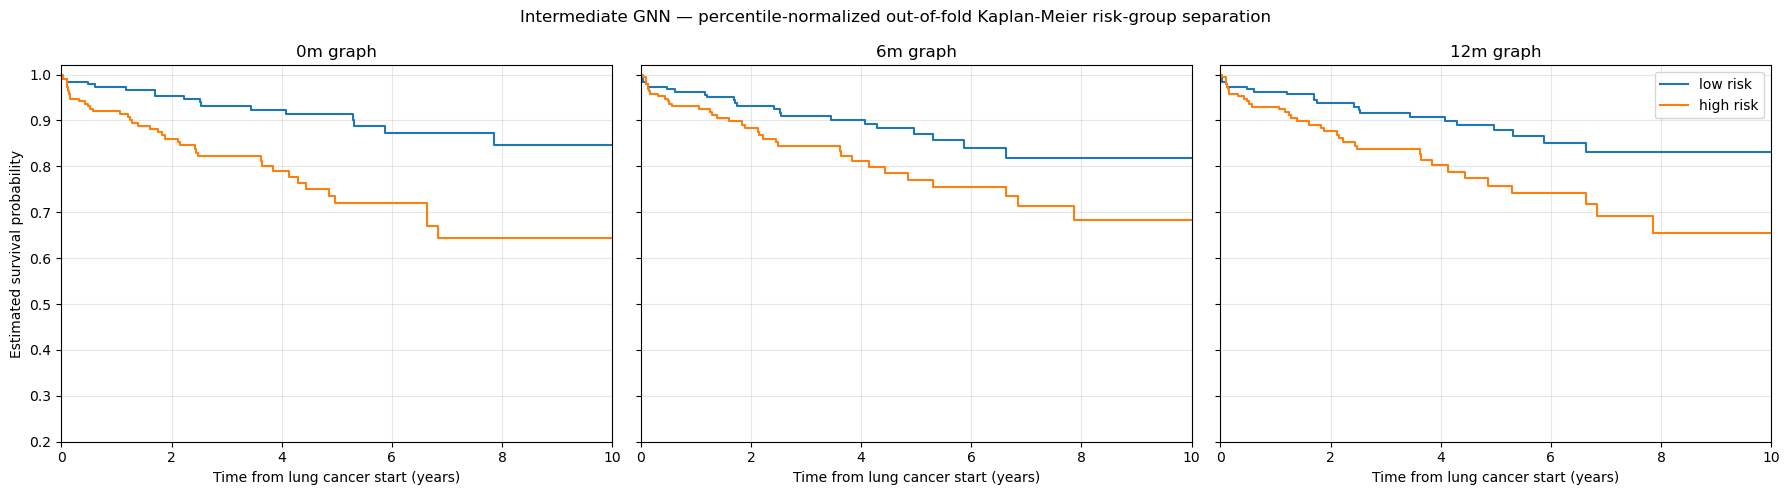

Intermediate GNN — OOF horizon-specific AUC:


,graph_window,horizon_years,auc,n_evaluable,n_events_by_horizon
0,0m,1.0,0.695,338,20
1,0m,3.0,0.689,253,40
2,0m,5.0,0.729,170,50
3,6m,1.0,0.624,338,20
4,6m,3.0,0.636,253,40
5,6m,5.0,0.670,170,50
6,12m,1.0,0.612,338,20
7,12m,3.0,0.632,253,40
8,12m,5.0,0.677,170,50


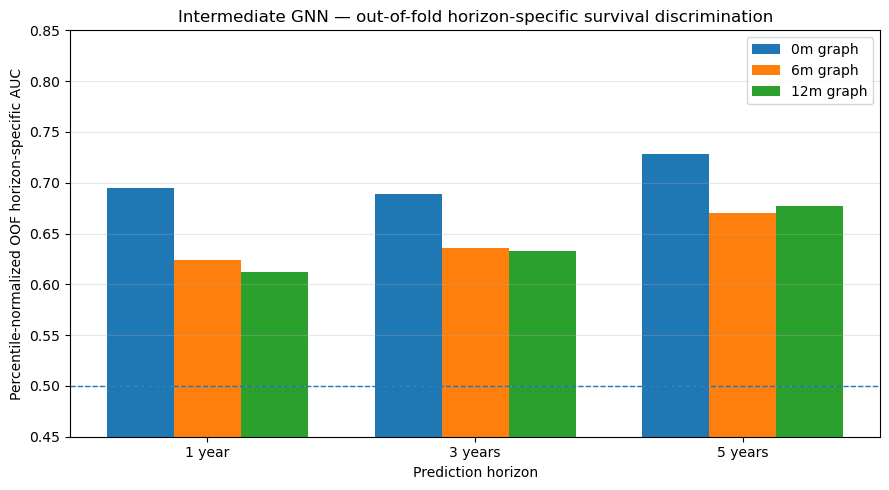

Intermediate GNN — extreme-risk thirds:


,graph_window,top_third_rate,top_n,bottom_third_rate,bottom_n
0,0m,0.264,129,0.081,124
1,6m,0.209,129,0.113,124
2,12m,0.217,129,0.105,124


In [45]:
# ------------------------------------------------------------
# IF1. Intermediate GNN — complementary OOF figures (final-CV style)
# ------------------------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt

oof = cv_oof_predictions_df.copy()
oof["foldwise_risk_percentile"] = (
    oof.groupby(["graph_window", "outer_fold"])["risk_score"].rank(method="average", pct=True)
)
POOLED = "foldwise_risk_percentile"
CV_GRAPH_WINDOWS = ["0m", "6m", "12m"]

if "compute_km_curve" not in globals():
    def compute_km_curve(times, events):
        times = pd.Series(times).astype(float).tolist(); events = pd.Series(events).astype(int).tolist()
        uniq = sorted(set(times[i] for i in range(len(times)) if events[i] == 1)); S = 1.0
        rows = [{"time": 0.0, "survival_probability": 1.0}]
        for t in uniq:
            n = sum(x >= t for x in times); d = sum((times[i] == t) and (events[i] == 1) for i in range(len(times)))
            if n > 0: S *= (1 - d / n)
            rows.append({"time": t, "survival_probability": S})
        return pd.DataFrame(rows)

def compute_binary_auc_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int); scores = np.asarray(scores, dtype=float)
    n_pos = int((y_true == 1).sum()); n_neg = int((y_true == 0).sum())
    if n_pos == 0 or n_neg == 0: return np.nan
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    return float((ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

# risk groups + KM summary
oof["risk_group"] = np.where(oof[POOLED] > 0.5, "high_risk", "low_risk")
int_km_summary_df = (oof.groupby(["graph_window", "risk_group"], as_index=False)
    .agg(n_patients=("person_node_index", "count"), n_events=("event_death", "sum"),
         event_rate=("event_death", "mean")))
print("Intermediate GNN — OOF KM risk-group summary:"); display(int_km_summary_df.round(3))

# KM curves (1x3 panel)
fig_km, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, w in zip(axes, CV_GRAPH_WINDOWS):
    for grp in ["low_risk", "high_risk"]:
        gsub = oof[(oof.graph_window == w) & (oof.risk_group == grp)]
        c = compute_km_curve(gsub.survival_time_years, gsub.event_death)
        ax.step(c["time"], c["survival_probability"], where="post", label=grp.replace("_", " "))
    ax.set_title(f"{w} graph"); ax.set_xlabel("Time from lung cancer start (years)")
    ax.set_xlim(0, 10); ax.set_ylim(0.2, 1.02); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Estimated survival probability"); axes[-1].legend(loc="best")
fig_km.suptitle("Intermediate GNN — percentile-normalized out-of-fold Kaplan-Meier risk-group separation")
plt.tight_layout(); plt.show()

# horizon AUC (pooled, grouped bars)
HORIZON_YEARS = [1.0, 3.0, 5.0]; rows = []
for w in CV_GRAPH_WINDOWS:
    wdf = oof[oof.graph_window == w].copy()
    for h in HORIZON_YEARS:
        lab = pd.Series(np.nan, index=wdf.index)
        lab[(wdf.event_death == 1) & (wdf.survival_time_years <= h)] = 1
        lab[wdf.survival_time_years > h] = 0
        usable = wdf[lab.notna()]
        rows.append({"graph_window": w, "horizon_years": h,
                     "auc": compute_binary_auc_from_scores(lab[lab.notna()], usable[POOLED]),
                     "n_evaluable": len(usable), "n_events_by_horizon": int((lab.dropna() == 1).sum())})
int_horizon_auc_df = pd.DataFrame(rows)
print("Intermediate GNN — OOF horizon-specific AUC:"); display(int_horizon_auc_df.round(3))

fig_auc, ax = plt.subplots(figsize=(9, 5))
x = range(len(HORIZON_YEARS)); bw = 0.25; off = {"0m": -bw, "6m": 0.0, "12m": bw}
for w in CV_GRAPH_WINDOWS:
    wdf = int_horizon_auc_df[int_horizon_auc_df.graph_window == w]
    ax.bar([i + off[w] for i in x], wdf["auc"], width=bw, label=f"{w} graph")
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xticks(list(x)); ax.set_xticklabels([f"{int(h)} year" if h == 1.0 else f"{int(h)} years" for h in HORIZON_YEARS])
ax.set_ylim(0.45, 0.85); ax.set_ylabel("Percentile-normalized OOF horizon-specific AUC")
ax.set_xlabel("Prediction horizon"); ax.set_title("Intermediate GNN — out-of-fold horizon-specific survival discrimination")
ax.legend(); ax.grid(True, axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# extreme-risk thirds table
rows = []
for w in CV_GRAPH_WINDOWS:
    s = oof[oof.graph_window == w]; top = s[s[POOLED] > 2/3]; bot = s[s[POOLED] < 1/3]
    rows.append({"graph_window": w, "top_third_rate": top.event_death.mean(), "top_n": len(top),
                 "bottom_third_rate": bot.event_death.mean(), "bottom_n": len(bot)})
int_extreme_df = pd.DataFrame(rows)
print("Intermediate GNN — extreme-risk thirds:"); display(int_extreme_df.round(3))

In [46]:
# ------------------------------------------------------------
# IF2. Save intermediate GNN figures + complementary tables
# ------------------------------------------------------------
import os
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
base = (os.path.dirname(intermediate_graph_paths_by_window["0m"])
        if "intermediate_graph_paths_by_window" in globals()
        else os.path.dirname(graph_paths_by_window["0m"]))
out_dir = f"{base}/intermediate_cv_figures_{ts}"
os.makedirs(out_dir, exist_ok=True)

km_png = os.path.join(out_dir, f"intermediate_oof_km_curves_{ts}.png")
auc_png = os.path.join(out_dir, f"intermediate_oof_horizon_auc_{ts}.png")
fig_km.savefig(km_png, dpi=300, bbox_inches="tight")
fig_auc.savefig(auc_png, dpi=300, bbox_inches="tight")

for name, frame in {
    f"intermediate_oof_predictions_with_percentiles_{ts}.csv": oof,
    f"intermediate_oof_km_summary_{ts}.csv": int_km_summary_df,
    f"intermediate_oof_extreme_thirds_{ts}.csv": int_extreme_df,
    f"intermediate_oof_horizon_auc_{ts}.csv": int_horizon_auc_df,
}.items():
    with fs.open(os.path.join(out_dir, name), "w") as f:
        frame.to_csv(f, index=False)

print("Saved figures:")
print(" ", km_png)
print(" ", auc_png)
print("Saved tables + folder:", out_dir)

Saved figures:
  /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_figures_20260719_130118/intermediate_oof_km_curves_20260719_130118.png
  /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_figures_20260719_130118/intermediate_oof_horizon_auc_20260719_130118.png
Saved tables + folder: /home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/graph_artifacts/lung_cancer_only_subgraph_2hop_clinical_enriched_no_cancertype_other_cancers_20260623_140110/intermediate_graph_clinical_demographic_20260719_123013/intermediate_cv_figures_20260719_130118


### Summary — intermediate graph and the complexity ladder.
To isolate the contribution of the graph structure itself, we built an intermediate knowledge graph containing only the information the tabular baseline uses — the 26 clinical feature nodes plus shared Sex and AgeGroup (decade) nodes — and ran the identical HeteroGraphSAGE-Cox pipeline (config K, the same stratified 5-fold split, and the same Harrell/IPCW metrics) on it. This completes a controlled complexity ladder from a simple penalized Cox (no graph), to a GNN on exactly the same information, to the full 64-node-type KG-GNN. The result is consistent and decisive: across the ladder, the simplest model performs best. The tabular Cox reached a Harrell C-index of 0.70/0.77/0.75 and IPCW of 0.67/0.71/0.73 (0m/6m/12m); the intermediate GNN dropped to 0.68/0.63/0.63 and 0.66/0.62/0.65; and the full KG-GNN was similar at 0.67/0.65/0.66 and 0.64/0.62/0.63. A paired per-fold comparison confirms this is not an artifact of the split: on the 6m and 12m graphs the tabular model beats the intermediate GNN in 5/5 and 4–5/5 folds. Message passing over the same clinical and demographic information therefore does not add predictive value — it is a net negative.
Two further observations sharpen the picture. First, the models diverge in direction: the tabular Cox improves as more cumulative clinical information is added (0m → 6m/12m), whereas the intermediate GNN degrades — the classic signature of overfitting in a cohort with only 60 observed deaths, where a regularized linear model exploits the added features but the higher-capacity GNN cannot. The complementary out-of-fold analyses (Kaplan–Meier risk-group separation, extreme-risk stratification, and horizon-specific AUC) corroborate this: the intermediate GNN's risk stratification is strongest at 0m and visibly weaker at 6m/12m, mirroring the C-index. Second, trimming the graph did not help — the intermediate GNN performed no better, and no more stably, than the full 64-type graph, indicating that the earlier instability was not caused by the noisy genomic/SDOH node types but is intrinsic to fitting a GNN on this cohort. Taken together with the extensive robustness program on the full graph, the evidence points to a single conclusion: in this small, heavily censored lung-cancer cohort, model and graph complexity are not the limiting factor — the cohort size and event count are — and a clinically adjusted penalized Cox is the most accurate and most stable model. (Caveats: the GNN encodes age as categorical decade groups while the Cox uses continuous age, a minor representational difference; and the complementary analyses are descriptive, pooled over percentile-normalized out-of-fold predictions, with the usual small-sample caution given ~12 events per fold.)

In [1]:
from pathlib import Path
import zipfile

root = Path(
    "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/"
    "graph_artifacts/"
    "lung_cancer_only_subgraph_2hop_clinical_enriched_"
    "no_cancertype_other_cancers_20260623_140110"
)

folders_to_collect = [
    # Full KG-GNN figures and tables
    root / "kaplan_meier_risk_group_analysis_0m_6m_12m",

    # Tabular Cox results, coefficients, KM and AUC
    root / "model_ready_survival_resources" /
    "tabular_cox_demographic_20260719_113419",

    root / "model_ready_survival_resources" /
    "tabular_cox_complementary_20260719_114912",

    # Intermediate GNN results and figures
    root / "intermediate_graph_clinical_demographic_20260719_123013" /
    "intermediate_cv_results_20260719_125508",

    root / "intermediate_graph_clinical_demographic_20260719_123013" /
    "intermediate_cv_figures_20260719_130118",
]

zip_path = Path("/home/jupyter/workspace/final_project_report_artifacts.zip")
allowed_extensions = {".png", ".csv", ".json", ".txt"}

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in folders_to_collect:
        if not folder.exists():
            print("Missing folder:", folder)
            continue

        for file_path in folder.rglob("*"):
            if file_path.is_file() and file_path.suffix.lower() in allowed_extensions:
                archive_name = file_path.relative_to(root)
                zf.write(file_path, archive_name)

print("ZIP created successfully:")
print(zip_path)
print("Size (MB):", round(zip_path.stat().st_size / (1024 ** 2), 2))

ZIP created successfully:
/home/jupyter/workspace/final_project_report_artifacts.zip
Size (MB): 1.1


In [2]:
from pathlib import Path
import zipfile

folder = Path(
    "/home/jupyter/workspace/rw-migration-aou-rw-271d1fe9/"
    "graph_artifacts/"
    "lung_cancer_only_subgraph_2hop_clinical_enriched_"
    "no_cancertype_other_cancers_20260623_140110/"
    "final_5fold_cv_gnn_survival_0m_6m_12m"
)

zip_path = Path(
    "/home/jupyter/workspace/final_full_gnn_5fold_artifacts.zip"
)

allowed_extensions = {".png", ".csv", ".json", ".txt"}

assert folder.exists(), f"Folder not found: {folder}"

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:
    for file_path in folder.rglob("*"):
        if (
            file_path.is_file()
            and file_path.suffix.lower() in allowed_extensions
        ):
            zf.write(
                file_path,
                file_path.relative_to(folder.parent)
            )

print("ZIP created:")
print(zip_path)
print("Size (MB):", round(zip_path.stat().st_size / (1024 ** 2), 2))

ZIP created:
/home/jupyter/workspace/final_full_gnn_5fold_artifacts.zip
Size (MB): 0.47
